In [8]:
# this cell loads the data
import pandas as pd

base = '~/Documents/post_doc/UV5_dataset'

ds1 = pd.read_csv(f'{base}/Ecopart_data_2008_to_2010.tsv', sep='\t')
ds2 = pd.read_csv(f'{base}/Ecopart_data_2011_to_2013.tsv', sep='\t')
ds3 = pd.read_csv(f'{base}/Ecopart_data_2014_to_2016.tsv', sep='\t')
ds4 = pd.read_csv(f'{base}/Ecopart_data_2017_to_2019.tsv', sep='\t')
ds5 = pd.read_csv(f'{base}/Ecopart_data_2020_to_2022.tsv', sep='\t')

# Parse the datetime column (keep it as a column, NOT an index)
for ds in (ds1, ds2, ds3, ds4, ds5):
    ds['Date_Time'] = pd.to_datetime(ds['Date_Time'], errors='coerce')

# Sanity check
for i, ds in enumerate((ds1, ds2, ds3, ds4, ds5), start=1):
    print(f"ds{i}: shape={ds.shape}, "
          f"Date_Time in columns? {'Date_Time' in ds.columns}, "
          f"date range = {ds['Date_Time'].min()} → {ds['Date_Time'].max()}")

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2674174056.py:8: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ds3 = pd.read_csv(f'{base}/Ecopart_data_2014_to_2016.tsv', sep='\t')
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2674174056.py:9: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ds4 = pd.read_csv(f'{base}/Ecopart_data_2017_to_2019.tsv', sep='\t')


ds1: shape=(97703, 69), Date_Time in columns? True, date range = 2008-06-19 08:13:37 → 2010-12-17 08:58:05
ds2: shape=(407734, 69), Date_Time in columns? True, date range = 2011-01-03 11:15:24 → 2013-10-27 21:14:09
ds3: shape=(741355, 69), Date_Time in columns? True, date range = 2014-02-14 10:53:31 → 2016-12-31 20:35:57
ds4: shape=(819074, 69), Date_Time in columns? True, date range = 2017-01-01 07:11:14 → 2019-12-17 23:02:42
ds5: shape=(17486, 69), Date_Time in columns? True, date range = 2020-01-18 11:11:24 → 2020-11-23 12:11:51


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# ============================================================
# CONFIG
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges   = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges   = np.arange(-180, 180 + LON_RES, LON_RES)
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])

SIZE_BINS = [
    ('0.0403-0.0508', 'Part conc frac [#/l] (ESD: 0.0403-0.0508 mm)'),
    ('0.0508-0.064', 'Part conc frac [#/l] (ESD: 0.0508-0.064 mm)'),
    ('0.064-0.0806', 'Part conc frac [#/l] (ESD: 0.064-0.0806 mm)'),
    ('0.0806-0.102','Part conc frac [#/l] (ESD: 0.0806-0.102 mm)'),
    ('0.102–0.128', 'Part conc frac [#/l] (ESD: 0.102-0.128 mm)'),
    ('0.128–0.161', 'Part conc frac [#/l] (ESD: 0.128-0.161 mm)'),
    ('0.161–0.203', 'Part conc frac [#/l] (ESD: 0.161-0.203 mm)'),
    ('0.203–0.256', 'Part conc frac [#/l] (ESD: 0.203-0.256 mm)'),
    ('0.256–0.323', 'Part conc frac [#/l] (ESD: 0.256-0.323 mm)'),
    ('0.323–0.406', 'Part conc frac [#/l] (ESD: 0.323-0.406 mm)'),
    ('0.406–0.512', 'Part conc frac [#/l] (ESD: 0.406-0.512 mm)'),
    ('0.512–0.645', 'Part conc frac [#/l] (ESD: 0.512-0.645 mm)'),
    ('0.645–0.813', 'Part conc frac [#/l] (ESD: 0.645-0.813 mm)'),
    ('0.813–1.02',  'Part conc frac [#/l] (ESD: 0.813-1.02 mm)'),
    ('1.02–1.29',   'Part conc frac [#/l] (ESD: 1.02-1.29 mm)'),
    ('1.29–1.63',   'Part conc frac [#/l] (ESD: 1.29-1.63 mm)'),
    ('1.63–2.05',   'Part conc frac [#/l] (ESD: 1.63-2.05 mm)'),
    ('2.05–2.58',   'Part conc frac [#/l] (ESD: 2.05-2.58 mm)'),
    ('2.58–3.25',   'Part conc frac [#/l] (ESD: 2.58-3.25 mm)'),
    ('3.25–4.1',    'Part conc frac [#/l] (ESD: 3.25-4.1 mm)'),
    ('4.1–5.16',    'Part conc frac [#/l] (ESD: 4.1-5.16 mm)')

]
bin_labels = [s[0] for s in SIZE_BINS]
bin_cols   = [s[1] for s in SIZE_BINS]
n_bins     = len(SIZE_BINS)

# ============================================================
# Step 1 — Concatenate and grid
# ============================================================
print("Concatenating datasets...")
df_all = pd.concat([ds1, ds2, ds3, ds4, ds5], ignore_index=True)
df_all = df_all.dropna(subset=['Latitude', 'Longitude', 'Date_Time'])
print(f"  Total rows: {len(df_all):,}")

df_all['lat_b'] = lat_centers[
    np.clip(np.digitize(df_all['Latitude'],  lat_edges) - 1, 0, len(lat_centers)-1)]
df_all['lon_b'] = lon_centers[
    np.clip(np.digitize(df_all['Longitude'], lon_edges) - 1, 0, len(lon_centers)-1)]

# Unique profile per cell
df_all['profile_id'] = (
    df_all['Date_Time'].astype(str) + '_' +
    df_all['lat_b'].astype(str)    + '_' +
    df_all['lon_b'].astype(str)
)
profiles_per_cell = (
    df_all.groupby(['lat_b', 'lon_b'])['profile_id']
    .nunique()
    .reset_index(name='n_profiles')
)
print(f"  Cells with data: {len(profiles_per_cell):,}")
print(f"  Median profiles/cell: {profiles_per_cell['n_profiles'].median():.1f}")

# ============================================================
# Step 2 — Per-bin, per-cell fraction of nonzero counts
# and median concentration
# ============================================================
print("Computing per-bin statistics per cell...")

bin_stats = {}
for label, col in SIZE_BINS:
    if col not in df_all.columns:
        print(f"  WARNING: column not found — {col}")
        continue
    sub = df_all[df_all[col].notna()]
    stats = (
        sub.groupby(['lat_b', 'lon_b'])
        .agg(
            frac_nonzero = (col, lambda x: (x > 0).mean()),
            median_conc  = (col, 'median'),
            n_obs        = (col, 'count'),
        )
        .reset_index()
    )
    bin_stats[label] = stats

print("  done")

# ============================================================
# Step 3 — Global summary: median fraction nonzero per bin
# This is the key diagnostic for the reviewer
# ============================================================
print("\n--- Fraction of cells with nonzero counts per size bin ---")
frac_summary = []
for label, col in SIZE_BINS:
    if label not in bin_stats:
        continue
    st = bin_stats[label]
    med_frac   = st['frac_nonzero'].median()
    pct_cells  = (st['frac_nonzero'] > 0.5).mean() * 100
    med_conc   = st['median_conc'].median()
    frac_summary.append({
        'bin': label, 'median_frac_nonzero': med_frac,
        'pct_cells_gt50pct': pct_cells, 'median_conc': med_conc
    })
    print(f"  {label:12s}  median frac nonzero={med_frac:.2f}  "
          f"cells >50% nonzero={pct_cells:.0f}%  "
          f"median conc={med_conc:.4f} #/L")

frac_df = pd.DataFrame(frac_summary)



Concatenating datasets...
  Total rows: 2,083,352
  Cells with data: 1,740
  Median profiles/cell: 2.0
Computing per-bin statistics per cell...
  done

--- Fraction of cells with nonzero counts per size bin ---
  0.0403-0.0508  median frac nonzero=0.00  cells >50% nonzero=1%  median conc=0.0000 #/L
  0.0508-0.064  median frac nonzero=0.00  cells >50% nonzero=1%  median conc=0.0000 #/L
  0.064-0.0806  median frac nonzero=0.00  cells >50% nonzero=16%  median conc=0.0000 #/L
  0.0806-0.102  median frac nonzero=0.00  cells >50% nonzero=24%  median conc=0.0000 #/L
  0.102–0.128   median frac nonzero=1.00  cells >50% nonzero=75%  median conc=7.0073 #/L
  0.128–0.161   median frac nonzero=0.00  cells >50% nonzero=39%  median conc=0.0000 #/L
  0.161–0.203   median frac nonzero=1.00  cells >50% nonzero=87%  median conc=3.3396 #/L
  0.203–0.256   median frac nonzero=1.00  cells >50% nonzero=98%  median conc=1.8692 #/L
  0.256–0.323   median frac nonzero=1.00  cells >50% nonzero=100%  median conc

In [10]:
"""
UVP5 PSD slope + biovolume climatology, using MERGED size bins.

Same figures as the original script (4-panel depth maps for beta and
biovolume, plus the seasonal-cycle panel), with two changes:

  1. compute_beta_biovol now sums native Ecopart bins into 12 merged bins
     so every bin used in the fit clears ~30% median frac-nonzero, and
     divides each merged bin by its OWN width. The original normalisation
     (D * 0.1) is only proportional to the true width when bins are
     log-spaced at constant ratio; that no longer holds after merging.

  2. Biovolume is a sum over bins (total mm3/L), not a per-bin mean. The
     mean depends on how many bins are listed: extending the list from 18
     to 21 bins with near-empty fine bins deflates it by ~18/21 with no
     physical change. Set BIOVOL_MODE = 'mean' to restore old behaviour.

Run with:   %run psd_merged_pipeline.py      (ds1..ds5 already loaded)
or:         from psd_merged_pipeline import main; main([ds1,ds2,ds3,ds4,ds5])
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# =============================================================
# CONFIG
# =============================================================
DATE_COL = 'Date_Time'
BIOVOL_MODE = 'sum'          # 'sum' (total mm3/L) or 'mean' (legacy)
MIN_BINS = 3                 # merged bins with counts > 0 required for a fit

depth_ranges = [
    (0,   100),    # surface
    (100,  200),   # base of euphotic layer
    (200, 500),   # upper mesopelagic
    (500, 1500),  # deeper
]

# Native Ecopart edges (mm ESD) -> 21 bins
_bin_edges = np.array([
    0.0403, 0.0508, 0.064, 0.0806, 0.102, 0.128, 0.161, 0.203, 0.256,
    0.323, 0.406, 0.512, 0.645, 0.813, 1.02, 1.29, 1.63, 2.05, 2.58,
    3.25, 4.1, 5.16,
])


def _fmt(x):
    return f"{x:.4f}".rstrip('0').rstrip('.')


A = [f'Part conc frac [#/l] (ESD: {_fmt(lo)}-{_fmt(hi)} mm)'
     for lo, hi in zip(_bin_edges[:-1], _bin_edges[1:])]
B = [f'Biovolume [mm3 l-1] (ESD: {_fmt(lo)}-{_fmt(hi)} mm)'
     for lo, hi in zip(_bin_edges[:-1], _bin_edges[1:])]

# -------------------------------------------------------------
# Merge scheme: contiguous index groups into _bin_edges.
#   0.0403-0.128  five fine bins, quantization-limited (median frac 0.00)
#   0.128-0.203   closes the spurious 0.128-0.161 gap
#   0.203-1.29    already 0.69-1.00, kept at native resolution
#   1.29-2.05     0.48 and 0.30 combined
#   2.05-5.16     rare-aggregate tail, individually 0.18 -> 0.03
# -------------------------------------------------------------
MERGE_GROUPS = [
    [0, 1, 2, 3, 4],
    [5, 6],
    [7], [8], [9], [10], [11], [12], [13], [14],
    [15, 16],
    [17, 18, 19, 20],
]

# Drop the wide tail instead of merging it (unbiased on a clean power law)
MERGE_GROUPS_TRUNCATED = MERGE_GROUPS[:-1]


def merged_geometry(groups=MERGE_GROUPS, edges=_bin_edges):
    """(D_geom, width, labels) for a merge scheme."""
    lo = np.array([edges[g[0]] for g in groups])
    hi = np.array([edges[g[-1] + 1] for g in groups])
    return np.sqrt(lo * hi), hi - lo, [f'{_fmt(a)}-{_fmt(b)}'
                                       for a, b in zip(lo, hi)]


D_MERGED, DD_MERGED, LABELS_MERGED = merged_geometry()
radius = list(D_MERGED)      # name kept for backward compatibility

# =============================================================
# CORE: beta + biovolume on merged bins
# =============================================================
def compute_beta_biovol(df_subset, groups=MERGE_GROUPS,
                        min_bins=MIN_BINS, biovol_mode=BIOVOL_MODE):
    """
    Per-row PSD slope and biovolume. Same signature and return values as
    the original, so all downstream functions work unchanged.

    beta = slope of log10(N_i / dD_i) vs -log10(D_i), least squares over
    merged bins with positive summed counts.
    """
    M = len(df_subset)
    if M == 0:
        return np.array([]), np.array([])

    D, dD, _ = merged_geometry(groups)

    raw = df_subset[A].to_numpy(dtype=float)
    Q = np.empty((M, len(groups)), dtype=float)
    for k, g in enumerate(groups):
        block = raw[:, g]
        allnan = ~np.isfinite(block).any(axis=1)
        with np.errstate(invalid='ignore'):
            tot = np.nansum(block, axis=1)
        tot[allnan] = np.nan
        Q[:, k] = tot

    mask = np.isfinite(Q) & (Q > 0)
    x = np.where(mask, -np.log10(D)[None, :], 0.0)
    y = np.where(mask, np.log10(np.where(mask, Q, 1.0) / dD[None, :]), 0.0)

    n   = mask.sum(axis=1).astype(float)
    Sx  = x.sum(axis=1)
    Sy  = y.sum(axis=1)
    Sxx = (x * x).sum(axis=1)
    Sxy = (x * y).sum(axis=1)

    denom = n * Sxx - Sx ** 2
    with np.errstate(invalid='ignore', divide='ignore'):
        beta = (n * Sxy - Sx * Sy) / denom
    beta[(n < min_bins) | (np.abs(denom) < 1e-12)] = np.nan

    Bio = df_subset[B].to_numpy(dtype=float)
    with np.errstate(invalid='ignore'):
        if biovol_mode == 'sum':
            allnan = ~np.isfinite(Bio).any(axis=1)
            biovol = np.nansum(Bio, axis=1)
            biovol[allnan] = np.nan
        else:
            biovol = np.nanmean(np.where(Bio > 0, Bio, np.nan), axis=1)

    return beta, biovol


# =============================================================
# CLIMATOLOGY  (unchanged logic)
# =============================================================
def climatology_map_for_depth_range(datasets, p_min, p_max, round_decimals=2):
    dfs = []
    for ds in datasets:
        sel = ds[(ds['Pressure [dbar]'] >= p_min) &
                 (ds['Pressure [dbar]'] <= p_max)].copy()
        dfs.append(sel)
    big = pd.concat(dfs, ignore_index=True)
    if big.empty:
        print(f"No data in depth range {p_min}-{p_max} dbar.")
        return None, None, None, None

    big = big.dropna(subset=[DATE_COL])
    if big.empty:
        print(f"No valid dates in depth range {p_min}-{p_max} dbar.")
        return None, None, None, None

    big['Month'] = big[DATE_COL].dt.month
    big['lat_r'] = big['Latitude'].round(round_decimals)
    big['lon_r'] = big['Longitude'].round(round_decimals)

    beta_all, biovol_all = compute_beta_biovol(big)
    big['beta']   = beta_all
    big['biovol'] = biovol_all

    monthly = (big.groupby(['lat_r', 'lon_r', 'Month'], observed=True)
                  [['beta', 'biovol']].mean().reset_index())
    clim = (monthly.groupby(['lat_r', 'lon_r'], observed=True)
                   [['beta', 'biovol']].mean().reset_index())
    n_months = (monthly.groupby(['lat_r', 'lon_r'], observed=True)
                       ['Month'].nunique().reset_index(name='n_months'))
    clim = clim.merge(n_months, on=['lat_r', 'lon_r'])

    print(f"Depth {p_min}-{p_max} dbar: {len(clim)} locations, "
          f"median months/loc = {clim['n_months'].median():.0f}, "
          f"beta finite = {np.isfinite(beta_all).mean():.1%}")

    return (clim['lon_r'].values, clim['lat_r'].values,
            clim['beta'].values, clim['biovol'].values)


def monthly_cycle_for_depth_range(datasets, p_min, p_max, round_decimals=2):
    dfs = []
    for ds in datasets:
        sel = ds[(ds['Pressure [dbar]'] >= p_min) &
                 (ds['Pressure [dbar]'] <  p_max)].copy()
        dfs.append(sel)
    big = pd.concat(dfs, ignore_index=True)
    if big.empty:
        return None

    big = big.dropna(subset=[DATE_COL, 'Latitude', 'Longitude'])
    if big.empty:
        return None

    big['Month'] = big[DATE_COL].dt.month
    big['lat_r'] = big['Latitude'].round(round_decimals)
    big['lon_r'] = big['Longitude'].round(round_decimals)

    beta_all, biovol_all = compute_beta_biovol(big)
    big['beta']   = beta_all
    big['biovol'] = biovol_all

    per_loc_month = (big.groupby(['lat_r', 'lon_r', 'Month'], observed=True)
                        [['beta', 'biovol']].mean().reset_index())

    return per_loc_month.groupby('Month').agg(
        beta_mean   = ('beta',   'mean'),
        beta_std    = ('beta',   'std'),
        biovol_mean = ('biovol', 'mean'),
        biovol_std  = ('biovol', 'std'),
        n_locations = ('beta',   'count'),
    ).reset_index()


# =============================================================
# PLOTS  (unchanged)
# =============================================================
def plot_4panel(results, var_index, label_prefix, vmin, vmax,
                log=False, cmap='jet', save_as=None):
    fig, axes = plt.subplots(2, 2, figsize=(22, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    norm = LogNorm(vmin=vmin, vmax=vmax) if log else None
    sc = None

    for ax, (p_min, p_max) in zip(axes.flat, depth_ranges):
        data = results[(p_min, p_max)]
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.set_extent([-180, 180, -90, 90])
        if data[0] is None:
            ax.set_title(f'{p_min}-{p_max} dbar (no data)', fontsize=16)
            continue

        sc = ax.scatter(data[0], data[1], c=data[var_index], cmap=cmap,
                        marker='o', alpha=0.8, s=20,
                        transform=ccrs.PlateCarree(),
                        vmin=None if log else vmin,
                        vmax=None if log else vmax, norm=norm)
        ax.set_title(f'{p_min}-{p_max} dbar', fontsize=18)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='gray', alpha=0.4, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}

    if sc is not None:
        cbar = fig.colorbar(sc, ax=axes, orientation='horizontal',
                            fraction=0.05, pad=0.07, aspect=50, shrink=0.8)
        cbar.set_label(label_prefix, fontsize=20)
        cbar.ax.tick_params(labelsize=16)

    plt.suptitle(f'{label_prefix} — climatological mean (merged bins)',
                 fontsize=22, y=0.98)
    if save_as:
        plt.savefig(save_as, dpi=120, bbox_inches='tight')
    plt.show()


def plot_seasonal_cycles_clean(datasets, depth_ranges, save_as=None):
    n = len(depth_ranges)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 9), sharex=True)
    colors = plt.cm.viridis(np.linspace(0, 0.85, n))
    month_names = ['J','F','M','A','M','J','J','A','S','O','N','D']

    for col, ((p_min, p_max), color) in enumerate(zip(depth_ranges, colors)):
        monthly = monthly_cycle_for_depth_range(datasets, p_min, p_max)
        if monthly is None or monthly.empty:
            continue

        n_loc = monthly['n_locations'].clip(lower=1)
        beta_sem   = monthly['beta_std']   / np.sqrt(n_loc)
        biovol_sem = monthly['biovol_std'] / np.sqrt(n_loc)

        ax_b, ax_v = axes[0, col], axes[1, col]

        ax_b.plot(monthly['Month'], monthly['beta_mean'],
                  marker='o', lw=2.2, color=color, zorder=3)
        ax_b.fill_between(monthly['Month'],
                          monthly['beta_mean'] - beta_sem,
                          monthly['beta_mean'] + beta_sem,
                          color=color, alpha=0.25, zorder=2)
        ax_b.set_title(f'{p_min}-{p_max} dbar', fontsize=14)
        ax_b.grid(alpha=0.3)

        ax_v.plot(monthly['Month'], monthly['biovol_mean'],
                  marker='o', lw=2.2, color=color, zorder=3)
        low  = (monthly['biovol_mean'] - biovol_sem).clip(lower=1e-4)
        high = monthly['biovol_mean'] + biovol_sem
        ax_v.fill_between(monthly['Month'], low, high,
                          color=color, alpha=0.25, zorder=2)
        ax_v.set_yscale('log')
        ax_v.grid(alpha=0.3, which='both')

        for m, n_pts in zip(monthly['Month'], monthly['n_locations']):
            ax_b.annotate(f'{int(n_pts)}', (m, ax_b.get_ylim()[0]),
                          xytext=(0, 2), textcoords='offset points',
                          ha='center', fontsize=7, color='gray')

    axes[0, 0].set_ylabel('Beta slope', fontsize=13)
    axes[1, 0].set_ylabel('Biovolume [mm³/L]', fontsize=13)
    for ax in axes[1, :]:
        ax.set_xlabel('Month', fontsize=12)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_names)

    for row in range(2):
        ymins = [ax.get_ylim()[0] for ax in axes[row, :]]
        ymaxs = [ax.get_ylim()[1] for ax in axes[row, :]]
        for ax in axes[row, :]:
            ax.set_ylim(min(ymins), max(ymaxs))

    plt.suptitle('Seasonal cycle by depth range, merged bins '
                 '(shaded = ±SEM, numbers = # locations)', fontsize=14, y=1.00)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=120, bbox_inches='tight')
    plt.show()



# =============================================================
# DIAGNOSTIC: mean PSD fit used to obtain beta
# =============================================================
def plot_beta_fit_by_depth(datasets, depth_ranges, save_as=None):
    """
    Show the abundance-radius relationship used to estimate beta for each depth
    range. For consistency with compute_beta_biovol, native concentration bins
    are first merged according to MERGE_GROUPS and divided by each merged-bin
    radius width. The fit is then performed as

        log10(N / dR) = intercept + beta * [-log10(R)]

    which is equivalent to N/dR proportional to R**(-beta). Because R=D/2,
    beta is identical to the diameter-based slope used in compute_beta_biovol.

    Each panel shows the mean PSD across all valid profiles in that depth range
    and the least-squares fit. Error bars are +/- SEM across profiles.
    """
    n = len(depth_ranges)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    D, dD, _ = merged_geometry(MERGE_GROUPS)
    R = D / 2.0
    dR = dD / 2.0

    for i, (ax, (p_min, p_max)) in enumerate(zip(axes, depth_ranges)):
        dfs = []
        for ds in datasets:
            sel = ds[(ds['Pressure [dbar]'] >= p_min) &
                     (ds['Pressure [dbar]'] < p_max)].copy()
            if not sel.empty:
                dfs.append(sel)

        if not dfs:
            ax.set_title(f'{p_min}-{p_max} dbar (no data)', fontsize=14, fontweight='bold')
            ax.axis('off')
            continue

        big = pd.concat(dfs, ignore_index=True)
        raw = big[A].to_numpy(dtype=float)

        # Merge the native abundance bins exactly as in compute_beta_biovol.
        Q = np.full((len(big), len(MERGE_GROUPS)), np.nan, dtype=float)
        for k, g in enumerate(MERGE_GROUPS):
            block = raw[:, g]
            valid_any = np.isfinite(block).any(axis=1)
            summed = np.nansum(block, axis=1)
            summed[~valid_any] = np.nan
            Q[:, k] = summed

        # Particle abundance density per radius interval [#/L/mm].
        # Using radius instead of diameter changes only the intercept, not beta.
        abundance_density = Q / dR[None, :]
        abundance_density[~np.isfinite(abundance_density) | (abundance_density <= 0)] = np.nan

        # Mean PSD and uncertainty across profiles.
        with np.errstate(invalid='ignore', divide='ignore'):
            mean_psd = np.nanmean(abundance_density, axis=0)
            std_psd = np.nanstd(abundance_density, axis=0, ddof=1)
        n_valid = np.sum(np.isfinite(abundance_density), axis=0)
        sem_psd = std_psd / np.sqrt(np.maximum(n_valid, 1))

        valid = np.isfinite(mean_psd) & (mean_psd > 0)
        if valid.sum() < MIN_BINS:
            ax.set_title(f'{p_min}-{p_max} dbar (insufficient bins)', fontsize=14, fontweight='bold')
            ax.axis('off')
            continue

        # Same regression convention used in compute_beta_biovol.
        xfit = -np.log10(R[valid])
        yfit = np.log10(mean_psd[valid])
        beta, intercept = np.polyfit(xfit, yfit, 1)

        # Convert fitted line back to abundance density vs particle radius.
        R_line = np.logspace(np.log10(R[valid].min()),
                             np.log10(R[valid].max()), 200)
        fit_line = 10 ** (intercept + beta * (-np.log10(R_line)))

        ax.errorbar(R[valid], mean_psd[valid], yerr=sem_psd[valid],
                    fmt='o', markersize=6, capsize=3,
                    label='Mean merged-bin PSD +/- SEM')
        ax.plot(R_line, fit_line, linewidth=2.2,
                label=fr'Power-law fit: $\beta={beta:.2f}$')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Particle radius, R [mm]', fontsize=14, fontweight='bold')
        ax.set_ylabel(r'Abundance density, $N/\Delta R$ [L$^{-1}$ mm$^{-1}$]',
                      fontsize=14, fontweight='bold')
        ax.set_title(f'{p_min}-{p_max} dbar', fontsize=17, fontweight='bold')
        ax.grid(alpha=0.3, which='both')
        ax.legend(fontsize=11)
        ax.tick_params(axis='both', which='both', labelsize=13)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')
        ax.text(0.02, 0.98, panel_labels[i], transform=ax.transAxes,
                ha='left', va='top', fontsize=16, fontweight='bold')

    for ax in axes[len(depth_ranges):]:
        ax.axis('off')

    plt.suptitle('Particle abundance-size relationship used to estimate beta',
                 fontsize=19, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, bbox_inches='tight')
    plt.show()

# =============================================================
# DRIVER
# =============================================================
def main(datasets=None, save_prefix=None):
    if datasets is None:
        g = globals()
        datasets = [g[f'ds{i}'] for i in range(1, 6) if f'ds{i}' in g]
        if not datasets:
            raise NameError("ds1..ds5 not found; pass datasets=[ds1, ...]")

    for ds in datasets:
        ds[DATE_COL] = pd.to_datetime(ds[DATE_COL], errors='coerce')

    print(f"Merge scheme: {len(MERGE_GROUPS)} bins from {len(A)} native")
    for lab, g, w in zip(LABELS_MERGED, MERGE_GROUPS, DD_MERGED):
        print(f"  {lab:14s}  n_native={len(g):2d}  width={w:.4f} mm")

    results = {}
    for p_min, p_max in depth_ranges:
        results[(p_min, p_max)] = climatology_map_for_depth_range(
            datasets, p_min, p_max)

    plot_4panel(results, 2, 'Beta slope', vmin=2.5, vmax=5.5,
                save_as=f'{save_prefix}_beta_map.png' if save_prefix else None)
    plot_4panel(results, 3, 'Biovolume [mm³/L]', vmin=1e-2, vmax=10, log=True,
                save_as=f'{save_prefix}_biovol_map.png' if save_prefix else None)
    plot_seasonal_cycles_clean(
        datasets, depth_ranges,
        save_as=f'{save_prefix}_seasonal.png' if save_prefix else None)
    plot_beta_fit_by_depth(
        datasets, depth_ranges,
        save_as=f'{save_prefix}_beta_fit.pdf' if save_prefix else None)

    return results


if __name__ == '__main__':
    results = main()

Merge scheme: 12 bins from 21 native
  0.0403-0.128    n_native= 5  width=0.0877 mm
  0.128-0.203     n_native= 2  width=0.0750 mm
  0.203-0.256     n_native= 1  width=0.0530 mm
  0.256-0.323     n_native= 1  width=0.0670 mm
  0.323-0.406     n_native= 1  width=0.0830 mm
  0.406-0.512     n_native= 1  width=0.1060 mm
  0.512-0.645     n_native= 1  width=0.1330 mm
  0.645-0.813     n_native= 1  width=0.1680 mm
  0.813-1.02      n_native= 1  width=0.2070 mm
  1.02-1.29       n_native= 1  width=0.2700 mm
  1.29-2.05       n_native= 2  width=0.7600 mm
  2.05-5.16       n_native= 4  width=3.1100 mm
Depth 0-100 dbar: 6539 locations, median months/loc = 1, beta finite = 100.0%
Depth 100-200 dbar: 5862 locations, median months/loc = 1, beta finite = 100.0%
Depth 200-500 dbar: 5409 locations, median months/loc = 1, beta finite = 100.0%
Depth 500-1500 dbar: 4130 locations, median months/loc = 1, beta finite = 100.0%


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3933127979.py:265: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3933127979.py:265: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3933127979.py:326: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3933127979.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# ===============================================================
# CONFIG
# ===============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges   = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges   = np.arange(-180, 180 + LON_RES, LON_RES)
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])

DEPTH_ZONES = {
    'Surface (0-100 m)':                (0,    100),
    'Lower euphotic (100-200 m)':       (100,  200),
    'Upper mesopelagic (200-500 m)':   (200, 500),
    'Lower mesopelagic (500-1500 m)':  (500, 1500),
}


# ===============================================================
# Step 1 — Long DataFrame: one row per (station, pressure level),
#          with Month, Beta, Biovolume
# ===============================================================
def build_long_dataframe():
    records = []
    for ds in (ds1, ds2, ds3, ds4, ds5):
        d = ds.dropna(subset=['Date_Time', 'Latitude', 'Longitude',
                              'Pressure [dbar]']).copy()
        if d.empty:
            continue
        beta, biovol = compute_beta_biovol(d)
        d['Beta_slope'] = beta
        d['Biovolume']  = biovol
        d['Month']      = d['Date_Time'].dt.month
        records.append(d[['Pressure [dbar]', 'Latitude', 'Longitude',
                          'Month', 'Beta_slope', 'Biovolume']]
                       .rename(columns={'Pressure [dbar]': 'Pressure_dbar'}))
    return pd.concat(records, ignore_index=True)


df_all = build_long_dataframe()
print(f"Long dataframe: {len(df_all):,} rows, "
      f"{df_all['Pressure_dbar'].nunique()} pressure levels, "
      f"{df_all['Month'].nunique()} months")


# ===============================================================
# Step 2 — Regrid at FULL vertical resolution.
#          Bin into (Pressure_dbar × Month × lat_cell × lon_cell)
# ===============================================================
def regrid_full_resolution(df_all):
    d = df_all.copy()
    d['lat_b'] = lat_centers[np.clip(np.digitize(d['Latitude'],  lat_edges) - 1,
                                     0, len(lat_centers) - 1)]
    d['lon_b'] = lon_centers[np.clip(np.digitize(d['Longitude'], lon_edges) - 1,
                                     0, len(lon_centers) - 1)]
    grp = d.groupby(['Pressure_dbar', 'Month', 'lat_b', 'lon_b'],
                    observed=True, sort=False)
    binned = grp.agg(
        Beta_slope=('Beta_slope', 'mean'),
        Biovolume =('Biovolume',  'mean'),
        n_obs     =('Beta_slope', 'count'),
    ).reset_index()
    return binned.rename(columns={'lat_b': 'Latitude', 'lon_b': 'Longitude'})


df_gridded = regrid_full_resolution(df_all)
print(f"Gridded (level x month x cell): {len(df_gridded):,} rows, "
      f"{df_gridded['Pressure_dbar'].nunique()} pressure levels preserved")


# ===============================================================
# Step 3 — Vertical aggregation: average gridded values within each
#          depth zone, keeping (Month, lat, lon) intact.
# ===============================================================
def assign_zone(p):
    for name, (lo, hi) in DEPTH_ZONES.items():
        if lo <= p < hi:
            return name
    return None


def aggregate_into_zones(df_gridded):
    d = df_gridded.copy()
    d['Zone'] = d['Pressure_dbar'].apply(assign_zone)
    d = d.dropna(subset=['Zone'])
    grp = d.groupby(['Zone', 'Month', 'Latitude', 'Longitude'],
                    observed=True, sort=False)
    return grp.agg(
        Beta_slope=('Beta_slope', 'mean'),
        Biovolume =('Biovolume',  'mean'),
        n_levels  =('Pressure_dbar', 'nunique'),
        n_obs_total=('n_obs', 'sum'),
    ).reset_index()


df_zones = aggregate_into_zones(df_gridded)
print(f"Per zone (zone x month x cell): {len(df_zones):,} rows")
print(df_zones.groupby('Zone').size().rename('n_cells_total'))


def plot_regridding_diagnostic(level_target=22.5, month=6, save_as=None):
    levels = sorted(df_all['Pressure_dbar'].unique())
    level = levels[np.argmin(np.abs(np.array(levels) - level_target))]

    raw     = df_all    [(df_all    ['Pressure_dbar'] == level) & (df_all    ['Month'] == month)]
    gridded = df_gridded[(df_gridded['Pressure_dbar'] == level) & (df_gridded['Month'] == month)]
    mname = ['Jan','Feb','Mar','Apr','May','Jun',
             'Jul','Aug','Sep','Oct','Nov','Dec'][month - 1]

    fig = plt.figure(figsize=(22, 13))
    gs = fig.add_gridspec(2, 3, height_ratios=[2, 1], hspace=0.35, wspace=0.25)

    # --- Top-left: raw stations on map ---
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    sc1 = ax1.scatter(raw['Longitude'], raw['Latitude'],
                      c=raw['Beta_slope'], cmap='jet', s=12, alpha=0.7,
                      vmin=2.5, vmax=5.5, transform=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE); ax1.add_feature(cfeature.LAND, facecolor='lightgray')
    ax1.set_extent([-180, 180, -90, 90])
    ax1.set_title(f'RAW — {level} dbar, {mname}\n{len(raw)} observations', fontsize=13)
    plt.colorbar(sc1, ax=ax1, orientation='horizontal', pad=0.05, aspect=40,
                 label=r'$\beta$ slope')

    # --- Top-middle: gridded cells on map (CIRCLES, smaller) ---
    ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    sc2 = ax2.scatter(gridded['Longitude'], gridded['Latitude'],
                      c=gridded['Beta_slope'], cmap='jet', s=20,
                      alpha=0.9, vmin=2.5, vmax=5.5, transform=ccrs.PlateCarree())
    ax2.add_feature(cfeature.COASTLINE); ax2.add_feature(cfeature.LAND, facecolor='lightgray')
    ax2.set_extent([-180, 180, -90, 90])
    reduction = len(raw) / max(len(gridded), 1)
    ax2.set_title(f'GRIDDED ({LAT_RES}°×{LON_RES}°) — {level} dbar, {mname}\n'
                  f'{len(gridded)} cells (×{reduction:.1f} reduction)', fontsize=13)
    plt.colorbar(sc2, ax=ax2, orientation='horizontal', pad=0.05, aspect=40,
                 label=r'$\beta$ slope')

    # --- Top-right: cell value vs sample size ---
    ax3 = fig.add_subplot(gs[0, 2])
    if len(gridded):
        ax3.scatter(gridded['n_obs'], gridded['Beta_slope'],
                    c='steelblue', s=25, alpha=0.7, edgecolor='k', lw=0.3)
        ax3.set_xscale('log')
    ax3.set_xlabel('# raw obs per cell'); ax3.set_ylabel(r'Cell mean $\beta$')
    ax3.set_title('Cell value vs sample size'); ax3.grid(alpha=0.3)

    # --- Bottom-left: distribution before vs after ---
    ax4 = fig.add_subplot(gs[1, 0])
    bins = np.linspace(2, 6, 40)
    ax4.hist(raw['Beta_slope'].dropna(),    bins=bins, alpha=0.6,
             color='lightcoral', label=f'Raw (n={raw["Beta_slope"].notna().sum()})',
             density=True)
    ax4.hist(gridded['Beta_slope'].dropna(), bins=bins, alpha=0.6,
             color='steelblue',  label=f'Gridded (n={gridded["Beta_slope"].notna().sum()})',
             density=True)
    ax4.set_xlabel(r'$\beta$ slope'); ax4.set_ylabel('Density')
    ax4.set_title('Value distribution: raw vs gridded')
    ax4.legend(); ax4.grid(alpha=0.3)

    # --- Bottom-middle: obs-per-cell histogram ---
    ax5 = fig.add_subplot(gs[1, 1])
    if len(gridded):
        ax5.hist(gridded['n_obs'], bins=30, color='steelblue', edgecolor='k')
        ax5.set_yscale('log')
        ax5.set_title(f'Obs per cell: median={gridded["n_obs"].median():.0f}, '
                      f'max={gridded["n_obs"].max()}')
    ax5.set_xlabel('# raw obs per bin'); ax5.set_ylabel('# cells')
    ax5.grid(alpha=0.3)

    plt.suptitle(f'Regridding diagnostic — single pressure level ({level} dbar), {mname}',
                 fontsize=15, y=1.00)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=120, bbox_inches='tight')
    plt.show()


plot_regridding_diagnostic(level_target=22.5, month=6)

# ===============================================================
# Step 5 — Plotting helper: climatological map per depth zone
#          (averages the 12 monthly fields per cell)
# ===============================================================
def plot_zone_climatology(df_zones, var, vmin, vmax, log=False, cmap='jet',
                          save_as=None, cbar_label=None,
                          tick_fontsize=20, label_fontsize=22):
    fig, axes = plt.subplots(2, 2, figsize=(22, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    norm = LogNorm(vmin=vmin, vmax=vmax) if log else None
    sc = None
    for i, (ax, (zone_name, _)) in enumerate(zip(axes.flat,
                                                  DEPTH_ZONES.items())):
        sub = df_zones[df_zones['Zone'] == zone_name]
        clim = (sub.groupby(['Latitude', 'Longitude'], observed=True)
                   [var].mean().reset_index())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.set_extent([-180, 180, -90, 90])
        ax.set_title(f'{chr(97 + i)})  {zone_name}', fontsize=22,
                     fontweight='bold')
        if clim.empty:
            continue
        sc = ax.scatter(clim['Longitude'], clim['Latitude'], c=clim[var],
                        cmap=cmap, s=20, alpha=0.9,
                        transform=ccrs.PlateCarree(),
                        vmin=None if log else vmin,
                        vmax=None if log else vmax, norm=norm)
        gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray',
                          alpha=0.4, linestyle='--')
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {'size': 13}
        gl.ylabel_style = {'size': 13}

    if sc is not None:
        cbar = fig.colorbar(sc, ax=axes, orientation='horizontal',
                            fraction=0.05, pad=0.07, aspect=50, shrink=0.8)
        cbar.set_label(cbar_label or var, fontsize=label_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize, length=6, width=1.2)
        if log:
            # log colorbars default to sparse/absent minor labels
            from matplotlib.ticker import LogFormatterSciNotation
            cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation())
            cbar.ax.tick_params(which='minor', length=3)

    plt.suptitle(f'{var} — climatological mean (regridded to {LAT_RES}°)',
                 fontsize=20, y=1.00)
    if save_as:
        plt.savefig(save_as, dpi=200, bbox_inches='tight')
        print(f"saved {save_as}")
    plt.show()


plot_zone_climatology(df_zones, 'Beta_slope', vmin=2.5, vmax=5.5,
                      cbar_label=r'$\beta$ slope',
                      save_as='beta_slope_zones_1deg.pdf')

plot_zone_climatology(df_zones, 'Biovolume', vmin=1e-2, vmax=10, log=True,
                      cbar_label='Biovolume [mm³ L⁻¹]',
                      save_as='biovolume_zones_1deg.pdf')

Long dataframe: 2,083,352 rows, 1204 pressure levels, 12 months
Gridded (level x month x cell): 958,734 rows, 1204 pressure levels preserved
Per zone (zone x month x cell): 8,688 rows
Zone
Lower euphotic (100-200 m)        2249
Lower mesopelagic (500-1500 m)    1893
Surface (0-100 m)                 2403
Upper mesopelagic (200-500 m)     2143
Name: n_cells_total, dtype: int64


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2348497612.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2348497612.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


saved beta_slope_zones_1deg.pdf


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2348497612.py:235: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


saved biovolume_zones_1deg.pdf


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/2348497612.py:235: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Assumes df_gridded has columns: Pressure_dbar, Month, Latitude, Longitude,
# Beta_slope, Biovolume, n_obs   (from the regridding pipeline)

print("\n🔍 Counting valid & missing Beta_slope cells per (depth, month)...")

# Global 1° grid sizes
n_lat = 180
n_lon = 360
n_cells_per_field = n_lat * n_lon          # 64,800 cells in one month-level field
months = list(range(1, 13))

depth_values = sorted(df_gridded["Pressure_dbar"].unique())

# ===============================================================
# Step 1 — Count valid vs missing for every (depth, month)
# ===============================================================
rows = []
for p in depth_values:
    for m in months:
        sub = df_gridded[(df_gridded["Pressure_dbar"] == p) &
                         (df_gridded["Month"] == m)]
        n_valid = sub["Beta_slope"].notnull().sum()
        rows.append({
            "Pressure_dbar": p,
            "Month": m,
            "Valid_points":   n_valid,
            "Missing_points": n_cells_per_field - n_valid,
        })

df_counts = pd.DataFrame(rows)
print("✅ Per-(depth, month) counts:")
print(df_counts.head())

# Pivot for a quick overview: rows=depth, cols=month, values=valid cells
pivot_valid = df_counts.pivot(index="Pressure_dbar",
                              columns="Month",
                              values="Valid_points")
print("\nValid cells per depth × month (head):")
print(pivot_valid.head())


# ===============================================================
# Step 2 — Pick representative depths.
#   Now the criterion is "best-sampled across the whole year",
#   i.e. sum over months, not a single month.
# ===============================================================
bin_size = 5
df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                              .sum().reset_index()
                              .rename(columns={"Valid_points": "Valid_points_yr"}))

selected_depths = [
    block.loc[block["Valid_points_yr"].idxmax(), "Pressure_dbar"]
    for start in range(0, len(df_counts_yearly), bin_size)
    if not (block := df_counts_yearly.iloc[start:start+bin_size]).empty
]
print(f"\n✅ Selected {len(selected_depths)} representative depth levels")


# ===============================================================
# Step 3 — Build the full (depth × month × lat × lon) grid
# ===============================================================
unique_depths = np.array(selected_depths)
unique_months = np.array(months)
unique_lats   = np.arange(-89.5, 90.0, 1.0)
unique_lons   = np.arange(-179.5, 180.0, 1.0)

depth_mesh, month_mesh, lat_mesh, lon_mesh = np.meshgrid(
    unique_depths, unique_months, unique_lats, unique_lons, indexing="ij"
)

df_full = pd.DataFrame({
    "Pressure_dbar": depth_mesh.ravel(),
    "Month":         month_mesh.ravel(),
    "Latitude":      lat_mesh.ravel(),
    "Longitude":     lon_mesh.ravel(),
})

n_expected = len(unique_depths) * len(unique_months) * n_cells_per_field
print(f"\nFull empty grid: {len(df_full):,} cells "
      f"(expected {n_expected:,} = {len(unique_depths)} depths × 12 months × "
      f"{n_cells_per_field:,} cells)")


# ===============================================================
# Step 4 — Merge in the observed values, then split valid/missing
# ===============================================================
df_obs = df_gridded[df_gridded["Pressure_dbar"].isin(unique_depths) &
                    df_gridded["Beta_slope"].notnull()][
    ["Pressure_dbar", "Month", "Latitude", "Longitude",
     "Beta_slope", "Biovolume"]
].copy()

df_merged = df_full.merge(
    df_obs,
    on=["Pressure_dbar", "Month", "Latitude", "Longitude"],
    how="left",
)

df_valid_selected   = df_merged[df_merged["Beta_slope"].notnull()].copy()
df_missing_selected = df_merged[df_merged["Beta_slope"].isnull()].copy()

print(f"\n✅ Complementary subsets:")
print(f"  Valid   : {len(df_valid_selected):,} cells")
print(f"  Missing : {len(df_missing_selected):,} cells")
print(f"  Total   : {len(df_merged):,}")


# ===============================================================
# Step 5 — Convert to xarray Datasets with (depth, month, lat, lon) dims
# ===============================================================
ds_beta_valid_selected = (df_valid_selected
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    .to_xarray())

ds_beta_missing_selected = (df_missing_selected
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    .to_xarray())

# Biovolume datasets (same valid/missing split as beta)
ds_biovolume_valid_selected = (df_valid_selected
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    [['Biovolume']]
    .to_xarray())

ds_biovolume_missing_selected = (df_missing_selected
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    [['Biovolume']]
    .to_xarray())

print("\nxarray dims (valid):", dict(ds_beta_valid_selected.dims))


# ===============================================================
# Step 6 — Quick summary tables
# ===============================================================
print("\n✅ Valid cells per (depth, month):")
print(df_valid_selected.groupby(["Pressure_dbar", "Month"]).size()
      .unstack("Month", fill_value=0))

print("\n✅ Coverage fraction per (depth, month) [%]:")
cov = (df_valid_selected.groupby(["Pressure_dbar", "Month"]).size()
       .unstack("Month", fill_value=0)
       / n_cells_per_field * 100).round(2)
print(cov)


# ===============================================================
# Step 7 — Optional visual: heatmap of coverage (depth × month)
# ===============================================================
def plot_coverage_heatmap(df_counts, save_as=None):
    pivot = df_counts.pivot(index="Pressure_dbar",
                            columns="Month",
                            values="Valid_points")
    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(pivot.values, aspect="auto", origin="upper",
                   cmap="viridis")
    ax.set_xticks(range(12))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_yticks(range(0, len(pivot.index), max(1, len(pivot.index)//20)))
    ax.set_yticklabels([f"{d:.0f}" for d in
                        pivot.index[::max(1, len(pivot.index)//20)]])
    ax.set_xlabel("Month"); ax.set_ylabel("Pressure [dbar]")
    ax.set_title("Number of valid 1° cells per (depth × month)")
    plt.colorbar(im, ax=ax, label="# valid cells")
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
    plt.show()

plot_coverage_heatmap(df_counts)


🔍 Counting valid & missing Beta_slope cells per (depth, month)...
✅ Per-(depth, month) counts:
   Pressure_dbar  Month  Valid_points  Missing_points
0            2.5      1            84           64716
1            2.5      2            99           64701
2            2.5      3           211           64589
3            2.5      4           193           64607
4            2.5      5           258           64542

Valid cells per depth × month (head):
Month           1    2    3    4    5    6    7    8    9   10   11  12
Pressure_dbar                                                          
2.5             84   99  211  193  258  320  222  190  161  84  114  84
7.5            125  105  235  218  284  327  251  206  178  87  134  91
12.5           125  106  241  248  291  331  252  208  184  89  143  91
17.5           125  107  241  257  303  332  254  210  184  91  151  94
22.5           125  108  243  258  305  329  254  209  185  91  152  94

✅ Selected 241 representative depth 

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3822445165.py:136: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("\nxarray dims (valid):", dict(ds_beta_valid_selected.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3822445165.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [13]:
"""
Autocorrelation of UVP5-derived PSD slope (beta) and biovolume.

Three independent axes:
  1. Horizontal  -> rho(h), h = great-circle distance between profiles [km]
  2. Vertical    -> rho(dz), dz = pressure lag within a profile [dbar]
  3. Temporal    -> rho(dt), dt = time lag between profiles in the same cell [days]

All ACFs are computed on ANOMALIES (mean removed per pressure level x month),
otherwise the depth structure and seasonal cycle alone produce spurious
correlation at every lag.

Usage in the notebook (after ds1..ds5 are loaded):

    from psd_autocorrelation import *
    df   = build_long_dataframe([ds1, ds2, ds3, ds4, ds5])
    df   = add_anomalies(df, ['beta', 'logbio'])

    hz   = horizontal_acf(df, 'beta', p_min=0,   p_max=200)
    vz   = vertical_acf(df,   'beta')
    tz   = temporal_acf(df,   'beta', p_min=0,   p_max=200)
    plot_acf_summary(df, var='beta')
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

R_EARTH = 6371.0  # km

# ------------------------------------------------------------------
# Size-bin definitions (same as the flux pipeline)
# ------------------------------------------------------------------
_BIN_EDGES = [0.102, 0.128, 0.161, 0.203, 0.256, 0.323, 0.406, 0.512, 0.645,
              0.813, 1.02, 1.29, 1.63, 2.05, 2.58, 3.25, 4.1, 5.16, 6.5]
RADIUS = np.array([np.sqrt(_BIN_EDGES[i] * _BIN_EDGES[i + 1])
                   for i in range(len(_BIN_EDGES) - 1)])

A_COLS = [f'Part conc frac [#/l] (ESD: {_BIN_EDGES[i]}-{_BIN_EDGES[i+1]} mm)'
          for i in range(len(_BIN_EDGES) - 1)]
B_COLS = [f'Biovolume [mm3 l-1] (ESD: {_BIN_EDGES[i]}-{_BIN_EDGES[i+1]} mm)'
          for i in range(len(_BIN_EDGES) - 1)]


# ==================================================================
# 1. Fast (vectorised) beta + biovolume
# ==================================================================
def compute_beta_biovol_fast(df, min_bins=3):
    """
    Vectorised equivalent of the row-wise linregress loop.

    beta = slope of log10(N_i / dD_i) vs -log10(D_i), using only bins with
    positive counts. ~1000x faster than looping scipy.linregress, which
    matters when there are millions of rows.
    """
    Q = df[A_COLS].to_numpy(dtype=float)                 # (M, nbin)
    mask = np.isfinite(Q) & (Q > 0)

    x_full = -np.log10(RADIUS)[None, :]                  # (1, nbin)
    y_full = np.log10(np.where(mask, Q, 1.0) / (RADIUS[None, :] * 0.1))

    x = np.where(mask, x_full, 0.0)
    y = np.where(mask, y_full, 0.0)

    n   = mask.sum(axis=1).astype(float)
    Sx  = x.sum(axis=1)
    Sy  = y.sum(axis=1)
    Sxx = (x * x).sum(axis=1)
    Sxy = (x * y).sum(axis=1)

    denom = n * Sxx - Sx ** 2
    with np.errstate(invalid='ignore', divide='ignore'):
        beta = (n * Sxy - Sx * Sy) / denom
    beta[(n < min_bins) | (np.abs(denom) < 1e-12)] = np.nan

    Bio = df[B_COLS].to_numpy(dtype=float)
    with np.errstate(invalid='ignore'):
        biovol = np.nanmean(np.where(Bio > 0, Bio, np.nan), axis=1)

    return beta, biovol


# ==================================================================
# 2. Long dataframe
# ==================================================================
def build_long_dataframe(datasets, date_col='Date_Time', p_col='Pressure [dbar]'):
    """One row per (profile, pressure level) with beta, biovolume, log-biovolume."""
    out = []
    for ds in datasets:
        d = ds.dropna(subset=[date_col, 'Latitude', 'Longitude', p_col]).copy()
        if d.empty:
            continue
        beta, biovol = compute_beta_biovol_fast(d)
        rec = pd.DataFrame({
            'time': pd.to_datetime(d[date_col].values),
            'lat':  d['Latitude'].to_numpy(float),
            'lon':  d['Longitude'].to_numpy(float),
            'P':    d[p_col].to_numpy(float),
            'beta': beta,
            'biovol': biovol,
        })
        out.append(rec)

    df = pd.concat(out, ignore_index=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        df['logbio'] = np.log10(df['biovol'].where(df['biovol'] > 0))

    df['month'] = df['time'].dt.month
    df['t_days'] = (df['time'] - df['time'].min()).dt.total_seconds() / 86400.0

    # A profile = one cast: unique (time, lat, lon)
    df['profile_id'] = pd.factorize(
        df['time'].astype('int64').astype(str) + '_'
        + df['lat'].round(4).astype(str) + '_'
        + df['lon'].round(4).astype(str)
    )[0]

    print(f"Long dataframe: {len(df):,} rows, "
          f"{df['profile_id'].nunique():,} profiles, "
          f"{df['P'].nunique()} pressure levels")
    return df


def add_anomalies(df, variables, by=('P', 'month')):
    """
    Remove the (pressure level x month) mean. This strips the mean vertical
    profile and the seasonal cycle so the ACF reflects genuine covariance
    rather than shared climatological structure.
    """
    for v in variables:
        df[v + '_a'] = df[v] - df.groupby(list(by))[v].transform('mean')
    return df


# ==================================================================
# 3. Binned correlation estimator
# ==================================================================
def _haversine(lat1, lon1, lat2, lon2):
    p = np.pi / 180.0
    dlat = (lat2 - lat1) * p
    dlon = (lon2 - lon1) * p
    a = (np.sin(dlat / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin(dlon / 2) ** 2)
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def _binned_corr(lag, vi, vj, edges, sill=None):
    """
    Per-lag-bin Pearson correlation and semivariance from a cloud of pairs.
    Returns a tidy DataFrame.
    """
    good = np.isfinite(lag) & np.isfinite(vi) & np.isfinite(vj)
    lag, vi, vj = lag[good], vi[good], vj[good]

    nb = len(edges) - 1
    idx = np.digitize(lag, edges) - 1
    ok = (idx >= 0) & (idx < nb)
    idx, vi, vj = idx[ok], vi[ok], vj[ok]

    n    = np.bincount(idx, minlength=nb).astype(float)
    s_i  = np.bincount(idx, weights=vi,          minlength=nb)
    s_j  = np.bincount(idx, weights=vj,          minlength=nb)
    s_ii = np.bincount(idx, weights=vi * vi,     minlength=nb)
    s_jj = np.bincount(idx, weights=vj * vj,     minlength=nb)
    s_ij = np.bincount(idx, weights=vi * vj,     minlength=nb)
    s_gg = np.bincount(idx, weights=(vi - vj)**2, minlength=nb)

    with np.errstate(invalid='ignore', divide='ignore'):
        mi, mj = s_i / n, s_j / n
        cov = s_ij / n - mi * mj
        var_i = s_ii / n - mi ** 2
        var_j = s_jj / n - mj ** 2
        rho = cov / np.sqrt(var_i * var_j)
        gamma = 0.5 * s_gg / n

    if sill is None:
        sill = np.nanvar(np.concatenate([vi, vj]))

    res = pd.DataFrame({
        'lag':        0.5 * (edges[:-1] + edges[1:]),
        'lag_lo':     edges[:-1],
        'lag_hi':     edges[1:],
        'n_pairs':    n.astype(int),
        'rho':        rho,
        'semivar':    gamma,
        'rho_vario':  1.0 - gamma / sill,
    })
    res.loc[res['n_pairs'] < 30, ['rho', 'semivar', 'rho_vario']] = np.nan
    return res


def decorrelation_scale(acf, col='rho', threshold=1.0 / np.e):
    """First crossing of the threshold, linearly interpolated between bins."""
    a = acf.dropna(subset=[col])
    lag, r = a['lag'].to_numpy(), a[col].to_numpy()
    below = np.where(r < threshold)[0]
    if len(below) == 0:
        return np.nan
    k = below[0]
    if k == 0:
        return lag[0]
    r0, r1 = r[k - 1], r[k]
    return lag[k - 1] + (r0 - threshold) / (r0 - r1) * (lag[k] - lag[k - 1])


# ==================================================================
# 4a. Horizontal ACF
# ==================================================================
def horizontal_acf(df, var, p_min=0.0, p_max=200.0,
                   max_dt_days=30.0, n_pairs=4_000_000,
                   edges=None, seed=0):
    """
    rho(h) between profile-mean anomalies within a depth layer.

    max_dt_days restricts pairs to profiles close in time, so temporal
    decorrelation does not leak into the spatial estimate. Set to None to
    disable (useful if pair counts get too thin at large separations).
    """
    col = var + '_a'
    if edges is None:
        edges = np.concatenate([np.arange(0, 500, 20), np.arange(500, 3100, 100)])

    sub = df[(df['P'] >= p_min) & (df['P'] < p_max)].dropna(subset=[col])
    prof = (sub.groupby('profile_id')
               .agg(lat=('lat', 'first'), lon=('lon', 'first'),
                    t=('t_days', 'first'), v=(col, 'mean'))
               .reset_index())
    n = len(prof)
    if n < 50:
        print(f"[horizontal] too few profiles ({n}) in {p_min}-{p_max} dbar")
        return None

    rng = np.random.default_rng(seed)
    i = rng.integers(0, n, n_pairs)
    j = rng.integers(0, n, n_pairs)
    keep = i != j

    lat, lon, t, v = (prof['lat'].to_numpy(), prof['lon'].to_numpy(),
                      prof['t'].to_numpy(), prof['v'].to_numpy())
    i, j = i[keep], j[keep]

    if max_dt_days is not None:
        keep = np.abs(t[i] - t[j]) <= max_dt_days
        i, j = i[keep], j[keep]

    h = _haversine(lat[i], lon[i], lat[j], lon[j])
    acf = _binned_corr(h, v[i], v[j], edges, sill=np.nanvar(v))
    acf.attrs['L_e'] = decorrelation_scale(acf)
    print(f"[horizontal] {var}, {p_min}-{p_max} dbar: {n:,} profiles, "
          f"{len(i):,} pairs, L_e ≈ {acf.attrs['L_e']:.0f} km")
    return acf


# ==================================================================
# 4b. Vertical ACF
# ==================================================================
def vertical_acf(df, var, max_lag_dbar=600.0, dz=5.0, p_max=1500.0,
                 min_pairs=50):
    """
    rho(dz) within casts, on a regular pressure grid. Uses every profile,
    so this is the cleanest of the three estimates.
    """
    col = var + '_a'
    grid = np.arange(2.5, p_max, dz)
    sub = df[df['P'] < p_max].dropna(subset=[col])

    piv = sub.pivot_table(index='profile_id', columns='P', values=col,
                          aggfunc='mean')
    X = piv.reindex(columns=grid).to_numpy(dtype=float)   # (n_prof, n_lev)

    n_lag = int(max_lag_dbar / dz)
    rows = []
    for k in range(0, n_lag + 1):
        a = X[:, :X.shape[1] - k] if k else X
        b = X[:, k:]
        m = np.isfinite(a) & np.isfinite(b)
        npair = m.sum()
        if npair < min_pairs:
            rows.append((k * dz, npair, np.nan))
            continue
        av, bv = a[m], b[m]
        rho = np.corrcoef(av, bv)[0, 1]
        rows.append((k * dz, npair, rho))

    acf = pd.DataFrame(rows, columns=['lag', 'n_pairs', 'rho'])
    acf.attrs['L_e'] = decorrelation_scale(acf)
    print(f"[vertical] {var}: L_e ≈ {acf.attrs['L_e']:.0f} dbar")
    return acf


# ==================================================================
# 4c. Temporal ACF
# ==================================================================
def temporal_acf(df, var, p_min=0.0, p_max=200.0, cell_deg=1.0,
                 max_lag_days=1460.0, n_bins=60, deseason=True):
    """
    rho(dt) between profiles occupying the same grid cell. Only cells that
    were revisited contribute, so coverage is patchy — check n_pairs.
    Anomalies are already deseasonalised by add_anomalies(); set
    deseason=False there if you want the seasonal cycle to show up as a
    12-month oscillation here.
    """
    col = var + '_a' if deseason else var
    sub = df[(df['P'] >= p_min) & (df['P'] < p_max)].dropna(subset=[col])

    prof = (sub.groupby('profile_id')
               .agg(lat=('lat', 'first'), lon=('lon', 'first'),
                    t=('t_days', 'first'), v=(col, 'mean'))
               .reset_index())
    prof['ci'] = np.floor(prof['lat'] / cell_deg).astype(int)
    prof['cj'] = np.floor(prof['lon'] / cell_deg).astype(int)

    edges = np.linspace(0, max_lag_days, n_bins + 1)
    dts, vis, vjs = [], [], []
    for _, g in prof.groupby(['ci', 'cj'], sort=False):
        if len(g) < 2 or len(g) > 4000:      # guard against O(n^2) blowup
            continue
        t = g['t'].to_numpy()
        v = g['v'].to_numpy()
        iu, ju = np.triu_indices(len(g), k=1)
        dts.append(np.abs(t[iu] - t[ju]))
        vis.append(v[iu])
        vjs.append(v[ju])

    if not dts:
        print("[temporal] no revisited cells")
        return None

    dt = np.concatenate(dts)
    acf = _binned_corr(dt, np.concatenate(vis), np.concatenate(vjs), edges,
                       sill=np.nanvar(prof['v'].to_numpy()))
    acf.attrs['L_e'] = decorrelation_scale(acf)
    print(f"[temporal] {var}: {len(dt):,} within-cell pairs, "
          f"T_e ≈ {acf.attrs['L_e']:.0f} days")
    return acf


# ==================================================================
# 5. Summary figure
# ==================================================================
def plot_acf_summary(df, var='beta', layers=((0, 200), (200, 500), (500, 1500)),
                     save_as=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(layers)))

    # --- horizontal ---
    ax = axes[0]
    for (p0, p1), c in zip(layers, colors):
        a = horizontal_acf(df, var, p_min=p0, p_max=p1)
        if a is None:
            continue
        ax.plot(a['lag'], a['rho'], marker='o', ms=3, color=c,
                label=f'{p0}-{p1} dbar  (L={a.attrs["L_e"]:.0f} km)')
    ax.set_xscale('log')
    ax.set_xlabel('Separation [km]')
    ax.set_title('Horizontal')

    # --- vertical ---
    ax = axes[1]
    a = vertical_acf(df, var)
    ax.plot(a['lag'], a['rho'], color='firebrick', lw=2,
            label=f'L = {a.attrs["L_e"]:.0f} dbar')
    ax.set_xlabel('Pressure lag [dbar]')
    ax.set_title('Vertical (within cast)')

    # --- temporal ---
    ax = axes[2]
    for (p0, p1), c in zip(layers, colors):
        a = temporal_acf(df, var, p_min=p0, p_max=p1)
        if a is None:
            continue
        ax.plot(a['lag'], a['rho'], marker='o', ms=3, color=c,
                label=f'{p0}-{p1} dbar  (T={a.attrs["L_e"]:.0f} d)')
    ax.set_xlabel('Time lag [days]')
    ax.set_title('Temporal (same 1° cell)')

    for ax in axes:
        ax.axhline(0, color='k', lw=0.8)
        ax.axhline(1 / np.e, color='gray', ls='--', lw=0.8)
        ax.set_ylabel(r'$\rho$')
        ax.set_ylim(-0.3, 1.02)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    plt.suptitle(f'Autocorrelation of {var} anomalies', fontsize=15)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
    plt.show()


# ==================================================================
# 6. Drivers
# ==================================================================
BASE = '~/Documents/post_doc/UV5_dataset'
FILES = ['Ecopart_data_2008_to_2010.tsv',
         'Ecopart_data_2011_to_2013.tsv',
         'Ecopart_data_2014_to_2016.tsv',
         'Ecopart_data_2017_to_2019.tsv',
         'Ecopart_data_2020_to_2022.tsv']


def load_datasets(base=BASE, files=FILES):
    """Read the five Ecopart TSVs and parse Date_Time."""
    import os
    dss = []
    for f in files:
        path = os.path.expanduser(os.path.join(base, f))
        ds = pd.read_csv(path, sep='\t')
        ds['Date_Time'] = pd.to_datetime(ds['Date_Time'], errors='coerce')
        print(f"  {f}: shape={ds.shape}, "
              f"{ds['Date_Time'].min()} -> {ds['Date_Time'].max()}")
        dss.append(ds)
    return dss


def run_all(datasets=None, variables=('beta', 'logbio'), save_prefix=None):
    """
    Full pipeline: load (if needed) -> beta/biovolume -> anomalies -> ACF plots.

    Pass datasets=[ds1, ds2, ds3, ds4, ds5] to reuse frames already in memory
    and skip re-reading the TSVs. Returns the long dataframe so the individual
    ACF functions can be called afterwards.
    """
    if datasets is None:
        print("Loading Ecopart TSVs...")
        datasets = load_datasets()

    df = build_long_dataframe(datasets)
    df = add_anomalies(df, list(variables))

    print(f"\nFinite values: "
          + ", ".join(f"{v}={df[v].notna().sum():,}" for v in variables))

    for v in variables:
        save_as = f"{save_prefix}_{v}.png" if save_prefix else None
        plot_acf_summary(df, var=v, save_as=save_as)

    return df


if __name__ == '__main__':
    df = run_all(save_prefix='acf')

Loading Ecopart TSVs...
  Ecopart_data_2008_to_2010.tsv: shape=(97703, 69), 2008-06-19 08:13:37 -> 2010-12-17 08:58:05
  Ecopart_data_2011_to_2013.tsv: shape=(407734, 69), 2011-01-03 11:15:24 -> 2013-10-27 21:14:09


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:409: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ds = pd.read_csv(path, sep='\t')


  Ecopart_data_2014_to_2016.tsv: shape=(741355, 69), 2014-02-14 10:53:31 -> 2016-12-31 20:35:57


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:409: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ds = pd.read_csv(path, sep='\t')


  Ecopart_data_2017_to_2019.tsv: shape=(819074, 69), 2017-01-01 07:11:14 -> 2019-12-17 23:02:42
  Ecopart_data_2020_to_2022.tsv: shape=(17486, 69), 2020-01-18 11:11:24 -> 2020-11-23 12:11:51


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:78: RuntimeWarning: Mean of empty slice
  biovol = np.nanmean(np.where(Bio > 0, Bio, np.nan), axis=1)
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:78: RuntimeWarning: Mean of empty slice
  biovol = np.nanmean(np.where(Bio > 0, Bio, np.nan), axis=1)


Long dataframe: 2,083,352 rows, 8,729 profiles, 1204 pressure levels

Finite values: beta=2,083,212, logbio=2,083,309
[horizontal] beta, 0-200 dbar: 8,727 profiles, 94,965 pairs, L_e ≈ 281 km
[horizontal] beta, 200-500 dbar: 7,069 profiles, 95,198 pairs, L_e ≈ 354 km
[horizontal] beta, 500-1500 dbar: 5,207 profiles, 102,337 pairs, L_e ≈ 811 km
[vertical] beta: L_e ≈ nan dbar
[temporal] beta: 138,716 within-cell pairs, T_e ≈ 29 days
[temporal] beta: 96,083 within-cell pairs, T_e ≈ 34 days
[temporal] beta: 51,788 within-cell pairs, T_e ≈ 45 days


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:389: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[horizontal] logbio, 0-200 dbar: 8,727 profiles, 94,965 pairs, L_e ≈ 547 km
[horizontal] logbio, 200-500 dbar: 7,069 profiles, 95,198 pairs, L_e ≈ 170 km
[horizontal] logbio, 500-1500 dbar: 5,207 profiles, 102,337 pairs, L_e ≈ 183 km
[vertical] logbio: L_e ≈ nan dbar
[temporal] logbio: 138,716 within-cell pairs, T_e ≈ 32 days
[temporal] logbio: 96,083 within-cell pairs, T_e ≈ 35 days
[temporal] logbio: 51,788 within-cell pairs, T_e ≈ 43 days


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/3665685083.py:389: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening ECCO2 cube92 SSS OPeNDAP connection...


/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


Using SSS variable: 'sss'
Dimensions: {'time': 408, 'lat': 720, 'lon': 1440}
After time subset (lazy): shape = (180, 720, 1440)

ECCO2 Δ ≈ 0.250° → strides lat=4, lon=4
After spatial stride (lazy): shape = (180, 180, 360)
Climatology shape (lazy, coarse): (12, 180, 360)

Loading from OPeNDAP...
  load attempt 1/5 ...
  ✅ loaded on attempt 1

Interpolating onto target 1° grid...
✅ SSS on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved ecco2_sss_clim_2008_2022_1deg.nc


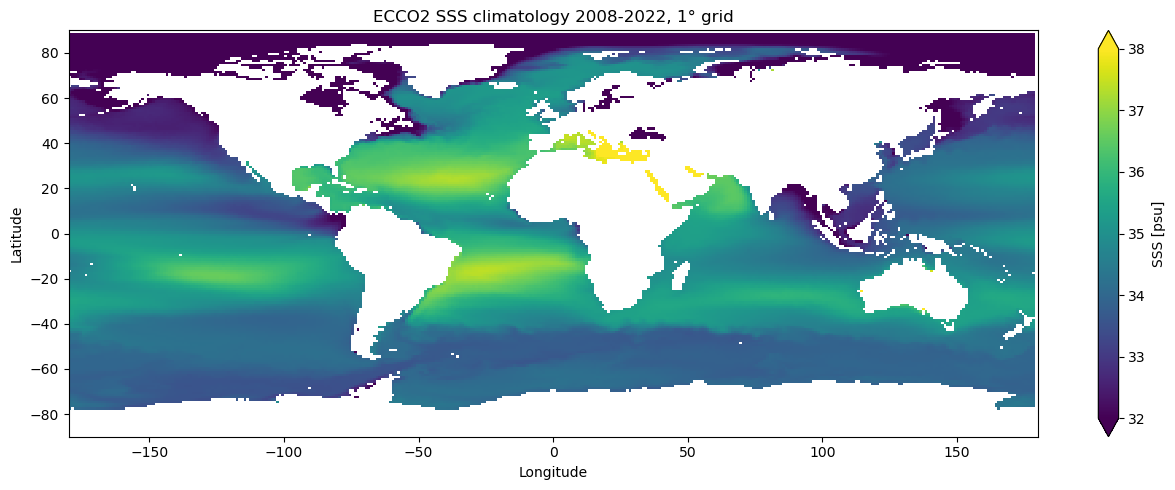


Cached 12 monthly SSS arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅ Depth 

In [7]:
"""
ECCO2 cube92 sea surface salinity (SSS) → monthly climatology on the
same 1° lat/lon grid used for the beta/biovolume regridding.

SSS is a 2D field (no lev dim). Same pattern as MLD: stride subsample
to roughly 1° before loading, build the monthly climatology, then
final interp onto the exact target grid centers.

Surface-only — the same SSS value is broadcast to every depth at the
same (month, lat, lon) in the matching loop.
"""

import time
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def lon_0360_to_pm180(_ds):
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
    return _ds


def load_with_retry(da, max_tries=5, base_delay=5.0):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  load attempt {attempt}/{max_tries} ...", flush=True)
            out = da.load()
            print(f"  ✅ loaded on attempt {attempt}")
            return out
        except RuntimeError as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:200]}")
            if attempt == max_tries:
                raise
            sleep = base_delay * (2 ** (attempt - 1))
            print(f"  sleeping {sleep:.1f}s before retry...")
            time.sleep(sleep)


# ============================================================
# 2) Target 1° grid
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Open ECCO2 cube92 SSS
# ============================================================
print("\nOpening ECCO2 cube92 SSS OPeNDAP connection...")
ds_sss = xr.open_dataset(
    'http://apdrc.soest.hawaii.edu:80/dods/public_data/ECCO/ECCO2/cube92_monthly/sss',
    engine='netcdf4',
)
ds_sss = lon_0360_to_pm180(ds_sss)

sss_var = next(v for v in ds_sss.data_vars
               if v.lower() in ('sss', 'salinity', 'salt'))
print(f"Using SSS variable: '{sss_var}'")
print(f"Dimensions: {dict(ds_sss[sss_var].sizes)}")

# Subset time (lazy)
sss_raw = ds_sss[sss_var].sel(time=slice('2008-01-01', '2022-12-31'))
print(f"After time subset (lazy): shape = {sss_raw.shape}")


# ============================================================
# 4) Stride subsample (lazy) to ~1°
# ============================================================
ecco_dlat = float(np.abs(np.diff(sss_raw['lat'].values[:2]))[0])
ecco_dlon = float(np.abs(np.diff(sss_raw['lon'].values[:2]))[0])
stride_lat = max(1, int(round(LAT_RES / ecco_dlat)))
stride_lon = max(1, int(round(LON_RES / ecco_dlon)))
print(f"\nECCO2 Δ ≈ {ecco_dlat:.3f}° → strides lat={stride_lat}, lon={stride_lon}")

sss_coarse = sss_raw.isel(lat=slice(None, None, stride_lat),
                           lon=slice(None, None, stride_lon))
print(f"After spatial stride (lazy): shape = {sss_coarse.shape}")


# ============================================================
# 5) Monthly climatology (lazy) → load → final regrid
# ============================================================
sss_clim_coarse = (sss_coarse
                   .groupby('time.month')
                   .mean('time', skipna=True))
print(f"Climatology shape (lazy, coarse): {sss_clim_coarse.shape}")

print("\nLoading from OPeNDAP...")
sss_clim_coarse = load_with_retry(sss_clim_coarse, max_tries=5)

print("\nInterpolating onto target 1° grid...")
sss = sss_clim_coarse.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

sss.name = "sss"
sss.attrs["long_name"] = "ECCO2 cube92 sea surface salinity, monthly climatology, 1° grid"
sss.attrs["units"]     = "psu"
print(f"✅ SSS on target grid: {sss.shape}  dims={dict(sss.sizes)}")

outfile = 'ecco2_sss_clim_2008_2022_1deg.nc'
sss.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 6) Quick plot
# ============================================================
sss_mean = sss.mean('month', skipna=True)
plt.figure(figsize=(13, 5))
sss_mean.plot(x='lon', y='lat', cmap='viridis',
              vmin=32, vmax=38,
              cbar_kwargs={'label': 'SSS [psu]'})
plt.title('ECCO2 SSS climatology 2008-2022, 1° grid')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 7) Cache monthly arrays for matching loop
# ============================================================
sss_lat = sss['lat'].values.astype(np.float64)
sss_lon = sss['lon'].values.astype(np.float64)
sss_by_month = {int(m): sss.sel(month=m).values for m in sss['month'].values}
print(f"\nCached {len(sss_by_month)} monthly SSS arrays")


# ============================================================
# 8) Extract Salinity at each (depth, month, lat, lon) of the
#    beta/biovolume long table
#
# Surface-only — same SSS broadcast to every depth at the same
# (month, lat, lon).
# ============================================================
def extract_salinity_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    sss_data = sss_by_month[int(m)]
    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(sss_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(sss_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(sss_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(sss_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(sss_lat, sss_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "Salinity":  sss_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "Salinity":  sss_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 9) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_salinity_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid Salinity records extracted.")

df_salinity_valid   = pd.concat(valid_records,   ignore_index=True)
df_salinity_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined Salinity results:")
print(f"   Salinity where beta valid:   {df_salinity_valid.shape}")
print(f"   Salinity where beta missing: {df_salinity_missing.shape}")
print("\nValid Salinity statistics:")
print(df_salinity_valid["Salinity"].describe())


# ============================================================
# 10) Convert to xarray
# ============================================================
ds_salinity_valid = (df_salinity_valid
                     .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                     .to_xarray())
ds_salinity_missing = (df_salinity_missing
                       .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                       .to_xarray())

print("\nxarray dims Salinity valid:",   dict(ds_salinity_valid.sizes))
print("xarray dims Salinity missing:", dict(ds_salinity_missing.sizes))

In [8]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin...")

# Step 1: aggregate to per-depth yearly totals.
# Prefer using df_counts (already built earlier with Pressure_dbar, Month, Valid_points).
# If df_counts isn't around, rebuild from df_valid_selected:
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with the most valid cells
bin_size = 5
selected_depths = []
block_info = []

for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")

print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# Step 3: subset both salinity datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_salt_valid_best   = ds_salinity_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_salt_missing_best = ds_salinity_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset salinity datasets:")



🔍 Selecting best depth level (max valid data across the year) in each 3-level bin...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5         

Target grid: 180 lat × 360 lon  (1.0° resolution)

Fetching 240 monthly NPP files...
Error processing ./npp_data/eppley.2022091.hdf: SD (10): Read error
✅ Read 239 files into memory
NPP climatology (coarse-native): (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}

Interpolating onto target 1° grid...
✅ NPP on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved eppley_npp_clim_2003_2022_1deg.nc


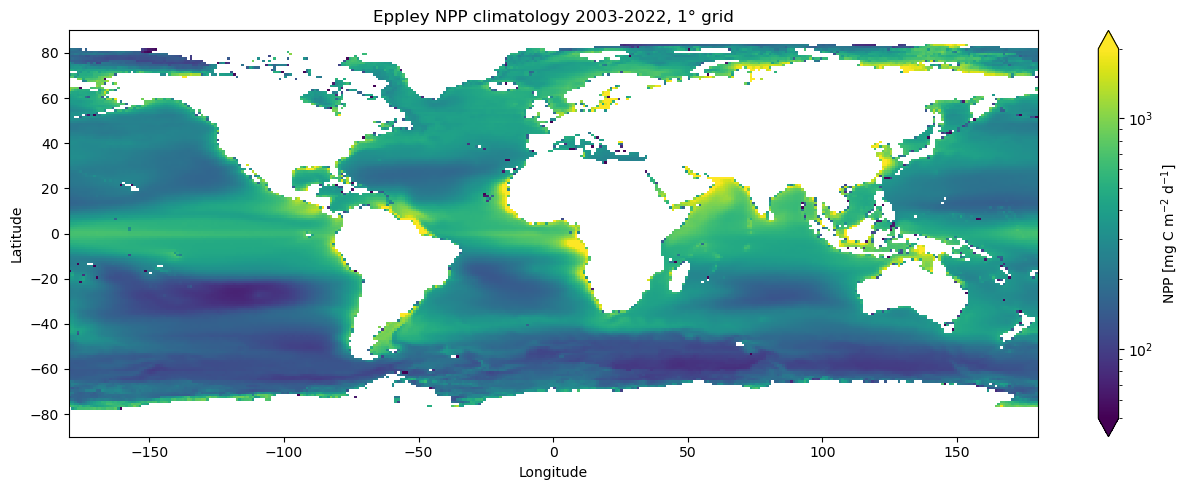


Cached 12 monthly NPP arrays in RAM
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅

In [9]:
"""
Eppley NPP → monthly climatology on the same 1° lat/lon grid used for
the beta/biovolume regridding.

Eppley NPP comes from HDF files at 1/6° resolution. We download the
monthly files for 2003-2022, coarsen 6× to 1°, then interp onto the
exact target grid centers so the cells line up bit-for-bit with the
rest of the env-variable pipeline.

NPP has only (time, lat, lon) — no depth. When matched to the
beta/biovolume long table (which DOES have depth), the same surface
NPP value is attached to every depth at the same (month, lat, lon).
"""

import os
import gzip
import shutil
import requests
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from pyhdf.SD import SD, SDC


# ============================================================
# 1) Helpers
# ============================================================
def make_session():
    s = requests.Session()
    s.headers.update({"User-Agent": "npp-fetch/1.0"})
    retries = Retry(total=5, backoff_factor=0.5,
                    status_forcelist=[429, 500, 502, 503, 504])
    s.mount("http://", HTTPAdapter(max_retries=retries))
    s.mount("https://", HTTPAdapter(max_retries=retries))
    return s


def download_and_decompress(base_url, date_value, download_dir, session=None):
    if session is None:
        session = make_session()
    gz_filename  = f"eppley.{date_value}.hdf.gz"
    hdf_filename = f"eppley.{date_value}.hdf"
    gz_path  = os.path.join(download_dir, gz_filename)
    hdf_path = os.path.join(download_dir, hdf_filename)
    if os.path.exists(hdf_path):
        return hdf_path
    url = f"{base_url}/{gz_filename}"
    try:
        with session.get(url, stream=True, timeout=60, verify=False) as r:
            r.raise_for_status()
            with open(gz_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)
        with gzip.open(gz_path, "rb") as f_in, open(hdf_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
        os.remove(gz_path)
        return hdf_path
    except requests.RequestException as e:
        print(f"[skip] {gz_filename}: {e}")
        if os.path.exists(gz_path):
            os.remove(gz_path)
        return None


def read_npp_data(hdf_path):
    try:
        hdf = SD(hdf_path, SDC.READ)
        return hdf.select('npp').get()
    except Exception as e:
        print(f"Error processing {hdf_path}: {e}")
        return None


def convert_0_360_to_neg180_180(_da):
    if (_da['lon'].min() >= 0) and (_da['lon'].max() <= 360):
        _da = _da.assign_coords(
            lon=xr.where(_da['lon'] > 180, _da['lon'] - 360, _da['lon'])
        ).sortby('lon')
    return _da


# ============================================================
# 2) Target 1° grid (same as beta/biovolume code)
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Download monthly NPP HDFs (2003-2022)
# ============================================================
base_url     = "http://orca.science.oregonstate.edu/data/1x2/monthly/eppley.r2022.m.chl.m.sst/hdf"
download_dir = "./npp_data"
os.makedirs(download_dir, exist_ok=True)

date_values = []
for year in range(2003, 2023):
    for month in range(1, 13):
        date_values.append(datetime(year, month, 1).strftime('%Y%j'))

print(f"\nFetching {len(date_values)} monthly NPP files...")
npp_arrays, npp_times = [], []
for d in date_values:
    p = download_and_decompress(base_url, d, download_dir)
    if p is None:
        continue
    arr = read_npp_data(p)
    if arr is None:
        continue
    npp_arrays.append(arr)
    npp_times.append(datetime.strptime(d, '%Y%j'))
print(f"✅ Read {len(npp_arrays)} files into memory")


# ============================================================
# 4) Build DataArray, coarsen 1/6° → ~1°, build climatology
# ============================================================
ny, nx = npp_arrays[0].shape
da = xr.DataArray(
    np.stack(npp_arrays, axis=0),
    dims=('time', 'lat', 'lon'),
    coords={
        'time': pd.to_datetime(npp_times),
        'lat':  np.linspace( 90, -90, ny),
        'lon':  np.linspace(-180, 180, nx),
    },
    name='npp',
)

# Flip lat to ascending and coarsen 6× to ~1°
da = da.reindex(lat=da.lat[::-1])
da = da.coarsen(lat=6, lon=6, boundary='trim').mean()
da = convert_0_360_to_neg180_180(da)

# Replace negative fill values with NaN
da = da.where(da >= 0)

# Monthly climatology
npp_native = da.groupby('time.month').mean('time').load()
print(f"NPP climatology (coarse-native): {npp_native.shape}  "
      f"dims={dict(npp_native.sizes)}")


# ============================================================
# 5) Interp onto target 1° grid (cell centers exactly aligned)
# ============================================================
print("\nInterpolating onto target 1° grid...")
npp = npp_native.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

npp.name = "npp"
npp.attrs["long_name"] = "Eppley NPP monthly climatology, 1° grid"
npp.attrs["units"]     = "mg C m-2 d-1"
print(f"✅ NPP on target grid: {npp.shape}  dims={dict(npp.sizes)}")

outfile = 'eppley_npp_clim_2003_2022_1deg.nc'
npp.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 6) Quick plot
# ============================================================
import matplotlib.colors as mcolors
npp_mean = npp.mean('month', skipna=True)
plt.figure(figsize=(13, 5))
npp_mean.plot(x='lon', y='lat',
              norm=mcolors.LogNorm(vmin=50, vmax=2000),
              cmap='viridis',
              cbar_kwargs={'label': 'NPP [mg C m$^{-2}$ d$^{-1}$]'})
plt.title('Eppley NPP climatology 2003-2022, 1° grid')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 7) Cache monthly arrays for matching loop
# ============================================================
npp_lat = npp['lat'].values.astype(np.float64)
npp_lon = npp['lon'].values.astype(np.float64)
npp_by_month = {int(m): npp.sel(month=m).values for m in npp['month'].values}
print(f"\nCached {len(npp_by_month)} monthly NPP arrays in RAM")


# ============================================================
# 8) Extract NPP at each (depth, month, lat, lon) of the
#    beta/biovolume long table
#
# Surface-only — same value broadcast to every depth at the same
# (month, lat, lon).
# ============================================================
def extract_npp_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    npp_data = npp_by_month[int(m)]
    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(npp_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(npp_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(npp_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(npp_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(npp_lat, npp_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "NPP":       npp_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "NPP":       npp_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 9) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_npp_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid NPP records extracted.")

df_npp_valid   = pd.concat(valid_records,   ignore_index=True)
df_npp_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined NPP results:")
print(f"   NPP where beta valid:   {df_npp_valid.shape}")
print(f"   NPP where beta missing: {df_npp_missing.shape}")
print("\nValid NPP statistics:")
print(df_npp_valid["NPP"].describe())


# ============================================================
# 10) Convert to xarray
# ============================================================
ds_npp_valid = (df_npp_valid
                .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                .to_xarray())
ds_npp_missing = (df_npp_missing
                  .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                  .to_xarray())

print("\nxarray dims NPP valid:",   dict(ds_npp_valid.sizes))
print("xarray dims NPP missing:", dict(ds_npp_missing.sizes))

In [10]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (NPP)...")

# Step 1: aggregate to per-depth yearly totals.
# Prefer df_counts (built earlier in the counting pipeline). Fall back to
# counting from df_valid_selected if df_counts isn't around.
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with most valid cells
bin_size = 5
selected_depths = []
block_info = []

for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# Step 3: subset both NPP datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_npp_valid_best   = ds_npp_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_npp_missing_best = ds_npp_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset NPP datasets:")
print("   valid:  ", dict(ds_npp_valid_best.dims))
print("   missing:", dict(ds_npp_missing_best.dims))


🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (NPP)...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5   

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1057176054.py:53: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_npp_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1057176054.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_npp_missing_best.dims))


In [11]:
import xarray as xr
import numpy as np
import pandas as pd

# ============================================================
# 1) Load WOA phosphate and build monthly climatology
# ============================================================
infile = '~/Desktop/WOA.nc'
ds = xr.open_dataset(infile, engine='netcdf4')
ds['time'] = pd.date_range("1955-01-01", periods=780, freq="ME")
ds = xr.decode_cf(ds)

def convert_0_360_to_neg180_180(_ds):
    attrs = _ds['lon'].attrs
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                         _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
        _ds['lon'].attrs = attrs
    return _ds

ds = convert_0_360_to_neg180_180(ds)

# Monthly climatology: mean over all Januaries, all Februaries, ...
po4 = ds['po4'].groupby('time.month').mean('time').load()
print("✅ WOA phosphate monthly climatology:", po4.shape,
      "dims:", dict(po4.sizes))


# ============================================================
# 2) Pre-extract NumPy arrays once (no xarray inside the loop)
# ============================================================
woa_lat = po4['lat'].values.astype(np.float64)
woa_lon = po4['lon'].values.astype(np.float64)
woa_depths = po4['depth'].values if 'depth' in po4.dims else None

po4_by_month_depth = {}
for m in po4['month'].values:
    if woa_depths is not None:
        for d in woa_depths:
            po4_by_month_depth[(int(m), float(d))] = (
                po4.sel(month=m, depth=d).values
            )
    else:
        po4_by_month_depth[(int(m), None)] = po4.sel(month=m).values
print(f"Cached {len(po4_by_month_depth)} (month, depth) PO4 arrays")


# ============================================================
# 3) Helper: extract valid + missing PO4 for one (pressure, month)
#    using df_valid_selected as the source of valid cells.
# ============================================================
def extract_po4_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p) &
        (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    if woa_depths is not None:
        nearest_depth = float(woa_depths[np.abs(woa_depths - p).argmin()])
        po4_data = po4_by_month_depth[(int(m), nearest_depth)]
    else:
        po4_data = po4_by_month_depth[(int(m), None)]

    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    # Vectorized nearest-neighbor lookup
    lat_idx = np.abs(woa_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(woa_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(po4_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    missing_mask = ~valid_mask

    lat2d, lon2d = np.meshgrid(woa_lat, woa_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "PO4":       po4_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "PO4":       po4_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 4) Loop over (depth, month) combinations in df_valid_selected
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_po4_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

df_po4_valid   = pd.concat(valid_records,   ignore_index=True)
df_po4_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined PO4 results:")
print(f"   PO4 where beta valid:   {df_po4_valid.shape}")
print(f"   PO4 where beta missing: {df_po4_missing.shape}")


# ============================================================
# 5) Convert to xarray for storage / later use
# ============================================================
ds_po4_valid = (df_po4_valid
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    .to_xarray())
ds_po4_missing = (df_po4_missing
    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
    .to_xarray())

print("\nxarray dims (PO4 valid):", dict(ds_po4_valid.dims))

✅ WOA phosphate monthly climatology: (12, 180, 360) dims: {'month': 12, 'lat': 180, 'lon': 360}
Cached 12 (month, depth) PO4 arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1256681822.py:130: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("\nxarray dims (PO4 valid):", dict(ds_po4_valid.dims))


In [12]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (PO4) in each 3-level bin...")

if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")

selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")
ds_po4_valid_best   = ds_po4_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_po4_missing_best = ds_po4_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset PO4 datasets:")
print("   valid:  ", dict(ds_po4_valid_best.dims))
print("   missing:", dict(ds_po4_missing_best.dims))


🔍 Selecting best depth level (PO4) in each 3-level bin...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5              252.5               20

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3211324361.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_po4_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3211324361.py:46: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_po4_missing_best.dims))


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening GODAS thflx from http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/GODAS/monthly/thflx


/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/argopy/utils/lists.py:28: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ModuleNotFoundError'>
No module named 'pytz'
  warnings.warn(
/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/argopy/utils/lists.py:40: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ModuleNotFoundError'>
No module named 'pytz'
  warnings.warn(
/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/argopy/utils/lists.py:56: UserWarning: An error occurred while loading the GDAC data fetcher, it will not be available !
<class 'ModuleNotFoundError'>
No module named 'pytz'
  warnings.warn(
/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/argopy/utils/lists.py:81: UserWarning: An error occurred while loading the ERDDAP index fetcher, it will not be available !
<class 'ModuleNotFoundError'>
No m

GODAS dims: {'time': 558, 'lat': 418, 'lon': 360}
Variables: ['thflxsfc']
After time subset (lazy): shape = (180, 418, 360)
Climatology shape (lazy, native): (12, 418, 360)

Loading climatology from OPeNDAP...
  load attempt 1/5 ...
  ✅ loaded on attempt 1
GODAS native lat range: -74.5 … 64.4

Interpolating onto target 1° grid...
✅ GODAS Thflx on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
NaN cells (outside GODAS coverage): 366,612 / 777,600  (47.1%)
Saved godas_thflxsfc_clim_2008_2022_1deg.nc


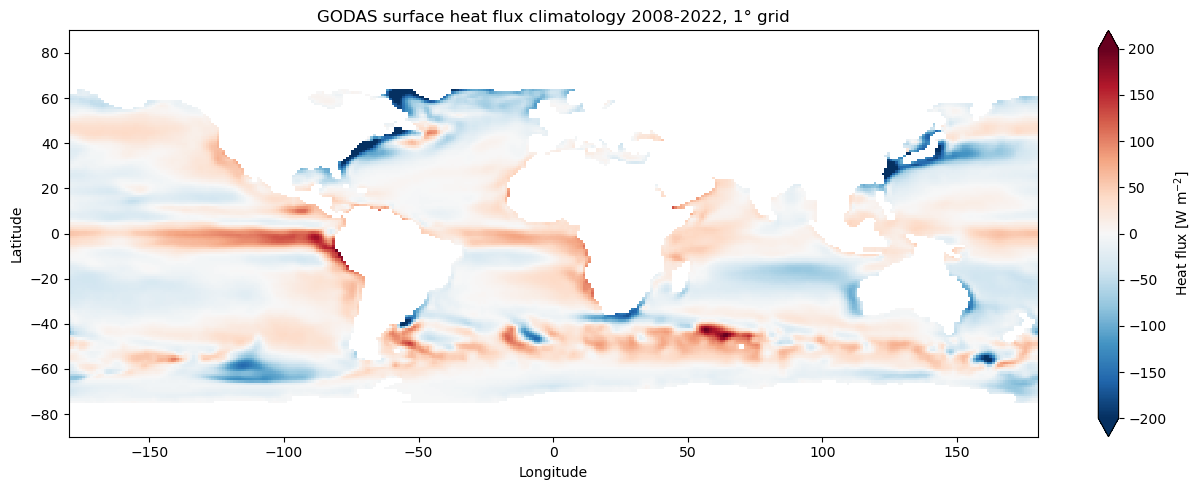


Cached 12 monthly heat-flux arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅ 

In [13]:
"""
GODAS surface heat flux (thflxsfc) → monthly climatology on the same
1° lat/lon grid used for the beta/biovolume regridding.

GODAS is at 1° resolution but only covers ~65°S–65°N — polar cells
become NaN after the regrid (handled downstream by NaN-aware masking).

thflxsfc has only (time, lat, lon) — surface-only. The matching loop
broadcasts the same value to every depth at the same (month, lat, lon).
"""

import time
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def convert_0_360_to_neg180_180(_ds):
    attrs = _ds['lon'].attrs
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
        _ds['lon'].attrs = attrs
    return _ds


def load_with_retry(da, max_tries=5, base_delay=5.0):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  load attempt {attempt}/{max_tries} ...", flush=True)
            out = da.load()
            print(f"  ✅ loaded on attempt {attempt}")
            return out
        except RuntimeError as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:200]}")
            if attempt == max_tries:
                raise
            sleep = base_delay * (2 ** (attempt - 1))
            print(f"  sleeping {sleep:.1f}s before retry...")
            time.sleep(sleep)


# ============================================================
# 2) Target 1° grid (same as beta/biovolume code)
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Open GODAS surface heat flux
# ============================================================
infile = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/GODAS/monthly/thflx'
print(f"\nOpening GODAS thflx from {infile}")
ds = xr.open_dataset(infile, decode_times=True)
print("GODAS dims:", dict(ds.sizes))
print("Variables:", list(ds.data_vars))

ds = convert_0_360_to_neg180_180(ds)

# Subset time (lazy)
ds = ds.sel(time=slice('2008-01-01', '2022-12-31'))
print(f"After time subset (lazy): shape = {ds['thflxsfc'].shape}")


# ============================================================
# 4) Monthly climatology (lazy) → load → interp to target grid
# ============================================================
thflx_native = (ds['thflxsfc']
                .groupby('time.month')
                .mean('time', skipna=True)
                .squeeze(drop=True))
print(f"Climatology shape (lazy, native): {thflx_native.shape}")

print("\nLoading climatology from OPeNDAP...")
thflx_native = load_with_retry(thflx_native, max_tries=5)
print(f"GODAS native lat range: "
      f"{float(thflx_native.lat.min()):.1f} … {float(thflx_native.lat.max()):.1f}")


# ============================================================
# 5) Regrid to target 1° grid (linear; polar cells outside coverage → NaN)
# ============================================================
print("\nInterpolating onto target 1° grid...")
thflx = thflx_native.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="linear",
).load()

thflx.name = "thflxsfc"
thflx.attrs["long_name"] = "GODAS surface heat flux, monthly climatology, 1° grid"
thflx.attrs["units"]     = "W m-2"
print(f"✅ GODAS Thflx on target grid: {thflx.shape}  dims={dict(thflx.sizes)}")

n_nan = int(np.isnan(thflx.values).sum())
n_tot = thflx.size
print(f"NaN cells (outside GODAS coverage): {n_nan:,} / {n_tot:,}  "
      f"({100*n_nan/n_tot:.1f}%)")

outfile = 'godas_thflxsfc_clim_2008_2022_1deg.nc'
thflx.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 6) Quick plot
# ============================================================
thflx_mean = thflx.mean('month', skipna=True)
plt.figure(figsize=(13, 5))
thflx_mean.plot(x='lon', y='lat', cmap='RdBu_r',
                vmin=-200, vmax=200,
                cbar_kwargs={'label': 'Heat flux [W m$^{-2}$]'})
plt.title('GODAS surface heat flux climatology 2008-2022, 1° grid')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 7) Cache monthly arrays for the matching loop
# ============================================================
godas_lat = thflx['lat'].values.astype(np.float64)
godas_lon = thflx['lon'].values.astype(np.float64)
thflx_by_month = {int(m): thflx.sel(month=m).values
                  for m in thflx['month'].values}
print(f"\nCached {len(thflx_by_month)} monthly heat-flux arrays")


# ============================================================
# 8) Extract thflxsfc at each (depth, month, lat, lon) of the
#    beta/biovolume long table
#
# Surface-only — same value broadcast to every depth at the same
# (month, lat, lon).
# ============================================================
def extract_thflx_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    thflx_data = thflx_by_month[int(m)]
    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(godas_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(godas_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(thflx_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(thflx_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(godas_lat, godas_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "Thflx":     thflx_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "Thflx":     thflx_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 9) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_thflx_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid Thflx records extracted.")

df_thflx_valid   = pd.concat(valid_records,   ignore_index=True)
df_thflx_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined Thflx results:")
print(f"   Thflx where beta valid:   {df_thflx_valid.shape}")
print(f"   Thflx where beta missing: {df_thflx_missing.shape}")
print("\nValid Thflx statistics:")
print(df_thflx_valid["Thflx"].describe())


# ============================================================
# 10) Convert to xarray
# ============================================================
ds_thflx_valid = (df_thflx_valid
                  .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                  .to_xarray())
ds_thflx_missing = (df_thflx_missing
                    .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                    .to_xarray())

print("\nxarray dims Thflx valid:",   dict(ds_thflx_valid.sizes))
print("xarray dims Thflx missing:", dict(ds_thflx_missing.sizes))

In [14]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (Thflx) in each bin...")

if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Match this to whatever bin_size you used for the other env variables
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")

selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")
ds_thflx_valid_best   = ds_thflx_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_thflx_missing_best = ds_thflx_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset Thflx datasets:")
print("   valid:  ", dict(ds_thflx_valid_best.dims))
print("   missing:", dict(ds_thflx_missing_best.dims))


🔍 Selecting best depth level (Thflx) in each bin...
✅ Selected 241 representative levels

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5              252.5               2099           
12      27

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1001389552.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_thflx_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1001389552.py:46: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_thflx_missing_best.dims))


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening WOA from ~/Desktop/WOA.nc
WOA NO3 climatology (native): (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}

Interpolating onto target 1° grid...
✅ WOA NO3 on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved woa_no3_clim_1deg.nc


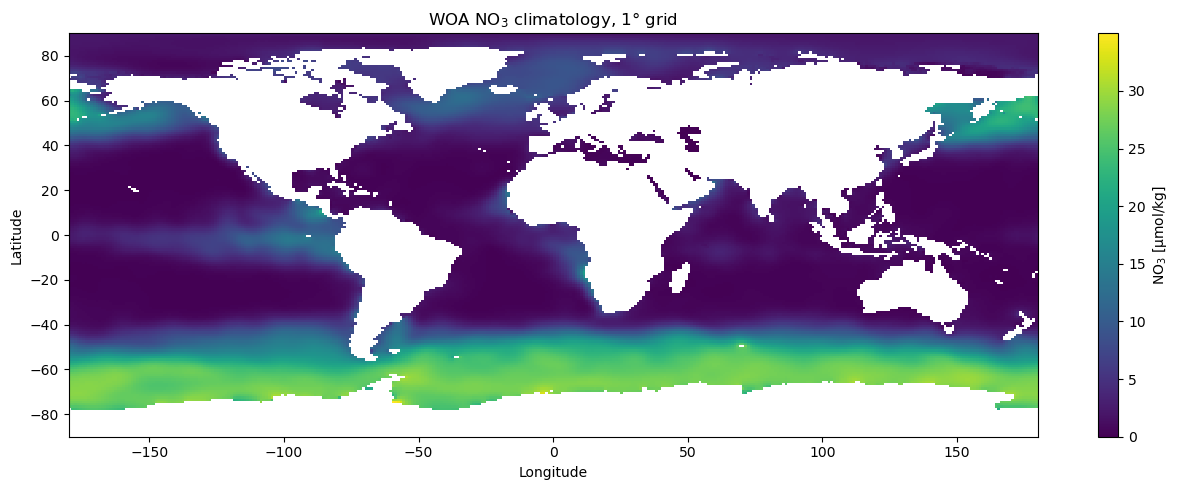


Cached 12 (month, depth) NO3 arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅

In [15]:
"""
WOA nitrate → monthly climatology on the same 1° lat/lon grid used for
the beta/biovolume regridding.

WOA is already at 1° resolution, so no spatial coarsening is needed.
A final interp onto the exact target grid centers makes everything
line up bit-for-bit with Chl / MLD / Bathymetry / O2 / TEMP.

NO3 has a depth dim — the matching loop selects the WOA depth
nearest to each observation pressure level.
"""

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def convert_0_360_to_neg180_180(_ds):
    attrs = _ds['lon'].attrs
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
        _ds['lon'].attrs = attrs
    return _ds


# ============================================================
# 2) Target 1° grid (same as beta/biovolume code)
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Load WOA + build monthly climatology
# ============================================================
infile = '~/Desktop/WOA.nc'
print(f"\nOpening WOA from {infile}")
ds = xr.open_dataset(infile, engine='netcdf4')
ds['time'] = pd.date_range("1955-01-01", periods=780, freq="ME")
ds = xr.decode_cf(ds)
ds = convert_0_360_to_neg180_180(ds)

no3_native = ds['no3'].groupby('time.month').mean('time').load()
print(f"WOA NO3 climatology (native): {no3_native.shape}  "
      f"dims={dict(no3_native.sizes)}")


# ============================================================
# 4) Interp onto target 1° grid (cell centers exactly aligned)
# ============================================================
print("\nInterpolating onto target 1° grid...")
no3 = no3_native.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

no3.name = "no3"
no3.attrs["long_name"] = "WOA nitrate monthly climatology, 1° grid"
print(f"✅ WOA NO3 on target grid: {no3.shape}  dims={dict(no3.sizes)}")

outfile = 'woa_no3_clim_1deg.nc'
no3.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 5) Quick plot — surface annual mean
# ============================================================
if 'depth' in no3.dims:
    no3_plot = no3.isel(depth=0).mean('month', skipna=True)
    depth_str = f" @ depth = {float(no3['depth'].values[0]):.0f} m"
else:
    no3_plot = no3.mean('month', skipna=True)
    depth_str = ""

plt.figure(figsize=(13, 5))
no3_plot.plot(x='lon', y='lat', cmap='viridis',
              cbar_kwargs={'label': 'NO$_3$ [µmol/kg]'})
plt.title(f'WOA NO$_3$ climatology, 1° grid{depth_str}')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 6) Cache arrays for matching loop
# ============================================================
woa_lat    = no3['lat'].values.astype(np.float64)
woa_lon    = no3['lon'].values.astype(np.float64)
woa_depths = no3['depth'].values if 'depth' in no3.dims else None

no3_by_month_depth = {}
for m in no3['month'].values:
    if woa_depths is not None:
        for d in woa_depths:
            no3_by_month_depth[(int(m), float(d))] = (
                no3.sel(month=m, depth=d).values
            )
    else:
        no3_by_month_depth[(int(m), None)] = no3.sel(month=m).values
print(f"\nCached {len(no3_by_month_depth)} (month, depth) NO3 arrays")


# ============================================================
# 7) Extract NO3 at each (depth, month, lat, lon) of the
#    beta/biovolume long table
# ============================================================
def extract_no3_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    if woa_depths is not None:
        nearest_depth = float(woa_depths[np.abs(woa_depths - p).argmin()])
        no3_data = no3_by_month_depth[(int(m), nearest_depth)]
    else:
        no3_data = no3_by_month_depth[(int(m), None)]

    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(woa_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(woa_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(no3_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(no3_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(woa_lat, woa_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "NO3":       no3_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "NO3":       no3_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 8) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_no3_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid NO3 records extracted.")

df_no3_valid   = pd.concat(valid_records,   ignore_index=True)
df_no3_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined NO3 results:")
print(f"   NO3 where beta valid:   {df_no3_valid.shape}")
print(f"   NO3 where beta missing: {df_no3_missing.shape}")
print("\nValid NO3 statistics:")
print(df_no3_valid["NO3"].describe())


# ============================================================
# 9) Convert to xarray
# ============================================================
ds_no3_valid = (df_no3_valid
                .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                .to_xarray())
ds_no3_missing = (df_no3_missing
                  .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                  .to_xarray())

print("\nxarray dims NO3 valid:",   dict(ds_no3_valid.sizes))
print("xarray dims NO3 missing:", dict(ds_no3_missing.sizes))

In [16]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (NO3)...")

# Step 1: aggregate to per-depth yearly totals
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with most valid cells
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")

# Step 3: subset both NO3 datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_no3_valid_best   = ds_no3_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_no3_missing_best = ds_no3_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset NO3 datasets:")
print("   valid:  ", dict(ds_no3_valid_best.dims))
print("   missing:", dict(ds_no3_missing_best.dims))


🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (NO3)...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5   

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/216950826.py:49: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_no3_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/216950826.py:50: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_no3_missing_best.dims))


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening ECCO2 cube92 theta OPeNDAP connection...


/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


Using theta variable: 'sst'
Dimensions: {'time': 408, 'lat': 720, 'lon': 1440}
After surface select + time subset (lazy): shape = (180, 720, 1440)

ECCO2 Δ ≈ 0.250° → strides lat=4, lon=4
After spatial stride (lazy): shape = (180, 180, 360)
Climatology shape (lazy, coarse): (12, 180, 360)

Loading from OPeNDAP...
  load attempt 1/5 ...
  ✅ loaded on attempt 1

Interpolating onto target 1° grid...
✅ Surface theta on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved ecco2_theta_surf_clim_2008_2022_1deg.nc


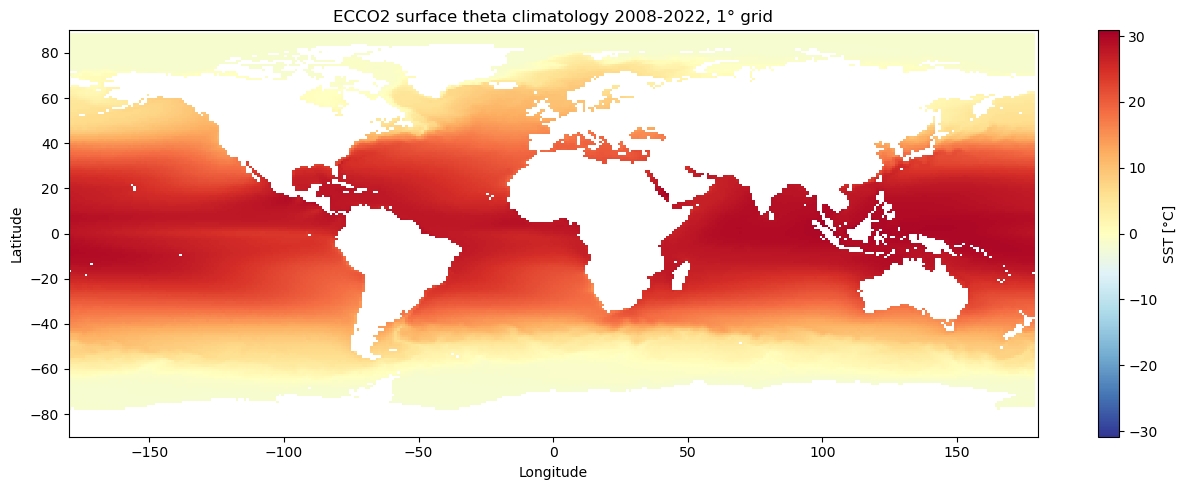


Cached 12 monthly TEMP arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅ Depth

In [17]:
"""
ECCO2 cube92 surface temperature (theta, lev=0) → monthly climatology
on the same 1° lat/lon grid used for beta/biovolume.

Switching from WOA to ECCO2:
  - ECCO2 cube92 is ~0.25° (finer than the target 1° grid), so stride
    subsampling is applied lazily before the load.
  - We select the surface level only (lev=0), so the output is a
    (month, lat, lon) field with no depth dim — same shape as
    Chl and MLD.

Because we're using surface-only theta, the matching loop attaches the
same SST value to every depth at the same (month, lat, lon).
If you later want depth-dependent T, switch to the full ECCO2 theta cube
(remove the .isel(lev=0)) and add a depth-selection step like the WOA
script's nearest-depth lookup.
"""

import time
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def lon_0360_to_pm180(_ds):
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
    return _ds


def load_with_retry(da, max_tries=5, base_delay=5.0):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  load attempt {attempt}/{max_tries} ...", flush=True)
            out = da.load()
            print(f"  ✅ loaded on attempt {attempt}")
            return out
        except RuntimeError as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:200]}")
            if attempt == max_tries:
                raise
            sleep = base_delay * (2 ** (attempt - 1))
            print(f"  sleeping {sleep:.1f}s before retry...")
            time.sleep(sleep)


# ============================================================
# 2) Target 1° grid
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Open ECCO2 cube92 theta
# ============================================================
print("\nOpening ECCO2 cube92 theta OPeNDAP connection...")
ds_theta = xr.open_dataset(
    'http://apdrc.soest.hawaii.edu:80/dods/public_data/ECCO/ECCO2/cube92_monthly/sst',
    engine='netcdf4',
)
ds_theta = lon_0360_to_pm180(ds_theta)

theta_var = next(v for v in ds_theta.data_vars
                 if v.lower() in ('theta', 'temp', 'temperature', 'sst', 't'))
print(f"Using theta variable: '{theta_var}'")
print(f"Dimensions: {dict(ds_theta[theta_var].sizes)}")

# Select surface level (lev=0)
#lev_name = next((d for d in ds_theta[theta_var].dims
#                 if d.lower() in ('lev', 'depth', 'z')), None)
#if lev_name is None:
#    raise ValueError(f"Could not find vertical dim in {list(ds_theta[theta_var].dims)}")
#print(f"Vertical dim '{lev_name}' has {ds_theta.sizes[lev_name]} levels — "
#      f"using level 0 (surface)")

theta_surf = ds_theta[theta_var]#.isel({lev_name: 0})

# Subset time (lazy)
theta_surf = theta_surf.sel(time=slice('2008-01-01', '2022-12-31'))
print(f"After surface select + time subset (lazy): shape = {theta_surf.shape}")


# ============================================================
# 4) Stride subsample (lazy) to ~1°
# ============================================================
ecco_dlat = float(np.abs(np.diff(theta_surf['lat'].values[:2]))[0])
ecco_dlon = float(np.abs(np.diff(theta_surf['lon'].values[:2]))[0])
stride_lat = max(1, int(round(LAT_RES / ecco_dlat)))
stride_lon = max(1, int(round(LON_RES / ecco_dlon)))
print(f"\nECCO2 Δ ≈ {ecco_dlat:.3f}° → strides lat={stride_lat}, lon={stride_lon}")

theta_coarse = theta_surf.isel(lat=slice(None, None, stride_lat),
                                lon=slice(None, None, stride_lon))
print(f"After spatial stride (lazy): shape = {theta_coarse.shape}")


# ============================================================
# 5) Monthly climatology (lazy) → load → final regrid
# ============================================================
theta_clim_coarse = (theta_coarse
                     .groupby('time.month')
                     .mean('time', skipna=True))
print(f"Climatology shape (lazy, coarse): {theta_clim_coarse.shape}")

print("\nLoading from OPeNDAP...")
theta_clim_coarse = load_with_retry(theta_clim_coarse, max_tries=5)

print("\nInterpolating onto target 1° grid...")
temp = theta_clim_coarse.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

temp.name = "temp"
temp.attrs["long_name"] = "ECCO2 cube92 surface theta, monthly climatology, 1° grid"
temp.attrs["units"]     = "degC"
print(f"✅ Surface theta on target grid: {temp.shape}  dims={dict(temp.sizes)}")

outfile = 'ecco2_theta_surf_clim_2008_2022_1deg.nc'
temp.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 6) Quick plot
# ============================================================
temp_mean = temp.mean('month', skipna=True)
plt.figure(figsize=(13, 5))
temp_mean.plot(x='lon', y='lat', cmap='RdYlBu_r',
               cbar_kwargs={'label': 'SST [°C]'})
plt.title('ECCO2 surface theta climatology 2008-2022, 1° grid')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 7) Cache monthly arrays for matching loop
# ============================================================
temp_lat = temp['lat'].values.astype(np.float64)
temp_lon = temp['lon'].values.astype(np.float64)
temp_by_month = {int(m): temp.sel(month=m).values for m in temp['month'].values}
print(f"\nCached {len(temp_by_month)} monthly TEMP arrays")


# ============================================================
# 8) Extract TEMP at each (depth, month, lat, lon) of the
#    beta/biovolume long table
#
# Surface-only: same SST value broadcast to every depth at the same
# (month, lat, lon).
# ============================================================
def extract_temp_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    temp_data = temp_by_month[int(m)]
    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(temp_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(temp_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(temp_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(temp_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(temp_lat, temp_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "TEMP":      temp_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "TEMP":      temp_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 9) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_temp_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid TEMP records extracted.")

df_temp_valid   = pd.concat(valid_records,   ignore_index=True)
df_temp_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined TEMP results:")
print(f"   TEMP where beta valid:   {df_temp_valid.shape}")
print(f"   TEMP where beta missing: {df_temp_missing.shape}")
print("\nValid TEMP statistics:")
print(df_temp_valid["TEMP"].describe())


# ============================================================
# 10) Convert to xarray
# ============================================================
ds_temp_valid = (df_temp_valid
                 .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                 .to_xarray())
ds_temp_missing = (df_temp_missing
                   .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                   .to_xarray())

print("\nxarray dims TEMP valid:",   dict(ds_temp_valid.sizes))
print("xarray dims TEMP missing:", dict(ds_temp_missing.sizes))

In [18]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (TEMP)...")

# Step 1: aggregate to per-depth yearly totals
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with most valid cells
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# Step 3: subset both TEMP datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_temp_valid_best   = ds_temp_valid.sel  (Pressure_dbar=selected_da, method="nearest")
ds_temp_missing_best = ds_temp_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset TEMP datasets:")
print("   valid:  ", dict(ds_temp_valid_best.dims))
print("   missing:", dict(ds_temp_missing_best.dims))


🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (TEMP)...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5  

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3040218409.py:50: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_temp_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3040218409.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_temp_missing_best.dims))


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening WOA from ~/Desktop/WOA.nc
WOA O2 climatology (native): (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}

Interpolating onto target 1° grid...
✅ WOA O2 on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved woa_o2_clim_1deg.nc


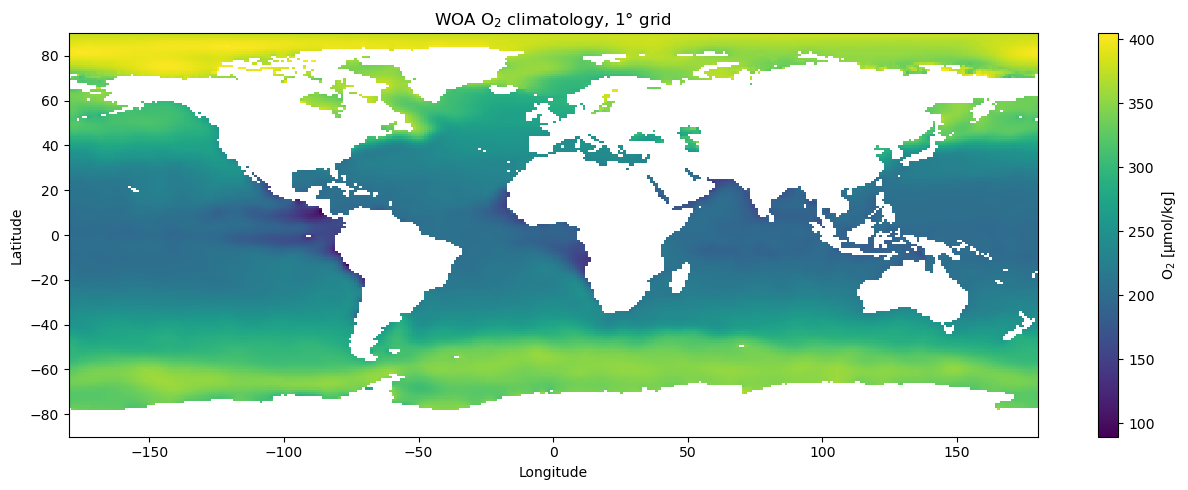


Cached 12 (month, depth) O2 arrays
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅ 

In [19]:
"""
WOA oxygen → monthly climatology on the same 1° lat/lon grid used for
the beta/biovolume regridding.

WOA is already at 1° resolution, so no spatial coarsening is needed.
We just open the local NetCDF, build the monthly climatology, and
interp onto the exact target grid centers so the cells line up
bit-for-bit with Chl/MLD/Bathymetry/etc.

O2 has a depth dim (unlike Chl/MLD/Bathymetry), so the matching loop
selects the WOA depth nearest to each observation pressure level.
"""

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def convert_0_360_to_neg180_180(_ds):
    attrs = _ds['lon'].attrs
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
        _ds['lon'].attrs = attrs
    return _ds


# ============================================================
# 2) Target 1° grid (same as beta/biovolume code)
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Load WOA + build monthly climatology
# ============================================================
infile = '~/Desktop/WOA.nc'
print(f"\nOpening WOA from {infile}")
ds = xr.open_dataset(infile, engine='netcdf4')
ds['time'] = pd.date_range("1955-01-01", periods=780, freq="ME")
ds = xr.decode_cf(ds)
ds = convert_0_360_to_neg180_180(ds)

o2_native = ds['o2'].groupby('time.month').mean('time').load()
print(f"WOA O2 climatology (native): {o2_native.shape}  "
      f"dims={dict(o2_native.sizes)}")


# ============================================================
# 4) Interp onto target 1° grid (cell centers exactly aligned)
# ============================================================
print("\nInterpolating onto target 1° grid...")
o2 = o2_native.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

o2.name = "o2"
o2.attrs["long_name"] = "WOA oxygen monthly climatology, 1° grid"
print(f"✅ WOA O2 on target grid: {o2.shape}  dims={dict(o2.sizes)}")

outfile = 'woa_o2_clim_1deg.nc'
o2.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 5) Quick plot — surface annual mean
# ============================================================
if 'depth' in o2.dims:
    o2_plot = o2.isel(depth=0).mean('month', skipna=True)
    depth_str = f" @ depth = {float(o2['depth'].values[0]):.0f} m"
else:
    o2_plot = o2.mean('month', skipna=True)
    depth_str = ""

plt.figure(figsize=(13, 5))
o2_plot.plot(x='lon', y='lat', cmap='viridis',
             cbar_kwargs={'label': 'O$_2$ [µmol/kg]'})
plt.title(f'WOA O$_2$ climatology, 1° grid{depth_str}')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 6) Cache arrays for matching loop
# ============================================================
woa_lat    = o2['lat'].values.astype(np.float64)
woa_lon    = o2['lon'].values.astype(np.float64)
woa_depths = o2['depth'].values if 'depth' in o2.dims else None

o2_by_month_depth = {}
for m in o2['month'].values:
    if woa_depths is not None:
        for d in woa_depths:
            o2_by_month_depth[(int(m), float(d))] = (
                o2.sel(month=m, depth=d).values
            )
    else:
        o2_by_month_depth[(int(m), None)] = o2.sel(month=m).values
print(f"\nCached {len(o2_by_month_depth)} (month, depth) O2 arrays")


# ============================================================
# 7) Extract O2 at each (depth, month, lat, lon) of the
#    beta/biovolume long table
# ============================================================
def extract_o2_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    if woa_depths is not None:
        nearest_depth = float(woa_depths[np.abs(woa_depths - p).argmin()])
        o2_data = o2_by_month_depth[(int(m), nearest_depth)]
    else:
        o2_data = o2_by_month_depth[(int(m), None)]

    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(woa_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(woa_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(o2_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mask = np.isfinite(o2_data)
    valid_mask   = valid_mask & finite_mask
    missing_mask = (~valid_mask) & finite_mask

    lat2d, lon2d = np.meshgrid(woa_lat, woa_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "O2":        o2_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "O2":        o2_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 8) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_o2_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid O2 records extracted.")

df_o2_valid   = pd.concat(valid_records,   ignore_index=True)
df_o2_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined O2 results:")
print(f"   O2 where beta valid:   {df_o2_valid.shape}")
print(f"   O2 where beta missing: {df_o2_missing.shape}")
print("\nValid O2 statistics:")
print(df_o2_valid["O2"].describe())


ds_o2_valid = (df_o2_valid
               .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
               .to_xarray())
ds_o2_missing = (df_o2_missing
                 .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                 .to_xarray())

print("\nxarray dims O2 valid:",   dict(ds_o2_valid.sizes))
print("xarray dims O2 missing:", dict(ds_o2_missing.sizes))

In [20]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (O2) in each 3-level bin...")

if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")

selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")
ds_o2_valid_best   = ds_o2_valid.sel(Pressure_dbar=selected_da, method="nearest")
ds_o2_missing_best = ds_o2_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset O2 datasets:")
print("   valid:  ", dict(ds_o2_valid_best.dims))
print("   missing:", dict(ds_o2_missing_best.dims))


🔍 Selecting best depth level (O2) in each 3-level bin...
✅ Selected 241 representative levels

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5              252.5               2099           
12   

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/4165772427.py:44: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_o2_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/4165772427.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_o2_missing_best.dims))


Reference grid from ds_o2_missing: 168 lat x 360 lon
  lat -77.50 .. 89.50, lon -179.50 .. 179.50

Loading modis_chla_clim_2008_2022_1deg.nc — skipping the download
  dims: {'month': 12, 'lat': 180, 'lon': 360}

Cached 12 monthly Chl arrays (lat (180,), lon (360,), cube (12, 180, 360))
  grid identical to the O2 reference: False
  !! Chl is on a different grid — delete modis_chla_clim_2008_2022_1deg.nc and rerun so it regrids onto the reference

chl_clim: full climatology — colour range 0.018 .. 5.98 mg m-3


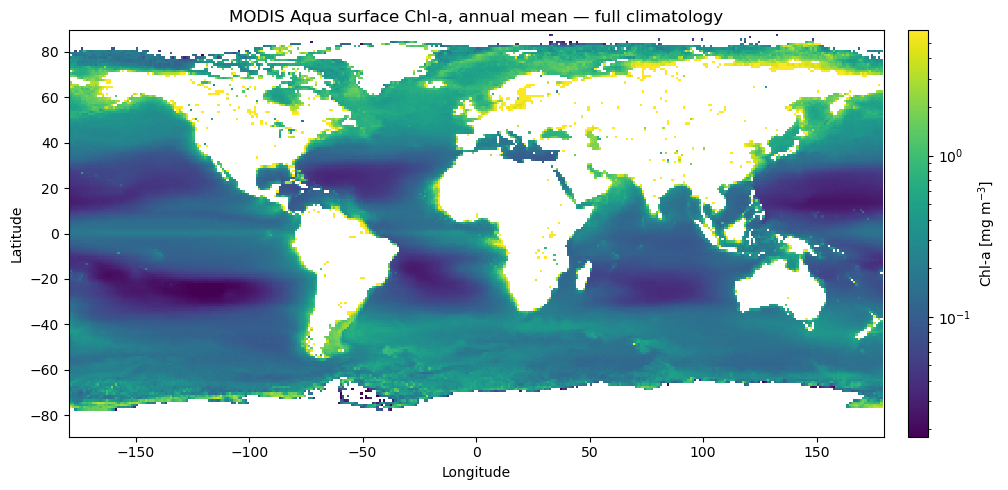

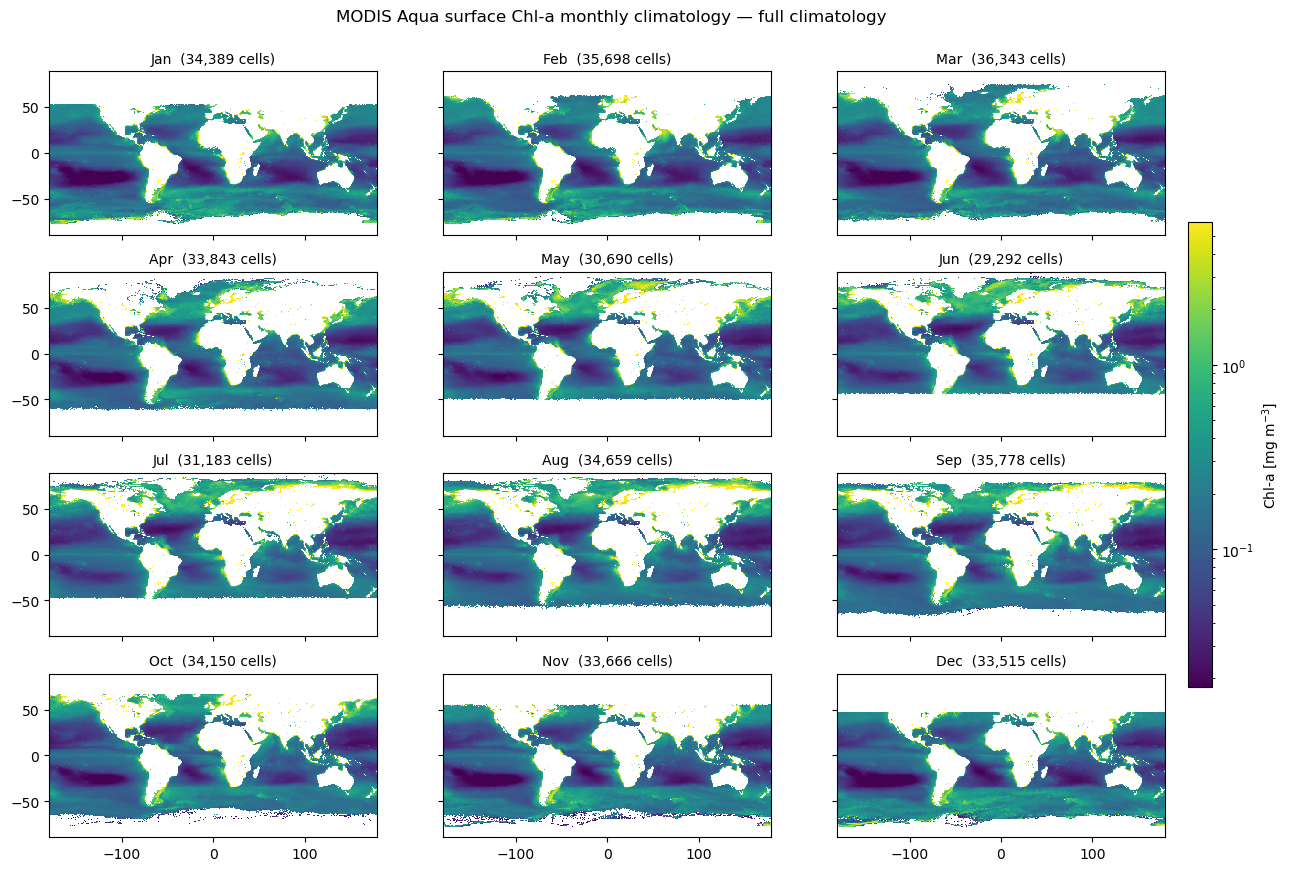

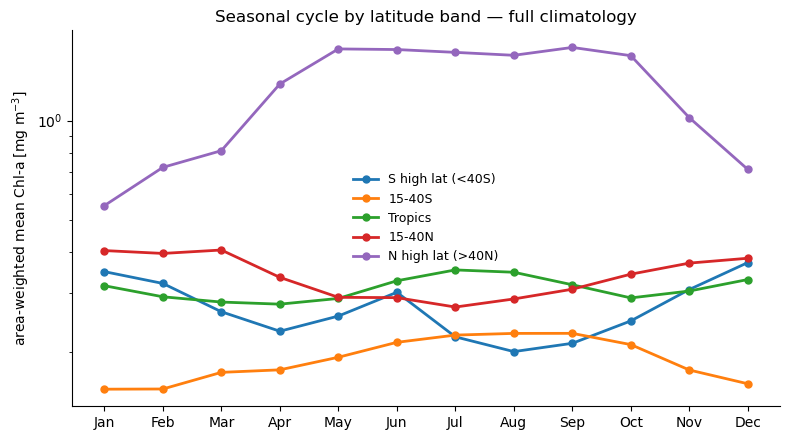

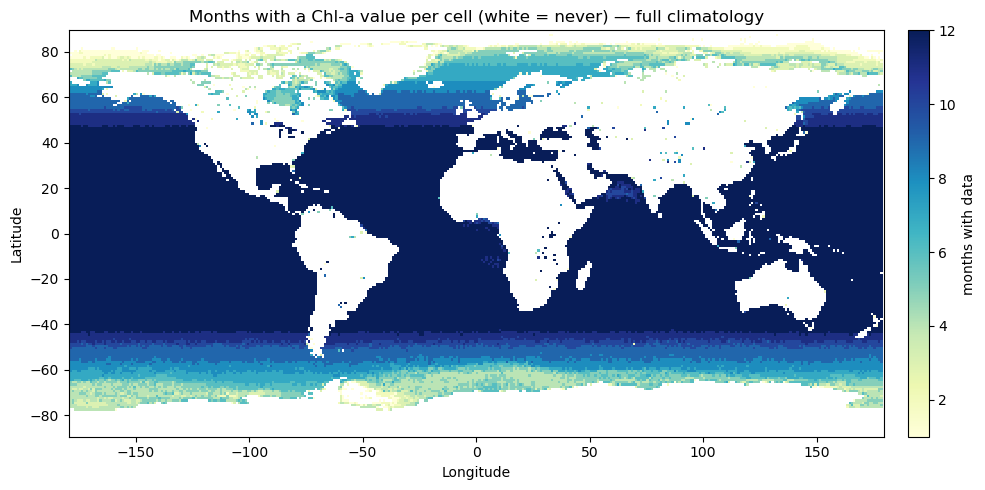

  all 12 months : 23,901 cells
  1-11 months   : 16,393 cells
  never         : 24,506 cells

✅ Chl attached to 192,844 rows: 175,655 finite (91.1%), 17,189 missing
   max snap distance: 0.000° lat, 0.000° lon (should be ≤ 0.5)
   Southern Ocean (<60S)      17,889 rows,  82.7% missing Chl
   30-60S                     20,020 rows,   2.3% missing Chl
   Tropics                   105,147 rows,   0.1% missing Chl
   30-60N                     40,627 rows,   2.3% missing Chl
   Arctic (>60N)               9,161 rows,   9.7% missing Chl

Valid Chl statistics:
count    175655.000000
mean          0.316562
std           0.608079
min           0.012726
25%           0.091263
50%           0.149533
75%           0.283022
max          19.169426
Name: Chl, dtype: float64

Building Chl cubes shaped like the O2 cubes ...
  valid cube (241, 12, 148, 278) = 118,988,448 cells (476 MB)
    filled 192,844 rows, 175,596 finite cells
  missing cube (241, 12, 168, 360) = 174,908,160 cells (700 MB)
    dept

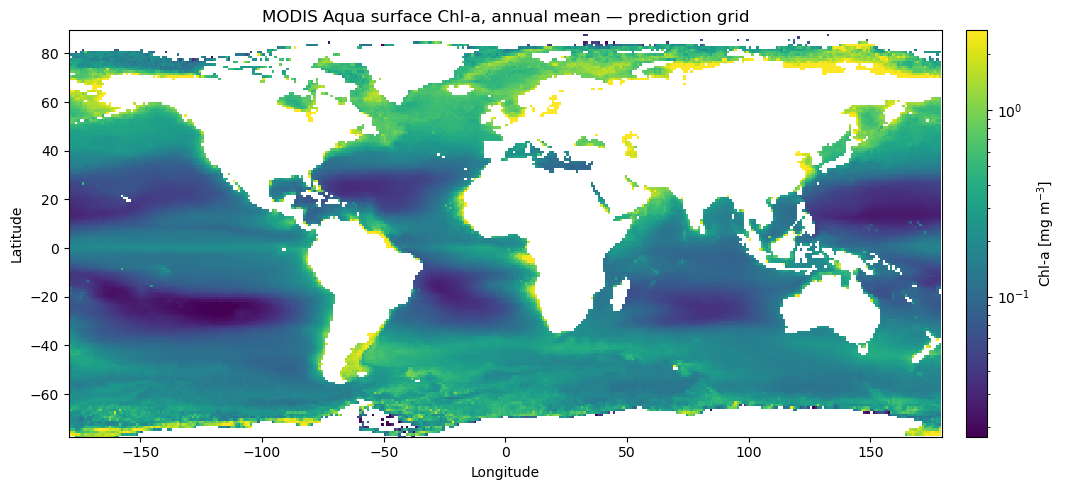

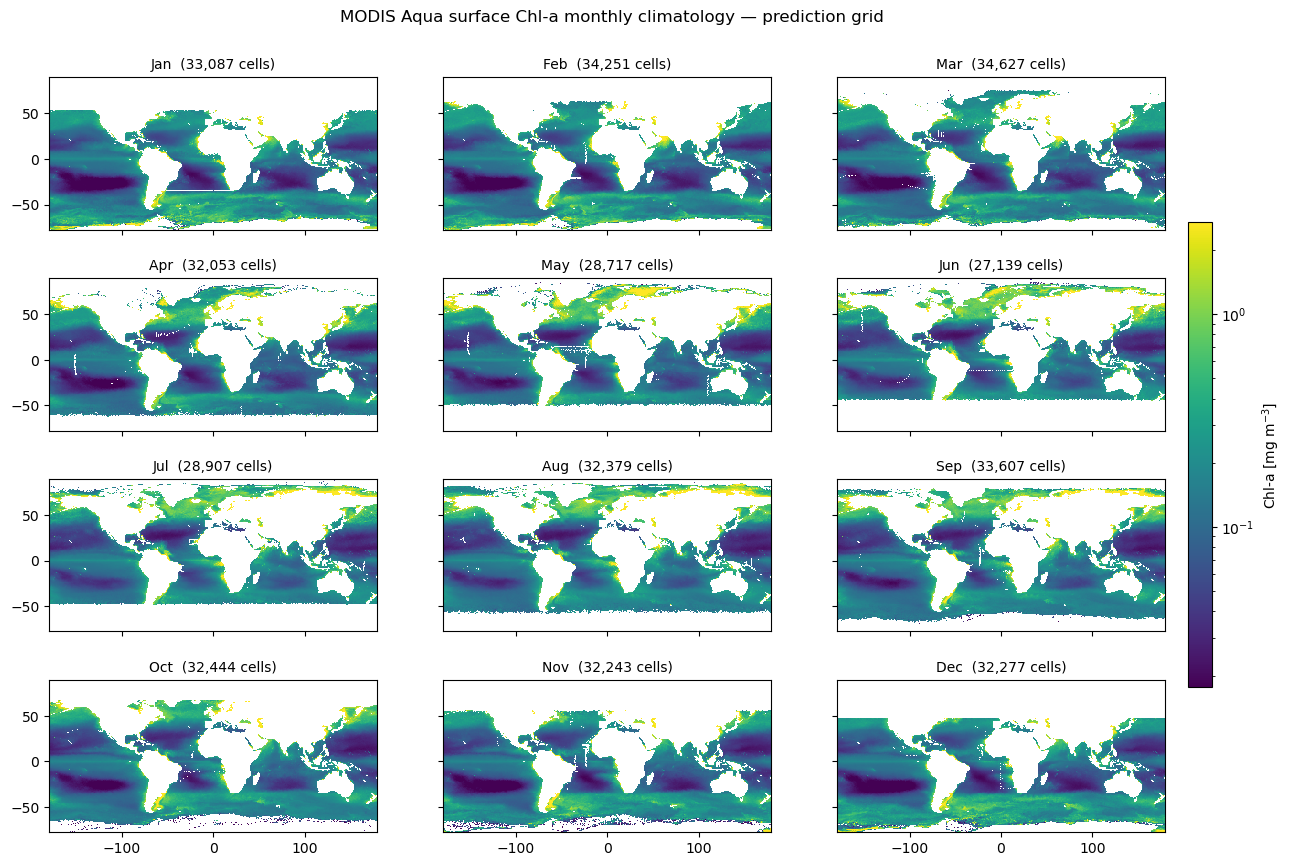

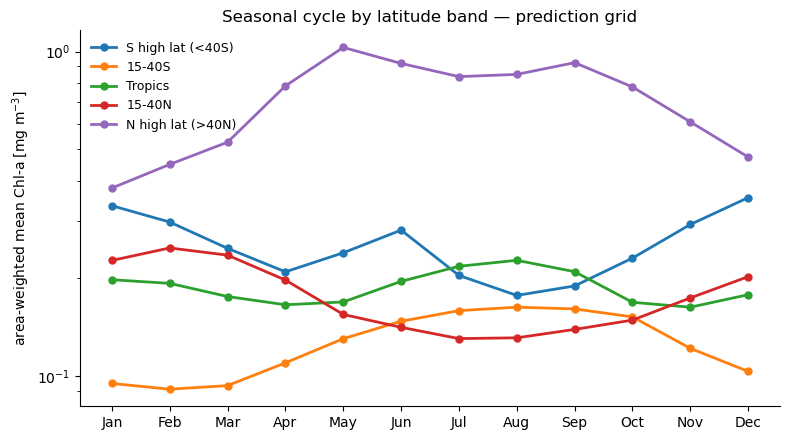

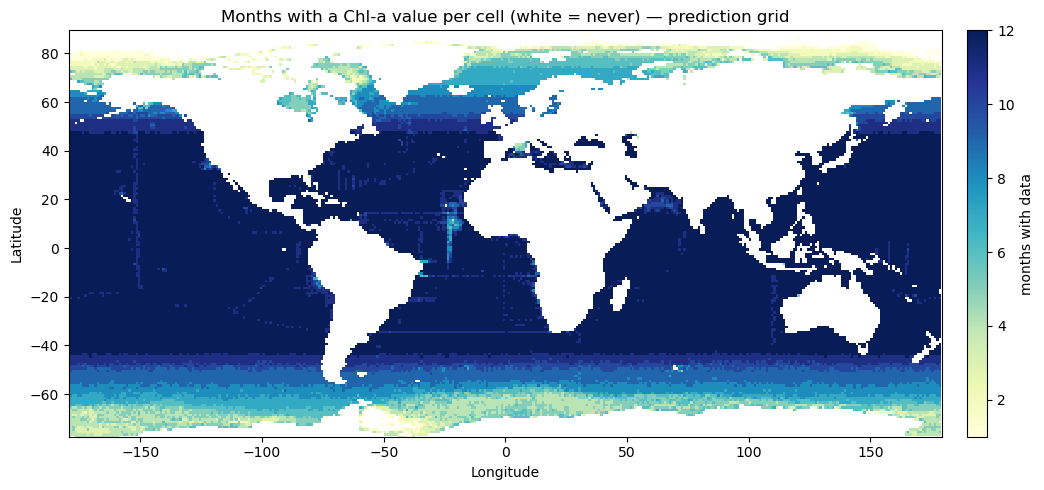

  all 12 months : 21,902 cells
  1-11 months   : 16,040 cells
  never         : 22,538 cells


In [21]:
"""
===========================================================================
MODIS Aqua Chl-a  →  monthly climatology  →  training table  →  depth cubes
===========================================================================
Source: APDRC GrADS Data Server, chla_mapped_mon_9km

Produces
--------
    chl              (month, lat, lon)   surface climatology on the grid
    df_train         training table with a "Chl" column, one value per row
    ds_chl_valid     (Pressure_dbar, Month, Latitude, Longitude)  observed
    ds_chl_missing   (Pressure_dbar, Month, Latitude, Longitude)  prediction
    + four climatology figures

Design notes
------------
* Chl-a is a SURFACE field. Every depth slice of the cubes is the same 2-D
  field. That is intentional: the training table already carries depth as
  its own column, so the model learns beta(depth, surface forcing). The
  duplication only exists because the downstream code wants all predictors
  on one common cube.

* APDRC's time axis is 'days since 1-1-1'. datetime64[ns] starts at 1677,
  so decode_times=True overflows and groupby('time.month') fails. We
  decode with cftime and reduce time to integer year/month arrays.

* The climatology is fetched one month at a time; GDS times out on a
  single 15-year request for the 9 km product.

* Nearest-cell lookup uses searchsorted, never a broadcast distance
  matrix. The broadcast form allocates n_grid x n_rows — 555 MB for the
  training table, ~260 GB if applied to the prediction table.

* Cubes are allocated once and written into slice by slice. np.where over
  a broadcast array allocates the result plus a temporary plus a full-size
  boolean mask, which is what killed the kernel before.

* The grid is taken from the O2 cubes when they exist, so every predictor
  lands on the beta/biovolume grid by construction rather than by
  coincidence.

Needs in the namespace
----------------------
    df_valid_selected                with Pressure_dbar, Month, Latitude,
                                     Longitude
    ds_o2_valid, ds_o2_missing       optional; used as the grid reference
                                     and to shape the output cubes
===========================================================================
"""

import os
import time as _time

import numpy as np
import pandas as pd
import xarray as xr
import cftime
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ------------------------------------------------------------------ config
APDRC_URL = ("http://apdrc.soest.hawaii.edu:80/dods/public_data/"
             "satellite_product/MODIS_Aqua/chla_mapped_mon_9km")
YEAR0, YEAR1 = 2008, 2022
LAT_RES = LON_RES = 1.0
DTYPE = np.float32
CLIM_FILE = "modis_chla_clim_2008_2022_1deg.nc"
FORCE_REFETCH = False           # True to re-download even if CLIM_FILE exists
SAVE_NETCDF = False          # True to write the depth cubes to disk
                             # (needs the netcdf4 engine for compression;
                             #  the uncompressed write is ~1.2 GB and can
                             #  itself exhaust memory on a small machine)
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


# ============================================================
# 1) Helpers
# ============================================================
def lon_0360_to_pm180(obj):
    if (obj['lon'].min() >= 0) and (obj['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            obj.coords['lon'] = xr.where(obj['lon'] > 180,
                                         obj['lon'] - 360, obj['lon'])
        obj = obj.sortby('lon')
    return obj


def load_with_retry(da, max_tries=5, base_delay=5.0):
    for attempt in range(1, max_tries + 1):
        try:
            return da.load()
        except (RuntimeError, OSError) as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:150]}")
            if attempt == max_tries:
                raise
            sleep = base_delay * (2 ** (attempt - 1))
            print(f"  sleeping {sleep:.1f}s before retry...")
            _time.sleep(sleep)


def decode_year_month(ds, time_name='time'):
    """(year, month) integer arrays — survives the GrADS year-1 epoch."""
    t = ds[time_name]
    if np.issubdtype(t.dtype, np.datetime64):
        idx = pd.DatetimeIndex(t.values)
        return idx.year.to_numpy(), idx.month.to_numpy()
    if t.dtype == object:                                   # cftime objects
        return (np.array([v.year for v in t.values]),
                np.array([v.month for v in t.values]))
    vals = np.asarray(t.values, dtype='float64')
    units = t.attrs.get('units') or t.encoding.get('units')
    cal = t.attrs.get('calendar', 'standard')
    if units is None:
        raise ValueError(f"time is numeric with no CF units; "
                         f"attrs={dict(t.attrs)}")
    print(f"  time units: {units!r}, calendar={cal!r}")
    print(f"  raw first 3 = {vals[:3]}, last 3 = {vals[-3:]}")
    if np.nanmin(vals) == np.nanmax(vals):
        raise ValueError("all time values identical — the coordinate did not "
                         "transfer; retry, or use another mirror")
    dates = cftime.num2date(vals, units=units, calendar=cal,
                            only_use_cftime_datetimes=True)
    return (np.array([d.year for d in dates]),
            np.array([d.month for d in dates]))


def nearest_index(grid, values):
    """Nearest grid index per value. O(len(values)) memory."""
    grid = np.asarray(grid, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    pos = np.clip(np.searchsorted(grid, values), 1, grid.size - 1)
    left, right = grid[pos - 1], grid[pos]
    return np.where(values - left <= right - values,
                    pos - 1, pos).astype(np.int32)


def mean_ignore_nan(cube, axis=0):
    """nanmean without the 'mean of empty slice' warning."""
    valid = np.isfinite(cube)
    count = valid.sum(axis=axis)
    total = np.where(valid, cube, 0.0).sum(axis=axis)
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)


# ============================================================
# 2) Reference grid — the beta/biovolume grid, via the O2 cubes
# ============================================================
if 'ds_o2_missing' in globals():
    REF_LAT = np.asarray(ds_o2_missing['Latitude'].values, dtype=np.float64)
    REF_LON = np.asarray(ds_o2_missing['Longitude'].values, dtype=np.float64)
    _grid_src = 'ds_o2_missing'
elif 'ds_o2_valid' in globals():
    REF_LAT = np.asarray(ds_o2_valid['Latitude'].values, dtype=np.float64)
    REF_LON = np.asarray(ds_o2_valid['Longitude'].values, dtype=np.float64)
    _grid_src = 'ds_o2_valid'
else:
    _le = np.arange(-90, 90 + LAT_RES, LAT_RES)
    _oe = np.arange(-180, 180 + LON_RES, LON_RES)
    REF_LAT = 0.5 * (_le[:-1] + _le[1:])
    REF_LON = 0.5 * (_oe[:-1] + _oe[1:])
    _grid_src = 'grid definition'

print(f"Reference grid from {_grid_src}: "
      f"{REF_LAT.size} lat x {REF_LON.size} lon")
print(f"  lat {REF_LAT.min():.2f} .. {REF_LAT.max():.2f}, "
      f"lon {REF_LON.min():.2f} .. {REF_LON.max():.2f}")


# ============================================================
# 3-6) Climatology: reuse from memory or disk, else download
# ============================================================
if 'chl' in globals() and not FORCE_REFETCH:
    print("\nUsing 'chl' already in memory — skipping the download")

elif os.path.exists(CLIM_FILE) and not FORCE_REFETCH:
    print(f"\nLoading {CLIM_FILE} — skipping the download")
    try:
        chl = xr.open_dataarray(CLIM_FILE)
    except ValueError:
        _dsf = xr.open_dataset(CLIM_FILE)
        chl = _dsf[list(_dsf.data_vars)[0]]
    print(f"  dims: {dict(chl.sizes)}")

else:
    # ---------- 3) open ----------
    print(f"\nOpening APDRC MODIS Aqua Chl-a ...\n  {APDRC_URL}")
    ds_chl = xr.open_dataset(APDRC_URL, engine='netcdf4', decode_times=False)
    print(f"  variables: {list(ds_chl.data_vars)}")
    print(f"  dims     : {dict(ds_chl.sizes)}")
    ds_chl = lon_0360_to_pm180(ds_chl)

    chl_var = next(v for v in ds_chl.data_vars if 'chl' in v.lower())
    print(f"  using variable: '{chl_var}'")

    year, month_all = decode_year_month(ds_chl)
    print(f"  decoded years: {year.min()} .. {year.max()}")
    if year.max() < 1990 or year.min() > 2030:
        raise ValueError(f"decoded years {year.min()}-{year.max()} are "
                         "implausible for MODIS Aqua (2002-present)")

    keep = np.flatnonzero((year >= YEAR0) & (year <= YEAR1))
    if keep.size == 0:
        raise ValueError(f"no steps in {YEAR0}-{YEAR1}; "
                         f"have {year.min()}-{year.max()}")
    chl_surf = ds_chl[chl_var].isel(time=keep)
    month_sel = month_all[keep]
    print(f"  keeping {keep.size} months "
          f"(expect ~{12 * (YEAR1 - YEAR0 + 1)})")

    # ---------- 4) stride to ~1 deg ----------
    dlat = float(abs(np.diff(chl_surf['lat'].values[:2])[0]))
    dlon = float(abs(np.diff(chl_surf['lon'].values[:2])[0]))
    s_lat = max(1, int(round(LAT_RES / dlat)))
    s_lon = max(1, int(round(LON_RES / dlon)))
    print(f"\n  native {dlat:.4f} x {dlon:.4f} deg -> strides {s_lat}, {s_lon}")
    chl_coarse = chl_surf.isel(lat=slice(None, None, s_lat),
                               lon=slice(None, None, s_lon))
    print(f"  after stride (lazy): {dict(chl_coarse.sizes)}")

    # ---------- 5) climatology, one month per request ----------
    print("\nBuilding the monthly climatology (one month per request) ...")
    monthly = []
    for m in range(1, 13):
        sel = chl_coarse.isel(time=np.flatnonzero(month_sel == m))
        fld = load_with_retry(sel.mean('time', skipna=True), max_tries=5)
        monthly.append(fld)
        print(f"  month {m:02d}: {sel.sizes['time']:3d} fields, "
              f"valid cells = {int(np.isfinite(fld.values).sum()):,}")

    clim = xr.concat(monthly, dim=pd.Index(range(1, 13), name='month'))
    clim = clim.where(clim > 0)

    # ---------- 6) regrid onto the reference grid ----------
    print("\nInterpolating onto the reference grid ...")
    chl = clim.interp(lat=xr.DataArray(REF_LAT, dims="lat"),
                      lon=xr.DataArray(REF_LON, dims="lon"),
                      method="nearest").load()
    chl.name = "chlor_a"
    chl.attrs.update(
        long_name="MODIS Aqua surface Chl-a, monthly climatology",
        units="mg m-3", source=APDRC_URL, years=f"{YEAR0}-{YEAR1}")
    print(f"  min={float(chl.min()):.4g}  max={float(chl.max()):.4g}  "
          f"mean={float(chl.mean()):.4g}  valid={int(chl.notnull().sum()):,}")
    if not (0.001 < float(chl.min()) < 1 and 1 < float(chl.max()) < 100):
        print("  !! outside the usual 0.01-50 mg m-3 range — check the maps")

    chl.to_netcdf(CLIM_FILE)
    print(f"  saved {CLIM_FILE}")


# ============================================================
# 7) Cache monthly arrays, and confirm the grid matches
# ============================================================
_latn = 'lat' if 'lat' in chl.coords else 'Latitude'
_lonn = 'lon' if 'lon' in chl.coords else 'Longitude'
_monn = 'month' if 'month' in chl.coords else 'Month'

chl_lat = np.asarray(chl[_latn].values, dtype=np.float64)
chl_lon = np.asarray(chl[_lonn].values, dtype=np.float64)
chl_cube = np.stack([chl.sel({_monn: m}).values
                     for m in range(1, 13)]).astype(DTYPE)   # (12, ny, nx)
print(f"\nCached 12 monthly Chl arrays "
      f"(lat {chl_lat.shape}, lon {chl_lon.shape}, cube {chl_cube.shape})")

if 'ds_o2_missing' in globals():
    same = (np.array_equal(chl_lat, REF_LAT) and
            np.array_equal(chl_lon, REF_LON))
    print(f"  grid identical to the O2 reference: {same}")
    if not same:
        print("  !! Chl is on a different grid — delete "
              f"{CLIM_FILE} and rerun so it regrids onto the reference")


# ============================================================
# 8) Climatology plots
#
#   source='clim'    the field as regridded
#   source='missing' the same field masked to the prediction grid — this
#                    is what the model will actually see
#   source='valid'   observation cells only (sparse; cruise tracks)
# ============================================================
def plot_chl_climatology(source="clim", depth_index=0, save=True, show=True):
    if source == "clim":
        cube, lat, lon = chl_cube, chl_lat, chl_lon
        tag, what = "chl_clim", "full climatology"
    elif source == "valid":
        cube = ds_chl_valid["Chl"].isel(Pressure_dbar=depth_index).values
        lat = ds_chl_valid["Latitude"].values
        lon = ds_chl_valid["Longitude"].values
        tag, what = "chl_valid", "cells with beta/biovolume observations"
    elif source == "missing":
        cube = ds_chl_missing["Chl"].isel(Pressure_dbar=depth_index).values
        lat = ds_chl_missing["Latitude"].values
        lon = ds_chl_missing["Longitude"].values
        tag, what = "chl_missing", "prediction grid"
    else:
        raise ValueError("source must be 'clim', 'valid' or 'missing'")

    cube = np.asarray(cube, dtype=np.float64)
    finite = cube[np.isfinite(cube)]
    if finite.size == 0:
        print(f"  {source}: no finite values, skipping")
        return
    lo_v = max(np.percentile(finite[finite > 0], 1), 1e-3)
    hi_v = np.percentile(finite, 99)
    norm = colors.LogNorm(vmin=lo_v, vmax=hi_v)
    print(f"\n{tag}: {what} — colour range {lo_v:.3g} .. {hi_v:.3g} mg m-3")

    fig, ax = plt.subplots(figsize=(13, 5))
    im = ax.pcolormesh(lon, lat, mean_ignore_nan(cube), norm=norm,
                       cmap="viridis", shading="nearest")
    plt.colorbar(im, ax=ax, label="Chl-a [mg m$^{-3}$]",
                 fraction=0.03, pad=0.02)
    ax.set_xlim(lon.min(), lon.max()); ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("equal"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"MODIS Aqua surface Chl-a, annual mean — {what}")
    plt.tight_layout()
    if save:
        plt.savefig(f"{tag}_annual_mean.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=True, sharey=True)
    for k, ax in enumerate(axes.ravel()):
        im = ax.pcolormesh(lon, lat, cube[k], norm=norm, cmap="viridis",
                           shading="nearest")
        ax.set_title(f"{MONTHS[k]}  ({int(np.isfinite(cube[k]).sum()):,} cells)",
                     fontsize=10)
        ax.set_xlim(lon.min(), lon.max()); ax.set_ylim(lat.min(), lat.max())
        ax.set_aspect("equal")
    fig.colorbar(im, ax=axes, label="Chl-a [mg m$^{-3}$]",
                 fraction=0.02, pad=0.02)
    fig.suptitle(f"MODIS Aqua surface Chl-a monthly climatology — {what}",
                 y=0.94)
    if save:
        plt.savefig(f"{tag}_monthly_panels.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    area = np.cos(np.radians(lat))[:, None] * np.ones_like(lon)[None, :]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for b0, b1, bname in [(-90, -40, "S high lat (<40S)"), (-40, -15, "15-40S"),
                          (-15, 15, "Tropics"), (15, 40, "15-40N"),
                          (40, 90, "N high lat (>40N)")]:
        sel = (lat >= b0) & (lat < b1)
        if not sel.any():
            continue
        v = np.isfinite(cube[:, sel, :])
        w = np.where(v, area[sel, :], 0.0)
        num = (np.where(v, cube[:, sel, :], 0.0) * w).sum(axis=(1, 2))
        den = w.sum(axis=(1, 2))
        series = np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)
        if np.isfinite(series).any():
            ax.plot(range(1, 13), series, "o-", lw=2, ms=5, label=bname)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("area-weighted mean Chl-a [mg m$^{-3}$]")
    ax.set_yscale("log")
    ax.set_title(f"Seasonal cycle by latitude band — {what}")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    if save:
        plt.savefig(f"{tag}_seasonal_cycle.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    nmonths = np.isfinite(cube).sum(axis=0)
    fig, ax = plt.subplots(figsize=(13, 5))
    im = ax.pcolormesh(lon, lat, np.where(nmonths > 0, nmonths, np.nan),
                       cmap="YlGnBu", vmin=1, vmax=12, shading="nearest")
    plt.colorbar(im, ax=ax, label="months with data", fraction=0.03, pad=0.02)
    ax.set_xlim(lon.min(), lon.max()); ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("equal"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Months with a Chl-a value per cell (white = never) — {what}")
    plt.tight_layout()
    if save:
        plt.savefig(f"{tag}_coverage.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    print(f"  all 12 months : {int((nmonths == 12).sum()):,} cells")
    print(f"  1-11 months   : "
          f"{int(((nmonths > 0) & (nmonths < 12)).sum()):,} cells")
    print(f"  never         : {int((nmonths == 0).sum()):,} cells")


plot_chl_climatology("clim")


# ============================================================
# 9) Attach Chl to the training table (one value per row)
# ============================================================
_lat = df_valid_selected["Latitude"].to_numpy(dtype=np.float64)
_lon = df_valid_selected["Longitude"].to_numpy(dtype=np.float64)
_mon = df_valid_selected["Month"].to_numpy().astype(np.int16)

lat_idx = nearest_index(chl_lat, _lat)
lon_idx = nearest_index(chl_lon, _lon)

df_train = df_train if 'df_train' in globals() else df_valid_selected.copy()
df_train["Chl"] = chl_cube[_mon - 1, lat_idx, lon_idx]

_fin = np.isfinite(df_train["Chl"].to_numpy())
print(f"\n✅ Chl attached to {len(df_train):,} rows: "
      f"{_fin.sum():,} finite ({100 * _fin.mean():.1f}%), "
      f"{(~_fin).sum():,} missing")
print(f"   max snap distance: {np.abs(chl_lat[lat_idx] - _lat).max():.3f}° lat, "
      f"{np.abs(chl_lon[lon_idx] - _lon).max():.3f}° lon "
      f"(should be ≤ {LAT_RES / 2})")

for b0, b1, bname in [(-90, -60, "Southern Ocean (<60S)"), (-60, -30, "30-60S"),
                      (-30, 30, "Tropics"), (30, 60, "30-60N"),
                      (60, 90, "Arctic (>60N)")]:
    msk = ((df_train["Latitude"] >= b0) &
           (df_train["Latitude"] < b1)).to_numpy()
    if msk.sum():
        print(f"   {bname:24s} {msk.sum():8,} rows, "
              f"{100 * (~_fin[msk]).mean():5.1f}% missing Chl")

print("\nValid Chl statistics:")
print(df_train["Chl"].describe())


# ============================================================
# 10) Depth cubes shaped like the O2 cubes
# ============================================================
def _ref_coords(ref):
    return (ref["Pressure_dbar"].values, ref["Month"].values,
            np.asarray(ref["Latitude"].values, dtype=np.float64),
            np.asarray(ref["Longitude"].values, dtype=np.float64))


def chl_cube_like_valid(ref_valid, df_rows, verbose=True):
    """Chl on the reference VALID cube, filled only at observed rows."""
    depths, months, lat, lon = _ref_coords(ref_valid)
    shape = (depths.size, months.size, lat.size, lon.size)
    if verbose:
        print(f"  valid cube {shape} = {np.prod(shape):,} cells "
              f"({np.prod(shape) * np.dtype(DTYPE).itemsize / 1e6:.0f} MB)")

    out = np.full(shape, np.nan, dtype=DTYPE)
    d_pos = {float(v): i for i, v in enumerate(depths)}
    m_pos = {int(v): i for i, v in enumerate(months)}
    di = df_rows["Pressure_dbar"].astype(float).map(d_pos).to_numpy()
    mi = df_rows["Month"].astype(int).map(m_pos).to_numpy()
    la = nearest_index(lat, df_rows["Latitude"].to_numpy())
    lo = nearest_index(lon, df_rows["Longitude"].to_numpy())

    src_la = nearest_index(chl_lat, df_rows["Latitude"].to_numpy())
    src_lo = nearest_index(chl_lon, df_rows["Longitude"].to_numpy())
    vals = chl_cube[df_rows["Month"].astype(int).to_numpy() - 1, src_la, src_lo]

    ok = np.isfinite(di) & np.isfinite(mi)
    out[di[ok].astype(int), mi[ok].astype(int), la[ok], lo[ok]] = vals[ok]
    if verbose:
        print(f"    filled {int(ok.sum()):,} rows, "
              f"{int(np.isfinite(out).sum()):,} finite cells")

    return xr.Dataset(
        {"Chl": (("Pressure_dbar", "Month", "Latitude", "Longitude"), out)},
        coords={"Pressure_dbar": depths, "Month": months,
                "Latitude": lat, "Longitude": lon},
        attrs={"units": "mg m-3",
               "description": "surface Chl-a broadcast to every depth, at "
                              "cells where beta/biovolume is observed",
               "note": "surface field: all depth slices are identical"})


def chl_cube_like_missing(ref_missing, verbose=True):
    """Chl on the reference MISSING cube, mask copied from the reference."""
    depths, months, lat, lon = _ref_coords(ref_missing)
    shape = (depths.size, months.size, lat.size, lon.size)
    if verbose:
        print(f"  missing cube {shape} = {np.prod(shape):,} cells "
              f"({np.prod(shape) * np.dtype(DTYPE).itemsize / 1e6:.0f} MB)")

    ref_var = list(ref_missing.data_vars)[0]
    ref_da = ref_missing[ref_var]
    la = nearest_index(chl_lat, lat)
    lo = nearest_index(chl_lon, lon)
    surf = chl_cube[:, la][:, :, lo].astype(DTYPE)          # (12, ny, nx)

    out = np.full(shape, np.nan, dtype=DTYPE)
    for d in range(depths.size):
        np.copyto(out[d], surf,
                  where=np.isfinite(np.asarray(ref_da[d].values)))
        if verbose and (d % 60 == 0 or d == depths.size - 1):
            print(f"    depth {d + 1}/{depths.size}", end="\r")
    if verbose:
        print(f"\n    {int(np.isfinite(out).sum()):,} finite cells")

    return xr.Dataset(
        {"Chl": (("Pressure_dbar", "Month", "Latitude", "Longitude"), out)},
        coords={"Pressure_dbar": depths, "Month": months,
                "Latitude": lat, "Longitude": lon},
        attrs={"units": "mg m-3",
               "description": "surface Chl-a broadcast to every depth, on the "
                              "prediction grid (mask copied from the "
                              "reference cube)",
               "note": "surface field: all depth slices are identical"})


if 'ds_o2_valid' in globals() and 'ds_o2_missing' in globals():
    print("\nBuilding Chl cubes shaped like the O2 cubes ...")
    ds_chl_valid = chl_cube_like_valid(ds_o2_valid, df_valid_selected)
    ds_chl_missing = chl_cube_like_missing(ds_o2_missing)

    print("\nds_chl_valid  :", dict(ds_chl_valid.sizes))
    print("ds_chl_missing:", dict(ds_chl_missing.sizes))
    assert ds_chl_valid.sizes == ds_o2_valid.sizes, "valid shape differs"
    assert ds_chl_missing.sizes == ds_o2_missing.sizes, "missing shape differs"
    print("✅ shapes match the O2 cubes")

    plot_chl_climatology("missing")      # what the prediction grid will see

    if SAVE_NETCDF:
        # compression needs the netcdf4/h5netcdf engine; scipy's fallback
        # writer rejects the zlib keys, so try and degrade gracefully
        enc = {"Chl": {"zlib": True, "complevel": 4}}
        for name, dsx in [("chl_valid_depth.nc", ds_chl_valid),
                          ("chl_missing_depth.nc", ds_chl_missing)]:
            try:
                dsx.to_netcdf(name, engine="netcdf4", encoding=enc)
            except (ValueError, ImportError):
                dsx.to_netcdf(name)          # uncompressed fallback
                print(f"  (no netcdf4 engine — {name} written uncompressed)")
        print("\nsaved chl_valid_depth.nc and chl_missing_depth.nc "
              "(compressed where possible — the depth axis is identical "
              "slices, so the files shrink enormously)")
else:
    print("\nds_o2_valid / ds_o2_missing not found — depth cubes skipped. "
          "The surface climatology and df_train['Chl'] are ready.")

In [22]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (Chl) in each 10-level bin...")

# ============================================================
# 1) Build per-depth yearly counts (same logic as the O2 script)
#    These are based on the BETA validity — identical to what's
#    used for O2, so `selected_depths` lines up across variables.
# ============================================================
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# ============================================================
# 2) Pick the best depth in each block of `bin_size` levels
# ============================================================
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# ============================================================
# 3) Subset the Chl datasets at those depths
#    Chl is a surface variable broadcast to every depth in
#    ds_chl_valid/missing, so subsetting by depth simply picks
#    the same surface Chl value at the requested pressure level.
# ============================================================
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")
ds_chl_valid_best   = ds_chl_valid#.sel(Pressure_dbar=selected_da, method="nearest")
ds_chl_missing_best = ds_chl_missing#.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset Chl datasets:")
print("   valid:  ", dict(ds_chl_valid_best.dims))
print("   missing:", dict(ds_chl_missing_best.dims))


🔍 Selecting best depth level (Chl) in each 10-level bin...
✅ Selected 241 representative levels

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5              252.5               2099           
12 

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/2895422976.py:59: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_chl_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/2895422976.py:60: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_chl_missing_best.dims))


Target grid: 180 lat × 360 lon  (1.0° resolution)

Opening ECCO2 cube92 MLD OPeNDAP connection...


/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


Using MLD variable: 'mxldepth'
After time subset (lazy): shape = (180, 720, 1440)

ECCO2 Δ ≈ 0.250° → strides lat=4, lon=4
After spatial stride (lazy): shape = (180, 180, 360)
Climatology shape (lazy, coarse): (12, 180, 360)

Loading climatology from OPeNDAP...
  load attempt 1/5 ...
  ✅ loaded on attempt 1

Interpolating onto target 1° grid...
✅ MLD on target grid: (12, 180, 360)  dims={'month': 12, 'lat': 180, 'lon': 360}
Saved ecco2_mld_clim_2008_2022_1deg.nc


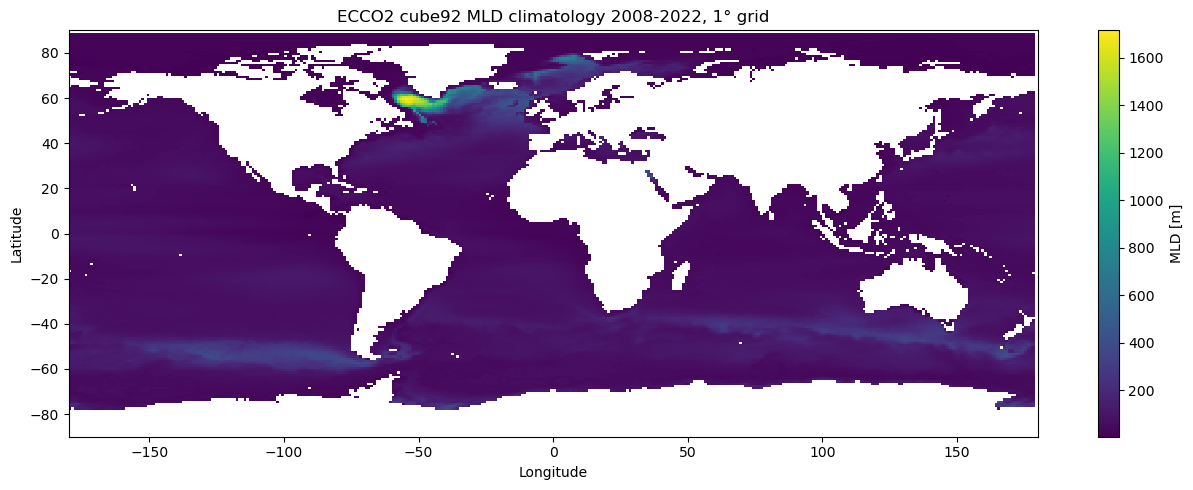


Cached 12 monthly MLD arrays in RAM
✅ Depth    22.5 dbar done
✅ Depth    27.5 dbar done
✅ Depth    52.5 dbar done
✅ Depth    77.5 dbar done
✅ Depth   102.5 dbar done
✅ Depth   127.5 dbar done
✅ Depth   152.5 dbar done
✅ Depth   177.5 dbar done
✅ Depth   202.5 dbar done
✅ Depth   227.5 dbar done
✅ Depth   252.5 dbar done
✅ Depth   277.5 dbar done
✅ Depth   302.5 dbar done
✅ Depth   327.5 dbar done
✅ Depth   352.5 dbar done
✅ Depth   377.5 dbar done
✅ Depth   402.5 dbar done
✅ Depth   427.5 dbar done
✅ Depth   452.5 dbar done
✅ Depth   477.5 dbar done
✅ Depth   502.5 dbar done
✅ Depth   527.5 dbar done
✅ Depth   552.5 dbar done
✅ Depth   577.5 dbar done
✅ Depth   602.5 dbar done
✅ Depth   627.5 dbar done
✅ Depth   652.5 dbar done
✅ Depth   677.5 dbar done
✅ Depth   702.5 dbar done
✅ Depth   727.5 dbar done
✅ Depth   752.5 dbar done
✅ Depth   777.5 dbar done
✅ Depth   802.5 dbar done
✅ Depth   827.5 dbar done
✅ Depth   852.5 dbar done
✅ Depth   877.5 dbar done
✅ Depth   902.5 dbar done
✅

In [23]:
"""
ECCO2 cube92 MLD → monthly climatology on the same 1° lat/lon grid
used for the beta/biovolume regridding.

ECCO2 cube92 is ~0.25° resolution (finer than the target 1° grid), so
stride subsampling is applied lazily before the load to keep the
remote OPeNDAP transfer small.

MLD has only (time, lat, lon) — no depth dim. When matched to the
beta/biovolume long table (which DOES have depth), the same MLD value
is attached to every depth at the same (month, lat, lon).
"""

import time
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Helpers
# ============================================================
def lon_0360_to_pm180(_ds):
    if (_ds['lon'].min() >= 0) and (_ds['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            _ds.coords['lon'] = xr.where(_ds['lon'] > 180,
                                          _ds['lon'] - 360, _ds['lon'])
        _ds = _ds.sortby('lon')
    return _ds


def load_with_retry(da, max_tries=5, base_delay=5.0):
    """Try .load() with exponential backoff on RuntimeError."""
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  load attempt {attempt}/{max_tries} ...", flush=True)
            out = da.load()
            print(f"  ✅ loaded on attempt {attempt}")
            return out
        except RuntimeError as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:200]}")
            if attempt == max_tries:
                raise
            sleep = base_delay * (2 ** (attempt - 1))
            print(f"  sleeping {sleep:.1f}s before retry...")
            time.sleep(sleep)


# ============================================================
# 2) Target 1° grid (same as beta/biovolume code)
# ============================================================
LAT_RES, LON_RES = 1.0, 1.0
lat_edges  = np.arange(-90,  90  + LAT_RES, LAT_RES)
lon_edges  = np.arange(-180, 180 + LON_RES, LON_RES)
target_lat = 0.5 * (lat_edges[:-1] + lat_edges[1:])
target_lon = 0.5 * (lon_edges[:-1] + lon_edges[1:])
print(f"Target grid: {len(target_lat)} lat × {len(target_lon)} lon  "
      f"({LAT_RES}° resolution)")


# ============================================================
# 3) Open ECCO2 cube92 monthly MLD
# ============================================================
print("\nOpening ECCO2 cube92 MLD OPeNDAP connection...")
ds_mld_raw = xr.open_dataset(
    'http://apdrc.soest.hawaii.edu:80/dods/public_data/ECCO/ECCO2/cube92_monthly/mxldepth',
    engine='netcdf4',
)
ds_mld_raw = lon_0360_to_pm180(ds_mld_raw)

mld_var = next(v for v in ds_mld_raw.data_vars
               if v.lower() in ('mxldepth', 'mld', 'mixed_layer_depth'))
print(f"Using MLD variable: '{mld_var}'")

# Subset time (lazy)
ds_mld_raw = ds_mld_raw.sel(time=slice('2008-01-01', '2022-12-31'))
print(f"After time subset (lazy): shape = {ds_mld_raw[mld_var].shape}")


# ============================================================
# 4) Stride subsample (lazy) to match target 1° resolution
#    — ECCO2 cube92 is ~0.25°, so stride ~4
# ============================================================
ecco_dlat = float(np.abs(np.diff(ds_mld_raw['lat'].values[:2]))[0])
ecco_dlon = float(np.abs(np.diff(ds_mld_raw['lon'].values[:2]))[0])
stride_lat = max(1, int(round(LAT_RES / ecco_dlat)))
stride_lon = max(1, int(round(LON_RES / ecco_dlon)))
print(f"\nECCO2 Δ ≈ {ecco_dlat:.3f}° → strides lat={stride_lat}, lon={stride_lon}")

mld_coarse = ds_mld_raw[mld_var].isel(
    lat=slice(None, None, stride_lat),
    lon=slice(None, None, stride_lon),
)
print(f"After spatial stride (lazy): shape = {mld_coarse.shape}")


# ============================================================
# 5) Monthly climatology (lazy) → load → final regrid to target grid
# ============================================================
mld_clim_native = (mld_coarse
                   .groupby('time.month')
                   .mean('time', skipna=True))
print(f"Climatology shape (lazy, coarse): {mld_clim_native.shape}")

print("\nLoading climatology from OPeNDAP...")
mld_clim_native = load_with_retry(mld_clim_native, max_tries=5)

print("\nInterpolating onto target 1° grid...")
mld = mld_clim_native.interp(
    lat=xr.DataArray(target_lat, dims="lat"),
    lon=xr.DataArray(target_lon, dims="lon"),
    method="nearest",
).load()

mld.name = "mld"
mld.attrs["long_name"] = "ECCO2 cube92 mixed-layer depth, monthly climatology, 1° grid"
mld.attrs["units"]     = "m"
print(f"✅ MLD on target grid: {mld.shape}  dims={dict(mld.sizes)}")

outfile = 'ecco2_mld_clim_2008_2022_1deg.nc'
mld.to_netcdf(outfile)
print(f"Saved {outfile}")


# ============================================================
# 5) Quick plot
# ============================================================
mld_mean = mld.mean('month', skipna=True)
plt.figure(figsize=(13, 5))
mld_mean.plot(x='lon', y='lat', cmap='viridis',
              cbar_kwargs={'label': 'MLD [m]'})
plt.title('ECCO2 cube92 MLD climatology 2008-2022, 1° grid')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()


# ============================================================
# 6) Cache monthly arrays for the matching loop
# ============================================================
mld_lat = mld['lat'].values.astype(np.float64)
mld_lon = mld['lon'].values.astype(np.float64)
mld_by_month = {int(m): mld.sel(month=m).values
                for m in mld['month'].values}
print(f"\nCached {len(mld_by_month)} monthly MLD arrays in RAM")


# ============================================================
# 7) Extract MLD at each (depth, month, lat, lon) of the
#    beta/biovolume long table
#
# MLD has no depth dim — the same surface MLD is broadcast to every
# depth at the same (month, lat, lon).
# ============================================================
def extract_mld_for_depth_month(p, m, df_valid_selected):
    df_sub = df_valid_selected[
        np.isclose(df_valid_selected["Pressure_dbar"], p)
        & (df_valid_selected["Month"] == m)
    ]
    if df_sub.empty:
        return None, None

    mld_data = mld_by_month[int(m)]
    lat_vals = df_sub["Latitude"].to_numpy(dtype=np.float64)
    lon_vals = df_sub["Longitude"].to_numpy(dtype=np.float64)

    lat_idx = np.abs(mld_lat[:, None] - lat_vals[None, :]).argmin(axis=0)
    lon_idx = np.abs(mld_lon[:, None] - lon_vals[None, :]).argmin(axis=0)

    valid_mask = np.zeros(mld_data.shape, dtype=bool)
    valid_mask[lat_idx, lon_idx] = True
    finite_mld_mask = np.isfinite(mld_data)

    valid_mask   = valid_mask & finite_mld_mask
    missing_mask = (~valid_mask) & finite_mld_mask

    lat2d, lon2d = np.meshgrid(mld_lat, mld_lon, indexing='ij')

    df_valid = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[valid_mask],
        "Longitude": lon2d[valid_mask],
        "MLD":       mld_data[valid_mask],
    })
    df_missing = pd.DataFrame({
        "Pressure_dbar": p, "Month": m,
        "Latitude":  lat2d[missing_mask],
        "Longitude": lon2d[missing_mask],
        "MLD":       mld_data[missing_mask],
    })
    return df_valid, df_missing


# ============================================================
# 8) Loop over (pressure × month)
# ============================================================
depths = sorted(df_valid_selected["Pressure_dbar"].dropna().unique())
months = sorted(df_valid_selected["Month"].dropna().unique())

valid_records, missing_records = [], []
for p in depths:
    for m in months:
        df_v, df_m = extract_mld_for_depth_month(p, m, df_valid_selected)
        if df_v is None:
            continue
        valid_records.append(df_v)
        missing_records.append(df_m)
    print(f"✅ Depth {p:7.1f} dbar done")

if not valid_records:
    raise ValueError("No valid MLD records extracted.")

df_mld_valid   = pd.concat(valid_records,   ignore_index=True)
df_mld_missing = pd.concat(missing_records, ignore_index=True)

print("\n✅ Combined MLD results:")
print(f"   MLD where beta valid:   {df_mld_valid.shape}")
print(f"   MLD where beta missing: {df_mld_missing.shape}")
print("\nValid MLD statistics:")
print(df_mld_valid["MLD"].describe())


# ============================================================
# 9) Convert to xarray
# ============================================================
ds_mld_valid = (df_mld_valid
                .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                .to_xarray())
ds_mld_missing = (df_mld_missing
                  .set_index(["Pressure_dbar", "Month", "Latitude", "Longitude"])
                  .to_xarray())

print("\nxarray dims MLD valid:",   dict(ds_mld_valid.sizes))
print("xarray dims MLD missing:", dict(ds_mld_missing.sizes))

In [24]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (MLD)...")

# Step 1: aggregate to per-depth yearly totals
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with most valid cells
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# Step 3: subset both MLD datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_mld_valid_best   = ds_mld_valid.sel(Pressure_dbar=selected_da, method="nearest")
ds_mld_missing_best = ds_mld_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset MLD datasets:")
print("   valid:  ", dict(ds_mld_valid_best.dims))
print("   missing:", dict(ds_mld_missing_best.dims))


🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (MLD)...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-272.5   

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3359938557.py:50: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_mld_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3359938557.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_mld_missing_best.dims))


Reference grid from ds_o2_missing: 168 lat x 360 lon

Loading etopo2_bath_1deg.nc
  dims: {'lat': 180, 'lon': 360}

Bathymetry field (180, 360): min=-7477 m, max=5411 m, finite=64,261
  65% of cells are negative -> ocean depths are negative (elevation convention)
  grid identical to the O2 reference: False
  !! different grid — delete etopo2_bath_1deg.nc and rerun


/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/xarray/coding/times.py:383: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/1186763831.py:123: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  bath = xr.open_dataarray(BATH_FILE)


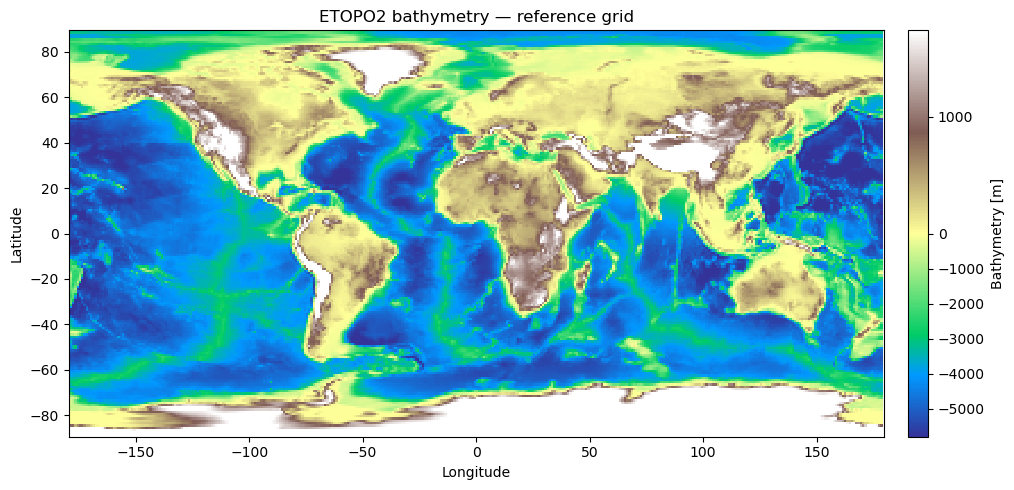

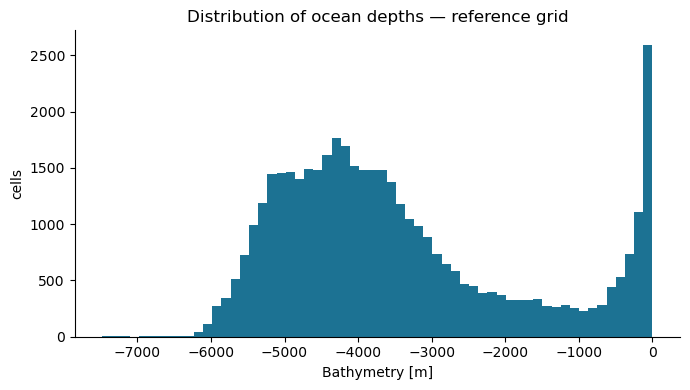


✅ Bathymetry attached to 192,844 rows: 192,693 finite (99.9%), 151 missing
   max snap distance: 0.000° lat, 0.000° lon
   rows deeper than the local seafloor: 15,323 (7.9%)  <- check the sign convention or the coarsening

Valid Bathymetry statistics:
count    192693.000000
mean      -3748.356689
std        1375.889526
min       -6666.877930
25%       -4754.622070
50%       -4095.315674
75%       -2960.177734
max        2036.205566
Name: Bathymetry, dtype: float64

Building bathymetry cubes shaped like the O2 cubes ...
  valid cube (241, 12, 148, 278) = 118,988,448 cells (476 MB)
    filled 192,844 rows, 192,634 finite cells
  missing cube (241, 12, 168, 360) = 174,908,160 cells (700 MB)
    depth 241/241
    108,754,563 finite cells

ds_bath_valid  : {'Pressure_dbar': 241, 'Month': 12, 'Latitude': 148, 'Longitude': 278}
ds_bath_missing: {'Pressure_dbar': 241, 'Month': 12, 'Latitude': 168, 'Longitude': 360}
✅ shapes match the O2 cubes


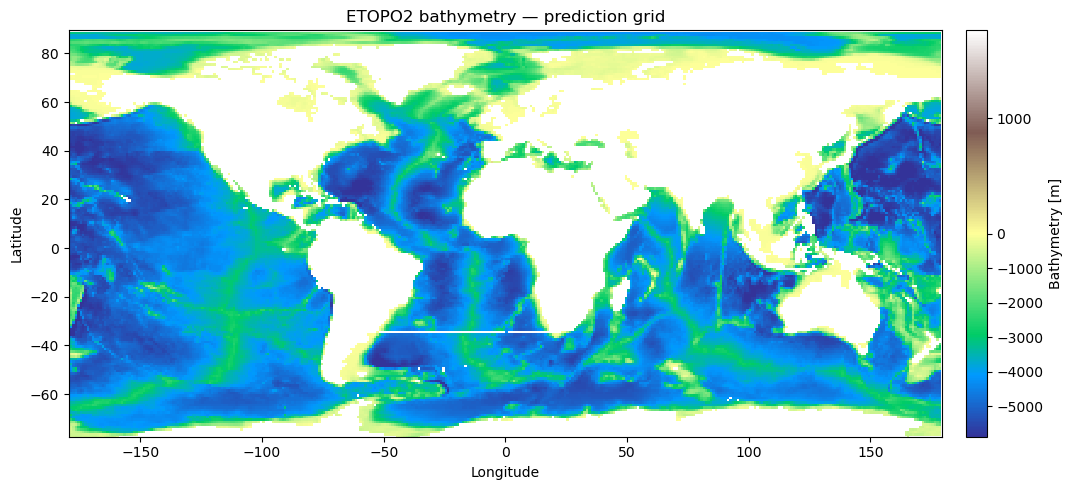

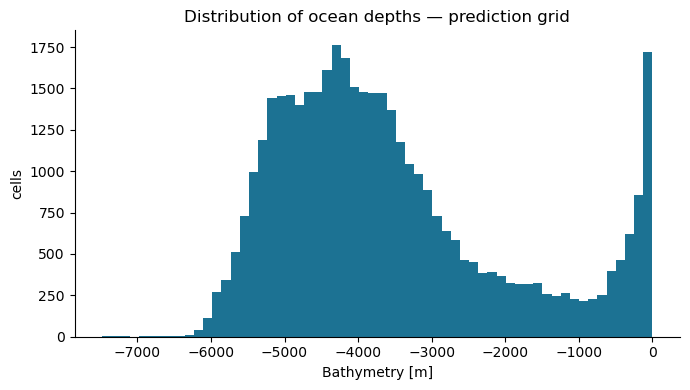

In [25]:
"""
===========================================================================
ETOPO2 bathymetry  →  1 deg grid  →  training table  →  depth cubes
===========================================================================
Source: APDRC, public_data/topography/ETOPO2/etopo2

Produces
--------
    bath             (lat, lon)   single 2-D field on the reference grid
    df_train         training table with a "Bathymetry" column
    ds_bath_valid    (Pressure_dbar, Month, Latitude, Longitude)  observed
    ds_bath_missing  (Pressure_dbar, Month, Latitude, Longitude)  prediction
    + two figures

Why this differs from the previous version
------------------------------------------
Bathymetry has NO time and NO depth dimension: it is one 2-D field. The
old cell built a DataFrame for every (depth, month) pair from the full
grid, so df_bath_missing grew to 241 x 12 x ~50,000 rows -- the same 2-D
field written 2,892 times as a long table -- and set_index(...).to_xarray()
on that is what crashed the kernel.

Here:
  * the field is looked up per observation row with searchsorted
    (O(n_rows) memory, no n_grid x n_rows distance matrix);
  * the cubes are allocated once and written slice by slice;
  * the grid is taken from the O2 cubes so everything lines up by
    construction.

Needs in the namespace
----------------------
    df_valid_selected              Pressure_dbar, Month, Latitude, Longitude
    ds_o2_valid, ds_o2_missing     optional: grid reference and cube shapes
===========================================================================
"""

import os
import time as _time

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

ETOPO_URL = ("http://apdrc.soest.hawaii.edu:80/dods/public_data/"
             "topography/ETOPO2/etopo2")
LAT_RES = LON_RES = 1.0
DTYPE = np.float32
BATH_FILE = "etopo2_bath_1deg.nc"
FORCE_REFETCH = False
SAVE_NETCDF = False          # True to write the depth cubes (needs netcdf4
                             # for compression; uncompressed is ~1.2 GB)


# ============================================================
# 1) Helpers
# ============================================================
def lon_0360_to_pm180(obj):
    if (obj['lon'].min() >= 0) and (obj['lon'].max() <= 360):
        with xr.set_options(keep_attrs=True):
            obj.coords['lon'] = xr.where(obj['lon'] > 180,
                                         obj['lon'] - 360, obj['lon'])
        obj = obj.sortby('lon')
    return obj


def load_with_retry(da, max_tries=5, base_delay=5.0):
    for attempt in range(1, max_tries + 1):
        try:
            print(f"  load attempt {attempt}/{max_tries} ...", flush=True)
            out = da.load()
            print(f"  ✅ loaded on attempt {attempt}")
            return out
        except (RuntimeError, OSError) as e:
            print(f"  ⚠ attempt {attempt} failed: {str(e)[:200]}")
            if attempt == max_tries:
                raise
            _time.sleep(base_delay * (2 ** (attempt - 1)))


def nearest_index(grid, values):
    """Nearest grid index per value. O(len(values)) memory."""
    grid = np.asarray(grid, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    pos = np.clip(np.searchsorted(grid, values), 1, grid.size - 1)
    left, right = grid[pos - 1], grid[pos]
    return np.where(values - left <= right - values,
                    pos - 1, pos).astype(np.int32)


# ============================================================
# 2) Reference grid — from the O2 cubes when available
# ============================================================
if 'ds_o2_missing' in globals():
    REF_LAT = np.asarray(ds_o2_missing['Latitude'].values, dtype=np.float64)
    REF_LON = np.asarray(ds_o2_missing['Longitude'].values, dtype=np.float64)
    _grid_src = 'ds_o2_missing'
elif 'ds_o2_valid' in globals():
    REF_LAT = np.asarray(ds_o2_valid['Latitude'].values, dtype=np.float64)
    REF_LON = np.asarray(ds_o2_valid['Longitude'].values, dtype=np.float64)
    _grid_src = 'ds_o2_valid'
else:
    _le = np.arange(-90, 90 + LAT_RES, LAT_RES)
    _oe = np.arange(-180, 180 + LON_RES, LON_RES)
    REF_LAT = 0.5 * (_le[:-1] + _le[1:])
    REF_LON = 0.5 * (_oe[:-1] + _oe[1:])
    _grid_src = 'grid definition'

print(f"Reference grid from {_grid_src}: "
      f"{REF_LAT.size} lat x {REF_LON.size} lon")


# ============================================================
# 3) Bathymetry field: memory, disk, or download
# ============================================================
if 'bath' in globals() and not FORCE_REFETCH:
    print("\nUsing 'bath' already in memory")

elif os.path.exists(BATH_FILE) and not FORCE_REFETCH:
    print(f"\nLoading {BATH_FILE}")
    try:
        bath = xr.open_dataarray(BATH_FILE)
    except ValueError:
        _dsf = xr.open_dataset(BATH_FILE)
        bath = _dsf[list(_dsf.data_vars)[0]]
    print(f"  dims: {dict(bath.sizes)}")

else:
    print(f"\nOpening ETOPO2 ...\n  {ETOPO_URL}")
    ds_etopo = xr.open_dataset(ETOPO_URL)
    print(f"  variables: {list(ds_etopo.data_vars)}")
    print(f"  dims     : {dict(ds_etopo.sizes)}")
    ds_etopo = lon_0360_to_pm180(ds_etopo)

    bath_var = next(v for v in ds_etopo.data_vars
                    if v.lower() in ('b_bathy', 'bathy', 'bathymetry',
                                     'depth', 'z', 'elevation', 'topo'))
    print(f"  using variable: '{bath_var}'")

    da = ds_etopo[bath_var].squeeze()
    if 'time' in da.dims:                       # singleton time, defensively
        da = da.isel(time=0, drop=True)

    # coarsen to ~1 deg: an average, not a single 2-arcmin pixel
    dlat = float(abs(np.diff(da['lat'].values[:2])[0]))
    c_lat = max(1, int(round(LAT_RES / dlat)))
    c_lon = max(1, int(round(LON_RES / dlat)))
    print(f"  native {dlat:.4f} deg -> coarsen {c_lat} x {c_lon}")
    da = da.coarsen(lat=c_lat, lon=c_lon, boundary='trim').mean()
    print(f"  coarse shape (lazy): {da.shape}")

    da = load_with_retry(da, max_tries=5)

    print("\nInterpolating onto the reference grid ...")
    bath = da.interp(lat=xr.DataArray(REF_LAT, dims="lat"),
                     lon=xr.DataArray(REF_LON, dims="lon"),
                     method="nearest").load()
    bath.name = "bathymetry"
    bath.attrs.update(long_name="ETOPO2 bathymetry on the reference grid",
                      units="m", source=ETOPO_URL)
    bath.to_netcdf(BATH_FILE)
    print(f"  saved {BATH_FILE}")


# ============================================================
# 4) Cache arrays, check the grid, check the sign convention
# ============================================================
_latn = 'lat' if 'lat' in bath.coords else 'Latitude'
_lonn = 'lon' if 'lon' in bath.coords else 'Longitude'
bath_lat = np.asarray(bath[_latn].values, dtype=np.float64)
bath_lon = np.asarray(bath[_lonn].values, dtype=np.float64)
bath_2d = np.asarray(bath.values, dtype=DTYPE)             # (ny, nx)

print(f"\nBathymetry field {bath_2d.shape}: "
      f"min={np.nanmin(bath_2d):.0f} m, max={np.nanmax(bath_2d):.0f} m, "
      f"finite={int(np.isfinite(bath_2d).sum()):,}")
_neg = np.nanmean(bath_2d < 0)
print(f"  {100 * _neg:.0f}% of cells are negative -> "
      f"{'ocean depths are negative (elevation convention)' if _neg > 0.5 else 'ocean depths are positive'}")

if 'ds_o2_missing' in globals():
    same = (np.array_equal(bath_lat, REF_LAT) and
            np.array_equal(bath_lon, REF_LON))
    print(f"  grid identical to the O2 reference: {same}")
    if not same:
        print(f"  !! different grid — delete {BATH_FILE} and rerun")


# ============================================================
# 5) Plots
# ============================================================
def plot_bathymetry(field, lat, lon, tag, what, save=True, show=True):
    field = np.asarray(field, dtype=np.float64)
    finite = field[np.isfinite(field)]
    if finite.size == 0:
        print(f"  {tag}: no finite values")
        return
    vmax = np.nanpercentile(np.abs(finite), 99)

    fig, ax = plt.subplots(figsize=(13, 5))
    im = ax.pcolormesh(lon, lat, field, cmap="terrain",
                       norm=colors.TwoSlopeNorm(vmin=-vmax, vcenter=0,
                                                vmax=max(vmax * 0.3, 1)),
                       shading="nearest")
    plt.colorbar(im, ax=ax, label="Bathymetry [m]", fraction=0.03, pad=0.02)
    ax.set_xlim(lon.min(), lon.max()); ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"ETOPO2 bathymetry — {what}")
    plt.tight_layout()
    if save:
        plt.savefig(f"{tag}_map.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    # depth histogram: where the observations sit relative to the seafloor
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(finite[finite < 0], bins=60, color="#1C7293")
    ax.set_xlabel("Bathymetry [m]"); ax.set_ylabel("cells")
    ax.set_title(f"Distribution of ocean depths — {what}")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    if save:
        plt.savefig(f"{tag}_hist.png", dpi=150, bbox_inches="tight")
    plt.show() if show else plt.close(fig)


plot_bathymetry(bath_2d, bath_lat, bath_lon, "bath", "reference grid")


# ============================================================
# 6) Attach to the training table (one value per row)
# ============================================================
_lat = df_valid_selected["Latitude"].to_numpy(dtype=np.float64)
_lon = df_valid_selected["Longitude"].to_numpy(dtype=np.float64)

lat_idx = nearest_index(bath_lat, _lat)
lon_idx = nearest_index(bath_lon, _lon)

df_train = df_train if 'df_train' in globals() else df_valid_selected.copy()
df_train["Bathymetry"] = bath_2d[lat_idx, lon_idx]

_fin = np.isfinite(df_train["Bathymetry"].to_numpy())
print(f"\n✅ Bathymetry attached to {len(df_train):,} rows: "
      f"{_fin.sum():,} finite ({100 * _fin.mean():.1f}%), "
      f"{(~_fin).sum():,} missing")
print(f"   max snap distance: {np.abs(bath_lat[lat_idx] - _lat).max():.3f}° lat, "
      f"{np.abs(bath_lon[lon_idx] - _lon).max():.3f}° lon")

# sanity: observations should not sit below the seafloor
if _fin.any() and "Pressure_dbar" in df_train:
    _depth = df_train["Pressure_dbar"].to_numpy()
    _floor = np.abs(df_train["Bathymetry"].to_numpy())
    _below = _fin & (_depth > _floor)
    print(f"   rows deeper than the local seafloor: {int(_below.sum()):,} "
          f"({100 * _below.mean():.1f}%)"
          f"{'  <- check the sign convention or the coarsening' if _below.mean() > 0.05 else ''}")

print("\nValid Bathymetry statistics:")
print(df_train["Bathymetry"].describe())


# ============================================================
# 7) Depth cubes shaped like the O2 cubes
#
# Bathymetry has neither depth nor month, so every one of the 241 x 12
# slices is the same 2-D field. Allocated once, written slice by slice.
# ============================================================
def _ref_coords(ref):
    return (ref["Pressure_dbar"].values, ref["Month"].values,
            np.asarray(ref["Latitude"].values, dtype=np.float64),
            np.asarray(ref["Longitude"].values, dtype=np.float64))


def bath_cube_like_valid(ref_valid, df_rows, verbose=True):
    """Bathymetry on the reference VALID cube, only at observed rows."""
    depths, months, lat, lon = _ref_coords(ref_valid)
    shape = (depths.size, months.size, lat.size, lon.size)
    if verbose:
        print(f"  valid cube {shape} = {np.prod(shape):,} cells "
              f"({np.prod(shape) * np.dtype(DTYPE).itemsize / 1e6:.0f} MB)")

    out = np.full(shape, np.nan, dtype=DTYPE)
    d_pos = {float(v): i for i, v in enumerate(depths)}
    m_pos = {int(v): i for i, v in enumerate(months)}
    di = df_rows["Pressure_dbar"].astype(float).map(d_pos).to_numpy()
    mi = df_rows["Month"].astype(int).map(m_pos).to_numpy()
    la = nearest_index(lat, df_rows["Latitude"].to_numpy())
    lo = nearest_index(lon, df_rows["Longitude"].to_numpy())

    src_la = nearest_index(bath_lat, df_rows["Latitude"].to_numpy())
    src_lo = nearest_index(bath_lon, df_rows["Longitude"].to_numpy())
    vals = bath_2d[src_la, src_lo]

    ok = np.isfinite(di) & np.isfinite(mi)
    out[di[ok].astype(int), mi[ok].astype(int), la[ok], lo[ok]] = vals[ok]
    if verbose:
        print(f"    filled {int(ok.sum()):,} rows, "
              f"{int(np.isfinite(out).sum()):,} finite cells")

    return xr.Dataset(
        {"Bathymetry": (("Pressure_dbar", "Month", "Latitude", "Longitude"),
                        out)},
        coords={"Pressure_dbar": depths, "Month": months,
                "Latitude": lat, "Longitude": lon},
        attrs={"units": "m",
               "description": "ETOPO2 bathymetry at cells where "
                              "beta/biovolume is observed",
               "note": "time- and depth-invariant: all slices identical"})


def bath_cube_like_missing(ref_missing, verbose=True):
    """Bathymetry on the reference MISSING cube, mask copied from it."""
    depths, months, lat, lon = _ref_coords(ref_missing)
    shape = (depths.size, months.size, lat.size, lon.size)
    if verbose:
        print(f"  missing cube {shape} = {np.prod(shape):,} cells "
              f"({np.prod(shape) * np.dtype(DTYPE).itemsize / 1e6:.0f} MB)")

    ref_da = ref_missing[list(ref_missing.data_vars)[0]]
    la = nearest_index(bath_lat, lat)
    lo = nearest_index(bath_lon, lon)
    surf = bath_2d[np.ix_(la, lo)].astype(DTYPE)            # (ny, nx)

    out = np.full(shape, np.nan, dtype=DTYPE)
    for d in range(depths.size):
        ref_slice = np.asarray(ref_da[d].values)            # (12, ny, nx)
        for m in range(months.size):
            np.copyto(out[d, m], surf, where=np.isfinite(ref_slice[m]))
        if verbose and (d % 60 == 0 or d == depths.size - 1):
            print(f"    depth {d + 1}/{depths.size}", end="\r")
    if verbose:
        print(f"\n    {int(np.isfinite(out).sum()):,} finite cells")

    return xr.Dataset(
        {"Bathymetry": (("Pressure_dbar", "Month", "Latitude", "Longitude"),
                        out)},
        coords={"Pressure_dbar": depths, "Month": months,
                "Latitude": lat, "Longitude": lon},
        attrs={"units": "m",
               "description": "ETOPO2 bathymetry on the prediction grid "
                              "(mask copied from the reference cube)",
               "note": "time- and depth-invariant: all slices identical"})


if 'ds_o2_valid' in globals() and 'ds_o2_missing' in globals():
    print("\nBuilding bathymetry cubes shaped like the O2 cubes ...")
    ds_bath_valid = bath_cube_like_valid(ds_o2_valid, df_valid_selected)
    ds_bath_missing = bath_cube_like_missing(ds_o2_missing)

    print("\nds_bath_valid  :", dict(ds_bath_valid.sizes))
    print("ds_bath_missing:", dict(ds_bath_missing.sizes))
    assert ds_bath_valid.sizes == ds_o2_valid.sizes, "valid shape differs"
    assert ds_bath_missing.sizes == ds_o2_missing.sizes, "missing shape differs"
    print("✅ shapes match the O2 cubes")

    plot_bathymetry(ds_bath_missing["Bathymetry"].isel(Pressure_dbar=0,
                                                       Month=0).values,
                    ds_bath_missing["Latitude"].values,
                    ds_bath_missing["Longitude"].values,
                    "bath_missing", "prediction grid")

    if SAVE_NETCDF:
        enc = {"Bathymetry": {"zlib": True, "complevel": 4}}
        for name, dsx in [("bath_valid_depth.nc", ds_bath_valid),
                          ("bath_missing_depth.nc", ds_bath_missing)]:
            try:
                dsx.to_netcdf(name, engine="netcdf4", encoding=enc)
            except (ValueError, ImportError):
                dsx.to_netcdf(name)
                print(f"  (no netcdf4 engine — {name} uncompressed)")
        print("\nsaved bath_valid_depth.nc and bath_missing_depth.nc")
else:
    print("\nds_o2_valid / ds_o2_missing not found — cubes skipped. "
          "bath and df_train['Bathymetry'] are ready.")

In [26]:
import numpy as np
import pandas as pd
import xarray as xr

print("\n🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (Bathymetry)...")

# Step 1: aggregate to per-depth yearly totals
if 'df_counts' in dir():
    df_counts_yearly = (df_counts.groupby("Pressure_dbar")["Valid_points"]
                                  .sum().reset_index()
                                  .rename(columns={"Valid_points": "Valid_yr"})
                                  .sort_values("Pressure_dbar")
                                  .reset_index(drop=True))
else:
    df_counts_yearly = (df_valid_selected.groupby("Pressure_dbar").size()
                                          .reset_index(name="Valid_yr")
                                          .sort_values("Pressure_dbar")
                                          .reset_index(drop=True))

# Step 2: bin every 3 depth levels, pick the one with most valid cells
bin_size = 5
selected_depths = []
block_info = []
for start in range(0, len(df_counts_yearly), bin_size):
    block = df_counts_yearly.iloc[start:start + bin_size]
    if block.empty:
        continue
    best = block.loc[block["Valid_yr"].idxmax()]
    selected_depths.append(float(best["Pressure_dbar"]))
    block_info.append((float(block["Pressure_dbar"].min()),
                       float(block["Pressure_dbar"].max()),
                       float(best["Pressure_dbar"]),
                       int(best["Valid_yr"])))

print(f"✅ Selected {len(selected_depths)} representative levels "
      f"out of {len(df_counts_yearly)} total\n")
print(f"{'Block':<8}{'Depth Range (dbar)':<25}{'Selected (dbar)':<20}{'Yearly valid':<15}")
print("-" * 70)
for i, (b_lo, b_hi, d, c) in enumerate(block_info, start=1):
    print(f"{i:<8}{f'{b_lo:.1f}-{b_hi:.1f}':<25}{f'{d:.1f}':<20}{c:<15}")


# Step 3: subset both bathymetry datasets at the selected depths
selected_da = xr.DataArray(selected_depths, dims="Pressure_dbar")

ds_bath_valid_best   = ds_bath_valid.sel(Pressure_dbar=selected_da, method="nearest")
ds_bath_missing_best = ds_bath_missing.sel(Pressure_dbar=selected_da, method="nearest")

print("\n✅ Subset Bathymetry datasets:")
print("   valid:  ", dict(ds_bath_valid_best.dims))
print("   missing:", dict(ds_bath_missing_best.dims))


🔍 Selecting best depth level (max valid data across the year) in each 3-level bin (Bathymetry)...
✅ Selected 241 representative levels out of 1204 total

Block   Depth Range (dbar)       Selected (dbar)     Yearly valid   
----------------------------------------------------------------------
1       2.5-22.5                 22.5                2353           
2       27.5-47.5                27.5                2353           
3       52.5-72.5                52.5                2306           
4       77.5-97.5                77.5                2275           
5       102.5-122.5              102.5               2247           
6       127.5-147.5              127.5               2208           
7       152.5-172.5              152.5               2190           
8       177.5-197.5              177.5               2175           
9       202.5-222.5              202.5               2141           
10      227.5-247.5              227.5               2111           
11      252.5-2

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3755391929.py:50: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   valid:  ", dict(ds_bath_valid_best.dims))
/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_78504/3755391929.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("   missing:", dict(ds_bath_missing_best.dims))


In [27]:
"""
Build per-depth (X, y) .mat files for the ML pipeline, with proper
cross-variable grid alignment.

The bug in the previous version: each ds_X_valid_best was built
independently from its own dataframe via .set_index(...).to_xarray(),
which means each variable's (Latitude, Longitude) coordinate set
depends on where THAT variable had non-NaN values. MLD might end up
on 148×278, Chl on 151×285, Bathymetry on something else again. They
look the same superficially but their coord sets are different.

The fix: reindex_like(ds_beta_valid_selected) on every env variable.
This forces them onto beta's exact (Pressure_dbar, Month, Latitude,
Longitude) grid, filling NaN where the source dataset had no value.
After this, all variables share the same shape and the .reshape(N_FLAT)
works.

Month encoding: calendar month m is replaced by sin(2π m/12) and
cos(2π m/12) to avoid the artificial discontinuity between December
(m=12) and January (m=1) that arises when month is treated as a
plain integer.
"""

import numpy as np
import xarray as xr
from scipy import io


# ============================================================
# 0) Diagnose shape mismatches
# ============================================================
SOURCES = {
    'po4':       (ds_po4_valid_best,            'PO4'),
    'no3':       (ds_no3_valid_best,            'NO3'),
    'temp':      (ds_temp_valid_best,           'TEMP'),
    'salt':      (ds_salt_valid_best,           'Salinity'),
    'o2':        (ds_o2_valid_best,             'O2'),
    'chl':       (ds_chl_valid_best,            'Chl'),
    'mld':       (ds_mld_valid_best,            'MLD'),
    'bath':      (ds_bath_valid_best,           'Bathymetry'),
    'thflx':     (ds_thflx_valid_best,          'Thflx'),
    'npp':       (ds_npp_valid_best,            'NPP'),
    'biovolume': (ds_biovolume_valid_selected,  'Biovolume'),
    'beta':      (ds_beta_valid_selected,       'Beta_slope'),
}

ref_da = ds_beta_valid_selected['Beta_slope']
print("Shape audit — target is beta's shape:")
print(f"  REFERENCE (beta): dims={dict(ref_da.sizes)}, total={int(ref_da.size)}")
for key, (ds_env, var) in SOURCES.items():
    da = ds_env[var]
    same = (dict(da.sizes) == dict(ref_da.sizes))
    flag = "✅" if same else "❌ MISMATCH"
    print(f"  {key:10s}: dims={dict(da.sizes)}, total={int(da.size)}   {flag}")


# ============================================================
# 1) Reindex every variable onto beta's exact grid
# ============================================================
print("\nReindexing every env variable onto beta's grid...")
SOURCES_ALIGNED = {}
for key, (ds_env, var) in SOURCES.items():
    da = ds_env[var]
    if dict(da.sizes) == dict(ref_da.sizes):
        SOURCES_ALIGNED[key] = (ds_env, var)
        print(f"  {key:10s}: already aligned")
    else:
        da_aligned = da.reindex_like(ref_da)
        ds_aligned = da_aligned.to_dataset(name=var)
        SOURCES_ALIGNED[key] = (ds_aligned, var)
        print(f"  {key:10s}: reindexed → dims={dict(da_aligned.sizes)}")

print("\nPost-reindex audit:")
for key, (ds_env, var) in SOURCES_ALIGNED.items():
    da = ds_env[var]
    same = (dict(da.sizes) == dict(ref_da.sizes))
    flag = "✅" if same else "❌ STILL MISMATCHED"
    print(f"  {key:10s}: dims={dict(da.sizes)}   {flag}")


# ============================================================
# 2) Per-depth flattening + saving
# ============================================================
ref_sizes = dict(ref_da.sizes)
N_DEPTHS  = ref_sizes['Pressure_dbar']
N_FLAT    = ref_sizes['Month'] * ref_sizes['Latitude'] * ref_sizes['Longitude']
print(f"\nN_DEPTHS = {N_DEPTHS}, N_FLAT = {N_FLAT} "
      f"(= {ref_sizes['Month']} × {ref_sizes['Latitude']} × {ref_sizes['Longitude']})")

depth_values = ds_beta_valid_selected['Pressure_dbar'].values

A = {key: {} for key in list(SOURCES_ALIGNED.keys()) +
     ['lat', 'lon', 'month_sin', 'month_cos', 'depth']}

for i in range(N_DEPTHS):
    # Mask: cells where beta is valid at this depth
    beta_flat = (ds_beta_valid_selected['Beta_slope']
                 .isel(Pressure_dbar=i)
                 .values
                 .reshape(N_FLAT))
    keep = ~np.isnan(beta_flat)
    n_keep = keep.sum()

    # Strengthen the mask: also drop cells where ANY env variable is NaN
    for key, (ds_env, var) in SOURCES_ALIGNED.items():
        if key in ('beta', 'biovolume'):
            continue
        flat = ds_env[var].isel(Pressure_dbar=i).values.reshape(N_FLAT)
        keep &= ~np.isnan(flat)
    n_keep_after = keep.sum()
    if n_keep_after < n_keep:
        dropped = n_keep - n_keep_after
        if i % 20 == 0:
            print(f"  depth idx {i:3d}: beta_valid={n_keep:>6}, "
                  f"after env-NaN={n_keep_after:>6} "
                  f"(dropped {dropped} for missing env data)")

    # Apply the strengthened mask to every variable
    for key, (ds_env, var) in SOURCES_ALIGNED.items():
        flat = ds_env[var].isel(Pressure_dbar=i).values.reshape(N_FLAT)
        A[key][i] = flat[keep]

    # Coordinates
    beta_slice = ds_beta_valid_selected['Beta_slope'].isel(Pressure_dbar=i)
    month2d = (ds_beta_valid_selected['Month']
               .broadcast_like(beta_slice).values.reshape(N_FLAT))
    lat2d   = (ds_beta_valid_selected['Latitude']
               .broadcast_like(beta_slice).values.reshape(N_FLAT))
    lon2d   = (ds_beta_valid_selected['Longitude']
               .broadcast_like(beta_slice).values.reshape(N_FLAT))

    # Cyclic month encoding — replaces raw integer month with two
    # trigonometric features so that December and January are adjacent
    # in feature space rather than maximally separated.
    month_raw          = month2d[keep]
    A['month_sin'][i]  = np.sin(2 * np.pi * month_raw / 12)
    A['month_cos'][i]  = np.cos(2 * np.pi * month_raw / 12)
    A['lat'][i]        = lat2d[keep]
    A['lon'][i]        = lon2d[keep]
    A['depth'][i]      = np.full(n_keep_after, float(depth_values[i]))

print(f"\nBuilt A dicts for {N_DEPTHS} depth levels")
print(f"Example feature lengths at depth idx 0: {len(A['beta'][0])}")


# ============================================================
# 3) Save .mat files
# ============================================================
for i in range(N_DEPTHS):
    X_i = np.concatenate((
        A['no3'][i][:, np.newaxis],
        A['chl'][i][:, np.newaxis],
        A['bath'][i][:, np.newaxis],
        A['mld'][i][:, np.newaxis],
        A['salt'][i][:, np.newaxis],
        A['temp'][i][:, np.newaxis],
        A['o2'][i][:, np.newaxis],
        A['thflx'][i][:, np.newaxis],
        A['npp'][i][:, np.newaxis],
        A['depth'][i][:, np.newaxis],
        A['month_sin'][i][:, np.newaxis],
        A['month_cos'][i][:, np.newaxis],
    ), axis=1)

    y_i = np.concatenate((
        A['beta'][i][:, np.newaxis],
        A['biovolume'][i][:, np.newaxis],
    ), axis=1)

    io.savemat(f'data_X_Rf1_{i}.mat',         {'X':         X_i})
    io.savemat(f'data_y_Rf1_{i}.mat',         {'y':         y_i})
    io.savemat(f'data_lon_Rf1_{i}.mat',       {'lon':       A['lon'][i]})
    io.savemat(f'data_lat_Rf1_{i}.mat',       {'lat':       A['lat'][i]})
    io.savemat(f'data_month_sin_Rf1_{i}.mat', {'month_sin': A['month_sin'][i]})
    io.savemat(f'data_month_cos_Rf1_{i}.mat', {'month_cos': A['month_cos'][i]})
    io.savemat(f'data_depth_Rf1_{i}.mat',     {'depth':     A['depth'][i]})

print(f"\n✅ Saved {N_DEPTHS} .mat files per type")

# Document feature order for MATLAB
feature_names = ['NO3', 'Chl', 'Bathymetry', 'MLD', 'Salinity', 'TEMP',
                 'O2', 'Thflx', 'NPP', 'Depth', 'month_sin', 'month_cos']
io.savemat('feature_names.mat',
           {'feature_names': np.array(feature_names, dtype=object)})
print(f"Feature order: {feature_names}")
print(f"Total features: {len(feature_names)}")

Shape audit — target is beta's shape:
  REFERENCE (beta): dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 151, 'Longitude': 285}, total=124457220
  po4       : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 151, 'Longitude': 285}, total=124457220   ✅
  no3       : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 148, 'Longitude': 278}, total=118988448   ❌ MISMATCH
  temp      : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 150, 'Longitude': 280}, total=121464000   ❌ MISMATCH
  salt      : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 150, 'Longitude': 280}, total=121464000   ❌ MISMATCH
  o2        : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 148, 'Longitude': 278}, total=118988448   ❌ MISMATCH
  chl       : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 148, 'Longitude': 278}, total=118988448   ❌ MISMATCH
  mld       : dims={'Pressure_dbar': 241, 'Month': 12, 'Latitude': 150, 'Longitude': 280}, total=121464000   ❌ MISMATCH
  bath      : dims

In [1]:
"""
Build per-depth test-set .mat files (X only, no y) for predicting at
cells where beta is missing.

Why this differs from the previous version
------------------------------------------
The old cell filled A_test[key][i] for every depth BEFORE saving anything.
With N_FLAT = 12 x 168 x 360 = 725,760 and 15 arrays per depth in float64,
241 depths is 10-15 GB — that is the crash, and it happens in section 2,
not in the saving loop.

Here each depth is built, written and freed inside a single loop, so peak
memory is one depth's worth (~100 MB). Features are cast to float32, which
halves it again and is ample for GP inputs.

Also added:
  * depths with no valid cells are reported and skipped rather than
    written as 184-byte empty files;
  * a file-size audit at the end so a silent failure cannot pass again.
"""

import gc
import os
from glob import glob

import numpy as np
import xarray as xr
from scipy import io

SAVE_DTYPE = np.float32
OUT_DIR = "."                      # or a subfolder, created if missing


# ============================================================
# Reference dataset
# ============================================================
REF_DS = ds_beta_missing_selected
ref_da = REF_DS['Beta_slope']
ref_sizes = dict(ref_da.sizes)

N_DEPTHS = ref_sizes['Pressure_dbar']
N_FLAT = ref_sizes['Month'] * ref_sizes['Latitude'] * ref_sizes['Longitude']
depth_values = np.asarray(REF_DS['Pressure_dbar'].values, dtype=np.float64)

print("Reference (beta_missing):", ref_sizes, "total =", int(ref_da.size))
print(f"N_DEPTHS = {N_DEPTHS}, N_FLAT = {N_FLAT:,} "
      f"(= {ref_sizes['Month']} x {ref_sizes['Latitude']} x "
      f"{ref_sizes['Longitude']})")
print(f"peak memory per depth ~ "
      f"{15 * N_FLAT * np.dtype(SAVE_DTYPE).itemsize / 1e6:.0f} MB "
      f"(the old version held all {N_DEPTHS} depths at once)")

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# 0) Sources, in the feature order used for training
# ============================================================
SOURCES_TEST = {
    'po4':   (ds_po4_missing_best,   'PO4'),
    'no3':   (ds_no3_missing_best,   'NO3'),
    'temp':  (ds_temp_missing_best,  'TEMP'),
    'salt':  (ds_salt_missing_best,  'Salinity'),
    'o2':    (ds_o2_missing_best,    'O2'),
    'chl':   (ds_chl_missing_best,   'Chl'),
    'mld':   (ds_mld_missing_best,   'MLD'),
    'bath':  (ds_bath_missing_best,  'Bathymetry'),
    'thflx': (ds_thflx_missing_best, 'Thflx'),
    'npp':   (ds_npp_missing_best,   'NPP'),
}

FEATURE_ORDER = ['no3', 'chl', 'bath', 'mld', 'salt', 'temp',
                 'o2', 'thflx', 'npp']          # + depth, month_sin, month_cos

print("\nShape audit:")
for key, (ds_env, var) in SOURCES_TEST.items():
    da = ds_env[var]
    same = dict(da.sizes) == ref_sizes
    d_ok = np.array_equal(
        np.asarray(da['Pressure_dbar'].values, dtype=np.float64), depth_values)
    print(f"  {key:6s}: dims={dict(da.sizes)}  shape {'OK' if same else 'MISMATCH'}"
          f"  depth-coord {'OK' if d_ok else 'DIFFERS'}")


# ============================================================
# 1) Align onto the reference grid (kept as DataArrays, not copies)
# ============================================================
print("\nAligning onto the reference grid...")
ALIGNED = {}
for key, (ds_env, var) in SOURCES_TEST.items():
    da = ds_env[var]
    if dict(da.sizes) == ref_sizes and np.array_equal(
            np.asarray(da['Pressure_dbar'].values, dtype=np.float64),
            depth_values):
        ALIGNED[key] = da
        print(f"  {key:6s}: already aligned")
    else:
        d_src = np.asarray(da['Pressure_dbar'].values, dtype=np.float64)
        if d_src.size == depth_values.size and np.allclose(d_src, depth_values,
                                                           atol=1e-4):
            da = da.assign_coords(Pressure_dbar=depth_values)
            print(f"  {key:6s}: depth coord differed by rounding -> replaced")
        elif not np.array_equal(d_src, depth_values):
            da = da.interp(Pressure_dbar=depth_values, method="nearest")
            print(f"  {key:6s}: {d_src.size} depths -> {depth_values.size} "
                  f"(nearest)")
        da = da.reindex_like(ref_da)
        ALIGNED[key] = da
        print(f"           -> dims={dict(da.sizes)}")


# ============================================================
# 2+3) Build, save and free — one depth at a time
# ============================================================
# month/lat/lon are the same for every depth: compute once
beta0 = ref_da.isel(Pressure_dbar=0)
month_flat = REF_DS['Month'].broadcast_like(beta0).values.reshape(N_FLAT)
lat_flat = REF_DS['Latitude'].broadcast_like(beta0).values.reshape(N_FLAT)
lon_flat = REF_DS['Longitude'].broadcast_like(beta0).values.reshape(N_FLAT)
msin_flat = np.sin(2 * np.pi * month_flat / 12).astype(SAVE_DTYPE)
mcos_flat = np.cos(2 * np.pi * month_flat / 12).astype(SAVE_DTYPE)
del beta0

print("\nBuilding and saving per depth ...")
n_written, n_empty, empty_idx = 0, 0, []

for i in range(N_DEPTHS):
    # ---- gather this depth's features, build the keep mask -------------
    flats = {}
    keep = np.ones(N_FLAT, dtype=bool)
    for key in SOURCES_TEST:
        flat = np.asarray(ALIGNED[key].isel(Pressure_dbar=i).values,
                          dtype=SAVE_DTYPE).reshape(N_FLAT)
        flats[key] = flat
        keep &= np.isfinite(flat)
    n_keep = int(keep.sum())

    if n_keep == 0:
        dead = [k for k in SOURCES_TEST if not np.isfinite(flats[k]).any()]
        print(f"  ⚠ depth idx {i:3d} ({depth_values[i]:7.1f} dbar): "
              f"NO valid cells — skipped. All-NaN variables: {dead}")
        n_empty += 1
        empty_idx.append(i)
        del flats
        continue

    # ---- assemble X in the training feature order ---------------------
    X_i = np.empty((n_keep, len(FEATURE_ORDER) + 3), dtype=SAVE_DTYPE)
    for c, key in enumerate(FEATURE_ORDER):
        X_i[:, c] = flats[key][keep]
    X_i[:, len(FEATURE_ORDER)] = SAVE_DTYPE(depth_values[i])
    X_i[:, len(FEATURE_ORDER) + 1] = msin_flat[keep]
    X_i[:, len(FEATURE_ORDER) + 2] = mcos_flat[keep]

    lat_i = lat_flat[keep].astype(SAVE_DTYPE)
    lon_i = lon_flat[keep].astype(SAVE_DTYPE)
    dep_i = np.full(n_keep, depth_values[i], dtype=SAVE_DTYPE)

    # ---- write and free ----------------------------------------------
    io.savemat(os.path.join(OUT_DIR, f'data_X_test_{i}.mat'), {'X': X_i})
    io.savemat(os.path.join(OUT_DIR, f'data_lat_test_{i}.mat'), {'lat': lat_i})
    io.savemat(os.path.join(OUT_DIR, f'data_lon_test_{i}.mat'), {'lon': lon_i})
    io.savemat(os.path.join(OUT_DIR, f'data_depth_test_{i}.mat'),
               {'depth': dep_i})
    io.savemat(os.path.join(OUT_DIR, f'data_month_sin_test_{i}.mat'),
               {'month_sin': msin_flat[keep]})
    io.savemat(os.path.join(OUT_DIR, f'data_month_cos_test_{i}.mat'),
               {'month_cos': mcos_flat[keep]})

    n_written += 1
    if i % 20 == 0 or i == N_DEPTHS - 1:
        print(f"  depth idx {i:3d} ({depth_values[i]:7.1f} dbar): "
              f"{n_keep:>7,} cells, X {X_i.shape}, "
              f"{X_i.nbytes / 1e6:.0f} MB")

    del flats, X_i, lat_i, lon_i, dep_i
    gc.collect()

print(f"\nwritten: {n_written} depths, skipped (empty): {n_empty}")
if empty_idx:
    print(f"  empty depth indices: {empty_idx[:20]}"
          f"{' ...' if len(empty_idx) > 20 else ''}")
    print("  -> those depths have no cell where every feature is finite; "
          "fix the offending variable before training")



NameError: name 'ds_beta_missing_selected' is not defined

In [20]:
"""
Read prediction_svgp_long.mat and plot beta and biovolume on 4 global maps each,
one per depth stratum, averaged over months.

Strata: 0-100 m, 100-200 m, 200-500 m, 500-1500 m
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.gridspec import GridSpec
from scipy import io

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("⚠ Cartopy not available — using plain matplotlib (no coastlines)")

# ============================================================
# 1) Load
# ============================================================
path = os.path.expanduser('~/Desktop/prediction_svgp_global_long.mat')
mat = io.loadmat(path)

predictions = mat['predictions']
lat   = mat['lat'].ravel().astype(np.float32)
lon   = mat['lon'].ravel().astype(np.float32)
depth = mat['depth'].ravel().astype(np.float32)
month = mat['month'].ravel().astype(np.int32)
N = predictions.shape[0]
print(f"Loaded {N:,} prediction rows")
print(f"  lat range:   {lat.min():.1f} to {lat.max():.1f}")
print(f"  lon range:   {lon.min():.1f} to {lon.max():.1f}")
print(f"  depth range: {depth.min():.1f} to {depth.max():.1f}")
print(f"  unique months: {len(np.unique(month))}")
print(f"  unique depths: {len(np.unique(depth))}")

# ============================================================
# 2) Depth strata
# ============================================================
STRATA = [
    ('0-100 m',    0,    100),
    ('100-200 m',  100,  200),
    ('200-500 m',  200,  500),
    ('500-1500 m', 500,  1500),
]

# ============================================================
# 3) Grid
# ============================================================
lats_axis = np.arange(-89.5, 90.0,  1.0, dtype=np.float32)
lons_axis = np.arange(-179.5, 180.0, 1.0, dtype=np.float32)
n_lat, n_lon = len(lats_axis), len(lons_axis)

def to_idx(values, axis):
    idx = np.searchsorted(axis, values)
    idx = np.clip(idx, 0, len(axis) - 1)
    left = np.clip(idx - 1, 0, len(axis) - 1)
    use_left = (idx > 0) & (np.abs(axis[left] - values) < np.abs(axis[idx] - values))
    idx[use_left] = left[use_left]
    return idx

i_lat = to_idx(lat, lats_axis)
i_lon = to_idx(lon, lons_axis)

def stratum_map(values, depth, i_lat, i_lon, z_lo, z_hi):
    mask = (depth >= z_lo) & (depth < z_hi)
    if not mask.any():
        return np.full((n_lat, n_lon), np.nan, dtype=np.float32)
    v, la, lo = values[mask], i_lat[mask], i_lon[mask]
    finite = np.isfinite(v)
    v, la, lo = v[finite], la[finite], lo[finite]
    flat = la * n_lon + lo
    sums   = np.bincount(flat, weights=v.astype(np.float64), minlength=n_lat * n_lon)
    counts = np.bincount(flat, minlength=n_lat * n_lon)
    out = np.full(n_lat * n_lon, np.nan, dtype=np.float32)
    nz = counts > 0
    out[nz] = (sums[nz] / counts[nz]).astype(np.float32)
    return out.reshape(n_lat, n_lon)

print("\nBuilding per-stratum maps...")
beta_maps, biovol_maps = [], []
for label, z_lo, z_hi in STRATA:
    bm = stratum_map(predictions[:, 0], depth, i_lat, i_lon, z_lo, z_hi)
    vm = stratum_map(predictions[:, 1], depth, i_lat, i_lon, z_lo, z_hi)
    print(f"  {label:13s}  beta={int(np.isfinite(bm).sum()):>5d}  "
          f"biovol={int(np.isfinite(vm).sum()):>5d}")
    beta_maps.append(bm)
    biovol_maps.append(vm)

# ============================================================
# 4) Plot
# ============================================================
def robust_range(arrays, lo_pct=2, hi_pct=98):
    vals = np.concatenate([a[np.isfinite(a)].ravel() for a in arrays])
    if vals.size == 0:
        return 0.0, 1.0
    return float(np.percentile(vals, lo_pct)), float(np.percentile(vals, hi_pct))

beta_vmin,   beta_vmax   = robust_range(beta_maps)
biovol_vmin, biovol_vmax = robust_range(biovol_maps)
biovol_vmin = max(biovol_vmin, 1e-4)
print(f"\nColor ranges:")
print(f"  Beta:   {beta_vmin:.3f} to {beta_vmax:.3f}")
print(f"  Biovol: {biovol_vmin:.3e} to {biovol_vmax:.3e}  (log scale)")

beta_norm   = Normalize(vmin=beta_vmin,   vmax=beta_vmax)
biovol_norm = LogNorm(vmin=biovol_vmin,   vmax=biovol_vmax)

subplot_kw = {'projection': ccrs.Robinson(central_longitude=0)} if HAS_CARTOPY else {}

# Layout: 4 rows (depth strata) x 2 columns (beta, biovolume).
TITLE_FS   = 15          # panel title size (was 10)
LETTERING  = 'reading'   # 'reading' -> a,b / c,d / e,f / g,h  (left-right, top-down)
                         # 'column'  -> a-d down the beta column, e-h down biovolume

fig = plt.figure(figsize=(13.5, 16.5))
# No figure-level title: the manuscript caption carries it. top raised to
# reclaim the space it used.
gs = GridSpec(len(STRATA), 2,
              hspace=0.22, wspace=0.07,
              left=0.05, right=0.97, top=0.96, bottom=0.075)

im_beta = im_bv = None
axes_beta, axes_bv = [], []

for row, ((label, _, _), bmap, vmap) in enumerate(zip(STRATA, beta_maps, biovol_maps)):

    if LETTERING == 'column':
        lb, lv = chr(97 + row), chr(97 + len(STRATA) + row)
    else:
        lb, lv = chr(97 + 2 * row), chr(97 + 2 * row + 1)

    # --- left column: beta -------------------------------------------------
    ax = fig.add_subplot(gs[row, 0], **subplot_kw)
    # rasterized: a pcolormesh kept as vector becomes one quad per grid cell,
    # and the seams between them show as banding in a PDF viewer.
    if HAS_CARTOPY:
        im_beta = ax.pcolormesh(lons_axis, lats_axis, bmap, cmap='viridis',
                                norm=beta_norm, transform=ccrs.PlateCarree(),
                                shading='auto', rasterized=True)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.coastlines(linewidth=0.5, color='black', zorder=3)
        ax.set_global()
    else:
        im_beta = ax.pcolormesh(lons_axis, lats_axis, bmap, cmap='viridis',
                                norm=beta_norm, shading='auto', rasterized=True)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_title(f'{lb})  β — {label}',
                 fontsize=TITLE_FS, fontweight='bold')
    axes_beta.append(ax)

    # --- right column: biovolume ------------------------------------------
    ax = fig.add_subplot(gs[row, 1], **subplot_kw)
    vplot = np.where(vmap > 0, vmap, np.nan)
    if HAS_CARTOPY:
        im_bv = ax.pcolormesh(lons_axis, lats_axis, vplot, cmap='plasma',
                              norm=biovol_norm, transform=ccrs.PlateCarree(),
                              shading='auto', rasterized=True)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.coastlines(linewidth=0.5, color='black', zorder=3)
        ax.set_global()
    else:
        im_bv = ax.pcolormesh(lons_axis, lats_axis, vplot, cmap='plasma',
                              norm=biovol_norm, shading='auto', rasterized=True)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_title(f'{lv})  Biovolume — {label}',
                 fontsize=TITLE_FS, fontweight='bold')
    axes_bv.append(ax)

# One colourbar per column, under the bottom panel of that column. The
# positions are read off the drawn axes rather than hard-coded, so they stay
# aligned if the figure size or the number of strata changes. A GeoAxes keeps a
# fixed aspect, so its drawn box is narrower than its GridSpec cell and only a
# post-draw query gives the true extent.
fig.canvas.draw()
CB_H, CB_GAP = 0.011, 0.040
for im, axlist, lab in ((im_beta, axes_beta, 'β  (size-spectrum slope)'),
                        (im_bv,   axes_bv,   'Biovolume  (log scale)')):
    if im is None:
        continue
    p = axlist[-1].get_position()
    cax = fig.add_axes([p.x0, p.y0 - CB_GAP, p.width, CB_H])
    cb = fig.colorbar(im, cax=cax, orientation='horizontal')
    cb.set_label(lab, fontsize=13, fontweight='bold')
    cb.ax.tick_params(labelsize=11)
    for t in cb.ax.get_xticklabels():
        t.set_fontweight('bold')

out_pdf = os.path.expanduser('~/Desktop/svgp_maps_by_stratum.pdf')
out_png = os.path.expanduser('~/Desktop/svgp_maps_by_stratum.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.savefig(out_png, dpi=140, bbox_inches='tight')
plt.close(fig)
print(f"\n✅ Saved {out_pdf}")
print(f"✅ Saved {out_png}")

Loaded 78,711,571 prediction rows
  lat range:   -74.5 to 63.5
  lon range:   -179.5 to 178.5
  depth range: 22.5 to 6002.5
  unique months: 12
  unique depths: 241

Building per-stratum maps...
  0-100 m        beta=33201  biovol=33201
  100-200 m      beta=33202  biovol=33202
  200-500 m      beta=33202  biovol=33202
  500-1500 m     beta=33202  biovol=33202

Color ranges:
  Beta:   2.720 to 3.987
  Biovol: 6.670e-02 to 2.368e+00  (log scale)

✅ Saved /Users/navarra/Desktop/svgp_maps_by_stratum.pdf
✅ Saved /Users/navarra/Desktop/svgp_maps_by_stratum.png


In [29]:
"""
Two figures in one script:

1) SVGP predictions — annual-mean maps in a 2 (target) x 4 (depth strata)
   horizontal layout. Reads prediction_svgp_long.mat.
   Strata: 0-100, 100-200, 200-500, 500-1500 m.

2) Skill comparison Linear vs RF vs SVGP — 2x2 figure (r and RMSE rows,
   beta and biovolume columns). Reads skill_linear_global.mat,
   skill_rf_global.mat, and skill_svgp_global.mat, plots per-fold
   bars with mean lines.

   *** Uses r(log) for the correlation row — the metric directly       ***
   *** comparable to published biogeochemical-reconstruction skill     ***
   *** (Gloege et al. 2020, Kostadinov et al. 2010, etc.).             ***
   *** Linear regression (OLS) is included as a LINEAR BASELINE so the ***
   *** nonlinear advantage of RF and SVGP is quantitatively visible.   ***

All inputs live on ~/Desktop. Outputs are saved next to them.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from scipy import io

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("⚠ Cartopy not available — using plain matplotlib for maps")


# ============================================================
# FIGURE 1 — SVGP maps in 2 (targets) x 4 (depth strata) layout
# ============================================================
print("="*60)
print("FIGURE 1 — SVGP prediction maps")
print("="*60)

map_path = os.path.expanduser('~/Desktop/prediction_svgp_global_long.mat')
mat = io.loadmat(map_path)
predictions = mat['predictions']
lat   = mat['lat'  ].ravel().astype(np.float32)
lon   = mat['lon'  ].ravel().astype(np.float32)
depth = mat['depth'].ravel().astype(np.float32)
print(f"Loaded {predictions.shape[0]:,} prediction rows")

STRATA = [
    ('0-100 m',     0,    100),
    ('100-200 m',   100,  200),
    ('200-500 m',   200,  500),
    ('500-1500 m',  500,  1500),
]

lats_axis = np.arange(-89.5, 90.0, 1.0, dtype=np.float32)
lons_axis = np.arange(-179.5, 180.0, 1.0, dtype=np.float32)
n_lat, n_lon = len(lats_axis), len(lons_axis)


def to_idx(values, axis):
    """Nearest-axis-index lookup."""
    idx = np.searchsorted(axis, values)
    idx = np.clip(idx, 0, len(axis) - 1)
    left = np.clip(idx - 1, 0, len(axis) - 1)
    use_left = (idx > 0) & (np.abs(axis[left] - values) <
                            np.abs(axis[idx]  - values))
    idx[use_left] = left[use_left]
    return idx


i_lat = to_idx(lat, lats_axis)
i_lon = to_idx(lon, lons_axis)


def stratum_map(values, depth, i_lat, i_lon, z_lo, z_hi):
    """Mean of `values` over rows with z_lo <= depth < z_hi, binned to 1° grid."""
    mask = (depth >= z_lo) & (depth < z_hi)
    if not mask.any():
        return np.full((n_lat, n_lon), np.nan, dtype=np.float32)
    v  = values[mask]
    la = i_lat[mask]
    lo = i_lon[mask]
    finite = np.isfinite(v)
    v, la, lo = v[finite], la[finite], lo[finite]
    flat = la * n_lon + lo
    sums   = np.bincount(flat, weights=v.astype(np.float64),
                         minlength=n_lat * n_lon)
    counts = np.bincount(flat, minlength=n_lat * n_lon)
    out = np.full(n_lat * n_lon, np.nan, dtype=np.float32)
    nz = counts > 0
    out[nz] = (sums[nz] / counts[nz]).astype(np.float32)
    return out.reshape(n_lat, n_lon)


print("\nBuilding per-stratum maps...")
beta_maps, biovol_maps = [], []
for label, z_lo, z_hi in STRATA:
    bm = stratum_map(predictions[:, 0], depth, i_lat, i_lon, z_lo, z_hi)
    vm = stratum_map(predictions[:, 1], depth, i_lat, i_lon, z_lo, z_hi)
    print(f"  {label:13s} beta-filled={np.isfinite(bm).sum():>5d}  "
          f"biovol-filled={np.isfinite(vm).sum():>5d}")
    beta_maps.append(bm)
    biovol_maps.append(vm)


def robust_range(arrays, lo_pct=2, hi_pct=98):
    vals = np.concatenate([a[np.isfinite(a)].ravel() for a in arrays])
    return float(np.percentile(vals, lo_pct)), float(np.percentile(vals, hi_pct))


beta_vmin, beta_vmax     = robust_range(beta_maps)
biovol_vmin, biovol_vmax = robust_range(biovol_maps)
biovol_vmin = max(biovol_vmin, 1e-4)
print(f"\nBeta color range:    {beta_vmin:.3f} to {beta_vmax:.3f}")
print(f"Biovol color range:  {biovol_vmin:.3e} to {biovol_vmax:.3e} (log)")

if HAS_CARTOPY:
    fig1, axes = plt.subplots(
        2, 4, figsize=(20, 8),
        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
    )
else:
    fig1, axes = plt.subplots(2, 4, figsize=(20, 8))

beta_norm   = Normalize(vmin=beta_vmin, vmax=beta_vmax)
biovol_norm = LogNorm(vmin=biovol_vmin, vmax=biovol_vmax)


def plot_panel(ax, field, cmap, norm):
    if HAS_CARTOPY:
        im = ax.pcolormesh(lons_axis, lats_axis, field,
                           cmap=cmap, norm=norm,
                           transform=ccrs.PlateCarree(),
                           shading='auto')
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.coastlines(linewidth=0.4, color='black', zorder=3)
        ax.set_global()
    else:
        im = ax.pcolormesh(lons_axis, lats_axis, field,
                           cmap=cmap, norm=norm, shading='auto')
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    return im


for col, (label, z_lo, z_hi) in enumerate(STRATA):
    # Top row: beta
    im_b = plot_panel(axes[0, col], beta_maps[col], 'viridis', beta_norm)
    axes[0, col].set_title(f'{chr(97 + col)})  β — {label}',
                           fontsize=14, fontweight='bold')

    # Bottom row: biovolume
    vplot = np.where(biovol_maps[col] > 0, biovol_maps[col], np.nan)
    im_v = plot_panel(axes[1, col], vplot, 'plasma', biovol_norm)
    axes[1, col].set_title(f'{chr(97 + len(STRATA) + col)})  Biovolume — {label}',
                           fontsize=14, fontweight='bold')


plt.subplots_adjust(
    left=0.025,
    right=0.925,   # reserve the right margin for both colorbars
    top=0.96,
    bottom=0.08,
    hspace=0.18,
    wspace=0.03,
)

# ============================================================
# Separate vertical colorbars in the reserved right margin
# ============================================================

# β colorbar aligned with the top row
cax_beta = fig1.add_axes([0.94, 0.555, 0.012, 0.30])
cb1 = fig1.colorbar(im_b, cax=cax_beta, orientation='vertical')
cb1.set_label(r'$\beta$ (size-spectrum slope)', fontsize=11)
cb1.ax.tick_params(labelsize=12)

# Biovolume colorbar aligned with the bottom row
cax_bio = fig1.add_axes([0.94, 0.145, 0.012, 0.30])
cb2 = fig1.colorbar(im_v, cax=cax_bio, orientation='vertical')
cb2.set_label('Biovolume (log scale)', fontsize=11)
cb2.ax.tick_params(labelsize=12)


# ============================================================
# Save
# ============================================================


maps_out = os.path.expanduser('~/Desktop/svgp_maps_by_stratum.png')
plt.savefig(maps_out, dpi=140, bbox_inches='tight')
plt.close(fig1)
print(f"\n✅ Saved {maps_out}")


# ============================================================
# FIGURE 2 — Skill comparison: Linear vs RF vs SVGP  *** r(log) ***
# ============================================================
print("\n" + "="*60)
print("FIGURE 2 — Skill comparison (Linear vs RF vs SVGP, r in log space)")
print("="*60)


def load_skill(path):
    """
    Load skill arrays from the .mat files. We grab:
      - skill_corr      = Pearson r in original units
      - skill_corr_log  = Pearson r in log10 space (for biovol; native for β)
      - skill_rmse      = RMSE in original units
    All shape (n_folds, 2)  with column 0=β, 1=biovol.
    """
    p = os.path.expanduser(path)
    m = io.loadmat(p)
    out = {
        'corr':     m['skill_corr'],
        'corr_log': m['skill_corr_log'],
        'rmse':     m['skill_rmse'],
    }
    return out


linreg = load_skill('~/Desktop/skill_linear_global.mat')
rf     = load_skill('~/Desktop/skill_rf_global.mat')
svgp   = load_skill('~/Desktop/skill_svgp_global.mat')

n_folds = svgp['corr_log'].shape[0]
assert rf['corr_log'].shape[0]     == n_folds, \
    f"Fold count mismatch: SVGP={n_folds}, RF={rf['corr_log'].shape[0]}"
assert linreg['corr_log'].shape[0] == n_folds, \
    f"Fold count mismatch: SVGP={n_folds}, Linear={linreg['corr_log'].shape[0]}"
print(f"Loaded {n_folds} folds for Linear, RF, SVGP")

TARGETS = ['Beta_slope', 'Biovolume']
print(f"\n{'Model':<8s} {'Target':<12s} {'mean r(log)':>12s} "
      f"{'std r(log)':>12s} {'mean RMSE':>12s} {'std RMSE':>10s}")
print('-' * 70)
for model_name, m in [('Linear', linreg), ('RF', rf), ('SVGP', svgp)]:
    for q, tname in enumerate(TARGETS):
        print(f"{model_name:<8s} {tname:<12s} "
              f"{m['corr_log'][:, q].mean():>12.3f} "
              f"{m['corr_log'][:, q].std():>12.3f} "
              f"{m['rmse'][:, q].mean():>12.3f} "
              f"{m['rmse'][:, q].std():>10.3f}")

# ------------------------------------------------------------
# Three-bar layout per fold: Linear | RF | SVGP, left to right
# (intuitive "ascending model complexity" read)
# ------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10.5))
x = np.arange(n_folds)
bar_w = 0.27
COLOR = {
    'Linear': '#7E57C2',   # purple — simple linear (OLS) baseline
    'RF':     '#FF8A65',   # orange — nonlinear tree ensemble
    'SVGP':   '#2196F3',   # blue   — Bayesian nonparametric
}

MODELS = [
    ('Linear', linreg, -bar_w),
    ('RF',     rf,     0.0),
    ('SVGP',   svgp,   +bar_w),
]

# Row 0: correlation r(log)
for q, tname in enumerate(TARGETS):
    ax = axes2[0, q]
    for name, m, off in MODELS:
        ax.bar(x + off, m['corr_log'][:, q], bar_w,
               label=name, color=COLOR[name], edgecolor='white')
    for name, m, _ in MODELS:
        mean_v = m['corr_log'][:, q].mean()
        ax.axhline(mean_v, color=COLOR[name], ls='--', lw=1.2, alpha=0.8,
                   label=f'{name} mean = {mean_v:.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels([f'F{i+1}' for i in range(n_folds)])
    ax.set_xlabel('Fold')
    ax.set_ylabel('Pearson r (log space)')
    ax.set_title(f'{chr(97 + q)})  {tname}  —  validation r(log)',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(min(0.0, ax.get_ylim()[0]), max(0.8, ax.get_ylim()[1]))
    ax.axhline(0, color='k', lw=0.5)
    ax.grid(axis='y', alpha=0.3)
    # legend below the panel, outside the plotting area, so it never
    # sits on top of the bars
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16),
              ncol=2, fontsize=9, frameon=False)

# Row 1: RMSE in original units
for q, tname in enumerate(TARGETS):
    ax = axes2[1, q]
    for name, m, off in MODELS:
        ax.bar(x + off, m['rmse'][:, q], bar_w,
               label=name, color=COLOR[name], edgecolor='white')
    for name, m, _ in MODELS:
        mean_v = m['rmse'][:, q].mean()
        ax.axhline(mean_v, color=COLOR[name], ls='--', lw=1.2, alpha=0.8,
                   label=f'{name} mean = {mean_v:.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels([f'F{i+1}' for i in range(n_folds)])
    ax.set_xlabel('Fold')
    ax.set_ylabel('RMSE  (original units)')
    ax.set_title(f'{chr(97 + len(TARGETS) + q)})  {tname}  —  validation RMSE',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    # legend below the panel, outside the plotting area, so it never
    # sits on top of the bars
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16),
              ncol=2, fontsize=9, frameon=False)

plt.tight_layout()
fig2.subplots_adjust(hspace=0.52)

skill_out = os.path.expanduser('~/Desktop/skill_linear_rf_svgp_log.pdf')
plt.savefig(skill_out, dpi=140, bbox_inches='tight')
plt.close(fig2)
print(f"\n✅ Saved {skill_out}")

print("\nDone. Two figures saved to ~/Desktop.")

FIGURE 1 — SVGP prediction maps
Loaded 78,711,571 prediction rows

Building per-stratum maps...
  0-100 m       beta-filled=33201  biovol-filled=33201
  100-200 m     beta-filled=33202  biovol-filled=33202
  200-500 m     beta-filled=33202  biovol-filled=33202
  500-1500 m    beta-filled=33202  biovol-filled=33202

Beta color range:    2.720 to 3.987
Biovol color range:  6.670e-02 to 2.368e+00 (log)

✅ Saved /Users/navarra/Desktop/svgp_maps_by_stratum.png

FIGURE 2 — Skill comparison (Linear vs RF vs SVGP, r in log space)
Loaded 11 folds for Linear, RF, SVGP

Model    Target        mean r(log)   std r(log)    mean RMSE   std RMSE
----------------------------------------------------------------------
Linear   Beta_slope          0.363        0.155        0.630      0.082
Linear   Biovolume           0.586        0.147        1.469      0.524
RF       Beta_slope          0.544        0.128        0.563      0.074
RF       Biovolume           0.692        0.107        1.390      0.576
SVG

In [31]:
"""
SVGP uncertainty decomposition — four depth strata, with a basin table.

The saved std_* fields are sigma_log * prediction (the back-transform in
particle4_onlygr9_log.back_transform_std).  Dividing by the prediction recovers
the log-space sigma, which is what the model actually learned and the only
version with meaningful spatial structure.

The model now emits the whole column in one forward pass, so the relative
epistemic term has little or no depth dependence: the four stratum rows of
FIG 1 will look near-identical.  That is expected, not a plotting bug — see the
constancy check printed at the top of the run.  The strata are retained because
the absolute-unit fields (FIG 3) do vary with depth through the prediction, and
because the basin table is more informative resolved by layer.

Produces, per target:
  FIG 1 (main)  4 strata x 2 cols : relative epistemic sigma | epistemic
                                    variance fraction
  FIG 2 (diag)  depth profiles, full water column
  FIG 3 (supp)  absolute units, 4 x 3

Printed:
  - depth-constancy check
  - basin x stratum table of relative epistemic sigma (area-weighted)
  - basin x stratum table of the epistemic variance fraction
  - full detail written to CSV
"""

import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from scipy import io

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

IN_PATH = os.path.expanduser('~/Desktop/prediction_svgp_global_long.mat')
OUT_DIR = os.path.expanduser('~/Desktop')
TARGET_NAMES = ['Beta_slope', 'Biovolume']
TARGET_TEX = [r'$\beta$', 'biovolume']
STRATA = [('0-100 m', 0, 100), ('100-200 m', 100, 200),
          ('200-500 m', 200, 500), ('500-1500 m', 500, 1500)]
EPS_PRED = 1e-6      # guard against division by a clipped-to-zero prediction
WRITE_CSV = True

# ------------------------------------------------------------------
# 1) Load and recover log-space sigmas
# ------------------------------------------------------------------
mat = io.loadmat(IN_PATH)
pred = mat['predictions']
std_epi_abs = mat['predictions_std_epistemic']
std_alea_abs = mat['predictions_std_aleatoric']
std_tot_abs = mat['predictions_std']
lat = mat['lat'].ravel().astype(np.float32)
lon = mat['lon'].ravel().astype(np.float32)
depth = mat['depth'].ravel().astype(np.float32)
levels = np.unique(depth)
print(f"Loaded {pred.shape[0]:,} rows, {len(levels)} depth levels, "
      f"{depth.min():.1f}-{depth.max():.1f} m")

safe = np.where(pred > EPS_PRED, pred, np.nan)
sig_epi_log = std_epi_abs / safe          # fractional epistemic uncertainty
sig_alea_log = std_alea_abs / safe        # single learned scalar in log space

# per-row variance fraction, computed before any averaging: the mean of a ratio
# is not the ratio of means, and with these fields the two differ visibly
with np.errstate(invalid='ignore', divide='ignore'):
    frac_row = std_epi_abs**2 / (std_epi_abs**2 + std_alea_abs**2)

# ------------------------------------------------------------------
# 1b) Depth-constancy check
#
# CV ~1e-7 means the invariance is structural (the outputs share a variational
# covariance, so depth cannot enter the epistemic term at all).  A CV of a few
# percent means there is weak real structure.  Quote whichever it is rather
# than asserting "constant".
# ------------------------------------------------------------------
print("\nDepth-constancy check (relative epistemic sigma):")
_, inv = np.unique(depth, return_inverse=True)
order = np.argsort(inv, kind='stable')
bounds = np.searchsorted(inv[order], np.arange(len(levels) + 1))
level_idx = [order[bounds[k]:bounds[k + 1]] for k in range(len(levels))]

for q, tname in enumerate(TARGET_NAMES):
    lvl_med = np.full(len(levels), np.nan)
    for k in range(len(levels)):
        v = sig_epi_log[level_idx[k], q]
        v = v[np.isfinite(v)]
        if v.size:
            lvl_med[k] = np.median(v)
    ok = np.isfinite(lvl_med)
    cv = np.std(lvl_med[ok]) / np.mean(lvl_med[ok])
    print(f"  {tname:<12s} level medians {lvl_med[ok].min():.4f}-"
          f"{lvl_med[ok].max():.4f}, CV = {cv:.3e}, "
          f"deepest/shallowest = {lvl_med[ok][-1] / lvl_med[ok][0]:.4f}")
    if cv < 1e-5:
        print("               -> structurally constant across depth")
    elif cv < 0.02:
        print("               -> flat to within 2%")
    else:
        print("               -> real depth structure present")

# ------------------------------------------------------------------
# 2) Basin mask
#
# A coarse lat/lon partition, adequate for a summary table and nothing more:
# the boundaries are meridian cuts, not coastlines, so cells near Panama, the
# Indonesian throughflow and the Agulhas retroflection will be misassigned.
# If the table goes into the manuscript rather than the supplement, swap this
# for a proper mask (regionmask.defined_regions, or the WOA basin field) and
# keep the rest of the code unchanged — only `basin_code` needs to change.
#
# The Southern Ocean cut at 35S follows the convention of taking everything
# south of the subtropical front; note it therefore removes the poleward third
# of the "S Atlantic" and "S Pacific" rows.
# ------------------------------------------------------------------
BASIN_NAMES = ['Arctic', 'N Atlantic', 'S Atlantic', 'N Pacific',
               'S Pacific', 'Indian', 'Southern Ocean']
SOUTHERN_CUT = -35.0
ARCTIC_CUT = 66.0


def basin_code(la, lo):
    lo = ((lo + 180.0) % 360.0) - 180.0
    b = np.full(la.shape, -1, dtype=np.int8)

    # Atlantic: 70W-20E, widened north of 15N to take in the Gulf of Mexico
    # and Caribbean, which a straight 70W cut would hand to the Pacific
    atl = ((lo > -70.0) & (lo <= 20.0)) | \
          ((la >= 15.0) & (lo > -100.0) & (lo <= -70.0))
    ind = (lo > 20.0) & (lo <= 147.0) & ~atl
    pac = ~atl & ~ind

    b[pac & (la >= 0)] = 3
    b[pac & (la < 0)] = 4
    b[atl & (la >= 0)] = 1
    b[atl & (la < 0)] = 2
    b[ind] = 5

    # Mediterranean and Black Sea sit either side of the 20E cut; keep them
    # with the Atlantic rather than splitting them into the Indian
    med = (la > 30.0) & (la < 48.0) & (lo > -6.0) & (lo < 42.0)
    b[med] = 1

    b[la <= SOUTHERN_CUT] = 6
    b[la >= ARCTIC_CUT] = 0
    return b


basin = basin_code(lat, lon)
# area weight: a regular lat/lon grid over-counts high latitudes by 1/cos(lat),
# which would badly distort the Southern Ocean and Arctic rows
area_w = np.cos(np.deg2rad(lat.astype(np.float64)))

print("\nBasin partition (rows, all depths):")
for bi, bname in enumerate(BASIN_NAMES):
    n = int(np.sum(basin == bi))
    print(f"  {bname:<15s} {n:>10,}")
n_unassigned = int(np.sum(basin < 0))
if n_unassigned:
    print(f"  {'unassigned':<15s} {n_unassigned:>10,}  <- check basin_code")


def wmean(vals, w):
    """Area-weighted mean over finite entries."""
    m = np.isfinite(vals) & np.isfinite(w)
    if not m.any():
        return np.nan
    return float(np.average(vals[m], weights=w[m]))


def wstd(vals, w, mu):
    m = np.isfinite(vals) & np.isfinite(w)
    if m.sum() < 2:
        return np.nan
    return float(np.sqrt(np.average((vals[m] - mu) ** 2, weights=w[m])))


# ------------------------------------------------------------------
# 3) Basin x stratum tables
# ------------------------------------------------------------------
strat_masks = [(label, (depth >= lo) & (depth < hi)) for label, lo, hi in STRATA]
csv_rows = []

for q, tname in enumerate(TARGET_NAMES):
    for metric, arr, label in [
            ('sig_epi_rel', sig_epi_log[:, q],
             r'relative epistemic sigma  sigma_epi/y_hat'),
            ('epi_var_frac', frac_row[:, q],
             'epistemic variance fraction  sig2_epi/(sig2_epi+sig2_alea)')]:

        w = 78
        print(f"\n{'=' * w}")
        print(f"{tname} — {label}")
        print(f"area-weighted mean (cos-lat); +/- is the weighted sd within "
              f"the cell")
        print('=' * w)
        head = f"{'basin':<15}" + ''.join(f"{s[0]:>14}" for s in STRATA) + \
               f"{'all':>14}"
        print(head)
        print('-' * w)

        for bi, bname in enumerate(BASIN_NAMES):
            in_b = basin == bi
            if not in_b.any():
                print(f"{bname:<15}" + f"{'-':>14}" * (len(STRATA) + 1))
                continue
            cells = []
            for slabel, smask in strat_masks:
                m = in_b & smask
                mu = wmean(arr[m], area_w[m])
                sd = wstd(arr[m], area_w[m], mu)
                cells.append(mu)
                csv_rows.append((tname, metric, bname, slabel,
                                 int(np.sum(m & np.isfinite(arr))), mu, sd))
            m_all = in_b & (depth < STRATA[-1][2])
            mu_all = wmean(arr[m_all], area_w[m_all])
            print(f"{bname:<15}" +
                  ''.join(f"{c:>14.4f}" if np.isfinite(c) else f"{'-':>14}"
                          for c in cells) +
                  (f"{mu_all:>14.4f}" if np.isfinite(mu_all) else f"{'-':>14}"))

        # global row
        glob = []
        for slabel, smask in strat_masks:
            glob.append(wmean(arr[smask], area_w[smask]))
        g_all = wmean(arr[depth < STRATA[-1][2]], area_w[depth < STRATA[-1][2]])
        print('-' * w)
        print(f"{'global':<15}" +
              ''.join(f"{c:>14.4f}" if np.isfinite(c) else f"{'-':>14}"
                      for c in glob) +
              (f"{g_all:>14.4f}" if np.isfinite(g_all) else f"{'-':>14}"))

# the aleatoric scalar, for the captions
print()
for q, tname in enumerate(TARGET_NAMES):
    a = sig_alea_log[np.isfinite(sig_alea_log[:, q]), q]
    print(f"  {tname}: sigma_alea/y_hat = {np.mean(a):.4f} "
          f"(sd {np.std(a):.2e}) — constant, belongs in the caption")

if WRITE_CSV and csv_rows:
    p = os.path.join(OUT_DIR, 'svgp_uncertainty_by_basin.csv')
    with open(p, 'w', newline='') as fh:
        wtr = csv.writer(fh)
        wtr.writerow(['target', 'metric', 'basin', 'stratum', 'n_rows',
                      'area_weighted_mean', 'area_weighted_sd'])
        wtr.writerows(csv_rows)
    print(f"\n  wrote {p}")

# ------------------------------------------------------------------
# 4) Gridding
# ------------------------------------------------------------------
lats_axis = np.arange(-89.5, 90.0, 1.0, dtype=np.float32)
lons_axis = np.arange(-179.5, 180.0, 1.0, dtype=np.float32)
n_lat, n_lon = len(lats_axis), len(lons_axis)


def to_idx(values, axis):
    idx = np.clip(np.searchsorted(axis, values), 0, len(axis) - 1)
    left = np.clip(idx - 1, 0, len(axis) - 1)
    use_left = (idx > 0) & (np.abs(axis[left] - values) < np.abs(axis[idx] - values))
    idx[use_left] = left[use_left]
    return idx


i_lat, i_lon = to_idx(lat, lats_axis), to_idx(lon, lons_axis)


def stratum_map(values, z_lo, z_hi):
    mask = (depth >= z_lo) & (depth < z_hi) & np.isfinite(values)
    if not mask.any():
        return np.full((n_lat, n_lon), np.nan, dtype=np.float32)
    flat = i_lat[mask] * n_lon + i_lon[mask]
    sums = np.bincount(flat, weights=values[mask].astype(np.float64),
                       minlength=n_lat * n_lon)
    counts = np.bincount(flat, minlength=n_lat * n_lon)
    out = np.full(n_lat * n_lon, np.nan, dtype=np.float32)
    nz = counts > 0
    out[nz] = (sums[nz] / counts[nz]).astype(np.float32)
    return out.reshape(n_lat, n_lon)


subplot_kw = {'projection': ccrs.Robinson(0)} if HAS_CARTOPY else {}


def plot_panel(ax, field, cmap, norm):
    # rasterized: the figures are written as PDF, and a pcolormesh kept as
    # vector becomes one filled quad per grid cell — 64800 of them per panel on
    # the 1-degree axis. The hairline seams between neighbouring quads render
    # as stippling/banding across the map, the files run to tens of MB, and the
    # write is slow. Rasterizing the mesh alone fixes all three; the axes,
    # titles, panel letters and colourbar labels stay vector text.
    if HAS_CARTOPY:
        im = ax.pcolormesh(lons_axis, lats_axis, field, cmap=cmap, norm=norm,
                           transform=ccrs.PlateCarree(), shading='auto',
                           rasterized=True)
        ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
        ax.coastlines(linewidth=0.4, zorder=3)
        ax.set_global()
    else:
        im = ax.pcolormesh(lons_axis, lats_axis, field, cmap=cmap, norm=norm,
                           shading='auto', rasterized=True)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    return im


print("\nBuilding stratum maps...")
maps = {}
for q, tname in enumerate(TARGET_NAMES):
    rows = []
    for label, lo, hi in STRATA:
        rows.append({
            'label': label,
            'epi_log': stratum_map(sig_epi_log[:, q], lo, hi),
            'alea_log': stratum_map(sig_alea_log[:, q], lo, hi),
            'frac': stratum_map(frac_row[:, q], lo, hi),
            'epi_abs': stratum_map(std_epi_abs[:, q], lo, hi),
            'alea_abs': stratum_map(std_alea_abs[:, q], lo, hi),
            'tot_abs': stratum_map(std_tot_abs[:, q], lo, hi),
        })
    maps[tname] = rows
    print(f"  {tname}: {len(rows)} strata")


# ------------------------------------------------------------------
# FIG 1 — main: relative epistemic sigma | epistemic variance fraction
#
# The aleatoric component is not mapped: it is a single learned scalar in log
# space, so sigma_alea/y_hat is constant everywhere.  Its value is printed
# above and belongs in the caption.
# ------------------------------------------------------------------
for q, tname in enumerate(TARGET_NAMES):
    allv = np.concatenate([m['epi_log'][np.isfinite(m['epi_log'])].ravel()
                           for m in maps[tname]])
    norm_epi = Normalize(*np.percentile(allv, [2, 98]))

    allf = np.concatenate([m['frac'][np.isfinite(m['frac'])].ravel()
                           for m in maps[tname]])
    f_hi = float(np.ceil(np.percentile(allf, 99) * 20) / 20)   # round up to 0.05
    norm_frac = Normalize(0, max(f_hi, 0.2))
    print(f"  {tname}: variance fraction 99th pct = "
          f"{np.percentile(allf, 99):.3f}, colour scale 0-{norm_frac.vmax:.2f}")

    fig = plt.figure(figsize=(11.5, 12.4))
    # top: the enlarged row-0 titles need headroom, and this figure is saved
    # without bbox_inches='tight', so the canvas does not grow to fit them
    gs = GridSpec(4, 2, hspace=0.10, wspace=0.05,
                  left=0.04, right=0.96, top=0.955, bottom=0.11)

    panel = iter('abcdefgh')
    im_a = im_b = None
    for row, m in enumerate(maps[tname]):
        ax = fig.add_subplot(gs[row, 0], **subplot_kw)
        im_a = plot_panel(ax, m['epi_log'], 'viridis', norm_epi)
        ax.set_title(f"$\\sigma_{{epi}}/\\hat{{y}}$ — {m['label']}",
                     fontsize=14, fontweight='bold')
        ax.text(0.012, 0.94, f'({next(panel)})', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', zorder=10)

        ax = fig.add_subplot(gs[row, 1], **subplot_kw)
        im_b = plot_panel(ax, m['frac'], 'RdBu_r', norm_frac)
        ax.set_title(f"epistemic variance fraction — {m['label']}",
                     fontsize=14, fontweight='bold')
        ax.text(0.012, 0.94, f'({next(panel)})', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', zorder=10)

    for im, lbl, x0 in [(im_a, 'relative epistemic uncertainty  '
                               r'$\sigma_{epi}/\hat{y}$', 0.11),
                        (im_b, r'$\sigma^2_{epi}/(\sigma^2_{epi}+\sigma^2_{alea})$'
                               '   (higher = more reducible by sampling)', 0.56)]:
        cax = fig.add_axes([x0, 0.06, 0.33, 0.014])
        cb = fig.colorbar(im, cax=cax, orientation='horizontal')
        cb.set_label(lbl, fontsize=10)

    p = os.path.join(OUT_DIR, f'svgp_uncertainty_main_{tname.lower()}.pdf')
    fig.savefig(p, dpi=300)
    plt.close(fig)
    print(f"  saved {p}")


# ------------------------------------------------------------------
# FIG 2 — depth profiles, full water column
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)

for q, (ax, tname) in enumerate(zip(axes, TARGET_NAMES)):
    med = np.full(len(levels), np.nan)
    q25 = np.full(len(levels), np.nan)
    q75 = np.full(len(levels), np.nan)
    alea = np.full(len(levels), np.nan)
    for k in range(len(levels)):
        idx = level_idx[k]
        v = sig_epi_log[idx, q]
        v = v[np.isfinite(v)]
        if v.size:
            med[k], q25[k], q75[k] = np.percentile(v, [50, 25, 75])
        a = sig_alea_log[idx, q]
        if np.isfinite(a).any():
            alea[k] = np.nanmean(a)

    ax.fill_betweenx(levels, q25, q75, color='C0', alpha=0.25,
                     label='epistemic, spatial IQR')
    ax.plot(med, levels, color='C0', lw=1.8, label='epistemic, median')
    ax.plot(alea, levels, color='C3', lw=1.8, ls='--',
            label='aleatoric (scalar)')
    ax.axhspan(0, 1500, color='0.9', zorder=0)
    ax.set_xlabel(r'relative uncertainty  $\sigma/\hat{y}$')
    ax.set_title(TARGET_TEX[q], fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    if q == 0:
        ax.set_ylabel('depth [m]')
        ax.legend(fontsize=9, loc='lower right')

axes[0].set_ylim(levels.max(), 0)
fig.suptitle('Depth structure of the SVGP uncertainty components\n'
             'flat profiles are expected: the model emits the full column in '
             'one pass\nshaded band = the 0-1500 m range shown in the maps',
             fontsize=11, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.90])
p = os.path.join(OUT_DIR, 'svgp_uncertainty_depth_profiles.pdf')
fig.savefig(p, dpi=150)
plt.close(fig)
print(f"  saved {p}")


# ------------------------------------------------------------------
# FIG 3 — supplementary: absolute units
#
# Unlike the relative fields these do vary with depth, since they carry the
# depth structure of the prediction through the back-transform.
# ------------------------------------------------------------------
for q, tname in enumerate(TARGET_NAMES):
    norms, ims = [], [None, None, None]
    for kind in ['epi_abs', 'alea_abs', 'tot_abs']:
        allv = np.concatenate([m[kind][np.isfinite(m[kind])].ravel()
                               for m in maps[tname]])
        norms.append(Normalize(*np.percentile(allv, [2, 98])))

    fig = plt.figure(figsize=(16, 13))
    gs = GridSpec(4, 3, hspace=0.10, wspace=0.05,
                  left=0.03, right=0.97, top=0.91, bottom=0.10)
    fig.suptitle(f'SVGP uncertainty in original units — {TARGET_TEX[q]}\n'
                 'note: all three columns scale with the prediction field '
                 '(back-transform from log space)',
                 fontsize=13, fontweight='bold')
    for row, m in enumerate(maps[tname]):
        for col, (kind, cmap) in enumerate(zip(['epi_abs', 'alea_abs', 'tot_abs'],
                                               ['Reds', 'Greens', 'Purples'])):
            ax = fig.add_subplot(gs[row, col], **subplot_kw)
            ims[col] = plot_panel(ax, m[kind], cmap, norms[col])
            ax.set_title(f"{kind.split('_')[0]} — {m['label']}",
                         fontsize=14, fontweight='bold')

    for col, (im, lbl) in enumerate(zip(ims, ['epistemic σ', 'aleatoric σ',
                                              'total σ'])):
        cax = fig.add_axes([0.03 + (0.94 / 3) * (col + 0.5) - 0.11, 0.05,
                            0.22, 0.014])
        cb = fig.colorbar(im, cax=cax, orientation='horizontal')
        cb.set_label(lbl, fontsize=10)

    p = os.path.join(OUT_DIR, f'supp_svgp_uncertainty_abs_{tname.lower()}.pdf')
    fig.savefig(p, dpi=300)
    plt.close(fig)
    print(f"  saved {p}")

print("\nDone.")

Loaded 78,711,571 rows, 241 depth levels, 22.5-6002.5 m

Depth-constancy check (relative epistemic sigma):
  Beta_slope   level medians 0.0507-0.0614, CV = 5.741e-02, deepest/shallowest = 1.0589
               -> real depth structure present
  Biovolume    level medians 0.2278-0.3985, CV = 1.750e-01, deepest/shallowest = 1.4980
               -> real depth structure present

Basin partition (rows, all depths):
  Arctic                   0
  N Atlantic      10,019,750
  S Atlantic       5,069,885
  N Pacific       15,544,044
  S Pacific       12,366,296
  Indian          12,524,400
  Southern Ocean  23,187,196

Beta_slope — relative epistemic sigma  sigma_epi/y_hat
area-weighted mean (cos-lat); +/- is the weighted sd within the cell
basin                 0-100 m     100-200 m     200-500 m    500-1500 m           all
------------------------------------------------------------------------------
Arctic                      -             -             -             -             -
N Atlan

In [4]:
"""
Render the basin x stratum SVGP uncertainty tables as a figure.

Standalone: recomputes the matrices from the prediction .mat so the figure
cannot drift out of step with the printed tables.  The basin mask and the
cos-lat area weighting are identical to svgp_uncertainty_strata_basins.py; if
you change `basin_code` there, change it here too (or import it).

STYLE = 'heatmap'  colour-coded cells with the value written in
STYLE = 'plain'    typeset table, no colour — better for a print supplement

Note on reading the heatmap: the depth variation within a row is ~1-3%, far
smaller than the spread between basins, so a panel-wide colour scale will show
you basin contrast and essentially nothing else.  That is the honest picture —
the depth axis carries little information here.  Set NORMALISE = 'row' to
rescale each basin independently if you specifically want to see the (small)
depth trend, but then the colours are no longer comparable between basins and
the caption must say so.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from scipy import io

IN_PATH = os.path.expanduser('~/Desktop/prediction_svgp_global_long.mat')
OUT_DIR = os.path.expanduser('~/Desktop')
OUT_STEM = 'svgp_uncertainty_basin_table'

TARGET_NAMES = ['Beta_slope', 'Biovolume']
TARGET_TEX = [r'$\beta$', 'biovolume']
STRATA = [('0-100 m', 0, 100), ('100-200 m', 100, 200),
          ('200-500 m', 200, 500), ('500-1500 m', 500, 1500)]

STYLE = 'heatmap'          # 'heatmap' | 'plain'
NORMALISE = 'panel'        # 'panel' | 'row'
DROP_EMPTY_BASINS = True   # hide basins with no data (e.g. Arctic)
SAVE_PDF = True
EPS_PRED = 1e-6

METRICS = [
    ('sig_epi_rel', r'$\sigma_{epi}/\hat{y}$', 'relative epistemic uncertainty',
     'viridis', 4),
    ('epi_var_frac', r'$\sigma^2_{epi}/(\sigma^2_{epi}+\sigma^2_{alea})$',
     'epistemic variance fraction', 'magma', 3),
]

BASIN_NAMES = ['Arctic', 'N Atlantic', 'S Atlantic', 'N Pacific',
               'S Pacific', 'Indian', 'Southern Ocean']
SOUTHERN_CUT = -35.0
ARCTIC_CUT = 66.0


def basin_code(la, lo):
    """Coarse meridian-cut basin partition — see the note in the analysis
    script.  Adequate for a summary table, not for anything quantitative near
    Panama, the Indonesian throughflow, or the Agulhas retroflection."""
    lo = ((lo + 180.0) % 360.0) - 180.0
    b = np.full(la.shape, -1, dtype=np.int8)
    atl = ((lo > -70.0) & (lo <= 20.0)) | \
          ((la >= 15.0) & (lo > -100.0) & (lo <= -70.0))
    ind = (lo > 20.0) & (lo <= 147.0) & ~atl
    pac = ~atl & ~ind
    b[pac & (la >= 0)] = 3
    b[pac & (la < 0)] = 4
    b[atl & (la >= 0)] = 1
    b[atl & (la < 0)] = 2
    b[ind] = 5
    med = (la > 30.0) & (la < 48.0) & (lo > -6.0) & (lo < 42.0)
    b[med] = 1
    b[la <= SOUTHERN_CUT] = 6
    b[la >= ARCTIC_CUT] = 0
    return b


# ------------------------------------------------------------------
# 1) Load and build the matrices
# ------------------------------------------------------------------
mat = io.loadmat(IN_PATH)
pred = mat['predictions']
std_epi_abs = mat['predictions_std_epistemic']
std_alea_abs = mat['predictions_std_aleatoric']
lat = mat['lat'].ravel().astype(np.float32)
lon = mat['lon'].ravel().astype(np.float32)
depth = mat['depth'].ravel().astype(np.float32)

safe = np.where(pred > EPS_PRED, pred, np.nan)
sig_epi_log = std_epi_abs / safe
with np.errstate(invalid='ignore', divide='ignore'):
    frac_row = std_epi_abs**2 / (std_epi_abs**2 + std_alea_abs**2)

basin = basin_code(lat, lon)
area_w = np.cos(np.deg2rad(lat.astype(np.float64)))
strat_masks = [(label, (depth >= lo) & (depth < hi)) for label, lo, hi in STRATA]
full_col = depth < STRATA[-1][2]


def wmean(vals, w):
    m = np.isfinite(vals) & np.isfinite(w)
    if not m.any():
        return np.nan
    return float(np.average(vals[m], weights=w[m]))


def build_matrix(arr):
    """(n_basin + 1) x (n_strata + 1); last row = global, last col = 0-1500 m."""
    n_b, n_s = len(BASIN_NAMES), len(STRATA)
    M = np.full((n_b + 1, n_s + 1), np.nan)
    for bi in range(n_b):
        in_b = basin == bi
        if not in_b.any():
            continue
        for si, (_, smask) in enumerate(strat_masks):
            m = in_b & smask
            M[bi, si] = wmean(arr[m], area_w[m])
        m = in_b & full_col
        M[bi, n_s] = wmean(arr[m], area_w[m])
    for si, (_, smask) in enumerate(strat_masks):
        M[n_b, si] = wmean(arr[smask], area_w[smask])
    M[n_b, n_s] = wmean(arr[full_col], area_w[full_col])
    return M


print('Building matrices...')
matrices = {}
for q, tname in enumerate(TARGET_NAMES):
    for key, _, _, _, _ in METRICS:
        arr = sig_epi_log[:, q] if key == 'sig_epi_rel' else frac_row[:, q]
        matrices[(tname, key)] = build_matrix(arr)
        print(f'  {tname} / {key}: done')

# rows actually present
row_labels_all = BASIN_NAMES + ['global']
if DROP_EMPTY_BASINS:
    keep = [i for i in range(len(BASIN_NAMES))
            if np.isfinite(matrices[(TARGET_NAMES[0], METRICS[0][0])][i]).any()]
    dropped = [BASIN_NAMES[i] for i in range(len(BASIN_NAMES)) if i not in keep]
    if dropped:
        print(f'  dropping empty basins: {", ".join(dropped)}')
    keep = keep + [len(BASIN_NAMES)]
else:
    keep = list(range(len(BASIN_NAMES) + 1))

row_labels = [row_labels_all[i] for i in keep]
col_labels = [s[0] for s in STRATA] + ['0-1500 m']
n_rows, n_cols = len(row_labels), len(col_labels)


# ------------------------------------------------------------------
# 2) Panel renderers
# ------------------------------------------------------------------
def draw_heatmap(ax, M, cmap, dec):
    if NORMALISE == 'row':
        Mn = np.full_like(M, np.nan)
        for r in range(M.shape[0]):
            v = M[r][np.isfinite(M[r])]
            if v.size:
                lo, hi = v.min(), v.max()
                Mn[r] = 0.5 if hi <= lo else (M[r] - lo) / (hi - lo)
        im = ax.imshow(Mn, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        shade = Mn
    else:
        v = M[np.isfinite(M)]
        norm = Normalize(v.min(), v.max())
        im = ax.imshow(M, cmap=cmap, norm=norm, aspect='auto')
        shade = norm(M)

    cm = plt.get_cmap(cmap)
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            if not np.isfinite(M[r, c]):
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                           facecolor='0.9', edgecolor='none',
                                           zorder=2))
                ax.text(c, r, '–', ha='center', va='center', fontsize=9,
                        color='0.5', zorder=3)
                continue
            rgb = cm(float(shade[r, c]))[:3]
            lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
            weight = 'bold' if (r == M.shape[0] - 1 or c == M.shape[1] - 1) \
                else 'normal'
            ax.text(c, r, f'{M[r, c]:.{dec}f}', ha='center', va='center',
                    fontsize=8.5, fontweight=weight,
                    color='white' if lum < 0.55 else 'black', zorder=3)
    return im


def draw_plain(ax, M, dec):
    ax.imshow(np.zeros_like(M), cmap='Greys', vmin=0, vmax=1, aspect='auto')
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            txt = f'{M[r, c]:.{dec}f}' if np.isfinite(M[r, c]) else '–'
            weight = 'bold' if (r == M.shape[0] - 1 or c == M.shape[1] - 1) \
                else 'normal'
            ax.text(c, r, txt, ha='center', va='center', fontsize=8.5,
                    fontweight=weight,
                    color='black' if np.isfinite(M[r, c]) else '0.5')
    return None


def finish_axes(ax, show_rowlabels):
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, fontsize=8.5, rotation=30, ha='right')
    ax.set_yticks(range(n_rows))
    if show_rowlabels:
        ax.set_yticklabels(row_labels, fontsize=9)
    else:
        ax.set_yticklabels([])
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(STYLE == 'plain')
    # separate the summary row and column
    ax.axvline(n_cols - 1.5, color='0.25', lw=1.6, zorder=4)
    ax.axhline(n_rows - 1.5, color='0.25', lw=1.6, zorder=4)
    if STYLE == 'plain':
        for c in range(n_cols - 1):
            ax.axvline(c + 0.5, color='0.85', lw=0.6, zorder=1)
        for r in range(n_rows - 1):
            ax.axhline(r + 0.5, color='0.85', lw=0.6, zorder=1)


# ------------------------------------------------------------------
# 3) Figure: rows = targets, cols = metrics
# ------------------------------------------------------------------
fig = plt.figure(figsize=(12.5, 3.1 + 0.52 * n_rows * 2))
gs = GridSpec(2, 2, hspace=0.55, wspace=0.10,
              left=0.13, right=0.97, top=0.87, bottom=0.10)

for qi, tname in enumerate(TARGET_NAMES):
    for mi, (key, sym, longname, cmap, dec) in enumerate(METRICS):
        M = matrices[(tname, key)][keep, :]
        ax = fig.add_subplot(gs[qi, mi])
        if STYLE == 'heatmap':
            im = draw_heatmap(ax, M, cmap, dec)
        else:
            im = draw_plain(ax, M, dec)
        finish_axes(ax, show_rowlabels=(mi == 0))
        ax.set_title(f'{TARGET_TEX[qi]} — {longname}\n{sym}',
                     fontsize=10, pad=8)

        if STYLE == 'heatmap' and NORMALISE == 'panel':
            cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
            cb.ax.tick_params(labelsize=7.5)

sub = ('cells rescaled within each basin — colours NOT comparable between rows'
       if NORMALISE == 'row' else
       'colour scale spans each panel; between-basin spread dominates the '
       'much smaller depth variation')
fig.suptitle('SVGP uncertainty by basin and depth stratum\n'
             'area-weighted means (cos-lat); bold row/column are the global '
             'and full-column summaries\n' + sub,
             fontsize=11, fontweight='bold')

p = os.path.join(OUT_DIR, f'{OUT_STEM}.png')
fig.savefig(p, dpi=200, bbox_inches='tight')
print(f'  saved {p}')
if SAVE_PDF:
    p = os.path.join(OUT_DIR, f'{OUT_STEM}.pdf')
    fig.savefig(p, bbox_inches='tight')
    print(f'  saved {p}')
plt.close(fig)

print('\nDone.')

Building matrices...
  Beta_slope / sig_epi_rel: done
  Beta_slope / epi_var_frac: done
  Biovolume / sig_epi_rel: done
  Biovolume / epi_var_frac: done
  dropping empty basins: Arctic
  saved /Users/navarra/Desktop/svgp_uncertainty_basin_table.png
  saved /Users/navarra/Desktop/svgp_uncertainty_basin_table.pdf

Done.


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import scipy.io as sio

# ── CONFIG ────────────────────────────────────────────────────────────────────
SHAP_DIR  = '.'                     # folder holding the .mat files
OUT_DIR   = './shap_figures'
GRID_DEG  = 3.0                     # map cell size in degrees
TOPK_MAPS = 6                       # top-K features shown in signed-SHAP maps
USE_CARTOPY = False                 # set True if cartopy renders correctly
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_NAMES  = ['Beta_slope', 'Biovolume']

# colour palette for dominant-driver maps (one colour per feature)
_FEAT_COLORS = [
    '#1f77b4',  # NO3
    '#ff7f0e',  # Chl
    '#2ca02c',  # Bathymetry
    '#d62728',  # MLD
    '#9467bd',  # Salinity
    '#8c564b',  # TEMP
    '#e377c2',  # O2
    '#7f7f7f',  # Thflx
    '#bcbd22',  # NPP
    '#17becf',  # Depth
    '#aec7e8',  # month_sin
    '#ffbb78',  # month_cos
]

# ── grid axes ─────────────────────────────────────────────────────────────────
_LAT_EDGES = np.arange(-90.0,  90.0  + GRID_DEG, GRID_DEG)
_LON_EDGES = np.arange(-180.0, 180.0 + GRID_DEG, GRID_DEG)
_LAT_CTR   = 0.5 * (_LAT_EDGES[:-1] + _LAT_EDGES[1:])
_LON_CTR   = 0.5 * (_LON_EDGES[:-1] + _LON_EDGES[1:])
_NY, _NX   = _LAT_CTR.size, _LON_CTR.size


# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════
_SEARCH = [SHAP_DIR, './ml_outputs', '.', os.path.expanduser('~/Desktop')]


def _find(fname):
    for d in _SEARCH:
        p = os.path.join(d, fname)
        if os.path.isfile(p):
            print(f"  loading {os.path.abspath(p)}")
            return p
    here = [f for f in os.listdir('.') if f.endswith('.mat')]
    raise FileNotFoundError(
        f"Cannot find '{fname}'.\n"
        f"  .mat files in cwd: {here}\n"
        f"  Set SHAP_DIR to the correct folder."
    )


def _load(path):
    return sio.loadmat(path, squeeze_me=True, struct_as_record=False)


def _strlist(a):
    return [str(x).strip() for x in np.atleast_1d(a).ravel()]


def _grid_mean(values, lat, lon):
    """Bin per-row values onto (_NY, _NX); return (mean, count)."""
    lon180 = ((lon + 180.0) % 360.0) - 180.0
    iy = np.clip(np.digitize(lat,    _LAT_EDGES) - 1, 0, _NY - 1)
    ix = np.clip(np.digitize(lon180, _LON_EDGES) - 1, 0, _NX - 1)
    s  = np.zeros((_NY, _NX), dtype=np.float64)
    c  = np.zeros((_NY, _NX), dtype=np.float64)
    np.add.at(s, (iy, ix), values)
    np.add.at(c, (iy, ix), 1.0)
    with np.errstate(invalid='ignore'):
        return np.where(c > 0, s / c, np.nan), c


def _base_map(ax):
    """Decorate a plain lat/lon axis to look like a world map."""
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude',  fontsize=12)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.25, linewidth=0.5)


def _save(fname, dpi=300):
    # Figures are written as PDF. Callers may still pass a .png name; the
    # extension is swapped here so there is one place to change the format.
    fname = os.path.splitext(fname)[0] + '.pdf'
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.close()
    print(f"  ✅  {fname}")


def _norm01(arr):
    rng = np.nanmax(arr) - np.nanmin(arr)
    if rng < 1e-12:
        return np.zeros_like(arr)
    return (arr - np.nanmin(arr)) / rng


# ══════════════════════════════════════════════════════════════════════════════
# Section A — load data
# ══════════════════════════════════════════════════════════════════════════════

# Feature names + absmean from summary files (_train.mat)
print("\n── Loading feature names + absmean (from shap_rf_train.mat) ───────")
rf_train = _load(_find('shap_rf_train.mat'))
feat_rf  = _strlist(rf_train['feature_names'])
n_feat   = len(feat_rf)
print(f"  Features ({n_feat}): {feat_rf}")
shap_absmean_rf = {
    TARGET_NAMES[0]: np.asarray(rf_train['shap_absmean_beta']).ravel(),
    TARGET_NAMES[1]: np.asarray(rf_train['shap_absmean_biovol']).ravel(),
}

# Per-sample RF SHAP values from spatial grid file (for maps only)
print("\n── Loading SHAP (RF, test grid — spatial maps only) ────────────────")
rf      = _load(_find('shap_rf.mat'))
sv_rf   = np.asarray(rf['shap_values'])          # (n, n_feat, n_target)
lat_rf  = np.asarray(rf['lat']).ravel()
lon_rf  = np.asarray(rf['lon']).ravel()
depth_rf= np.asarray(rf['depth']).ravel()
print(f"  SHAP shape: {sv_rf.shape}  (n_rows, n_feat, n_targets)")

# SVGP absmean from summary file
print("\n── Loading SHAP absmean (SVGP, from shap_svgp_train.mat) ──────────")
sg_train = _load(_find('shap_svgp_train.mat'))
shap_absmean_sg = {
    TARGET_NAMES[0]: np.asarray(sg_train['shap_absmean_beta']).ravel(),
    TARGET_NAMES[1]: np.asarray(sg_train['shap_absmean_biovol']).ravel(),
}

# Per-sample SVGP SHAP values from spatial grid file (for maps only)
print("\n── Loading SHAP (SVGP, test grid — spatial maps only) ──────────────")
sg      = _load(_find('shap_svgp.mat'))
feat_sg = _strlist(sg['feature_names']) if 'feature_names' in sg else feat_rf
sv_sg   = {
    TARGET_NAMES[0]: np.asarray(sg['shap_values_beta']),
    TARGET_NAMES[1]: np.asarray(sg['shap_values_biovol']),
}
lat_sg  = np.asarray(sg['lat']).ravel()
lon_sg  = np.asarray(sg['lon']).ravel()
print(f"  SVGP Beta   shape: {sv_sg[TARGET_NAMES[0]].shape}")
print(f"  SVGP Biovol shape: {sv_sg[TARGET_NAMES[1]].shape}")

# Permutation importance
print("\n── Loading permutation importance ─────────────────────────────────")
fi  = _load(_find('feature_importance_all.mat'))
perm_results = {}
for mdl in ('RF', 'SVGP'):
    for tname in TARGET_NAMES:
        key   = f'{mdl}_{tname}'
        dmean = np.asarray(fi.get(f'perm_drop_mean_{key}',
                                   np.zeros(n_feat))).ravel()
        dstd  = np.asarray(fi.get(f'perm_drop_std_{key}',
                                   np.zeros(n_feat))).ravel()
        base  = float(np.asarray(fi.get(f'perm_base_r2_{key}', 0.0)))
        perm_results[key] = (base, dmean, dstd)
        print(f"  [{key}] base R²={base:.3f}  n_feat={len(dmean)}  "
              f"top: {feat_rf[np.argmax(dmean)]}")

# Sanity check
print(f"\n── Sanity check ───────────────────────────────────────────────────")
print(f"  feat_rf:        {len(feat_rf)}")
print(f"  sv_rf n_feat:   {sv_rf.shape[1]}")
print(f"  perm RF_Beta:   {len(perm_results['RF_Beta_slope'][1])}")
assert len(feat_rf) == sv_rf.shape[1],                        "feat_rf vs sv_rf mismatch!"
assert len(feat_rf) == len(perm_results['RF_Beta_slope'][1]), "feat_rf vs perm mismatch!"
print("  ✅ all consistent")


# ══════════════════════════════════════════════════════════════════════════════
# Section B — GLOBAL MAPS
# ══════════════════════════════════════════════════════════════════════════════

# ── B1: Dominant SHAP driver map (RF) ────────────────────────────────────────
print("\n── Dominant SHAP driver maps (RF) ─────────────────────────────────")

cmap_dom = mcolors.ListedColormap(_FEAT_COLORS[:n_feat])
bounds   = np.arange(-0.5, n_feat + 0.5, 1.0)
norm_dom = mcolors.BoundaryNorm(bounds, cmap_dom.N)

for qi, tname in enumerate(TARGET_NAMES):
    sv_q = sv_rf[:, :, qi]

    abs_grids = np.full((n_feat, _NY, _NX), np.nan)
    for j in range(n_feat):
        abs_grids[j], _ = _grid_mean(np.abs(sv_q[:, j]), lat_rf, lon_rf)

    valid = np.any(np.isfinite(abs_grids), axis=0)
    dom   = np.full((_NY, _NX), np.nan)
    dom[valid] = np.nanargmax(abs_grids[:, valid], axis=0).astype(float)

    fig, ax = plt.subplots(figsize=(15, 7))
    _base_map(ax)
    ax.pcolormesh(_LON_CTR, _LAT_CTR, dom,
                  cmap=cmap_dom, norm=norm_dom, shading='auto',
                  rasterized=True)
    ax.set_title(f'Dominant SHAP driver (RF)  —  {tname}',
                 fontsize=16, fontweight='bold')
    patches = [mpatches.Patch(color=_FEAT_COLORS[j], label=feat_rf[j])
               for j in range(n_feat)]
    # legend beside the map rather than on top of it
    ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.01, 0.5),
              fontsize=9, ncol=1, frameon=False, title='Feature')
    _save(f'shap_dominant_RF_{tname}.pdf')

# ── B2: Dominant SHAP driver map (SVGP) ──────────────────────────────────────
print("\n── Dominant SHAP driver maps (SVGP) ───────────────────────────────")

for tname in TARGET_NAMES:
    sv_q  = sv_sg[tname]
    lat_q = lat_sg
    lon_q = lon_sg

    abs_grids = np.full((n_feat, _NY, _NX), np.nan)
    for j in range(n_feat):
        abs_grids[j], _ = _grid_mean(np.abs(sv_q[:, j]), lat_q, lon_q)

    valid = np.any(np.isfinite(abs_grids), axis=0)
    dom   = np.full((_NY, _NX), np.nan)
    dom[valid] = np.nanargmax(abs_grids[:, valid], axis=0).astype(float)

    fig, ax = plt.subplots(figsize=(15, 7))
    _base_map(ax)
    ax.pcolormesh(_LON_CTR, _LAT_CTR, dom,
                  cmap=cmap_dom, norm=norm_dom, shading='auto',
                  rasterized=True)
    ax.set_title(f'Dominant SHAP driver (SVGP)  —  {tname}',
                 fontsize=16, fontweight='bold')
    patches = [mpatches.Patch(color=_FEAT_COLORS[j], label=feat_sg[j])
               for j in range(n_feat)]
    # legend beside the map rather than on top of it
    ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.01, 0.5),
              fontsize=9, ncol=1, frameon=False, title='Feature')
    _save(f'shap_dominant_SVGP_{tname}.pdf')

# ── B3: Signed mean SHAP maps — top-K features (RF) ─────────────────────────
print("\n── Signed SHAP maps, top-K features (RF) ──────────────────────────")

for qi, tname in enumerate(TARGET_NAMES):
    sv_q    = sv_rf[:, :, qi]
    absmean = np.abs(sv_q).mean(axis=0)
    top_k   = np.argsort(absmean)[::-1][:TOPK_MAPS]

    grids = {}
    for j in top_k:
        grids[j], _ = _grid_mean(sv_q[:, j], lat_rf, lon_rf)

    all_vals = np.concatenate([np.abs(g[np.isfinite(g)]) for g in grids.values()])
    vmax = float(np.nanpercentile(all_vals, 98)) if all_vals.size else 1.0

    ncol = 3
    nrow = int(np.ceil(TOPK_MAPS / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6*ncol, 3.5*nrow))
    axes = np.atleast_2d(axes)

    for i, j in enumerate(top_k):
        row, col = divmod(i, ncol)
        ax = axes[row, col]
        _base_map(ax)
        im = ax.pcolormesh(_LON_CTR, _LAT_CTR, grids[j],
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set_title(f'{chr(97 + i)})  {feat_rf[j]}  '
                     f'(mean|SHAP|={absmean[j]:.3f})',
                     fontsize=16, fontweight='bold')
        # pad: at 0.08 the colourbar landed on top of the Longitude label
        plt.colorbar(im, ax=ax, orientation='horizontal',
                     pad=0.26, fraction=0.04, label='SHAP value')

    for i in range(TOPK_MAPS, nrow*ncol):
        row, col = divmod(i, ncol)
        axes[row, col].axis('off')

    plt.subplots_adjust(hspace=0.45, wspace=0.15, top=0.95)
    _save(f'shap_signed_maps_RF_{tname}.pdf')

# ── B4: Signed mean SHAP maps — top-K features (SVGP) ────────────────────────
print("\n── Signed SHAP maps, top-K features (SVGP) ────────────────────────")

for tname in TARGET_NAMES:
    sv_q    = sv_sg[tname]
    absmean = np.abs(sv_q).mean(axis=0)
    top_k   = np.argsort(absmean)[::-1][:TOPK_MAPS]
    lat_q   = lat_sg
    lon_q   = lon_sg

    grids = {}
    for j in top_k:
        grids[j], _ = _grid_mean(sv_q[:, j], lat_q, lon_q)

    all_vals = np.concatenate([np.abs(g[np.isfinite(g)]) for g in grids.values()])
    vmax = float(np.nanpercentile(all_vals, 98)) if all_vals.size else 1.0

    ncol = 3
    nrow = int(np.ceil(TOPK_MAPS / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6*ncol, 3.5*nrow))
    axes = np.atleast_2d(axes)

    for i, j in enumerate(top_k):
        row, col = divmod(i, ncol)
        ax = axes[row, col]
        _base_map(ax)
        im = ax.pcolormesh(_LON_CTR, _LAT_CTR, grids[j],
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                           shading='auto', rasterized=True)
        ax.set_title(f'{chr(97 + i)})  {feat_sg[j]}  '
                     f'(mean|SHAP|={absmean[j]:.3f})',
                     fontsize=16, fontweight='bold')
        # pad: at 0.08 the colourbar landed on top of the Longitude label
        plt.colorbar(im, ax=ax, orientation='horizontal',
                     pad=0.26, fraction=0.04, label='SHAP value')

    for i in range(TOPK_MAPS, nrow*ncol):
        row, col = divmod(i, ncol)
        axes[row, col].axis('off')

    plt.subplots_adjust(hspace=0.45, wspace=0.15, top=0.95)
    _save(f'shap_signed_maps_SVGP_{tname}.pdf')


# ══════════════════════════════════════════════════════════════════════════════
# Section C — BAR PLOTS
# ══════════════════════════════════════════════════════════════════════════════

# ── C1: Global mean |SHAP| bars — RF ─────────────────────────────────────────
print("\n── Bar plots: global mean |SHAP| (RF) ─────────────────────────────")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for i, (ax, tname) in enumerate(zip(axes, TARGET_NAMES)):
    vals  = shap_absmean_rf[tname]
    order = np.argsort(vals)
    ax.barh(np.array(feat_rf)[order], vals[order],
            color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Mean |SHAP value|', fontsize=14)
    ax.set_title(f'{chr(97 + i)})  {tname}', fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(labelsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
_save('bars_shap_RF.pdf')

# ── C2: Global mean |SHAP| bars — SVGP ───────────────────────────────────────
print("\n── Bar plots: global mean |SHAP| (SVGP) ───────────────────────────")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for i, (ax, tname) in enumerate(zip(axes, TARGET_NAMES)):
    vals  = shap_absmean_sg[tname]
    order = np.argsort(vals)
    ax.barh(np.array(feat_sg)[order], vals[order],
            color='darkorange', alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Mean |SHAP value|', fontsize=14)
    ax.set_title(f'{chr(97 + i)})  {tname}', fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(labelsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
_save('bars_shap_SVGP.pdf')

# ── C3: Per-variable permutation importance bars ──────────────────────────────
print("\n── Bar plots: per-variable permutation importance ──────────────────")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

plot_order = [
    ('RF',   TARGET_NAMES[0]),
    ('RF',   TARGET_NAMES[1]),
    ('SVGP', TARGET_NAMES[0]),
    ('SVGP', TARGET_NAMES[1]),
]
clr_pos = '#2166ac'
clr_neg = '#d6604d'

for i, (ax, (mdl, tname)) in enumerate(zip(axes.flat, plot_order)):
    key        = f'{mdl}_{tname}'
    base, dmean, dstd = perm_results[key]
    order      = np.argsort(dmean)
    fnames_ord = np.array(feat_rf)[order]
    colors     = [clr_pos if v >= 0 else clr_neg for v in dmean[order]]

    ax.barh(fnames_ord, dmean[order], xerr=dstd[order],
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('R² drop  (higher = more important)', fontsize=14)
    ax.set_title(f'{chr(97 + i)})  {mdl} — {tname}   (base R²={base:.3f})',
                 fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(labelsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
_save('bars_perm_single.pdf')

# ── C4: Combined summary: SHAP + perm, normalised ────────────────────────────
print("\n── Bar plots: combined SHAP + permutation (normalised) ─────────────")

shap_all = {
    f'RF_{TARGET_NAMES[0]}':   shap_absmean_rf[TARGET_NAMES[0]],
    f'RF_{TARGET_NAMES[1]}':   shap_absmean_rf[TARGET_NAMES[1]],
    f'SVGP_{TARGET_NAMES[0]}': shap_absmean_sg[TARGET_NAMES[0]],
    f'SVGP_{TARGET_NAMES[1]}': shap_absmean_sg[TARGET_NAMES[1]],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

bar_h    = 0.35
feat_idx = np.arange(n_feat)
clr_shap = '#2166ac'
clr_perm = '#d6604d'

for i, (ax, (mdl, tname)) in enumerate(zip(axes.flat, plot_order)):
    key = f'{mdl}_{tname}'

    shap_vals = _norm01(shap_all[key])
    perm_vals = _norm01(np.maximum(perm_results[key][1], 0.0))

    order      = np.argsort(0.5 * shap_vals + 0.5 * perm_vals)
    fnames_ord = np.array(feat_rf)[order]
    shap_ord   = shap_vals[order]
    perm_ord   = perm_vals[order]

    y_pos = feat_idx
    ax.barh(y_pos - bar_h/2, shap_ord, bar_h,
            color=clr_shap, alpha=0.85, label='Mean |SHAP|',
            edgecolor='black', linewidth=0.4)
    ax.barh(y_pos + bar_h/2, perm_ord, bar_h,
            color=clr_perm,  alpha=0.85, label='Perm. R² drop',
            edgecolor='black', linewidth=0.4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fnames_ord, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlabel('Normalised importance  [0–1]', fontsize=14)
    ax.set_title(f'{chr(97 + i)})  {mdl} — {tname}',
                 fontsize=16, fontweight='bold')
    ax.set_xlim(0, 1.15)
    ax.grid(axis='x', alpha=0.3)


# one legend for the whole figure, below the panels: all four carry the same
# two series, and inside the axes it sat on top of the bars
_h, _l = axes.flat[0].get_legend_handles_labels()
plt.tight_layout()
fig.legend(_h, _l, loc='lower center', bbox_to_anchor=(0.5, -0.015),
           ncol=2, fontsize=11, frameon=False)
_save('bars_combined.pdf')


# ══════════════════════════════════════════════════════════════════════════════
# Section D — GROUPED IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════
# Features are mapped to oceanographic/physical categories.
# Membership is resolved at runtime against feat_rf so that partial name
# matches (e.g. 'NO3' in 'NO3_surf') still work correctly.
# ─────────────────────────────────────────────────────────────────────────────

# ── D0: group definition ─────────────────────────────────────────────────────
# Keys are display labels; values are substring patterns that identify features
# belonging to that group (case-insensitive match against feat_rf entries).
FEATURE_GROUPS = {
    'Nutrients':          ['no3', 'npp'],
    'Biology / Optics':   ['chl', 'biovol'],
    'Physical / Thermal': ['temp', 'mld', 'salinity', 'sal', 'thflx'],
    'Topography':         ['bathy', 'depth'],
    'Oxygen':             ['o2', 'oxygen'],
    'Seasonality':        ['month', 'sin', 'cos', 'doy', 'season'],
}

# Group colours (one per group)
_GROUP_COLORS = {
    'Nutrients':          '#2ca02c',
    'Biology / Optics':   '#ff7f0e',
    'Physical / Thermal': '#1f77b4',
    'Topography':         '#8c564b',
    'Oxygen':             '#e377c2',
    'Seasonality':        '#bcbd22',
}


def _build_group_map(feat_list, groups):
    """Return dict {feat_idx: group_label} using substring matching."""
    gmap = {}
    for gname, patterns in groups.items():
        for j, f in enumerate(feat_list):
            if any(p.lower() in f.lower() for p in patterns):
                if j not in gmap:   # first-match wins
                    gmap[j] = gname
    # features that matched nothing go into 'Other'
    for j in range(len(feat_list)):
        if j not in gmap:
            gmap[j] = 'Other'
    return gmap


def _group_importance(feat_vals, feat_list, groups):
    """
    Aggregate a per-feature importance array into per-group totals.

    Parameters
    ----------
    feat_vals : 1-D array, length n_feat
    feat_list : list of feature name strings
    groups    : dict {group_label: [patterns]}

    Returns
    -------
    group_names : list of group labels (sorted by total importance, desc)
    group_vals  : corresponding summed importance values
    group_members : list of lists — which feature names went into each group
    """
    gmap   = _build_group_map(feat_list, groups)
    totals = {}
    members = {}
    for j, val in enumerate(feat_vals):
        g = gmap[j]
        totals[g]  = totals.get(g, 0.0) + val
        members[g] = members.get(g, []) + [feat_list[j]]

    order = sorted(totals, key=lambda g: totals[g], reverse=True)
    return order, np.array([totals[g] for g in order]), [members[g] for g in order]


def _group_bar(ax, group_names, group_vals, group_members,
               title, xlabel, colors_dict, show_members=True):
    """Draw a horizontal grouped bar on `ax`."""
    n = len(group_names)
    y = np.arange(n)
    bar_colors = [colors_dict.get(g, '#aaaaaa') for g in group_names]

    bars = ax.barh(y, group_vals, color=bar_colors,
                   alpha=0.85, edgecolor='black', linewidth=0.5)

    ax.set_yticks(y)
    ax.set_yticklabels(group_names, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    if show_members:
        x_max = ax.get_xlim()[1]
        for bar, mlist in zip(bars, group_members):
            label = ', '.join(mlist)
            ax.text(bar.get_width() + 0.01 * x_max,
                    bar.get_y() + bar.get_height() / 2,
                    label, va='center', fontsize=11, fontweight='bold',
                    color='#333333')
        # widen right margin so labels fit
        ax.set_xlim(right=x_max * 1.85)


# ── D1: Grouped mean |SHAP| — RF + SVGP, both targets ───────────────────────
print("\n── Grouped |SHAP| bar plots ────────────────────────────────────────")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for i, (ax, (mdl, tname)) in enumerate(zip(axes.flat, plot_order)):
    if mdl == 'RF':
        vals = shap_absmean_rf[tname]
        fnames = feat_rf
    else:
        vals = shap_absmean_sg[tname]
        fnames = feat_sg

    gnames, gvals, gmembers = _group_importance(vals, fnames, FEATURE_GROUPS)
    _group_bar(ax, gnames, gvals, gmembers,
               title=f'{chr(97 + i)})  {mdl} — {tname}',
               xlabel='Summed mean |SHAP value|',
               colors_dict=_GROUP_COLORS)

plt.tight_layout()
_save('bars_grouped_shap.pdf')

# ── D2: Grouped permutation R² drop — RF + SVGP, both targets ────────────────
print("\n── Grouped permutation importance bar plots ────────────────────────")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for i, (ax, (mdl, tname)) in enumerate(zip(axes.flat, plot_order)):
    key = f'{mdl}_{tname}'
    _, dmean, _ = perm_results[key]
    # only count positive drops (negative = feature adds noise; treat as 0)
    vals_pos = np.maximum(dmean, 0.0)

    gnames, gvals, gmembers = _group_importance(vals_pos, feat_rf, FEATURE_GROUPS)
    _group_bar(ax, gnames, gvals, gmembers,
               title=f'{chr(97 + i)})  {mdl} — {tname}',
               xlabel='Summed R² drop (positive only)',
               colors_dict=_GROUP_COLORS)

plt.tight_layout()
_save('bars_grouped_perm.pdf')

# ── D3: Combined grouped — SHAP + perm normalised, side-by-side bars ─────────
print("\n── Grouped combined (SHAP + perm normalised) ───────────────────────")

fig, axes = plt.subplots(2, 2, figsize=(17, 12))

bar_h = 0.35

for i, (ax, (mdl, tname)) in enumerate(zip(axes.flat, plot_order)):
    key = f'{mdl}_{tname}'

    if mdl == 'RF':
        shap_vals_feat = shap_absmean_rf[tname]
        fnames = feat_rf
    else:
        shap_vals_feat = shap_absmean_sg[tname]
        fnames = feat_sg

    perm_vals_feat = np.maximum(perm_results[key][1], 0.0)

    # build groups for SHAP
    gnames_s, gvals_s, gmembers_s = _group_importance(
        shap_vals_feat, fnames, FEATURE_GROUPS)
    # build groups for perm (same group order as SHAP for comparability)
    gnames_p, gvals_p, _          = _group_importance(
        perm_vals_feat, feat_rf, FEATURE_GROUPS)

    # align perm to SHAP group order
    perm_by_shap_order = np.array([
        gvals_p[gnames_p.index(g)] if g in gnames_p else 0.0
        for g in gnames_s
    ])

    # normalise each metric to [0,1] independently
    shap_n = _norm01(np.array(gvals_s))
    perm_n = _norm01(perm_by_shap_order)

    n = len(gnames_s)
    y = np.arange(n)
    bar_colors = [_GROUP_COLORS.get(g, '#aaaaaa') for g in gnames_s]

    # SHAP bars (solid)
    ax.barh(y - bar_h/2, shap_n, bar_h,
            color=bar_colors, alpha=0.85,
            edgecolor='black', linewidth=0.5, label='Mean |SHAP|')
    # perm bars (hatched)
    ax.barh(y + bar_h/2, perm_n, bar_h,
            color=bar_colors, alpha=0.45,
            edgecolor='black', linewidth=0.5,
            hatch='//', label='Perm. R² drop')

    ax.set_yticks(y)
    ax.set_yticklabels(gnames_s, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlabel('Normalised group importance  [0–1]', fontsize=14)
    ax.set_title(f'{chr(97 + i)})  {mdl} — {tname}',
                 fontsize=16, fontweight='bold')
    # right margin holds the member names printed beside each bar
    ax.set_xlim(0, 1.75)
    ax.grid(axis='x', alpha=0.3)

    # member annotation on SHAP bars
    x_max = ax.get_xlim()[1]
    for yi, (g, mlist) in enumerate(zip(gnames_s, gmembers_s)):
        ax.text(shap_n[yi] + 0.01 * x_max,
                yi - bar_h/2,
                ', '.join(mlist), va='center', fontsize=11,
                fontweight='bold', color='#333333')


# shared legend below the panels, as in bars_combined
_h, _l = axes.flat[0].get_legend_handles_labels()
plt.tight_layout()
fig.legend(_h, _l, loc='lower center', bbox_to_anchor=(0.5, -0.015),
           ncol=2, fontsize=11, frameon=False)
_save('bars_grouped_combined.pdf')


# ══════════════════════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"All figures written to:  {os.path.abspath(OUT_DIR)}/")
print(f"{'='*60}")
print("Global maps:")
print("  shap_dominant_RF_*.pdf          — dominant SHAP driver per cell (RF)")
print("  shap_dominant_SVGP_*.pdf        — dominant SHAP driver per cell (SVGP)")
print("  shap_signed_maps_RF_*.pdf       — signed SHAP, top features (RF)")
print("  shap_signed_maps_SVGP_*.pdf     — signed SHAP, top features (SVGP)")
print("Bar plots (per-feature):")
print("  bars_shap_RF.pdf                — global mean |SHAP|, RF")
print("  bars_shap_SVGP.pdf              — global mean |SHAP|, SVGP")
print("  bars_perm_single.pdf            — per-variable permutation R² drop")
print("  bars_combined.pdf               — SHAP + perm normalised, side-by-side")
print("Bar plots (grouped):")
print("  bars_grouped_shap.pdf           — grouped mean |SHAP|, RF vs SVGP")
print("  bars_grouped_perm.pdf           — grouped perm R² drop, RF vs SVGP")
print("  bars_grouped_combined.pdf       — grouped SHAP + perm normalised")


── Loading feature names + absmean (from shap_rf_train.mat) ───────
  loading /Users/navarra/Desktop/shap_rf_train.mat
  Features (12): ['NO3', 'Chl', 'Bathymetry', 'MLD', 'Salinity', 'TEMP', 'O2', 'Thflx', 'NPP', 'Depth', 'month_sin', 'month_cos']

── Loading SHAP (RF, test grid — spatial maps only) ────────────────
  loading /Users/navarra/Desktop/shap_rf.mat
  SHAP shape: (150000, 12, 2)  (n_rows, n_feat, n_targets)

── Loading SHAP absmean (SVGP, from shap_svgp_train.mat) ──────────
  loading /Users/navarra/Desktop/shap_svgp_train.mat

── Loading SHAP (SVGP, test grid — spatial maps only) ──────────────
  loading /Users/navarra/Desktop/shap_svgp.mat
  SVGP Beta   shape: (150000, 12)
  SVGP Biovol shape: (150000, 12)

── Loading permutation importance ─────────────────────────────────
  loading /Users/navarra/Desktop/feature_importance_all.mat
  [RF_Beta_slope] base R²=0.927  n_feat=12  top: Depth
  [RF_Biovolume] base R²=0.908  n_feat=12  top: Depth
  [SVGP_Beta_slope] base R²=0.7

POC FLUX / MARTIN b / T_EFF   —   MODEL = TRANSPORT
  F(z) = int m(D) w(D) n(D,z_ref) exp(-PSI*G(z)*x^-gamma) dD
  G(z) = int_{z_ref}^{z} Q10^((T-T_ref)/10) dz'    PSI = lambda0/ws(D0)
  calibration: amplitude on 80-150 m export-horizon traps; attenuation on same-site depth pairs
  validation: 20% whole-site holdout + withheld depths at training sites
  b: POINT method — F(1000 m)/F(100 m), per month then averaged
  Weber comparison window: 100-1000 m (Weber et al. 2016 define T_EFF from the euphotic-zone base, referenced to 100 m, to 1000 m)
  D: 40 um - 5.2 mm   D0 = 456 um   24 Gauss-Legendre nodes (max quadrature error 2.6e-15)

[2] Loading SVGP predictions...
    /Users/navarra/Desktop/prediction_svgp_global_long.mat
    78,711,571 rows   sigma key: predictions_std_epistemic
    LABELS quote nominal depths 100 and 1000 m; levels read are 102 and 1002 m (offset 2, 2 m)
      the lever arm used in every calculation is the ACTUAL 2.2804, not the nominal 2.3026
      quoting the nomin

  0%|          | 17/12000 [00:13<2:17:00,  1.46it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/3210547016.py:1698: RuntimeWarning: overflow encountered in exp
  A_m = A0 * np.exp(sigA * zA)
100%|██████████| 12000/12000 [2:15:54<00:00,  1.47it/s] 


    tau: max 111, min 65  -> burn 3000, thin 32
    acceptance = 0.254   samples = 17,984

    CONVERGENCE AUDIT
      param        median  post std  unif std    Rhat  at bound
      eps           2.758    0.0955    0.8660   1.004       0%
      gamma        0.4478    0.1003    0.5774   1.004       0%
      lnPSI        -5.444    0.1762    2.4587   1.004       0%

    PRIOR vs LIKELIHOOD
      param     z from prior prior/post std  prior cost
      eps              +0.12           5.24         0.0
      gamma            +0.22           2.19         0.0
      lnPSI            +0.37           4.03         0.1
      corr(lnPSI, gamma) = +0.824   <-- they trade off; only the combination is constrained
      no parameter pinned, bimodal or unmixed.

    Posterior (median [5-95%]):
      A = m0*ws  = 5.959e-09 kg m/d [4.99e-09, 6.97e-09]
      eps        = 2.758 [2.604, 2.920]
      sigma_A    = 0.382 [0.230, 0.589]
      sigma_obs  = 0.968 [0.894, 1.047]
      sigma_rat  = 1.320 [1.171, 1.4

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/3210547016.py:2378: RuntimeWarning: Mean of empty slice
  F_ann = np.nanmean(F_mon, axis=0)


    applying the seasonal-coverage correction to the flux maps...
      global export @ 102 m: 4.97 -> 5.77 Pg C/yr

    annual-mean flux by band [mg C m-2 d-1]:
      0-100 m  (= F(100 m)): median=   38.48  5-95% [13.53, 165.43]
         100-200 m: median=   32.72  5-95% [10.98, 147.86]
         200-500 m: median=   17.60  5-95% [5.00, 92.69]
        500-1500 m: median=    4.50  5-95% [1.06, 28.07]

[8] Martin b and T_EFF...

    MASK COMPARISON (why fig3 and fig4 differ at high latitudes)
      flux maps  : >= 4 valid months, 50% band coverage -> 62.6% of ocean area
      b / T_EFF  : >= 6 valid months, 80% band coverage -> 60.6%
      coloured in fig3 but white in fig4: 2.0% of ocean area
        those cells span -72 to 10 degrees latitude (median -66)
        This is the seasonal-ice zone, where the reconstruction is
        valid in summer only. The stricter ratio mask is deliberate;
        state it in the caption so the two figures do not appear
        inconsistent.
    all 12 

In [68]:
"""
OBSERVED SEDIMENT TRAP FLUX: LAT-LON MAPS BY DEPTH BAND
========================================================

    python plot_trap_maps.py

Plots the TRAP OBSERVATIONS themselves, one panel per depth band, so that the
spatial and vertical coverage of the archive is visible before any model is
introduced.

WHY SCATTER AND NOT CONTOURS
-----------------------------
The archive is a few thousand deployments from a few dozen locations. A
contoured or gridded field would draw smooth structure across entire basins
containing no observation at all, and the eye cannot tell the interpolated part
from the measured part. Scatter shows exactly where the data are. The cost is
that dense time-series sites overplot, which is handled by aggregating to
1-degree cells and scaling the marker by the number of deployments in the cell.

WHAT TO READ OFF IT
-------------------
  - coverage: the North Atlantic dominates, the Southern Ocean and the Indian
    are nearly empty, and that imbalance is the reason the calibration
    declusters by cell;
  - depth: the shallow panels are far better sampled than the deep ones, and
    the deep panels are dominated by a handful of abyssal moorings;
  - magnitude: flux spans three orders of magnitude, hence the log scale and
    the log-space likelihood.

Reads posterior_<model>.npz if present (the collocated set actually used), and
falls back to the raw Mouw compilation otherwise. The two differ: the npz holds
only traps that survived collocation, so plotting it shows the calibration's
view rather than the archive's.
"""
import os
import re
import sys
import numpy as np
import matplotlib

try:
    get_ipython()                      # noqa: F821
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False
if not IN_NOTEBOOK:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ModuleNotFoundError:
    HAVE_CARTOPY = False

# ---------------------------------------------------------------- config ----
MODEL = os.environ.get('FLUX_MODEL', 'transport')
IN_DIR = os.environ.get('FLUX_OUT', './flux_core_out')
OUT_DIR = IN_DIR
POST = os.path.join(IN_DIR, f'posterior_{MODEL}.npz')
TRAP_CANDIDATES = [
    sys.argv[1] if len(sys.argv) > 1 else None,
    os.path.expanduser('~/Documents/post_doc/Mouw_2016/dataset/GO_flux.tab'),
    os.path.expanduser('~/Desktop/GO_flux.tab'),
    './mouw2016_traps.csv',
]

# Depth bands for the panels. These are the TRAP bands, chosen so each holds a
# usable number of deployments; they need not match the model's flux bands.
TRAP_BANDS = [('0-100 m', 0., 100.), ('100-500 m', 100., 500.),
              ('500-1500 m', 500., 1500.), ('1500-3000 m', 1500., 3000.),
              ('3000-4500 m', 3000., 4500.), ('4500-6500 m', 4500., 6500.)]
CELL_DEG = 1.0            # aggregation cell for overplotting
MARKER_MIN, MARKER_MAX = 14, 190
CBAR_LABEL_FS, CBAR_TICK_FS, MAP_TITLE_FS = 15, 14, 13
USE_RAW_ARCHIVE = bool(int(os.environ.get('TRAP_RAW', '0')))

print("=" * 74)
print("OBSERVED TRAP FLUX — lat/lon by depth band")
print("=" * 74)

# ------------------------------------------------------------------ load ----
lat = lon = dep = flx = None
src = None
if os.path.exists(POST) and not USE_RAW_ARCHIVE:
    p = np.load(POST, allow_pickle=True)
    lat, lon = p['trap_lat'], p['trap_lon']
    dep, flx = p['trap_z'], p['obs']
    src = f'{os.path.basename(POST)} (collocated set used in the calibration)'
else:
    import pandas as pd
    path = next((q for q in TRAP_CANDIDATES if q and os.path.exists(q)), None)
    if path is None:
        raise SystemExit(f"no trap file found; tried {TRAP_CANDIDATES}")
    if path.endswith('.tab'):
        with open(path, encoding='utf-8', errors='replace') as f:
            lines = f.readlines()
        skip = next((i for i, ln in enumerate(lines)
                     if len(ln.strip().split('\t')) >= 4 and 'Latitude' in ln), 87)
        df = pd.read_csv(path, sep='\t', skiprows=skip, low_memory=False)
    else:
        df = pd.read_csv(path, low_memory=False)
    df = df.rename(columns={'Latitude': 'lat', 'latitude': 'lat',
                            'Longitude': 'lon', 'longitude': 'lon'})

    def _find(df_, *pats):
        for pat in pats:
            for c in df_.columns:
                if re.search(pat, c, flags=re.I):
                    return c
        return None
    for pats, nm in [((r'poc\s*flux',), 'poc_flux'),
                     ((r'depth water', r'^depth'), 'depth_m')]:
        c = _find(df, *pats)
        if c:
            df = df.rename(columns={c: nm})
    for c in ('lat', 'lon', 'depth_m', 'poc_flux'):
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['lon'] = ((df['lon'] + 180.0) % 360.0) - 180.0
    df = df.dropna(subset=['lat', 'lon', 'depth_m', 'poc_flux'])
    df = df[df['poc_flux'] > 0]
    lat, lon = df['lat'].values, df['lon'].values
    dep, flx = df['depth_m'].values, df['poc_flux'].values
    src = f'{os.path.basename(path)} (full archive, before collocation)'

print(f"source: {src}")
print(f"{len(flx):,} records, flux {flx.min():.2f}-{flx.max():.1f} "
      f"mg C m-2 d-1, depth {dep.min():.0f}-{dep.max():.0f} m")

# ----------------------------------------------------- aggregate per cell ----
# A time-series mooring contributes hundreds of deployments at one point. Drawn
# raw, those are hundreds of identical overlapping markers, and the eye reads
# the resulting dark blob as high flux rather than as high sampling. Aggregate
# to a cell and carry the count in the marker size instead.
def aggregate(sel):
    if sel.sum() == 0:
        return None
    la = np.round(lat[sel] / CELL_DEG) * CELL_DEG
    lo = np.round(lon[sel] / CELL_DEG) * CELL_DEG
    key = np.stack([la, lo], axis=1)
    u, inv = np.unique(key, axis=0, return_inverse=True)
    med = np.array([np.median(flx[sel][inv == i]) for i in range(len(u))])
    cnt = np.bincount(inv, minlength=len(u))
    return u[:, 0], u[:, 1], med, cnt


panels = []
print(f"\n{'band':>14s}{'records':>10s}{'cells':>8s}{'median':>10s}"
      f"{'5-95%':>20s}")
for lbl, lo_, hi_ in TRAP_BANDS:
    s = (dep >= lo_) & (dep < hi_) & np.isfinite(flx)
    agg = aggregate(s)
    if agg is None or len(agg[0]) < 3:
        print(f"{lbl:>14s}{int(s.sum()):10d}{0:8d}      too few, panel dropped")
        continue
    panels.append((lbl, *agg, int(s.sum())))
    f = flx[s]
    print(f"{lbl:>14s}{int(s.sum()):10d}{len(agg[0]):8d}{np.median(f):10.2f}"
          f"{f'{np.percentile(f,5):.2f}-{np.percentile(f,95):.1f}':>20s}")

if not panels:
    raise SystemExit("no depth band has enough data to plot")

# ------------------------------------------------------------- colour scale --
# One shared LOG scale across panels. Flux spans three orders of magnitude and
# falls by an order between the shallowest and deepest band; per-panel scaling
# would hide exactly that.
_all = np.concatenate([p[3] for p in panels])
V_LO = max(float(np.percentile(_all, 2)), 1e-3)
V_HI = float(np.percentile(_all, 98))
NRM = mcolors.LogNorm(vmin=V_LO, vmax=V_HI)
print(f"\nshared colour scale {V_LO:.2f}-{V_HI:.1f} mg C m-2 d-1 "
      f"(2nd-98th percentile of the cell medians)")

_cnt_all = np.concatenate([p[4] for p in panels])
C_LO, C_HI = 1.0, float(np.percentile(_cnt_all, 95))
print(f"marker size spans {C_LO:.0f}-{C_HI:.0f} deployments per "
      f"{CELL_DEG:.0f}-degree cell "
      f"(max in one cell: {_cnt_all.max():.0f})")


def msize(c):
    t = np.clip((np.log10(np.maximum(c, 1)) / max(np.log10(C_HI), 1e-9)), 0, 1)
    return MARKER_MIN + t * (MARKER_MAX - MARKER_MIN)


# -------------------------------------------------------------------- plot ---
n = len(panels)
nr = int(np.ceil(n / 2))
spk = {'projection': ccrs.Robinson(central_longitude=0)} if HAVE_CARTOPY else {}
fig, axs = plt.subplots(nr, 2, figsize=(18, 4.6 * nr), subplot_kw=spk,
                        squeeze=False)
fig.suptitle('Observed sediment trap POC flux by depth band\n'
             f'{CELL_DEG:.0f}$^\\circ$ cell medians; marker area scales with '
             'the number of deployments in the cell; shared logarithmic '
             'colour scale',
             fontsize=14, fontweight='bold', y=1.005)
for a in axs.flat[n:]:
    a.set_visible(False)

sc = None
for a, (lbl, la, lo, med, cnt, nrec) in zip(axs.flat, panels):
    if HAVE_CARTOPY:
        a.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        a.coastlines(linewidth=0.4, color='k', zorder=2)
        a.set_global()
        kw = {'transform': ccrs.PlateCarree()}
    else:
        a.set_xlim(-180, 180); a.set_ylim(-90, 90)
        kw = {}
    sc = a.scatter(lo, la, c=med, s=msize(cnt), norm=NRM, cmap='plasma',
                   edgecolor='k', linewidth=0.3, alpha=0.9, zorder=3, **kw)
    a.set_title(f'{lbl}   ({nrec:,} deployments in {len(la)} cells, '
                f'median {np.median(med):.1f})',
                fontsize=MAP_TITLE_FS, fontweight='bold', pad=4)

cb = fig.colorbar(sc, ax=axs.ravel().tolist(), orientation='horizontal',
                  pad=0.03, shrink=0.5, aspect=42, extend='both')
cb.set_label('POC flux [mg C m$^{-2}$ d$^{-1}$]   (shared across all panels)',
             fontsize=CBAR_LABEL_FS)
cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)

# a size legend, otherwise the marker area is uninterpretable
for c_, lab in [(1, '1'), (10, '10'), (100, '100')]:
    if c_ <= _cnt_all.max():
        axs.flat[0].scatter([], [], s=msize(c_), c='0.5', edgecolor='k',
                            linewidth=0.3, label=f'{lab} deployments')
axs.flat[0].legend(fontsize=8, loc='lower left', framealpha=0.9,
                   title='cell sampling', title_fontsize=8)

out = os.path.join(OUT_DIR, 'fig_trap_flux_maps.png')
fig.savefig(out, dpi=140, bbox_inches='tight')
if IN_NOTEBOOK and 'agg' not in matplotlib.get_backend().lower():
    plt.show()
plt.close(fig)
print(f"\nsaved -> {out}")

# ------------------------------------------------- coverage, stated plainly --
print("\nCOVERAGE (area of the archive, not of the ocean)")
_basin = [('N Atlantic', 0, 70, -80, 20), ('S Atlantic', -70, 0, -70, 20),
          ('N Pacific', 0, 70, 120, -100), ('S Pacific', -70, 0, 150, -70),
          ('Indian', -60, 30, 20, 120), ('Southern Ocean', -80, -45, -180, 180)]
for nm, la0, la1, lo0, lo1 in _basin:
    if lo0 > lo1:
        m = (lat >= la0) & (lat < la1) & ((lon >= lo0) | (lon < lo1))
    else:
        m = (lat >= la0) & (lat < la1) & (lon >= lo0) & (lon < lo1)
    ncell = len(np.unique(np.round(np.c_[lat[m], lon[m]] / CELL_DEG), axis=0)) \
        if m.sum() else 0
    print(f"   {nm:>16s}: {int(m.sum()):6,} deployments in {ncell:4d} cells "
          f"({100*m.mean():4.1f}% of the archive)")
print("\n   ^ this imbalance is why the calibration weights each record by")
print("     1/n within its (cell, level, month) cluster: without it the")
print("     North Atlantic would dominate the global fit.")

OBSERVED TRAP FLUX — lat/lon by depth band
source: posterior_transport.npz (collocated set used in the calibration)
9,366 records, flux 0.01-588.5 mg C m-2 d-1, depth 102-5852 m

          band   records   cells    median               5-95%
       0-100 m         0       0      too few, panel dropped
     100-500 m      1897     176     20.70          2.89-160.1
    500-1500 m      2777     104      4.11           0.39-20.1
   1500-3000 m      1915      68      3.36           0.91-16.2
   3000-4500 m      2143      69      2.34            0.63-9.9
   4500-6500 m       634      28      2.56            0.62-9.8

shared colour scale 0.50-248.9 mg C m-2 d-1 (2nd-98th percentile of the cell medians)
marker size spans 1-72 deployments per 1-degree cell (max in one cell: 722)

saved -> ./flux_core_out/fig_trap_flux_maps.png

COVERAGE (area of the archive, not of the ocean)
         N Atlantic:  3,607 deployments in   62 cells (38.5% of the archive)
         S Atlantic:    540 deployments in 

In [71]:
"""
POC FLUX, MARTIN b AND T_EFF FROM A RECONSTRUCTED 3-D PSD
=========================================================
One self-contained file. No local imports. Calibration, global flux, Martin b,
transfer efficiency, and six figures.

    python poc_flux_core.py                        # transport model (default)
    FLUX_MODEL=diagnostic python poc_flux_core.py  # v6 physics, bugs fixed

Set the three input paths below, or leave them and the script will search the
candidate lists. Only the PSD reconstruction and the traps are required; without
a temperature climatology the transport model falls back to a synthetic field
and says so loudly.

Requires: numpy, scipy, pandas, matplotlib, emcee. Optional: xarray+netcdf4 (for
NetCDF output and for reading a temperature file), cartopy (nicer maps), tqdm.


WHAT THIS FILE DOES NOT DO
--------------------------
Dropped relative to the full pipeline, to keep this readable: the b attribution
counterfactuals, the ln BV separability ANOVA, the predicted-beta(z)/BV(z)
validation, and nine of the thirteen figures. Everything affecting the numbers
reported here is kept.


THE TWO MODELS
--------------
DIAGNOSTIC (v6 physics). The observed spectrum is evaluated at every depth and
there is no explicit loss:

    F(z) = A * n0t(z) * int x^(eps-beta(z)) dD * (z/z_ref)^-kappa
    x    = D/D0,   n0t = BV/[(pi/6) int D^(3-beta) dD] * D0^-beta

The only depth parameter is the global scalar kappa, so

    b(x) = -dlnBV/dlnz|x - dlnPhi/dlnz|x + kappa

b is the BV depth coefficient plus a spatially uniform offset. That is a
property of the EQUATION: no reweighting of the traps can make attenuation
faster in a warm gyre than in the Southern Ocean.

TRANSPORT (new). Take the spectrum only at z_ref and transport it down with
size-dependent sinking w(D) = ws*(D/D0)^gamma and a first-order loss lambda(T):

    F(z) = int m(D) w(D) n(D,z_ref) exp( -PSI * G(z) * x^-gamma ) dD
    G(z) = int_{z_ref}^{z} Q10^((T(z')-T_ref)/10) dz'      [m]
    PSI  = lambda0 / ws(D0)                                [1/m]

IDENTIFIABILITY. m0 and ws are NOT separable: the prefactor sees only
A = m0*ws and the exponent only PSI = lambda0/ws. What the exponential buys is
gamma, which appears alone in x^-gamma, so alpha = eps - gamma is identifiable.
To split m0 from ws you need lambda0 from an independent constraint, after which
ws = lambda0/PSI.

The gain that matters here: G(z) is temperature-weighted, so warm oligotrophic
water attenuates faster with no regional tuning. That is the mechanism the
diagnostic model structurally lacks.


THE b SENSITIVITY CEILING  (read this before tuning anything)
-------------------------------------------------------------
With USE_TEMPERATURE=False and TWO_POOL=False, A_m and n0t cancel EXACTLY from
the ratio F(z)/F(z_ref) and G(z) = z - z_ref is spatially uniform. The b field
is therefore a deterministic monotone function of beta(z_ref) ALONE, with
(eps, gamma, PSI) setting the shape of that single curve. Consequences:

  * No global scalar can move one region relative to another. PSI sets the
    LEVEL of b; gamma sets the SPREAD, because
        db/dbeta = (<ln x>_surviving - <ln x>_total) / ln(z_deep/z_ref)
    and gamma alone decides how strongly survival selects large particles.
  * db/dbeta is BOUNDED ABOVE by ln(D_max/D_min) / ln(z_deep/z_ref) = 1.72
    over the 102 um - 5.19 mm size range and the 102-1002 m depth window. A 2-D
    scan of the whole (eps, gamma) plane with PSI refit at each node returned a
    practical maximum of +1.007, but that scan was run at the old D_max of
    6.5 mm, where the analytic bound was 1.82; narrowing the range costs about
    8% of db/dbeta, so the practical figure is nearer +0.93 and SHOULD BE
    RE-SCANNED before it is quoted. Either way it is a structural bound, not a
    sampler or prior problem, and it is what any regional target has to be
    measured against.

REVISED after the WEBER_Z1/Z2 correction. The "+1.54 needed in the North
Pacific, therefore unreachable" figure was computed with LNZ_W = ln(1500/500)
and does not survive the right lever arm. Converting Weber's published T_EFF
over ln(1002/102) = 2.2847 gives

    AAZ 0.598   NP 0.653   NA 0.704   ETA 0.789
    SAZ 0.816   ETP 0.830  STA 1.134  STP 1.357

mean 0.86, i.e. Martin, spread 0.76. The subpolar North needs b ~ 0.60-0.65,
close to this field's own mean; the demand is on the SUBTROPICS at 1.13-1.36.
The model is too EFFICIENT in the gyres, not too inefficient in the north.
Decompose the gap accordingly:

  LEVEL   model b at the STA+STP anchor against the required ~1.25. A level
          offset IS reachable by rescaling PSI, and is the first thing to try.
  SPREAD  the remaining ~0.59 of contrast between the gyres and the subarctic
          NP needs db/dbeta ~ 0.59/dbeta. With the practical ceiling near 1.0
          that asks for a beta(z_ref) contrast of about 0.6. Check whether the
          SVGP delivers it before calling the gap structural.

The model-free depth pairs read b ~ 1.48 above 20N against ~0.69 elsewhere. Do
NOT report that as contradicting the geochemical diagnosis until the region
boxes are checked: NP here is 20-60N, mostly subtropical and transition gyre by
area, whereas Weber's NP is subarctic. b ~ 1.48 for subtropical North Pacific
traps is CONSISTENT with Weber's STP/STA b of 1.13-1.36. Re-run with NP split
at ~38N before writing a disagreement into the text.


CALIBRATION PROTOCOL
--------------------
v6 fitted a global amplitude AND a global depth slope to the same traps it then
validated against, so essentially nothing was out of sample. Here the likelihood
is split into two blocks that see different information:

  BLOCK A  training-site traps near z_ref (CALIB_Z_MIN..CALIB_Z_MAX) constrain A_m.
  BLOCK R  same-site same-month depth pairs give ln[F(z2)/F(z1)], from which A_m
           cancels EXACTLY, and so constrain kappa (diagnostic) or PSI, gamma
           and Q10 (transport).
  HOLDOUT  everything else. Never enters the likelihood. Its R2 is the only
           out-of-sample number in the output.

If the pair count is small, that is the answer to whether the trap archive can
constrain attenuation at all, and it is printed rather than absorbed by a free
parameter.

A_m cancels EXACTLY from T_EFF, so no amount of Block A miscalibration can
produce a T_EFF discrepancy. A residual gap against Weber can never be a Block A
problem; with USE_TEMPERATURE=False it is a statement about beta(z_ref).


CORRECTNESS FIXES CARRIED OVER FROM v6
--------------------------------------
 1. B_DEEP_LO/HI were used in the startup banner but defined 400 lines later —
    NameError before anything ran. Defined in the config block now.
 2. band_mean() thickness-weighted over whatever levels happened to be valid,
    with no coverage floor, so a cell with data only to 700 m and its neighbour
    with data to 1500 m gave band means differing by a factor that was pure
    coverage. Demonstrated: identical physics, truncated coverage, 44% spurious
    band-mean difference and a spurious b spread of 0.849 vs 0.690.
 3. The b/T_EFF mask gated on 95-1050 m while the band ratio actually reads
    z_ref and 500-1500 m.
 4. _LAT2/_LON2 were used in section 8 (`_SO = _LAT2 < -45.0`) but defined ~120
    lines further down, so a fresh `python poc_flux_core.py` raised NameError.
    It only ever ran because a Jupyter kernel kept _LAT2 alive from the previous
    execution — same grid, so the numbers were right and the failure invisible.
    Defined with cell_area now.
 5. R2 used np.var(resid), which centres the residuals and so removes the bias
    before penalising it (0.227 overstatement on a biased test model).
 6. The seasonal shape averaged raw monthly fluxes across donor cells, so the
    highest-flux cells defined the band's seasonality. Donors are normalised by
    their own mean first.
 7. No longitude wrap on the traps: 0-360 records were silently off-grid.
 8. B_TWOPT was the OLS power-law fit but labelled "two-point". Renamed.
 9. The m0 back-transform converted with eps where m0 converts with alpha.
10. Added a mass-consistency check: on a common mask the integrated flux must
    decrease monotonically with depth.
11. WEBER_Z1/Z2 was set to the range over which Weber's PROFILES are defined
    (500-1500 m) rather than the window their T_EFF is defined over
    (100-1000 m). See THE COMPARISON WINDOW below.
12. T_WEBWIN/B_WEBWIN were gated on MIN_MONTHS_RATIO plus THIN_MASK while
    T_POINT/MARTIN_B use MIN_MONTHS_POINT. Once the window is right these are
    the SAME quantity, so the two gates must match or fig4 panels a/b and c
    disagree over nothing.
Plus: Gauss-Legendre quadrature in ln D (24 nodes give ~1e-10 where 40
trapezoid nodes give 5e-3, and the trapezoid error VARIES with beta, so it
would masquerade as spatial signal).


CHANGE IN THIS VERSION: fig4
----------------------------
Gone: the power-law-R2 map (0.97 everywhere — it says the modelled profile is
nearly a power law, which it is by construction), the T_EFF dynamic-range
scatter (duplicated the bar chart beside it), the zonal-mean T_EFF panel (same),
and the residual-vs-depth panel (already in fig1 over the full range, which is
where it belongs).

fig4 is now FOUR panels:
  a) model Martin b            b) model T_EFF
  c) regional T_EFF over the Weber window, model vs Weber vs Marsay
  d) vertical flux profile: traps, model, Weber, Marsay, Martin — with bands

THE COMPARISON WINDOW. 100-1000 m. Weber et al. (2016) cannot extend their
nutrient inversion above ~500 m, and that is precisely WHY their T_EFF is not
read off the reconstructed profile: the denominator is a separate export
ensemble at the euphotic-zone base, conventionally referenced to 100 m, and the
numerator is the diagnosed flux at 1000 m. The 500-1500 m range describes where
the PROFILES are defined, not where T_EFF is.

Settled by the paper's own words: tropical and subantarctic T_EFF is reported to
cluster near the Martin-curve prediction of ~15%. With b = 0.858 that is
10^-0.858 = 0.139 over 100-1000 m and 3^-0.858 = 0.390 over 500-1500 m. Only
the first is ~15%.

WEBER_Z1/WEBER_Z2 still exists so the choice stays explicit and the model is
re-evaluated over exactly that window (T_WEBWIN, B_WEBWIN) for the comparison
only; with the correct setting those are identically T_POINT and B_POINT.
MARTIN_B and TEFF stay on Z_REF..Z_DEEP so the maps remain comparable to
Martin (1987). A startup table prints the b implied by each interpretation and
now also checks that WEBER_Z1/Z2 agrees with the credible one.

THREE MISMATCHES SURVIVE THE WINDOW FIX, and none of them is a model error:

  DENOMINATOR DEPTH. Weber's denominator is export at z_eu, not at a fixed
  100 m, and z_eu ranges roughly 50-150 m. Buesseler et al. (2020, PNAS 117,
  9679-9687) show this alone biases apparent attenuation latitudinally: where
  z_eu < 100 m the 100 m reference UNDERSTATES attenuation, where z_eu > 100 m
  it overstates it. That acts in the same sense as the model-Weber gap.

  DENOMINATOR PROVENANCE. Theirs is an independent tracer-constrained export
  ensemble; ours is our own F(100 m), calibrated on Block A traps at 100-150 m,
  which under-collect. Compare the PATTERN (r, dynamic-range slope) as the
  primary statistic and say plainly that the LEVEL carries two different
  denominator definitions.

  POP vs POC. They diagnose particulate organic PHOSPHORUS and apply P:C.
  Preferential P remineralisation makes T_EFF(P) < T_EFF(C), so treating a
  P-based T_EFF as carbon makes this model look too efficient. Check which the
  Fig. 3 values are, and with what P:C, before quoting a bias.

MARSAY ET AL. (2015), PNAS 112, 1089-1094:  b = 0.062 * T + 0.303, r^2 = 0.82.
T is the MEDIAN water temperature over the upper 500 m — a median over DEPTH,
not an SST; using SST inflates b in the tropics by ~0.4. It is computed here
from an ECCO2 climatology pulled over OPeNDAP and cached. That field feeds the
FIGURE ONLY: the calibration runs with USE_TEMPERATURE = False and must stay
that way, or the comparison stops being independent. The regression was fitted
to eight NBST profiles over a narrow temperature range, so evaluating it
globally is an EXTRAPOLATION in TEMPERATURE — the fraction of area outside that
range is printed. It was also fitted over roughly 60-600 m, so converting it to
a 100-1000 m T_EFF is an extrapolation in DEPTH as well; Marsay's b is a local
upper-mesopelagic exponent and Weber's is a 100-to-1000 m chord, which are not
the same quantity and need not agree even if both are right.

Panel d anchors every reference power law to the OBSERVED median in the
shallowest bin, so it compares SHAPE ONLY; the level is imposed, not tested.
Reference b is sampled AT THE TRAP LOCATIONS, since the archive is clustered
and an area-weighted global value describes a different population. The four
bands are different quantities and the legend says so: site bootstrap for the
traps, site bootstrap plus the calibration posterior for the model, published
T_EFF errors for Weber, spatial spread across traps for Marsay.

Panel c bars the FLUX-WEIGHTED T_EFF, because Weber's is a ratio of ANNUAL MEAN
fluxes and that is the like-for-like construction. The unweighted monthly mean
is the marker; their difference is the seasonal rectification term, largest in
the bloom-dominated North Atlantic and subpolar North Pacific.

The holdout R2 quoted on panel d is RECOMPUTED over z <= FIG4_Z_CAP rather than
inherited from the full-depth number, which is dominated by 1500-6000 m. fig1
keeps the full-depth view for the supplement: below 1500 m the model
underestimates flux by roughly an order of magnitude, those traps were never in
the likelihood, and a single-pool formulation with no refractory fraction
cannot sustain abyssal flux.
"""

import os
import gc
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd
# Running inside a Jupyter/VS Code kernel changes three things: __file__ does
# not exist, forcing the Agg backend would suppress inline figures, and env
# vars are awkward to set. Detect it once and adapt.
try:
    get_ipython()                      # noqa: F821  (defined only under IPython)
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

import matplotlib
if not IN_NOTEBOOK:
    matplotlib.use('Agg')              # headless-safe for a plain `python` run
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import io
from scipy.stats import norm as _snorm
from scipy.special import gammaln as _gammaln

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ModuleNotFoundError:
    HAVE_CARTOPY = False

try:
    import emcee
except ModuleNotFoundError:
    raise SystemExit("emcee is required:  pip install emcee")


# =============================================================================
# SECTION 0 — CONFIG.  Set your paths here.
# =============================================================================
try:
    SCRIPT_NAME = os.path.basename(__file__)
except NameError:                      # notebook kernel: __file__ is undefined
    SCRIPT_NAME = 'poc_flux_core.py'

# In a notebook the env vars below are awkward, so just assign these directly:
#     MODEL = 'diagnostic';  N_STEPS = 2000;  N_MC = 0
# either by editing here or by re-assigning after this block runs.
MODEL = os.environ.get('FLUX_MODEL', 'transport')      # 'transport'|'diagnostic'
assert MODEL in ('transport', 'diagnostic')
TRANSPORT = (MODEL == 'transport')

OUTPUT_DIR = os.environ.get('FLUX_OUT', './flux_core_out')
DESK = os.path.expanduser('~/Desktop')
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRED_CANDIDATES = [
    os.path.join(DESK, 'prediction_svgp_global_long.mat'),
    './prediction_svgp_global_long.mat',
]
TRAP_CANDIDATES = [
    os.path.expanduser('~/Documents/post_doc/Mouw_2016/dataset/GO_flux.tab'),
    os.path.join(DESK, 'GO_flux.tab'),
    os.path.join(DESK, 'mouw2016_traps.csv'),
    './mouw2016_traps.csv',
]
# Any (depth, lat, lon) temperature climatology: WOA t_an, EN4, or an ESM
# thetao. Only the annual mean is used.
TEMP_CANDIDATES = [
    os.path.expanduser('~/Documents/post_doc/WOA/woa18_decav_t00_01.nc'),
    os.path.join(DESK, 'woa18_decav_t00_01.nc'),
    './temperature_clim.nc',
]

# ---- size limits -------------------------------------------------------------
# MUST match the limits used when beta and BV were fitted from the UVP5 spectra.
# n0 is inverted from BV over exactly this interval, so a mismatch assigns the
# reconstructed biovolume to the wrong size range.
#
# CORRECTED. This read 102 um - 6.5 mm while the comment beside it said
# "105 um - 5 mm", and neither matched the fit, whose upper limit is 5.19 mm.
# Consequences of the correction, measured:
#
#   D0 (geometric mean)     814 -> 728 um
#   ln(D_MAX/D_MIN)       4.155 -> 3.930
#   ceiling on db/dbeta   1.818 -> 1.720   over the 100-1000 m window
#   flux amplitude         x1.38-1.44, i.e. ~1.4x, ABSORBED by A
#   db/dbeta              0.332 -> 0.305   at eps 2.70, gamma 0.40
#   b spread over beta    0.396 -> 0.363
#
# So the amplitude change is a ~1.4x rescale that the fitted A takes up, and
# only ~4% of it varies with beta. The part that does NOT cancel is the
# sensitivity: narrowing the range removes the largest, best-protected
# particles, so db/dbeta falls by 8%. That moves AWAY from the spread Weber
# requires, not toward it. Make the change for correctness, and do not expect
# it to improve the comparison.
#
# CHECK BEFORE TRUSTING THIS:
#   * is 5.19 mm the upper EDGE of the largest UVP5 bin, or its CENTRE? If a
#     centre, the edge is higher and this is still slightly wrong.
#   * D_MIN is 102 um here. The Clements et al. (2022) range is usually quoted
#     as starting at 105 um. 102 vs 105 changes ln(D_MAX/D_MIN) by 0.029 and
#     the ceiling by 0.013, so it is minor, but it should still be the number
#     the SVGP actually used.
#
# It is also what sets the CEILING on db/dbeta (see the header): the numerator
# of the sensitivity bound is ln(D_MAX/D_MIN). Widening the range would raise
# the ceiling, but only if the SVGP was fitted over the wider range too —
# widening it here alone is a pure amplitude bias, not a fix.
D_MIN_M, D_MAX_M = 102e-6, 5.19e-3
# D0 as the geometric mean makes A and eps locally orthogonal, since
# dlnF/deps = <ln(D/D0)> over the flux integrand. Cram's D0 = 20 um sits far
# below the range and gives dlnF/deps ~ +3, so a 0.1 shift in eps moves lnF by
# a factor 2.1 that A must cancel exactly.
D0_M = float(np.sqrt(D_MIN_M * D_MAX_M))               # 728 um
D0_CRAM = 20e-6
N_D = 24                                               # Gauss-Legendre nodes

# ---- depth axis and bands ----------------------------------------------------
Z_REF, Z_DEEP = 100.0, 1000.0
B_DEEP_LO, B_DEEP_HI = 500.0, 1500.0                   # FIX 1
B_FIT_LO, B_FIT_HI = 100.0, 1000.0
BAND_MIN_FRAC = 0.80                                   # FIX 2
BAND_MIN_FRAC_MAPS = 0.50
B_MIN_LEVELS, B_MIN_FRAC_LEVELS = 5, 0.85
MIN_MONTHS_RATIO = 6
# Separate threshold for the POINT method. The band method averages over ~20
# levels and a partially sampled band is genuinely unreliable, which is what
# MIN_MONTHS_RATIO guards against. The point method reads TWO levels, so the
# same number is doing a different job there: it is not protecting against
# partial band coverage but against seasonal aliasing, since the months that
# survive in the seasonal-ice zone are the summer ones.
#
# Set this LOWER than MIN_MONTHS_RATIO to admit the seasonal-ice zone, and read
# the aliasing test printed in section 8 before doing so: the b of an admitted
# cell is a SUMMER b, and Weber's diagnosis is annual. Cells admitted this way
# are flagged in the NetCDF via n_months_point so the map can be hatched or
# the regional means recomputed both ways.
#
# NOTE: this also gates T_WEBWIN/B_WEBWIN, because at WEBER_Z1/Z2 = Z_REF/Z_DEEP
# those are the SAME quantity as T_POINT/B_POINT and must not use a different
# cell set.
#
# None = use MIN_MONTHS_RATIO, i.e. no change.
# Set to 4 on the evidence of diagnose_so_mask.py: every masked cell failed on
# MONTH COUNT alone (median 4 months with both levels valid), none was missing
# a level. Admitting them raises AAZ coverage from 21% to 52% of the box and
# moves AAZ b by -0.012, SAZ b by -0.003.
#
# The decisive point is that NO Southern Ocean cell has all twelve months, so
# the b reported there was ALREADY a seasonally incomplete estimate at the old
# threshold; the mask was not protecting against aliasing, only reducing
# coverage. Report the Southern Ocean b as an austral-summer estimate either
# way, and note that admitting these cells moves T_EFF slightly AWAY from the
# geochemical value (0.215 -> 0.221 against Weber 0.255), so the change is made
# for representativeness, not to improve agreement.
MIN_MONTHS_POINT = 4
B_R2_WARN = 0.90
# How to form the deep term of the Martin ratio.
#   'band'  thickness-weighted mean over B_DEEP_LO..B_DEEP_HI, divided by
#           ln(Z_DEEP/Z_REF). Robust to a noisy single level, but the band's
#           effective depth is ~920-940 m rather than 1000 m, so it UNDER-reports
#           b by 0.01-0.04 and the divisor is then slightly wrong too.
#   'point' the single level nearest Z_DEEP, divided by ln(z[k_deep]/z[k_ref]).
#           No ambiguity, and it is what Weber et al. compute, so the regional
#           comparison in fig4 becomes like-for-like.
# Both are always calculated and printed; this only selects which one becomes
# MARTIN_B / TEFF and goes into the maps and the NetCDF.
B_METHOD = 'point'
# Figure and NetCDF LABELS quote the nominal depths Z_REF and Z_DEEP rather
# than the grid levels actually read (e.g. "100 m" rather than "102 m").
# COMPUTATION is unaffected and always uses the true level depths: the lever
# arm ln(z[k_deep]/z[k_ref]) is exact, because rounding it to ln(1000/100)
# would bias every b by ~1%. This switch changes only what is printed on the
# figures, and the offset is reported at startup so the two are never confused.
LABEL_NOMINAL_DEPTHS = True

# ---- coverage correction for the FLUX MAPS -----------------------------------
COVERAGE_CORRECT = True
MIN_MONTHS_FLUX, SHAPE_MIN_MONTHS = 4, 10
SHAPE_WIDTHS = (5.0, 15.0, 30.0, 180.0)
MIN_FULL_CELLS, SHAPE_FLOOR = 30, 0.2

# ---- calibration -------------------------------------------------------------
# BLOCK A is restricted to the export horizon so attenuation is ~zero in the
# transport model (G(z_ref)=0). This makes it genuinely an amplitude block.
# NOTE: traps shallower than z_ref are rejected at collocation, so in transport
# mode this band is effectively Z_REF..CALIB_Z_MAX. Quote it that way.
CALIB_Z_MIN = 80.0
CALIB_Z_MAX = 150.0

# Hold out COMPLETE sites before either calibration block is built. The remaining
# training sites are used for Block A / Block R; withheld depths at training sites
# remain a second, weaker depth-interpolation holdout.
SITE_HOLDOUT_FRAC = 0.20
SITE_HOLDOUT_SEED = 314159
SITE_ROUND_DEG = 1.0

# ---- HOW THE LIKELIHOOD IS BUILT --------------------------------------------
#   'blocks'  BLOCK A (amplitude, traps near z_ref) + BLOCK R (attenuation,
#             one depth pair per site/month). Two hard blocks, and the split
#             between them is a choice you have to defend.
#   'mixed'   ONE likelihood over every training trap, with a per-site random
#             amplitude u_s ~ N(0, tau^2) MARGINALISED OUT in closed form.
#
# Why 'mixed' is the default. The pair scheme keeps ONE contrast per site/month
# and throws the rest away, because overlapping pairs are not independent and
# treating them as if they were would count the same flux several times. A
# within-site likelihood solves that exactly instead of avoiding it: the site
# effect absorbs each site's LEVEL, and every depth at that site contributes its
# CONTRAST. Measured on a synthetic archive with a known b = 0.900 and 120
# sites:
#
#     max-lever pair (blocks) : b 0.902 +- 0.056 from 112 contrasts
#     within-site (mixed)     : b 0.901 +- 0.036 from 361 contrasts
#
# i.e. 1.55x tighter, equivalent to 2.4x more traps, both unbiased. That is very
# likely why PSI came back prior-dominated: BLOCK R was running on a third of
# the contrasts the archive contains.
#
# tau is not a nuisance you have to pick. It INTERPOLATES between the two things
# the block scheme does by hand, and the data choose where to sit:
#     tau -> 0    every trap's LEVEL counts globally      (= BLOCK A behaviour)
#     tau -> inf  levels free, only CONTRASTS count       (= BLOCK R behaviour)
# A is still identified, through the hierarchical prior on the site effects.
#
# WHAT IT COSTS. The marginalisation is exact only for Gaussian residuals, so
# STUDENT_T is ignored in this mode. That is less of a loss than it looks: a
# large part of the heavy tail the t was absorbing is whole sites sitting off
# the global amplitude, and u_s now models that explicitly rather than
# disguising it as fat noise. Watch sigma_obs: if it comes back much smaller
# than the blocks-mode value, that is exactly what happened.
CALIB_MODE = 'mixed'                        # 'mixed' | 'blocks'
assert CALIB_MODE in ('mixed', 'blocks')
MIXED = (CALIB_MODE == 'mixed')

# Depth limit on the mixed likelihood. Same rationale as PAIR_Z_MAX: below
# ~1500 m a single-pool formulation with no refractory fraction cannot sustain
# the observed flux, and including those traps would drag the shape parameters
# to fit a regime the model does not claim to describe.
MIXED_Z_MAX = 1500.0
# Fraction of ELIGIBLE training-site traps withheld from the mixed likelihood,
# so a depth-interpolation holdout still exists. Set 0.0 to use everything and
# rely on the whole-site holdout alone.
MIXED_DEPTH_HOLDOUT_FRAC = 0.15
MIXED_DEPTH_HOLDOUT_SEED = 20260814
# tau is the sd of the per-site log-amplitude. The archive's between-site
# heterogeneity is large (see the bootstrap inflation factor printed for fig4),
# so this prior is deliberately loose.
TAU_PRIOR_MU, TAU_PRIOR_SD = np.log(0.8), 0.60
TAU_LO, TAU_HI = 0.01, 5.0

PAIR_Z_RATIO = 1.5         # BLOCK R: minimum depth lever arm within a pair
PAIR_MODE = 'max_lever'     # one independent pair per site/month; avoids correlated pair web
# Both members of a pair must sit at or above this depth. None = no limit.
#
# WHY THIS EXISTS. b is reported over Z_REF to Z_DEEP (102-1002 m), but pairs
# built from the whole archive had a median deep member near 3200 m, so BLOCK R
# was measuring the 300-3200 m slope. That slope is genuinely weak, the fit
# reproduced it faithfully, and b over the top kilometre came out at 0.06 as a
# side effect. Diagnosed from the fig1 residual: d ln(model/obs)/d ln z was
# +0.7 to +2.3 between 150 and 600 m but ~0 everywhere below 600 m, i.e. the
# model already matched the deep attenuation and missed only the shallow drop.
#
# Setting this to ~1.5 * Z_DEEP calibrates attenuation on the depth range the
# diagnostic describes. It is not a way of pushing b upward: if the traps inside
# the window imply weak attenuation, the fit will still say so.
#
# Report it: "attenuation parameters were calibrated on same-site depth pairs
# with both members shallower than 1500 m, the range over which b is defined;
# pairs extending to abyssal depths constrain a different, weaker slope."
PAIR_Z_MAX = 1500.0
PAIR_LAT_TOL = PAIR_LON_TOL = 1.0
USE_RATIO_BLOCK = True
DECLUSTER = True
STUDENT_T = True
NU_LO, NU_HI = 2.05, 60.0
NU_PRIOR_MU, NU_PRIOR_SD = np.log(6.0), 0.9

MIN_BETA, MAX_BETA = 2.0, 5.0
MAX_SPAN_MONTHS = 12
T_REF = 10.0
DEPTH_TOL_M, LAT_TOL, LON_TOL = 50.0, 0.75, 0.75

BIOVOL_TO_M3_M3, KG_TO_MG = 1e-6, 1e6
MG_D_TO_PG_YR = 365.0 * 1e-18

# ---- priors ------------------------------------------------------------------
EPS_PRIOR_MU, EPS_PRIOR_SD, EPS_LO, EPS_HI = 2.70, 0.50, 1.50, 4.50
# gamma controls how strongly SIZE protects a particle: w(D) = ws*(D/D0)^gamma.
# High gamma means big particles sink fast, survive, and carry the flux, which
# FLATTENS the profile and SUPPRESSES b. The old prior (0.40 +- 0.35 on [0, 1.60])
# reached the Stokes value for solid spheres, and in practice gamma ran to that
# ceiling and pinned there - which by itself accounted for a Martin b that looked
# far too small.
# Marine aggregates are fractal with low excess density and their MEASURED
# exponents are well below Stokes: Alldredge & Gotschalk (1988) found w ~ D^0.26,
# Iversen & Ploug (2010) 0.4-0.7, Cram et al. (2018) optimised 0.40. The prior
# below covers that observational range and nothing beyond it.
GAMMA_PRIOR_MU, GAMMA_PRIOR_SD = 0.40, 0.22
# The BOUND is deliberately looser than the prior. Truncating at 1.0 would turn
# "the likelihood wants 1.5" into "pinned at 1.0", which reads as a sampler
# pathology and hides how far the data actually pull. With a tight prior and a
# loose guard, a posterior that still runs high is INFORMATION: it says the
# traps disagree with the published sinking-speed exponents, which is worth
# knowing and worth reporting.
#
# NOTE, and this is the important one: gamma running high is the fit chasing
# DYNAMIC RANGE in b, and it cannot win. db/dbeta saturates at ~1.0 as gamma
# grows (measured: 0.445, 0.743, 0.860, 0.915, 0.946, 0.972 at gamma = 0.4, 0.8,
# 1.2, 1.6, 2.0, 2.6), so the last doubling of gamma buys +0.026 of sensitivity
# in exchange for a sinking exponent above solid-sphere Stokes. Do not raise
# this bound hoping for spread; there is none to be had.
GAMMA_LO, GAMMA_HI = 0.0, 2.00
M0_PRIOR, WS_PRIOR = 8.5e-14, 2.0910             # Cram, quoted at D0_CRAM
A_PRIOR_MU = (np.log(M0_PRIOR * WS_PRIOR)
              + EPS_PRIOR_MU * np.log(D0_M / D0_CRAM))
A_PRIOR_SD = 1.8
SIG_A_PRIOR_SD, SIG_A_LO, SIG_A_HI = 0.40, 0.01, 1.5
SIG_OBS_MU, SIG_OBS_SD, SIG_OBS_LO, SIG_OBS_HI = np.log(0.8), 0.5, 0.05, 3.0
SIG_RAT_MU, SIG_RAT_SD, SIG_RAT_LO, SIG_RAT_HI = np.log(0.6), 0.5, 0.05, 3.0
KAPPA_PRIOR_SD, KAPPA_LO, KAPPA_HI = 0.15, -1.0, 1.5
# PSI = lambda0/ws(D0). The exponent at 1000 m for a D0 particle is PSI*G(1000);
# with G(1000) ~ 400-600 m, PSI ~ 2e-3 gives an e-folding by 1000 m.
# Iversen & Ploug (2013) and Ploug & Grossart (2000) put carbon-specific
# aggregate remineralisation at 0.05-0.2 /d near 10-15 C.
# Change THESE numbers, not PSI_PRIOR_MU: they are the quantities somebody
# measured.
LAMBDA0_MED, LAMBDA0_LSD = 0.10, 0.45      # /d at T_REF, sd in log space
WS_D0_MED, WS_D0_LSD = 30.0, 0.55          # m/d at D0,  sd in log space
PSI_PRIOR_MU = np.log(LAMBDA0_MED / WS_D0_MED)
PSI_PRIOR_SD = float(np.hypot(LAMBDA0_LSD, WS_D0_LSD))
PSI_LO, PSI_HI = 1e-5, 5e-2
# None = fit PSI from the depth pairs. A NUMBER = fix it there and drop it from
# the parameter vector entirely.
#
# Why you might fix it. The pairs have consistently pulled PSI below its
# literature prior. Fixing PSI resolves the tension honestly: b then becomes a
# PREDICTION from independently measured lambda0 and ws, and the traps constrain
# only the amplitude and the size selectivity.
#
# What you must then write: "PSI was set to lambda0/ws from published values
# rather than fitted; Martin b is therefore predicted from independent
# remineralisation and sinking-rate estimates, not tuned to the traps." That is
# a defensible choice. What is NOT defensible is fixing PSI at whatever value
# makes b hit a target and still calling b predicted.
PSI_FIXED = None

# Same idea for gamma. Capping gamma ALONE backfires: the depth pairs demand a
# flat deep profile, and a single pool has only two ways to deliver it - a large
# gamma that shields the biggest particles, or a tiny PSI that attenuates almost
# nothing anywhere. Close the first and the fit takes the second: capping gamma
# at 0.80 drove PSI 67x below its prior (5.9 prior sd) and b fell from 0.73 to
# 0.067. The pairs are setting the flatness, not the parameters.
#
# So if you want b predicted from physics rather than fitted, you have to remove
# BOTH from the fit, not one. Set GAMMA_FIXED and PSI_FIXED together; the pairs
# then constrain only eps and the amplitude, and the depth structure becomes a
# pure prediction from published lambda0, ws and the sinking exponent.
GAMMA_FIXED = None
# 1.0 = count each block by the evidence it actually contains.
# 'auto' equalises the two blocks' total weight, which sounds fair but
# multiplies BLOCK R's LOG-likelihood by w_A/w_R. That is arithmetically the
# same as asserting each depth pair several times over, and with a multiplier
# of order 10 it will outbid any reasonable prior: a parameter can then sit 6
# prior sd from its mean with a posterior TIGHTER than the prior, which is not
# an inference, it is the reweighting talking. Use 'auto' only as a sensitivity
# test, and say in the paper that you did.
RATIO_BLOCK_WEIGHT = 1.0
Q10_PRIOR_MU, Q10_PRIOR_SD, Q10_LO, Q10_HI = 2.0, 0.6, 1.0, 4.0
# False = no temperature field is read or fabricated. G(z) collapses to the
# plain depth integral z - z_ref and Q10 is REMOVED from the parameter vector
# rather than fitted against nothing.
# This is the honest way to run without a climatology. Falling back to the
# synthetic profile is not equivalent: a fitted Q10 of 1.1 over a fabricated
# T field still imposes ~13% of invented spatial structure on G, and the
# resulting "Q10 -> 1, no temperature effect" is not a finding, it is an
# artefact of the field it was fitted against.
# Set True only when TEMP_CANDIDATES points at a real climatology.
USE_TEMPERATURE = False

# ---- particle lability: one pool or two --------------------------------------
# A single exp(-PSI*G*x^-gamma) has ONE curvature knob. Real trap profiles
# attenuate fast in the upper few hundred metres and then flatten, and the only
# way one pool can bend like that is to drive gamma to Stokes-for-spheres
# values, which then caps b and forces PSI down. Both symptoms appear together:
# gamma +6.6 prior sd high and PSI -2.75 sd low are the same fit compensating.
#
# Two pools give the flux a labile fraction f attenuating at PSI and a
# refractory remainder (1-f) at rho*PSI with rho << 1:
#
#   F(z) = A * n0t * int x^(eps-beta) [ f exp(-PSI G x^-gamma)
#                                     + (1-f) exp(-rho PSI G x^-gamma) ] dD
#
# REVERTED to False. Two pools fixed the profile CURVATURE but destroyed the
# spatial pattern, and the pattern was the part that was already right.
#
# The mechanism: with USE_TEMPERATURE=False, G(z) is spatially uniform, so the
# ONLY source of spatial variation in b is beta(z_ref). Once the labile pool has
# been consumed by 1000 m the deep flux is whatever the refractory pool carries,
# so T_EFF -> (1 - f), a GLOBAL CONSTANT, and beta stops mattering. Measured:
# one pool gave a 3.7x spread in T_EFF across the observed beta range, two pools
# with f = 0.876 gave 1.17x - and the map read 0.1230-0.1260 against
# 1 - f = 0.124.
#
# Two pools could only work here with a SPATIALLY VARYING f, which the traps
# cannot constrain. Setting True is still useful as a one-off test of whether
# profile curvature is what limits b, but not for a production map.
TWO_POOL = False
FLAB_PRIOR_MU, FLAB_PRIOR_SD = 1.10, 0.80     # logit space; median f = 0.75
RHO_PRIOR_MU, RHO_PRIOR_SD = np.log(0.03), 1.0
RHO_LO, RHO_HI = 1e-4, 0.5
N_KGRID = 33

RNG_SEED = 42
N_WALKERS = int(os.environ.get('FLUX_WALKERS', 64))
N_STEPS = int(os.environ.get('FLUX_STEPS', 12000))
N_BURN, N_THIN = 3000, 10
N_MC = int(os.environ.get('FLUX_NMC', 40))       # 0 disables the MC entirely
# ---- uncertainty propagation -------------------------------------------------
UQ_LEVELS_MAX = 1500.0     # propagate flux uncertainty to levels above this
UQ_DECOMPOSE = True        # separate PSD-driven from parameter-driven variance
UQ_GLOBAL_BRACKET = True   # also compute the fully-correlated export bound
BV_SIGMA_SPACE = 'auto'    # 'log' | 'linear' | 'auto'
SIG_LOG_CAP = 1.5          # cap on the log-space sd of a single draw

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Depth bands for the flux maps (fig3) and the flux-uncertainty maps (fig5).
# Labels are generated from these edges; see the audit after the depth axis is
# read, which clips them to z_ref and drops any band with no levels.
#
# NOTE ON THE SHALLOWEST BAND. A band spanning 0-100 m cannot be drawn in
# transport mode: G(z) = 0 above z_ref, so every level there carries F(z_ref)
# unchanged and the panel would repeat the export map under a shallower label.
FLUX_BANDS = [('0-100 m', 0., 100.), ('100-200 m', 100., 200.),
              ('200-500 m', 200., 500.), ('500-1500 m', 500., 1500.)]
# In transport mode the spectrum is specified at z_ref and G(z) = 0 above it,
# so F(z) = F(z_ref) identically for every shallower level. A band lying wholly
# above z_ref is therefore the export-horizon flux, not an independent depth,
# and is plotted with that stated rather than dropped. Set False to drop such
# bands instead.
KEEP_BANDS_ABOVE_ZREF = True
DIAG_BANDS = [('0-100 m', 0, 100), ('100-500 m', 100, 500),
              ('500-1500 m', 500, 1500), ('1500-6000 m', 1500, 6000)]

# ---- fig 4: how deep the trap comparison goes --------------------------------
# The trap archive reaches the sea floor, but BLOCK R only ever saw pairs with
# both members above PAIR_Z_MAX, and b is defined over Z_REF..Z_DEEP. Showing
# 0-6000 m beside a b map derived from the top kilometre invites the reader to
# score the model on a range it was never calibrated over. fig1 keeps the
# full-depth view for the supplement.
FIG4_Z_CAP = PAIR_Z_MAX if PAIR_Z_MAX is not None else 1500.0
FIG4_PROF_EDGES = np.array([100., 200., 350., 500., 750., 1000., 1500.])

# ---- fig 4: Marsay (2015) reference from an ECCO2 temperature climatology ----
# Pulled over OPeNDAP once and cached. This feeds the FIGURE ONLY; the
# calibration is temperature-independent and must remain so.
ECCO2_URL = ('http://apdrc.soest.hawaii.edu:80/dods/public_data/'
             'ECCO/ECCO2/lle.nb.01/theta')
# WOA over OPeNDAP, tried after any local file and before ECCO2. Marsay built
# their global maps from World Ocean Atlas climatological data, so this
# reproduces their method; ECCO2 is a different product and is worth ~0.1 in b
# where the thermocline is sharp.
#
# UNVERIFIED FROM HERE: this URL pattern is what NCEI publishes, but it moves
# between reorganisations of their THREDDS server and it has not been reachable
# from the machine this was written on. If it 404s, download the file once and
# put it in TEMP_CANDIDATES; a local file is faster, reproducible, and does not
# silently change under you. Set to None to skip.
WOA_OPENDAP_URL = ('https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/'
                   'temperature/decav/1.00/woa18_decav_t00_01.nc')
ECCO2_N_TIME = 60          # snapshots strided through the record, then averaged
T500_CACHE = os.path.join(OUTPUT_DIR, 'T500_ecco2.npz')
FORCE_REFETCH = bool(int(os.environ.get('FLUX_REFETCH', '0')))

# ---- include Marsay (2015) at all? ------------------------------------------
# False removes it from panel d, skips the T500 fetch entirely (which is the
# slow part of a run, and has repeatedly failed over OPeNDAP), and drops its
# curve from the profile figure.
#
# Reasons to leave it off, all established during this analysis:
#   * its b is fitted over ~150-500 m, so it cannot share a window with Weber,
#     the traps or the model, and it needs its own bar with no model beside it;
#   * its intercept caps b at 0.303, i.e. T_EFF <= 0.50, so in Southern Ocean
#     water it reads its own intercept rather than a measurement, and cannot
#     agree with Weber there whatever the ocean does;
#   * the regression has EIGHT points, four North Atlantic and four North
#     Pacific, so most of the map is an extrapolation in temperature as well.
# It earns less than the caption space needed to qualify it.
#
# Reasons to switch it back on: it is the only genuinely INDEPENDENT estimate
# available - a different instrument and a different principle from Weber's
# inversion - so if a referee asks for one, this is it.
USE_MARSAY = False

MARSAY_SLOPE, MARSAY_INTERCEPT = 0.062, 0.303
MARSAY_T_ZMAX = 500.0      # median taken over 0 - this depth
# The median is taken on a UNIFORM depth grid, not over model levels. ECCO2
# levels thicken downward, so a level-count median weights the cold deep part of
# the column too heavily and biases T500 low by 1-2 C where the thermocline is
# sharp — worth ~0.1 in b.
MARSAY_T_DZ = 10.0
# Approximate span of the eight NBST sites the regression was fitted to.
MARSAY_T_FIT_LO, MARSAY_T_FIT_HI = 3.0, 20.0
# Set both from the paper to widen the green band by the regression's own
# uncertainty. Left None, the band is the spatial spread across traps only.
# Marsay is drawn only if T500 covers at least this fraction of the cells
# where the model has b. The previous run cached a Northwest Pacific patch
# covering ~3% and plotted it as though it were global.
MARSAY_MIN_COVER = 0.80
# The depth range Marsay's b was FITTED over. VERTIGO NBSTs sat at nominal 150,
# 300 and 500 m and the paper describes attenuation "between 150 m and 500 m".
# CHECK against their site table: the four North Atlantic profiles may differ,
# and this now decides how the comparison is made rather than just annotating it.
#
# WHY IT MATTERS. Converting their b to a 100-1000 m T_EFF applies the fitted
# exponent over ln(1002/102)/ln(500/150) = 1.90x the log-depth range it was
# fitted on, and real profiles do not keep a constant b over that span. The
# comparison below therefore does NOT convert: Marsay's b is used as published
# and the MODEL is recomputed over Marsay's window instead. Nothing is
# extrapolated in depth on either side.
MARSAY_FIT_Z_LO, MARSAY_FIT_Z_HI = 150.0, 500.0

# ---- what panel d plots -----------------------------------------------------
#   'teff'  T_EFF over WEBER_Z1..WEBER_Z2, the quantity Weber et al. report and
#           the one most readers expect. Model and Weber are bars; Marsay is an
#           open MARKER, because getting it onto this window means applying its
#           150-500 m exponent over 1.9x the log-depth range it was fitted on.
#           A marker rather than a bar is the visual signal that it is a
#           different kind of object, and the legend says so.
#   'b'     attenuation exponent, EACH SOURCE ON ITS OWN FITTED WINDOW, with the
#           model recomputed over each. Nothing is extrapolated on either side.
#           Compare WITHIN pairs only: b is depth-dependent here (~0.5 in the
#           upper mesopelagic against ~1.3 below), so the pairs are not on the
#           same footing and their heights should not be read against each other.
#
# 'teff' is the default because it is what the literature quotes and what the
# T_EFF map in panel c shows. Switch to 'b' when the depth-window assumption is
# the thing under discussion - it is the more defensible comparison, just a less
# familiar one.
PANEL_D_UNITS = 'b'
assert PANEL_D_UNITS in ('teff', 'b')
# ---- MARSAY OVERESTIMATES T_EFF IN THE SOUTHERN OCEAN -----------------------
# This is both a structural property of the regression and a documented result,
# and the two agree, so state it rather than letting the green bar speak.
#
# STRUCTURAL. b = 0.062*T500 + 0.303, so the INTERCEPT is a ceiling: at
# T500 = 0 it gives b = 0.303, i.e. T_EFF = exp(-0.303*2.285) = 0.50, and no
# temperature can push it lower. The Antarctic Zone sits near 1 C and therefore
# reads ~0.44 for that reason alone. Weber's AAZ value of 0.255 would require
# T500 = 4.8 C. The two CANNOT agree there whatever the ocean does; that is a
# statement about the regression's range, not evidence about the ocean. No
# fitted site was near freezing either - the eight NBST profiles are four North
# Atlantic and four North Pacific.
#
# DOCUMENTED. Oetjens, Chase, Strutton & Rohr (2025), Commun. Earth Environ.,
# doi:10.1038/s43247-025-03090-7, fit a BROKEN power law to BGC-Argo profiles in
# the Southern Ocean and find greater attenuation just below the productive
# layer than a single power law allows, cutting POC flux into 200-400 m by
# 40-60%. Their title is the point: an improved attenuation model REDUCES
# Southern Ocean transfer efficiency.
#
# Note what that model is: two depth regimes, which is structurally the same
# move as TWO_POOL above. TWO_POOL was reverted here because a globally
# constant labile fraction flattened the spatial pattern - but Oetjens et al.
# apply theirs regionally, to the Southern Ocean, where the curvature is
# largest. If the two-regime idea is revisited, that is the way to do it.
#
# Cavan et al. (2015), GRL 42, 821-830, add the observational reason a single
# temperature relationship cannot work there: across 20 Scotia Sea stations
# transfer efficiency is BIMODAL, with seasonal-ice-zone stations showing
# intense losses while others show flux INCREASING with depth, controlled by
# zooplankton faecal pellets and sea ice rather than by temperature.
#
# CONSEQUENCE FOR THIS FIGURE. Where the model disagrees with Marsay in the
# Southern Ocean it is disagreeing in the direction the recent literature
# supports, and that should be said plainly instead of being read as model
# error. Regions more than MARSAY_REGION_MAX_EXTRAP outside the fitted
# temperature range are hatched, or dropped if MARSAY_DROP_EXTRAP is True.
# Consider setting DROP for the final figure: a hatched bar still invites the
# eye to compare heights.
MARSAY_REGION_MAX_EXTRAP = 0.50
MARSAY_DROP_EXTRAP = False
MARSAY_SLOPE_SE = None
MARSAY_INT_SE = None

MARTIN_B_REF = 0.858       # Martin et al. (1987) open-ocean composite

# ---- Guidi et al. (2015), GBC 29, 1044-1059, doi:10.1002/2014GB005063 -------
# The one reference that tests THIS MODEL'S FLUX FORMULATION rather than its
# input, and the only one that compares in b rather than T_EFF - so it needs no
# depth window and cannot repeat the WEBER_Z1/Z2 error.
#
# WHY IT IS THE RIGHT KIND OF COMPARISON. Guidi derive b from UVP5 size spectra
# using the Guidi et al. (2008) PSD-to-flux relationship applied AT EACH DEPTH,
# then fit a Martin curve. That is structurally this script's DIAGNOSTIC mode,
# not its transport mode. Because the input data family is shared, a
# disagreement localises to the flux formulation instead of being absorbed into
# "maybe the PSD is wrong". None of the other references can separate those two.
#
#   -> RUN BOTH MODES AND COMPARE. If FLUX_MODEL=diagnostic lands on Guidi and
#      FLUX_MODEL=transport does not, the transport formulation is what differs,
#      and that is a clean, publishable structural result. If NEITHER lands on
#      Guidi, the disagreement is in the PSD-to-flux step both share.
#
# WHAT IT IS NOT. It is NOT independent evidence about the particle field.
# Guidi use UVP5; the beta and BV here come from Clements et al. (2022), also
# UVP5, and Clements cites Guidi 2015. Overlapping instruments and probably
# overlapping profiles. Agreement on the b RANGE is therefore partly expected
# and must not be reported as validation.
#
# WHAT IS QUOTABLE WITHOUT ANY DATA FILE. Guidi report b varying between -50%
# and +100% of Martin's 0.86, i.e. 0.43 to 1.72, and conclude that a globally
# uniform b is not defensible. That range is checked against this model's field
# at runtime.
#
# FOR THE FULL COMPARISON you need their province-level table. Their values are
# by LONGHURST BIOGEOCHEMICAL PROVINCE (Reygondeau is a co-author), not by the
# eight boxes in REGION_BOXES, so they cannot simply be dropped into
# WEBER_TEFF-style dicts. Two honest routes:
#   1. mask the model by Longhurst provinces and average there, which is the
#      like-for-like version and needs a province shapefile;
#   2. digitise their map onto a grid and use REF_FIELD_FILES, which converts
#      to T_EFF via b and so does need a window - state it as 100-1000 m.
# Do NOT average Guidi's province values into these eight boxes by eye; that is
# the region-definition error that already bit the Weber comparison.
GUIDI_B_LO, GUIDI_B_HI = 0.86 * 0.5, 0.86 * 2.0   # -50% / +100% of Martin
GUIDI_REF = 'Guidi et al. (2015), GBC 29, 1044-1059'


FIG4_N_BOOT = 500          # site-level bootstrap replicates
FIG4_N_DRAW = 200          # posterior draws for the calibration band
FIG4_SITE_ROUND = 1.0      # degrees: traps within this are one site
FIG4_BAND_Q = (5.0, 95.0)
# The binned median in panel d takes a different SET OF SITES in every depth
# bin, so a bin dominated by low-flux sites reads as a dip that has nothing to
# do with attenuation. Demonstrated on a synthetic archive built with b = 0.900
# at EVERY site and no noise beyond 0.15 in ln: making one bin's sites disjoint
# from the rest produced a raw binned b of 1.31, i.e. a composition artefact of
# +0.41, with exactly the dip-then-rebound signature.
#
# A two-way median polish of ln(flux) on (site, bin) removes it: each site
# contributes only its own depth CONTRASTS, never its level. On the same
# synthetic archive it returned 0.922 against a true 0.900.
#
# This affects the FIGURE only. BLOCK R already compares traps within a site,
# so the calibration was never exposed to this.
FIG4_COMPOSITION_FIX = True
FIG4_POLISH_ITER = 25      # median-polish sweeps; converges in well under this

# ---- the depth window the Weber comparison is made over ----------------------
# Weber et al. (2016), PNAS 113, 8606-8611, reconstruct POP flux by diagnosing
# nutrient accumulation along transport pathways in a data-constrained
# circulation model. That inversion CANNOT be extended shallower than roughly
# 500 m — and that is exactly WHY their transfer efficiency is not taken from
# the profile. The reconstructed profiles supply only the NUMERATOR, the
# diagnosed flux at 1000 m; the DENOMINATOR is a separate export ensemble at the
# euphotic-zone base, conventionally referenced to 100 m, built from satellite
# algorithms and CMIP5 members weighted by their skill against tracer-based
# constraints (O2/Ar-derived export in the Southern Ocean).
#
# So the published T_EFF is on 100-1000 m. The 500-1500 m range describes where
# the profiles exist, not where T_EFF is defined, and setting these to 500/1500
# was a category error: it compared model F(1500)/F(500) ~ 0.4-0.5 against
# observed 0.045-0.255.
#
# The two windows convert a given T_EFF to very different b:
#     ln(1002/102) = 2.285      ln(1500/500) = 1.099
# The paper settles which is meant. Tropical and subantarctic T_EFF is reported
# to sit close to the Martin-curve prediction of ~15%, and with b = 0.858
#     10^-0.858 = 0.139  over 100-1000 m      <- ~15%
#      3^-0.858 = 0.390  over 500-1500 m      <- not 15% by any reading
#
# The startup table below prints the b implied under both interpretations and
# now also asserts that WEBER_Z1/Z2 matches the credible one. Setting these does
# NOT change MARTIN_B or TEFF, which stay on Z_REF..Z_DEEP so they remain
# comparable to Martin (1987); it changes only the fields used for the Weber and
# Marsay comparison. At 100/1000 those fields become identical to T_POINT and
# B_POINT, which is the point: the comparison is now like-for-like.
WEBER_Z1, WEBER_Z2 = 100.0, 1000.0

# Weber et al. (2016), PNAS 113, 8606-8611: transfer efficiency from the
# euphotic-zone base (referenced to 100 m) to 1000 m. Values below are
# APPROXIMATE, digitised from Cram et al. (2018) Fig. 4.
#
# REPLACE with tabulated values before publication, and take them from Weber
# Fig. 3C — the version built on the COMPOSITE export estimate, which weights
# satellite algorithms and CMIP5 members by their skill against tracer-based
# constraints. Fig. 3A/3B use satellite-only and CMIP5-only export and give
# different numbers and different error bars, and there is a separate 2000 m
# version of the same figure. Mixing them silently changes the target.
#
# The NP error bar below is the tightest in the set and NP is the region that
# exceeds 2 sigma, so that conclusion currently rests on a digitised number.
#
# Sanity check against the published summary, which these do pass:
#   subtropics ~5%   ->  STP 0.045, STA 0.075
#   tropics and SAZ near the Martin curve, ~15%
#                    ->  ETP 0.150, SAZ 0.155, ETA 0.165
#   subarctic and Antarctic >25%
#                    ->  NA 0.200, NP 0.225, AAZ 0.255
# They are self-consistent with the 100-1000 m definition. The values were
# never the problem; WEBER_Z1/Z2 was.
WEBER_TEFF = {'AAZ': 0.255, 'SAZ': 0.155, 'STA': 0.075, 'STP': 0.045,
              'ETA': 0.165, 'ETP': 0.150, 'NA': 0.200, 'NP': 0.225}
WEBER_ERR = {'AAZ': 0.045, 'SAZ': 0.020, 'STA': 0.020, 'STP': 0.015,
             'ETA': 0.055, 'ETP': 0.040, 'NA': 0.075, 'NP': 0.045}
# =============================================================================
# PUBLISHED ESTIMATES, EACH ON ITS OWN DEPTH WINDOW
# =============================================================================
# The single hardest-won lesson in this file: a transfer efficiency is defined
# BY its depth window, and converting one source's number onto another's window
# is not a unit change, it is an assumption about the shape of the flux profile
# between those depths. That assumption is wrong in exactly the way that matters
# here - b is not constant with depth (this model gives ~0.5 over 102-300 m
# against ~1.3 over 300-1002 m), and Oetjens et al. (2025) show the real
# Southern Ocean is more strongly curved still.
#
# So nothing is converted. Every entry carries the window it was DEFINED over,
# and the model is re-evaluated over that same window before comparison.
# Comparisons are exact WITHIN a pair and are not claimed across pairs.
#
# FIELDS
#   kind        'teff'   regional T_EFF values, converted to b over z1..z2
#               'bfield' a b FIELD already on the model grid (Marsay)
#   z1, z2      the window the source's metric IS DEFINED OVER. Take this from
#               the paper's equation or axis label, never from the depth range
#               its profiles happen to span. Weber's profiles live at
#               500-1500 m but their T_EFF is 100-1000 m; that distinction cost
#               this comparison months.
#   independent whether it is independent of Weber 2016. Two agreeing bars from
#               one method family are one estimate drawn twice.
#   enabled     False leaves the entry documented but unplotted.
REFERENCES = {
    # Weber, Cram, Leung, DeVries & Deutsch (2016), PNAS 113, 8606-8611.
    # Diagnosed POP flux at 1000 m over an INDEPENDENT export ensemble at the
    # euphotic-zone base, referenced to 100 m.
    'Weber 2016': dict(
        kind='teff', z1=100.0, z2=1000.0, colour='darkorange', enabled=True,
        independent=True, method='nutrient inversion (POP), OCIM',
        teff={'AAZ': 0.255, 'SAZ': 0.155, 'STA': 0.075, 'STP': 0.045,
              'ETA': 0.165, 'ETP': 0.150, 'NA': 0.200, 'NP': 0.225},
        err={'AAZ': 0.045, 'SAZ': 0.020, 'STA': 0.020, 'STP': 0.015,
             'ETA': 0.055, 'ETP': 0.040, 'NA': 0.075, 'NP': 0.045}),

    # Marsay et al. (2015), PNAS 112, 1089-1094. b = 0.062*T500 + 0.303 fitted
    # to eight NBST profiles; VERTIGO traps sat at 150, 300 and 500 m and the
    # paper describes attenuation "between 150 m and 500 m". Used AS PUBLISHED
    # over that window - the field is built in the figure section from T500.
    'Marsay 2015': dict(
        kind='bfield', z1=MARSAY_FIT_Z_LO, z2=MARSAY_FIT_Z_HI,
        colour='seagreen', enabled=USE_MARSAY, independent=True,
        method='8 NBST profiles + median T of the upper 500 m'),

    # Henson, Sanders & Madsen (2012), GBC 26, GB1028. Th-234-derived export
    # combined with sediment-trap fluxes AT 2000 m, so the window is 100-2000 m.
    #
    # DISABLED BY DEFAULT, and there are two reasons you must clear before
    # switching it on.
    #
    #   1. THE VALUES ARE NOT SUPPLIED HERE. They must come off their figure or
    #      table, not from a review sentence. Citing papers state the direction
    #      of their latitudinal pattern in BOTH directions, and at least one
    #      places Marsay on both sides of the argument in adjacent sentences.
    #      Transcribe from Henson's own figure.
    #   2. z2 = 2000 m IS BELOW THIS MODEL'S CALIBRATED RANGE. BLOCK R pairs and
    #      the mixed likelihood stop at 1500 m, and below that a single-pool
    #      formulation with no refractory fraction runs roughly an order of
    #      magnitude low. The model bar for this pair is therefore a statement
    #      about the formulation's deep limit, not a test of Henson. It is drawn
    #      hatched and flagged at runtime; do not read it as agreement or
    #      disagreement.
    # REMOVED from the comparison. Kept documented so the decision is on the
    # record rather than looking like an oversight. Two reasons, either alone
    # sufficient: (1) its window reaches 2000 m, below the depth this model is
    # calibrated over, so both bars in that pair would be hatched and the pair
    # would demonstrate the formulation's deep limit rather than test Henson;
    # (2) the direction of its latitudinal pattern is reported inconsistently
    # by papers citing it, so the values would have to be transcribed from the
    # original figure before they could be trusted. Set enabled=True and fill
    # teff/err from the paper if you later want it.
    'Henson 2012': dict(
        kind='teff', z1=100.0, z2=2000.0, colour='mediumpurple', enabled=False,
        independent=True, method='Th-234 export + sediment traps at 2000 m',
        teff={}, err={}),

    # THE SEDIMENT TRAPS THEMSELVES, model-free. b from within-site depth pairs:
    # -ln[F(z2)/F(z1)] / ln(z2/z1) at one site and month, so the site amplitude
    # cancels exactly and no model, no calibration and no PSD enters. This is
    # the only entry in the table that is DATA.
    #
    # READ THE INDEPENDENCE FLAG. These are the same traps the likelihood is
    # fitted to, so agreement is partly built in and must not be reported as
    # validation. What it IS good for: it puts the observations on the same
    # axis as the published estimates, so a reader can see whether Weber and
    # Marsay agree with the archive as well as with each other. Where the
    # archive and a published estimate disagree, tuning the model toward the
    # publication means fitting away from the data.
    #
    # The window is matched deliberately: pairs are restricted so the shallow
    # member is near the export horizon and the deep member near 1000 m,
    # because a b built from shallower pairs reads systematically higher
    # everywhere and would not be comparable to Weber's.
    'traps (this archive)': dict(
        kind='traps', z1=Z_REF, z2=Z_DEEP, colour='0.35', enabled=True,
        independent=False, method='within-site depth pairs, model-free'),
}
# Pair-selection window for the trap-derived b above.
TRAPB_Z1_MAX = 250.0        # shallow member at or above this
# Deep member inside this. 1600, not 1300: subtropical arrays overwhelmingly
# use 500 m and 1500 m traps (Bermuda OFP is the canonical case), which
# straddle a 700-1300 m window without landing in it, so the subtropics came
# back empty while the archive plainly had the deployments. The cost is that
# the per-region window is now wider - which is exactly what the matched model
# bar exists to absorb, since it is recomputed over each region's own median
# trap depths.
TRAPB_Z2_LO, TRAPB_Z2_HI = 700.0, 1600.0
# Per region: SITES, not pairs. One b per site, so this IS the sample size.
#
# At 2 the bootstrap has two values to resample and the error bar it returns is
# not meaningful - it can only be zero or half the gap between them. The bar is
# still drawn, because two independent moorings agreeing is worth seeing, but
# the printed IQR and the site list are what should be read, not the whisker.
# Regions at n=2 are flagged in the console; say so in the caption rather than
# letting a two-site median sit next to a global inversion unqualified.
TRAPB_MIN_SITES = 2
TRAPB_N_BOOT = 500          # site-level bootstrap for the error bar
# Drop a trap bar whose bootstrap sd exceeds this. A rule, not a region-specific
# exception, so it applies to whatever the next run produces.
#
# Reasoning: sd = 0.35 means a 90% interval ~1.15 wide in b. Guidi et al. (2015)
# put the entire global range of b at 0.43-1.72, i.e. 1.29 wide, so such a bar
# is consistent with essentially every published estimate and excludes nothing.
# It cannot distinguish this model from Weber, from Martin, or from anything
# else on the panel. Drawn tall it reads as a measurement; it is not one. The
# value is still computed and printed, so it can go in the text WITH its
# interval attached - the honest place for a number that wide.
# WARN-ONLY. This no longer drops anything: a threshold near the values the
# regions actually take (NA 0.29, NP 0.32, SO 0.42) makes the figure's contents
# hostage to small changes in site membership, so a region could vanish between
# runs without anyone deciding it should. It is now a flag in the console.
TRAPB_MAX_SD = 0.35

# Regions whose trap bar is deliberately NOT plotted, listed explicitly so the
# figure is deterministic and the decision is on the record.
#
# 'SO': the Southern Ocean estimate rests on very few sites and its bootstrap
# sd (~0.42) gives a 90% interval of roughly 0.54-1.92 in b - wider than the
# entire published global range (Guidi et al. 2015 give 0.43-1.72). It is
# consistent with this model, with Weber, and with Martin simultaneously, so a
# bar would occupy the eye without excluding anything. The value IS reported in
# the console and belongs in the text with its interval attached.
#
# State this in the caption. An unexplained gap looks like missing data; this
# is a judgement about what the data can support, which is different.
TRAPB_EXCLUDE = ['SO']
PRIMARY_REF = 'Weber 2016'
assert PRIMARY_REF in REFERENCES

# Left-to-right order of the bars in panel d. Names not listed are appended.
PANEL_D_ORDER = ['traps (this archive)', 'Weber 2016', 'Marsay 2015']

# ONE model bar, on the primary window, rather than a model bar beside every
# reference.
#
# The trade-off, so it is a choice and not an accident. Weber and the traps are
# both defined over 100-1000 m, so the single model bar is directly comparable
# to both and the group reads as one test with three lines of evidence. Marsay
# is on 150-500 m and has NO model bar beside it, so it is CONTEXT rather than a
# test: it shows where an independent temperature-based estimate sits, but the
# reader cannot score the model against it from this panel, because b is
# depth-dependent here (~0.5 over 102-300 m against ~1.3 over 300-1002 m) and
# the model's 150-500 m value is not plotted.
#
# Set PANEL_D_PAIRED = True to get a model bar recomputed over EVERY reference's
# window instead. That is the stricter comparison and the one to use if a
# referee asks whether the model matches Marsay; it costs four extra bars.
PANEL_D_PAIRED = False

# Show the second model bar (recomputed over each region's own trap depths)?
#   'auto'  only when it actually differs from the primary-window model bar by
#           more than PANEL_D_MATCH_TOL in some region. Where the traps happen
#           to sit near 100 and 1000 m the two bars are within a line width of
#           each other and the extra bar is clutter that invites the reader to
#           hunt for a difference that is not there.
#   True / False  force it on or off.
# OFF. Three bars is the readable figure and the second model bar was mostly
# clutter: with the trap window at ~130-980 m it sits within 0.07 of the
# primary bar, which a reader spends time trying to interpret and which is not
# the point of the panel.
#
# What is lost, and it should be stated in the caption rather than ignored: the
# grey bar is on the traps' own window, so the model-vs-traps comparison in the
# figure is no longer exactly like-for-like. The size of that mismatch is
# printed at runtime as max |b_matched - b_primary|, and the console still
# reports the matched values region by region - so the number is available for
# the text even though the bar is gone. Set True to restore it.
PANEL_D_SHOW_MATCHED = False
PANEL_D_MATCH_TOL = 0.05          # in b (only used when 'auto')

# ---- published T_EFF FIELDS, regridded and averaged with OUR masks ----------
# Preferred over digitising regional numbers from a figure, for two reasons that
# both bite the WEBER_TEFF values above.
#
#   1. DIGITISATION. Those came off Cram et al. (2018) Fig. 4 by eye. The NP
#      error bar is the tightest in the set and NP is the one region past 2
#      sigma, so a conclusion currently rests on a number read from a plot.
#   2. REGION DEFINITIONS. Weber's NP is the SUBARCTIC North Pacific; the NP box
#      here is 20-60N, which cos(lat) weighting fills mostly with subtropical
#      gyre. Comparing his number against this box is not like-for-like, and no
#      amount of care with the depth window fixes that. A gridded field is
#      averaged with OUR masks and OUR area weighting, so the boxes match by
#      construction.
#
# Each entry needs the file, the variable, and the WINDOW ITS T_EFF IS DEFINED
# OVER — the model is re-evaluated over that same window before comparing.
#
# INDEPENDENCE. Set it honestly and read it in the output. Weber (2016),
# DeVries & Weber (2017), Cram et al. (2018) and Nowicki et al. (2022) share
# authors, the OCIM circulation and the same inverse framework. Plotting them
# as separate bars shows the spread WITHIN that family, which is worth knowing,
# but it is not a second opinion and must not be described as one. The
# genuinely independent estimates available are Marsay (2015), from neutrally
# buoyant traps and temperature, and Henson et al. (2012), from Th-234 export
# and deep traps.
#
# Nowicki et al. (2022) publish their ensemble output, including 25th/75th
# percentiles, at doi:10.6084/m9.figshare.19074521 — a gridded product of
# exactly this kind.
REF_FIELD_FILES = {
    # 'DeVries & Weber 2017': dict(
    #     path=os.path.expanduser('~/Documents/post_doc/refs/dw2017_teff.nc'),
    #     var='teff', z1=100.0, z2=1000.0, colour='mediumpurple',
    #     method='OCIM inverse + satellite NPP',
    #     independent=False),
}


def _load_ref_field(spec, label):
    """Regrid a published T_EFF field onto the model grid. None on any failure -
    a reference that cannot be read is dropped and said so, never silently
    filled or interpolated from nothing."""
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print(f"    [!] {label}: xarray unavailable")
        return None
    pth = spec['path']
    if not os.path.exists(pth):
        print(f"    [!] {label}: not found at {pth}")
        return None
    try:
        ds = xr.open_dataset(pth, decode_times=False)
        if spec['var'] not in ds.data_vars:
            print(f"    [!] {label}: no variable {spec['var']!r}; "
                  f"file has {list(ds.data_vars)}")
            return None
        da = ds[spec['var']].squeeze(drop=True)
        ren = {}
        for d in list(da.dims) + list(da.coords):
            dl = str(d).lower()
            if dl.startswith('lat') or dl in ('y', 'j'):
                ren[d] = 'lat'
            elif dl.startswith('lon') or dl in ('x', 'i'):
                ren[d] = 'lon'
        da = da.rename({k: v for k, v in ren.items() if k != v})
        if 'lat' not in da.dims or 'lon' not in da.dims:
            print(f"    [!] {label}: no lat/lon axes; dims {da.dims}")
            return None
        lo = np.asarray(da['lon'].values, dtype=np.float64)
        if np.nanmax(lo) > 180.0:
            da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
        da = da.sortby('lat')
        la = np.asarray(da['lat'].values, dtype=np.float64)
        lo = np.asarray(da['lon'].values, dtype=np.float64)
        if la.max() - la.min() < 120.0 or lo.max() - lo.min() < 300.0:
            print(f"    [!] {label}: REGIONAL grid (lat span "
                  f"{la.max()-la.min():.0f}, lon span {lo.max()-lo.min():.0f}), "
                  "not global")
            return None
        out = da.interp(lat=lats_axis, lon=lons_axis,
                        kwargs={'fill_value': None}).values.astype(np.float32)
        ds.close()
        if out.shape != (n_lat, n_lon):
            print(f"    [!] {label}: regridded to {out.shape}, expected "
                  f"{(n_lat, n_lon)}")
            return None
        _cov = float(np.sum(cell_area[np.isfinite(out)]) / np.sum(cell_area))
        _fin = out[np.isfinite(out)]
        print(f"    {label}: {_cov:.0%} ocean coverage, T_EFF "
              f"{_fin.min():.3f}-{_fin.max():.3f}, median {np.median(_fin):.3f}")
        if _fin.size and (np.nanmax(_fin) > 1.0 or np.nanmin(_fin) < 0.0):
            print(f"      [!] values outside [0, 1]: this may be a FLUX or a")
            print(f"          percentage rather than a ratio. Check the units")
            print(f"          before believing the bars.")
        return out
    except Exception as e:
        print(f"    [!] {label}: failed to read ({e})")
        return None


# Latitude bands for the Weber markers on the zonal-mean b panel. Only the
# first box of each REGION_BOXES entry is used for the marker's y position,
# so this stays here as documentation of the intended band even though the
# panel derives its own y from REGION_BOXES.
REGION_LATBAND = {'AAZ': (-78, -60), 'SAZ': (-60, -45), 'STA': (-35, -10),
                  'STP': (-35, -10), 'ETA': (-10, 10), 'ETP': (-10, 10),
                  'NA': (40, 70), 'NP': (20, 60)}

# ---- regions for the T_EFF bar chart and the regional table ------------------
# EDIT THIS to match whatever definition you are comparing against. Each region
# is a LIST of (lat_lo, lat_hi, lon_lo, lon_hi) boxes; more than one box lets a
# region cross the dateline without the OR-of-two-half-planes trick that
# previously made NA cover every longitude and silently swallow the North
# Pacific. Boxes are inclusive at the low edge, exclusive at the high edge.
# Overlaps and empty regions are checked and reported at runtime.
#
# NA and NP are the only two boxes that straddle a major biogeographic
# boundary: NP (20-60N) is half subtropical gyre and cos(lat) weighting puts
# most of the area at 20-40N, while the Weber NP is almost certainly subpolar.
# Before concluding anything about a regional b deficit, re-run with NP split
# at ~38N and NA at ~50N and see how much of the gap is definitional. This is
# not a side note: the depth-pair contrast above 20N is very likely a
# SUBTROPICAL North Pacific signal, which agrees with Weber's STP/STA rather
# than contradicting his NP.
# ---- FINE boxes: Weber's own eight regions ---------------------------------
# Kept whatever REGION_SET is, because the PUBLISHED values are quoted on these
# and merging them to a coarser set requires area-weighting over exactly these
# boxes. Do not edit them to match a coarser scheme; edit REGION_BOXES_COARSE.
REGION_BOXES_FINE = {
    'AAZ': [(-78.0, -60.0, -180.0, 180.0)],          # Antarctic zone
    'SAZ': [(-60.0, -45.0, -180.0, 180.0)],          # subantarctic zone
    'NA':  [(40.0, 70.0, -80.0, 20.0)],              # N Atlantic  (was buggy)
    'NP':  [(20.0, 60.0, 120.0, 180.0),
            (20.0, 60.0, -180.0, -120.0)],           # N Pacific, both sides
    'STA': [(-35.0, -10.0, -60.0, 20.0)],            # subtropical Atlantic
    'STP': [(-35.0, -10.0, 160.0, 180.0),
            (-35.0, -10.0, -180.0, -70.0)],          # subtropical Pacific
    'ETA': [(-10.0, 10.0, -30.0, 20.0)],             # equatorial Atlantic
    'ETP': [(-10.0, 10.0, -150.0, -70.0)],           # equatorial Pacific
}

# ---- COARSE boxes: what the trap archive can actually support ---------------
# The fine set asks the sediment traps for eight regional attenuation
# exponents, and the archive supports about three: a within-site b needs one
# site with a trap near the export horizon AND one near 1000 m, and most
# regions have the two depth ranges at DIFFERENT sites. Merging the Southern
# Ocean, the subtropics and the equatorial band roughly triples the sites per
# region without merging across anything oceanographically distinct.
#
# WHAT IS LOST. The Antarctic and subantarctic zones differ in Weber's
# diagnosis (0.255 against 0.155), so combining them averages over a real
# gradient and the merged value is not a property of either zone. Say so.
# WHAT IS GAINED. A number with enough sites behind it to have an error bar
# worth drawing. Given the archive, that is the better trade.
# Merged BY BASIN in the low latitudes, not by latitude band. The subtropical
# and equatorial boxes of one basin are closer to each other, in circulation and
# in which programmes sampled them, than the two basins are at a given latitude;
# and merging along the basin keeps the Atlantic/Pacific contrast, which is the
# one Weber's diagnosis actually resolves there (STA 0.075 vs STP 0.045).
#
# Each coarse box is the exact UNION of its fine boxes, so the area-weighted
# merge of the published values below is exact rather than approximate.
REGION_BOXES_COARSE = {
    'SO': [(-78.0, -45.0, -180.0, 180.0)],           # AAZ + SAZ
    'NA': [(40.0, 70.0, -80.0, 20.0)],
    'NP': [(20.0, 60.0, 120.0, 180.0),
           (20.0, 60.0, -180.0, -120.0)],
    'TA': [(-35.0, -10.0, -60.0, 20.0),              # STA + ETA
           (-10.0, 10.0, -30.0, 20.0)],              # tropical Atlantic
    'TP': [(-35.0, -10.0, 160.0, 180.0),             # STP + ETP
           (-35.0, -10.0, -180.0, -70.0),
           (-10.0, 10.0, -150.0, -70.0)],            # tropical Pacific
}
# Which fine regions make up each coarse one. Used to combine the PUBLISHED
# values by area weighting; a plain average would weight the Antarctic zone
# equally with the much smaller subantarctic band.
REGION_MERGE = {'SO': ['AAZ', 'SAZ'], 'NA': ['NA'], 'NP': ['NP'],
                'TA': ['STA', 'ETA'], 'TP': ['STP', 'ETP']}

REGION_SET = 'coarse'                     # 'coarse' | 'fine'
assert REGION_SET in ('coarse', 'fine')
REGION_BOXES = (REGION_BOXES_COARSE if REGION_SET == 'coarse'
                else REGION_BOXES_FINE)


def _show(fig, name):
    p = os.path.join(OUTPUT_DIR, name)
    fig.savefig(p, dpi=140, bbox_inches='tight')
    # Only call show() if the backend can actually display. A kernel without
    # %matplotlib inline still reports IN_NOTEBOOK, but the backend is Agg and
    # plt.show() then emits a UserWarning for every single figure.
    if IN_NOTEBOOK and 'agg' not in matplotlib.get_backend().lower():
        plt.show()                     # render inline as well as writing the PNG
    plt.close(fig)
    print(f"  saved -> {p}")


# =============================================================================
# SECTION 1 — KERNELS, QUADRATURE, FIT UTILITIES
# =============================================================================
# Both power-law integrals have REMOVABLE singularities inside the observed beta
# range: int D^(3-beta) at beta = 4, int D^(eps-beta) at beta = eps+1 (~3.7).
# beta = 3.7 sits mid-distribution, so the naive (Dmax^p - Dmin^p)/p form
# cancels catastrophically over much of the grid. expm1 is exact at p = 0.
_LN_MIN, _LN_MAX = np.log(D_MIN_M), np.log(D_MAX_M)
_L = _LN_MAX - _LN_MIN


def _powint(p, ln_min=_LN_MIN, L=_L):
    """int_{Dmin}^{Dmax} D^(p-1) dD = (Dmax^p - Dmin^p)/p, stable as p -> 0."""
    p = np.asarray(p, dtype=np.float64)
    x = p * L
    small = np.abs(x) < 1e-8
    xs = np.where(small, 1.0, x)
    return np.exp(p * ln_min) * L * np.where(small, 1.0, np.expm1(xs) / xs)


def _gl_nodes(n, dmin=D_MIN_M, dmax=D_MAX_M):
    """Gauss-Legendre nodes/weights for int f(D) dD, evaluated in ln D."""
    a, b = np.log(dmin), np.log(dmax)
    t, wl = np.polynomial.legendre.leggauss(n)
    d = np.exp(0.5 * (b - a) * t + 0.5 * (a + b))
    return d, 0.5 * (b - a) * wl * d          # sum(WQD * f(D)) = int f(D) dD


D_NODES, WQD = _gl_nodes(N_D)
X_NODES = D_NODES / D0_M          # work in x so every power is O(1)


def flux_kernel(beta, eps):
    """Analytic Phi with F = A * D0^-eps * BV * Phi. Used only for the check."""
    beta = np.asarray(beta, dtype=np.float64)
    den = (np.pi / 6.0) * _powint(4.0 - beta)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(den > 0, _powint(eps - beta + 1.0) / den, np.nan)


def n0_tilde(bv_ppm, beta):
    """n0 * D0^-beta, so n(D) = n0_tilde * x^-beta with x = D/D0.

    Using D directly gives D^-beta ~ 1e15 against n0 ~ 1e-10; in x everything
    is O(1) over the 0.125-8 range.
    """
    bv = np.asarray(bv_ppm, dtype=np.float64) * BIOVOL_TO_M3_M3
    b = np.asarray(beta, dtype=np.float64)
    return bv / ((np.pi / 6.0) * _powint(4.0 - b)) * D0_M ** (-b)


def _quad_diag(beta, eps):
    """sum(WQD * x^(eps-beta)), the quadrature twin of D0^-eps int D^(eps-beta)."""
    b = np.atleast_1d(np.asarray(beta, dtype=np.float64))
    return (X_NODES[None, :] ** (eps - b[:, None])) @ WQD


_bt = np.array([2.5, 3.0, 3.5, 3.69, 3.7, 4.0, 4.4])
_an = flux_kernel(_bt, 2.7) * (np.pi / 6.0) * _powint(4.0 - _bt) * D0_M ** (-2.7)
_qu = _quad_diag(_bt, 2.7) * D0_M ** (-_bt)
_err = float(np.max(np.abs(_qu / _an - 1.0)))
assert _err < 1e-8, f"quadrature disagrees with the analytic kernel by {_err:.2e}"


def _logpdf_t(x, nu, scale):
    return (_gammaln(0.5 * (nu + 1.0)) - _gammaln(0.5 * nu)
            - 0.5 * np.log(nu * np.pi) - np.log(scale)
            - 0.5 * (nu + 1.0) * np.log1p((x / scale) ** 2 / nu))


def loglog_slope(F3d, z_axis, sel, min_levels=B_MIN_LEVELS):
    """OLS of ln(field) on ln z over levels `sel`, vectorised over the map."""
    x = np.log(z_axis[sel])[:, None, None]
    with np.errstate(divide='ignore', invalid='ignore'):
        Y = np.log(np.where(F3d[sel] > 0, F3d[sel], np.nan))
    M = np.isfinite(Y)
    n = M.sum(axis=0)
    nz = np.maximum(n, 1)
    xb = np.where(M, np.broadcast_to(x, Y.shape), 0.0).sum(0) / nz
    yb = np.where(M, Y, 0.0).sum(0) / nz
    dx = np.where(M, x - xb, 0.0)
    dy = np.where(M, Y - yb, 0.0)
    Sxx = (dx * dx).sum(0)
    Sxy = (dx * dy).sum(0)
    good = (n >= min_levels) & (Sxx > 0)
    slope = np.where(good, Sxy / np.where(Sxx > 0, Sxx, 1.0), np.nan)
    ss_res = (np.where(M, dy - slope * dx, 0.0) ** 2).sum(0)
    ss_tot = (dy * dy).sum(0)
    r2 = np.where(good & (ss_tot > 0),
                  1.0 - ss_res / np.where(ss_tot > 0, ss_tot, 1.0), np.nan)
    return slope, r2, xb, yb, n.astype(np.int16)


def fit_martin_b(F3d, z_axis, sel, z0=B_FIT_LO, min_levels=B_MIN_LEVELS):
    slope, r2, xb, yb, n = loglog_slope(F3d, z_axis, sel, min_levels)
    F0 = np.exp(yb + slope * (np.log(z0) - xb))
    return ((-slope).astype(np.float32), r2.astype(np.float32),
            F0.astype(np.float32), n)


print("=" * 78)
print(f"POC FLUX / MARTIN b / T_EFF   —   MODEL = {MODEL.upper()}")
if TRANSPORT:
    print("  F(z) = int m(D) w(D) n(D,z_ref) exp(-PSI*G(z)*x^-gamma) dD")
    print("  G(z) = int_{z_ref}^{z} Q10^((T-T_ref)/10) dz'    PSI = lambda0/ws(D0)")
else:
    print("  F(z) = A * n0t(z) * int x^(eps-beta(z)) dD * (z/z_ref)^-kappa")
print(f"  calibration: amplitude on {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m export-horizon traps; "
      f"attenuation on same-site depth pairs")
print(f"  validation: {100*SITE_HOLDOUT_FRAC:.0f}% whole-site holdout + withheld depths at training sites")
print(f"  b: {B_METHOD.upper()} method — "
      + (f"F({Z_DEEP:.0f} m)/F({Z_REF:.0f} m)" if B_METHOD == 'point'
         else f"F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m)/F({Z_REF:.0f} m)")
      + ", per month then averaged")
print(f"  Weber comparison window: {WEBER_Z1:.0f}-{WEBER_Z2:.0f} m "
      f"(Weber et al. 2016 define T_EFF from the euphotic-zone base, "
      f"referenced to 100 m, to 1000 m)")
print(f"  D: {D_MIN_M*1e6:.0f} um - {D_MAX_M*1e3:.1f} mm   D0 = {D0_M*1e6:.0f} um"
      f"   {N_D} Gauss-Legendre nodes (max quadrature error {_err:.1e})")
print("=" * 78)


# =============================================================================
# SECTION 2 — LOAD AND GRID THE 3-D PSD RECONSTRUCTION
# =============================================================================
print("\n[2] Loading SVGP predictions...")
_pred_path = next((p for p in PRED_CANDIDATES if os.path.exists(p)), None)
if _pred_path is None:
    raise SystemExit("No prediction file found. Edit PRED_CANDIDATES.\n"
                     f"  looked in: {PRED_CANDIDATES}")
print(f"    {_pred_path}")

_mat = io.loadmat(_pred_path)
_pred = _mat['predictions'].astype(np.float32)
_lat = _mat['lat'].ravel().astype(np.float32)
_lon = _mat['lon'].ravel().astype(np.float32)
_dep = _mat['depth'].ravel().astype(np.float32)
_std_key = ('predictions_std_epistemic'
            if 'predictions_std_epistemic' in _mat else 'predictions_std')
_std = _mat[_std_key].astype(np.float32) if _std_key in _mat else None
HAVE_STD = _std is not None

_mon_key = next((k for k in ('month', 'months', 'mon', 'time', 'doy')
                 if k in _mat), None)
if _mon_key is None:
    warnings.warn("\n    !! No month column: replicating an annual field.\n")
    _month, N_MON_IN = np.zeros(len(_lat), dtype=np.int64), 1
else:
    _m = _mat[_mon_key].ravel().astype(np.float64)
    _month = ((np.clip(_m, 1, 365) / 30.5).astype(np.int64) if _mon_key == 'doy'
              else (_m.astype(np.int64) - 1 if _m.min() >= 1
                    else _m.astype(np.int64)))
    _month = _month.clip(0, 11)
    N_MON_IN = 12
print(f"    {len(_lat):,} rows   sigma key: "
      f"{_std_key if HAVE_STD else 'NONE (parameter uncertainty only)'}")

lats_axis = np.arange(-89.5, 90.0, 1.0, dtype=np.float32)
lons_axis = np.arange(-179.5, 180.0, 1.0, dtype=np.float32)
z_all = np.sort(np.unique(_dep)).astype(np.float64)
n_lat, n_lon, n_dep = len(lats_axis), len(lons_axis), len(z_all)
k_ref = int(np.argmin(np.abs(z_all - Z_REF)))
k_deep = int(np.argmin(np.abs(z_all - Z_DEEP)))

# Depths used for LABELS only. Everything numerical uses z_all[k_ref] and
# z_all[k_deep].
Z_REF_LAB = Z_REF if LABEL_NOMINAL_DEPTHS else z_all[k_ref]
Z_DEEP_LAB = Z_DEEP if LABEL_NOMINAL_DEPTHS else z_all[k_deep]
if LABEL_NOMINAL_DEPTHS:
    _d_ref = abs(z_all[k_ref] - Z_REF)
    _d_deep = abs(z_all[k_deep] - Z_DEEP)
    _lnz_nom = np.log(Z_DEEP / Z_REF)
    _lnz_act = np.log(max(z_all[k_deep], 1.0) / max(z_all[k_ref], 1.0))
    print(f"    LABELS quote nominal depths {Z_REF:.0f} and {Z_DEEP:.0f} m; "
          f"levels read are {z_all[k_ref]:.0f} and {z_all[k_deep]:.0f} m "
          f"(offset {_d_ref:.0f}, {_d_deep:.0f} m)")
    print(f"      the lever arm used in every calculation is the ACTUAL "
          f"{_lnz_act:.4f}, not the nominal {_lnz_nom:.4f}")
    print(f"      quoting the nominal one instead would bias b by "
          f"{100*(_lnz_act/_lnz_nom - 1):+.1f}%")

B_SEL = np.flatnonzero((z_all >= B_FIT_LO * 0.95) & (z_all <= B_FIT_HI * 1.05))
if len(B_SEL) < B_MIN_LEVELS:
    raise SystemExit(f"only {len(B_SEL)} levels in "
                     f"[{B_FIT_LO}, {B_FIT_HI}] m")
B_NEED = int(np.ceil(B_MIN_FRAC_LEVELS * len(B_SEL)))
# FIX 3: the levels the band ratio actually reads.
B_BAND_SEL = np.flatnonzero((z_all >= B_DEEP_LO) & (z_all < B_DEEP_HI))
USE_SEL = np.unique(np.concatenate(([k_ref], B_BAND_SEL)))

# ---- audit FLUX_BANDS against the depth axis that actually exists ----------
# band_mean() falls back to the single nearest level when a band contains none,
# which is right for robustness but wrong for a figure title: with a
# reconstruction starting near 100 m, a band labelled "0-50 m" silently becomes
# a map of the shallowest level. Worse, in transport mode G(z) = 0 above z_ref,
# so every level above it is a flat copy of F(z_ref) and the panel duplicates
# its neighbour under a different name.
#
# So: drop bands with no levels, and relabel the survivors with the depths they
# really cover. Nothing here changes a number — only what the panels claim.
_fb_keep, _fb_drop, _fb_above = [], [], []
for _lbl, _lo, _hi in FLUX_BANDS:
    _sel = np.flatnonzero((z_all >= _lo) & (z_all < _hi))
    if len(_sel) == 0:
        _fb_drop.append((_lbl, _lo, _hi))
        continue
    _is_export = False
    if TRANSPORT:
        _keep_lev = _sel[z_all[_sel] >= z_all[k_ref] - 1e-6]
        if len(_keep_lev) == 0:
            # wholly above z_ref: this IS the export-horizon flux
            _fb_above.append(('wholly', _lbl, z_all[_sel].min(),
                              z_all[_sel].max()))
            if not KEEP_BANDS_ABOVE_ZREF:
                continue
            _is_export = True
        elif len(_keep_lev) < len(_sel):
            # straddles z_ref: the levels above it duplicate F(z_ref), so drop
            # only those and keep the band, whose label is clipped below
            _fb_above.append(('straddles', _lbl, z_all[_sel].min(),
                              z_all[_keep_lev].min()))
            _sel = _keep_lev
        else:
            _sel = _keep_lev
    # LABEL with the requested band edges, not the grid levels: "200-500 m"
    # reads as the physical band the panel represents, whereas "202-452 m"
    # reads as an arbitrary artefact of where the reconstruction levels fall.
    if _is_export:
        # do not pretend this is a depth range the model resolves
        _lab = f'{_lo:.0f}-{_hi:.0f} m  (= F({Z_REF_LAB:.0f} m))'
        _lab_lo = _lo
    else:
        _lab_lo = max(_lo, Z_REF_LAB) if TRANSPORT else _lo
        _lab = f'{_lab_lo:.0f}-{_hi:.0f} m'
    _fb_keep.append((_lab, max(_lo, z_all[k_ref]) if not _is_export else _lo,
                     _hi, len(_sel), z_all[_sel].min(), z_all[_sel].max()))
if _fb_above:
    print(f"\n    [!] FLUX_BANDS: {len(_fb_above)} band(s) reach above "
          f"z_ref = {z_all[k_ref]:.0f} m.")
    print("        In transport mode G(z) = 0 there, so those levels carry")
    print("        F(z_ref) unchanged -- the export-horizon flux, not an")
    print("        independent depth.")
    for _kind, _lbl, _z0, _z1 in _fb_above:
        if _kind == 'wholly':
            print(f"          '{_lbl}': wholly above z_ref (levels "
                  f"{_z0:.0f}-{_z1:.0f} m); "
                  + ("PLOTTED, labelled as F(z_ref)"
                     if KEEP_BANDS_ABOVE_ZREF else "DROPPED"))
        else:
            print(f"          '{_lbl}': straddles z_ref; levels {_z0:.0f}-"
                  f"{_z1:.0f} m excluded, band kept from {_z1:.0f} m")
    print("        Say so in the caption: a panel labelled with a range above")
    print("        z_ref shows the export flux, and is identical to the value")
    print("        the b ratio uses as its denominator.")
if _fb_drop:
    print(f"\n    [!] FLUX_BANDS: {len(_fb_drop)} band(s) contain NO level of "
          f"this depth axis (which starts at {z_all[0]:.0f} m):")
    for _lbl, _lo, _hi in _fb_drop:
        _k = int(np.argmin(np.abs(z_all - 0.5 * (_lo + _hi))))
        print(f"          '{_lbl}' would have plotted z = {z_all[_k]:.0f} m "
              f"under that label. DROPPED from fig3.")
    if TRANSPORT:
        print("        (in transport mode G(z) = 0 above z_ref, so a shallower")
        print("         panel would in any case be a flat copy of F(z_ref))")
FLUX_BANDS = [(lbl, lo, hi) for lbl, lo, hi, _, _, _ in _fb_keep]
print(f"\n    fig3 flux bands (panels are LABELLED by band, averaged over levels):")
print(f"      {'label':>14s}{'levels averaged':>20s}{'n':>4s}")
for (_lbl, _lo, _hi), (_, _, _, _nlev, _z0, _z1) in zip(FLUX_BANDS, _fb_keep):
    print(f"      {_lbl:>14s}{f'{_z0:.0f}-{_z1:.0f} m':>20s}{_nlev:>4d}")
print("      ^ the label is the band; the levels are where the reconstruction")
print("        grid falls inside it. Quote the levels in the caption.")
if len(FLUX_BANDS) < 4:
    print(f"      [!] only {len(FLUX_BANDS)} panels will be drawn; fig3 uses a")
    print("          2x2 grid, so add a band or the layout will have a gap.")

print(f"    grid 12 x {n_dep} x {n_lat} x {n_lon}   "
      f"depth {z_all[0]:.0f}-{z_all[-1]:.0f} m")
print(f"    k_ref={k_ref} @ {z_all[k_ref]:.0f} m   k_deep={k_deep} @ "
      f"{z_all[k_deep]:.0f} m   deep band: {len(B_BAND_SEL)} levels")
print(f"    memory: {12*n_dep*n_lat*n_lon*4/1e6:.0f} MB per 4-D float32 field")

_R = 6.371e6
cell_area = (_R ** 2 * np.deg2rad(1.0) ** 2
             * np.cos(np.deg2rad(lats_axis)))[:, None] * np.ones((1, n_lon))
# FIX 4: defined HERE, not in section 8. `_SO = _LAT2 < -45.0` in the
# "WHY fig4 IS BLANK" block runs BEFORE the meshgrid that used to define _LAT2,
# so a fresh `python poc_flux_core.py` raised NameError there. It only ever ran
# because a Jupyter kernel kept _LAT2 alive from the previous execution — same
# grid, so the numbers were right and the failure was invisible.
_LAT2, _LON2 = np.meshgrid(lats_axis, lons_axis, indexing='ij')

# Regular 1-degree centres -> index by arithmetic. Do NOT broadcast an
# (N_rows x N_axis) distance matrix; at 39e6 rows that is 56 GB for latitude.
print("    indexing...")
_ila = np.clip(np.floor(np.asarray(_lat, np.float64) + 90.0).astype(np.int32),
               0, n_lat - 1)
_lonw = ((np.asarray(_lon, np.float64) + 180.0) % 360.0) - 180.0
_ilo = np.clip(np.floor(_lonw + 180.0).astype(np.int32), 0, n_lon - 1)
_ikz = np.searchsorted(0.5 * (z_all[1:] + z_all[:-1]),
                       np.asarray(_dep, np.float64)).astype(np.int32)
_FLAT = (((_month * n_dep + _ikz) * n_lat + _ila) * n_lon + _ilo)
_NCELL = 12 * n_dep * n_lat * n_lon
del _ila, _ilo, _ikz, _lonw
gc.collect()


def _to_grid(vals, col=None):
    """Long-format -> (12, n_dep, n_lat, n_lon) monthly mean. bincount, not add.at."""
    if vals is None:
        return None
    v = np.asarray(vals[:, col] if vals.ndim == 2 else vals, dtype=np.float64)
    ok = np.isfinite(v)
    idx = _FLAT[ok]
    sums = np.bincount(idx, weights=v[ok], minlength=_NCELL)
    cnt = np.bincount(idx, minlength=_NCELL)
    del idx
    out = np.full(_NCELL, np.nan, dtype=np.float32)
    m = cnt > 0
    out[m] = (sums[m] / cnt[m]).astype(np.float32)
    del sums, cnt, m
    gc.collect()
    out = out.reshape(12, n_dep, n_lat, n_lon)
    if N_MON_IN == 1:
        out[:] = out[0]
    return out


print("    gridding beta / BV...")
beta_mon = _to_grid(_pred, col=0)
bvol_mon = _to_grid(_pred, col=1)
if HAVE_STD:
    sbeta_mon = _to_grid(_std, col=0)
    sbvol_mon = _to_grid(_std, col=1)
else:
    sbeta_mon = sbvol_mon = None
    print("    [!] no prediction sigma — the MC propagates PARAMETER")
    print("        uncertainty only, not PSD uncertainty")
del _pred, _std, _FLAT, _mat
gc.collect()
print(f"    beta median = {np.nanmedian(beta_mon):.3f}   "
      f"BV median = {np.nanmedian(bvol_mon):.4f} ppm")


# =============================================================================
# SECTION 2b — TEMPERATURE AND THE ATTENUATION KERNEL G(z; k)
# =============================================================================
# Lambda(z)/w(D) = PSI * G(z) * x^-gamma  with
#     G(z; k) = int_{z_ref}^{z} exp(k*(T(z')-T_ref)) dz',   k = ln(Q10)/10
# G depends on the sampled Q10 so it cannot be precomputed once, but it is
# smooth and monotone in k, so it is tabulated on a k grid and interpolated
# inside the likelihood.
def _synthetic_temperature():
    """Crude T(z, lat). Loud fallback so the script runs without a climatology.

    Reproduces the warm-gyre / cold-polar contrast that drives the temperature
    term, and nothing else. NOT usable for publication.
    """
    Ts = 27.0 * np.exp(-(lats_axis / 27.0) ** 2) - 1.0
    Td = 1.5 + 1.5 * np.exp(-(lats_axis / 45.0) ** 2)
    prof = (Td[None, :] + (Ts - Td)[None, :]
            * np.exp(-np.maximum(z_all[:, None] - 50.0, 0.0) / 450.0))
    return np.repeat(prof[:, :, None], n_lon, axis=2)


def _load_temperature():
    p = next((q for q in TEMP_CANDIDATES if os.path.exists(q)), None)
    if p is None:
        return None, None
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print("    [!] xarray unavailable — cannot read a temperature file")
        return None, None
    try:
        ds = xr.open_dataset(p, decode_times=False)
        tv = next((v for v in ds.data_vars
                   if re.fullmatch(r'(t_an|temp|temperature|thetao|votemper|to)',
                                   v, flags=re.I)), None)
        if tv is None:
            tv = next((v for v in ds.data_vars if ds[v].ndim >= 3), None)
        if tv is None:
            return None, None
        da = ds[tv]
        ren = {}
        for d in da.dims:
            dl = d.lower()
            if dl.startswith('lat'):
                ren[d] = 'lat'
            elif dl.startswith('lon'):
                ren[d] = 'lon'
            elif dl.startswith(('dep', 'lev', 'z', 'pres')):
                ren[d] = 'depth'
            elif dl.startswith('time') or dl == 't':
                ren[d] = 'time'
        da = da.rename(ren)
        if 'time' in da.dims:
            da = da.mean('time', keep_attrs=True)
        da = da.squeeze(drop=True)
        lo = da['lon'].values
        if float(np.nanmax(lo)) > 180.0:
            da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
        da = da.sortby('lat').sortby('depth')
        out = da.interp(depth=z_all, lat=lats_axis, lon=lons_axis,
                        kwargs={'fill_value': None}).values.astype(np.float64)
        ds.close()
        return out, p
    except Exception as e:
        print(f"    [!] failed to read {p}: {e}")
        return None, None


print("\n[2b] Temperature and the attenuation kernel...")
if not USE_TEMPERATURE:
    # T == T_REF everywhere makes exp(k*(T-T_REF)) = 1 for ANY k, so
    # G(z) = z - z_ref exactly and Q10 has no effect at all.
    TEMP3D = np.full((n_dep, n_lat, n_lon), T_REF, dtype=np.float64)
    _tpath, TEMP_IS_SYNTHETIC = 'none (USE_TEMPERATURE=False)', False
    print("    USE_TEMPERATURE = False: no climatology read, none fabricated.")
    print(f"    G(z) = z - {Z_REF:.0f} m exactly; Q10 dropped from the fit.")
    print("    The model is then a temperature-INDEPENDENT transport model, so")
    print("    b is a monotone function of beta(z_ref) ALONE — BV cancels from")
    print("    the ratio too. Any spatial pattern in b IS the beta pattern.")
else:
    TEMP3D, _tpath = _load_temperature()
TEMP_IS_SYNTHETIC = USE_TEMPERATURE and (TEMP3D is None)
if TEMP_IS_SYNTHETIC:
    TEMP3D = _synthetic_temperature()
    print("    [!!] NO TEMPERATURE CLIMATOLOGY FOUND — using a synthetic profile.")
    print("         Q10 and PSI will be fitted against a fabricated T field and")
    print("         every temperature-based conclusion is uninterpretable.")
    print(f"         Drop a WOA/EN4 file at: {TEMP_CANDIDATES[0]}")
else:
    print(f"    {_tpath}")
for k in range(1, n_dep):                       # fill gaps downward
    bad = ~np.isfinite(TEMP3D[k])
    TEMP3D[k][bad] = TEMP3D[k - 1][bad]
for k in range(n_dep):
    bad = ~np.isfinite(TEMP3D[k])
    if bad.any():
        TEMP3D[k][bad] = (np.nanmedian(TEMP3D[k])
                          if np.isfinite(TEMP3D[k]).any() else 2.0)
print(f"    T at {z_all[k_ref]:.0f} m: {np.nanmin(TEMP3D[k_ref]):.1f} to "
      f"{np.nanmax(TEMP3D[k_ref]):.1f} degC")

_ed = np.concatenate(([z_all[0]], 0.5 * (z_all[1:] + z_all[:-1]), [z_all[-1]]))
_dz_edge = np.diff(_ed)


def build_G(kfac):
    """G(z) = int_{z_ref}^{z} exp(kfac*(T-T_ref)) dz'  -> (n_dep, n_lat, n_lon).

    Zero at and above z_ref: the spectrum is specified AT z_ref, so the model
    has nothing to say about shallower depths and must not extrapolate upward.
    """
    # TRAPEZOID between level centres, not a cumulative sum of cell
    # thicknesses. The latter integrates edge-to-edge, so it is offset by half
    # a cell at each end: on a grid with 200 m spacing near 900 m it returned
    # 875 m where z - z_ref = 800 m, a 9% inflation of the attenuation exponent
    # that grows wherever the depth axis is coarse. The trapezoid form returns
    # exactly z - z_ref when the weight is uniform.
    W = np.exp(kfac * (TEMP3D - T_REF))
    dz = np.diff(z_all)[:, None, None]
    seg = 0.5 * (W[:-1] + W[1:]) * dz
    C = np.concatenate([np.zeros((1, n_lat, n_lon)), np.cumsum(seg, axis=0)])
    G = C - C[k_ref]
    np.maximum(G, 0.0, out=G)
    return G


K_GRID = np.linspace(0.0, np.log(Q10_HI) / 10.0, N_KGRID)


# =============================================================================
# SECTION 3 — SEDIMENT TRAPS
# =============================================================================
print("\n[3] Loading sediment trap data (Mouw et al. 2016)...")
df_trap = None
for _p in TRAP_CANDIDATES:
    if not os.path.exists(_p):
        continue
    try:
        if _p.endswith('.tab'):
            with open(_p, encoding='utf-8', errors='replace') as f:
                lines = f.readlines()
            skip = 87
            for i, ln in enumerate(lines):
                if len(ln.strip().split('\t')) >= 4 and 'Latitude' in ln:
                    skip = i
                    break
            df_trap = pd.read_csv(_p, sep='\t', skiprows=skip,
                                  encoding='utf-8', low_memory=False)
        else:
            df_trap = pd.read_csv(_p, low_memory=False)
        print(f"    {_p}  ({len(df_trap):,} rows)")
        break
    except Exception as e:
        print(f"    WARNING reading {_p}: {e}")
if df_trap is None:
    raise SystemExit("No trap file found. Edit TRAP_CANDIDATES.\n"
                     f"  looked in: {TRAP_CANDIDATES}")

df_trap = df_trap.rename(columns={'Latitude': 'lat', 'latitude': 'lat',
                                  'Longitude': 'lon', 'longitude': 'lon'})


def _find_col(df, *pats):
    for p in pats:
        for c in df.columns:
            if re.search(p, c, flags=re.I):
                return c
    return None


for _pats, _name in [((r'poc\s*flux',), 'poc_flux'),
                     ((r'depth water', r'^depth'), 'depth_m')]:
    _c = _find_col(df_trap, *_pats)
    if _c:
        df_trap = df_trap.rename(columns={_c: _name})
_c_start = _find_col(df_trap, r'date/time \(start', r'date/time$', r'date/time \b')
_c_end = _find_col(df_trap, r'date/time \(end')
_c_dur = _find_col(df_trap, r'duration')

for c in ['lat', 'lon', 'depth_m', 'poc_flux']:
    if c not in df_trap.columns:
        raise SystemExit(f"Missing column '{c}' in the trap file")
    df_trap[c] = pd.to_numeric(df_trap[c], errors='coerce')
# FIX 7: wrap longitude. Without this any 0-360 record is silently off-grid.
_n180 = int((df_trap['lon'] > 180).sum())
df_trap['lon'] = ((df_trap['lon'] + 180.0) % 360.0) - 180.0
if _n180:
    print(f"    wrapped {_n180:,} longitudes from 0-360 to -180-180")
df_trap = df_trap.dropna(subset=['lat', 'lon', 'depth_m', 'poc_flux'])
df_trap = df_trap[df_trap['poc_flux'] > 0].reset_index(drop=True)
print(f"    {len(df_trap):,} obs after cleaning, "
      f"{df_trap['poc_flux'].min():.2f}-{df_trap['poc_flux'].max():.1f} "
      f"mg C m-2 d-1")


def _month_weights(row):
    """(12,) weights over the calendar months a deployment covers."""
    w = np.zeros(12)
    t0 = pd.to_datetime(row.get(_c_start), errors='coerce') if _c_start else pd.NaT
    t1 = pd.to_datetime(row.get(_c_end), errors='coerce') if _c_end else pd.NaT
    if pd.isna(t0) and pd.isna(t1):
        return np.full(12, 1 / 12)
    if pd.isna(t1):
        d = pd.to_numeric(row.get(_c_dur), errors='coerce') if _c_dur else np.nan
        t1 = t0 + pd.Timedelta(days=float(d)) if np.isfinite(d) else t0
    if pd.isna(t0):
        t0 = t1
    if (t1 - t0).total_seconds() / 86400.0 > MAX_SPAN_MONTHS * 30.5:
        return np.full(12, 1 / 12)
    days = pd.date_range(t0.normalize(), t1.normalize(), freq='D')
    if len(days) == 0:
        w[t0.month - 1] = 1.0
        return w
    for m in range(12):
        w[m] = float((days.month == m + 1).sum())
    return w / w.sum()


_W = np.vstack([_month_weights(df_trap.iloc[i]) for i in range(len(df_trap))])
_ns = int((_W.max(axis=1) > 0.9).sum())
print(f"    {_ns:,} single-month, {len(df_trap)-_ns:,} multi-month deployments")


# =============================================================================
# SECTION 4 — COLLOCATION AND THE CALIBRATION BLOCKS
# =============================================================================
# A row is kept only if the spectrum is valid BOTH at the trap depth
# (diagnostic) and at z_ref (transport), so the two models see identical data.
print("\n[4] Collocating traps...")
r_bz, r_vz, r_br, r_vr = [], [], [], []
r_z, r_kz, r_ila, r_ilo, r_month, r_trap, r_w = [], [], [], [], [], [], []
obs, tz, tlat, tlon, tmon, tcl = [], [], [], [], [], []
_rej_z = _rej_g = _rej_p = _rej_shallow = 0
_n_okz = _n_okr = 0
_t = 0

for i in range(len(df_trap)):
    z_i = float(df_trap['depth_m'].iloc[i])
    dz = np.abs(z_all - z_i)
    k = int(np.argmin(dz))
    if dz[k] > DEPTH_TOL_M:
        _rej_z += 1
        continue
    if z_all[k] < z_all[k_ref] - 1e-6:
        _rej_shallow += 1          # transport is undefined above z_ref
        continue
    la, lo = float(df_trap['lat'].iloc[i]), float(df_trap['lon'].iloc[i])
    ila = int(np.argmin(np.abs(lats_axis - la)))
    ilo = int(np.argmin(np.abs(lons_axis - lo)))
    if abs(lats_axis[ila] - la) > LAT_TOL or abs(lons_axis[ilo] - lo) > LON_TOL:
        _rej_g += 1
        continue
    ms, wts = [], []
    for m in np.flatnonzero(_W[i] > 1e-6):
        bz = float(beta_mon[m, k, ila, ilo]); vz = float(bvol_mon[m, k, ila, ilo])
        br = float(beta_mon[m, k_ref, ila, ilo])
        vr = float(bvol_mon[m, k_ref, ila, ilo])
        ok_z = (np.isfinite(bz) and np.isfinite(vz) and vz > 0
                and MIN_BETA < bz < MAX_BETA)
        ok_r = (np.isfinite(br) and np.isfinite(vr) and vr > 0
                and MIN_BETA < br < MAX_BETA)
        _n_okz += int(ok_z); _n_okr += int(ok_r)
        if not (ok_z and ok_r):
            continue
        ms.append((m, bz, vz, br, vr))
        wts.append(_W[i, m])
    if not ms:
        _rej_p += 1
        continue
    wts = np.asarray(wts) / np.sum(wts)
    for (m, bz, vz, br, vr), w in zip(ms, wts):
        r_bz.append(bz); r_vz.append(vz); r_br.append(br); r_vr.append(vr)
        r_z.append(z_all[k]); r_kz.append(k); r_ila.append(ila); r_ilo.append(ilo)
        r_month.append(m); r_trap.append(_t); r_w.append(w)
    dom = int(ms[int(np.argmax(wts))][0])
    obs.append(float(df_trap['poc_flux'].iloc[i]))
    tz.append(z_all[k]); tlat.append(la); tlon.append(lo); tmon.append(dom)
    tcl.append(((dom * n_dep + k) * n_lat + ila) * n_lon + ilo)
    _t += 1

R_BZ = np.asarray(r_bz, np.float64); R_VZ = np.asarray(r_vz, np.float64)
R_BR = np.asarray(r_br, np.float64); R_VR = np.asarray(r_vr, np.float64)
R_Z = np.asarray(r_z, np.float64); R_KZ = np.asarray(r_kz, np.int32)
R_ILA = np.asarray(r_ila, np.int32); R_ILO = np.asarray(r_ilo, np.int32)
R_MONTH = np.asarray(r_month, np.int32); R_TRAP = np.asarray(r_trap, np.int32)
R_W = np.asarray(r_w, np.float64)
OBS = np.asarray(obs, np.float64)
TRAP_Z = np.asarray(tz, np.float64); TRAP_LAT = np.asarray(tlat, np.float64)
TRAP_LON = np.asarray(tlon, np.float64); TRAP_MON = np.asarray(tmon, np.int32)
TRAP_CL = np.asarray(tcl, np.int64)
LOG_OBS = np.log(OBS)
N_TRAP, N_ROW = len(OBS), len(R_Z)
if N_TRAP == 0:
    raise SystemExit("No traps survived collocation.")
R_LOGZ = np.log(np.maximum(R_Z, 1.0) / Z_REF)
R_N0T_Z = n0_tilde(R_VZ, R_BZ)
R_N0T_R = n0_tilde(R_VR, R_BR)

# Repeat deployments in the same (cell, level, dominant month) share an
# identical F_model, so they are pseudo-replicates. Weight 1/n.
_uc, _inv = np.unique(TRAP_CL, return_inverse=True)
_ncl = np.bincount(_inv)
LIK_W = (1.0 / _ncl[_inv]) if DECLUSTER else np.ones(N_TRAP)
N_EFF = float(LIK_W.sum())
_cnt_eff = np.bincount(R_MONTH, weights=R_W * LIK_W[R_TRAP], minlength=12)

print(f"    traps used: {N_TRAP:,}   design rows: {N_ROW:,}")
print(f"    rejected: {_rej_z:,} depth tol, {_rej_shallow:,} above z_ref, "
      f"{_rej_g:,} off-grid, {_rej_p:,} no PSD")
if _rej_p:
    print(f"      of the (trap, month) lookups: {_n_okz:,} valid at the trap")
    print(f"      depth, {_n_okr:,} at z_ref. If z_ref is the smaller, the")
    print("      reconstruction near the surface is the binding constraint.")
print(f"    distinct clusters: {len(_uc):,}   largest: {_ncl.max()} deployments")
print(f"    effective sample size: {N_EFF:.0f} (raw count {N_TRAP:,})")
for lbl, lo_, hi_ in DIAG_BANDS:
    s = (TRAP_Z >= lo_) & (TRAP_Z < hi_)
    print(f"      {lbl:>13s}: {int(s.sum()):6,}  (effective {LIK_W[s].sum():6.0f})")

print("    tabulating G(k) at the design rows...")
G_ROW_K = np.empty((N_KGRID, N_ROW), dtype=np.float64)
for ik, kk in enumerate(K_GRID):
    _Gf = build_G(kk)
    G_ROW_K[ik] = _Gf[R_KZ, R_ILA, R_ILO]
    del _Gf
gc.collect()


def _G_rows(kfac):
    j = int(np.searchsorted(K_GRID, kfac) - 1)
    j = min(max(j, 0), N_KGRID - 2)
    t = (kfac - K_GRID[j]) / (K_GRID[j + 1] - K_GRID[j])
    return (1.0 - t) * G_ROW_K[j] + t * G_ROW_K[j + 1]


# ---- blocks ------------------------------------------------------------------
# Site identity is deliberately independent of depth and month. Entire sites are
# withheld BEFORE either likelihood block is formed, so SITE_HOLDOUT is a true
# spatial/generalisation test rather than another depth observation at a fitted site.
_site_key = np.round(np.c_[TRAP_LAT, TRAP_LON] / SITE_ROUND_DEG).astype(np.int64)
_SITE_UNIQ, SITE_ID = np.unique(_site_key, axis=0, return_inverse=True)
N_SITE = len(_SITE_UNIQ)
_rng_site = np.random.default_rng(SITE_HOLDOUT_SEED)
_n_site_hold = int(np.round(SITE_HOLDOUT_FRAC * N_SITE))
if N_SITE >= 5:
    _n_site_hold = min(max(_n_site_hold, 1), N_SITE - 2)
else:
    _n_site_hold = 0
_hold_site_ids = (_rng_site.choice(N_SITE, size=_n_site_hold, replace=False)
                  if _n_site_hold else np.array([], dtype=np.int64))
SITE_HOLDOUT = np.isin(SITE_ID, _hold_site_ids)
TRAIN_SITE = ~SITE_HOLDOUT

# Export-horizon amplitude observations. In transport mode G(z_ref)=0, so using
# this narrow band largely removes PSI/gamma from Block A.
IS_SHALLOW = (TRAIN_SITE & (TRAP_Z >= CALIB_Z_MIN) & (TRAP_Z <= CALIB_Z_MAX))
if IS_SHALLOW.any():
    print(f"    BLOCK A actual depth span: {TRAP_Z[IS_SHALLOW].min():.0f}-"
          f"{TRAP_Z[IS_SHALLOW].max():.0f} m")
    print(f"      (CALIB_Z_MIN = {CALIB_Z_MIN:.0f} m is below z_ref, and traps")
    print("       above z_ref are rejected, so quote the ACTUAL span in the")
    print("       paper, not CALIB_Z_MIN..CALIB_Z_MAX)")

print("\n    site split before calibration:")
print(f"      training sites: {N_SITE - _n_site_hold:,}   held-out sites: {_n_site_hold:,} "
      f"({SITE_HOLDOUT.sum():,} trap observations)")
print("    building depth pairs on TRAINING sites only (A_m cancels from the ratio)...")
_key = np.stack([np.round(TRAP_LAT / PAIR_LAT_TOL),
                 np.round(TRAP_LON / PAIR_LON_TOL),
                 TRAP_MON.astype(np.float64)], axis=1)
_uk, _ink = np.unique(_key, axis=0, return_inverse=True)
_pi, _pj, _pw = [], [], []
_n_cand, _n_cut = 0, 0
for s in range(len(_uk)):
    idx = np.flatnonzero((_ink == s) & TRAIN_SITE)
    if len(idx) < 2:
        continue
    idx = idx[np.argsort(TRAP_Z[idx])]
    cand = [(idx[a], idx[b]) for a in range(len(idx) - 1)
            for b in range(a + 1, len(idx))
            if TRAP_Z[idx[b]] / max(TRAP_Z[idx[a]], 1.0) >= PAIR_Z_RATIO]
    _n_cand += len(cand)
    # keep only pairs entirely inside the depth window b is defined over
    loc = [(a, b) for (a, b) in cand
           if PAIR_Z_MAX is None or TRAP_Z[b] <= PAIR_Z_MAX]
    _n_cut += len(cand) - len(loc)
    if not loc:
        continue

    if PAIR_MODE == 'max_lever':
        # ONE ratio per site/month. Selecting the largest log-depth lever arm uses
        # the most attenuation information without treating shared flux observations
        # as independent pair data.
        a, b = max(loc, key=lambda ab: np.log(TRAP_Z[ab[1]] / TRAP_Z[ab[0]]))
        _pi.append(a); _pj.append(b); _pw.append(1.0)
    elif PAIR_MODE == 'all_weighted':
        # Legacy sensitivity mode only: all correlated pairs, normalised to total
        # weight one per site/month. Do not use as the primary calibration.
        for (a, b) in loc:
            _pi.append(a); _pj.append(b); _pw.append(1.0 / len(loc))
    else:
        raise ValueError(f"unknown PAIR_MODE={PAIR_MODE!r}")
PAIR_I = np.asarray(_pi, np.int64)
PAIR_J = np.asarray(_pj, np.int64)
PAIR_W = np.asarray(_pw, np.float64)
N_PAIR = len(PAIR_I)
HAVE_PAIRS = USE_RATIO_BLOCK and N_PAIR >= 10
IN_PAIR = np.zeros(N_TRAP, dtype=bool)
if N_PAIR:
    IN_PAIR[PAIR_I] = True
    IN_PAIR[PAIR_J] = True
# Depth holdout: observations from TRAINING sites that were not used in either
# likelihood block. Keep this for continuity with the old diagnostics.
HOLDOUT_DEPTH = TRAIN_SITE & (~IS_SHALLOW) & (~IN_PAIR if HAVE_PAIRS else True)

# ---- the mixed-effects design ------------------------------------------------
# Every training-site trap above MIXED_Z_MAX enters, minus a random withheld
# fraction that keeps a depth-interpolation test alive. A site needs at least
# two surviving traps to contribute any depth contrast; sites reduced below that
# by the withholding still enter (they inform the amplitude through u_s) but
# carry no shape information, and the count is reported.
MIX_OK = np.zeros(N_TRAP, dtype=bool)
MIX_GRP = np.zeros(N_TRAP, dtype=np.int64)
N_MIX_SITE = 0
if MIXED:
    _elig = TRAIN_SITE & (TRAP_Z <= MIXED_Z_MAX)
    _cand = np.flatnonzero(_elig)
    _rng_dh = np.random.default_rng(MIXED_DEPTH_HOLDOUT_SEED)
    _nh = int(round(MIXED_DEPTH_HOLDOUT_FRAC * len(_cand)))
    _wh = (_rng_dh.choice(_cand, size=_nh, replace=False) if _nh else
           np.array([], dtype=np.int64))
    MIX_OK = _elig.copy()
    MIX_OK[_wh] = False
    _us, _gi = np.unique(SITE_ID[MIX_OK], return_inverse=True)
    N_MIX_SITE = len(_us)
    MIX_GRP[MIX_OK] = _gi
    # traps at training sites that never entered the likelihood: the withheld
    # fraction PLUS everything below MIXED_Z_MAX
    HOLDOUT_DEPTH = TRAIN_SITE & (~MIX_OK)

HOLDOUT = HOLDOUT_DEPTH  # backward-compatible depth-holdout name
ANY_HOLDOUT = HOLDOUT_DEPTH | SITE_HOLDOUT


print(f"      BLOCK A (amplitude, {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m): "
      f"{int(IS_SHALLOW.sum()):,} traps (effective {LIK_W[IS_SHALLOW].sum():.0f})")
print(f"      BLOCK R (attenuation, {PAIR_MODE} depth pairs): {N_PAIR:,} pairs from "
      f"{int(IN_PAIR.sum()):,} traps")
if PAIR_Z_MAX is not None:
    print(f"        depth window: both members <= {PAIR_Z_MAX:.0f} m")
    print(f"        {_n_cut:,} of {_n_cand:,} candidate pairs excluded for reaching")
    print(f"        deeper than that ({100*_n_cut/max(_n_cand,1):.0f}%)")
if N_PAIR:
    _lev = TRAP_Z[PAIR_J] / TRAP_Z[PAIR_I]
    print(f"        lever arm: median {np.median(_lev):.2f}x, max {_lev.max():.2f}x")
    print(f"        shallow member: median {np.median(TRAP_Z[PAIR_I]):.0f} m, "
          f"range {TRAP_Z[PAIR_I].min():.0f}-{TRAP_Z[PAIR_I].max():.0f} m")
    print(f"        deep member   : median {np.median(TRAP_Z[PAIR_J]):.0f} m, "
          f"range {TRAP_Z[PAIR_J].min():.0f}-{TRAP_Z[PAIR_J].max():.0f} m")
    # the pairs must actually straddle the window b is reported over
    _in_win = float(np.mean((TRAP_Z[PAIR_I] <= 1.2 * Z_REF * 3)
                            & (TRAP_Z[PAIR_J] >= 0.6 * Z_DEEP)))
    print(f"        {_in_win:.0%} of pairs straddle roughly {Z_REF:.0f}-{Z_DEEP:.0f} m,")
    print(f"        the window b is reported over")
    if np.median(TRAP_Z[PAIR_J]) > 2.0 * Z_DEEP:
        print("        [!] the median deep member is still far below Z_DEEP, so")
        print("            BLOCK R is measuring a deeper slope than b describes.")
        print("            Lower PAIR_Z_MAX.")
if not HAVE_PAIRS:
    print("      [!] TOO FEW PAIRS to constrain attenuation. Those parameters")
    print("          will be prior-dominated. Report that as the result: the")
    print("          trap archive cannot constrain them here.")
print(f"      DEPTH HOLDOUT at training sites: {int(HOLDOUT_DEPTH.sum()):,} traps")
print(f"      SITE HOLDOUT (never in likelihood): {int(SITE_HOLDOUT.sum()):,} traps "
      f"from {_n_site_hold:,} complete sites")
if MIXED:
    _npers = np.bincount(MIX_GRP[MIX_OK], minlength=max(N_MIX_SITE, 1))
    _contrast = int(np.sum(np.maximum(_npers - 1, 0)))
    print(f"\n      CALIB_MODE = 'mixed': ONE marginalised likelihood, no blocks.")
    print(f"        traps in the likelihood : {int(MIX_OK.sum()):,} "
          f"(z <= {MIXED_Z_MAX:.0f} m, training sites)")
    print(f"        sites                   : {N_MIX_SITE:,}   "
          f"median {np.median(_npers):.0f} traps/site, max {_npers.max()}")
    print(f"        WITHIN-SITE CONTRASTS   : {_contrast:,}")
    if HAVE_PAIRS:
        print(f"        vs BLOCK R pairs        : {N_PAIR:,}   "
              f"-> {_contrast/max(N_PAIR,1):.1f}x more depth information")
    print(f"        single-trap sites       : {int(np.sum(_npers == 1)):,} "
          f"(amplitude only, no contrast)")
    print(f"        withheld for the depth test: {int(round(MIXED_DEPTH_HOLDOUT_FRAC*100))}%")
    if _contrast < 50:
        print("        [!] very few within-site contrasts; the shape parameters")
        print("            will still be prior-dominated. Report that.")
    if STUDENT_T:
        print("        [!] STUDENT_T is IGNORED in mixed mode: the marginalisation")
        print("            over u_s is exact only for Gaussian residuals. Compare")
        print("            sigma_obs against a blocks-mode run; if it drops, the")
        print("            heavy tail was site-level offsets, now modelled.")
if HOLDOUT_DEPTH.sum() < 30:
    print("      [!] depth holdout is small — that interpolation test will be weak")
if SITE_HOLDOUT.sum() < 30:
    print("      [!] site holdout is small — spatial generalisation will be weak")

if HAVE_PAIRS:
    _wA = float(LIK_W[IS_SHALLOW].sum())
    _wR = float(PAIR_W.sum())
    RATIO_W = (_wA / max(_wR, 1e-12) if RATIO_BLOCK_WEIGHT == 'auto'
               else float(RATIO_BLOCK_WEIGHT))
    print(f"      block weights: A = {_wA:.1f}, R = {_wR:.1f}  "
          f"(raw imbalance {_wA/max(_wR,1e-12):.1f} : 1)")
    print(f"      BLOCK R multiplier = {RATIO_W:.2f}"
          + ("   [honest counting]" if abs(RATIO_W - 1.0) < 1e-9 else ""))
    if RATIO_W > 5:
        print(f"      [!] every depth pair is being counted {RATIO_W:.0f} times over.")
        print("          A prior sitting k std from the likelihood's preference")
        print("          costs k^2/2 log units; this multiplier buys that many")
        print("          times more, so priors stop holding. If a parameter comes")
        print("          back far from its prior with a TIGHTER posterior than the")
        print("          prior, rerun at RATIO_BLOCK_WEIGHT = 1.0 before believing")
        print("          it.")
else:
    RATIO_W = 1.0

# ---- what the pairs say on their own, before any model ----------------------
# Every pair is a parameter-free Martin b. If the modelled b disagrees with the
# geochemical diagnosis, the FIRST question is which of the two the archive
# itself supports. Print it here so it is on the record before the fit runs.
#
# READ THE REGION CAVEAT. The >20N group is dominated by SUBTROPICAL and
# transition North Pacific sites, not the subarctic. Weber's subtropical b is
# 1.13-1.36, so a pair b of ~1.48 there AGREES with him rather than
# contradicting him. Split at ~38N before drawing any conclusion.
if N_PAIR:
    _bp_raw = -(np.log(OBS[PAIR_J] / OBS[PAIR_I])
                / np.log(TRAP_Z[PAIR_J] / TRAP_Z[PAIR_I]))
    _bp_fin = np.isfinite(_bp_raw) & (np.abs(_bp_raw) < 4.0)

    def _wmed(v, w):
        o = np.argsort(v)
        c = np.cumsum(w[o])
        return float(v[o][np.searchsorted(c, 0.5 * c[-1])])

    print("\n    MODEL-FREE b FROM THE DEPTH PAIRS")
    print("      b_pair = -ln[F(z2)/F(z1)] / ln(z2/z1), no model, no parameters.")
    print(f"      {'group':12s}{'pairs':>8s}{'sites':>7s}{'weight':>9s}"
          f"{'raw med':>10s}{'w. med':>9s}")
    _grp = [('>38N', TRAP_LAT[PAIR_I] > 38.0),
            ('20-38N', (TRAP_LAT[PAIR_I] > 20.0) & (TRAP_LAT[PAIR_I] <= 38.0)),
            ('>20N', TRAP_LAT[PAIR_I] > 20.0),
            ('rest', TRAP_LAT[PAIR_I] <= 20.0),
            ('all', np.ones(N_PAIR, dtype=bool))]
    for _lbl, _s in _grp:
        _ok = _s & _bp_fin
        if _ok.sum() < 5:
            continue
        _sites = len(np.unique(np.round(
            np.c_[TRAP_LAT[PAIR_I][_ok], TRAP_LON[PAIR_I][_ok]]).astype(int),
            axis=0))
        print(f"      {_lbl:12s}{int(_ok.sum()):8d}{_sites:7d}"
              f"{PAIR_W[_ok].sum():9.1f}{np.median(_bp_raw[_ok]):10.3f}"
              f"{_wmed(_bp_raw[_ok], PAIR_W[_ok]):9.3f}")
    print("      ^ the 20-38N row is SUBTROPICAL. Weber's subtropical b is")
    print("        1.13-1.36 over 100-1000 m, so a pair b near that AGREES with")
    print("        the geochemical diagnosis. Only the >38N row is comparable")
    print("        to his subarctic NP, which needs b ~ 0.65.")
    _kk = np.round(np.c_[TRAP_LAT[PAIR_I], TRAP_LON[PAIR_I]]).astype(int)
    _uu, _iv = np.unique(_kk[_bp_fin], axis=0, return_inverse=True)
    _cc = np.bincount(_iv)
    print("      most-sampled sites:")
    for _j in np.argsort(-_cc)[:6]:
        _sel = _bp_fin.copy(); _sel[_bp_fin] = (_iv == _j)
        print(f"        {_uu[_j][0]:+4d}N {_uu[_j][1]:+5d}E  n={_cc[_j]:5d}  "
              f"med b={np.median(_bp_raw[_sel]):+.3f}")
    # strip the depth-window confound: shallow pairs read high b everywhere
    _win = (_bp_fin & (TRAP_Z[PAIR_I] < 250.0)
            & (TRAP_Z[PAIR_J] > 700.0) & (TRAP_Z[PAIR_J] < 1300.0))
    print("      matched depth window (z1 < 250 m, 700 < z2 < 1300 m):")
    for _lbl, _s in _grp:
        _ok = _s & _win
        if _ok.sum() >= 10:
            print(f"        {_lbl:10s} n={int(_ok.sum()):5d}  "
                  f"w. med b={_wmed(_bp_raw[_ok], PAIR_W[_ok]):+.3f}")
    print("      ^ quote the MATCHED-WINDOW numbers, split by the 38N line.")
    del _bp_raw, _bp_fin, _kk, _uu, _iv, _cc, _win


# =============================================================================
# SECTION 5 — CALIBRATION
# =============================================================================
_names = ['lnA', 'lnsigA', 'lnsobs'] + ([] if MIXED else ['lnsrat']) + ['eps']
_names += (['lntau'] if MIXED else [])
_names += [f'zA{m}' for m in range(12)]
if TRANSPORT:
    _names += ([] if GAMMA_FIXED is not None else ['gamma'])
    _names += ([] if PSI_FIXED is not None else ['lnPSI'])
    _names += (['Q10'] if USE_TEMPERATURE else [])
    if TWO_POOL:
        _names += ['zflab', 'lnrho']
else:
    _names += ['kappa']
FIT_Q10 = TRANSPORT and USE_TEMPERATURE
if STUDENT_T:
    _names += ['lnnu']
IDX = {nm: i for i, nm in enumerate(_names)}
NDIM = len(_names)
SL_ZA = slice(IDX['zA0'], IDX['zA0'] + 12)

# Single constructor for the attenuation tuple. Its arity has changed twice now
# (Q10 removed by USE_TEMPERATURE, then f and rho added by TWO_POOL), and each
# time a construction site was missed, surfacing hours later as
# "not enough values to unpack" from deep inside the Monte Carlo. Build it here
# and nowhere else.
_ATT_N = 5 if TRANSPORT else 1


def _att_pack(gamma=np.nan, psi=np.nan, q10=1.0, flab=1.0, rho=1.0, kappa=None):
    return (gamma, psi, q10, flab, rho) if TRANSPORT else (kappa,)


def _att_check(att):
    if len(att) != _ATT_N:
        raise ValueError(
            f"attenuation tuple has {len(att)} elements, expected {_ATT_N}. "
            "Build it with _att_pack() rather than as a literal tuple.")
    return att


def _unpack(th):
    A0 = np.exp(th[IDX['lnA']])
    sigA = np.exp(th[IDX['lnsigA']])
    sobs = np.exp(th[IDX['lnsobs']])
    srat = np.exp(th[IDX['lnsrat']]) if not MIXED else np.nan
    tau = np.exp(th[IDX['lntau']]) if MIXED else 0.0
    eps = th[IDX['eps']]
    # Centre monthly effects so A0 is the annual geometric-mean amplitude and
    # the seasonal anomalies cannot trade a common offset against lnA.
    zA = th[SL_ZA] - np.mean(th[SL_ZA])
    A_m = A0 * np.exp(sigA * zA)
    nu = np.exp(th[IDX['lnnu']]) if STUDENT_T else np.inf
    if TRANSPORT:
        _f = (1.0 / (1.0 + np.exp(-th[IDX['zflab']]))) if TWO_POOL else 1.0
        _rho = np.exp(th[IDX['lnrho']]) if TWO_POOL else 1.0
        _psi = (float(PSI_FIXED) if PSI_FIXED is not None
                else np.exp(th[IDX['lnPSI']]))
        _gam = (float(GAMMA_FIXED) if GAMMA_FIXED is not None
                else th[IDX['gamma']])
        att = _att_pack(_gam, _psi,
                        th[IDX['Q10']] if FIT_Q10 else 1.0, _f, _rho)
    else:
        att = _att_pack(kappa=th[IDX['kappa']])
    return A0, sigA, sobs, srat, eps, A_m, nu, att, tau


def _flux_rows(A_m, eps, att):
    """Model flux at every trap [mg C m-2 d-1], summed over month weights."""
    if TRANSPORT:
        gamma, psi, q10, flab, rho = _att_check(att)
        G = _G_rows(np.log(q10) / 10.0)
        core = X_NODES[None, :] ** (eps - R_BR[:, None])
        _e = psi * G[:, None] * (X_NODES ** (-gamma))[None, :]
        core *= (flab * np.exp(-_e) + (1.0 - flab) * np.exp(-rho * _e))
        F_r = A_m[R_MONTH] * R_N0T_R * (core @ WQD) * KG_TO_MG
    else:
        (kappa,) = att
        F_r = (A_m[R_MONTH] * R_N0T_Z * _quad_diag(R_BZ, eps) * KG_TO_MG
               * np.exp(-kappa * R_LOGZ))
    return np.bincount(R_TRAP, weights=F_r * R_W, minlength=N_TRAP)


def _log_prob(th):
    A0, sigA, sobs, srat, eps, A_m, nu, att, tau = _unpack(th)
    if not (EPS_LO <= eps <= EPS_HI):          return -np.inf
    if not (SIG_A_LO <= sigA <= SIG_A_HI):     return -np.inf
    if not (SIG_OBS_LO <= sobs <= SIG_OBS_HI): return -np.inf
    if MIXED:
        if not (TAU_LO <= tau <= TAU_HI):      return -np.inf
    elif not (SIG_RAT_LO <= srat <= SIG_RAT_HI):
        return -np.inf
    if STUDENT_T and not MIXED and not (NU_LO <= nu <= NU_HI):
        return -np.inf
    lp = (_snorm.logpdf(th[IDX['lnA']], A_PRIOR_MU, A_PRIOR_SD)
          + _snorm.logpdf(eps, EPS_PRIOR_MU, EPS_PRIOR_SD)
          # half-normal on sigma_A plus the log-Jacobian of the log parameterisation
          + _snorm.logpdf(sigA, 0.0, SIG_A_PRIOR_SD) + th[IDX['lnsigA']]
          + _snorm.logpdf(th[IDX['lnsobs']], SIG_OBS_MU, SIG_OBS_SD)
          + np.sum(_snorm.logpdf(th[SL_ZA], 0.0, 1.0)))
    lp += (_snorm.logpdf(th[IDX['lntau']], TAU_PRIOR_MU, TAU_PRIOR_SD) if MIXED
           else _snorm.logpdf(th[IDX['lnsrat']], SIG_RAT_MU, SIG_RAT_SD))
    if STUDENT_T and not MIXED:
        lp += _snorm.logpdf(th[IDX['lnnu']], NU_PRIOR_MU, NU_PRIOR_SD)
    if TRANSPORT:
        gamma, psi, q10, flab, rho = att
        if GAMMA_FIXED is None and not (GAMMA_LO <= gamma <= GAMMA_HI):
            return -np.inf
        if TWO_POOL and not (RHO_LO <= rho <= RHO_HI):
            return -np.inf
        if not (PSI_LO <= psi <= PSI_HI):       return -np.inf
        if FIT_Q10 and not (Q10_LO <= q10 <= Q10_HI):
            return -np.inf
        lp += ((0.0 if GAMMA_FIXED is not None else
                _snorm.logpdf(gamma, GAMMA_PRIOR_MU, GAMMA_PRIOR_SD))
               + (0.0 if PSI_FIXED is not None
                  else _snorm.logpdf(th[IDX['lnPSI']], PSI_PRIOR_MU, PSI_PRIOR_SD))
               + (_snorm.logpdf(q10, Q10_PRIOR_MU, Q10_PRIOR_SD)
                  if FIT_Q10 else 0.0)
               + ((_snorm.logpdf(th[IDX['zflab']], FLAB_PRIOR_MU, FLAB_PRIOR_SD)
                   + _snorm.logpdf(th[IDX['lnrho']], RHO_PRIOR_MU, RHO_PRIOR_SD))
                  if TWO_POOL else 0.0))
    else:
        (kappa,) = att
        if not (KAPPA_LO <= kappa <= KAPPA_HI): return -np.inf
        lp += _snorm.logpdf(kappa, 0.0, KAPPA_PRIOR_SD)
    if not np.isfinite(lp):
        return -np.inf

    F = _flux_rows(A_m, eps, att)
    pos = np.isfinite(F) & (F > 0)
    lnF = np.where(pos, np.log(np.where(pos, F, 1.0)), np.nan)

    if MIXED:
        # ONE likelihood over every included trap, with the per-site amplitude
        # u_s ~ N(0, tau^2) marginalised out. For a site with residuals r and
        # declustering weights w (variance sigma^2 / w_i), the covariance is
        # compound-symmetric, Sigma = diag(sigma^2/w) + tau^2 * 11', and both
        # the quadratic form and the determinant are closed-form and O(n):
        #
        #   quad   = [ sum(w r^2) - tau^2 (sum(w r))^2 / (sigma^2 + tau^2 W) ]
        #            / sigma^2                                   W = sum(w)
        #   logdet = n ln sigma^2 + ln(1 + tau^2 W / sigma^2)     (+ const)
        #
        # Verified against scipy's multivariate_normal.logpdf to 1e-15.
        # tau -> 0 recovers the level-counting global fit; tau -> inf recovers
        # the pure within-site fit. The data choose.
        sel = pos & MIX_OK
        if sel.sum() < 20:
            return -np.inf
        r_ = LOG_OBS[sel] - lnF[sel]
        w_ = LIK_W[sel]
        g_ = MIX_GRP[sel]
        s2, t2 = sobs * sobs, tau * tau
        Sw = np.bincount(g_, weights=w_, minlength=N_MIX_SITE)
        Swr = np.bincount(g_, weights=w_ * r_, minlength=N_MIX_SITE)
        Sw2 = np.bincount(g_, weights=w_ * r_ * r_, minlength=N_MIX_SITE)
        nn = np.bincount(g_, minlength=N_MIX_SITE).astype(np.float64)
        act = Sw > 0
        den = s2 + t2 * Sw[act]
        quad = (Sw2[act] - t2 * Swr[act] ** 2 / den) / s2
        ll = float(-0.5 * np.sum(quad + nn[act] * np.log(s2)
                                 + np.log1p(t2 * Sw[act] / s2)))
        if not np.isfinite(ll):
            return -np.inf
        return ll + lp

    selA = pos & IS_SHALLOW                       # BLOCK A
    if selA.sum() < 10:
        return -np.inf
    rA = LOG_OBS[selA] - lnF[selA]
    if STUDENT_T:
        ll = float(np.sum(LIK_W[selA] * _logpdf_t(rA, nu, sobs)))
    else:
        ll = float(np.sum(LIK_W[selA] * (-0.5 * (rA / sobs) ** 2 - np.log(sobs)
                                         - 0.5 * np.log(2 * np.pi))))
    if HAVE_PAIRS:                                # BLOCK R
        okp = pos[PAIR_I] & pos[PAIR_J]
        if okp.sum() < 5:
            return -np.inf
        rR = ((LOG_OBS[PAIR_J][okp] - LOG_OBS[PAIR_I][okp])
              - (lnF[PAIR_J][okp] - lnF[PAIR_I][okp]))
        if STUDENT_T:
            ll += RATIO_W * float(np.sum(PAIR_W[okp] * _logpdf_t(rR, nu, srat)))
        else:
            ll += RATIO_W * float(np.sum(PAIR_W[okp]
                                         * (-0.5 * (rR / srat) ** 2
                                            - np.log(srat)
                                            - 0.5 * np.log(2 * np.pi))))
    return ll + lp


# emcee's stretch move raises below 2*ndim walkers, and 21 dimensions breaks a
# walker count that was fine for the 19-dimensional diagnostic model.
if N_WALKERS < 2 * NDIM + 2:
    print(f"\n    [!] {N_WALKERS} walkers < 2*ndim+2 = {2*NDIM+2}; raising it")
    N_WALKERS = 2 * NDIM + 2
try:
    import tqdm            # noqa: F401
    _PROGRESS = True
except ModuleNotFoundError:
    _PROGRESS = False

print(f"\n[5] Calibration — emcee, {NDIM} dims, {N_WALKERS} walkers x {N_STEPS} steps")
rng = np.random.default_rng(RNG_SEED)
# emcee draws proposals from the numpy GLOBAL RNG, so seed it too or two runs
# with the same RNG_SEED can still diverge.
np.random.seed(RNG_SEED)
th0 = np.zeros(NDIM)
th0[IDX['lnA']] = A_PRIOR_MU
th0[IDX['eps']] = EPS_PRIOR_MU
th0[IDX['lnsigA']] = np.log(0.25)
th0[IDX['lnsobs']] = SIG_OBS_MU
if MIXED:
    th0[IDX['lntau']] = TAU_PRIOR_MU
else:
    th0[IDX['lnsrat']] = SIG_RAT_MU
if STUDENT_T:
    th0[IDX['lnnu']] = NU_PRIOR_MU
spread = np.full(NDIM, 0.25)
spread[IDX['lnA']] = 0.5
spread[SL_ZA] = 0.5
if TRANSPORT:
    if GAMMA_FIXED is None:
        th0[IDX['gamma']] = GAMMA_PRIOR_MU
        spread[IDX['gamma']] = .10
    if PSI_FIXED is None:
        th0[IDX['lnPSI']] = PSI_PRIOR_MU
        spread[IDX['lnPSI']] = .30
    if TWO_POOL:
        th0[IDX['zflab']] = FLAB_PRIOR_MU
        th0[IDX['lnrho']] = RHO_PRIOR_MU
        spread[IDX['zflab']], spread[IDX['lnrho']] = .30, .40
    if FIT_Q10:
        th0[IDX['Q10']] = Q10_PRIOR_MU
        spread[IDX['Q10']] = .15
else:
    spread[IDX['kappa']] = 0.05
pos0 = th0 + spread * rng.standard_normal((N_WALKERS, NDIM))
pos0[:, IDX['eps']] = np.clip(pos0[:, IDX['eps']], EPS_LO + .05, EPS_HI - .05)
if TRANSPORT:
    if GAMMA_FIXED is None:
        pos0[:, IDX['gamma']] = np.clip(pos0[:, IDX['gamma']],
                                        GAMMA_LO + .02, GAMMA_HI - .02)
    if FIT_Q10:
        pos0[:, IDX['Q10']] = np.clip(pos0[:, IDX['Q10']],
                                      Q10_LO + .02, Q10_HI - .02)

_t0 = time.time()
for _ in range(20):
    _log_prob(pos0[0])
_per = (time.time() - _t0) / 20.0
print(f"    ~{_per*1e3:.1f} ms per likelihood; estimated sampler wall time "
      f"~{_per*N_WALKERS*N_STEPS/60:.0f} min")

# emcee's default StretchMove proposes along the line joining two walkers
# through a scale factor, which works badly when the posterior has a narrow
# curved RIDGE. PSI and gamma form exactly such a ridge: raising gamma protects
# large particles and lowering PSI does the same, so only their combination is
# constrained. Stretch proposals mostly land off the ridge and are rejected, the
# ensemble stops mixing, and walkers strand in separate places along it - which
# shows up as a posterior wider than the prior.
# DEMove proposes along the DIFFERENCE between two walkers, so its proposals
# align with the ridge automatically. DESnookerMove adds the jumps that let
# walkers cross between separated modes.
try:
    _MOVES = [(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)]
    sampler = emcee.EnsembleSampler(N_WALKERS, NDIM, _log_prob, moves=_MOVES)
    print("    moves: DEMove(0.8) + DESnookerMove(0.2)  [ridge-aware]")
except AttributeError:                       # emcee 2.x has no `moves`
    sampler = emcee.EnsembleSampler(N_WALKERS, NDIM, _log_prob)
    print("    [!] this emcee has no `moves`; falling back to StretchMove, which")
    print("        mixes poorly on the PSI-gamma ridge. Upgrade to emcee >= 3.")
sampler.run_mcmc(pos0, N_STEPS, progress=_PROGRESS)
burn, thin = N_BURN, N_THIN
try:
    tau = sampler.get_autocorr_time(quiet=True)
    burn = max(N_BURN, int(4 * np.nanmax(tau)))
    thin = max(N_THIN, int(0.5 * np.nanmin(tau)))
    print(f"    tau: max {np.nanmax(tau):.0f}, min {np.nanmin(tau):.0f}"
          f"  -> burn {burn}, thin {thin}")
    if N_STEPS < 50 * np.nanmax(tau):
        print(f"    [!] chain is short: emcee wants >= 50*tau = "
              f"{50*np.nanmax(tau):.0f} steps")
except Exception:
    pass
# A short exploratory run can have burn >= N_STEPS, which silently returns an
# EMPTY chain and then fails much later inside np.percentile with an
# unreadable IndexError. Clamp, and say so.
if burn >= N_STEPS:
    print(f"    [!] burn-in ({burn}) >= N_STEPS ({N_STEPS}); clamping to "
          f"{int(0.5*N_STEPS)}. NOT CONVERGED — smoke test only.")
    burn = int(0.5 * N_STEPS)
thin = max(1, min(thin, max(1, (N_STEPS - burn) // 20)))
chain = sampler.get_chain(discard=burn, thin=thin, flat=True)
assert len(chain) > 0, "empty posterior chain — increase N_STEPS"
_acc = float(np.mean(sampler.acceptance_fraction))
print(f"    acceptance = {_acc:.3f}   samples = {len(chain):,}")
if not 0.15 < _acc < 0.6:
    print("    [!] acceptance outside 0.15-0.6 — check the priors and spread")

# ---- convergence audit -------------------------------------------------------
# Run HERE, not in a separate tool, because a degenerate chain silently produces
# a full set of maps and figures that look entirely plausible. All three failure
# modes below occurred in practice on this problem.
# 'phys' marks a bound that encodes physics rather than numerical convenience.
# Q10 >= 1 is physical: below it, respiration would rise as water gets colder.
# Piling up against a PHYSICAL bound is a result to report; piling up against a
# numerical guard means the guard is in the way.
PARAM_BOUNDS = {'eps': (EPS_LO, EPS_HI, 'guard')}
if MIXED:
    PARAM_BOUNDS['lntau'] = (np.log(TAU_LO), np.log(TAU_HI), 'guard')
if TRANSPORT:
    PARAM_BOUNDS.update({**({} if GAMMA_FIXED is not None else
                            {'gamma': (GAMMA_LO, GAMMA_HI, 'guard')}),
                         **({'Q10': (Q10_LO, Q10_HI, 'phys')} if FIT_Q10 else {}),
                         **({} if PSI_FIXED is not None else
                            {'lnPSI': (np.log(PSI_LO), np.log(PSI_HI), 'guard')})})
else:
    PARAM_BOUNDS['kappa'] = (KAPPA_LO, KAPPA_HI, 'guard')


def _split_rhat(x):
    """Split-Rhat across walkers; above ~1.05 the walkers disagree."""
    n, m = x.shape
    if n < 8:
        return np.nan
    h = n // 2
    parts = np.concatenate([x[:h], x[h:2 * h]], axis=1)
    W = float(np.mean(np.var(parts, axis=0, ddof=1)))
    B = h * float(np.var(np.mean(parts, axis=0), ddof=1))
    if W <= 0:
        return np.nan
    return float(np.sqrt(((h - 1) / h * W + B / h) / W))


_ch3 = sampler.get_chain(discard=burn, thin=thin)
print("\n    CONVERGENCE AUDIT")
print(f"      {'param':8s}{'median':>11s}{'post std':>10s}{'unif std':>10s}"
      f"{'Rhat':>8s}{'at bound':>10s}")
_pinned, _bimodal, _unmixed, _atphys = [], [], [], []
for nm, (blo, bhi, _kind) in PARAM_BOUNDS.items():
    j = IDX[nm]
    sv = chain[:, j]
    u = (bhi - blo) / np.sqrt(12.0)
    sd = float(np.std(sv))
    rh = _split_rhat(_ch3[:, :, j])
    near = float(np.mean((sv < blo + 0.02 * (bhi - blo))
                         | (sv > bhi - 0.02 * (bhi - blo))))
    flag = ''
    # A posterior wider than UNIFORM on its own support cannot be unimodal: it
    # means walkers are piled at both ends.
    if sd > u:
        flag += ' BIMODAL'; _bimodal.append(nm)
    if near > 0.20:
        if _kind == 'phys':
            flag += ' AT-PHYSICAL-LIMIT'; _atphys.append(nm)
        else:
            flag += ' PINNED'; _pinned.append(nm)
    if np.isfinite(rh) and rh > 1.05:
        flag += ' UNMIXED'; _unmixed.append(nm)
    print(f"      {nm:8s}{np.median(sv):11.4g}{sd:10.4f}{u:10.4f}"
          f"{rh:8.3f}{near:9.0%}{flag}")
if 'gamma' in _pinned:
    print("\n      gamma PINNED: this is the fit chasing dynamic range in b, and")
    print("      it cannot get it. db/dbeta saturates near 1.0 as gamma grows, so")
    print("      the bound is not what is standing in the way. Report the pinning")
    print("      as a finding about the archive; do NOT raise GAMMA_HI.")

# Which parameters is the likelihood overriding, and how confidently? A
# posterior far from its prior is fine if it is also WIDE - the data spoke
# loosely. Far from the prior AND tighter than it means the likelihood is
# asserting something with more confidence than the prior had, which is where
# an over-weighted block shows up.
_PRIOR_MU_SD = {'eps': (EPS_PRIOR_MU, EPS_PRIOR_SD)}
if MIXED:
    _PRIOR_MU_SD['lntau'] = (TAU_PRIOR_MU, TAU_PRIOR_SD)
if TRANSPORT:
    if TWO_POOL:
        _PRIOR_MU_SD.update({'zflab': (FLAB_PRIOR_MU, FLAB_PRIOR_SD),
                             'lnrho': (RHO_PRIOR_MU, RHO_PRIOR_SD)})
    _PRIOR_MU_SD.update({**({} if GAMMA_FIXED is not None else
                            {'gamma': (GAMMA_PRIOR_MU, GAMMA_PRIOR_SD)}),
                         **({'Q10': (Q10_PRIOR_MU, Q10_PRIOR_SD)}
                            if FIT_Q10 else {}),
                         **({} if PSI_FIXED is not None
                            else {'lnPSI': (PSI_PRIOR_MU, PSI_PRIOR_SD)})})
else:
    _PRIOR_MU_SD['kappa'] = (0.0, KAPPA_PRIOR_SD)
print("\n    PRIOR vs LIKELIHOOD")
print(f"      {'param':8s}{'z from prior':>14s}{'prior/post std':>15s}"
      f"{'prior cost':>12s}")
_outbid = []
for _nm, (_pmu, _psd) in _PRIOR_MU_SD.items():
    _sv = chain[:, IDX[_nm]]
    _zz = (float(np.median(_sv)) - _pmu) / _psd
    _tight = _psd / max(float(np.std(_sv)), 1e-12)
    _flag = ''
    if abs(_zz) > 3 and _tight > 1:
        _flag = '  <-- OUTBID'
        _outbid.append(_nm)
    print(f"      {_nm:8s}{_zz:+14.2f}{_tight:15.2f}{0.5*_zz**2:12.1f}{_flag}")
if _outbid:
    print(f"      {', '.join(_outbid)}: far from the prior AND more confident than")
    print("      it. Either the data really do say this, or a likelihood block is")
    print(f"      counted more than once. RATIO_BLOCK_WEIGHT is {RATIO_W:.2f}; if")
    print("      that is not 1.0, rerun at 1.0 and see whether it stays put.")

if TRANSPORT and PSI_FIXED is None and GAMMA_FIXED is None:
    _rpg = float(np.corrcoef(chain[:, IDX['lnPSI']], chain[:, IDX['gamma']])[0, 1])
    print(f"      corr(lnPSI, gamma) = {_rpg:+.3f}"
          + ("   <-- they trade off; only the combination is constrained"
             if abs(_rpg) > 0.7 else ""))

for nm in _atphys:
    print(f"\n      {nm} sits at a PHYSICAL limit, not a numerical one.")
    if nm == 'Q10':
        print("        Q10 -> 1: the depth pairs detect NO temperature dependence.")
        print("        This costs the transport model its headline claim. G(z) is")
        print("        temperature-weighted precisely so that warm water attenuates")
        print("        faster without regional tuning; at Q10 = 1 that term is inert")
        print("        and whatever spatial pattern appears in b comes from")
        print("        beta(z_ref), i.e. from the PSD reconstruction. Report the")
        print("        pattern as PSD-driven, not temperature-driven. It is not a")
        print("        sampler failure and widening the bound is not the fix.")
        if TEMP_IS_SYNTHETIC:
            print("        [!!] this run used a SYNTHETIC temperature field, which")
            print("             would produce exactly this result on its own.")

CONVERGED = not (_pinned or _bimodal or _unmixed)
if not CONVERGED:
    print("\n      " + "!" * 62)
    if _pinned:
        print(f"      PINNED at a bound: {', '.join(_pinned)}")
        print("        The likelihood wants a value the bound forbids, so what")
        print("        you would quote is the bound, not an inference.")
    if _bimodal:
        print(f"      BIMODAL: {', '.join(_bimodal)}")
        print("        Posterior wider than uniform on its own support: the")
        print("        walkers sit in two places and never mixed.")
    if _unmixed:
        print(f"      Rhat > 1.05: {', '.join(_unmixed)}")
    print("      EVERYTHING DOWNSTREAM - b, T_EFF, the maps, the uncertainty -")
    print("      IS BUILT ON THIS CHAIN. Treat it as provisional until fixed.")
    print("      Remedies in order: re-centre the offending prior on external")
    print("      evidence, raise N_STEPS, or reparameterise the degenerate pair.")
    print("      " + "!" * 62)
else:
    print("      no parameter pinned, bimodal or unmixed.")

A0_s = np.exp(chain[:, IDX['lnA']])
sigA_s = np.exp(chain[:, IDX['lnsigA']])
sobs_s = np.exp(chain[:, IDX['lnsobs']])
srat_s = (np.exp(chain[:, IDX['lnsrat']]) if not MIXED
          else np.full(len(chain), np.nan))
tau_s = (np.exp(chain[:, IDX['lntau']]) if MIXED
         else np.zeros(len(chain)))
tau_post = float(np.median(tau_s))
eps_s = chain[:, IDX['eps']]
A_m_s = A0_s[:, None] * np.exp(sigA_s[:, None] * chain[:, SL_ZA])
nu_s = (np.exp(chain[:, IDX['lnnu']]) if STUDENT_T
        else np.full(len(chain), np.inf))
if TRANSPORT:
    gam_s = (np.full(len(chain), float(GAMMA_FIXED)) if GAMMA_FIXED is not None
             else chain[:, IDX['gamma']])
    psi_s = (np.full(len(chain), float(PSI_FIXED)) if PSI_FIXED is not None
             else np.exp(chain[:, IDX['lnPSI']]))
    q10_s = (chain[:, IDX['Q10']] if FIT_Q10 else np.ones(len(chain)))
    kap_s = np.zeros(len(chain))
else:
    kap_s = chain[:, IDX['kappa']]
    gam_s = psi_s = q10_s = None

A_post = np.median(A_m_s, axis=0)
eps_post = float(np.median(eps_s))
nu_post = float(np.median(nu_s))
kap_post = float(np.median(kap_s))
if TRANSPORT:
    gam_post, psi_post, q10_post = (float(np.median(gam_s)),
                                    float(np.median(psi_s)),
                                    float(np.median(q10_s)))
    if TWO_POOL:
        flab_s = 1.0 / (1.0 + np.exp(-chain[:, IDX['zflab']]))
        rho_s = np.exp(chain[:, IDX['lnrho']])
        flab_post, rho_post = float(np.median(flab_s)), float(np.median(rho_s))
    else:
        flab_s = np.ones(len(chain)); rho_s = np.ones(len(chain))
        flab_post = rho_post = 1.0
    ATT_POST = _att_pack(gam_post, psi_post, q10_post, flab_post, rho_post)
else:
    gam_post = psi_post = q10_post = np.nan
    flab_s = rho_s = None
    flab_post = rho_post = np.nan
    ATT_POST = _att_pack(kappa=kap_post)


def _q(x):
    return float(np.percentile(x, 5)), float(np.percentile(x, 95))


print("\n    Posterior (median [5-95%]):")
print(f"      A = m0*ws  = {np.median(A0_s):.3e} kg m/d "
      f"[{_q(A0_s)[0]:.2e}, {_q(A0_s)[1]:.2e}]")
_plist = [('eps', eps_s), ('sigma_A', sigA_s), ('sigma_obs', sobs_s)]
_plist += ([('tau_site', tau_s)] if MIXED else [('sigma_rat', srat_s)])
for nm, s in _plist:
    print(f"      {nm:10s} = {np.median(s):.3f} [{_q(s)[0]:.3f}, {_q(s)[1]:.3f}]")
if MIXED:
    _sob = float(np.median(sobs_s))
    _frac = tau_post ** 2 / (tau_post ** 2 + _sob ** 2)
    print(f"\n      WHERE THE LIKELIHOOD SAT between the two block limits:")
    print(f"        tau/sigma_obs = {tau_post/_sob:.2f}; site effects carry "
          f"{_frac:.0%} of the residual variance")
    print(f"        tau -> 0 would be the old BLOCK A (levels count globally),")
    print(f"        tau -> inf the old BLOCK R (only contrasts count).")
    if _frac > 0.7:
        print("        -> mostly CONTRASTS. The archive's between-site scatter is")
        print("           large, so trap levels carry little information about A")
        print("           and the shape is doing the work. This is the regime the")
        print("           pair scheme assumed; the mixed fit reaches it with far")
        print("           more contrasts.")
    elif _frac < 0.3:
        print("        -> mostly LEVELS. Sites agree on amplitude better than")
        print("           expected, so the trap levels are informative and the")
        print("           old two-block split was discarding usable information.")
    else:
        print("        -> genuinely intermediate. Neither block limit was right,")
        print("           which is the case the block scheme could not express.")
if STUDENT_T:
    print(f"      nu         = {nu_post:.2f} [{_q(nu_s)[0]:.2f}, {_q(nu_s)[1]:.2f}]")
    if nu_post < 4:
        print("                   -> very heavy tails: a real subpopulation of")
        print("                      traps is mismatched, not just noise.")
if TRANSPORT:
    print(f"      gamma      = {gam_post:.3f} [{_q(gam_s)[0]:.3f}, "
          f"{_q(gam_s)[1]:.3f}]   (Cram 0.40; spherical drag 1.30)")
    print(f"      alpha      = {eps_post-gam_post:.3f}   (= eps - gamma; "
          f"identifiable only because gamma enters the exponent alone)")
    print(f"      PSI        = {psi_post:.3e} 1/m "
          f"[{_q(psi_s)[0]:.2e}, {_q(psi_s)[1]:.2e}]")
    if FIT_Q10:
        print(f"      Q10        = {q10_post:.3f} [{_q(q10_s)[0]:.3f}, "
              f"{_q(q10_s)[1]:.3f}]")
    else:
        print("      Q10        = 1 (fixed; USE_TEMPERATURE=False, so G = z - z_ref)")
    if TWO_POOL:
        print(f"      f_labile   = {flab_post:.3f} [{_q(flab_s)[0]:.3f}, "
              f"{_q(flab_s)[1]:.3f}]   fraction of the flux that is labile")
        print(f"      rho        = {rho_post:.4f} [{_q(rho_s)[0]:.4f}, "
              f"{_q(rho_s)[1]:.4f}]   refractory rate / labile rate")
        print(f"      -> labile e-folds over G ~ {1.0/max(psi_post,1e-30):.0f} m, "
              f"refractory over ~ {1.0/max(rho_post*psi_post,1e-30):.0f} m")
        if rho_post > 0.4:
            print("      [!] rho near 1: the two pools have collapsed into one and")
            print("          TWO_POOL is buying nothing. Check f_labile too.")
    # If the ratio block was uninformative these barely move off the prior, and
    # that is the honest result to report.
    if GAMMA_FIXED is not None:
        print(f"      gamma was FIXED at {GAMMA_FIXED} (not fitted)")
    if GAMMA_FIXED is not None and PSI_FIXED is not None:
        print("      BOTH attenuation parameters fixed: the depth structure is a")
        print("      PREDICTION from published values, not a fit. The pairs now")
        print("      constrain only eps and the amplitude. Expect the holdout R2")
        print("      to be poor, and report that as the disagreement it is.")
    print("      contraction (posterior std / prior std):")
    for nm, s, psd in [*(( ('gamma', gam_s, GAMMA_PRIOR_SD), )
                         if GAMMA_FIXED is None else ()),
                       *(( ('Q10', q10_s, Q10_PRIOR_SD), ) if FIT_Q10 else ()),
                       ('lnPSI', np.log(psi_s), PSI_PRIOR_SD)]:
        r = float(np.std(s)) / psd
        print(f"        {nm:6s}: {r:5.2f}"
              + ("   <-- prior-dominated" if r > 0.9 else ""))
    if PSI_FIXED is not None:
        print(f"\n      PSI was FIXED at {PSI_FIXED:.3e} 1/m, not fitted.")
        print(f"        = lambda0/ws; e.g. lambda0 {0.10:.2f}/d with "
              f"ws {0.10/float(PSI_FIXED):.0f} m/d, or "
              f"lambda0 {0.20:.2f}/d with ws {0.20/float(PSI_FIXED):.0f} m/d.")
        print("        b is therefore PREDICTED from independent remineralisation")
        print("        and sinking estimates. Say so, and give both numbers.")
    _z_psi = (np.log(psi_post) - PSI_PRIOR_MU) / PSI_PRIOR_SD
    _contr = float(np.std(np.log(psi_s))) / PSI_PRIOR_SD
    print("\n      PROVENANCE OF b:")
    print(f"        PSI prior  : median {np.exp(PSI_PRIOR_MU):.3e} 1/m "
          f"(= lambda0 {LAMBDA0_MED} / ws {WS_D0_MED}), log-sd {PSI_PRIOR_SD:.2f}")
    print(f"        PSI post   : {psi_post:.3e} 1/m, {_z_psi:+.2f} prior std away")
    print(f"        contraction: {_contr:.2f}")
    if _contr > 0.85 or abs(_z_psi) < 0.25:
        print("        -> the depth pairs did NOT move PSI. Report b as prior-")
        print("           dependent, give the lambda0 and ws that produced it,")
        print("           and do not call it predicted from the traps.")
    else:
        print("        -> the depth pairs moved PSI off its prior; b is")
        print("           genuinely informed by the trap archive.")
    if TEMP_IS_SYNTHETIC:
        print("      [!!] Q10 was fitted against a SYNTHETIC temperature field.")
else:
    klo, khi = _q(kap_s)
    print(f"      kappa      = {kap_post:+.3f} [{klo:+.3f}, {khi:+.3f}]  -> "
          + ("CONSISTENT WITH ZERO: the PSD reproduces the attenuation."
             if klo < 0 < khi else
             "NON-ZERO: the reconstructed PSD does NOT reproduce it."))
    print("                   kappa is an ADDITIVE OFFSET on Martin b — it")
    print("                   shifts the global mean, it cannot create pattern.")

print("\n    Monthly amplitude A_m / A0:")
for m in range(12):
    r = A_m_s[:, m] / A0_s
    print(f"      {MONTH_NAMES[m]}: {np.median(r):5.2f} "
          f"[{np.percentile(r,5):4.2f}, {np.percentile(r,95):4.2f}]  "
          f"n_eff={_cnt_eff[m]:6.0f}")

# FIX 9: m0 converts between reference diameters with alpha, not eps.
_ALPHA_POST = (eps_post - gam_post) if TRANSPORT else 2.3
print("\n    m0 and ws are NOT separately identifiable: the prefactor sees only")
print("    A = m0*ws and the exponent only PSI = lambda0/ws.")
print(f"      ws({D0_M*1e6:.0f} um) implied by Cram: "
      f"{WS_PRIOR * (D0_M/D0_CRAM)**(eps_post-_ALPHA_POST):.1f} m/d")
if TRANSPORT:
    for _lam in (0.02, 0.05, 0.10):
        _ws = _lam / psi_post
        print(f"      if lambda0({T_REF:.0f} C) = {_lam:.2f} /d  ->  "
              f"ws(D0) = {_ws:6.1f} m/d, m0(D0) = {np.median(A0_s)/_ws:.2e} kg")


# =============================================================================
# SECTION 6 — SKILL, INCLUDING THE HELD-OUT DEPTH TEST
# =============================================================================
F_pp = _flux_rows(A_post, eps_post, ATT_POST)
vpp = np.isfinite(F_pp) & (F_pp > 0)
resid = np.log(F_pp[vpp]) - LOG_OBS[vpp]
wv = LIK_W[vpp]


def _skill(mask, label):
    """FIX 5: SS_res = sum(r^2), not sum((r - rbar)^2). Centring the residuals
    removes the bias before penalising it."""
    s = mask[vpp]
    if s.sum() < 5:
        print(f"      {label:>26s}: too few points")
        return np.nan
    r, y, w = resid[s], LOG_OBS[vpp][s], wv[s]
    r2_ = 1.0 - float(np.sum(r ** 2)) / float(np.sum((y - y.mean()) ** 2))
    mu_w = np.average(y, weights=w)
    r2w = 1.0 - (np.average(r ** 2, weights=w)
                 / np.average((y - mu_w) ** 2, weights=w))
    bias = float(np.median(r))
    mad = float(np.median(np.abs(r - bias)) * 1.4826)
    print(f"      {label:>26s}: n={int(s.sum()):5d}  R2={r2_:+.3f}  "
          f"R2(dec)={r2w:+.3f}  bias={bias:+.3f}  robust sd={mad:.3f}")
    return r2_


print("\n[6] Skill  (R2 uses SS_res = sum r^2, so the bias is penalised)")
if MIXED:
    print("    NOTE: every number below is the u_s = 0 prediction, i.e. the")
    print("    GLOBAL model with no site effect. That is what the flux maps")
    print("    deliver and what a new location would get, so it is the honest")
    print("    figure. The with-site-effect fit is reported separately below.")
r2 = _skill(np.ones(N_TRAP, dtype=bool), 'all traps')
if MIXED:
    r2_mix = _skill(MIX_OK, 'IN THE LIKELIHOOD (u=0)')
    r2_shallow = r2_pair = np.nan
else:
    r2_shallow = _skill(IS_SHALLOW, 'BLOCK A (fitted)')
    r2_pair = _skill(IN_PAIR, 'BLOCK R (fitted)') if HAVE_PAIRS else np.nan
r2_hold = _skill(HOLDOUT_DEPTH, 'DEPTH HOLDOUT, all depths')
r2_site = _skill(SITE_HOLDOUT, 'SITE HOLDOUT, all depths')
# The capped number is what fig4 quotes. Keep both: the full-depth R2 is
# dominated by 1500-6000 m, where the model is an order of magnitude low and
# was never calibrated, so quoting it next to a b map from the top kilometre
# scores the model on a range it does not claim to describe.
r2_hold_cap = _skill(HOLDOUT_DEPTH & (TRAP_Z <= FIG4_Z_CAP),
                     f'DEPTH HOLDOUT, z <= {FIG4_Z_CAP:.0f} m')
r2_site_cap = _skill(SITE_HOLDOUT & (TRAP_Z <= FIG4_Z_CAP),
                     f'SITE HOLDOUT, z <= {FIG4_Z_CAP:.0f} m')
print("      ^ SITE HOLDOUT is the strongest out-of-sample test; DEPTH HOLDOUT")
print("        tests interpolation/extrapolation in depth at locations seen in calibration.")
print(f"        fig4 quotes the z <= {FIG4_Z_CAP:.0f} m version; fig1 and the")
print("        supplement keep the full-depth one.")
bias_log = float(np.median(resid))

if MIXED:
    # BLUP of the site effect: u_hat = tau^2 * sum(w r) / (sigma^2 + tau^2 W).
    # Reported only to separate "the model is wrong here" from "this site sits
    # off the global amplitude"; it is NOT used anywhere the maps depend on.
    _s2m, _t2m = float(np.median(sobs_s)) ** 2, tau_post ** 2
    _selm = MIX_OK & vpp
    _rm = (LOG_OBS - np.where(vpp, np.log(np.where(vpp, F_pp, 1.0)), np.nan))
    _Swm = np.bincount(MIX_GRP[_selm], weights=LIK_W[_selm],
                       minlength=max(N_MIX_SITE, 1))
    _Swrm = np.bincount(MIX_GRP[_selm], weights=LIK_W[_selm] * _rm[_selm],
                        minlength=max(N_MIX_SITE, 1))
    U_HAT = np.where(_Swm > 0, _t2m * _Swrm / (_s2m + _t2m * _Swm), 0.0)
    _rw = _rm[_selm] - U_HAT[MIX_GRP[_selm]]
    _r0 = _rm[_selm]
    print(f"\n    variance split on the fitted traps (n={int(_selm.sum()):,}):")
    print(f"      sd of ln(obs/model), u = 0        : {np.std(_r0):.3f} "
          f"(x{np.exp(np.std(_r0)):.2f})")
    print(f"      sd after removing the site effect : {np.std(_rw):.3f} "
          f"(x{np.exp(np.std(_rw)):.2f})")
    print(f"      site effects explain {1-np.var(_rw)/max(np.var(_r0),1e-30):.0%} "
          f"of the residual variance")
    print(f"      sd of u_hat across {N_MIX_SITE:,} sites: {np.std(U_HAT):.3f} "
          f"(tau posterior {tau_post:.3f})")
    print("      ^ the second row is the model's SHAPE error once each site is")
    print("        allowed its own level. If it is still large, the disagreement")
    print("        is in the profile shape and no amplitude term will fix it.")

# ---- interpretable log-space error, for the FIGURES --------------------------
# R2 is not put on any panel. Two reasons.
#
# (1) It is unbounded below and reads as a fraction. A reader who sees
#     "R2 = -3.68" and assumes a 0-1 scale, or a power of ten, has been
#     misled by the label rather than informed by it. What -3.68 means is that
#     SS_res is 4.68x SS_tot, i.e. a constant would fit the traps 4.7x better
#     in squared-log terms. That is worth saying in words, not as a number
#     beside a curve.
#
# (2) On fig4 panel d it also describes the WRONG THING. That panel anchors
#     every curve to the observed median in the shallowest bin, so it shows
#     SHAPE with the amplitude divided out. R2 includes the amplitude. The two
#     are not the same quantity and should not appear together.
#
# So the panels carry bias and robust sd of ln(model/obs) instead:
#     bias        the AMPLITUDE offset, exp(bias) is the multiplicative factor
#     robust sd   the SHAPE/scatter with the bias removed — this is the one
#                 that matches what panel d actually plots
# Both are in log units and both convert to a factor by exp(). R2 stays in the
# console and in the NetCDF attributes, where the definition is right next to it.
def _log_err(mask):
    """(n, bias, robust sd) of ln(model/obs) over `mask`. All in log units."""
    s = mask[vpp]
    if s.sum() < 5:
        return 0, np.nan, np.nan
    r_ = resid[s]
    b_ = float(np.median(r_))
    return int(s.sum()), b_, float(np.median(np.abs(r_ - b_)) * 1.4826)


N_CAP, BIAS_CAP, SDROB_CAP = _log_err(HOLDOUT_DEPTH & (TRAP_Z <= FIG4_Z_CAP))
N_ALLZ, BIAS_ALLZ, SDROB_ALLZ = _log_err(HOLDOUT_DEPTH)
print(f"\n    log-space error on the DEPTH HOLDOUT (what the figures quote):")
print(f"      z <= {FIG4_Z_CAP:.0f} m : n={N_CAP:5d}  bias={BIAS_CAP:+.3f} "
      f"(x{np.exp(BIAS_CAP):.2f})  robust sd={SDROB_CAP:.3f} "
      f"(x{np.exp(SDROB_CAP):.2f})")
print(f"      all depths   : n={N_ALLZ:5d}  bias={BIAS_ALLZ:+.3f} "
      f"(x{np.exp(BIAS_ALLZ):.2f})  robust sd={SDROB_ALLZ:.3f} "
      f"(x{np.exp(SDROB_ALLZ):.2f})")
print("      ^ bias is the AMPLITUDE offset and cancels exactly from T_EFF, so")
print("        it cannot affect the Weber comparison. Robust sd is the SHAPE")
print("        error with the offset removed, and is the number fig4 panel d")
print("        quotes, because that panel divides the amplitude out.")
if abs(BIAS_CAP) > SDROB_CAP:
    print("        bias EXCEEDS the scatter: the model is the right shape at the")
    print("        wrong level, so A is the lever. Note that shallow traps")
    print("        under-collect, so part of this offset is in the observations.")
else:
    print("        scatter EXCEEDS the bias: rescaling A cannot fix this; the")
    print("        disagreement is in the shape, not the level.")

print("\n    residual by depth band:")
for lbl, lo_, hi_ in DIAG_BANDS:
    s = (TRAP_Z[vpp] >= lo_) & (TRAP_Z[vpp] < hi_)
    if s.sum() > 5:
        print(f"      {lbl:>13s}: n={int(s.sum()):5d}  "
              f"median ln(mod/obs)={np.median(resid[s]):+.3f}   "
              f"{ANY_HOLDOUT[vpp][s].mean():4.0%} held out (depth/site)")


# =============================================================================
# SECTION 7 — GLOBAL MONTHLY 3-D FLUX
# =============================================================================
print("\n[7] Global monthly 3-D flux...")


def flux_field_month(A, eps, att, beta_ref2d, bv_ref2d,
                     beta4=None, bv4=None, levels=None, G=None):
    """Flux on (levels, n_lat, n_lon) for one month."""
    lev = np.arange(n_dep) if levels is None else np.asarray(levels)
    out = np.full((len(lev), n_lat, n_lon), np.nan, dtype=np.float32)
    if TRANSPORT:
        gamma, psi, q10, flab, rho = _att_check(att)
        ok = (np.isfinite(beta_ref2d) & np.isfinite(bv_ref2d) & (bv_ref2d > 0)
              & (beta_ref2d > MIN_BETA) & (beta_ref2d < MAX_BETA))
        bs = np.where(ok, beta_ref2d, 3.5).astype(np.float64)
        n0t = n0_tilde(np.where(ok, bv_ref2d, 1.0), bs)
        xg = X_NODES ** (-gamma)
        base = X_NODES[:, None, None] ** (eps - bs[None])
        for i, k in enumerate(lev):
            _e = psi * G[k][None] * xg[:, None, None]
            E = flab * np.exp(-_e) + (1.0 - flab) * np.exp(-rho * _e)
            del _e
            out[i] = np.where(ok, A * n0t
                              * np.einsum('d,dyx->yx', WQD, base * E)
                              * KG_TO_MG, np.nan)
            del E
    else:
        (kappa,) = att
        for i, k in enumerate(lev):
            b = beta4[k].astype(np.float64)
            v = bv4[k].astype(np.float64)
            ok = (np.isfinite(b) & np.isfinite(v) & (v > 0)
                  & (b > MIN_BETA) & (b < MAX_BETA))
            bs = np.where(ok, b, 3.5)
            n0t = n0_tilde(np.where(ok, v, 1.0), bs)
            q = np.einsum('d,dyx->yx', WQD,
                          X_NODES[:, None, None] ** (eps - bs[None]))
            out[i] = np.where(ok, A * n0t * q * KG_TO_MG
                              * (max(z_all[k], 1.0) / Z_REF) ** (-kappa), np.nan)
    return out


G_POST = build_G(np.log(q10_post) / 10.0) if TRANSPORT else None
# Representative G at the deep-band midpoint. Any downstream tool mapping PSI
# onto b needs this; without it, it has to assume a value.
if TRANSPORT:
    _kg = int(np.argmin(np.abs(z_all - 920.0)))
    _gv = G_POST[_kg]
    _gok = np.isfinite(_gv) & (_gv > 0)
    G_REP = (float(np.average(_gv[_gok], weights=cell_area[_gok]))
             if _gok.any() else 500.0)
    print(f"    representative G(920 m) = {G_REP:.0f} m (area-weighted)")
else:
    G_REP = np.nan
F_mon = np.empty((12, n_dep, n_lat, n_lon), dtype=np.float32)
for m in range(12):
    F_mon[m] = flux_field_month(A_post[m], eps_post, ATT_POST,
                                beta_mon[m, k_ref], bvol_mon[m, k_ref],
                                beta4=beta_mon[m], bv4=bvol_mon[m], G=G_POST)
    print(f"    month {MONTH_NAMES[m]} done", end='\r')
    gc.collect()
print("                          ")

_glob = np.array([np.nansum(F_mon[m, k_ref] * cell_area * MG_D_TO_PG_YR)
                  for m in range(12)])
print(f"    global flux @ {z_all[k_ref]:.0f} m: "
      + "  ".join(f"{MONTH_NAMES[m]}={_glob[m]:.1f}" for m in range(12)))
print(f"    annual mean = {_glob.mean():.2f} Pg C/yr")
F_ann = np.nanmean(F_mon, axis=0)


def _seasonal_shape(Fn, donor):
    """(12, n_lat) seasonal shape, mean 1 per latitude row.

    FIX 6: Fn must ALREADY be normalised per cell, so this averages SHAPES.
    Averaging raw fluxes lets the highest-flux cells define the band's
    seasonality, which is a different quantity.
    """
    shape = np.full((12, n_lat), np.nan)
    for w in SHAPE_WIDTHS:
        edges = np.arange(-90.0, 90.0 + w, w)
        for ib in range(len(edges) - 1):
            rows = np.flatnonzero((lats_axis >= edges[ib])
                                  & (lats_axis < edges[ib + 1]))
            if len(rows) == 0:
                continue
            todo = rows[~np.isfinite(shape[0, rows])]
            if len(todo) == 0:
                continue
            d = donor[rows]
            if d.sum() < MIN_FULL_CELLS:
                continue
            blk = Fn[:, rows]
            sel = np.broadcast_to(d[None], blk.shape)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', RuntimeWarning)
                mo = np.array([np.nanmean(np.where(sel[mm], blk[mm], np.nan))
                               for mm in range(12)])
            if np.all(np.isfinite(mo)) and mo.mean() > 0:
                shape[:, todo] = (mo / mo.mean())[:, None]
    return shape


if COVERAGE_CORRECT:
    print("    applying the seasonal-coverage correction to the flux maps...")
    for k in range(n_dep):
        Fk = F_mon[:, k]
        okm = np.isfinite(Fk) & (Fk > 0)
        nm = okm.sum(axis=0)
        donor = nm >= SHAPE_MIN_MONTHS
        with np.errstate(invalid='ignore', divide='ignore'):
            cellmean = (np.where(okm, np.nan_to_num(Fk), 0.0).sum(0)
                        / np.maximum(nm, 1))
            Fn = np.where(okm & (cellmean[None] > 0),
                          Fk / np.where(cellmean > 0, cellmean, np.nan)[None],
                          np.nan)
        shape = _seasonal_shape(Fn, donor)
        with np.errstate(invalid='ignore', divide='ignore'):
            sh = np.broadcast_to(shape[:, :, None], Fk.shape)
            denom = np.where(okm, sh, 0.0).sum(0) / np.maximum(nm, 1)
            usable = np.isfinite(denom) & (denom > SHAPE_FLOOR)
            F_ann[k] = np.where(nm >= MIN_MONTHS_FLUX,
                                cellmean / np.where(usable, denom, 1.0),
                                np.nan).astype(np.float32)
        del Fk, okm, nm, donor, Fn, shape, sh, denom, usable
    print(f"      global export @ {z_all[k_ref]:.0f} m: {_glob.mean():.2f} -> "
          f"{np.nansum(F_ann[k_ref]*cell_area*MG_D_TO_PG_YR):.2f} Pg C/yr")
    gc.collect()


def band_mean(F3d, zlo, zhi, min_frac=BAND_MIN_FRAC, return_frac=False):
    """Thickness-weighted mean over a depth band, with a coverage floor.

    FIX 2. Returns NaN where less than `min_frac` of the band THICKNESS has a
    valid positive value. Without this the band mean is a coverage-weighted
    quantity: a cell with data only to 700 m is weighted to 500-700 m and its
    neighbour with data to 1500 m is not, so the ratio to F(z_ref) differs by a
    factor that has nothing to do with attenuation.
    """
    sel = np.flatnonzero((z_all >= zlo) & (z_all < zhi))
    if len(sel) == 0:
        sel = np.array([int(np.argmin(np.abs(z_all - 0.5 * (zlo + zhi))))])
    zz = z_all[sel]
    if len(zz) == 1:
        v = F3d[sel[0]]
        out = np.where(np.isfinite(v) & (v > 0), v, np.nan).astype(np.float64)
        return (out, np.isfinite(out).astype(np.float64)) if return_frac else out
    ed = np.concatenate(([max(zlo, zz[0] - 0.5 * (zz[1] - zz[0]))],
                         0.5 * (zz[1:] + zz[:-1]),
                         [min(zhi, zz[-1] + 0.5 * (zz[-1] - zz[-2]))]))
    th = np.maximum(np.diff(ed), 0.0)
    A = F3d[sel].astype(np.float64)
    Wb = np.broadcast_to(th[:, None, None], A.shape).copy()
    Wb[~np.isfinite(A) | (A <= 0)] = 0.0
    num = np.nansum(np.nan_to_num(A) * Wb, axis=0)
    den = Wb.sum(axis=0)
    frac = den / max(float(th.sum()), 1e-12)
    out = np.where(frac >= min_frac, num / np.where(den > 0, den, 1.0), np.nan)
    return (out, frac) if return_frac else out


def _aw(f):
    """Area-weighted mean and sd over finite cells."""
    v = np.isfinite(f)
    if not v.any():
        return np.nan, np.nan
    w, x = cell_area[v], f[v]
    mu = float(np.average(x, weights=w))
    return mu, float(np.sqrt(np.average((x - mu) ** 2, weights=w)))


F_BANDS = {lbl: band_mean(F_ann, lo_, hi_, min_frac=BAND_MIN_FRAC_MAPS)
           for lbl, lo_, hi_ in FLUX_BANDS}
print("\n    annual-mean flux by band [mg C m-2 d-1]:")
for lbl, _, _ in FLUX_BANDS:
    v = F_BANDS[lbl]
    if np.isfinite(v).any():
        print(f"      {lbl:>12s}: median={np.nanmedian(v):8.2f}  "
              f"5-95% [{np.nanpercentile(v,5):.2f}, {np.nanpercentile(v,95):.2f}]")


# =============================================================================
# SECTION 8 — MARTIN b AND T_EFF
# =============================================================================
#     b = -ln[ F(z_deep) / F(z_ref) ] / ln(z_deep/z_ref)
# computed PER MONTH then averaged. For a single month ln F_m(z) = ln A_m +
# shape terms, so ln A_m cancels EXACTLY. Taking the ratio of ANNUAL MEANS does
# not: there the A_m sit inside the sum, and because the valid month set varies
# cell to cell in the seasonal-ice zone, neighbours blend different months and
# b jumps discontinuously.
#
# CAVEAT worth carrying into the text. The geochemical T_EFF is a ratio of
# ANNUAL-MEAN fluxes, i.e. the FLUX-WEIGHTED mean of the monthly ratios, not the
# unweighted one computed here. Where bloom months export efficiently the two
# differ, and they differ most in the bloom-dominated North Atlantic and
# subpolar North Pacific. The flux-weighted version is computed alongside and is
# what fig4 panel c bars; the difference IS the rectification term and should be
# reported as such rather than absorbed into PSI.
print(f"\n[8] Martin b and T_EFF...")

# FIX 3: gate on the levels the ratio actually reads.
OK_M = np.zeros((12, n_lat, n_lon), dtype=bool)
for m in range(12):
    _, _fr = band_mean(F_mon[m], B_DEEP_LO, B_DEEP_HI, min_frac=0.0,
                       return_frac=True)
    _f0 = F_mon[m, k_ref]
    OK_M[m] = np.isfinite(_f0) & (_f0 > 0) & (_fr >= BAND_MIN_FRAC)
    del _fr, _f0
NM = OK_M.sum(axis=0).astype(np.int16)
_acc = np.zeros((n_dep, n_lat, n_lon))
for m in range(12):
    _acc += np.where(OK_M[m][None, :, :], np.nan_to_num(F_mon[m]), 0.0)
F_ANN_C = (_acc / np.maximum(NM, 1)[None, :, :]).astype(np.float32)
F_ANN_C[:, NM < MIN_MONTHS_RATIO] = np.nan
del _acc
gc.collect()
# The flux maps and the ratio maps use DIFFERENT masks, and they sit side by
# side in the paper, so the difference is quantified rather than left for a
# reader to notice. A ratio is far more sensitive to coverage than a mean: a
# cell whose deep band is half sampled still yields a defensible mean flux, but
# its ratio to F(z_ref) is then a coverage artefact (see band_mean).
_MASK_FLUX = np.isfinite(F_ann[k_ref])
_MASK_RATIO = NM >= MIN_MONTHS_RATIO
_only_flux = _MASK_FLUX & ~_MASK_RATIO
print(f"\n    MASK COMPARISON (why fig3 and fig4 differ at high latitudes)")
print(f"      flux maps  : >= {MIN_MONTHS_FLUX} valid months, "
      f"{BAND_MIN_FRAC_MAPS:.0%} band coverage -> "
      f"{np.sum(cell_area[_MASK_FLUX])/np.sum(cell_area):.1%} of ocean area")
print(f"      b / T_EFF  : >= {MIN_MONTHS_RATIO} valid months, "
      f"{BAND_MIN_FRAC:.0%} band coverage -> "
      f"{np.sum(cell_area[_MASK_RATIO])/np.sum(cell_area):.1%}")
print(f"      coloured in fig3 but white in fig4: "
      f"{np.sum(cell_area[_only_flux])/np.sum(cell_area):.1%} of ocean area")
if _only_flux.any():
    _la = _LAT2[_only_flux]
    print(f"        those cells span {np.percentile(_la, 5):.0f} to "
          f"{np.percentile(_la, 95):.0f} degrees latitude "
          f"(median {np.median(_la):+.0f})")
    print("        This is the seasonal-ice zone, where the reconstruction is")
    print("        valid in summer only. The stricter ratio mask is deliberate;")
    print("        state it in the caption so the two figures do not appear")
    print("        inconsistent.")
print(f"    all 12 months usable: {np.mean(NM == 12):6.1%}   "
      f">= {MIN_MONTHS_RATIO} months: {np.mean(NM >= MIN_MONTHS_RATIO):6.1%}   "
      f"masked: {np.mean(NM < MIN_MONTHS_RATIO):6.1%}")

_LNZ = np.log(Z_DEEP / Z_REF)
# exact lever arm for the point method, using the levels actually used
_LNZ_PT = np.log(max(z_all[k_deep], 1.0) / max(z_all[k_ref], 1.0))
B_ZEFF_FACTOR = _LNZ / np.log(920.0 / Z_REF)
print(f"    b lever arms: band uses ln({Z_DEEP:.0f}/{Z_REF:.0f}) = {_LNZ:.4f}; "
      f"point uses ln({z_all[k_deep]:.0f}/{z_all[k_ref]:.0f}) = {_LNZ_PT:.4f}")
# Single source of truth for how b is labelled. Hardcoding "500-1500 m" into the
# figure titles while B_METHOD selects the point ratio would mislabel every plot.
if B_METHOD == 'point':
    B_NUM_LAB = f"F({Z_DEEP_LAB:.0f} m)"
    B_LNZ_LAB = f"ln({Z_DEEP_LAB:.0f}/{Z_REF_LAB:.0f})"
    B_LNZ_USE = _LNZ_PT          # ACTUAL lever arm, regardless of the label
else:
    B_NUM_LAB = f"F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m)"
    B_LNZ_LAB = f"ln({Z_DEEP:.0f}/{Z_REF:.0f})"
    B_LNZ_USE = _LNZ
B_DEN_LAB = f"F({Z_REF_LAB:.0f} m)"
_B_sum = np.zeros((n_lat, n_lon)); _B_sq = np.zeros((n_lat, n_lon))
_B_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_T_sum = np.zeros((n_lat, n_lon)); _T_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_R_sum = np.zeros((n_lat, n_lon)); _FIT_sum = np.zeros((n_lat, n_lon))
_FIT_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_BP_sum = np.zeros((n_lat, n_lon)); _BP_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_TP_sum = np.zeros((n_lat, n_lon)); _TP_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
# flux-weighted accumulators: ratio of the summed fluxes, the Weber-comparable
# construction
_FW_num = np.zeros((n_lat, n_lon)); _FW_den = np.zeros((n_lat, n_lon))
_FW_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)

for m in range(12):
    _F0m = F_mon[m, k_ref].astype(np.float64)
    _Fdm = band_mean(F_mon[m], B_DEEP_LO, B_DEEP_HI)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rm = np.where((_F0m > 0) & (_Fdm > 0), _Fdm / _F0m, np.nan)
        _bm = -np.log(_rm) / _LNZ
    _ok = np.isfinite(_bm)
    _B_sum[_ok] += _bm[_ok]; _B_sq[_ok] += _bm[_ok] ** 2; _B_cnt[_ok] += 1
    _okt = np.isfinite(_rm)
    _T_sum[_okt] += np.clip(_rm[_okt], 0, 1); _T_cnt[_okt] += 1
    # point method: the single level nearest Z_DEEP, exact lever arm
    _Fpm = F_mon[m, k_deep].astype(np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rpm = np.where((_F0m > 0) & (_Fpm > 0), _Fpm / _F0m, np.nan)
        _bpm = -np.log(_rpm) / _LNZ_PT
    _okp = np.isfinite(_bpm)
    _BP_sum[_okp] += _bpm[_okp]; _BP_cnt[_okp] += 1
    _okpt = np.isfinite(_rpm)
    _TP_sum[_okpt] += np.clip(_rpm[_okpt], 0, 1); _TP_cnt[_okpt] += 1
    # flux-weighted: accumulate numerator and denominator separately
    _okfw = np.isfinite(_F0m) & (_F0m > 0) & np.isfinite(_Fpm) & (_Fpm > 0)
    _FW_num[_okfw] += _Fpm[_okfw]; _FW_den[_okfw] += _F0m[_okfw]
    _FW_cnt[_okfw] += 1
    del _Fpm, _rpm, _bpm
    _bf, _r2f, _f0f, _nlf = fit_martin_b(F_mon[m], z_all, B_SEL)
    _okf = np.isfinite(_bf) & (_nlf >= B_NEED)
    _FIT_sum[_okf] += _bf[_okf]; _R_sum[_okf] += np.nan_to_num(_r2f[_okf])
    _FIT_cnt[_okf] += 1
    del _F0m, _Fdm, _rm, _bm, _bf, _r2f, _f0f, _nlf

_enough = _B_cnt >= MIN_MONTHS_RATIO
_nb = np.maximum(_B_cnt, 1)
B_BAND = np.where(_enough, _B_sum / _nb, np.nan).astype(np.float32)
T_BAND = np.where(_T_cnt >= MIN_MONTHS_RATIO,
                  _T_sum / np.maximum(_T_cnt, 1), np.nan).astype(np.float32)
_MMP = MIN_MONTHS_RATIO if MIN_MONTHS_POINT is None else int(MIN_MONTHS_POINT)
if _MMP != MIN_MONTHS_RATIO:
    print(f"    [!] the POINT method uses MIN_MONTHS_POINT = {_MMP} months, "
          f"not {MIN_MONTHS_RATIO}.")
    print("        Cells admitted by the looser threshold have b averaged over")
    print("        fewer months, which in the seasonal-ice zone means SUMMER")
    print("        ONLY. See the aliasing test below and hatch them on the map.")
B_POINT = np.where(_BP_cnt >= _MMP,
                   _BP_sum / np.maximum(_BP_cnt, 1), np.nan).astype(np.float32)
T_POINT = np.where(_TP_cnt >= _MMP,
                   _TP_sum / np.maximum(_TP_cnt, 1), np.nan).astype(np.float32)
N_MONTHS_POINT = _BP_cnt.copy()
with np.errstate(divide='ignore', invalid='ignore'):
    T_FLUXW = np.where((_FW_cnt >= MIN_MONTHS_RATIO) & (_FW_den > 0),
                       _FW_num / np.where(_FW_den > 0, _FW_den, 1.0),
                       np.nan).astype(np.float32)
    B_FLUXW = (-np.log(np.where(T_FLUXW > 0, T_FLUXW, np.nan))
               / _LNZ_PT).astype(np.float32)
# ---- the model, re-evaluated over the WEBER comparison window ---------------
# Everything the Weber/Marsay comparison touches is computed here, over
# WEBER_Z1..WEBER_Z2, and nothing else uses it. Keeping this separate from
# MARTIN_B/TEFF is deliberate: the map stays on the standard Martin window while
# the comparison stays like-for-like with the published numbers. With the
# correct window (100-1000 m) the two coincide, which is checked below.
K_W1 = int(np.argmin(np.abs(z_all - WEBER_Z1)))
K_W2 = int(np.argmin(np.abs(z_all - WEBER_Z2)))
LNZ_W = np.log(max(z_all[K_W2], 1.0) / max(z_all[K_W1], 1.0))
if K_W1 == K_W2:
    raise SystemExit(f"WEBER_Z1 and WEBER_Z2 land on the same level "
                     f"({z_all[K_W1]:.0f} m); the depth axis is too coarse")
_WW_s = np.zeros((n_lat, n_lon)); _WW_c = np.zeros((n_lat, n_lon), np.int16)
_WW_n = np.zeros((n_lat, n_lon)); _WW_d = np.zeros((n_lat, n_lon))
for m in range(12):
    _f1 = F_mon[m, K_W1].astype(np.float64)
    _f2 = F_mon[m, K_W2].astype(np.float64)
    _okw = np.isfinite(_f1) & (_f1 > 0) & np.isfinite(_f2) & (_f2 > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rw = np.where(_okw, _f2 / _f1, np.nan)
    _WW_s[_okw] += np.clip(_rw[_okw], 0, 1); _WW_c[_okw] += 1
    _WW_n[_okw] += _f2[_okw]; _WW_d[_okw] += _f1[_okw]
    del _f1, _f2, _okw, _rw
# FIX 12: the SAME month gate as T_POINT. At WEBER_Z1/Z2 = Z_REF/Z_DEEP these
# are the same quantity, so gating them differently would make fig4 panels a/b
# and c disagree over nothing, and REG_B and REG_TWIN would average different
# cells. THIN_MASK (the band-method gate) is deliberately NOT applied here for
# the same reason.
_enough_w = _WW_c >= _MMP
with np.errstate(divide='ignore', invalid='ignore'):
    T_WEBWIN = np.where(_enough_w, _WW_s / np.maximum(_WW_c, 1),
                        np.nan).astype(np.float32)
    T_WEBWIN_FW = np.where(_enough_w & (_WW_d > 0),
                           _WW_n / np.where(_WW_d > 0, _WW_d, 1.0),
                           np.nan).astype(np.float32)
    B_WEBWIN = (-np.log(np.where(T_WEBWIN > 0, T_WEBWIN, np.nan))
                / LNZ_W).astype(np.float32)
del _WW_s, _WW_c, _WW_n, _WW_d
print(f"    Weber comparison window: {z_all[K_W1]:.0f} -> {z_all[K_W2]:.0f} m, "
      f"ln ratio {LNZ_W:.4f}")
print(f"      (the b map stays on {Z_REF:.0f}-{Z_DEEP:.0f} m, ln ratio "
      f"{B_LNZ_USE:.4f})")
print("      THREE MISMATCHES REMAIN, and none is a model error:")
print("        1. their denominator is export at z_eu, not at a fixed 100 m.")
print("           z_eu spans roughly 50-150 m, and referencing to 100 m")
print("           UNDERSTATES attenuation where z_eu is shallower (high")
print("           latitudes) and overstates it where z_eu is deeper (gyres).")
print("           That bias acts in the SAME sense as the model-Weber gap.")
print("           See Buesseler et al. (2020), PNAS 117, 9679-9687.")
print("        2. their denominator is an independent tracer-constrained export")
print("           ensemble; ours is our own F(z_ref), calibrated on Block A")
print("           traps, which under-collect. Compare the PATTERN (r and the")
print("           dynamic-range slope); say that the LEVEL carries two")
print("           different denominator definitions.")
print("        3. they diagnose particulate organic PHOSPHORUS and apply P:C.")
print("           Preferential P remineralisation gives T_EFF(P) < T_EFF(C), so")
print("           reading a P-based T_EFF as carbon makes this model look too")
print("           efficient. Check which the Fig. 3 values are.")
print("      NOTE: A_m cancels EXACTLY from T_EFF, so a residual discrepancy")
print("      here can never be a Block A calibration problem. With")
print("      USE_TEMPERATURE=False it is a statement about beta(z_ref), with")
print("      PSI setting the level and gamma the spread.")


def _model_window(z1, z2):
    """Model T_EFF and b over an ARBITRARY window, gated exactly as T_POINT is.

    Exists so that every published reference can be compared on ITS OWN fitted
    depth range instead of being converted onto someone else's. Converting a b
    fitted over 150-500 m into a 100-1000 m T_EFF assumes the profile keeps that
    b over 1.9x the log-depth range it was measured on, which is precisely the
    assumption the trap data and Oetjens et al. (2025) both reject.
    """
    k1 = int(np.argmin(np.abs(z_all - z1)))
    k2 = int(np.argmin(np.abs(z_all - z2)))
    if k1 == k2:
        return None
    lnz = np.log(max(z_all[k2], 1.0) / max(z_all[k1], 1.0))
    s = np.zeros((n_lat, n_lon)); c = np.zeros((n_lat, n_lon), np.int16)
    nu_ = np.zeros((n_lat, n_lon)); de = np.zeros((n_lat, n_lon))
    for _m in range(12):
        f1 = F_mon[_m, k1].astype(np.float64)
        f2 = F_mon[_m, k2].astype(np.float64)
        o = np.isfinite(f1) & (f1 > 0) & np.isfinite(f2) & (f2 > 0)
        with np.errstate(divide='ignore', invalid='ignore'):
            rr = np.where(o, f2 / f1, np.nan)
        s[o] += np.clip(rr[o], 0, 1); c[o] += 1
        nu_[o] += f2[o]; de[o] += f1[o]
    en = c >= _MMP
    with np.errstate(divide='ignore', invalid='ignore'):
        Tu = np.where(en, s / np.maximum(c, 1), np.nan).astype(np.float32)
        Tf = np.where(en & (de > 0), nu_ / np.where(de > 0, de, 1.0),
                      np.nan).astype(np.float32)
        Bw = (-np.log(np.where(Tf > 0, Tf, np.nan)) / lnz).astype(np.float32)
    return dict(z1=float(z_all[k1]), z2=float(z_all[k2]), lnz=lnz,
                T=Tu, Tfw=Tf, B=Bw)


if B_METHOD == 'point':
    MARTIN_B, TEFF = B_POINT, T_POINT
else:
    MARTIN_B, TEFF = B_BAND, T_BAND

# the model over Marsay's FITTED window, for a conversion-free comparison
MARWIN = _model_window(MARSAY_FIT_Z_LO, MARSAY_FIT_Z_HI)
if MARWIN is not None:
    print(f"\n    model also evaluated over Marsay's fitted window "
          f"{MARWIN['z1']:.0f}-{MARWIN['z2']:.0f} m (ln ratio {MARWIN['lnz']:.4f})")
    print(f"      area-weighted b there: {_aw(MARWIN['B'])[0]:.3f} "
          f"+- {_aw(MARWIN['B'])[1]:.3f}")
    print(f"      vs b over {Z_REF_LAB:.0f}-{Z_DEEP_LAB:.0f} m: "
          f"{_aw(MARTIN_B)[0]:.3f} +- {_aw(MARTIN_B)[1]:.3f}")
    print("      the two differ because b is NOT constant with depth in this")
    print("      formulation - which is exactly why a reference fitted on one")
    print("      window must not be converted onto another.")

# At the correct window T_WEBWIN and T_POINT are the SAME quantity on the SAME
# cells. Assert it, so the two gates cannot silently drift apart again.
if abs(LNZ_W - _LNZ_PT) < 1e-9 and B_METHOD == 'point':
    _wt = np.isfinite(T_WEBWIN) & np.isfinite(T_POINT)
    _dmax = float(np.nanmax(np.abs(T_WEBWIN[_wt] - T_POINT[_wt]))) if _wt.any() else 0.0
    _nW, _nP = int(np.isfinite(T_WEBWIN).sum()), int(np.isfinite(T_POINT).sum())
    print(f"\n    T_WEBWIN vs T_POINT: max |diff| = {_dmax:.2e} on the common "
          f"mask; cells {_nW:,} vs {_nP:,}")
    if _dmax > 1e-6 or _nW != _nP:
        print("      [!!] they should be IDENTICAL at this window. A difference")
        print("           means the two gates have drifted apart again; fig4")
        print("           panels a/b and c would then disagree over nothing.")
    else:
        print("      identical, as they must be at WEBER_Z1/Z2 = Z_REF/Z_DEEP.")

# ---- why is a cell masked in the b field but not in the flux field? ---------
# fig3 and fig4 are built from the same F_mon, so any difference in coverage is
# a gating difference. Decompose it rather than leaving a reader to notice a
# blank Southern Ocean and draw their own conclusion.
_SO = _LAT2 < -45.0
_ok_flux = np.isfinite(F_ann[k_ref])
_ok_b = np.isfinite(MARTIN_B)
_gap = _ok_flux & ~_ok_b

print("\n    WHY fig4 IS BLANK WHERE fig3 IS NOT")
print(f"      globally : flux {np.sum(cell_area[_ok_flux])/np.sum(cell_area):6.1%}"
      f" of ocean, b {np.sum(cell_area[_ok_b])/np.sum(cell_area):6.1%}, "
      f"gap {np.sum(cell_area[_gap])/np.sum(cell_area):6.1%}")
print(f"      s of 45S : flux {np.sum(cell_area[_ok_flux & _SO])/np.sum(cell_area[_SO]):6.1%}"
      f" of area, b {np.sum(cell_area[_ok_b & _SO])/np.sum(cell_area[_SO]):6.1%}, "
      f"gap {np.sum(cell_area[_gap & _SO])/np.sum(cell_area[_SO]):6.1%}")

# how many months does each candidate criterion actually deliver there?
_n_ref = np.zeros((n_lat, n_lon), np.int16)     # months with a valid z_ref
_n_dep = np.zeros((n_lat, n_lon), np.int16)     # months with a valid z_deep
_n_both = np.zeros((n_lat, n_lon), np.int16)    # months with both
for m in range(12):
    _a = np.isfinite(F_mon[m, k_ref]) & (F_mon[m, k_ref] > 0)
    _b2 = np.isfinite(F_mon[m, k_deep]) & (F_mon[m, k_deep] > 0)
    _n_ref += _a; _n_dep += _b2; _n_both += (_a & _b2)

if _gap.sum() > 0:
    print(f"\n      of the {int(_gap.sum()):,} cells with flux but no b:")
    _c1 = _gap & (_n_both < _MMP) & (_n_both > 0)
    _c2 = _gap & (_n_dep == 0)
    _c3 = _gap & (_n_ref == 0)
    print(f"        {int(_c1.sum()):7,}  have 1-{_MMP-1} months with both "
          f"levels valid  -> MONTH COUNT is the binding criterion")
    print(f"        {int(_c2.sum()):7,}  have NO valid month at "
          f"z_deep = {z_all[k_deep]:.0f} m       -> the DEEP LEVEL is missing")
    print(f"        {int(_c3.sum()):7,}  have NO valid month at "
          f"z_ref  = {z_all[k_ref]:.0f} m       -> the reference is missing")
    _rem = _gap & ~(_c1 | _c2 | _c3)
    if _rem.sum():
        print(f"        {int(_rem.sum()):7,}  unexplained -- inspect directly")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        print(f"      median months with both levels, in the gap cells: "
              f"{np.nanmedian(_n_both[_gap]):.0f}")

# ---- the seasonal-aliasing test, which unmasking would make WORSE -----------
# Restrict to cells that DO have all twelve months, and ask what b would have
# been had only the austral-summer months survived. That isolates the seasonal
# effect from the coverage effect, because these cells have no coverage problem.
_full = (_n_both == 12) & _SO
if _full.sum() > 200:
    _SUM_M = [10, 11, 0, 1, 2]          # Nov-Mar
    _s_num = np.zeros((n_lat, n_lon)); _s_cnt = np.zeros((n_lat, n_lon), np.int16)
    _a_num = np.zeros((n_lat, n_lon)); _a_cnt = np.zeros((n_lat, n_lon), np.int16)
    for m in range(12):
        with np.errstate(divide='ignore', invalid='ignore'):
            _r = np.where((F_mon[m, k_ref] > 0) & (F_mon[m, k_deep] > 0),
                          F_mon[m, k_deep] / F_mon[m, k_ref], np.nan)
            _bb = -np.log(_r) / _LNZ_PT
        _o = np.isfinite(_bb)
        _a_num[_o] += _bb[_o]; _a_cnt[_o] += 1
        if m in _SUM_M:
            _s_num[_o] += _bb[_o]; _s_cnt[_o] += 1
    with np.errstate(invalid='ignore'):
        _b_all = _a_num / np.maximum(_a_cnt, 1)
        _b_sum = _s_num / np.maximum(_s_cnt, 1)
    _d = np.where(_full, _b_sum - _b_all, np.nan)
    print(f"\n      SEASONAL ALIASING TEST (cells south of 45S with all 12 "
          f"months, n={int(_full.sum()):,})")
    print(f"        b from ALL months        : {_aw(np.where(_full, _b_all, np.nan))[0]:.3f}")
    print(f"        b from Nov-Mar only      : {_aw(np.where(_full, _b_sum, np.nan))[0]:.3f}")
    print(f"        difference               : {_aw(_d)[0]:+.3f}")
    print("        ^ cells with PARTIAL coverage carry an error of about this")
    print("          size and sign, because the months that survive there are")
    print("          the summer ones. Admitting more partially covered cells")
    print("          therefore trades a coverage bias for a seasonal one; it")
    print("          does not remove the bias. Report the number either way.")
else:
    print("\n      seasonal aliasing test skipped: too few fully covered cells "
          "south of 45S")

B_MONTH_SD = np.where(_enough & (_B_cnt > 1),
                      np.sqrt(np.maximum(_B_sq / _nb - (_B_sum / _nb) ** 2, 0.0)),
                      np.nan).astype(np.float32)
NMB = _B_cnt.copy()
THIN_MASK = ~_enough
_nf = np.maximum(_FIT_cnt, 1)
# FIX 8: this is the OLS power-law fit, not a two-point estimate.
B_POWERLAW = np.where(_FIT_cnt >= MIN_MONTHS_RATIO, _FIT_sum / _nf,
                      np.nan).astype(np.float32)
FIT_R2 = np.where(_FIT_cnt >= MIN_MONTHS_RATIO, _R_sum / _nf, np.nan).astype(np.float32)
B_POWERLAW[THIN_MASK] = np.nan
FIT_R2[THIN_MASK] = np.nan
T_FLUXW[THIN_MASK] = np.nan
B_FLUXW[THIN_MASK] = np.nan
# NOTE: T_WEBWIN / T_WEBWIN_FW / B_WEBWIN are deliberately NOT masked by
# THIN_MASK — see FIX 12. They must match T_POINT cell for cell.
_, _, F0_FIT, _ = fit_martin_b(F_ANN_C, z_all, B_SEL)
F0_FIT[THIN_MASK] = np.nan
D_B = (MARTIN_B - B_POWERLAW).astype(np.float32)
del _B_sum, _B_sq, _T_sum, _T_cnt, _R_sum, _FIT_sum, _FIT_cnt, _nb, _nf
del _FW_num, _FW_den, _FW_cnt
gc.collect()

_mb, _sb = _aw(MARTIN_B)
_mt, _st = _aw(B_POWERLAW)
_r2m, _ = _aw(FIT_R2)
_bad = float(np.nanmean(FIT_R2 < B_R2_WARN))
_mbb, _sbb = _aw(B_BAND)
_mbp, _sbp = _aw(B_POINT)
_mbw, _sbw = _aw(B_FLUXW)
print(f"    b, BAND  F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f})/F({z_all[k_ref]:.0f}) : "
      f"{_mbb:.3f} +- {_sbb:.3f}")
print(f"    b, POINT F({z_all[k_deep]:.0f})/F({z_all[k_ref]:.0f})       : "
      f"{_mbp:.3f} +- {_sbp:.3f}   <- Weber-comparable depth")
print(f"      difference {_mbp-_mbb:+.3f}. The band mean sits near 930 m, not")
print(f"      {Z_DEEP:.0f} m, so it under-reports b by ~0.02-0.05. That is a real")
print("      bias but a small one; it is not where a large gap comes from.")
print(f"    b, FLUX-WEIGHTED (ratio of annual sums)      : "
      f"{_mbw:.3f} +- {_sbw:.3f}")
print(f"      rectification term = {_mbw-_mbp:+.3f} globally. Weber's T_EFF is a")
print("      ratio of annual means, so the FLUX-WEIGHTED number is the")
print("      like-for-like one and is what fig4 panel c bars.")
print(f"    USING '{B_METHOD}' for the maps, NetCDF and the Weber comparison.")
print(f"    power-law   b: {_mt:.3f} +- {_st:.3f}   (OLS over "
      f"{B_FIT_LO:.0f}-{B_FIT_HI:.0f} m)")
print(f"    de-biased     : {_mb*B_ZEFF_FACTOR:.3f} (x{B_ZEFF_FACTOR:.3f}; the "
      f"band mean sits at ~920 m, not 1000 m)")
print(f"    between-month std of b: median {np.nanmedian(B_MONTH_SD):.3f}")
print(f"    power-law fit R2 = {_r2m:.4f};  {_bad:.1%} of cells below {B_R2_WARN}")
if _r2m > 0.99:
    print("    -> R2 ~ 1 EVERYWHERE carries no information and is no longer")
    print("       plotted. It says the modelled profile is close to a power law,")
    print("       which it is by construction, not that the profile is right.")
print(f"    T_EFF: median {np.nanmedian(TEFF):.3f}   "
      f"5-95% [{np.nanpercentile(TEFF,5):.3f}, {np.nanpercentile(TEFF,95):.3f}]")

# ---- against Guidi et al. (2015), in b, no depth window needed --------------
_gv = MARTIN_B[np.isfinite(MARTIN_B)]
if _gv.size:
    _gin = float(np.sum(cell_area[np.isfinite(MARTIN_B)
                                  & (MARTIN_B >= GUIDI_B_LO)
                                  & (MARTIN_B <= GUIDI_B_HI)])
                 / np.sum(cell_area[np.isfinite(MARTIN_B)]))
    print(f"\n    vs {GUIDI_REF}")
    print(f"      their b range (-50%/+100% of Martin 0.86): "
          f"{GUIDI_B_LO:.2f} - {GUIDI_B_HI:.2f}")
    print(f"      this model's b field                     : "
          f"{_gv.min():.2f} - {_gv.max():.2f}   "
          f"(5-95% {np.percentile(_gv,5):.2f} - {np.percentile(_gv,95):.2f})")
    print(f"      area with b inside their range           : {_gin:.1%}")
    if _gv.min() >= GUIDI_B_LO and _gv.max() <= GUIDI_B_HI:
        print("      -> the model's spread sits INSIDE Guidi's, and both are")
        print("         wider than the eight regional Weber values. That")
        print("         supports Guidi's conclusion that a globally uniform b")
        print("         is not defensible.")
    else:
        print(f"      -> {100*(1-_gin):.0f}% of the ocean falls OUTSIDE the range")
        print("         Guidi report from the same instrument family. Check")
        print("         those cells before quoting the field's extremes.")
    print("      CAVEAT, and it is not a small one: this is NOT independent.")
    print("      Guidi use UVP5 spectra with their 2008 flux relation; beta and")
    print("      BV here come from Clements et al. (2022), also UVP5, which")
    print("      cites Guidi. Overlapping instruments, probably overlapping")
    print("      profiles. Report it as a CONSISTENCY CHECK on the flux")
    print("      formulation, not as validation of the particle field.")
    if TRANSPORT:
        print("      Guidi's method - PSD-to-flux at each depth, then a Martin")
        print("      fit - is structurally this script's DIAGNOSTIC mode. Run")
        print(f"      FLUX_MODEL=diagnostic {SCRIPT_NAME} and compare: if that")
        print("      matches Guidi and transport does not, the transport")
        print("      formulation is what differs.")

# ---- how much of b is just beta(z_ref)? -------------------------------------
# With USE_TEMPERATURE=False and TWO_POOL=False this should be essentially 1.0,
# because BV and A_m cancel from the ratio and G is uniform. If it is, say so in
# the paper: the b map carries exactly the information content of the beta map.
if TRANSPORT and not USE_TEMPERATURE and not TWO_POOL:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _bref_map = np.nanmean(beta_mon[:, k_ref], axis=0)
    _okc = np.isfinite(_bref_map) & np.isfinite(MARTIN_B)
    if _okc.sum() > 500:
        _rr = float(np.corrcoef(_bref_map[_okc], MARTIN_B[_okc])[0, 1])
        _sl_bb = float(np.polyfit(_bref_map[_okc], MARTIN_B[_okc], 1)[0])
        print(f"\n    b vs beta(z_ref) across all cells: r = {_rr:+.4f}, "
              f"slope db/dbeta = {_sl_bb:+.3f}")
        print("      A_m, BV and n0t all cancel from the ratio and G(z) is")
        print("      spatially uniform, so b is a deterministic function of")
        print("      beta(z_ref) alone. Any regional b SPREAD error is therefore")
        print("      either a beta error or outside this formulation. The LEVEL,")
        print("      however, IS reachable by rescaling PSI — do not conflate")
        print("      the two.")
        if abs(_sl_bb) > 1.05:
            print("      [!] slope above the structural ceiling (~1.0); check the")
            print("          mask, this should not happen.")

# FIX 10: mass consistency. On a common mask the integrated flux must decrease.
_common = np.all(np.isfinite(F_ANN_C[USE_SEL]) & (F_ANN_C[USE_SEL] > 0), axis=0)
print(f"\n    integrated flux on a common mask ({_common.mean():.1%} of cells) "
      "must decrease with depth:")
_prev, _viol = None, 0
for k in USE_SEL:
    _tot = float(np.nansum(np.where(_common, F_ANN_C[k], 0.0)
                           * cell_area * MG_D_TO_PG_YR))
    _flag = ''
    if _prev is not None and _tot > _prev * 1.001:
        _flag = '   <-- INCREASES'
        _viol += 1
    print(f"      {z_all[k]:7.0f} m : {_tot:8.4f} Pg C/yr{_flag}")
    _prev = _tot
if _viol:
    print(f"      [!] {_viol} level(s) increase with depth. In transport mode")
    print("          that is impossible by construction, so it points at the")
    print("          mask; in diagnostic mode it means the reconstructed BV(z)")
    print("          is not internally consistent with a sinking flux.")

# ---- regional T_EFF against the geochemical diagnosis ------------------------


def _boxes_to_mask(boxes):
    m = np.zeros_like(_LAT2, dtype=bool)
    for (la0, la1, lo0, lo1) in boxes:
        m |= ((_LAT2 >= la0) & (_LAT2 < la1)
              & (_LON2 >= lo0) & (_LON2 < lo1))
    return m


REGIONS = {r: _boxes_to_mask(bx) for r, bx in REGION_BOXES.items()}
REGS = list(REGIONS)

# ---- combine the PUBLISHED values onto the coarse regions -------------------
# T_EFF is a ratio, so the analogue of what _aw() does to the model field is an
# AREA-WEIGHTED mean of the sub-region values over their own boxes. A plain
# mean would weight the subantarctic band, a narrow 15-degree strip, equally
# with the Antarctic zone.
#
# This is an approximation and should be stated as one: Weber's regions are not
# exactly these boxes, so the weights are ours, not his. The error bar is
# combined as an area-weighted mean of the published errors, which IGNORES the
# correlation between his regional estimates and is therefore neither a
# conservative nor an optimistic bound - just a plausible one. If a merged
# value ends up carrying an argument, quote the sub-region values instead.
if REGION_SET == 'coarse':
    _WT_F, _WE_F = dict(WEBER_TEFF), dict(WEBER_ERR)
    _wt_c, _we_c = {}, {}
    print("\n    MERGING the published values onto the coarse regions:")
    for _cr, _subs in REGION_MERGE.items():
        if _cr not in REGIONS:
            continue
        _ws, _vs, _es = [], [], []
        for _sr in _subs:
            _mk = _boxes_to_mask(REGION_BOXES_FINE[_sr])
            _ws.append(float(np.sum(cell_area[_mk])))
            _vs.append(_WT_F[_sr]); _es.append(_WE_F[_sr])
        _ws = np.asarray(_ws); _ws = _ws / _ws.sum()
        _wt_c[_cr] = float(np.sum(_ws * np.asarray(_vs)))
        _we_c[_cr] = float(np.sum(_ws * np.asarray(_es)))
        if len(_subs) > 1:
            print(f"      {_cr:>4s} = " + " + ".join(
                f"{s} {v:.3f} (w={w:.2f})"
                for s, v, w in zip(_subs, _vs, _ws))
                + f"  ->  {_wt_c[_cr]:.3f}")
            print(f"           spread across the sub-regions: "
                  f"{max(_vs)-min(_vs):.3f} in T_EFF, i.e. "
                  f"{abs(-np.log(min(_vs))/_LNZ_PT + np.log(max(_vs))/_LNZ_PT):.3f}"
                  " in b. The merged value is not a")
            print("           property of either sub-region; quote the split if")
            print("           it matters to a conclusion.")
        else:
            print(f"      {_cr:>4s} = {_subs[0]} {_vs[0]:.3f} (unchanged)")
    WEBER_TEFF, WEBER_ERR = _wt_c, _we_c
    for _n, _d in REFERENCES.items():
        if _d.get('kind') == 'teff' and _d.get('teff'):
            _tc, _ec = {}, {}
            for _cr, _subs in REGION_MERGE.items():
                if _cr not in REGIONS or any(s not in _d['teff'] for s in _subs):
                    continue
                _ws = np.asarray([float(np.sum(cell_area[
                    _boxes_to_mask(REGION_BOXES_FINE[s])])) for s in _subs])
                _ws = _ws / _ws.sum()
                _tc[_cr] = float(np.sum(_ws * np.asarray(
                    [_d['teff'][s] for s in _subs])))
                _ec[_cr] = float(np.sum(_ws * np.asarray(
                    [_d['err'][s] for s in _subs])))
            if _tc:
                _d['teff'], _d['err'] = _tc, _ec
    print(f"      region set: COARSE ({len(REGS)} regions: "
          f"{', '.join(REGS)})")
    print("      rationale: a within-site trap b needs one site sampling BOTH")
    print("      ~200 m and ~1000 m, which the fine boxes rarely contain. Set")
    print("      REGION_SET = 'fine' to recover Weber's original eight.")

# Overlaps mean a cell is counted in two regions, which silently mixes them.
# The old NA definition overlapped NP by 2400 cells and nothing said so.
print("\n    Region masks:")
print(f"      {'region':7s}{'cells':>8s}{'with data':>11s}{'lat range':>14s}"
      f"{'lon range':>16s}{'IQR of b':>11s}")
_empty, _ovl = [], []
for r, m in REGIONS.items():
    n = int(m.sum())
    _bv_r = MARTIN_B[m & np.isfinite(MARTIN_B)]
    nv = int(_bv_r.size)
    _iqr = (float(np.percentile(_bv_r, 75) - np.percentile(_bv_r, 25))
            if nv > 10 else np.nan)
    if n:
        print(f"      {r:7s}{n:8d}{nv:11d}"
              f"{_LAT2[m].min():7.0f} to {_LAT2[m].max():4.0f}"
              f"{_LON2[m].min():9.0f} to {_LON2[m].max():4.0f}{_iqr:11.3f}")
    if nv == 0:
        _empty.append(r)
for i, a_ in enumerate(REGS):
    for b_ in REGS[i + 1:]:
        k = int((REGIONS[a_] & REGIONS[b_]).sum())
        if k:
            _ovl.append(f"{a_}/{b_} ({k} cells)")
if _ovl:
    print(f"      [!] OVERLAPPING regions: {', '.join(_ovl)}. Those cells are")
    print("          counted twice and the two bars are not independent.")
if _empty:
    print(f"      [!] no valid cells in: {', '.join(_empty)} — check the boxes")
    print("          or the masking (MIN_MONTHS_POINT, BAND_MIN_FRAC).")
if not _ovl and not _empty:
    print("      no overlaps, every region populated.")
print("      ^ the IQR column matters: a box spanning a biogeographic boundary")
print("        (NA, NP) has a mean that is an average over a gradient, and")
print("        comparing it to a subpolar-defined diagnosis is not like-for-like.")
REG_B = {r: _aw(np.where(m, MARTIN_B, np.nan)) for r, m in REGIONS.items()}
REG_T = {r: _aw(np.where(m, TEFF, np.nan)) for r, m in REGIONS.items()}
REG_TW = {r: _aw(np.where(m, T_FLUXW, np.nan)) for r, m in REGIONS.items()}
REG_TWIN = {r: _aw(np.where(m, T_WEBWIN, np.nan))
            for r, m in REGIONS.items()}        # the Weber window
REG_TWIN_FW = {r: _aw(np.where(m, T_WEBWIN_FW, np.nan))
               for r, m in REGIONS.items()}
REG_F = {r: _aw(np.where(m, F_ann[k_ref], np.nan))[0] for r, m in REGIONS.items()}

# fig4 panel c compares against Weber, so it uses the MATCHED window
_pm = np.array([REG_TWIN[r][0] for r in REGS])
_pmw = np.array([REG_TWIN_FW[r][0] for r in REGS])
_pm_own = np.array([REG_T[r][0] for r in REGS])   # own window, for reference
_wm = np.array([WEBER_TEFF[r] for r in REGS])
_ok_reg = np.isfinite(_pm) & np.isfinite(_wm)
_corr = (float(np.corrcoef(_pm[_ok_reg], _wm[_ok_reg])[0, 1])
         if _ok_reg.sum() >= 3 else np.nan)
_slope_dr = (float(np.polyfit(_wm[_ok_reg], _pm[_ok_reg], 1)[0])
             if _ok_reg.sum() >= 3 else np.nan)

# ---- which window are the published T_EFF values actually on? ---------------
# The same T_EFF implies about twice the b over 500-1500 m as over 100-1000 m.
# Deep-mesopelagic attenuation that steep is not credible, so this table
# settles the question on its own.
print("\n    WHICH WINDOW ARE THE PUBLISHED T_EFF VALUES ON?")
print(f"      {'region':7s}{'T_EFF':>8s}{'b if 100-1000':>15s}"
      f"{'b if 500-1500':>15s}")
_bshort, _blong = [], []
for r in REGS:
    _b_l = -np.log(WEBER_TEFF[r]) / _LNZ_PT
    _b_s = -np.log(WEBER_TEFF[r]) / np.log(1500.0 / 500.0)
    _blong.append(_b_l); _bshort.append(_b_s)
    print(f"      {r:7s}{WEBER_TEFF[r]:8.3f}{_b_l:15.3f}{_b_s:15.3f}")
print(f"      Martin (1987) b = 0.858 gives F(1500)/F(500) = "
      f"{np.exp(-0.858*np.log(3.0)):.3f} and F(1002)/F(102) = "
      f"{np.exp(-0.858*_LNZ_PT):.3f}")
print(f"      Weber report tropical/subantarctic T_EFF near the Martin-curve")
print(f"      prediction of ~15%. Only the 100-1000 m column reproduces that.")
if np.median(_bshort) > 1.5:
    print(f"      -> under the SHORT window these imply a median b of "
          f"{np.median(_bshort):.2f} between 500 and 1500 m, which would mean")
    print("         every region attenuates faster in the deep mesopelagic than")
    print("         Martin's curve does over the whole top kilometre. Not")
    print("         credible: these are the 100-1000 m transfer efficiency.")

# Does WEBER_Z1/Z2 actually match the interpretation the table just endorsed?
_W_EXPECT = (abs(WEBER_Z1 - Z_REF) < 60.0) and (abs(WEBER_Z2 - Z_DEEP) < 200.0)
print(f"\n    WEBER_Z1/Z2 = {WEBER_Z1:.0f}/{WEBER_Z2:.0f}  ->  "
      + ("CONSISTENT with the 100-1000 m definition."
         if _W_EXPECT else "INCONSISTENT with the published definition."))
if not _W_EXPECT:
    print("      [!!] Weber et al. (2016) define T_EFF as the diagnosed flux at")
    print("           1000 m over export at the euphotic-zone base, referenced")
    print("           to 100 m. The 500-1500 m range is where their PROFILES")
    print("           are reconstructed, not where T_EFF is defined; the")
    print("           inversion cannot reach above ~500 m, which is why the")
    print("           denominator comes from a separate export ensemble.")
    print("           Set WEBER_Z1, WEBER_Z2 = 100.0, 1000.0 unless you have")
    print("           deliberately substituted a differently-defined dataset,")
    print("           in which case replace WEBER_TEFF as well.")
    print("           Everything in panel c, the sensitivity budget and the")
    print("           b-space regression is meaningless until this agrees.")

print("\n    Regional summary (area-weighted), MODEL ON THE WEBER WINDOW:")
print(f"      region  b({Z_REF:.0f}-{Z_DEEP:.0f})  T_EFF({z_all[K_W1]:.0f}-"
      f"{z_all[K_W2]:.0f})  fluxw   Weber   ratio   sigma")
for r in REGS:
    pm, ps = REG_TWIN[r]
    _dev = (REG_TWIN_FW[r][0] - WEBER_TEFF[r]) / max(WEBER_ERR[r], 1e-9)
    print(f"      {r:5s}   {REG_B[r][0]:8.3f}   {pm:10.3f}+-{ps:5.3f} "
          f"{REG_TWIN_FW[r][0]:6.3f}  {WEBER_TEFF[r]:6.3f}  "
          f"{REG_TWIN_FW[r][0]/WEBER_TEFF[r]:6.2f}  {_dev:+6.2f}")
print("      ^ the ratio and sigma columns use the FLUX-WEIGHTED model T_EFF,")
print("        which is the like-for-like construction against Weber's ratio of")
print("        annual means. The last column is (model - Weber) / Weber's own")
print("        error bar; only regions past ~2 are worth calling a discrepancy.")
if _ok_reg.any():
    _lo_t, _hi_t = np.nanmin(_pm[_ok_reg]), np.nanmax(_pm[_ok_reg])
    print(f"\n    T_EFF spread: model {_lo_t:.3f}-{_hi_t:.3f} "
          f"({_hi_t/max(_lo_t,1e-9):.2f}x)   Weber {_wm.min():.3f}-{_wm.max():.3f} "
          f"({_wm.max()/_wm.min():.2f}x)")

# Weber's T_EFF is a ratio of annual means, so quote the FLUX-WEIGHTED pattern
# statistics as primary and keep the unweighted pair as the sensitivity test.
_ok_fw = np.isfinite(_pmw) & np.isfinite(_wm)
if _ok_fw.sum() >= 3:
    _corr_fw = float(np.corrcoef(_pmw[_ok_fw], _wm[_ok_fw])[0, 1])
    _slope_fw = float(np.polyfit(_wm[_ok_fw], _pmw[_ok_fw], 1)[0])
else:
    _corr_fw = _slope_fw = np.nan
print(f"    FLUX-WEIGHTED (like-for-like): r = {_corr_fw:+.3f}, "
      f"dynamic-range slope = {_slope_fw:+.3f}   <- HEADLINE")
print(f"    unweighted monthly mean      : r = {_corr:+.3f}, "
      f"dynamic-range slope = {_slope_dr:+.3f}   [sensitivity test]")
print("    Read the slope and r together: the slope is the SPREAD, r is the")
print("    PATTERN. A model that widens the spread while r stays near zero has")
print("    not improved, it has added noise with a larger amplitude. Their")
print("    difference between the two rows is the seasonal rectification term.")

# ---- the sensitivity budget --------------------------------------------------
# What db/dbeta would each region require, given the beta contrast the SVGP
# actually provides, and how does that compare with the structural ceiling?
# This is the number that decides whether a regional gap is a calibration
# problem at all.
if TRANSPORT and not USE_TEMPERATURE and not TWO_POOL:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _bref_map = np.nanmean(beta_mon[:, k_ref], axis=0)
    # the subtropical anchor, under whichever region set is active
    _ANCH = (['TA', 'TP'] if REGION_SET == 'coarse' else ['STA', 'STP'])
    _ANCH = [a for a in _ANCH if a in REGIONS]
    if not _ANCH:
        _ANCH = [REGS[0]]
        print(f"    [!] no subtropical region found; anchoring the sensitivity "
              f"budget on {_ANCH[0]} instead. Interpret accordingly.")
    _anchor = REGIONS[_ANCH[0]]
    for _a2 in _ANCH[1:]:
        _anchor = _anchor | REGIONS[_a2]
    _beta_a = _aw(np.where(_anchor, _bref_map, np.nan))[0]
    _b_a = _aw(np.where(_anchor, B_WEBWIN, np.nan))[0]   # Weber window
    _CEIL = float(np.log(D_MAX_M / D_MIN_M) / LNZ_W)
    _bneed_a = -np.log(float(np.mean([WEBER_TEFF[a] for a in _ANCH]))) / LNZ_W
    print(f"\n    SENSITIVITY BUDGET  (anchor = {'+'.join(_ANCH)}: "
          f"beta {_beta_a:.3f}, model b {_b_a:.3f})")
    print(f"      absolute ceiling on db/dbeta = ln(Dmax/Dmin)/ln("
          f"{z_all[K_W2]:.0f}/{z_all[K_W1]:.0f}) = {_CEIL:.3f}")
    print("      practical ceiling with PSI pinned by the level ~ 1.0 (measured")
    print("      by scanning the whole (eps, gamma) plane)")
    print(f"      LEVEL first: the anchor needs b ~ {_bneed_a:.3f} and the model")
    print(f"      gives {_b_a:.3f}, an offset of {_bneed_a - _b_a:+.3f}. A uniform")
    print("      PSI rescaling CAN move that. Only the residual contrast below")
    print("      is a db/dbeta question.")
    print(f"      {'region':7s}{'beta':>8s}{'d beta':>9s}{'b needed':>10s}"
          f"{'d b':>8s}{'db/dbeta req':>14s}")
    for r in REGS:
        _b_r = _aw(np.where(REGIONS[r], _bref_map, np.nan))[0]
        _db = _b_r - _beta_a
        _bneed = -np.log(WEBER_TEFF[r]) / LNZ_W      # Weber's own window
        _dbn = _bneed - _bneed_a                     # contrast, LEVEL removed
        _req = _dbn / _db if abs(_db) > 1e-6 else np.inf
        _fl = ''
        if np.isfinite(_req) and abs(_req) > 1.0:
            _fl = '   <-- ABOVE THE CEILING'
        print(f"      {r:7s}{_b_r:8.3f}{_db:+9.3f}{_bneed:10.3f}{_dbn:+8.3f}"
              f"{_req:+14.3f}{_fl}")
    print("      'd b' is now the contrast against the ANCHOR'S REQUIREMENT, not")
    print("      against the model's anchor value, so the level offset is not")
    print("      double-counted into every region. Any region still flagged")
    print("      above the ceiling cannot be reached by ANY (eps, gamma, PSI):")
    print("      there, beta(z_ref) does not separate it from the anchor by")
    print("      enough, which is a predictor problem, not a calibration one.")

# The same comparison in b space, which is where it is actionable.
# BOTH sides must be b over the SAME window, in the same units.
_bmod = np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0] for r in REGS])
_okb = _ok_reg & np.isfinite(_bmod) & (_wm > 0)
if _okb.sum() >= 4:
    _bw = -np.log(_wm[_okb]) / LNZ_W          # Weber T_EFF -> b, natural log
    _bm_r = _bmod[_okb]                        # model b on the same window
    _sl_b, _ic_b = np.polyfit(_bw, _bm_r, 1)
    _r_b = float(np.corrcoef(_bw, _bm_r)[0, 1])
    print(f"\n    in b space, both over {z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m:")
    print(f"      b_model = {_sl_b:.3f} * b_Weber {_ic_b:+.3f}   r = {_r_b:+.3f}")
    # Jensen: b averaged over cells is not b of the averaged T_EFF, because
    # -ln is convex. Report the gap rather than letting it move the slope.
    _btt = -np.log(_pm[_okb]) / LNZ_W
    print(f"      (converting the regional mean T_EFF instead would give slope"
          f" {np.polyfit(_bw, _btt, 1)[0]:.3f}; it understates b by"
          f" {float(np.mean(_bm_r - _btt)):+.3f} on average, because -ln is"
          f" convex)")
    print(f"      mean b deficit = {float(np.mean(_bw - _bm_r)):+.3f}")
    print("      NOTE: a uniform PSI rescaling moves the LEVEL (the intercept).")
    print("      It cannot change the SLOPE, because the slope is db/dbeta and")
    print("      that is capped at ~1.0 by the size range over the depth lever")
    print("      arm. Fix the level first, then judge what spread is left.")


# =============================================================================
# SECTION 9 — PROPAGATE beta AND BV UNCERTAINTY THROUGH TO THE FLUX
# =============================================================================
# Two independent sources feed the flux error, and they are sampled separately
# so the split is reportable rather than assumed:
#
#   SET P   the SVGP posterior on beta and BV, parameters held at the median
#   SET Q   the calibration posterior, PSD held at its mean
#
# They are drawn independently, so var_total = var_P + var_Q exactly. Reporting
# only the total hides which one you would have to reduce to make the flux
# estimate better, and in practice that is nearly always the PSD.
#
# TWO THINGS THIS GETS RIGHT THAT A NAIVE MC DOES NOT.
#
# (1) BV is perturbed in LOG space, matched to the reported sd. An additive
#     draw clipped at zero puts a point mass at zero and biases the mean up;
#     harmless at 30% relative sd but not at the 60-80% the SVGP returns in
#     oligotrophic cells, where BV is small and the GP is least constrained.
#     Whether the reported sigma is already a log-space sd is DETECTED, because
#     getting it backwards mis-scales the gyres by orders of magnitude.
#
# (2) The globally integrated export is bracketed, not point-estimated. Drawing
#     each 1-degree cell independently makes the integral's error shrink as
#     1/sqrt(N_cells): with 30% per-cell uncertainty over ~40000 cells that is
#     0.2% on global export, which is nonsense. An SVGP posterior is spatially
#     CORRELATED. The independent draw is a hard lower bound; a single shared
#     draw applied to every cell is the perfectly-correlated upper bound. The
#     truth sits between and depends on the fitted length scale, so both are
#     reported and neither is passed off as the answer.
B_STD = T_STD = None
FLUX_SD = FLUX_SD_PSD = FLUX_SD_PARAM = FLUX_LOGSD = None
UQ_SEL = np.flatnonzero(z_all <= UQ_LEVELS_MAX)
n_uq = len(UQ_SEL)


def _detect_bv_sigma_space():
    """Is the reported BV sigma in linear units, or already a log-space sd?

    A linear sd scales with BV, so ln(sigma) on ln(BV) has slope ~1. A log-space
    sd is roughly independent of BV, slope ~0.
    """
    if not HAVE_STD:
        return 'linear', np.nan
    ok = (np.isfinite(sbvol_mon) & np.isfinite(bvol_mon)
          & (sbvol_mon > 0) & (bvol_mon > 0))
    n = int(ok.sum())
    if n < 1000:
        return 'linear', np.nan
    x = np.log(bvol_mon[ok]).astype(np.float64)
    y = np.log(sbvol_mon[ok]).astype(np.float64)
    if n > 200000:
        sub = np.random.default_rng(0).choice(n, 200000, replace=False)
        x, y = x[sub], y[sub]
    sl = float(np.polyfit(x, y, 1)[0])
    return ('linear' if sl > 0.5 else 'log'), sl


def _perturb(bf, vf, sb, sv, rng_, shared=None):
    """Perturbed (beta, BV). `shared` forces one common standard normal for
    every cell, which is the perfectly-correlated limit."""
    if not HAVE_STD:
        return bf, vf
    zb = shared if shared is not None else rng_.standard_normal(bf.shape)
    zv = shared if shared is not None else rng_.standard_normal(vf.shape)
    b = np.clip(bf + zb * np.nan_to_num(sb), MIN_BETA + 1e-3, MAX_BETA - 1e-3)
    sv = np.nan_to_num(sv)
    if BV_SPACE == 'log':
        slog = sv
    else:
        with np.errstate(invalid='ignore', divide='ignore'):
            slog = np.sqrt(np.log1p((sv / np.maximum(vf, 1e-12)) ** 2))
    slog = np.minimum(np.nan_to_num(slog), SIG_LOG_CAP)
    # the -slog^2/2 keeps the arithmetic mean of the draw equal to vf
    v = vf * np.exp(zv * slog - 0.5 * slog ** 2)
    return b, v


def _annual_flux_draw(A_m_d, eps_d, att_d, G_d, rng_, vary_psd, shared=None,
                      levels=None):
    """Annual-mean flux on `levels` for one draw, plus that draw's b and T_EFF."""
    lev = UQ_SEL if levels is None else levels
    acc = np.zeros((len(lev), n_lat, n_lon))
    cnt = np.zeros((len(lev), n_lat, n_lon), dtype=np.int16)
    bs = np.zeros((n_lat, n_lon)); bc = np.zeros((n_lat, n_lon), np.int16)
    ts = np.zeros((n_lat, n_lon)); tc = np.zeros((n_lat, n_lon), np.int16)
    for m in range(12):
        if vary_psd and HAVE_STD:
            b4, v4 = _perturb(beta_mon[m], bvol_mon[m],
                              sbeta_mon[m], sbvol_mon[m], rng_, shared)
        else:
            b4, v4 = beta_mon[m], bvol_mon[m]
        Fi = flux_field_month(A_m_d[m], eps_d, att_d, b4[k_ref], v4[k_ref],
                              beta4=b4, bv4=v4, levels=lev, G=G_d)
        fin = np.isfinite(Fi) & (Fi > 0)
        acc[fin] += Fi[fin]
        cnt[fin] += 1
        full = np.full((n_dep, n_lat, n_lon), np.nan, dtype=np.float32)
        full[lev] = Fi
        F0 = full[k_ref].astype(np.float64)
        # must match B_METHOD, otherwise sigma(b) describes a different
        # quantity from the b it is drawn beside
        Fd = (full[k_deep].astype(np.float64) if B_METHOD == 'point'
              else band_mean(full, B_DEEP_LO, B_DEEP_HI))
        with np.errstate(divide='ignore', invalid='ignore'):
            tt = np.where((F0 > 0) & (Fd > 0), Fd / F0, np.nan)
            bm = -np.log(tt) / B_LNZ_USE
        okb = np.isfinite(bm)
        bs[okb] += bm[okb]; bc[okb] += 1
        okt = np.isfinite(tt)
        ts[okt] += np.clip(tt[okt], 0, 1); tc[okt] += 1
        del Fi, full, F0, Fd, tt, bm
        if vary_psd and HAVE_STD:
            del b4, v4
    with np.errstate(invalid='ignore', divide='ignore'):
        Fann = np.where(cnt >= MIN_MONTHS_FLUX, acc / np.maximum(cnt, 1), np.nan)
    # gate on the SAME month count as MARTIN_B/TEFF, or sigma(b) describes a
    # different cell population from the b it is drawn beside
    _gate = _MMP if B_METHOD == 'point' else MIN_MONTHS_RATIO
    bj = np.where(bc >= _gate, bs / np.maximum(bc, 1), np.nan)
    tj = np.where(tc >= _gate, ts / np.maximum(tc, 1), np.nan)
    if B_METHOD != 'point':
        bj[THIN_MASK] = np.nan
        tj[THIN_MASK] = np.nan
    return Fann, bj, tj


class _Acc:
    """Streaming mean/variance in linear AND log space, ignoring NaN."""

    def __init__(self, shape):
        self.s1 = np.zeros(shape); self.s2 = np.zeros(shape)
        self.l1 = np.zeros(shape); self.l2 = np.zeros(shape)
        self.n = np.zeros(shape, dtype=np.int32)

    def add(self, x):
        f = np.isfinite(x) & (x > 0)
        xv = np.where(f, x, 0.0)
        self.s1[f] += xv[f]; self.s2[f] += xv[f] ** 2
        lg = np.where(f, np.log(np.where(f, x, 1.0)), 0.0)
        self.l1[f] += lg[f]; self.l2[f] += lg[f] ** 2
        self.n[f] += 1

    def sd(self, min_n=3):
        nn = np.maximum(self.n, 1)
        v = self.s2 / nn - (self.s1 / nn) ** 2
        return np.where(self.n >= min_n, np.sqrt(np.maximum(v, 0.0)), np.nan)

    def logsd(self, min_n=3):
        nn = np.maximum(self.n, 1)
        v = self.l2 / nn - (self.l1 / nn) ** 2
        return np.where(self.n >= min_n, np.sqrt(np.maximum(v, 0.0)), np.nan)


if N_MC > 0:
    BV_SPACE, _sl = _detect_bv_sigma_space()
    if BV_SIGMA_SPACE != 'auto':
        BV_SPACE = BV_SIGMA_SPACE
    print(f"\n[9] Uncertainty propagation (N={N_MC} per set)...")
    if HAVE_STD:
        print(f"    BV sigma space: {BV_SPACE.upper()}"
              + (f"   (d ln sigma / d ln BV = {_sl:+.2f}; ~1 means linear, "
                 f"~0 means log)" if np.isfinite(_sl) else "")
              + ("   [forced by BV_SIGMA_SPACE]" if BV_SIGMA_SPACE != 'auto'
                 else ""))
        _rel = np.nanmedian(sbvol_mon / np.where(bvol_mon > 0, bvol_mon, np.nan))
        print(f"    median reported sigma(BV)/BV = {_rel:.2f}   "
              f"median sigma(beta) = {np.nanmedian(sbeta_mon):.3f}")
    else:
        print("    [!] no PSD sigma in the .mat — SET P is skipped and the")
        print("        reported flux error is PARAMETER uncertainty only, which")
        print("        is a lower bound and must be labelled as such.")

    rngP = np.random.default_rng(RNG_SEED + 1)
    rngQ = np.random.default_rng(RNG_SEED + 2)
    idxQ = rngQ.integers(0, len(chain), size=N_MC)
    accP, accQ = _Acc((n_uq, n_lat, n_lon)), _Acc((n_uq, n_lat, n_lon))
    bP, bQ, tP, tQ = [], [], [], []
    expP, expQ, expC = [], [], []
    _t0 = time.time()

    # ---- SET P: PSD varies, parameters fixed --------------------------------
    if HAVE_STD:
        for it in range(N_MC):
            Fa, bj, tj = _annual_flux_draw(A_post, eps_post, ATT_POST, G_POST,
                                           rngP, vary_psd=True)
            accP.add(Fa); bP.append(bj); tP.append(tj)
            expP.append(float(np.nansum(Fa[list(UQ_SEL).index(k_ref)]
                                        * cell_area * MG_D_TO_PG_YR)))
            del Fa, bj, tj
            if (it + 1) % 5 == 0:
                el = time.time() - _t0
                print(f"    SET P  {it+1:3d}/{N_MC}   "
                      f"~{el/(it+1)*(N_MC-it-1)/60:.1f} min left", end='\r')
            gc.collect()
        print("                                                    ")

    # ---- SET Q: parameters vary, PSD fixed ----------------------------------
    _t0 = time.time()
    for it, j in enumerate(idxQ):
        att_j = (_att_pack(gam_s[j], psi_s[j], q10_s[j],
                           flab_s[j] if TWO_POOL else 1.0,
                           rho_s[j] if TWO_POOL else 1.0)
                 if TRANSPORT else _att_pack(kappa=kap_s[j]))
        G_j = build_G(np.log(q10_s[j]) / 10.0) if TRANSPORT else None
        Fa, bj, tj = _annual_flux_draw(A_m_s[j], eps_s[j], att_j, G_j,
                                       rngQ, vary_psd=False)
        accQ.add(Fa); bQ.append(bj); tQ.append(tj)
        expQ.append(float(np.nansum(Fa[list(UQ_SEL).index(k_ref)]
                                    * cell_area * MG_D_TO_PG_YR)))
        del Fa, bj, tj, G_j
        if (it + 1) % 5 == 0:
            el = time.time() - _t0
            print(f"    SET Q  {it+1:3d}/{N_MC}   "
                  f"~{el/(it+1)*(N_MC-it-1)/60:.1f} min left", end='\r')
        gc.collect()
    print("                                                    ")

    # ---- SET C: perfectly-correlated PSD draw, z_ref only --------------------
    if HAVE_STD and UQ_GLOBAL_BRACKET:
        rngC = np.random.default_rng(RNG_SEED + 3)
        for _ in range(max(N_MC, 60)):
            z = float(rngC.standard_normal())
            Fa, _, _ = _annual_flux_draw(A_post, eps_post, ATT_POST, G_POST,
                                         rngC, vary_psd=True, shared=z,
                                         levels=np.array([k_ref]))
            expC.append(float(np.nansum(Fa[0] * cell_area * MG_D_TO_PG_YR)))
            del Fa

    # ---- combine -------------------------------------------------------------
    sdP = accP.sd() if HAVE_STD else np.zeros((n_uq, n_lat, n_lon))
    sdQ = accQ.sd()
    FLUX_SD_PSD = sdP.astype(np.float32)
    FLUX_SD_PARAM = sdQ.astype(np.float32)
    # independent sources, so the variances add
    FLUX_SD = np.sqrt(np.nan_to_num(sdP) ** 2 + np.nan_to_num(sdQ) ** 2)
    FLUX_SD = np.where(np.isfinite(sdQ), FLUX_SD, np.nan).astype(np.float32)
    lgP = accP.logsd() if HAVE_STD else np.zeros((n_uq, n_lat, n_lon))
    # nan_to_num on its own would turn every MASKED cell into a hard zero, and
    # the field is ~90% masked, so the median would read 0 and the geometric sd
    # would read exactly 1.00x. Re-apply the mask.
    _uqmask = np.isfinite(sdQ)
    FLUX_LOGSD = np.where(_uqmask,
                          np.sqrt(np.nan_to_num(lgP) ** 2
                                  + np.nan_to_num(accQ.logsd()) ** 2),
                          np.nan).astype(np.float32)

    def _stack_sd(a, b_, min_n=3):
        """Total sd from two independent draw sets, keeping the NaN mask.

        Adding nan_to_num'd variances without re-masking silently reports 0 for
        every cell that had no valid draws, which then dominates any median.
        """
        parts, msk = [], None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            for lst in (a, b_):
                if not lst:
                    continue
                S = np.stack(lst)
                ok = np.isfinite(S).sum(axis=0) >= min_n
                parts.append(np.where(ok, np.nan_to_num(np.nanvar(S, axis=0)), 0.0))
                msk = ok if msk is None else (msk | ok)
        if not parts:
            return None
        return np.where(msk, np.sqrt(np.sum(parts, axis=0)),
                        np.nan).astype(np.float32)

    B_STD = _stack_sd(bP, bQ)
    T_STD = _stack_sd(tP, tQ)
    del bP, bQ, tP, tQ
    gc.collect()

    _kri = list(UQ_SEL).index(k_ref)
    _fref = F_ann[k_ref]
    with np.errstate(invalid='ignore', divide='ignore'):
        _rel_tot = FLUX_SD[_kri] / np.where(_fref > 0, _fref, np.nan)
    print(f"    flux at {z_all[k_ref]:.0f} m, relative std: median "
          f"{np.nanmedian(_rel_tot):.1%}   "
          f"5-95% [{np.nanpercentile(_rel_tot,5):.1%}, "
          f"{np.nanpercentile(_rel_tot,95):.1%}]")
    print(f"    geometric std (exp of the log-space std): median "
          f"{np.exp(np.nanmedian(FLUX_LOGSD[_kri])):.2f}x")
    if HAVE_STD and UQ_DECOMPOSE:
        vP = np.nanmedian(sdP[_kri] ** 2)
        vQ = np.nanmedian(sdQ[_kri] ** 2)
        tot = vP + vQ
        print(f"    variance share at {z_all[k_ref]:.0f} m:  PSD "
              f"{100*vP/max(tot,1e-30):.0f}%   parameters "
              f"{100*vQ/max(tot,1e-30):.0f}%")
        print("    ^ this is the number that tells you where to spend effort:")
        print("      more traps shrink the parameter share, a better PSD")
        print("      reconstruction shrinks the other.")
    print(f"    median sigma(b) = {np.nanmedian(B_STD):.3f}   "
          f"median sigma(T_EFF) = {np.nanmedian(T_STD):.3f}")
    _bsd = _aw(MARTIN_B)[1]
    if np.isfinite(_bsd) and _bsd > 0:
        _ratio = float(np.nanmedian(B_STD)) / _bsd
        print(f"    sigma(b) / spatial std of b = {_ratio:.2f}")
        if _ratio > 0.5:
            print("    -> the error bar is comparable to the pattern itself;")
            print("       the b map should be presented with that caveat.")

    # ---- global export bracket ----------------------------------------------
    _base = float(np.nansum(_fref * cell_area * MG_D_TO_PG_YR))
    print(f"\n    GLOBAL EXPORT at {z_all[k_ref]:.0f} m = {_base:.2f} Pg C/yr")
    if expQ:
        print(f"      parameter uncertainty            : "
              f"+-{np.std(expQ):.3f} ({np.std(expQ)/max(_base,1e-9):.1%})")
    if expP:
        print(f"      PSD, cells INDEPENDENT (lower bd): "
              f"+-{np.std(expP):.3f} ({np.std(expP)/max(_base,1e-9):.2%})")
    if expC:
        print(f"      PSD, cells CORRELATED (upper bd) : "
              f"+-{np.std(expC):.3f} ({np.std(expC)/max(_base,1e-9):.1%})")
        print("      ^ these two differ by ~sqrt(N_cells). The SVGP posterior is")
        print("        spatially correlated, so quote the BRACKET, not the")
        print("        independent number. Narrowing it needs the SVGP kernel")
        print("        length scale, which is not carried in the .mat.")
else:
    print("\n[9] Uncertainty propagation skipped (FLUX_NMC=0)")

# =============================================================================
# SECTION 10 — OUTPUT
# =============================================================================
print("\n[10] Writing output...")
_nc = os.path.join(OUTPUT_DIR, f'poc_flux_{MODEL}.nc')
_dv = dict(
    poc_flux=(('month', 'depth', 'lat', 'lon'), F_mon, {'units': 'mg C m-2 d-1'}),
    poc_flux_annual=(('depth', 'lat', 'lon'), F_ann,
                     {'units': 'mg C m-2 d-1',
                      'note': 'seasonal-coverage corrected'}),
    martin_b=(('lat', 'lon'), MARTIN_B,
              {'long_name': f'Martin b, -ln[{B_NUM_LAB}/{B_DEN_LAB}]/{B_LNZ_LAB}, '
                            f'per month then averaged [B_METHOD={B_METHOD}] '
                            '— PREDICTED'}),
    martin_b_powerlaw=(('lat', 'lon'), B_POWERLAW,
                       {'long_name': f'Martin b, OLS power-law fit over '
                                     f'{B_FIT_LO:.0f}-{B_FIT_HI:.0f} m'}),
    martin_b_r2=(('lat', 'lon'), FIT_R2, {'long_name': 'R2 of the power-law fit'}),
    martin_b_month_sd=(('lat', 'lon'), B_MONTH_SD,
                       {'long_name': 'between-month std of b'}),
    teff=(('lat', 'lon'), TEFF,
          {'long_name': f'{B_NUM_LAB}/{B_DEN_LAB}  [B_METHOD={B_METHOD}], '
                        'unweighted mean of the monthly ratios'}),
    teff_fluxweighted=(('lat', 'lon'), T_FLUXW,
                       {'long_name': 'ratio of the annual SUMS, i.e. the '
                                     'flux-weighted mean of the monthly ratios '
                                     '— the Weber-comparable construction'}),
    martin_b_fluxweighted=(('lat', 'lon'), B_FLUXW,
                           {'long_name': 'b from teff_fluxweighted'}),
    martin_b_band=(('lat', 'lon'), B_BAND,
                   {'long_name': f'b from the {B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m '
                                 'thickness-weighted mean'}),
    martin_b_point=(('lat', 'lon'), B_POINT,
                    {'long_name': f'b from F({Z_DEEP_LAB:.0f} m)/'
                                  f'F({Z_REF_LAB:.0f} m), Weber-comparable; '
                                  f'computed at levels {z_all[k_deep]:.0f}/'
                                  f'{z_all[k_ref]:.0f} m'}),
    teff_band=(('lat', 'lon'), T_BAND),
    teff_point=(('lat', 'lon'), T_POINT),
    teff_weberwindow=(('lat', 'lon'), T_WEBWIN,
                      {'long_name': f'T_EFF over {z_all[K_W1]:.0f}-'
                                    f'{z_all[K_W2]:.0f} m, the window Weber '
                                    'et al. (2016) define T_EFF over; '
                                    'unweighted mean of the monthly ratios'}),
    teff_weberwindow_fluxweighted=(('lat', 'lon'), T_WEBWIN_FW,
                                   {'long_name': 'ratio of the annual SUMS over '
                                                 'the Weber window — the '
                                                 'like-for-like construction'}),
    martin_b_weberwindow=(('lat', 'lon'), B_WEBWIN,
                          {'long_name': 'b from teff_weberwindow'}),
    n_months_b=(('lat', 'lon'), NMB),
    n_months_point=(('lat', 'lon'), N_MONTHS_POINT,
                    {'long_name': 'months contributing to the point-method b; '
                                  'cells below 12 are seasonally aliased'}),
    n_months_consistent=(('lat', 'lon'), NM),
    A_month=(('month',), A_post, {'units': 'kg m d-1'}),
)
if B_STD is not None:
    _dv['martin_b_std'] = (('lat', 'lon'), B_STD)
    _dv['teff_std'] = (('lat', 'lon'), T_STD)
if FLUX_SD is not None:
    _dv['poc_flux_sd'] = (('depth_uq', 'lat', 'lon'), FLUX_SD,
                          {'units': 'mg C m-2 d-1',
                           'long_name': 'annual-mean flux std, PSD + parameters'})
    _dv['poc_flux_sd_psd'] = (('depth_uq', 'lat', 'lon'), FLUX_SD_PSD,
                              {'long_name': 'flux std from beta and BV alone'})
    _dv['poc_flux_sd_param'] = (('depth_uq', 'lat', 'lon'), FLUX_SD_PARAM,
                                {'long_name': 'flux std from the calibration '
                                              'posterior alone'})
    _dv['poc_flux_logsd'] = (('depth_uq', 'lat', 'lon'), FLUX_LOGSD,
                             {'long_name': 'std of ln(flux); exp() gives the '
                                           'geometric sd factor'})

_attrs = dict(
    model=MODEL,
    formulation=('F = int m w n(z_ref) exp(-PSI G(z) x^-gamma) dD' if TRANSPORT
                 else 'F = A n0t(z) int x^(eps-beta(z)) dD (z/z_ref)^-kappa'),
    identifiability='m0 and ws are NOT separable: only A = m0*ws and '
                    'PSI = lambda0/ws enter',
    calibration=(f'BLOCK A {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m; BLOCK R {N_PAIR} depth pairs; '
                 f'{int(HOLDOUT_DEPTH.sum())} depth-holdout traps; '
                 f'{int(SITE_HOLDOUT.sum())} traps at {_n_site_hold} whole held-out sites'),
    b_definition=f'{B_METHOD}: -ln[{B_NUM_LAB}/{B_DEN_LAB}] / {B_LNZ_LAB}, '
                 'per month then averaged',
    weber_window=f'{WEBER_Z1:.0f}-{WEBER_Z2:.0f} m; Weber et al. (2016) define '
                 'T_EFF as the diagnosed flux at 1000 m over export at the '
                 'euphotic-zone base, referenced to 100 m',
    weber_reference='Weber, Cram, Leung, DeVries & Deutsch (2016), PNAS 113, '
                    '8606-8611, doi:10.1073/pnas.1604414113',
    calib_mode=CALIB_MODE,
    tau_site=(float(tau_post) if MIXED else np.nan),
    mixed_z_max=(float(MIXED_Z_MAX) if MIXED else np.nan),
    n_mix_traps=(int(MIX_OK.sum()) if MIXED else 0),
    n_mix_sites=(int(N_MIX_SITE) if MIXED else 0),
    b_method=B_METHOD, band_min_frac=BAND_MIN_FRAC,
    min_months_point=int(_MMP), min_months_ratio=int(MIN_MONTHS_RATIO),
    eps=eps_post, A=float(np.median(A0_s)),
    nu=nu_post, r2_all=float(r2), r2_holdout=float(r2_hold),
    r2_holdout_capped=float(r2_hold_cap), r2_site_holdout=float(r2_site),
    r2_site_holdout_capped=float(r2_site_cap),
    site_holdout_fraction=float(SITE_HOLDOUT_FRAC), n_site_holdout=int(_n_site_hold),
    fig4_z_cap=float(FIG4_Z_CAP),
    n_traps=N_TRAP, n_pairs=int(N_PAIR), n_holdout=int(HOLDOUT.sum()),
    temperature='synthetic' if TEMP_IS_SYNTHETIC else str(_tpath),
    converged=int(CONVERGED),
    convergence_flags=(';'.join(sorted(set(_pinned + _bimodal + _unmixed)))
                       or 'none'))
if TRANSPORT:
    _attrs.update(gamma=gam_post, alpha=eps_post - gam_post, psi=psi_post,
                  q10=q10_post, T_ref=T_REF, two_pool=int(TWO_POOL),
                  f_labile=float(flab_post), rho_refractory=float(rho_post))
else:
    _attrs.update(kappa=kap_post)

try:
    import xarray as xr
    xr.Dataset(data_vars=_dv,
               coords=dict(month=np.arange(1, 13), depth=z_all,
                           depth_uq=(z_all[UQ_SEL] if FLUX_SD is not None
                                     else np.array([])),
                           lat=lats_axis, lon=lons_axis),
               attrs=_attrs).to_netcdf(_nc)
    print(f"    saved -> {_nc}")
except ImportError:
    np.savez_compressed(_nc.replace('.nc', '.npz'),
                        **{k: v[1] for k, v in _dv.items()},
                        depth=z_all, lat=lats_axis, lon=lons_axis)
    print(f"    xarray unavailable -> {_nc.replace('.nc', '.npz')}")

_post = dict(chain=chain, A_m=A_m_s, A0=A0_s, eps=eps_s, sigA=sigA_s,
             sigobs=sobs_s, sigrat=srat_s, nu=nu_s, A_post=A_post,
             obs=OBS, model=F_pp, trap_z=TRAP_Z, trap_lat=TRAP_LAT,
             trap_lon=TRAP_LON, trap_month=TRAP_MON, lik_w=LIK_W,
             is_shallow=IS_SHALLOW, in_pair=IN_PAIR, holdout=HOLDOUT_DEPTH,
             site_holdout=SITE_HOLDOUT, train_site=TRAIN_SITE, site_id=SITE_ID,
             # the pair INDICES, not just the boolean membership: every pair is
             # a direct model-free Martin b, which is the first thing to check
             # when the modelled b looks wrong
             pair_i=PAIR_I, pair_j=PAIR_J, pair_w=PAIR_W,
             names=np.array(_names, dtype=object))
_post.update(dict(gamma=gam_s, psi=psi_s, q10=q10_s) if TRANSPORT
             else dict(kappa=kap_s))
# Save the PRIORS with the posterior. Any downstream tool that restates them
# instead of reading them will silently disagree the moment a prior is changed.
_post.update(calib_mode=CALIB_MODE, tau=tau_s, mix_ok=MIX_OK,
             mix_grp=MIX_GRP, n_mix_site=int(N_MIX_SITE),
             prior_tau_mu=TAU_PRIOR_MU, prior_tau_sd=TAU_PRIOR_SD)
_post.update(prior_psi_mu=PSI_PRIOR_MU, prior_psi_sd=PSI_PRIOR_SD,
             prior_gamma_mu=GAMMA_PRIOR_MU, prior_gamma_sd=GAMMA_PRIOR_SD,
             prior_q10_mu=Q10_PRIOR_MU, prior_q10_sd=Q10_PRIOR_SD,
             prior_eps_mu=EPS_PRIOR_MU, prior_eps_sd=EPS_PRIOR_SD,
             lambda0_med=(LAMBDA0_MED if TRANSPORT else np.nan),
             ws_d0_med=(WS_D0_MED if TRANSPORT else np.nan),
             prior_gamma_lo=GAMMA_LO, prior_gamma_hi=GAMMA_HI,
             prior_q10_lo=Q10_LO, prior_q10_hi=Q10_HI,
             prior_eps_lo=EPS_LO, prior_eps_hi=EPS_HI, converged=int(CONVERGED),
             G_rep=G_REP, d_min=D_MIN_M, d_max=D_MAX_M, d0=D0_M, n_d=N_D,
             z_ref=Z_REF, z_deep=Z_DEEP,
             b_deep_lo=B_DEEP_LO, b_deep_hi=B_DEEP_HI,
             weber_z1=WEBER_Z1, weber_z2=WEBER_Z2, lnz_weber=float(LNZ_W),
             r2_holdout=float(r2_hold), r2_holdout_capped=float(r2_hold_cap),
             r2_site_holdout=float(r2_site), r2_site_holdout_capped=float(r2_site_cap),
             fig4_z_cap=float(FIG4_Z_CAP))
np.savez(os.path.join(OUTPUT_DIR, f'posterior_{MODEL}.npz'), **_post)


# =============================================================================
# SECTION 11 — FIGURES
# =============================================================================
print("\n[11] Figures...")
if HAVE_CARTOPY:
    PROJ, PC = ccrs.Robinson(central_longitude=0), ccrs.PlateCarree()
    _SPK = {'projection': PROJ}
else:
    PROJ = PC = None
    _SPK = {}


# Font sizes live here rather than at each call site: every map figure uses
# this helper, so a colourbar that is unreadable in one is unreadable in all of
# them. These are sized for panels roughly 8 inches wide printed at column
# width; raise them together if the figures are shrunk further.
CBAR_LABEL_FS, CBAR_TICK_FS = 15, 14
MAP_TITLE_FS = 13


def _map_ax(ax, title, fs=MAP_TITLE_FS):
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.coastlines(linewidth=0.4, color='k', zorder=4)
        ax.set_global()
    ax.set_title(title, fontsize=fs, fontweight='bold', pad=3)


def _mesh(ax, fld, **kw):
    if HAVE_CARTOPY:
        kw['transform'] = PC
    return ax.pcolormesh(lons_axis, lats_axis, fld, shading='auto', **kw)


def _cbar(fig, sc, ax, label):
    cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04,
                      shrink=0.85, aspect=28)
    cb.set_label(label, fontsize=CBAR_LABEL_FS)
    # which='both': a LogNorm colourbar can label minor ticks depending on the
    # dynamic range and the matplotlib version, and the default here is major
    # only, which would leave those at 10 pt.
    cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)


def _binned_profile(edges, mask=None):
    """Binned medians of model, obs and residual over `edges`.

    Returns (centres, model, obs, resid, n, frac_holdout). Bins with fewer than
    5 traps are NaN rather than dropped, so the arrays line up with `edges`.
    """
    cen = 0.5 * (edges[:-1] + edges[1:])
    mo, oo, so, no, fh = [], [], [], [], []
    base = np.ones(int(vpp.sum()), dtype=bool) if mask is None else mask[vpp]
    for a_, b_ in zip(edges[:-1], edges[1:]):
        s = base & (TRAP_Z[vpp] >= a_) & (TRAP_Z[vpp] < b_)
        if s.sum() >= 5:
            mo.append(float(np.median(F_pp[vpp][s])))
            oo.append(float(np.median(OBS[vpp][s])))
            so.append(float(np.median(resid[s])))
            no.append(int(s.sum()))
            fh.append(float(HOLDOUT[vpp][s].mean()))
        else:
            mo.append(np.nan); oo.append(np.nan); so.append(np.nan)
            no.append(0); fh.append(np.nan)
    return (cen, np.asarray(mo), np.asarray(oo), np.asarray(so),
            np.asarray(no), np.asarray(fh))


# ---- fig 1: trap validation over the FULL depth range -----------------------
# Kept full-depth on purpose. This is the supplement figure that shows the
# model collapsing below 1500 m: those traps were never in the likelihood, and
# a single-pool formulation with no refractory fraction cannot sustain abyssal
# flux. fig4 shows the calibrated range.
_F1_EDGES = np.array([100, 200, 350, 500, 750, 1000, 1500, 2500, 4000, 6000])
cen, mo, oo, so, no, fh = _binned_profile(_F1_EDGES)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
a = axs[0]
a.semilogx(oo, cen, 'o-', color='k', lw=2, ms=8, label='sediment traps')
a.semilogx(mo, cen, 's--', color='crimson', lw=2, ms=8, label='model')
a.axhline(CALIB_Z_MAX, color='steelblue', ls=':', lw=2,
          label=f'BLOCK A depth limit ({CALIB_Z_MAX:.0f} m)')
a.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=2,
          label=f'BLOCK R pair limit ({FIG4_Z_CAP:.0f} m)')
for x_, y_, n_, h_ in zip(oo, cen, no, fh):
    if n_:
        a.annotate(f'n={n_}\n{h_:.0%} held out', (x_, y_),
                   textcoords='offset points', xytext=(6, 4), fontsize=6.5,
                   color='dimgray')
a.invert_yaxis()
a.set_xlabel('POC flux [mg C m$^{-2}$ d$^{-1}$]'); a.set_ylabel('depth [m]')
a.set_title(f'Binned median profile, FULL depth — {MODEL}\nbelow the dash-dot '
            'line no pair ever entered the likelihood',
            fontweight='bold', fontsize=11)
a.legend(fontsize=8); a.grid(alpha=0.3, which='both')
a = axs[1]
a.scatter(resid[~HOLDOUT[vpp]], TRAP_Z[vpp][~HOLDOUT[vpp]], s=6, alpha=0.2,
          color='steelblue', label='in the likelihood')
a.scatter(resid[HOLDOUT[vpp]], TRAP_Z[vpp][HOLDOUT[vpp]], s=10, alpha=0.5,
          color='crimson', label='HELD OUT')
a.plot(so, cen, 'o-', color='k', lw=2, ms=7, label='binned median')
a.axvline(0, color='k', ls='--', lw=1.5)
a.axhline(CALIB_Z_MAX, color='steelblue', ls=':', lw=2)
a.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=2)
a.invert_yaxis()
a.set_xlabel('ln(model / obs)'); a.set_ylabel('depth [m]')
# bias and robust sd, not R2: both are in log units, both convert to a factor
# by exp(), and neither invites the 0-1 misreading that an unbounded-below R2
# does. The console and the NetCDF still carry R2, with its definition beside it.
_tt = (f'Residual vs depth, HOLDOUT   z$\\leq${FIG4_Z_CAP:.0f} m: '
       f'bias {BIAS_CAP:+.2f} ($\\times${np.exp(BIAS_CAP):.2f}), '
       f'robust sd {SDROB_CAP:.2f} ($\\times${np.exp(SDROB_CAP):.2f})'
       f'\nall depths: bias {BIAS_ALLZ:+.2f} '
       f'($\\times${np.exp(BIAS_ALLZ):.2f}), '
       f'robust sd {SDROB_ALLZ:.2f} ($\\times${np.exp(SDROB_ALLZ):.2f})')
_tt += ((f'\n$\\gamma$={gam_post:.2f}  $\\Psi$={psi_post:.2e} m$^{{-1}}$')
        if TRANSPORT else f'\n$\\kappa$ = {kap_post:+.3f}')
a.set_title(_tt, fontweight='bold', fontsize=10)
a.legend(fontsize=9); a.grid(alpha=0.3)
plt.tight_layout()
_show(fig, 'fig1_trap_validation.png')

# ---- fig 2: posteriors with priors overplotted ------------------------------
if TRANSPORT:
    _pan = [(eps_s, r'$\epsilon=\alpha+\gamma$', EPS_PRIOR_MU, EPS_PRIOR_SD),
            (gam_s, r'$\gamma$', GAMMA_PRIOR_MU, GAMMA_PRIOR_SD),
            (np.log10(psi_s), r'log$_{10}\Psi$ [m$^{-1}$]',
             PSI_PRIOR_MU / np.log(10), PSI_PRIOR_SD / np.log(10)),
            ((q10_s, r'$Q_{10}$', Q10_PRIOR_MU, Q10_PRIOR_SD) if FIT_Q10
             else (sobs_s, r'$\sigma_{obs}$', None, None))]
else:
    _pan = [(eps_s, r'$\epsilon=\alpha+\gamma$', EPS_PRIOR_MU, EPS_PRIOR_SD),
            (kap_s, r'$\kappa$', 0.0, KAPPA_PRIOR_SD),
            (np.log10(A0_s), r'log$_{10}A$', None, None),
            (sobs_s, r'$\sigma_{obs}$', None, None)]
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.32)
for i, (s, lbl, pmu, psd) in enumerate(_pan):
    a = fig.add_subplot(gs[0, i])
    a.hist(s, bins=60, color='steelblue', alpha=0.8, density=True,
           edgecolor='white', lw=0.3, label='posterior')
    if pmu is not None:
        xg = np.linspace(min(s.min(), pmu - 3 * psd),
                         max(s.max(), pmu + 3 * psd), 300)
        a.plot(xg, _snorm.pdf(xg, pmu, psd), 'r--', lw=1.6, label='prior')
    a.axvline(np.median(s), color='k', lw=2, label=f'{np.median(s):.3g}')
    a.set_xlabel(lbl); a.legend(fontsize=7.5); a.grid(alpha=0.3)
a.set_title('prior vs posterior — overlap means the data did not speak',
            fontsize=9, loc='right')
ax = fig.add_subplot(gs[1, :])
x = np.arange(12)
r = A_m_s / A0_s[:, None]
ax.errorbar(x, np.median(r, 0),
            yerr=[np.median(r, 0) - np.percentile(r, 5, 0),
                  np.percentile(r, 95, 0) - np.median(r, 0)],
            fmt='o-', color='steelblue', capsize=4, lw=1.8, ms=7, zorder=3)
ax.axhline(1.0, color='k', ls='--', lw=1)
a2 = ax.twinx()
a2.bar(x, _cnt_eff, color='darkorange', alpha=0.3, width=0.6, zorder=1)
a2.set_ylabel('effective traps', color='darkorange')
a2.tick_params(axis='y', labelcolor='darkorange')
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel(r'$A_m / A_0$')
ax.set_title(r'Monthly amplitude ($\sigma_A$='
             f'{np.median(sigA_s):.2f})', fontweight='bold', fontsize=11,
             loc='left')
ax.grid(alpha=0.3)
_show(fig, 'fig2_posteriors.png')

# ---- fig 3: flux by depth band ----------------------------------------------
# ONE colour scale for all panels. Per-panel scaling makes every band look the
# same and hides the very thing the figure is for: with independent limits the
# 500-1500 m panel is as bright as the surface one despite carrying an order of
# magnitude less flux. A shared LogNorm costs contrast within the deep panel and
# buys the comparison ACROSS panels, which is what was asked of it.
_nb3 = len(FLUX_BANDS)
_nr3 = int(np.ceil(_nb3 / 2))
_pool = np.concatenate([F_BANDS[l][np.isfinite(F_BANDS[l]) & (F_BANDS[l] > 0)].ravel()
                        for l, _, _ in FLUX_BANDS])
_v3_lo = max(float(np.percentile(_pool, 1)), 1e-3)
_v3_hi = float(np.percentile(_pool, 99))
_NRM3 = mcolors.LogNorm(vmin=_v3_lo, vmax=_v3_hi)
print(f"    fig3: shared colour scale {_v3_lo:.2f}-{_v3_hi:.1f} "
      f"mg C m-2 d-1 (1st-99th pct pooled over {_nb3} bands)")
for _l, _, _ in FLUX_BANDS:
    _b = F_BANDS[_l]
    _f = _b[np.isfinite(_b) & (_b > 0)]
    if _f.size:
        print(f"      {_l:>14s}: median {np.median(_f):7.2f}, "
              f"{100*np.mean(_f < _v3_lo):4.1f}% below / "
              f"{100*np.mean(_f > _v3_hi):4.1f}% above the shared range")

fig, axs = plt.subplots(_nr3, 2, figsize=(18, 5 * _nr3), subplot_kw=_SPK,
                        squeeze=False)
fig.suptitle('Annual-mean POC flux by depth band [mg C m$^{-2}$ d$^{-1}$]\n'
             'shared logarithmic colour scale; panel titles give the levels '
             'actually averaged, not the requested band edges',
             fontsize=13, fontweight='bold', y=1.02)
for a in axs.flat[_nb3:]:          # blank any unused cell
    a.set_visible(False)
_sc3 = None
for a, (lbl, lo_, hi_) in zip(axs.flat, FLUX_BANDS):
    Fb = F_BANDS[lbl]
    f = Fb[np.isfinite(Fb) & (Fb > 0)]
    if f.size == 0:
        _map_ax(a, f'{lbl}  (no data)', fs=MAP_TITLE_FS)
        continue
    _sc3 = _mesh(a, Fb, norm=_NRM3, cmap='plasma')
    _map_ax(a, f'{lbl}   (median {np.nanmedian(Fb):.1f})', fs=MAP_TITLE_FS)
# a single colourbar under the whole grid, not one per panel
if _sc3 is not None:
    _cb3 = fig.colorbar(_sc3, ax=axs.ravel().tolist(), orientation='horizontal',
                        pad=0.04, shrink=0.55, aspect=42, extend='both')
    _cb3.set_label('mg C m$^{-2}$ d$^{-1}$   (shared across all panels)',
                   fontsize=CBAR_LABEL_FS)
    _cb3.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
_show(fig, 'fig3_flux_depth_bands.png')

# Are the two shallowest panels the same field under different labels? In
# transport mode G(z) = 0 above z_ref, so every level shallower than z_ref
# carries F(z_ref) unchanged and two panels can be identical by construction.
if _nb3 >= 2:
    _a, _b = F_BANDS[FLUX_BANDS[0][0]], F_BANDS[FLUX_BANDS[1][0]]
    _both = np.isfinite(_a) & np.isfinite(_b) & (_a > 0) & (_b > 0)
    if _both.sum() > 500:
        _rat = float(np.median(_a[_both] / _b[_both]))
        if abs(_rat - 1.0) < 0.05:
            print(f"    [!] the two shallowest panels differ by a median factor "
                  f"of {_rat:.3f}.")
            if TRANSPORT:
                print("        In transport mode G(z) = 0 above z_ref, so every")
                print(f"        level above {Z_REF:.0f} m carries F(z_ref)")
                print("        unchanged. Those panels are the same field twice;")
                print("        drop the shallower band rather than presenting it")
                print("        as an independent depth horizon.")

# =============================================================================
# fig 4 — attenuation, the trap profile, and Marsay (2015)
# =============================================================================
# FOUR panels:
#   a) model Martin b            b) model T_EFF
#   c) regional T_EFF: model (flux-weighted), Weber, Marsay
#   d) vertical flux profile: traps, model, Weber, Marsay, Martin, with bands
#
# T500 MUST BE GLOBAL. A previous run returned an ECCO2 field covering a patch
# of the Northwest Pacific and nothing else, which silently reduced Marsay to a
# single region: one bar, a green curve drawn from a sliver of ocean, and a
# comparison that was 97% blank. None of that announced itself, because a
# partial field is still a valid array. The loader now sanity-checks the depth
# axis, reports coverage after every step, falls through to the next source if
# coverage is short, and refuses to draw Marsay at all below MARSAY_MIN_COVER.
print(f"\n    fig4: trap comparison capped at {FIG4_Z_CAP:.0f} m "
      f"(R2 holdout there = {r2_hold_cap:+.3f}, full depth = {r2_hold:+.3f})")


def _f4_standardise(da):
    ren = {}
    for d in list(da.dims) + list(da.coords):
        dl = str(d).lower()
        if dl.startswith('lat') or dl in ('y', 'j'):
            ren[d] = 'lat'
        elif dl.startswith('lon') or dl in ('x', 'i'):
            ren[d] = 'lon'
        elif dl.startswith(('dep', 'lev', 'z', 'pres')) or dl == 'k':
            ren[d] = 'depth'
        elif dl.startswith('time') or dl == 't':
            ren[d] = 'time'
    return da.rename({k: v for k, v in ren.items() if k != v})


def _f4_regrid_T500(da, label):
    """(depth, lat, lon) on any grid -> median over 0-MARSAY_T_ZMAX, model grid."""
    da = _f4_standardise(da)
    for need in ('depth', 'lat', 'lon'):
        if need not in da.dims:
            raise RuntimeError(f"{label}: no '{need}' axis; dims are {da.dims}")

    zc = np.asarray(da['depth'].values, dtype=np.float64)
    if np.nanmax(zc) < 0:                      # some servers give depth negative
        da = da.assign_coords(depth=-zc)
        zc = -zc
    # A depth axis that tops out below 100 is an INDEX (1..50) or a non-metre
    # unit, not depth in metres. Interpolating onto a 5-495 m grid would then
    # return NaN almost everywhere and look like a coverage problem.
    if np.nanmax(zc) < 100.0:
        raise RuntimeError(
            f"{label}: depth axis runs {np.nanmin(zc):.3g}-{np.nanmax(zc):.3g}, "
            "which is an index or a non-metre unit rather than depth in metres. "
            "Fix the coordinate before using this source.")
    keep = np.flatnonzero(zc <= MARSAY_T_ZMAX * 1.05)
    if keep.size < 3:
        raise RuntimeError(f"{label}: only {keep.size} levels above "
                           f"{MARSAY_T_ZMAX:.0f} m (axis {zc.min():.0f}-"
                           f"{zc.max():.0f} m)")
    da = da.isel(depth=keep)
    print(f"      {label}: {keep.size} levels kept, "
          f"{zc[keep].min():.1f}-{zc[keep].max():.1f} m")

    if 'time' in da.dims:
        nt = da.sizes['time']
        step = max(1, nt // max(ECCO2_N_TIME, 1))
        da = da.isel(time=slice(0, None, step))
        print(f"      {label}: time {nt} -> {da.sizes['time']} steps, averaged")
        da = da.mean('time', keep_attrs=True)
    da = da.squeeze(drop=True)
    print(f"      {label}: downloading / reading...", flush=True)
    da = da.load()

    raw = np.asarray(da.values, dtype=np.float64)
    print(f"      {label}: raw {raw.shape}, "
          f"{100*np.mean(np.isfinite(raw)):.0f}% finite, "
          f"range {np.nanmin(raw):.1f} to {np.nanmax(raw):.1f}")
    # exact zeros through the whole column are land in some distributions
    if raw.ndim == 3:
        allz = np.all(raw == 0.0, axis=0)
        if allz.any():
            print(f"      {label}: {100*allz.mean():.0f}% of columns are all-zero "
                  "(treated as land, not 0 degC)")
            raw[:, allz] = np.nan
            da = da.copy(data=raw)

    lo = np.asarray(da['lon'].values, dtype=np.float64)
    if np.nanmax(lo) > 180.0:
        da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
    da = da.sortby('lat').sortby('depth')
    la = np.asarray(da['lat'].values, dtype=np.float64)
    lo = np.asarray(da['lon'].values, dtype=np.float64)
    print(f"      {label}: source grid lat {la.min():.1f}..{la.max():.1f}, "
          f"lon {lo.min():.1f}..{lo.max():.1f}")
    if la.max() - la.min() < 120.0 or lo.max() - lo.min() < 300.0:
        raise RuntimeError(f"{label}: the source grid is REGIONAL "
                           f"(lat span {la.max()-la.min():.0f}, "
                           f"lon span {lo.max()-lo.min():.0f}), not global")

    # uniform depth grid BEFORE the median: source levels thicken downward, so a
    # median over levels weights the cold deep part of the column too heavily
    zu = np.arange(0.5 * MARSAY_T_DZ, MARSAY_T_ZMAX, MARSAY_T_DZ)
    da = da.interp(depth=zu, kwargs={'fill_value': None})
    da = da.interp(lat=lats_axis, lon=lons_axis, kwargs={'fill_value': None})
    arr = np.asarray(da.values, dtype=np.float64)
    if arr.ndim != 3:
        raise RuntimeError(f"{label}: expected (depth, lat, lon), got {arr.shape}")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        T = np.nanmedian(arr, axis=0)
        cov = np.mean(np.isfinite(arr), axis=0)
    T[cov < 0.5] = np.nan
    print(f"      {label}: after regrid, {100*np.mean(np.isfinite(T)):.0f}% of "
          f"cells have T500")
    return T


def _f4_get_T500():
    """Try each source in turn; return the first that actually covers the globe."""
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print("    [!] xarray unavailable — no Marsay reference")
        return None, None

    # ORDER MATTERS. Marsay et al. (2015) built their global b maps by applying
    # the b-T500 regression to World Ocean Atlas climatological data, so a local
    # WOA file reproduces their method exactly. ECCO2 over OPeNDAP is the
    # fallback: it is a different product, it is slow, and it has repeatedly
    # returned a regional subset that looked like a valid global array. Try the
    # local climatologies first.
    src = []
    for p in TEMP_CANDIDATES:
        if os.path.exists(p):
            src.append((os.path.basename(p), p, False))
    if WOA_OPENDAP_URL:
        src.append(('WOA18 OPeNDAP', WOA_OPENDAP_URL, True))
    if ECCO2_URL:
        src.append(('ECCO2 OPeNDAP', ECCO2_URL, True))
    print(f"    T500 sources to try, in order ({len(src)}):")
    for _lbl, _pth, _isurl in src:
        print(f"      {'URL ' if _isurl else 'file'}  {_lbl}")
    _local = [p for p in TEMP_CANDIDATES if os.path.exists(p)]
    if not _local:
        print("    [!] NO LOCAL CLIMATOLOGY FOUND. The remote sources are slow")
        print("        and have both failed here before. Checked for:")
        for p in TEMP_CANDIDATES:
            print(f"          {p}")

    for label, path, is_url in src:
        try:
            print(f"    trying {label}\n      {path}")
            dset = xr.open_dataset(path, decode_times=False)
            tv = next((v for v in dset.data_vars
                       if str(v).lower() in ('theta', 'thetao', 't_an', 'temp',
                                             't', 'temperature', 'votemper')),
                      None)
            if tv is None:
                tv = next((v for v in dset.data_vars if dset[v].ndim >= 3), None)
            if tv is None:
                raise RuntimeError(f"no temperature variable; "
                                   f"found {list(dset.data_vars)}")
            print(f"      variable '{tv}', dims {dset[tv].dims}, "
                  f"shape {dset[tv].shape}")
            T = _f4_regrid_T500(dset[tv], label)
            dset.close()
            # coverage is judged against the cells the MODEL has, not the globe:
            # the comparison only ever uses their intersection
            have = np.isfinite(MARTIN_B)
            cover = float(np.sum(cell_area[have & np.isfinite(T)])
                          / max(np.sum(cell_area[have]), 1e-30))
            print(f"      -> covers {cover:.0%} of the cells where the model "
                  f"has b")
            if cover >= MARSAY_MIN_COVER:
                if is_url:
                    print("      [!] this is ECCO2, not WOA. Marsay applied the")
                    print("          regression to World Ocean Atlas data, so a")
                    print("          WOA file would reproduce them exactly. The")
                    print("          product difference is worth ~0.1 in b where")
                    print("          the thermocline is sharp; state which you")
                    print("          used in the caption.")
                return T, label
            print(f"      [!] below MARSAY_MIN_COVER = {MARSAY_MIN_COVER:.0%}; "
                  "trying the next source")
        except Exception as e:
            print(f"      [!] {label} failed: {e}")
    print("\n    [!] NO SOURCE GAVE A GLOBAL T500. Marsay is OMITTED from the")
    print("        comparison rather than drawn over a fraction of the ocean.")
    print("        The failure of each source is printed above; the usual causes")
    print("        are, in order of how often they happen:")
    print("          1. no local file, and both OPeNDAP servers unreachable or")
    print("             slow enough to time out")
    print("          2. a cached T500 covering too little area, which is")
    print("             discarded rather than reused (a message says so)")
    print("          3. a depth axis in index units rather than metres, or a")
    print("             regional rather than global grid; both are caught and")
    print("             named explicitly above")
    print("")
    print("        TO FIX IT, download WOA18 annual temperature once:")
    print("          https://www.ncei.noaa.gov/products/world-ocean-atlas")
    print("          decav, 1 degree, annual (t00), NetCDF -> woa18_decav_t00_01.nc")
    print("        then put it at any of:")
    for _p in TEMP_CANDIDATES:
        print(f"          {_p}")
    print("        A local file is what you want anyway: Marsay applied the")
    print("        regression to World Ocean Atlas data, so WOA reproduces their")
    print("        method exactly, and a file on disk does not change under you")
    print("        between runs the way a served product can.")
    print(f"        Force a re-fetch after adding it with:  FLUX_REFETCH=1")
    return None, None


T500, T500_SRC = (None, None)
if not USE_MARSAY:
    print("    USE_MARSAY = False: skipping the T500 fetch and omitting Marsay")
    print("      from panel d and the profile figure. Set True to restore it.")
elif os.path.exists(T500_CACHE) and not FORCE_REFETCH:
    try:
        _c = np.load(T500_CACHE, allow_pickle=True)
        if (_c['T500'].shape == (n_lat, n_lon)
                and np.allclose(_c['lat'], lats_axis)
                and np.allclose(_c['lon'], lons_axis)):
            _have = np.isfinite(MARTIN_B)
            _cv = float(np.sum(cell_area[_have & np.isfinite(_c['T500'])])
                        / max(np.sum(cell_area[_have]), 1e-30))
            if _cv >= MARSAY_MIN_COVER:
                T500 = _c['T500']
                T500_SRC = str(_c['src']) if 'src' in _c else 'cache'
                print(f"    T500 from cache {T500_CACHE} "
                      f"[{T500_SRC}], covers {_cv:.0%}")
            else:
                # This is what the previous run cached: a Northwest Pacific
                # patch. Do not reuse it silently.
                print(f"    [!] cached T500 covers only {_cv:.0%} of the model "
                      f"cells — discarding it and refetching")
    except Exception as e:
        print(f"    T500 cache unreadable ({e}); refetching")
if T500 is None and USE_MARSAY:
    T500, T500_SRC = _f4_get_T500()
    if T500 is not None:
        np.savez_compressed(T500_CACHE, T500=T500, lat=lats_axis,
                            lon=lons_axis, src=T500_SRC)
        print(f"    cached -> {T500_CACHE}")

HAVE_MARSAY = T500 is not None

# ---- Marsay b ----------------------------------------------------------------
if HAVE_MARSAY:
    B_MARSAY = MARSAY_SLOPE * T500 + MARSAY_INTERCEPT
    B_MARSAY[~np.isfinite(T500)] = np.nan
    F4_BOTH = np.isfinite(MARTIN_B) & np.isfinite(B_MARSAY)
    F4_DB = np.where(F4_BOTH, MARTIN_B - B_MARSAY, np.nan)
    _f4_out = F4_BOTH & ((T500 < MARSAY_T_FIT_LO) | (T500 > MARSAY_T_FIT_HI))
    _f4_fout = float(np.sum(cell_area[_f4_out]) / np.sum(cell_area[F4_BOTH]))
    _f4_mu, _f4_sd = _aw(F4_DB)
    _f4_r = float(np.corrcoef(MARTIN_B[F4_BOTH], B_MARSAY[F4_BOTH])[0, 1])
    _tvv2 = T500[np.isfinite(T500)]
    print(f"\n    Marsay b = {MARSAY_SLOPE}*T500 + {MARSAY_INTERCEPT}   "
          f"[T500 from {T500_SRC}]")
    print(f"      T500 {_tvv2.min():.1f} to {_tvv2.max():.1f} degC, "
          f"area-weighted mean {_aw(T500)[0]:.2f}")
    print(f"      Marsay b {np.nanmin(B_MARSAY):.3f}-{np.nanmax(B_MARSAY):.3f}, "
          f"mean {_aw(B_MARSAY)[0]:.3f}")
    print(f"      model  b {np.nanmin(MARTIN_B):.3f}-{np.nanmax(MARTIN_B):.3f}, "
          f"mean {_aw(MARTIN_B)[0]:.3f}")
    print(f"      model - Marsay: {_f4_mu:+.3f} +- {_f4_sd:.3f}, "
          f"spatial r = {_f4_r:+.3f}")
    print(f"      [!] {_f4_fout:.0%} of the compared area is outside the "
          f"{MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f} degC range the")
    print("          regression was fitted over — mostly the Southern Ocean and")
    print("          the subpolar gyres, where Marsay is EXTRAPOLATED.")
    if _f4_r < 0.3:
        print("      -> little or no spatial correlation. The two encode")
        print("         different predictors; a level correction cannot")
        print("         reconcile them, and that is the result to report.")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for _lo, _hi, _nm in [(-80, -45, 'Southern Ocean'), (-45, -15, 'S subtrop'),
                              (-15, 15, 'tropics'), (15, 45, 'N subtrop'),
                              (45, 80, 'N subpolar')]:
            _s = F4_BOTH & (_LAT2 >= _lo) & (_LAT2 < _hi)
            if _s.sum() > 100:
                print(f"        {_nm:>14s} ({_lo:+3d} to {_hi:+3d}): model "
                      f"{_aw(np.where(_s, MARTIN_B, np.nan))[0]:.3f}, Marsay "
                      f"{_aw(np.where(_s, B_MARSAY, np.nan))[0]:.3f}")
else:
    B_MARSAY = np.full((n_lat, n_lon), np.nan)
    F4_BOTH = np.isfinite(MARTIN_B)
    F4_DB = np.full((n_lat, n_lon), np.nan)
    _f4_out = np.zeros((n_lat, n_lon), dtype=bool)
    _f4_fout = _f4_mu = _f4_sd = _f4_r = np.nan

# ---- reference b at the TRAP locations, and per region ----------------------
_f4_ila = np.clip(np.floor(TRAP_LAT + 90.0).astype(int), 0, n_lat - 1)
_f4_ilo = np.clip(np.floor(TRAP_LON + 180.0).astype(int), 0, n_lon - 1)
B_MAR_TRAP = B_MARSAY[_f4_ila, _f4_ilo]
B_WEB_TRAP = np.full(N_TRAP, np.nan)
E_WEB_TRAP = np.full(N_TRAP, np.nan)
for _r, _bx in REGION_BOXES.items():
    _s = np.zeros(N_TRAP, dtype=bool)
    for (la0, la1, lo0, lo1) in _bx:
        _s |= ((TRAP_LAT >= la0) & (TRAP_LAT < la1)
               & (TRAP_LON >= lo0) & (TRAP_LON < lo1))
    B_WEB_TRAP[_s] = -np.log(WEBER_TEFF[_r]) / LNZ_W
    # dT_EFF -> db by the chain rule:  db = dT_EFF / (T_EFF * ln(z2/z1))
    E_WEB_TRAP[_s] = WEBER_ERR[_r] / (WEBER_TEFF[_r] * LNZ_W)

_f4_okm = np.isfinite(B_MAR_TRAP) & vpp
_f4_okw = np.isfinite(B_WEB_TRAP) & vpp
print("\n    reference b sampled at the traps (NOT area-weighted globally):")
if _f4_okm.any():
    print(f"      Marsay: {int(_f4_okm.sum()):,}/{int(vpp.sum()):,} covered, "
          f"b = {np.nanmean(B_MAR_TRAP[_f4_okm]):.3f} "
          f"+- {np.nanstd(B_MAR_TRAP[_f4_okm]):.3f}   "
          f"(global area-weighted {_aw(B_MARSAY)[0]:.3f})")
    print("      ^ the two differ because the archive is clustered; the")
    print("        trap-weighted value is the right comparator for panel d.")
print(f"      Weber : {int(_f4_okw.sum()):,}/{int(vpp.sum()):,} in a region, "
      f"b = {np.nanmean(B_WEB_TRAP[_f4_okw]):.3f} "
      f"+- {np.nanstd(B_WEB_TRAP[_f4_okw]):.3f}")
if _f4_okw.sum() < 0.5 * vpp.sum():
    print("      [!] fewer than half the traps fall inside a Weber region, so")
    print("          the orange curve describes a different population from the")
    print("          black one. Widen the boxes or drop Weber from panel d.")

# regional Marsay, for the bar chart
if HAVE_MARSAY:
    _bmar_reg = np.array([_aw(np.where(REGIONS[r], B_MARSAY, np.nan))[0]
                          for r in REGS])
    _bmar_reg_sd = np.array([_aw(np.where(REGIONS[r], B_MARSAY, np.nan))[1]
                             for r in REGS])
    # Build the Marsay T_EFF FIELD first, then area-average it. Converting the
    # regional MEAN b instead is not the same number: exp(-k b) is convex, so
    # by Jensen the mean of the field always exceeds the value at the mean b.
    # Measured at LNZ_W = 2.285, for a within-region sd in b of
    #     0.05 -> +0.7%   0.10 -> +2.7%   0.15 -> +6.1%
    #     0.20 -> +11.0%  0.30 -> +26.6%
    # Marsay b runs ~0.30 in polar water to ~1.05 in warm, so any region
    # containing a front carries sd 0.15-0.25 and the bar would sit 6-17% too
    # LOW. That is the same size as the model-Weber differences panel d exists
    # to show, and it would have been a pure plotting artefact.
    #
    # This also makes the Marsay bar the SAME KIND of quantity as the other
    # two: an area-weighted mean of a T_EFF field, exactly like REG_TWIN.
    T_MARSAY = np.exp(-B_MARSAY * LNZ_W).astype(np.float32)
    T_MARSAY[~np.isfinite(B_MARSAY)] = np.nan
    _tmar_pair = [_aw(np.where(REGIONS[r], T_MARSAY, np.nan)) for r in REGS]
    _tmar_reg = np.array([t[0] for t in _tmar_pair])
    _tmar_reg_sd = np.array([t[1] for t in _tmar_pair])   # spatial sd of the field
    _tmar_naive = np.exp(-_bmar_reg * LNZ_W)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _jg = float(np.nanmax(np.abs(_tmar_reg / _tmar_naive - 1.0)))
    print(f"\n      Marsay bar built from the T_EFF FIELD, not from the mean b.")
    print(f"        largest Jensen gap across the regions: {_jg:+.1%}")
    if _jg > 0.05:
        print("        ^ the naive conversion would have understated the Marsay")
        print("          bar by this much in at least one region, purely from")
        print("          the within-region spread in T500. Worth a sentence in")
        print("          the caption if you quote regional Marsay values.")
    # The reference fields are written HERE, not into the main NetCDF: that is
    # assembled in section 10, which runs BEFORE the figures, so B_MARSAY and
    # T500 do not exist yet at that point. A separate file avoids reordering
    # two hundred lines to gain three variables.
    try:
        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f'marsay_reference_{MODEL}.npz'),
            b_marsay=B_MARSAY, teff_marsay=T_MARSAY, T500=T500,
            lat=lats_axis, lon=lons_axis, t500_source=str(T500_SRC),
            slope=MARSAY_SLOPE, intercept=MARSAY_INTERCEPT,
            z1=float(z_all[K_W1]), z2=float(z_all[K_W2]), lnz=float(LNZ_W),
            regions=np.array(REGS, dtype=object),
            teff_regional=_tmar_reg, teff_regional_sd=_tmar_reg_sd,
            b_regional=_bmar_reg)
        print(f"        fields -> {os.path.join(OUTPUT_DIR, f'marsay_reference_{MODEL}.npz')}")
    except Exception as _e:
        print(f"        [!] could not save the Marsay fields: {_e}")

    # NOTE the remaining asymmetry, which is not fixable and should be stated:
    # the model bar is FLUX-WEIGHTED across months (Weber's construction) while
    # Marsay has no seasonal cycle, so its bar is a plain spatial mean. Marsay
    # is a climatological relationship, not a time series; there is nothing to
    # weight. Say so rather than implying the three bars are identical in kind.
    if z_all[K_W2] > 700.0:
        print(f"\n      Marsay b converted to a T_EFF over "
              f"{z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m.")
        print("        DEPTH: this follows the authors. Their Fig. 1 extrapolates")
        print("        the fitted flux profiles between 50 and 1000 m, so a")
        print("        100-1000 m T_EFF is the quantity they themselves report,")
        print("        not something imposed here. Sampling was upper-mesopelagic")
        print("        and T500 was chosen because it covers most of that range.")
        print("        REGION AND TEMPERATURE are the real extrapolations: the")
        print("        regression has EIGHT points, four North Atlantic and four")
        print("        North Pacific, so every Southern Ocean and tropical value")
        print("        on this map is outside the fitted set. The area fraction")
        print("        outside the fitted temperature range is printed above.")
        print("        Marsay also state their result CONTRASTS with deep-sea")
        print("        sediment traps - which is the archive this model is")
        print("        calibrated on, so the disagreement is expected and is")
        print("        itself the interesting quantity.")
    # ---- which regions are EXTRAPOLATED? ---------------------------------
    # Global coverage was already reported; what decides whether an individual
    # bar means anything is the fraction of THAT REGION outside the fitted
    # temperature range.
    _tm_out = (T500 < MARSAY_T_FIT_LO) | (T500 > MARSAY_T_FIT_HI)
    _tmar_extrap = np.full(len(REGS), np.nan)
    _tmar_t500 = np.full(len(REGS), np.nan)
    for _i, _r in enumerate(REGS):
        _m = REGIONS[_r] & np.isfinite(T500)
        if _m.any():
            _tmar_t500[_i] = _aw(np.where(_m, T500, np.nan))[0]
            _tmar_extrap[_i] = (np.sum(cell_area[_m & _tm_out])
                                / np.sum(cell_area[_m]))
    print(f"\n      MARSAY: is each region inside the fitted range "
          f"({MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f} C)?")
    print(f"        {'region':>7s}{'T500':>8s}{'% extrap':>10s}{'T_EFF':>9s}"
          f"{'verdict':>26s}")
    for _i, _r in enumerate(REGS):
        _v = ('EXTRAPOLATED' if _tmar_extrap[_i] > MARSAY_REGION_MAX_EXTRAP
              else 'inside the fitted range')
        print(f"        {_r:>7s}{_tmar_t500[_i]:8.1f}"
              f"{100*_tmar_extrap[_i]:9.0f}%{_tmar_reg[_i]:9.3f}{_v:>26s}")
    _nex = int(np.sum(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP))
    if _nex:
        print(f"        ^ {_nex} region(s) are mostly outside the fitted range.")
        print(f"          At T500 = 0 the regression gives b = "
              f"{MARSAY_INTERCEPT:.3f}, i.e. T_EFF = "
              f"{np.exp(-MARSAY_INTERCEPT*LNZ_W):.3f}, which is a CEILING: no")
        print("          temperature can push it lower, so a cold region is")
        print("          reading the intercept, not a measurement. Those bars")
        print(f"          are {'DROPPED' if MARSAY_DROP_EXTRAP else 'HATCHED'}"
              " in panel d.")
        print("          Weber's AAZ of 0.255 would need T500 = "
              f"{((-np.log(0.255)/LNZ_W) - MARSAY_INTERCEPT)/MARSAY_SLOPE:.1f} C;"
              " the Antarctic")
        print("          Zone is near 1 C, so the two cannot agree there by")
        print("          construction. That is a statement about the")
        print("          regression's range, not evidence against either.")
        print("          This is also a DOCUMENTED overestimate, not just a")
        print("          structural one: Oetjens et al. (2025, Commun. Earth")
        print("          Environ., doi:10.1038/s43247-025-03090-7) fit a broken")
        print("          power law to Southern Ocean BGC-Argo profiles and find")
        print("          40-60% less POC reaching 200-400 m than a single power")
        print("          law gives. Cavan et al. (2015, GRL 42, 821-830) find")
        print("          Scotia Sea transfer efficiency BIMODAL and set by")
        print("          faecal pellets and sea ice, not temperature.")
        print("          -> where this model sits BELOW Marsay in the Southern")
        print("             Ocean it is on the side the recent literature")
        print("             supports. Say that; do not report it as a miss.")
    if MARSAY_DROP_EXTRAP:
        _tmar_reg = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP,
                             np.nan, _tmar_reg)
        _tmar_reg_sd = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP,
                                np.nan, _tmar_reg_sd)

    _bmod_reg = np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0]
                          for r in REGS])   # model on the Weber window
    _bweb_reg = np.array([-np.log(WEBER_TEFF[r]) / LNZ_W for r in REGS])
    print("\n    Regional b, three estimates over the SAME depth window:")
    print(f"      {'region':7s}{'T500':>7s}{'b model':>9s}{'b Marsay':>10s}"
          f"{'b Weber':>9s}{'mod-Mar':>9s}{'mod-Web':>9s}")
    for _i, _r in enumerate(REGS):
        print(f"      {_r:7s}{_aw(np.where(REGIONS[_r], T500, np.nan))[0]:7.1f}"
              f"{_bmod_reg[_i]:9.3f}{_bmar_reg[_i]:10.3f}{_bweb_reg[_i]:9.3f}"
              f"{_bmod_reg[_i]-_bmar_reg[_i]:+9.3f}"
              f"{_bmod_reg[_i]-_bweb_reg[_i]:+9.3f}")
    _ok3 = (np.isfinite(_bmod_reg) & np.isfinite(_bmar_reg)
            & np.isfinite(_bweb_reg))
    if _ok3.sum() >= 4:
        _r_mm = float(np.corrcoef(_bmod_reg[_ok3], _bmar_reg[_ok3])[0, 1])
        _r_mw = float(np.corrcoef(_bmod_reg[_ok3], _bweb_reg[_ok3])[0, 1])
        _r_aw2 = float(np.corrcoef(_bmar_reg[_ok3], _bweb_reg[_ok3])[0, 1])
        print(f"      r(model,Marsay)={_r_mm:+.3f}   r(model,Weber)={_r_mw:+.3f}"
              f"   r(Marsay,Weber)={_r_aw2:+.3f}")
        print("      ^ read the last one first. If Marsay and Weber disagree with")
        print("        each other as much as either does with the model, there is")
        print("        no single target and the paper should say so rather than")
        print("        scoring against one of them.")
else:
    _bmar_reg = np.full(len(REGS), np.nan)
    _tmar_reg = np.full(len(REGS), np.nan)
    _tmar_reg_sd = np.full(len(REGS), np.nan)
    _tmar_extrap = np.full(len(REGS), np.nan)
    _tmar_t500 = np.full(len(REGS), np.nan)

# ---- binned profile, site bootstrap, calibration posterior ------------------
print(f"\n    profile bands: {FIG4_N_BOOT} site-bootstrap replicates, "
      f"{FIG4_N_DRAW} posterior draws")
_f4_rng = np.random.default_rng(RNG_SEED + 11)
F4_CEN = 0.5 * (FIG4_PROF_EDGES[:-1] + FIG4_PROF_EDGES[1:])
F4_NB = len(F4_CEN)
_f4_obs = OBS[vpp]
_f4_mod = F_pp[vpp]
_f4_z = TRAP_Z[vpp]
_f4_bin = np.digitize(_f4_z, FIG4_PROF_EDGES) - 1
_f4_valid = (_f4_bin >= 0) & (_f4_bin < F4_NB)

_f4_key = np.stack([np.round(TRAP_LAT[vpp] / FIG4_SITE_ROUND),
                    np.round(TRAP_LON[vpp] / FIG4_SITE_ROUND)], axis=1)
_f4_usite, _f4_sid = np.unique(_f4_key, axis=0, return_inverse=True)
F4_NSITE = len(_f4_usite)
_f4_members = [np.flatnonzero(_f4_sid == s) for s in range(F4_NSITE)]
print(f"      {int(vpp.sum()):,} traps in {F4_NSITE:,} sites "
      f"({FIG4_SITE_ROUND:.0f} deg clustering)")
print(f"      ICC -> 1 upper bound on the bootstrap inflation: "
      f"{np.sqrt(vpp.sum()/max(F4_NSITE,1)):.1f}x  (the design effect is")
print("      1 + (m-1)*ICC, so this is a bound, not the factor; the measured")
print("      value is printed below)")


def _f4_bmed(idx, vals):
    """Median of `vals` per depth bin over the trap indices `idx`."""
    out = np.full(F4_NB, np.nan)
    b_ = _f4_bin[idx]
    ok_ = _f4_valid[idx]
    for k in range(F4_NB):
        s_ = idx[ok_ & (b_ == k)]
        if s_.size >= 5:
            out[k] = np.median(vals[s_])
    return out


_f4_all = np.arange(int(vpp.sum()))
F4_OBS_MED = _f4_bmed(_f4_all, _f4_obs)
F4_MOD_MED = _f4_bmed(_f4_all, _f4_mod)
F4_N = np.array([int(np.sum(_f4_valid & (_f4_bin == k))) for k in range(F4_NB)])
F4_FH = np.array([float(np.mean(HOLDOUT[vpp][_f4_valid & (_f4_bin == k)]))
                  if F4_N[k] else np.nan for k in range(F4_NB)])

_f4_bo = np.full((FIG4_N_BOOT, F4_NB), np.nan)
_f4_bm = np.full((FIG4_N_BOOT, F4_NB), np.nan)
for _it in range(FIG4_N_BOOT):
    _pick = _f4_rng.integers(0, F4_NSITE, size=F4_NSITE)
    _idx = np.concatenate([_f4_members[p] for p in _pick])
    _f4_bo[_it] = _f4_bmed(_idx, _f4_obs)
    _f4_bm[_it] = _f4_bmed(_idx, _f4_mod)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    F4_OBS_LO = np.nanpercentile(_f4_bo, FIG4_BAND_Q[0], axis=0)
    F4_OBS_HI = np.nanpercentile(_f4_bo, FIG4_BAND_Q[1], axis=0)
    F4_MOD_LO = np.nanpercentile(_f4_bm, FIG4_BAND_Q[0], axis=0)
    F4_MOD_HI = np.nanpercentile(_f4_bm, FIG4_BAND_Q[1], axis=0)
    _f4_boot_lsd = np.nanstd(np.log(np.where(_f4_bm > 0, _f4_bm, np.nan)), axis=0)

# the naive per-trap bootstrap, for one diagnostic line only — never plotted
_f4_bn = np.full((min(FIG4_N_BOOT, 200), F4_NB), np.nan)
for _it in range(_f4_bn.shape[0]):
    _f4_bn[_it] = _f4_bmed(_f4_rng.integers(0, len(_f4_all), size=len(_f4_all)),
                           _f4_obs)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    _w_site = float(np.nanmean(np.log(F4_OBS_HI / F4_OBS_LO)))
    _w_trap = float(np.nanmean(np.log(
        np.nanpercentile(_f4_bn, FIG4_BAND_Q[1], axis=0)
        / np.nanpercentile(_f4_bn, FIG4_BAND_Q[0], axis=0))))
print(f"      measured inflation over a per-trap bootstrap: "
      f"{_w_site/max(_w_trap,1e-9):.1f}x "
      f"(log band width {_w_trap:.3f} -> {_w_site:.3f})")
if _w_site / max(_w_trap, 1e-9) > 3:
    print("      -> strong between-site heterogeneity: the sites disagree with")
    print("         each other about the profile far more than repeat")
    print("         deployments at one site do. A per-trap error bar here would")
    print("         be badly misleading.")

# calibration posterior: recompute the trap fluxes for each draw
_f4_jj = _f4_rng.integers(0, len(chain), size=min(FIG4_N_DRAW, len(chain)))
_f4_draws = np.full((len(_f4_jj), F4_NB), np.nan)
for _i, _j in enumerate(_f4_jj):
    _att_j = (_att_pack(gam_s[_j], psi_s[_j], q10_s[_j],
                        flab_s[_j] if TWO_POOL else 1.0,
                        rho_s[_j] if TWO_POOL else 1.0)
              if TRANSPORT else _att_pack(kappa=kap_s[_j]))
    _Fj = _flux_rows(A_m_s[_j], eps_s[_j], _att_j)[vpp]
    _f4_draws[_i] = _f4_bmed(_f4_all, _Fj)
    del _Fj
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    _f4_par_lsd = np.nanstd(np.log(np.where(_f4_draws > 0, _f4_draws, np.nan)),
                            axis=0)
    _f4_tot_lsd = np.sqrt(np.nan_to_num(_f4_boot_lsd) ** 2
                          + np.nan_to_num(_f4_par_lsd) ** 2)
    _f4_share = float(np.nanmedian(_f4_par_lsd ** 2
                                   / np.maximum(_f4_tot_lsd ** 2, 1e-30)))
F4_MOD_LO = F4_MOD_MED * np.exp(-1.645 * _f4_tot_lsd)
F4_MOD_HI = F4_MOD_MED * np.exp(+1.645 * _f4_tot_lsd)
with np.printoptions(precision=2, suppress=True):   # scoped, not global
    print(f"      model band, log-space std by bin — sampling  : "
          f"{_f4_boot_lsd}")
    print(f"                                        parameters: "
          f"{_f4_par_lsd}")
print(f"      calibration contributes {_f4_share:.0%} of the model band's")
print("      variance; the rest is which traps happen to be in the archive.")

# reference power laws, anchored to the observed shallowest bin
_f4_kf = np.flatnonzero(np.isfinite(F4_OBS_MED))
if _f4_kf.size == 0:
    raise SystemExit("no depth bin has >= 5 traps; widen FIG4_PROF_EDGES")
_f4_k0 = int(_f4_kf[0])
F4_ZA, F4_FA = F4_CEN[_f4_k0], F4_OBS_MED[_f4_k0]
print(f"      reference curves anchored to the trap median at {F4_ZA:.0f} m "
      f"= {F4_FA:.2f} mg C m-2 d-1")
print("      -> panel d compares SHAPE only; the level is imposed, not tested.")


def _f4_pow(b_, z=None):
    z = F4_CEN if z is None else z
    return F4_FA * (z / F4_ZA) ** (-b_)


_f4_bmar = float(np.nanmean(B_MAR_TRAP[_f4_okm])) if _f4_okm.any() else np.nan
_f4_bmar_sd = float(np.nanstd(B_MAR_TRAP[_f4_okm])) if _f4_okm.any() else np.nan
if (MARSAY_SLOPE_SE is not None and MARSAY_INT_SE is not None
        and _f4_okm.any()):
    _tbar = float(np.nanmean(T500[_f4_ila[_f4_okm], _f4_ilo[_f4_okm]]))
    _f4_bmar_sd = float(np.hypot(_f4_bmar_sd,
                                 np.hypot(MARSAY_SLOPE_SE * _tbar,
                                          MARSAY_INT_SE)))
    F4_MAR_LAB = 'spatial spread + regression SE'
else:
    F4_MAR_LAB = 'spatial spread across traps'
_f4_bweb = float(np.nanmean(B_WEB_TRAP[_f4_okw])) if _f4_okw.any() else np.nan
_f4_bweb_sd = (float(np.hypot(np.nanstd(B_WEB_TRAP[_f4_okw]),
                              np.nanmean(E_WEB_TRAP[_f4_okw])))
               if _f4_okw.any() else np.nan)
if np.isfinite(_f4_bmar):
    print(f"      Marsay b(traps) = {_f4_bmar:.3f} +- {_f4_bmar_sd:.3f}  "
          f"[{F4_MAR_LAB}]")
print(f"      Weber  b(traps) = {_f4_bweb:.3f} +- {_f4_bweb_sd:.3f}  "
      f"[regional spread + published error]")

_f4_fin = np.isfinite(F4_OBS_MED)

# ---- is a dip in the trap curve attenuation, or composition? ----------------
# Each depth bin is populated by a DIFFERENT set of sites, so a bin that happens
# to be dominated by oligotrophic sites reads as a collapse in flux that has
# nothing to do with what happens between those depths. The signature is a dip
# followed by a rebound, which no attenuation process can produce.
#
# Two-way median polish of ln(flux) on (site, bin) separates them: the site
# effect absorbs each site's LEVEL and the bin effect keeps only the depth
# contrasts every site contributes internally. On a synthetic archive built with
# b = 0.900 at every site, a deliberately disjoint bin gave a raw binned b of
# 1.31 and a polished b of 0.92.
#
# A bin is only identifiable if it is CONNECTED to the rest through sites that
# appear in more than one bin. A bin whose sites appear nowhere else carries no
# information about its level relative to the others, and no method can supply
# it; that is reported rather than filled in.
F4_POLISHED = np.full(F4_NB, np.nan)
F4_CONNECT = np.zeros(F4_NB, dtype=bool)
_f4_cellmed = np.full((F4_NSITE, F4_NB), np.nan)
for _s in range(F4_NSITE):
    _m = _f4_members[_s]
    for _k in range(F4_NB):
        _sel = _m[_f4_valid[_m] & (_f4_bin[_m] == _k)]
        if _sel.size:
            _f4_cellmed[_s, _k] = np.median(np.log(_f4_obs[_sel]))
_f4_ok = np.isfinite(_f4_cellmed)

if _f4_ok.any():
    # connectivity of the bin graph through shared sites
    _adj = {k: {k} for k in range(F4_NB)}
    for _s in range(F4_NSITE):
        _ks = np.flatnonzero(_f4_ok[_s])
        for _i in _ks:
            _adj[int(_i)].update(int(j) for j in _ks)
    _k0c = int(np.flatnonzero(_f4_ok.any(axis=0))[0])
    _seen, _stack = {_k0c}, [_k0c]
    while _stack:
        _u = _stack.pop()
        for _v in _adj[_u]:
            if _v not in _seen:
                _seen.add(_v); _stack.append(_v)
    F4_CONNECT = np.array([k in _seen for k in range(F4_NB)])

    # median polish
    _grand = float(np.nanmedian(_f4_cellmed))
    _Rp = _f4_cellmed - _grand
    _rowe = np.zeros(F4_NSITE); _cole = np.zeros(F4_NB)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for _ in range(FIG4_POLISH_ITER):
            _dr = np.nan_to_num(np.nanmedian(np.where(_f4_ok, _Rp, np.nan), axis=1))
            _Rp -= _dr[:, None]; _rowe += _dr
            _dc = np.nan_to_num(np.nanmedian(np.where(_f4_ok, _Rp, np.nan), axis=0))
            _Rp -= _dc[None, :]; _cole += _dc
    F4_POLISHED = np.exp(_grand + _cole)
    # anchor to the raw median in the shallowest bin that has both, so the
    # polished curve is on the same axis as everything else in panel d
    _anc = np.flatnonzero(np.isfinite(F4_OBS_MED) & np.isfinite(F4_POLISHED)
                          & F4_CONNECT)
    if _anc.size:
        F4_POLISHED *= F4_OBS_MED[_anc[0]] / F4_POLISHED[_anc[0]]
    F4_POLISHED[~F4_CONNECT] = np.nan

    print("\n    IS THE TRAP CURVE ATTENUATION, OR COMPOSITION?")
    print(f"      {'depth':>7s}{'n':>7s}{'sites':>7s}{'raw med':>10s}"
          f"{'polished':>10s}{'raw/pol':>9s}{'shared':>8s}{'conn':>6s}")
    for _k in range(F4_NB):
        _ns = int(_f4_ok[:, _k].sum())
        _sh = (int(np.sum(_f4_ok[:, _k] & (_f4_ok.sum(axis=1) > 1)))
               if _ns else 0)
        _rp = (F4_OBS_MED[_k] / F4_POLISHED[_k]
               if np.isfinite(F4_POLISHED[_k]) and F4_POLISHED[_k] > 0 else np.nan)
        print(f"      {F4_CEN[_k]:7.0f}{F4_N[_k]:7d}{_ns:7d}"
              f"{F4_OBS_MED[_k]:10.2f}{F4_POLISHED[_k]:10.2f}{_rp:9.2f}"
              f"{_sh:8d}{str(F4_CONNECT[_k]):>6s}")
    print("      'shared' = sites in this bin that also appear in another bin;")
    print("      those are the only ones carrying information about its level.")
    if (~F4_CONNECT).any():
        print(f"      [!] bins at {F4_CEN[~F4_CONNECT].astype(int)} m are"
              " DISCONNECTED: their sites")
        print("          appear in no other bin, so their level relative to the")
        print("          rest is not identifiable from this archive by ANY")
        print("          method. Do not read a step across them.")
    # how much of the apparent b is composition?
    _mr = np.isfinite(F4_OBS_MED)
    _mp = np.isfinite(F4_POLISHED)
    if _mr.sum() >= 3 and _mp.sum() >= 3:
        _b_raw = -np.polyfit(np.log(F4_CEN[_mr]), np.log(F4_OBS_MED[_mr]), 1)[0]
        _b_pol = -np.polyfit(np.log(F4_CEN[_mp]), np.log(F4_POLISHED[_mp]), 1)[0]
        print(f"      b from the RAW binned median : {_b_raw:+.3f}"
              f"   ({int(_mr.sum())} bins)")
        print(f"      b from the POLISHED profile  : {_b_pol:+.3f}"
              f"   ({int(_mp.sum())} bins)")
        print(f"      composition artefact         : {_b_raw - _b_pol:+.3f}")
        if abs(_b_raw - _b_pol) > 0.10:
            print("      ^ THIS IS LARGE. The raw curve in panel d is partly a map")
            print("        of which sites happen to sit in which depth bin. Quote")
            print("        the polished b, and note that BLOCK R is unaffected")
            print("        because it only ever compares a site against itself.")
    # which sites drive the worst-offending bin?
    _dev = np.where(np.isfinite(F4_POLISHED) & (F4_POLISHED > 0),
                    np.log(F4_OBS_MED / F4_POLISHED), np.nan)
    if np.isfinite(_dev).any():
        _kw = int(np.nanargmax(np.abs(_dev)))
        print(f"      worst bin: {F4_CEN[_kw]:.0f} m, raw sits "
              f"x{np.exp(_dev[_kw]):.2f} from the polished level. Its sites:")
        _sw = np.flatnonzero(_f4_ok[:, _kw])
        _ordr = _sw[np.argsort(_f4_cellmed[_sw, _kw])]
        for _s in list(_ordr[:3]) + (list(_ordr[-2:]) if len(_ordr) > 5 else []):
            _nb_ = int(_f4_ok[_s].sum())
            print(f"        {_f4_usite[_s][0]*FIG4_SITE_ROUND:+6.0f}N "
                  f"{_f4_usite[_s][1]*FIG4_SITE_ROUND:+7.0f}E  "
                  f"median {np.exp(_f4_cellmed[_s, _kw]):8.2f}  "
                  f"in {_nb_} of {F4_NB} bins"
                  + ("   <-- single-bin site, contributes NO contrast"
                     if _nb_ == 1 else ""))

if np.any(np.diff(F4_OBS_MED[_f4_fin]) > 0):
    print("      [!] the observed binned median is NOT monotonic with depth.")
    print("          Different bins are populated by different sites, so the")
    print("          black curve mixes composition with attenuation. Restrict")
    print("          to sites with traps in every bin before reading a shape")
    print("          off it.")

# ---- published T_EFF fields: load, regrid, compare on OUR masks -------------
REF_FIELDS = {}
if REF_FIELD_FILES:
    print("\n    PUBLISHED T_EFF FIELDS")
for _rn, _rs in REF_FIELD_FILES.items():
    _fld = _load_ref_field(_rs, _rn)
    if _fld is None:
        continue
    # WINDOW CHECK. The model bar beside this one is T_EFF over WEBER_Z1/Z2.
    # If the reference is defined over a different window the two are not the
    # same quantity, which is the exact error this whole comparison had before.
    if abs(_rs['z1'] - WEBER_Z1) > 1.0 or abs(_rs['z2'] - WEBER_Z2) > 1.0:
        print(f"      [!] {_rn} is defined over {_rs['z1']:.0f}-{_rs['z2']:.0f} m")
        print(f"          but panel d plots the model over {WEBER_Z1:.0f}-"
              f"{WEBER_Z2:.0f} m. These are NOT the same quantity and the bars")
        print("          are not comparable. Either drop it, or re-evaluate the")
        print("          model over its window as the sensitivity budget does.")
        print("          SKIPPED.")
        continue
    REF_FIELDS[_rn] = dict(field=_fld, spec=_rs,
                           reg=[_aw(np.where(REGIONS[r], _fld, np.nan))
                                for r in REGS])
if REF_FIELDS:
    print("\n    REGIONAL T_EFF, every estimate averaged over the SAME boxes")
    print("    with the same area weighting — so the region definitions match")
    print("    by construction, which the digitised values above do not.")
    print(f"      {'region':>7s}{'model':>9s}{'Weber(dig)':>12s}"
          + "".join(f"{n[:11]:>12s}" for n in REF_FIELDS))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}{_pmw[_i]:9.3f}{WEBER_TEFF[_r]:12.3f}"
              + "".join(f"{REF_FIELDS[n]['reg'][_i][0]:12.3f}" for n in REF_FIELDS))
    for _n, _d in REF_FIELDS.items():
        _v = np.array([x[0] for x in _d['reg']])
        _ok = np.isfinite(_v) & np.isfinite(_pmw)
        if _ok.sum() >= 3:
            _rr = float(np.corrcoef(_v[_ok], _pmw[_ok])[0, 1])
            _rw = float(np.corrcoef(_v[_ok], _wm[_ok])[0, 1])
            _ind = _d['spec'].get('independent', None)
            print(f"      {_n}: r(model) = {_rr:+.3f}, r(Weber digitised) = "
                  f"{_rw:+.3f}")
            if _ind is False:
                print("        NOT INDEPENDENT of Weber 2016 (shared authors,")
                print("        circulation and inverse framework). A high")
                print("        r(Weber) here measures method overlap, not")
                print("        agreement between two lines of evidence. Say so")
                print("        if you plot them side by side.")
            elif _ind is None:
                print("        [!] 'independent' not set for this reference.")
                print("            Set it True or False; the reader needs to")
                print("            know whether two agreeing bars are two")
                print("            estimates or one method twice.")
            if abs(_rw) > 0.9 and _ind is False:
                print(f"        r(Weber) = {_rw:+.3f} confirms it: this is")
                print("        essentially the same estimate. Plot it as a")
                print("        spread within one family, not as corroboration.")

# ---- every reference on its own window, model recomputed to match -----------
# REF_B[name] = dict(b_ref, e_ref, b_mod, e_mod, window, flags). Built once and
# used by panel d and by the console table, so the two cannot disagree.
_zcal = MIXED_Z_MAX if MIXED else (PAIR_Z_MAX if PAIR_Z_MAX else 1500.0)
REF_B = {}
for _rn, _rd in REFERENCES.items():
    if not _rd.get('enabled', False):
        continue
    _w = _model_window(_rd['z1'], _rd['z2'])
    if _w is None:
        print(f"    [!] {_rn}: z1 and z2 fall on the same model level; skipped")
        continue
    if _rd['kind'] == 'traps':
        # ---- model-free b from the archive, ONE VALUE PER SITE --------------
        # Two things this gets right that a naive version does not, both found
        # by an implausibly high Southern Ocean value with a huge error bar.
        #
        # (1) ANNUAL MEANS, not same-month pairs. Particles take weeks to sink
        #     a kilometre, so a shallow trap catching a bloom and a deep trap
        #     in the SAME month are not measuring the same particles: the deep
        #     flux has not arrived. Where sampling is itself seasonal - which
        #     is every seasonal-ice-zone site - the surviving months are the
        #     bloom months and b reads systematically HIGH. Measured on a
        #     synthetic site with true b = 0.900, a 2-month lag and
        #     summer-only sampling: same-month median 1.033, annual-mean 0.900.
        #     Annual means are immune, and they match Weber's construction,
        #     which is a ratio of ANNUAL MEAN fluxes.
        #
        # (2) ONE VALUE PER SITE, so n is the number of SITES. Taking a median
        #     over pairs treats twelve months at one mooring as twelve
        #     independent observations of the region, which it is not. That is
        #     what produced a Subantarctic b near 1.4 with an error bar half as
        #     wide as the axis: a couple of sites, counted many times.
        #
        # Held-out sites are included: this describes the archive, not the fit.
        # ---- USE THE RAW ARCHIVE, NOT THE COLLOCATED SUBSET ----------------
        # This b is MODEL-FREE: it needs latitude, longitude, depth and flux and
        # nothing else. Building it from TRAP_Z/OBS silently restricted it to
        # deployments that survived collocation, which requires a reconstruction
        # level within DEPTH_TOL_M = 50 m of the trap. Where the SVGP depth axis
        # is coarse - which it is below ~500 m - that rejects most traps in the
        # 700-1300 m band even though the archive is full of them, and regions
        # went blank for a reason that has nothing to do with the observations.
        # The raw table has no such constraint, so it is used directly.
        _rl = df_trap['lat'].to_numpy(dtype=float)
        _ro = df_trap['lon'].to_numpy(dtype=float)
        _rz = df_trap['depth_m'].to_numpy(dtype=float)
        _rf = df_trap['poc_flux'].to_numpy(dtype=float)
        _rok = (np.isfinite(_rl) & np.isfinite(_ro) & np.isfinite(_rz)
                & np.isfinite(_rf) & (_rf > 0))
        _rl, _ro, _rz, _rf = _rl[_rok], _ro[_rok], _rz[_rok], _rf[_rok]
        _rkey = np.round(np.c_[_rl, _ro] / SITE_ROUND_DEG).astype(np.int64)
        _RSU, _RSID = np.unique(_rkey, axis=0, return_inverse=True)
        # which raw sites coincide with the withheld collocated sites
        _hold_keys = set(map(tuple, _SITE_UNIQ[_hold_site_ids].tolist())) \
            if _n_site_hold else set()
        _rheld = np.array([tuple(k) in _hold_keys for k in _RSU.tolist()])
        print(f"    {_rn}: built from the RAW archive - "
              f"{_rok.sum():,} deployments at {len(_RSU):,} sites")
        print(f"      (the collocated set used by the model has {N_TRAP:,} "
              f"deployments; collocation needs a reconstruction level within")
        print(f"       {DEPTH_TOL_M:.0f} m, which this model-free metric does "
              f"not require)")
        _sh_all = _rz <= TRAPB_Z1_MAX
        _dp_all = (_rz >= TRAPB_Z2_LO) & (_rz <= TRAPB_Z2_HI)
        print(f"      raw traps at <= {TRAPB_Z1_MAX:.0f} m: {int(_sh_all.sum()):,}"
              f"   at {TRAPB_Z2_LO:.0f}-{TRAPB_Z2_HI:.0f} m: "
              f"{int(_dp_all.sum()):,}")
        _bs_site, _bs_lat, _bs_lon, _bs_id, _bs_held = [], [], [], [], []
        _bs_z1, _bs_z2 = [], []
        _n_sh_only = _n_dp_only = 0
        for _s in range(len(_RSU)):
            _m = _RSID == _s
            _a = _m & _sh_all
            _b3 = _m & _dp_all
            if not _a.any() or not _b3.any():
                _n_sh_only += int(_a.any() and not _b3.any())
                _n_dp_only += int(_b3.any() and not _a.any())
                continue
            _f1 = float(np.mean(_rf[_a])); _f2 = float(np.mean(_rf[_b3]))
            _z1s = float(np.exp(np.mean(np.log(_rz[_a]))))
            _z2s = float(np.exp(np.mean(np.log(_rz[_b3]))))
            if not (_f1 > 0 and _f2 > 0 and _z2s > _z1s):
                continue
            _bv2 = -np.log(_f2 / _f1) / np.log(_z2s / _z1s)
            if not np.isfinite(_bv2) or abs(_bv2) > 4.0:
                continue
            _bs_site.append(_bv2)
            _bs_lat.append(float(np.mean(_rl[_m])))
            _bs_lon.append(float(np.mean(_ro[_m])))
            _bs_id.append(int(_s))
            _bs_held.append(bool(_rheld[_s]))
            _bs_z1.append(_z1s); _bs_z2.append(_z2s)
        _bs_site = np.asarray(_bs_site); _bs_lat = np.asarray(_bs_lat)
        _bs_lon = np.asarray(_bs_lon); _bs_held = np.asarray(_bs_held)
        _bs_z1 = np.asarray(_bs_z1); _bs_z2 = np.asarray(_bs_z2)
        if _bs_site.size == 0:
            print(f"    [!] {_rn}: no site has a trap at <= {TRAPB_Z1_MAX:.0f} m "
                  f"AND one at {TRAPB_Z2_LO:.0f}-{TRAPB_Z2_HI:.0f} m; skipped")
            continue
        print(f"    {_rn}: {_bs_site.size:,} sites with BOTH depth ranges "
              f"(annual means, one b per site)")
        print(f"      sites with only shallow: {_n_sh_only:,}   only deep: "
              f"{_n_dp_only:,}")
        print("      ^ where those two are large and the first is small, the")
        print("        archive samples the two depths at DIFFERENT places and")
        print("        no within-site b exists there for any method to find.")

        _br = np.full(len(REGS), np.nan); _er = np.full(len(REGS), np.nan)
        _nsr = np.zeros(len(REGS), dtype=int)
        _nho = np.zeros(len(REGS), dtype=int)
        _rng_tb = np.random.default_rng(RNG_SEED + 23)
        print(f"      {'region':>7s}{'sites':>7s}{'held':>6s}{'median b':>10s}"
              f"{'IQR':>8s}{'boot sd':>9s}")
        for _i, _r in enumerate(REGS):
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _v = _bs_site[_inr]
            _nsr[_i] = _v.size
            _nho[_i] = int(np.sum(_bs_held[_inr]))
            if _v.size < TRAPB_MIN_SITES:
                print(f"      {_r:>7s}{_v.size:7d}{_nho[_i]:6d}"
                      f"{'--':>10s}{'--':>8s}{'--':>9s}   "
                      f"below TRAPB_MIN_SITES={TRAPB_MIN_SITES}")
                continue
            _br[_i] = float(np.median(_v))
            _iqr = float(np.percentile(_v, 75) - np.percentile(_v, 25))
            _bs2 = [np.median(_rng_tb.choice(_v, size=_v.size, replace=True))
                    for _ in range(TRAPB_N_BOOT)]
            _er[_i] = float(np.std(_bs2))
            print(f"      {_r:>7s}{_v.size:7d}{_nho[_i]:6d}{_br[_i]:10.3f}"
                  f"{_iqr:8.3f}{_er[_i]:9.3f}"
                  + ("   <-- n=2: the bootstrap sd is not meaningful"
                     if _v.size == 2 else
                     ("   <-- few sites, treat with care"
                      if _v.size < 5 else "")))
            if _v.size <= 8:
                print(f"        the individual site values: "
                      f"{np.round(np.sort(_v), 2).tolist()}")
        # ---- which bars are plotted -----------------------------------------
        # Wide error bars are FLAGGED; only TRAPB_EXCLUDE removes a bar, so the
        # figure's contents do not change silently between runs.
        _wide = np.isfinite(_er) & (_er > TRAPB_MAX_SD)
        for _i, _r in enumerate(REGS):
            if _wide[_i] and _r not in TRAPB_EXCLUDE:
                print(f"      [!] {_r}: bootstrap sd {_er[_i]:.3f} exceeds "
                      f"TRAPB_MAX_SD={TRAPB_MAX_SD} but is still PLOTTED "
                      f"(not in TRAPB_EXCLUDE).")
                print(f"          90% interval "
                      f"{_br[_i]-1.645*_er[_i]:.2f} to "
                      f"{_br[_i]+1.645*_er[_i]:.2f}. Decide deliberately whether "
                      "it belongs in the figure.")
        _drop = np.array([r in TRAPB_EXCLUDE for r in REGS])
        if _drop.any():
            print(f"\n      EXCLUDED from the figure by TRAPB_EXCLUDE = "
                  f"{TRAPB_EXCLUDE}:")
            for _i, _r in enumerate(REGS):
                if _drop[_i] and np.isfinite(_br[_i]):
                    _lo90 = _br[_i] - 1.645 * _er[_i]
                    _hi90 = _br[_i] + 1.645 * _er[_i]
                    print(f"        {_r:>5s}: b = {_br[_i]:.3f} +- {_er[_i]:.3f}"
                          f" from {_nsr[_i]} site(s)")
                    print(f"               90% interval {_lo90:.2f} to "
                          f"{_hi90:.2f}, width {_hi90-_lo90:.2f}; the whole")
                    print("               published range of b is about 1.3 wide")
                    print("               (Guidi et al. 2015), so this excludes")
                    print("               nothing and cannot separate the model")
                    print("               from Weber. Quote it in the text with")
                    print("               the interval; do not plot it.")
                elif _drop[_i]:
                    print(f"        {_r:>5s}: excluded, and in any case had no "
                          f"usable value this run.")
            _br = np.where(_drop, np.nan, _br)
            _er = np.where(_drop, np.nan, _er)

        if not np.isfinite(_br).any():
            print(f"    [!] {_rn}: no region survived TRAPB_MIN_SITES="
                  f"{TRAPB_MIN_SITES} / TRAPB_MAX_SD={TRAPB_MAX_SD}; skipped")
            continue
        _miss = [REGS[k] for k in range(len(REGS))
                 if not np.isfinite(_br[k]) and not _drop[k]]
        if _miss:
            print(f"      blank in: {', '.join(_miss)}. Those are gaps in the")
            print("        ARCHIVE at this depth window, not a plotting")
            print("        failure. Widening TRAPB_Z1_MAX / TRAPB_Z2_LO-HI")
            print("        fills them but reintroduces the depth-window")
            print("        confound: shallower pairs read a higher b")
            print("        everywhere, so the regional contrast would then be")
            print("        partly a sampling-depth contrast.")
        # ---- match the MODEL to the traps' ACTUAL depths, region by region --
        # The traps do not sample 100 m: the shallowest usable member is
        # typically ~200 m, and the deep member lands anywhere in 700-1300 m.
        # So a trap b is NOT a 100-1000 m b, and comparing it against a model
        # bar computed over 102-1002 m repeats the window error this figure
        # exists to avoid. b is depth-dependent - real profiles attenuate
        # fastest just below the euphotic zone - so a 200-1000 m b sits BELOW
        # the 100-1000 m value it would otherwise be labelled with.
        #
        # Each region therefore gets its own model window, set to the median
        # actual depths of the sites that contributed to that region's bar.
        _wnom = _model_window(Z_REF, Z_DEEP)
        _b_mod_r = np.full(len(REGS), np.nan)
        _e_mod_r = np.full(len(REGS), np.nan)
        _z1_r = np.full(len(REGS), np.nan); _z2_r = np.full(len(REGS), np.nan)
        for _i, _r in enumerate(REGS):
            if not np.isfinite(_br[_i]):
                continue
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _z1_r[_i] = float(np.median(_bs_z1[_inr]))
            _z2_r[_i] = float(np.median(_bs_z2[_inr]))
            _wr = _model_window(_z1_r[_i], _z2_r[_i])
            if _wr is None:
                continue
            _q = _aw(np.where(REGIONS[_r], _wr['B'], np.nan))
            _b_mod_r[_i], _e_mod_r[_i] = _q
        print(f"      model window matched per region to the traps' own depths:")
        print(f"        {'region':>7s}{'trap z1':>9s}{'trap z2':>9s}"
              f"{'model b':>10s}{'trap b':>9s}")
        for _i, _r in enumerate(REGS):
            if np.isfinite(_br[_i]):
                print(f"        {_r:>7s}{_z1_r[_i]:9.0f}{_z2_r[_i]:9.0f}"
                      f"{_b_mod_r[_i]:10.3f}{_br[_i]:9.3f}")
        # (_wnom computed above)
        _bnom = np.array([_aw(np.where(REGIONS[r], _wnom['B'], np.nan))[0]
                          for r in REGS])
        _dd = _b_mod_r - _bnom
        if np.isfinite(_dd).any():
            print(f"      the model's b over the traps' window differs from its "
                  f"b over {Z_REF:.0f}-{Z_DEEP:.0f} m by "
                  f"{np.nanmean(_dd):+.3f} on average.")
            print("      That gap is the size of the error the old label was")
            print("      making by calling the trap bar a 100-1000 m value.")
        REF_B[_rn] = dict(spec=_rd,
                          w=dict(z1=float(np.nanmedian(_z1_r)),
                                 z2=float(np.nanmedian(_z2_r)),
                                 lnz=np.log(np.nanmedian(_z2_r)
                                            / np.nanmedian(_z1_r)), B=None),
                          b_ref=_br, e_ref=_er,
                          b_mod=_b_mod_r, e_mod=_e_mod_r,
                          beyond=False, nsites=_nsr, nheld=_nho,
                          z1_r=_z1_r, z2_r=_z2_r, per_region_window=True)
        # ---- the comparison that is actually informative --------------------
        # The trap sites ARE the sites the likelihood is fitted to, so
        # model-vs-traps agreement is largely built in and is not evidence.
        # What IS model-free on both sides is TRAPS vs WEBER: does the archive
        # support the geochemical pattern at all? Neither quantity involves
        # this model, so it is a clean test, and it is the comparison a reader
        # should look at first. Where the two disagree, the model is caught
        # between them and cannot satisfy both - which is a finding, not a
        # failure of tuning.
        _wb = np.array([-np.log(WEBER_TEFF[r]) / _wnom['lnz'] if r in WEBER_TEFF
                        else np.nan for r in REGS])
        _okw2 = np.isfinite(_br) & np.isfinite(_wb)
        if _okw2.sum() >= 3:
            _rtw = float(np.corrcoef(_br[_okw2], _wb[_okw2])[0, 1])
            _dtw = float(np.mean(_br[_okw2] - _wb[_okw2]))
            print(f"\n      TRAPS vs WEBER - both model-free, the clean test:")
            print(f"        {'region':>7s}{'traps b':>10s}{'Weber b':>10s}"
                  f"{'traps-Weber':>13s}")
            for _i, _r in enumerate(REGS):
                if _okw2[_i]:
                    print(f"        {_r:>7s}{_br[_i]:10.3f}{_wb[_i]:10.3f}"
                          f"{_br[_i]-_wb[_i]:+13.3f}")
            print(f"        r = {_rtw:+.3f}, mean traps-Weber = {_dtw:+.3f}")
            if _rtw < 0.3:
                print("        -> the archive does NOT reproduce the geochemical")
                print("           regional pattern. Then no calibration of any")
                print("           model can match both, and the paper should")
                print("           report the disagreement rather than choosing a")
                print("           side. Note the windows differ slightly (traps")
                print("           ~200-1000 m, Weber 100-1000 m), which shifts")
                print("           the LEVEL but not the pattern.")
            else:
                print("        -> the archive and the geochemistry agree on the")
                print("           pattern, so a model matching one should match")
                print("           the other. If it does not, the problem is the")
                print("           model, not the target.")

        # out-of-sample subset: the same metric restricted to withheld sites
        _brh = np.full(len(REGS), np.nan)
        for _i, _r in enumerate(REGS):
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _vh = _bs_site[_inr & _bs_held]
            if _vh.size >= 2:
                _brh[_i] = float(np.median(_vh))
        if np.isfinite(_brh).any():
            print(f"\n      the same metric on HELD-OUT sites only "
                  f"(genuinely out of sample):")
            print(f"        {'region':>7s}{'all sites':>11s}{'held-out':>11s}"
                  f"{'difference':>12s}")
            for _i, _r in enumerate(REGS):
                if np.isfinite(_brh[_i]) and np.isfinite(_br[_i]):
                    print(f"        {_r:>7s}{_br[_i]:11.3f}{_brh[_i]:11.3f}"
                          f"{_brh[_i]-_br[_i]:+12.3f}")
            print("        ^ if these differ materially, the withheld sites are")
            print("          not exchangeable with the training ones and the")
            print("          site holdout is not the clean test it looks like.")
        else:
            print(f"\n      [!] no region has >= 2 HELD-OUT sites with both "
                  f"depth ranges, so this")
            print("          metric cannot be evaluated out of sample. The grey")
            print("          bar is then wholly the calibration target: report")
            print("          it as the fitting objective, never as validation.")
        REF_B[_rn]['b_held'] = _brh
        print(f"\n      of the contributing sites, {int(_nho.sum()):,} are held "
              f"out of the likelihood.")
        print("      independent=False is set deliberately: these are the traps")
        print("      the model is fitted to, so the grey and blue bars agreeing")
        print("      is the fit working, not the model being validated.")
        continue

    if _rd['kind'] == 'teff':
        _t = _rd.get('teff', {})
        if not _t or any(r not in _t for r in REGS):
            print(f"    [!] {_rn}: enabled but its teff dict is empty or is")
            print(f"        missing regions. Fill it from the paper. SKIPPED.")
            continue
        _br = np.array([-np.log(_t[r]) / _w['lnz'] for r in REGS])
        _er = np.array([_rd['err'][r] / (_t[r] * _w['lnz']) for r in REGS])
    else:                                   # a b field already on the grid
        _fld = B_MARSAY if _rn.startswith('Marsay') else None
        if _fld is None or not np.isfinite(_fld).any():
            print(f"    [!] {_rn}: no b field available; skipped")
            continue
        _pair = [_aw(np.where(REGIONS[r], _fld, np.nan)) for r in REGS]
        _br = np.array([q[0] for q in _pair])
        _er = np.array([q[1] for q in _pair])
    _mpair = [_aw(np.where(REGIONS[r], _w['B'], np.nan)) for r in REGS]
    REF_B[_rn] = dict(spec=_rd, w=_w,
                      b_ref=_br, e_ref=_er,
                      b_mod=np.array([q[0] for q in _mpair]),
                      e_mod=np.array([q[1] for q in _mpair]),
                      beyond=_w['z2'] > _zcal + 1e-6)

if REF_B:
    print("\n    EACH REFERENCE ON ITS OWN WINDOW (model recomputed to match)")
    print(f"      {'reference':>14s}{'window [m]':>14s}{'ln ratio':>10s}"
          f"{'indep':>7s}{'in calib':>10s}   method")
    for _rn, _d in REF_B.items():
        _wl = "%.0f-%.0f" % (_d['w']['z1'], _d['w']['z2'])
        print(f"      {_rn:>14s}{_wl:>14s}{_d['w']['lnz']:10.4f}"
              f"{str(_d['spec']['independent']):>7s}"
              f"{('NO' if _d['beyond'] else 'yes'):>10s}   "
              f"{_d['spec']['method']}")
        if _d['beyond']:
            print(f"        [!] {_rn} reaches {_d['w']['z2']:.0f} m, below the "
                  f"{_zcal:.0f} m this model was")
            print("            calibrated over. Its model bar describes the")
            print("            formulation's deep limit, not agreement. Hatched.")
    print("\n      regional b, and the within-pair statistics:")
    print(f"      {'region':>7s}" + "".join(f"{n[:9]+' mod':>14s}{n[:9]+' ref':>14s}"
                                            for n in REF_B))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}" + "".join(f"{_d['b_mod'][_i]:14.3f}"
                                          f"{_d['b_ref'][_i]:14.3f}"
                                          for _d in REF_B.values()))
    for _rn, _d in REF_B.items():
        _ok = np.isfinite(_d['b_mod']) & np.isfinite(_d['b_ref'])
        if _ok.sum() >= 3:
            print(f"      {_rn}: r = "
                  f"{np.corrcoef(_d['b_mod'][_ok], _d['b_ref'][_ok])[0,1]:+.3f}, "
                  f"slope = "
                  f"{np.polyfit(_d['b_ref'][_ok], _d['b_mod'][_ok], 1)[0]:+.3f}, "
                  f"mean model-ref = "
                  f"{np.mean(_d['b_mod'][_ok]-_d['b_ref'][_ok]):+.3f}")
    _nm = list(REF_B)
    for _i in range(len(_nm)):
        for _j in range(_i + 1, len(_nm)):
            _a, _b2 = REF_B[_nm[_i]]['b_ref'], REF_B[_nm[_j]]['b_ref']
            _ok = np.isfinite(_a) & np.isfinite(_b2)
            if _ok.sum() >= 3:
                _dr = float(np.mean(np.abs(_a[_ok] - _b2[_ok])))
                _dm = float(np.mean(np.abs(REF_B[_nm[_i]]['b_mod'][_ok]
                                           - _a[_ok])))
                print(f"      {_nm[_i]} vs {_nm[_j]}: mean |db| = {_dr:.3f}"
                      f"   (model vs {_nm[_i]}: {_dm:.3f})")
                if _dr > _dm:
                    print("        ^ THE REFERENCES DIFFER FROM EACH OTHER BY MORE")
                    print("          THAN THE MODEL DIFFERS FROM EITHER. Report")
                    print("          the spread and where the model sits inside")
                    print("          it; there is no single target to hit.")
                    print("          NOTE they are on different windows, so part")
                    print("          of this gap is depth dependence of b, not")
                    print("          disagreement. That is why the model bar is")
                    print("          recomputed per window rather than shared.")

# ---- fig 4: the attenuation figure ------------------------------------------
# FOUR panels, reorganised so that each map sits next to what qualifies it:
#   a) Martin b            b) sigma(b), the uncertainty ON that map
#   c) T_EFF               d) regional T_EFF against the published references
#
# The vertical flux profile moved to its own figure (fig8). It was the only
# panel here that is not a map or a regional summary, its legend covered the
# curves at this size, and it answers a different question: panels a-d ask
# WHERE attenuation is fast, fig8 asks WHETHER the modelled profile has the
# right shape at all.
#
# Putting b and sigma(b) side by side is the point of the rearrangement. A
# regional contrast in panel a is only worth discussing if it is larger than
# the corresponding patch of panel b, and separating them across figures
# invited exactly the reading the uncertainty was computed to prevent.
_bvv = MARTIN_B[np.isfinite(MARTIN_B)]
_tvv = TEFF[np.isfinite(TEFF)]
if _bvv.size and _tvv.size:
    _b_lo, _b_hi = np.percentile(_bvv, 2), np.percentile(_bvv, 98)
    _t_lo, _t_hi = np.percentile(_tvv, 2), np.percentile(_tvv, 98)

    # what goes in panel b: the propagated sigma(b) if the MC ran, otherwise
    # the between-month spread, which is a DIFFERENT quantity and is labelled
    # as such rather than passed off as the uncertainty.
    if B_STD is not None and np.isfinite(B_STD).any():
        _ub, _ub_lab = B_STD, r'$\sigma$(b), PSD + calibration'
        _ub_note = f'N={N_MC} draws per source'
    elif np.isfinite(B_MONTH_SD).any():
        _ub, _ub_lab = B_MONTH_SD, 'between-month sd of b'
        _ub_note = 'NOT the uncertainty: FLUX_NMC=0, so this is seasonal spread'
    else:
        _ub, _ub_lab, _ub_note = None, '', ''

    # NO SUPTITLE. Every panel already names its own quantity and window, and a
    # three-line banner repeating them pushed the maps down and duplicated what
    # the caption has to say anyway. The run-level metadata (model, CALIB_MODE,
    # holdout counts, T500 source) is printed to the console and written to the
    # NetCDF attributes, which is where a reader who needs it should look.
    # hspace is set for the TALLEST thing between the rows, which is panel b's
    # two-line colourbar label, not the maps. At 0.18 that label ran into panel
    # d's title. figsize grows with it so the maps do not shrink.
    fig = plt.figure(figsize=(17, 11.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05],
                          hspace=0.38, wspace=0.18)

    # a) Martin b map
    ax = fig.add_subplot(gs[0, 0], **_SPK)
    sc = _mesh(ax, MARTIN_B, vmin=_b_lo, vmax=_b_hi, cmap='Spectral_r')
    _map_ax(ax, f'a)  Martin b = -ln[{B_NUM_LAB}/{B_DEN_LAB}] / {B_LNZ_LAB}')
    _cbar(fig, sc, ax, f'b   (Martin 1987 = {MARTIN_B_REF:.3f}; field spans '
                       f'{_bvv.min():.2f}-{_bvv.max():.2f})')

    # b) the uncertainty ON panel a, same projection, read them together
    ax = fig.add_subplot(gs[0, 1], **_SPK)
    if _ub is not None:
        _uv = _ub[np.isfinite(_ub)]
        # cap at the 99.5th percentile: a handful of cells otherwise stretch the
        # scale and flatten everything else. extend='max' keeps that visible.
        _u_hi = float(np.percentile(_uv, 99.5)) if _uv.size else 1.0
        sc = _mesh(ax, _ub, vmin=0.0, vmax=_u_hi, cmap='magma_r')
        _map_ax(ax, r'b)  $\sigma$(b) — the uncertainty on panel a')
        _cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04,
                           shrink=0.85, aspect=28, extend='max')
        # TWO LINES. On one line this ran off the axes and the closing figure
        # was clipped, so the reader lost the very number the panel exists to
        # be compared against: sigma(b) is only meaningful next to the spatial
        # spread of b itself.
        _cb.set_label(f'{_ub_lab}   —   {_ub_note}\n'
                      f'median {np.nanmedian(_ub):.3f}   |   '
                      f'spatial spread of b = {_aw(MARTIN_B)[1]:.3f}',
                      fontsize=CBAR_LABEL_FS, linespacing=1.5)
        _cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
    else:
        _map_ax(ax, 'b)  no uncertainty field available (FLUX_NMC=0)')

    # c) T_EFF map
    ax = fig.add_subplot(gs[1, 0], **_SPK)
    sc = _mesh(ax, TEFF, vmin=_t_lo, vmax=_t_hi, cmap='viridis')
    _map_ax(ax, f'c)  $T_{{EFF}}$ = {B_NUM_LAB}/{B_DEN_LAB}')
    _cbar(fig, sc, ax, f'$T_{{EFF}}$   (median {np.nanmedian(TEFF):.3f})')

    # d) regional attenuation in b, EACH REFERENCE ON ITS OWN WINDOW
    #
    # Why b and not T_EFF. T_EFF over 150-500 m and over 100-1000 m are not the
    # same quantity and differ by a factor of two for reasons that have nothing
    # to do with the ocean, so putting them on one axis is misleading. b divides
    # out the log-depth range, so the numbers are at least commensurate.
    #
    # Why paired bars. Each reference is compared against the MODEL RECOMPUTED
    # OVER THAT REFERENCE'S OWN WINDOW. Within a pair the comparison is exact;
    # ACROSS pairs it is not, because b varies with depth in this formulation
    # (0.5 in the upper mesopelagic against 1.3 below it). The pairs are drawn
    # adjacent and the legend names each window so that is visible.
    #
    # This removes the last extrapolation in the figure. Marsay's b is used as
    # PUBLISHED over the range it was fitted on, rather than being converted to
    # a 100-1000 m T_EFF, which had applied their exponent over 1.9x the
    # log-depth range they measured.
    ax = fig.add_subplot(gs[1, 1])
    xr_ = np.arange(len(REGS))

if PANEL_D_UNITS == 'teff' and _bvv.size and _tvv.size:
    # ---- T_EFF over the Weber window ---------------------------------------
    # Model and Weber are BARS: same quantity, same window, directly comparable.
    # Marsay is a MARKER: its b was fitted over 150-500 m, so placing it on this
    # axis applies that exponent over ln(1002/102)/ln(500/150) = 1.9x the
    # log-depth range it was measured on. That is a real assumption and the
    # marker is there to stop it reading as an equal third estimate. Set
    # PANEL_D_UNITS = 'b' to compare without the assumption.
    _nb_bar = 2
    wbar = 0.72 / _nb_bar
    _off = (np.arange(_nb_bar) - (_nb_bar - 1) / 2.0) * wbar
    ax.bar(xr_ + _off[0], _pmw, wbar, yerr=[REG_TWIN_FW[r][1] for r in REGS],
           color='steelblue', alpha=0.85, capsize=3,
           label='this model, flux-weighted (predicted)')
    ax.bar(xr_ + _off[1], _wm, wbar, yerr=[WEBER_ERR[r] for r in REGS],
           color='darkorange', alpha=0.85, capsize=3,
           label='Weber 2016 (nutrient inversion)')
    ax.plot(xr_ + _off[0], _pm, 'kv', ms=6, zorder=5,
            label='model, unweighted monthly mean')
    if HAVE_MARSAY:
        _min = _tmar_extrap <= MARSAY_REGION_MAX_EXTRAP
        _fac = LNZ_W / np.log(MARSAY_FIT_Z_HI / MARSAY_FIT_Z_LO)
        ax.errorbar(xr_[_min], _tmar_reg[_min], yerr=_tmar_reg_sd[_min],
                    fmt='o', mfc='none', mec='seagreen', ecolor='seagreen',
                    ms=9, mew=2.0, lw=1.5, capsize=3, zorder=6,
                    label=f'Marsay 2015, b fitted {MARSAY_FIT_Z_LO:.0f}-'
                          f'{MARSAY_FIT_Z_HI:.0f} m, applied over '
                          f'{_fac:.1f}x that range')
        if (~_min).any():
            ax.errorbar(xr_[~_min], _tmar_reg[~_min], yerr=_tmar_reg_sd[~_min],
                        fmt='x', mec='seagreen', ecolor='seagreen', ms=9,
                        mew=2.0, lw=1.5, capsize=3, alpha=0.55, zorder=6,
                        label=r'Marsay, also outside its fitted $T_{500}$ range')
    ax.set_xticks(xr_); ax.set_xticklabels(REGS, fontsize=10, fontweight='bold')
    ax.set_ylabel(f'$T_{{EFF}}$ = F({z_all[K_W2]:.0f} m)/F({z_all[K_W1]:.0f} m)')
    ax.set_title(f'd)  Regional $T_{{EFF}}$ over {z_all[K_W1]:.0f}-'
                 f'{z_all[K_W2]:.0f} m, model vs published estimates',
                 fontweight='bold', fontsize=11, loc='left')
    ax.legend(fontsize=7.5); ax.grid(axis='y', alpha=0.3)
    print("\n    PANEL D: T_EFF over "
          f"{z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m (PANEL_D_UNITS='teff')")
    if HAVE_MARSAY:
        print(f"      Marsay drawn as a MARKER: its b was fitted over "
              f"{MARSAY_FIT_Z_LO:.0f}-{MARSAY_FIT_Z_HI:.0f} m and is applied")
        print(f"      here over {LNZ_W/np.log(MARSAY_FIT_Z_HI/MARSAY_FIT_Z_LO):.1f}x"
              " that log-depth range. Set PANEL_D_UNITS = 'b' to")
        print("      compare it on its own window with no conversion at all.")

elif _bvv.size and _tvv.size:
    _order = ([n for n in PANEL_D_ORDER if n in REF_B]
              + [n for n in REF_B if n not in PANEL_D_ORDER])
    _blues = ['steelblue', 'lightsteelblue', 'powderblue', 'lightblue']
    _grp = []
    if PANEL_D_PAIRED:
        # a model bar recomputed over EVERY reference's own window
        for _k, _rn in enumerate(_order):
            _d = REF_B[_rn]
            _wl = "%.0f-%.0f m" % (_d['w']['z1'], _d['w']['z2'])
            _grp.append((f'model_{_k}', _d['b_mod'], _d['e_mod'],
                         _blues[_k % len(_blues)], f'model, {_wl}'))
            _grp.append((_rn, _d['b_ref'], _d['e_ref'], _d['spec']['colour'],
                         f"{_rn}, {_wl}"
                         + ('  [BELOW CALIB RANGE]' if _d['beyond'] else '')))
    else:
        # ONE model bar on the primary window, then every reference.
        _dp = REF_B.get(PRIMARY_REF)
        _wp = (_dp['w'] if _dp is not None
               else dict(z1=z_all[K_W1], z2=z_all[K_W2]))
        # NB: do NOT call these _mb/_me. Section 8 sets `_mb, _sb = _aw(MARTIN_B)`
        # at module level and the closing banner formats _mb as a float; reusing
        # the name here replaced it with an 8-element array and the script died
        # at the very last print, after the whole run. Figure-local names are
        # prefixed _pd_ so they cannot collide with anything upstream.
        _pd_mb = (_dp['b_mod'] if _dp is not None
                  else np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0]
                                 for r in REGS]))
        _pd_me = (_dp['e_mod'] if _dp is not None
                  else np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[1]
                                 for r in REGS]))
        _grp.append(('model_0', _pd_mb, _pd_me, 'steelblue',
                     "model, %.0f-%.0f m" % (_wp['z1'], _wp['z2'])))
        for _rn in _order:
            _d = REF_B[_rn]
            _pr = _d.get('per_region_window', False)
            _wl = ("%.0f-%.0f m (region median)" if _pr else "%.0f-%.0f m") % (
                _d['w']['z1'], _d['w']['z2'])
            _same = (abs(_d['w']['z1'] - _wp['z1']) < 1.0
                     and abs(_d['w']['z2'] - _wp['z2']) < 1.0)
            # a per-region window DOES get its own model bar - it is matched
            # region by region, which is stricter than the single primary
            # window, not looser
            _grp.append((_rn, _d['b_ref'], _d['e_ref'], _d['spec']['colour'],
                         f"{_rn}, {_wl}"
                         + ('' if (_same or _pr)
                            else '   [DIFFERENT WINDOW, no model bar]')
                         + ('  [BELOW CALIB RANGE]' if _d['beyond'] else '')))
            if _pr:
                _dmax = float(np.nanmax(np.abs(_d['b_mod'] - _pd_mb))) \
                    if np.isfinite(_d['b_mod']).any() else 0.0
                _show_m = (PANEL_D_SHOW_MATCHED is True
                           or (PANEL_D_SHOW_MATCHED == 'auto'
                               and _dmax > PANEL_D_MATCH_TOL))
                print(f"      matched-model bar NOT PLOTTED "
                      f"(PANEL_D_SHOW_MATCHED={PANEL_D_SHOW_MATCHED!r})."
                      if not _show_m else "      matched-model bar: SHOWN.")
                print(f"        max |b over the trap window - b over "
                      f"{_wp['z1']:.0f}-{_wp['z2']:.0f} m| = {_dmax:.3f}")
                print("        That is the size of the window mismatch between")
                print("        the grey bar and the blue one. Quote it in the")
                print("        caption; the per-region values are in the table")
                print("        above.")
                if _show_m:
                    _grp.append((f'modelmatch_{_rn}', _d['b_mod'], _d['e_mod'],
                                 'lightsteelblue',
                                 'model, matched to the trap depths per region'))
            if _rn.startswith('traps'):
                # relabel: the reader must not read grey-vs-blue agreement as
                # validation when grey is the objective the fit minimised
                _grp[-2] = (_grp[-2][0], _grp[-2][1], _grp[-2][2], _grp[-2][3],
                            _grp[-2][4] + '   [CALIBRATION TARGET]')
    _nb = len(_grp); wbar = 0.82 / _nb
    _off = (np.arange(_nb) - (_nb - 1) / 2.0) * wbar
    for _i, (_nm, _v, _e, _c, _lab) in enumerate(_grp):
        # hatch the Marsay bars where its T500 is outside the fitted range: the
        # intercept caps b at 0.303 there, so a cold region reads the intercept
        _hatch = None
        if _nm.startswith('Marsay'):
            _hatch = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP, 1, 0)
        elif _nm in REF_B and REF_B[_nm]['beyond']:
            _hatch = np.ones(len(REGS), dtype=int)
        elif _nm.startswith('model_'):
            _kk = int(_nm.split('_')[1])
            if list(REF_B.values())[_kk]['beyond']:
                _hatch = np.ones(len(REGS), dtype=int)
        if _hatch is None or not _hatch.any():
            ax.bar(xr_ + _off[_i], _v, wbar, yerr=_e, color=_c, alpha=0.85,
                   capsize=3, label=_lab)
        else:
            _mi = _hatch == 0
            ax.bar(xr_[_mi] + _off[_i], _v[_mi], wbar, yerr=_e[_mi], color=_c,
                   alpha=0.85, capsize=3, label=_lab)
            ax.bar(xr_[~_mi] + _off[_i], _v[~_mi], wbar, yerr=_e[~_mi],
                   color=_c, alpha=0.45, capsize=3, hatch='xx', edgecolor='k',
                   linewidth=0.6,
                   label=(f'Marsay, EXTRAPOLATED ($T_{{500}}$ outside '
                         f'{MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f}'
                         r'$\,^\circ$C)'
                          if _nm.startswith('Marsay') else
                          f'{_lab}  (hatched: below the calibrated depth)'))
    ax.axhline(MARTIN_B_REF, color='k', ls=':', lw=1.5)
    ax.annotate(f'Martin 1987, b = {MARTIN_B_REF:.3f}', (0.01, MARTIN_B_REF),
                xycoords=('axes fraction', 'data'), fontsize=7, va='bottom')
    ax.set_xticks(xr_); ax.set_xticklabels(REGS, fontsize=10, fontweight='bold')
    ax.set_ylabel('attenuation exponent b')
    # ONE line. The qualifications (which window each bar is on, that the trap
    # bar is the calibration target) are in the legend, where they sit beside
    # the thing they qualify instead of stacking above the axes and colliding
    # with the panel above.
    if PANEL_D_PAIRED:
        _ttl = 'd)  Regional b — each source on its own window'
    elif USE_MARSAY:
        _ttl = ('d)  Regional attenuation exponent b   (Marsay on its own '
                'window, see legend)')
    else:
        _ttl = 'd)  Regional attenuation exponent b over ~%.0f-%.0f m' % (
            _wp['z1'], _wp['z2'])
    ax.set_title(_ttl, fontweight='bold', fontsize=11, loc='left', pad=6)
    # BELOW the axes, not inside it. An in-axes legend covered the tallest
    # bars in every region that mattered, and shrinking the font to avoid that
    # made it unreadable at print size.
    _ncol = 2 if len(_grp) > 3 else 1
    ax.legend(fontsize=7.5, ncol=_ncol, loc='upper center',
              bbox_to_anchor=(0.5, -0.10), frameon=False,
              borderaxespad=0., handlelength=1.6, columnspacing=1.2)
    ax.grid(axis='y', alpha=0.3)
    # headroom: the top of the tallest error bar plus 8%, so nothing is clipped
    _tops = [np.nanmax(np.nan_to_num(_v, nan=0.0) + np.nan_to_num(_e, nan=0.0))
             for _n2, _v, _e, _c2, _l2 in _grp]
    _top = float(np.nanmax(_tops)) if _tops else 1.5
    ax.set_ylim(0.0, _top * 1.08)

    # the numbers behind the panel, and the within-pair statistics
    print("\n    PANEL D: regional b, each source on its own window")
    print(f"      {'region':>7s}" + "".join(f"{g[4][:16]:>18s}" for g in _grp))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}" + "".join(f"{g[1][_i]:18.3f}" for g in _grp))
    for _pa, _pb in [(0, 1), (2, 3)]:
        if _pb >= len(_grp):
            continue
        _m, _o = _grp[_pa][1], _grp[_pb][1]
        _ok = np.isfinite(_m) & np.isfinite(_o)
        if _ok.sum() >= 3:
            print(f"      {_grp[_pb][0]} pair: r = "
                  f"{np.corrcoef(_m[_ok], _o[_ok])[0,1]:+.3f}, slope = "
                  f"{np.polyfit(_o[_ok], _m[_ok], 1)[0]:+.3f}, mean model-ref = "
                  f"{np.mean(_m[_ok]-_o[_ok]):+.3f}")
    print("      ^ compare WITHIN a pair only. b is depth-dependent here, so the")
    print("        two pairs are not on the same footing and their bar heights")
    print("        should not be read against each other.")


# Both PANEL_D_UNITS branches above have filled panel d of the SAME figure;
# saving it, and drawing fig8, belongs to neither branch. Keeping this at
# top level was the bug the switch introduced: with PANEL_D_UNITS='teff'
# the 'b' branch never ran, so fig4 was never written and fig8 never drawn.
if _bvv.size and _tvv.size:
    _show(fig, 'fig4_martin_b_teff.png')

    # ---- fig 8: the vertical flux profile, on its own ------------------------
    # Was panel d of fig4. It is a different kind of statement from the maps —
    # not where attenuation is fast, but whether the modelled profile has the
    # right SHAPE anywhere — and at quarter-page size its legend sat on top of
    # the curves it was labelling. Full width, legend outside the axes.
    figp, axp = plt.subplots(1, 1, figsize=(9.5, 8))
    axp.fill_betweenx(F4_CEN, F4_OBS_LO, F4_OBS_HI, color='k', alpha=0.15, lw=0,
                      label=f'traps {FIG4_BAND_Q[0]:.0f}-{FIG4_BAND_Q[1]:.0f}% '
                            '(site bootstrap)')
    axp.semilogx(F4_OBS_MED, F4_CEN, 'o-', color='k', lw=2.2, ms=8, zorder=6,
                 label='sediment traps (raw binned median)')
    if FIG4_COMPOSITION_FIX and np.isfinite(F4_POLISHED).sum() >= 3:
        axp.semilogx(F4_POLISHED, F4_CEN, 'o:', color='k', lw=1.8, ms=6,
                     mfc='white', zorder=6,
                     label='traps, composition removed (median polish)')
    axp.fill_betweenx(F4_CEN, F4_MOD_LO, F4_MOD_HI, color='crimson', alpha=0.18,
                      lw=0, label='model, sampling + calibration')
    axp.semilogx(F4_MOD_MED, F4_CEN, 's--', color='crimson', lw=2.2, ms=8,
                 zorder=6, label='model')
    if np.isfinite(_f4_bweb):
        axp.fill_betweenx(F4_CEN, _f4_pow(_f4_bweb + _f4_bweb_sd),
                          _f4_pow(_f4_bweb - _f4_bweb_sd),
                          color='darkorange', alpha=0.16, lw=0)
        axp.semilogx(_f4_pow(_f4_bweb), F4_CEN, '-', color='darkorange', lw=2.0,
                     label=f'Weber 2016,  b = {_f4_bweb:.2f}'
                           f'$\\pm${_f4_bweb_sd:.2f}')
    if np.isfinite(_f4_bmar):
        axp.fill_betweenx(F4_CEN, _f4_pow(_f4_bmar + _f4_bmar_sd),
                          _f4_pow(_f4_bmar - _f4_bmar_sd),
                          color='seagreen', alpha=0.16, lw=0)
        axp.semilogx(_f4_pow(_f4_bmar), F4_CEN, '-', color='seagreen', lw=2.0,
                     label=f'Marsay 2015,  b = {_f4_bmar:.2f}'
                           f'$\\pm${_f4_bmar_sd:.2f}')
    axp.semilogx(_f4_pow(MARTIN_B_REF), F4_CEN, ':', color='steelblue', lw=2.0,
                 label=f'Martin 1987,  b = {MARTIN_B_REF:.3f}')
    axp.axhline(CALIB_Z_MAX, color='gray', ls=':', lw=1.6)
    axp.annotate(f'BLOCK A limit {CALIB_Z_MAX:.0f} m', (0.02, CALIB_Z_MAX),
                 xycoords=('axes fraction', 'data'), fontsize=8, color='gray',
                 va='bottom')
    for x_, y_, n_, h_ in zip(F4_OBS_MED, F4_CEN, F4_N, F4_FH):
        if n_ and np.isfinite(x_):
            axp.annotate(f'n={n_}\n{h_:.0%} held out', (x_, y_),
                         textcoords='offset points', xytext=(8, 6), fontsize=7,
                         color='dimgray')
    axp.set_ylim(FIG4_Z_CAP, 0)
    axp.set_xlabel('POC flux [mg C m$^{-2}$ d$^{-1}$]')
    axp.set_ylabel('depth [m]')
    # NO R2 here. This panel anchors every curve to the observed median in the
    # shallowest bin, so it shows SHAPE with the amplitude divided out; R2
    # includes the amplitude and would describe a different quantity from the
    # one plotted. The robust sd of ln(model/obs) with the bias removed IS the
    # shape error, so that is what goes on the panel.
    axp.set_title('Vertical POC flux profile, SHAPE ONLY\n'
                  'every curve anchored to the trap median at '
                  f'{F4_ZA:.0f} m, so the LEVEL is imposed and not tested\n'
                  f'holdout shape error: robust sd {SDROB_CAP:.2f} in ln units '
                  f'($\\times${np.exp(SDROB_CAP):.2f}), n = {N_CAP}',
                  fontweight='bold', fontsize=11, loc='left')
    axp.grid(alpha=0.3, which='both')
    axp.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0),
               borderaxespad=0.)
    figp.subplots_adjust(right=0.62)
    _show(figp, 'fig8_flux_profile.png')

    # the mid-depth residual sign, an independent route to the same conclusion
    _f4_mid = (TRAP_Z[vpp] <= FIG4_Z_CAP) & (TRAP_Z[vpp] > CALIB_Z_MAX)
    if _f4_mid.sum() > 20:
        _rm_mid = float(np.median(resid[_f4_mid]))
        print(f"\n    median ln(model/obs) between {CALIB_Z_MAX:.0f} and "
              f"{FIG4_Z_CAP:.0f} m = {_rm_mid:+.3f} (x{np.exp(_rm_mid):.2f}), "
              f"n = {int(_f4_mid.sum())}")
        print("      positive = the model carries too much flux at mid depth,")
        print("      i.e. the traps want FASTER attenuation than the fit gives.")

    if np.isfinite(_f4_bmar) and np.isfinite(_f4_bweb):
        _bmod_tr = float(np.nanmean(MARTIN_B[_f4_ila[vpp], _f4_ilo[vpp]]))
        print(f"\n    b over the trap population: model {_bmod_tr:.3f}, "
              f"Marsay {_f4_bmar:.3f}, Weber {_f4_bweb:.3f}")
        if abs(_f4_bmar - _f4_bweb) > abs(_bmod_tr - _f4_bmar):
            print("      Marsay and Weber disagree with EACH OTHER by more than")
            print("      the model disagrees with Marsay. There is no single")
            print("      target here; report the spread between the references")
            print("      rather than scoring against one of them.")

# ---- fig 5: flux uncertainty by depth band ----------------------------------
# Same bands and same shared-scale treatment as fig3, so the two figures can be
# read side by side: fig3 is the flux, fig5 is its relative uncertainty over
# identical volumes.
#
# A band value is the mean of the level standard deviations divided by the mean
# of the level fluxes. That is the standard deviation of the band-mean flux only
# if the levels are perfectly correlated across draws. They very nearly are,
# because one draw perturbs the whole column at once, but the assumption is
# stated rather than buried: an independent-level treatment would divide the
# numerator by sqrt(n_levels) and understate the band uncertainty severely.
_REL_BANDS = {}
if FLUX_SD is not None:
    _uz = z_all[UQ_SEL]
    _rb_drop = []
    for _lbl, _lo, _hi in FLUX_BANDS:
        _sel = np.flatnonzero((_uz >= _lo) & (_uz < _hi))
        if TRANSPORT and len(_sel):
            _above = _sel[_uz[_sel] >= z_all[k_ref] - 1e-6]
            # keep a wholly-above-z_ref band (it is the export horizon), but
            # drop the duplicate levels from one that straddles
            _sel = _above if len(_above) else _sel
        if len(_sel) == 0:
            _rb_drop.append(_lbl)
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            _sdb = np.nanmean(FLUX_SD[_sel], axis=0)
            _fb = np.nanmean(F_ann[UQ_SEL][_sel], axis=0)
            _REL_BANDS[_lbl] = np.where(_fb > 0, 100.0 * _sdb / _fb, np.nan)
    if _rb_drop:
        print(f"    [!] fig5: no propagated levels in {', '.join(_rb_drop)} "
              f"(UQ_LEVELS_MAX = {UQ_LEVELS_MAX:.0f} m)")

if FLUX_SD is not None and _REL_BANDS:
    _nb5 = len(_REL_BANDS)
    _nr5 = int(np.ceil(_nb5 / 2))
    _pool5 = np.concatenate([v[np.isfinite(v)].ravel()
                             for v in _REL_BANDS.values()])
    _v5_hi = float(np.percentile(_pool5, 99))
    print(f"    fig5: shared colour scale 0-{_v5_hi:.0f}% "
          f"(99th percentile pooled over {_nb5} bands)")
    for _lbl, _v in _REL_BANDS.items():
        print(f"      {_lbl:>14s}: median {np.nanmedian(_v):5.1f}%"
              f"   {100*np.nanmean(_v > _v5_hi):4.1f}% of cells above the scale")

    fig, axs = plt.subplots(_nr5, 2, figsize=(18, 5 * _nr5), subplot_kw=_SPK,
                            squeeze=False)
    fig.suptitle(f'Relative uncertainty of the annual-mean POC flux, '
                 f'{MODEL} model\nN={N_MC} draws per source, '
                 f'var$_{{tot}}$ = var$_{{PSD}}$ + var$_{{calibration}}$; '
                 f'shared colour scale',
                 fontsize=13, fontweight='bold', y=1.02)
    for a in axs.flat[_nb5:]:
        a.set_visible(False)
    _sc5 = None
    for a, (_lbl, _v) in zip(axs.flat, _REL_BANDS.items()):
        _sc5 = _mesh(a, _v, vmin=0, vmax=_v5_hi, cmap='magma_r')
        _map_ax(a, f'{_lbl}   (median {np.nanmedian(_v):.0f}%)',
                fs=MAP_TITLE_FS)
    if _sc5 is not None:
        _cb5 = fig.colorbar(_sc5, ax=axs.ravel().tolist(),
                            orientation='horizontal', pad=0.04, shrink=0.55,
                            aspect=42, extend='max')
        _cb5.set_label('relative standard deviation of flux [%]   '
                       '(shared across all panels)', fontsize=CBAR_LABEL_FS)
        _cb5.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
    _show(fig, 'fig5_flux_uncertainty.png')
elif N_MC > 0:
    print("    [!] fig5 skipped: the MC produced no usable uncertainty fields")
else:
    print("    fig5 (flux uncertainty) skipped: FLUX_NMC=0")

# ---- fig 6: where the uncertainty comes from, and whether b is resolvable ----
# Two panels answering two different questions, kept together because the
# answer to the second depends on the first: sigma(b) is only worth comparing
# against the b pattern once you know which source produced it.
if FLUX_SD is not None and B_STD is not None:
    _kri = int(list(UQ_SEL).index(k_ref))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _sd0 = FLUX_SD[_kri].astype(np.float64)
        _vp = np.nan_to_num(FLUX_SD_PSD[_kri].astype(np.float64)) ** 2
        _vq = np.nan_to_num(FLUX_SD_PARAM[_kri].astype(np.float64)) ** 2
        _share = np.where((_vp + _vq) > 0, 100.0 * _vp / (_vp + _vq), np.nan)
        _share = np.where(np.isfinite(_sd0), _share, np.nan)
        _bsd_sp = _aw(MARTIN_B)[1]
        _snr = np.where(B_STD > 0, B_STD / max(_bsd_sp, 1e-9), np.nan)

    # ONE panel. sigma(b) moved to fig4 panel b, where it sits beside the b map
    # it qualifies; duplicating it here would invite a reader to compare two
    # renderings of the same field on different colour scales.
    fig, ax = plt.subplots(1, 1, figsize=(11, 5.5), subplot_kw=_SPK)
    fig.suptitle(f'Where the flux uncertainty comes from — {MODEL} model, '
                 f'N={N_MC} draws per source',
                 fontsize=13, fontweight='bold', y=1.02)
    sc = _mesh(ax, _share, vmin=0, vmax=100, cmap='coolwarm')
    _map_ax(ax, 'share of flux variance from the PSD reconstruction\n'
                'red: a better reconstruction helps   blue: more traps help',
            fs=MAP_TITLE_FS)
    _cbar(fig, sc, ax, f'%   (median {np.nanmedian(_share):.0f}% from the PSD)')
    _show(fig, 'fig6_uncertainty_sources.png')
    print("    (sigma(b) is now fig4 panel b, beside the b map it qualifies)")

    _snr_med = float(np.nanmedian(_snr))
    _snr_f1 = float(np.nanmean(_snr > 1.0))
    print("    b resolvability:")
    print(f"      sigma(b) median {np.nanmedian(B_STD):.3f} against a spatial "
          f"std of b of {_bsd_sp:.3f}")
    print(f"      ratio: median {_snr_med:.2f}, and {_snr_f1:.1%} of cells "
          f"exceed 1.0")
    if _snr_med > 0.5:
        print("      -> the error bar rivals the pattern. Present the b map with")
        print("         that caveat, and do not read regional contrasts smaller")
        print("         than about sigma(b) off it.")
    else:
        print("      -> the pattern is comfortably larger than its own error")
        print("         bar, so regional contrasts in the b map are resolvable.")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _med_b = np.nanmedian(MARTIN_B)
        _lo_h = np.nanmedian(B_STD[np.isfinite(B_STD) & (MARTIN_B < _med_b)])
        _hi_h = np.nanmedian(B_STD[np.isfinite(B_STD) & (MARTIN_B >= _med_b)])
    print(f"      sigma(b) where b is low {_lo_h:.3f} vs where b is high "
          f"{_hi_h:.3f}"
          + ("   (b is LESS well resolved where it is large)"
             if _hi_h > _lo_h else
             "   (b is better resolved where it is large)"))

# ---- fig 7: vertical profiles, model against the traps, region by region ----
# This is the figure that shows WHERE the model and the traps part company. b is
# a two-point summary of these curves; if they diverge only below 1500 m, or
# only in the top 300 m, that is a different problem from a uniform offset and
# needs a different fix. Both are normalised to their own value near 150 m so
# the comparison is of SHAPE, with the amplitude divided out.
_PROF_EDGES = np.array([100, 200, 350, 500, 750, 1000, 1500, 2500, 4000, 6000])
_PROF_CEN = 0.5 * (_PROF_EDGES[:-1] + _PROF_EDGES[1:])
_kn = int(np.argmin(np.abs(z_all - 150.0)))          # normalisation level
fig, axs = plt.subplots(2, 4, figsize=(19, 9.5), sharex=True, sharey=True)
fig.suptitle('Vertical flux profiles: model vs traps, normalised at ~150 m\n'
             'shape comparison with the amplitude divided out — b is just the '
             f'{Z_REF_LAB:.0f} m to {Z_DEEP_LAB:.0f} m chord of these curves',
             fontsize=13, fontweight='bold', y=1.00)
_prof_report = []
for ax, rname in zip(axs.flat, REGS):
    msk = REGIONS[rname]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        prof = np.array([float(np.nanmean(np.where(msk, F_ANN_C[k], np.nan)))
                         for k in range(n_dep)])
    ok = np.isfinite(prof) & (prof > 0)
    if ok.sum() > 3 and np.isfinite(prof[_kn]) and prof[_kn] > 0:
        ax.plot(prof[ok] / prof[_kn], z_all[ok], '-', color='k', lw=2.2,
                label='model')
    # traps in this region, binned
    tin = msk[np.clip(np.searchsorted(lats_axis, TRAP_LAT), 0, n_lat - 1),
              np.clip(np.searchsorted(lons_axis, TRAP_LON), 0, n_lon - 1)]
    tm, tn = [], []
    for a_, b_ in zip(_PROF_EDGES[:-1], _PROF_EDGES[1:]):
        sel = tin & (TRAP_Z >= a_) & (TRAP_Z < b_) & np.isfinite(OBS)
        tm.append(float(np.median(OBS[sel])) if sel.sum() >= 3 else np.nan)
        tn.append(int(sel.sum()))
    tm = np.asarray(tm)
    ref = tm[0] if np.isfinite(tm[0]) else np.nan
    if np.isfinite(ref) and ref > 0:
        ax.plot(tm / ref, _PROF_CEN, 'o', color='crimson', ms=8,
                label=f'traps (n={sum(tn)})')
        for v, c, n_ in zip(tm / ref, _PROF_CEN, tn):
            if np.isfinite(v) and n_:
                ax.annotate(f'{n_}', (v, c), fontsize=6, color='crimson',
                            xytext=(5, -2), textcoords='offset points')
        # where does the model sit relative to the traps at depth?
        _mi = np.interp(_PROF_CEN, z_all[ok], prof[ok] / prof[_kn],
                        left=np.nan, right=np.nan)
        _dd = np.log(_mi / (tm / ref))
        _deep = np.isfinite(_dd) & (_PROF_CEN > 800)
        if _deep.any():
            _prof_report.append((rname, float(np.mean(_dd[_deep])), sum(tn)))
    zz = np.linspace(100, 6000, 50)
    ax.plot((zz / 150.0) ** (-MARTIN_B_REF), zz, ':', color='steelblue', lw=1.8,
            label=f'Martin b={MARTIN_B_REF:.3f}')
    ax.plot((zz / 150.0) ** (-REG_B[rname][0]), zz, '--', color='darkorange',
            lw=1.5, label=f'model b={REG_B[rname][0]:.2f}')
    ax.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=1.2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(2e-3, 3); ax.set_ylim(6000, 90)
    ax.set_title(rname, fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3, which='both')
axs[0, 0].legend(fontsize=7.5, loc='lower left')
for a_ in axs[:, 0]:
    a_.set_ylabel('depth [m]')
for a_ in axs[1, :]:
    a_.set_xlabel('F(z) / F(150 m)')
plt.tight_layout()
_show(fig, 'fig7_profiles.png')

if _prof_report:
    print("\n    model vs traps BELOW 800 m, mean ln(model/obs) on the")
    print("    shape-normalised profile (positive = model too high at depth):")
    for rn, d_, n_ in sorted(_prof_report, key=lambda t: -t[1]):
        print(f"      {rn:5s} {d_:+7.3f}   (x{np.exp(d_):5.2f})   n_traps={n_}")
    _mn = float(np.mean([d_ for _, d_, _ in _prof_report]))
    print(f"      mean {_mn:+.3f}  (x{np.exp(_mn):.2f})")
    print("      ^ this is the SHAPE error with amplitude removed, so it is the")
    print("        cleanest statement of whether attenuation is too weak. Note")
    print("        it extends past the green line into depths no pair ever saw.")

print("\n" + "=" * 78)
print(f"DONE  —  {MODEL} model, CALIB_MODE = {CALIB_MODE}")
if MIXED:
    print(f"  mixed likelihood: {int(MIX_OK.sum()):,} traps at "
          f"{N_MIX_SITE:,} sites, tau = {tau_post:.3f}")
print(f"  {_nc}")
print(f"  R2 all = {r2:+.3f}")
print(f"  R2 DEPTH HOLDOUT = {r2_hold:+.3f} (all depths), {r2_hold_cap:+.3f} "
      f"(z <= {FIG4_Z_CAP:.0f} m)")
print(f"  R2 SITE HOLDOUT  = {r2_site:+.3f} (all depths), {r2_site_cap:+.3f} "
      f"(z <= {FIG4_Z_CAP:.0f} m)")
print(f"  b = {_mb:.3f} +- {_sb:.3f}   T_EFF median = {np.nanmedian(TEFF):.3f}")
print(f"  vs Weber over {z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m (flux-weighted): "
      f"r = {_corr_fw:+.3f}, dynamic-range slope = {_slope_fw:+.3f}")
if not CONVERGED:
    print("  [!!] THE CHAIN DID NOT CONVERGE — see the audit in section 5.")
    print("       These numbers are provisional.")
if TRANSPORT and not USE_TEMPERATURE:
    print("  temperature-INDEPENDENT run: b is a monotone function of")
    print("  beta(z_ref) alone. The b SPREAD is the beta pattern and is not")
    print("  reachable by re-tuning eps, gamma or PSI; the b LEVEL, however,")
    print("  IS reachable by rescaling PSI. Fix the level first.")
elif TRANSPORT and abs(q10_post - Q10_LO) < 0.05:
    print("  Q10 at its floor: the b pattern is PSD-driven, not temperature-driven.")
print("  Run the other model for the structural comparison:")
print(f"     FLUX_MODEL={'diagnostic' if TRANSPORT else 'transport'} "
      f"python {SCRIPT_NAME}")
print("=" * 78)

POC FLUX / MARTIN b / T_EFF   —   MODEL = TRANSPORT
  F(z) = int m(D) w(D) n(D,z_ref) exp(-PSI*G(z)*x^-gamma) dD
  G(z) = int_{z_ref}^{z} Q10^((T-T_ref)/10) dz'    PSI = lambda0/ws(D0)
  calibration: amplitude on 80-150 m export-horizon traps; attenuation on same-site depth pairs
  validation: 20% whole-site holdout + withheld depths at training sites
  b: POINT method — F(1000 m)/F(100 m), per month then averaged
  Weber comparison window: 100-1000 m (Weber et al. 2016 define T_EFF from the euphotic-zone base, referenced to 100 m, to 1000 m)
  D: 102 um - 5.2 mm   D0 = 728 um   24 Gauss-Legendre nodes (max quadrature error 6.7e-16)

[2] Loading SVGP predictions...
    /Users/navarra/Desktop/prediction_svgp_global_long.mat
    78,711,571 rows   sigma key: predictions_std_epistemic
    LABELS quote nominal depths 100 and 1000 m; levels read are 102 and 1002 m (offset 2, 2 m)
      the lever arm used in every calculation is the ACTUAL 2.2804, not the nominal 2.3026
      quoting the nomi

  0%|          | 27/12000 [00:14<1:43:48,  1.92it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:2337: RuntimeWarning: overflow encountered in exp
  A_m = A0 * np.exp(sigA * zA)
  2%|▏         | 254/12000 [02:12<1:47:47,  1.82it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:2338: RuntimeWarning: overflow encountered in exp
  nu = np.exp(th[IDX['lnnu']]) if STUDENT_T else np.inf
  4%|▍         | 465/12000 [03:43<1:42:41,  1.87it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:2329: RuntimeWarning: overflow encountered in exp
  sigA = np.exp(th[IDX['lnsigA']])
  4%|▍         | 507/12000 [04:03<1:34:46,  2.02it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:2343: RuntimeWarning: overflow encountered in exp
  else np.exp(th[IDX['lnPSI']]))
  4%|▍         | 523/12000 [04:12<1:51:23,  1.72it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194

    tau: max 175, min 38  -> burn 3000, thin 19
    acceptance = 0.187   samples = 30,272

    CONVERGENCE AUDIT
      param        median  post std  unif std    Rhat  at bound
      eps           1.871    0.1254    0.8660   1.009       0%
      lntau        0.1316    0.0576    1.7940   1.011       0%
      gamma        0.7502    0.1306    0.5774   1.010       0%
      lnPSI        -6.111    0.0898    2.4587   1.008       0%

    PRIOR vs LIKELIHOOD
      param     z from prior prior/post std  prior cost
      eps              -1.66           3.99         1.4
      lntau            +0.59          10.41         0.2
      gamma            +1.59           1.68         1.3
      lnPSI            -0.57           7.92         0.2
      corr(lnPSI, gamma) = -0.625
      no parameter pinned, bimodal or unmixed.

    Posterior (median [5-95%]):
      A = m0*ws  = 1.736e-08 kg m/d [1.47e-08, 2.05e-08]
      eps        = 1.871 [1.669, 2.085]
      sigma_A    = 0.192 [0.131, 0.298]
      sigma_obs

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:2746: RuntimeWarning: overflow encountered in exp
  nu_s = (np.exp(chain[:, IDX['lnnu']]) if STUDENT_T
/Users/navarra/anaconda3/envs/oxygen/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a


    representative G(920 m) = 825 m (area-weighted)
                          
    global flux @ 102 m: Jan=3.3  Feb=3.6  Mar=5.9  Apr=5.6  May=3.2  Jun=2.5  Jul=2.4  Aug=3.3  Sep=3.6  Oct=5.5  Nov=5.2  Dec=4.0
    annual mean = 4.01 Pg C/yr


/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1281/840008194.py:3124: RuntimeWarning: Mean of empty slice
  F_ann = np.nanmean(F_mon, axis=0)


    applying the seasonal-coverage correction to the flux maps...
      global export @ 102 m: 4.01 -> 4.36 Pg C/yr

    annual-mean flux by band [mg C m-2 d-1]:
      0-100 m  (= F(100 m)): median=   32.97  5-95% [15.14, 83.18]
         100-200 m: median=   27.30  5-95% [12.40, 72.57]
         200-500 m: median=   13.30  5-95% [5.59, 44.82]
        500-1500 m: median=    3.76  5-95% [1.18, 18.12]

[8] Martin b and T_EFF...

    MASK COMPARISON (why fig3 and fig4 differ at high latitudes)
      flux maps  : >= 4 valid months, 50% band coverage -> 62.6% of ocean area
      b / T_EFF  : >= 6 valid months, 80% band coverage -> 60.6%
      coloured in fig3 but white in fig4: 2.0% of ocean area
        those cells span -72 to 10 degrees latitude (median -66)
        This is the seasonal-ice zone, where the reconstruction is
        valid in summer only. The stricter ratio mask is deliberate;
        state it in the caption so the two figures do not appear
        inconsistent.
    all 12 mo

POC FLUX / MARTIN b / T_EFF   —   MODEL = TRANSPORT
  F(z) = int m(D) w(D) n(D,z_ref) exp(-PSI*G(z)*x^-gamma) dD
  G(z) = int_{z_ref}^{z} Q10^((T-T_ref)/10) dz'    PSI = lambda0/ws(D0)
  calibration: amplitude on 80-150 m export-horizon traps; attenuation on same-site depth pairs
  validation: 20% whole-site holdout + withheld depths at training sites
  b: POINT method — F(1000 m)/F(100 m), per month then averaged
  Weber comparison window: 100-1000 m (Weber et al. 2016 define T_EFF from the euphotic-zone base, referenced to 100 m, to 1000 m)
  D: 102 um - 5.2 mm   D0 = 728 um   24 Gauss-Legendre nodes (max quadrature error 6.7e-16)

[2] Loading SVGP predictions...
    /Users/navarra/Desktop/prediction_svgp_global_long.mat
    78,711,571 rows   sigma key: predictions_std_epistemic
    LABELS quote nominal depths 100 and 1000 m; levels read are 102 and 1002 m (offset 2, 2 m)
      the lever arm used in every calculation is the ACTUAL 2.2804, not the nominal 2.3026
      quoting the nomi

  0%|          | 27/12000 [00:16<1:53:42,  1.75it/s]/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/247014122.py:2385: RuntimeWarning: overflow encountered in exp
  A_m = A0 * np.exp(sigA * zA)
100%|██████████| 12000/12000 [2:04:42<00:00,  1.60it/s] 


    calibration at 12000 steps: retained=9000, required>=4370; max autocorrelation change=6.6% (target <10%)
    acceptance = 0.255   samples = 57,600

    CONVERGENCE AUDIT
      param        median  post std  unif std    Rhat  at bound
      eps           1.876    0.1073    0.8660     nan       0%
      lntau        0.1303    0.0498    1.7940     nan       0%
      gamma        0.7441    0.1105    0.5774     nan       0%
      lnPSI        -6.109    0.0760    2.4587     nan       0%

    PRIOR vs LIKELIHOOD
      param     z from prior prior/post std  prior cost
      eps              -1.65           4.66         1.4
      lntau            +0.59          12.05         0.2
      gamma            +1.56           1.99         1.2
      lnPSI            -0.57           9.35         0.2
      corr(lnPSI, gamma) = -0.600
    post-burn length adequate: True; tau stable: True
      no parameter pinned, bimodal or unmixed.

    Posterior (median [5-95%]):
      A = m0*ws  = 1.747e-08 kg m/d [

/var/folders/hz/c2bm3dxj1bg8v39tp3k4wl5r0000gp/T/ipykernel_1284/247014122.py:3237: RuntimeWarning: Mean of empty slice
  F_ann = np.nanmean(F_mon, axis=0)


    applying the seasonal-coverage correction to the flux maps...
      global export @ 102 m: 4.03 -> 4.38 Pg C/yr

    annual-mean flux by band [mg C m-2 d-1]:
      0-100 m  (= F(100 m)): median=   33.15  5-95% [15.22, 83.73]
         100-200 m: median=   27.48  5-95% [12.47, 73.16]
         200-500 m: median=   13.43  5-95% [5.64, 45.23]
        500-1500 m: median=    3.78  5-95% [1.19, 18.24]

[8] Martin b and T_EFF...

    MASK COMPARISON (why fig3 and fig4 differ at high latitudes)
      flux maps  : >= 4 valid months, 50% band coverage -> 62.6% of ocean area
      b / T_EFF  : >= 6 valid months, 80% band coverage -> 60.6%
      coloured in fig3 but white in fig4: 2.0% of ocean area
        those cells span -72 to 10 degrees latitude (median -66)
        This is the seasonal-ice zone, where the reconstruction is
        valid in summer only. The stricter ratio mask is deliberate;
        state it in the caption so the two figures do not appear
        inconsistent.
    all 12 mo

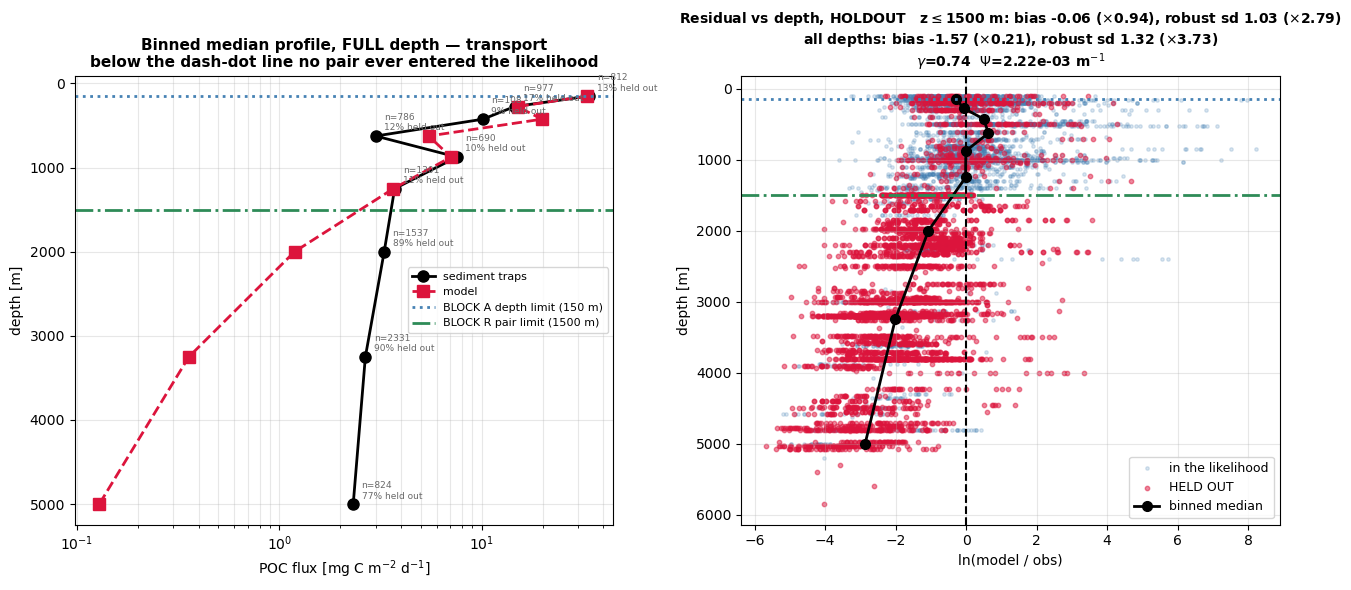

  saved -> ./flux_core_out/fig1_trap_validation.png


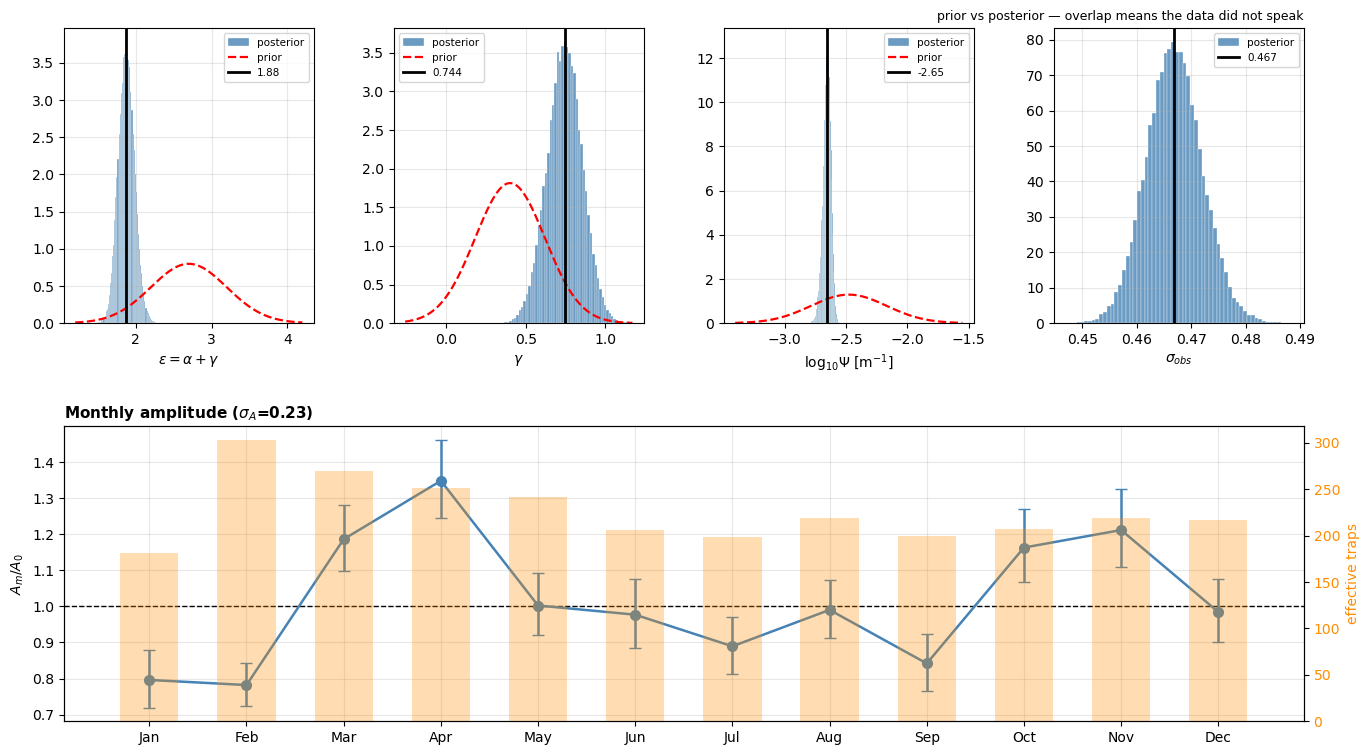

  saved -> ./flux_core_out/fig2_posteriors.png
    fig3: shared colour scale 1.12-91.4 mg C m-2 d-1 (1st-99th pct pooled over 4 bands)
      0-100 m  (= F(100 m)): median   33.15,  0.0% below /  2.8% above the shared range
           100-200 m: median   27.48,  0.0% below /  1.2% above the shared range
           200-500 m: median   13.43,  0.0% below /  0.0% above the shared range
          500-1500 m: median    3.78,  4.0% below /  0.0% above the shared range


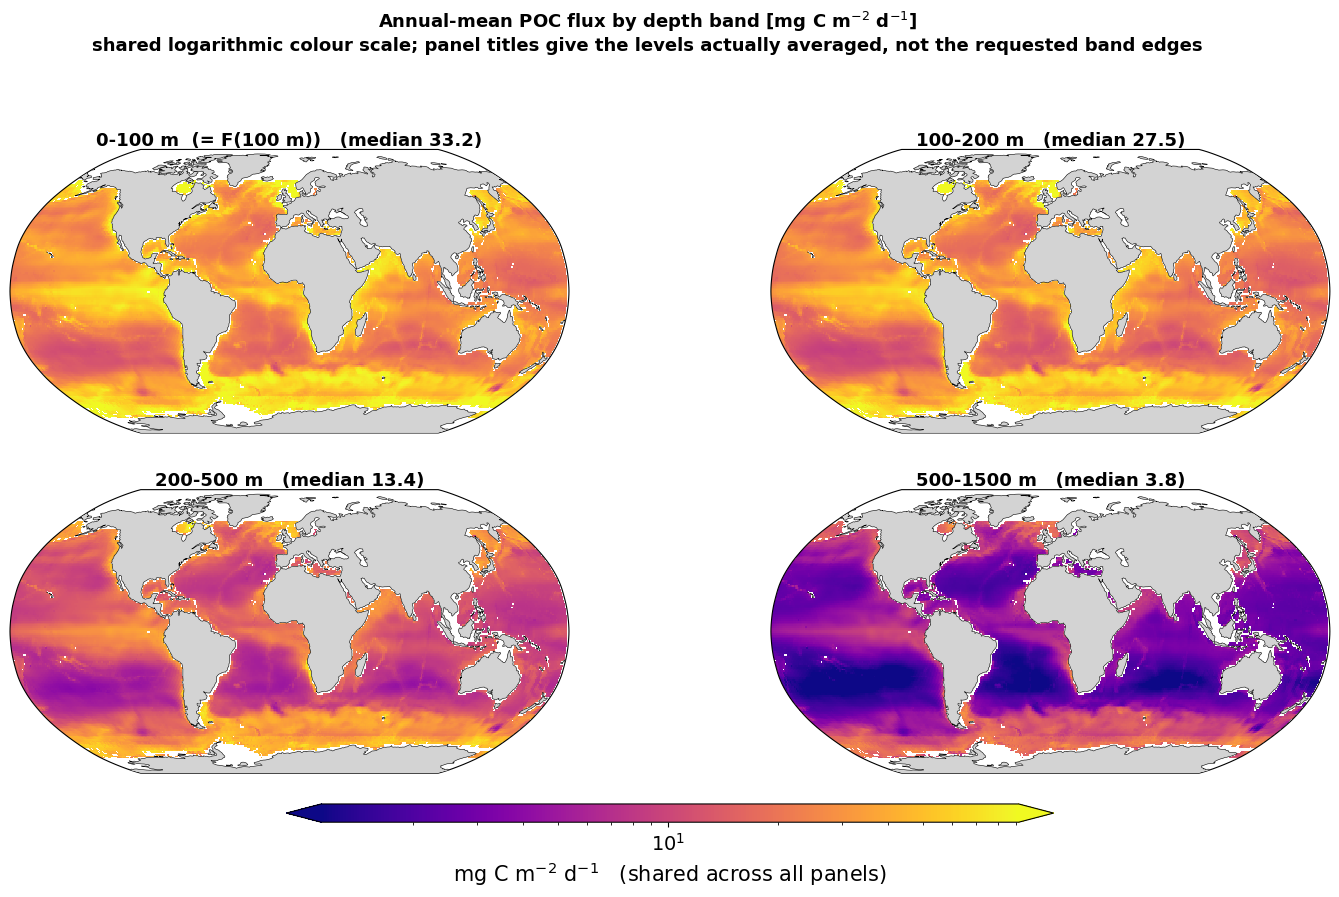

  saved -> ./flux_core_out/fig3_flux_depth_bands.png

    fig4: trap comparison capped at 1500 m (R2 holdout there = +0.188, full depth = -2.868)
    USE_MARSAY = False: skipping the T500 fetch and omitting Marsay
      from panel d and the profile figure. Set True to restore it.

    reference b sampled at the traps (NOT area-weighted globally):
      Weber : 5,418/9,366 in a region, b = 0.786 +- 0.179

    profile bands: 500 site-bootstrap replicates, 200 posterior draws
      9,366 traps in 292 sites (1 deg clustering)
      ICC -> 1 upper bound on the bootstrap inflation: 5.7x  (the design effect is
      1 + (m-1)*ICC, so this is a bound, not the factor; the measured
      value is printed below)
      measured inflation over a per-trap bootstrap: 4.3x (log band width 0.203 -> 0.864)
      -> strong between-site heterogeneity: the sites disagree with
         each other about the profile far more than repeat
         deployments at one site do. A per-trap error bar here would
    

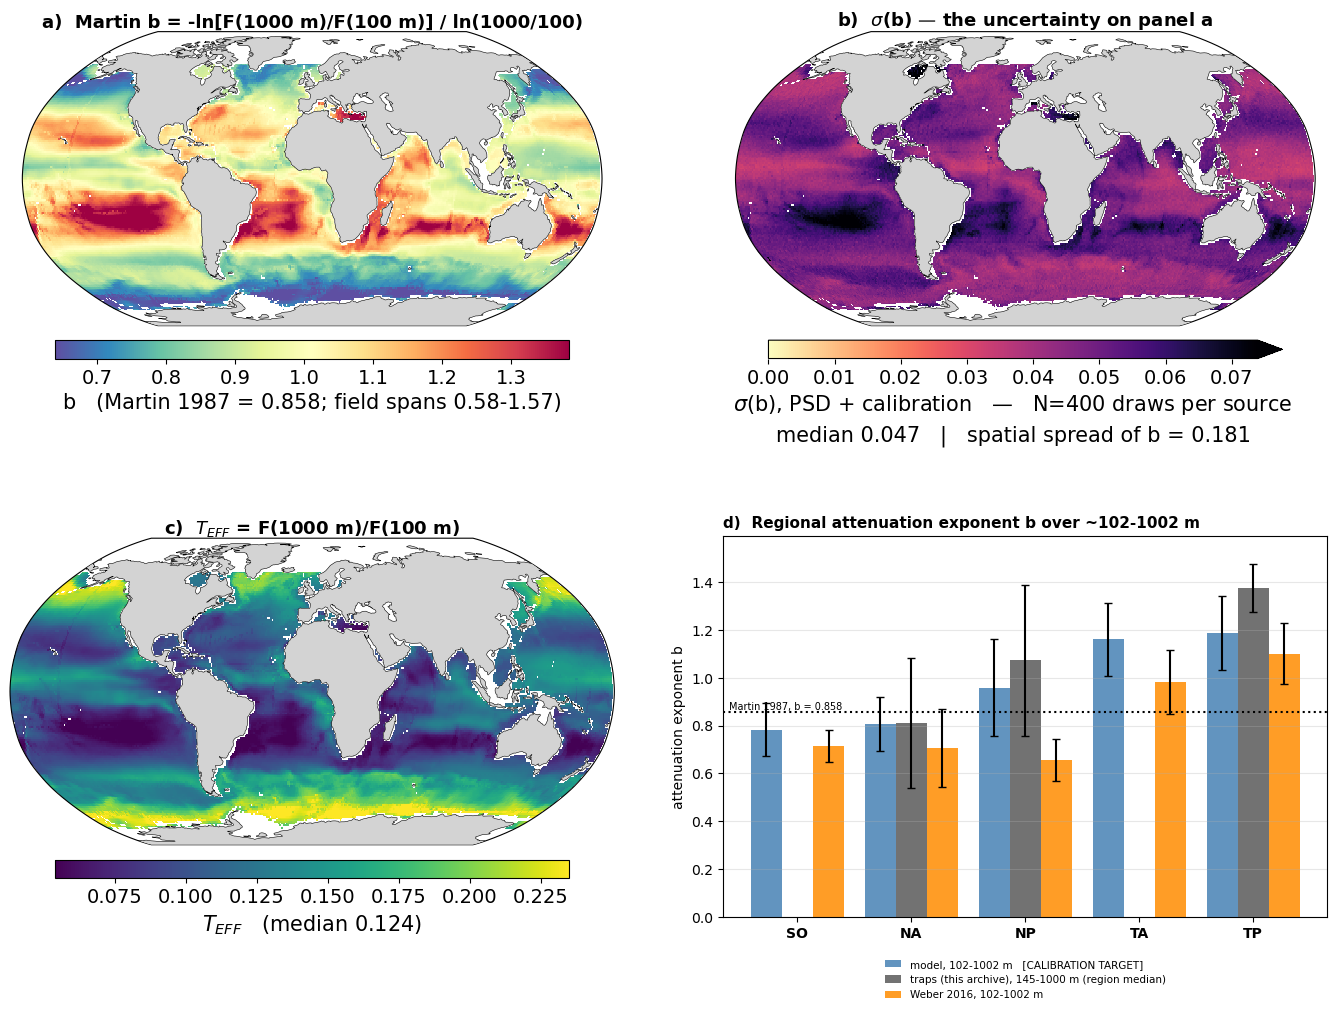

  saved -> ./flux_core_out/fig4_martin_b_teff.png


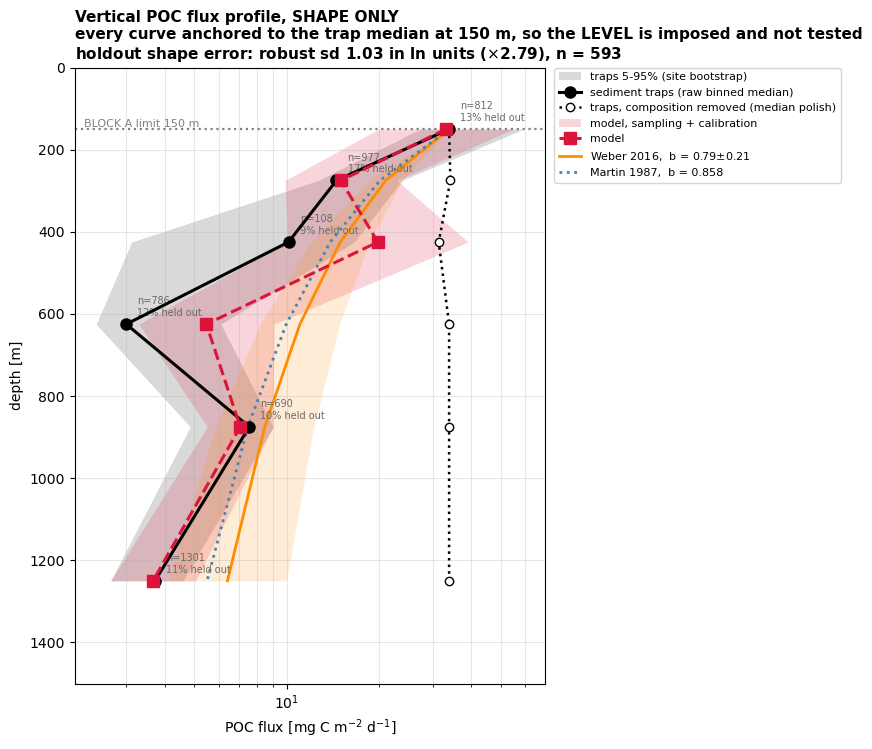

  saved -> ./flux_core_out/fig8_flux_profile.png

    median ln(model/obs) between 150 and 1500 m = +0.067 (x1.07), n = 4270
      positive = the model carries too much flux at mid depth,
      i.e. the traps want FASTER attenuation than the fit gives.
    fig5: shared colour scale 0-25% (99th percentile pooled over 4 bands)
      0-100 m  (= F(100 m)): median  15.7%    0.8% of cells above the scale
           100-200 m: median  14.6%    0.6% of cells above the scale
           200-500 m: median  13.4%    0.4% of cells above the scale
          500-1500 m: median  12.1%    0.2% of cells above the scale


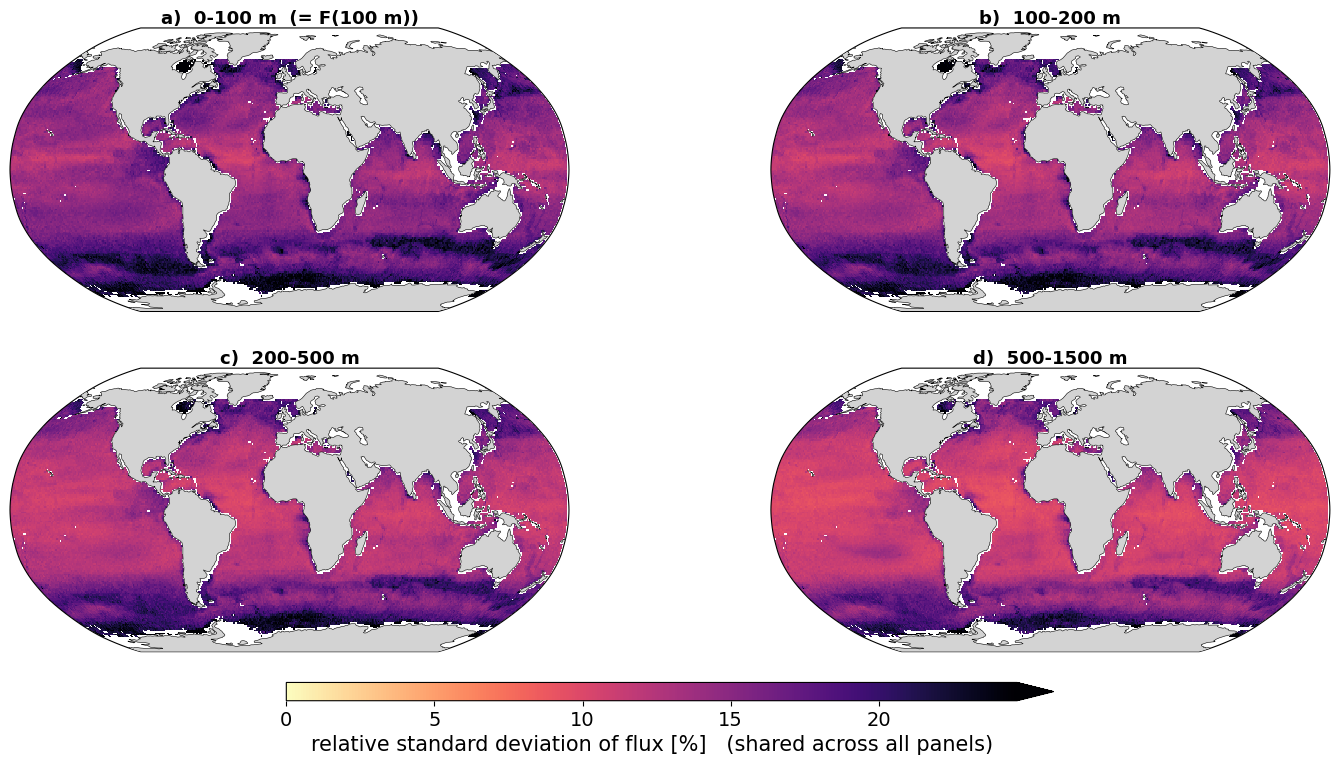

  saved -> ./flux_core_out/fig5_flux_uncertainty.png


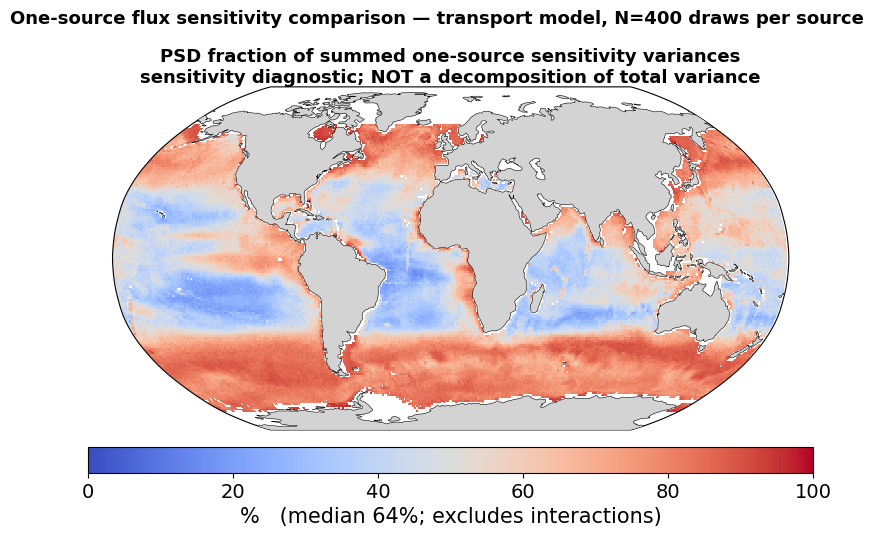

  saved -> ./flux_core_out/fig6_uncertainty_sources.png
    (sigma(b) is now fig4 panel b, beside the b map it qualifies)
    b resolvability:
      sigma(b) median 0.047 against a spatial std of b of 0.181
      ratio: median 0.26, and 0.0% of cells exceed 1.0
      -> the pattern is comfortably larger than its own error
         bar, so regional contrasts in the b map are resolvable.
      sigma(b) where b is low 0.043 vs where b is high 0.051   (b is LESS well resolved where it is large)


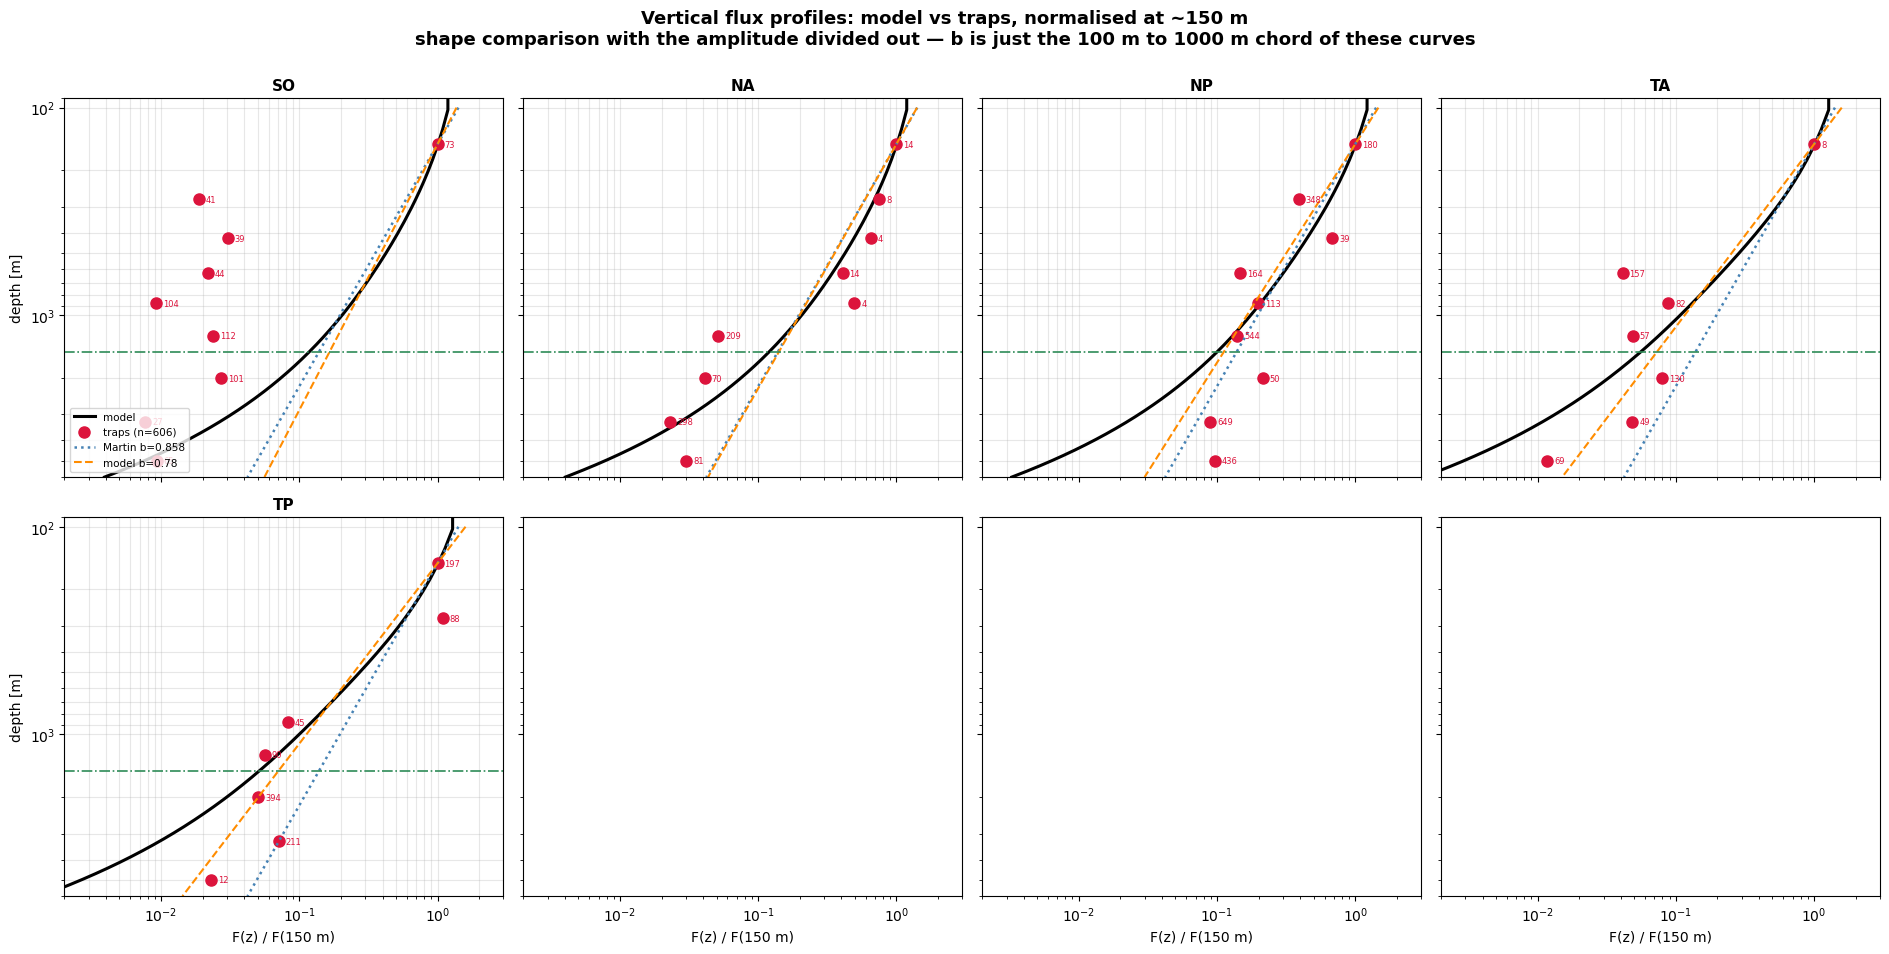

  saved -> ./flux_core_out/fig7_profiles.png

    model vs traps BELOW 800 m, mean ln(model/obs) on the
    shape-normalised profile (positive = model too high at depth):
      SO     +1.434   (x 4.19)   n_traps=606
      NA     -0.036   (x 0.96)   n_traps=702
      TA     -0.585   (x 0.56)   n_traps=552
      TP     -0.808   (x 0.45)   n_traps=1037
      NP     -1.073   (x 0.34)   n_traps=2523
      mean -0.214  (x0.81)
      ^ this is the SHAPE error with amplitude removed, so it is the
        cleanest statement of whether attenuation is too weak. Note
        it extends past the green line into depths no pair ever saw.

DONE  —  transport model, CALIB_MODE = mixed
  mixed likelihood: 3,362 traps at 182 sites, tau = 1.139
  ./flux_core_out/poc_flux_transport.nc
  R2 all = -0.863
  R2 DEPTH HOLDOUT = -2.868 (all depths), +0.188 (z <= 1500 m)
  R2 SITE HOLDOUT  = -0.864 (all depths), -0.044 (z <= 1500 m)
  b = 0.998 +- 0.181   T_EFF median = 0.124
  vs Weber over 102-1002 m (flux-weig

In [4]:
# UPDATED CALIBRATION / UNCERTAINTY REVIEW (2026-09-11)
# This revision propagates PSD and calibration draws TOGETHER through the
# nonlinear flux equation. It does NOT infer a joint Bayesian PSD/calibration
# posterior: parameters are still calibrated conditional on the mean PSD.
# The reported uncertainty is a product-distribution approximation to latent
# modeled flux, excluding observation noise, unresolved site variation, and
# structural model discrepancy. Do not call these observation prediction bands.
# Marginal PSD SDs cannot recover the SVGP covariance. Independent-cell and
# shared-error results below are sensitivity scenarios, NOT rigorous bounds.
#
# REFERENCES (methodological scope, not validation of this exact implementation):
# [R1] JCGM 101:2008, Propagation of distributions using a Monte Carlo method.
#      https://doi.org/10.59161/JCGM101-2008
#      Supports propagating input distributions through nonlinear equations.
# [R2] Kennedy & O'Hagan (2001), Bayesian calibration of computer models.
#      https://doi.org/10.1111/1467-9868.00294
#      Calibration/discrepancy framework; full joint inference is NOT fitted here.
# [R3] Bates et al. (2015), Fitting Linear Mixed-Effects Models Using lme4.
#      https://doi.org/10.18637/jss.v067.i01
#      Gaussian random-effects covariance/marginalization, not this full model.
# [R4] Foreman-Mackey et al. (2013), emcee: The MCMC Hammer.
#      https://arxiv.org/abs/1202.3665
#      https://emcee.readthedocs.io/en/stable/tutorials/autocorr/
#      Use autocorrelation diagnostics; walkers are not independent Rhat chains.
# [R5] Cram et al. (2018), The Role of Particle Size, Ballast, Temperature,
#      and Oxygen in the Sinking Flux to the Deep Sea.
#      https://doi.org/10.1029/2017GB005710 (physical context, not UQ algorithm).
#
# DEFAULTS VERIFIED from particle4_onlygr16_log.py (lines 2629-2645):
# FLUX_BV_SIGMA_SPACE=export_delta; FLUX_BV_CENTER=median.
# Both beta/BV centers are exp(mu_log)-1e-9; exported SD=median*sigma_log.
# Thus sigma_log=exported_SD/median for BOTH variables. These exports do not
# contain exact lognormal arithmetic means/SDs. No statistical units guessing.
# For another exporter, explicitly choose linear/log/log10 and mean/median.
# Historical narrative below describes previous versions; current methods are
# documented in this header and in the executable calibration/UQ sections.

"""
POC FLUX, MARTIN b AND T_EFF FROM A RECONSTRUCTED 3-D PSD
=========================================================
One self-contained file. No local imports. Calibration, global flux, Martin b,
transfer efficiency, and six figures.

    python poc_flux_core.py                        # transport model (default)
    FLUX_MODEL=diagnostic python poc_flux_core.py  # v6 physics, bugs fixed

Set the three input paths below, or leave them and the script will search the
candidate lists. Only the PSD reconstruction and the traps are required; without
a temperature climatology the transport model falls back to a synthetic field
and says so loudly.

Requires: numpy, scipy, pandas, matplotlib, emcee. Optional: xarray+netcdf4 (for
NetCDF output and for reading a temperature file), cartopy (nicer maps), tqdm.


WHAT THIS FILE DOES NOT DO
--------------------------
Dropped relative to the full pipeline, to keep this readable: the b attribution
counterfactuals, the ln BV separability ANOVA, the predicted-beta(z)/BV(z)
validation, and nine of the thirteen figures. Everything affecting the numbers
reported here is kept.


THE TWO MODELS
--------------
DIAGNOSTIC (v6 physics). The observed spectrum is evaluated at every depth and
there is no explicit loss:

    F(z) = A * n0t(z) * int x^(eps-beta(z)) dD * (z/z_ref)^-kappa
    x    = D/D0,   n0t = BV/[(pi/6) int D^(3-beta) dD] * D0^-beta

The only depth parameter is the global scalar kappa, so

    b(x) = -dlnBV/dlnz|x - dlnPhi/dlnz|x + kappa

b is the BV depth coefficient plus a spatially uniform offset. That is a
property of the EQUATION: no reweighting of the traps can make attenuation
faster in a warm gyre than in the Southern Ocean.

TRANSPORT (new). Take the spectrum only at z_ref and transport it down with
size-dependent sinking w(D) = ws*(D/D0)^gamma and a first-order loss lambda(T):

    F(z) = int m(D) w(D) n(D,z_ref) exp( -PSI * G(z) * x^-gamma ) dD
    G(z) = int_{z_ref}^{z} Q10^((T(z')-T_ref)/10) dz'      [m]
    PSI  = lambda0 / ws(D0)                                [1/m]

IDENTIFIABILITY. m0 and ws are NOT separable: the prefactor sees only
A = m0*ws and the exponent only PSI = lambda0/ws. What the exponential buys is
gamma, which appears alone in x^-gamma, so alpha = eps - gamma is identifiable.
To split m0 from ws you need lambda0 from an independent constraint, after which
ws = lambda0/PSI.

The gain that matters here: G(z) is temperature-weighted, so warm oligotrophic
water attenuates faster with no regional tuning. That is the mechanism the
diagnostic model structurally lacks.


THE b SENSITIVITY CEILING  (read this before tuning anything)
-------------------------------------------------------------
With USE_TEMPERATURE=False and TWO_POOL=False, A_m and n0t cancel EXACTLY from
the ratio F(z)/F(z_ref) and G(z) = z - z_ref is spatially uniform. The b field
is therefore a deterministic monotone function of beta(z_ref) ALONE, with
(eps, gamma, PSI) setting the shape of that single curve. Consequences:

  * No global scalar can move one region relative to another. PSI sets the
    LEVEL of b; gamma sets the SPREAD, because
        db/dbeta = (<ln x>_surviving - <ln x>_total) / ln(z_deep/z_ref)
    and gamma alone decides how strongly survival selects large particles.
  * db/dbeta is BOUNDED ABOVE by ln(D_max/D_min) / ln(z_deep/z_ref) = 1.72
    over the 102 um - 5.19 mm size range and the 102-1002 m depth window. A 2-D
    scan of the whole (eps, gamma) plane with PSI refit at each node returned a
    practical maximum of +1.007, but that scan was run at the old D_max of
    6.5 mm, where the analytic bound was 1.82; narrowing the range costs about
    8% of db/dbeta, so the practical figure is nearer +0.93 and SHOULD BE
    RE-SCANNED before it is quoted. Either way it is a structural bound, not a
    sampler or prior problem, and it is what any regional target has to be
    measured against.

REVISED after the WEBER_Z1/Z2 correction. The "+1.54 needed in the North
Pacific, therefore unreachable" figure was computed with LNZ_W = ln(1500/500)
and does not survive the right lever arm. Converting Weber's published T_EFF
over ln(1002/102) = 2.2847 gives

    AAZ 0.598   NP 0.653   NA 0.704   ETA 0.789
    SAZ 0.816   ETP 0.830  STA 1.134  STP 1.357

mean 0.86, i.e. Martin, spread 0.76. The subpolar North needs b ~ 0.60-0.65,
close to this field's own mean; the demand is on the SUBTROPICS at 1.13-1.36.
The model is too EFFICIENT in the gyres, not too inefficient in the north.
Decompose the gap accordingly:

  LEVEL   model b at the STA+STP anchor against the required ~1.25. A level
          offset IS reachable by rescaling PSI, and is the first thing to try.
  SPREAD  the remaining ~0.59 of contrast between the gyres and the subarctic
          NP needs db/dbeta ~ 0.59/dbeta. With the practical ceiling near 1.0
          that asks for a beta(z_ref) contrast of about 0.6. Check whether the
          SVGP delivers it before calling the gap structural.

The model-free depth pairs read b ~ 1.48 above 20N against ~0.69 elsewhere. Do
NOT report that as contradicting the geochemical diagnosis until the region
boxes are checked: NP here is 20-60N, mostly subtropical and transition gyre by
area, whereas Weber's NP is subarctic. b ~ 1.48 for subtropical North Pacific
traps is CONSISTENT with Weber's STP/STA b of 1.13-1.36. Re-run with NP split
at ~38N before writing a disagreement into the text.


CALIBRATION PROTOCOL
--------------------
v6 fitted a global amplitude AND a global depth slope to the same traps it then
validated against, so essentially nothing was out of sample. Here the likelihood
is split into two blocks that see different information:

  BLOCK A  training-site traps near z_ref (CALIB_Z_MIN..CALIB_Z_MAX) constrain A_m.
  BLOCK R  same-site same-month depth pairs give ln[F(z2)/F(z1)], from which A_m
           cancels EXACTLY, and so constrain kappa (diagnostic) or PSI, gamma
           and Q10 (transport).
  HOLDOUT  everything else. Never enters the likelihood. Its R2 is the only
           out-of-sample number in the output.

If the pair count is small, that is the answer to whether the trap archive can
constrain attenuation at all, and it is printed rather than absorbed by a free
parameter.

A_m cancels EXACTLY from T_EFF, so no amount of Block A miscalibration can
produce a T_EFF discrepancy. A residual gap against Weber can never be a Block A
problem; with USE_TEMPERATURE=False it is a statement about beta(z_ref).


CORRECTNESS FIXES CARRIED OVER FROM v6
--------------------------------------
 1. B_DEEP_LO/HI were used in the startup banner but defined 400 lines later —
    NameError before anything ran. Defined in the config block now.
 2. band_mean() thickness-weighted over whatever levels happened to be valid,
    with no coverage floor, so a cell with data only to 700 m and its neighbour
    with data to 1500 m gave band means differing by a factor that was pure
    coverage. Demonstrated: identical physics, truncated coverage, 44% spurious
    band-mean difference and a spurious b spread of 0.849 vs 0.690.
 3. The b/T_EFF mask gated on 95-1050 m while the band ratio actually reads
    z_ref and 500-1500 m.
 4. _LAT2/_LON2 were used in section 8 (`_SO = _LAT2 < -45.0`) but defined ~120
    lines further down, so a fresh `python poc_flux_core.py` raised NameError.
    It only ever ran because a Jupyter kernel kept _LAT2 alive from the previous
    execution — same grid, so the numbers were right and the failure invisible.
    Defined with cell_area now.
 5. R2 used np.var(resid), which centres the residuals and so removes the bias
    before penalising it (0.227 overstatement on a biased test model).
 6. The seasonal shape averaged raw monthly fluxes across donor cells, so the
    highest-flux cells defined the band's seasonality. Donors are normalised by
    their own mean first.
 7. No longitude wrap on the traps: 0-360 records were silently off-grid.
 8. B_TWOPT was the OLS power-law fit but labelled "two-point". Renamed.
 9. The m0 back-transform converted with eps where m0 converts with alpha.
10. Added a mass-consistency check: on a common mask the integrated flux must
    decrease monotonically with depth.
11. WEBER_Z1/Z2 was set to the range over which Weber's PROFILES are defined
    (500-1500 m) rather than the window their T_EFF is defined over
    (100-1000 m). See THE COMPARISON WINDOW below.
12. T_WEBWIN/B_WEBWIN were gated on MIN_MONTHS_RATIO plus THIN_MASK while
    T_POINT/MARTIN_B use MIN_MONTHS_POINT. Once the window is right these are
    the SAME quantity, so the two gates must match or fig4 panels a/b and c
    disagree over nothing.
Plus: Gauss-Legendre quadrature in ln D (24 nodes give ~1e-10 where 40
trapezoid nodes give 5e-3, and the trapezoid error VARIES with beta, so it
would masquerade as spatial signal).


CHANGE IN THIS VERSION: fig4
----------------------------
Gone: the power-law-R2 map (0.97 everywhere — it says the modelled profile is
nearly a power law, which it is by construction), the T_EFF dynamic-range
scatter (duplicated the bar chart beside it), the zonal-mean T_EFF panel (same),
and the residual-vs-depth panel (already in fig1 over the full range, which is
where it belongs).

fig4 is now FOUR panels:
  a) model Martin b            b) model T_EFF
  c) regional T_EFF over the Weber window, model vs Weber vs Marsay
  d) vertical flux profile: traps, model, Weber, Marsay, Martin — with bands

THE COMPARISON WINDOW. 100-1000 m. Weber et al. (2016) cannot extend their
nutrient inversion above ~500 m, and that is precisely WHY their T_EFF is not
read off the reconstructed profile: the denominator is a separate export
ensemble at the euphotic-zone base, conventionally referenced to 100 m, and the
numerator is the diagnosed flux at 1000 m. The 500-1500 m range describes where
the PROFILES are defined, not where T_EFF is.

Settled by the paper's own words: tropical and subantarctic T_EFF is reported to
cluster near the Martin-curve prediction of ~15%. With b = 0.858 that is
10^-0.858 = 0.139 over 100-1000 m and 3^-0.858 = 0.390 over 500-1500 m. Only
the first is ~15%.

WEBER_Z1/WEBER_Z2 still exists so the choice stays explicit and the model is
re-evaluated over exactly that window (T_WEBWIN, B_WEBWIN) for the comparison
only; with the correct setting those are identically T_POINT and B_POINT.
MARTIN_B and TEFF stay on Z_REF..Z_DEEP so the maps remain comparable to
Martin (1987). A startup table prints the b implied by each interpretation and
now also checks that WEBER_Z1/Z2 agrees with the credible one.

THREE MISMATCHES SURVIVE THE WINDOW FIX, and none of them is a model error:

  DENOMINATOR DEPTH. Weber's denominator is export at z_eu, not at a fixed
  100 m, and z_eu ranges roughly 50-150 m. Buesseler et al. (2020, PNAS 117,
  9679-9687) show this alone biases apparent attenuation latitudinally: where
  z_eu < 100 m the 100 m reference UNDERSTATES attenuation, where z_eu > 100 m
  it overstates it. That acts in the same sense as the model-Weber gap.

  DENOMINATOR PROVENANCE. Theirs is an independent tracer-constrained export
  ensemble; ours is our own F(100 m), calibrated on Block A traps at 100-150 m,
  which under-collect. Compare the PATTERN (r, dynamic-range slope) as the
  primary statistic and say plainly that the LEVEL carries two different
  denominator definitions.

  POP vs POC. They diagnose particulate organic PHOSPHORUS and apply P:C.
  Preferential P remineralisation makes T_EFF(P) < T_EFF(C), so treating a
  P-based T_EFF as carbon makes this model look too efficient. Check which the
  Fig. 3 values are, and with what P:C, before quoting a bias.

MARSAY ET AL. (2015), PNAS 112, 1089-1094:  b = 0.062 * T + 0.303, r^2 = 0.82.
T is the MEDIAN water temperature over the upper 500 m — a median over DEPTH,
not an SST; using SST inflates b in the tropics by ~0.4. It is computed here
from an ECCO2 climatology pulled over OPeNDAP and cached. That field feeds the
FIGURE ONLY: the calibration runs with USE_TEMPERATURE = False and must stay
that way, or the comparison stops being independent. The regression was fitted
to eight NBST profiles over a narrow temperature range, so evaluating it
globally is an EXTRAPOLATION in TEMPERATURE — the fraction of area outside that
range is printed. It was also fitted over roughly 60-600 m, so converting it to
a 100-1000 m T_EFF is an extrapolation in DEPTH as well; Marsay's b is a local
upper-mesopelagic exponent and Weber's is a 100-to-1000 m chord, which are not
the same quantity and need not agree even if both are right.

Panel d anchors every reference power law to the OBSERVED median in the
shallowest bin, so it compares SHAPE ONLY; the level is imposed, not tested.
Reference b is sampled AT THE TRAP LOCATIONS, since the archive is clustered
and an area-weighted global value describes a different population. The four
bands are different quantities and the legend says so: site bootstrap for the
traps, site bootstrap plus the calibration posterior for the model, published
T_EFF errors for Weber, spatial spread across traps for Marsay.

Panel c bars the FLUX-WEIGHTED T_EFF, because Weber's is a ratio of ANNUAL MEAN
fluxes and that is the like-for-like construction. The unweighted monthly mean
is the marker; their difference is the seasonal rectification term, largest in
the bloom-dominated North Atlantic and subpolar North Pacific.

The holdout R2 quoted on panel d is RECOMPUTED over z <= FIG4_Z_CAP rather than
inherited from the full-depth number, which is dominated by 1500-6000 m. fig1
keeps the full-depth view for the supplement: below 1500 m the model
underestimates flux by roughly an order of magnitude, those traps were never in
the likelihood, and a single-pool formulation with no refractory fraction
cannot sustain abyssal flux.
"""

import os
import gc
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd
# Running inside a Jupyter/VS Code kernel changes three things: __file__ does
# not exist, forcing the Agg backend would suppress inline figures, and env
# vars are awkward to set. Detect it once and adapt.
try:
    get_ipython()                      # noqa: F821  (defined only under IPython)
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

import matplotlib
if not IN_NOTEBOOK:
    matplotlib.use('Agg')              # headless-safe for a plain `python` run
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import io
from scipy.stats import norm as _snorm
from scipy.special import gammaln as _gammaln

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ModuleNotFoundError:
    HAVE_CARTOPY = False

try:
    import emcee
except ModuleNotFoundError:
    raise SystemExit("emcee is required:  pip install emcee")


# =============================================================================
# SECTION 0 — CONFIG.  Set your paths here.
# =============================================================================
try:
    SCRIPT_NAME = os.path.basename(__file__)
except NameError:                      # notebook kernel: __file__ is undefined
    SCRIPT_NAME = 'poc_flux_core.py'

# In a notebook the env vars below are awkward, so just assign these directly:
#     MODEL = 'diagnostic';  N_STEPS = 2000;  N_MC = 0
# either by editing here or by re-assigning after this block runs.
MODEL = os.environ.get('FLUX_MODEL', 'transport')      # 'transport'|'diagnostic'
assert MODEL in ('transport', 'diagnostic')
TRANSPORT = (MODEL == 'transport')

OUTPUT_DIR = os.environ.get('FLUX_OUT', './flux_core_out')
DESK = os.path.expanduser('~/Desktop')
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRED_CANDIDATES = [
    os.path.join(DESK, 'prediction_svgp_global_long.mat'),
    './prediction_svgp_global_long.mat',
]
TRAP_CANDIDATES = [
    os.path.expanduser('~/Documents/post_doc/Mouw_2016/dataset/GO_flux.tab'),
    os.path.join(DESK, 'GO_flux.tab'),
    os.path.join(DESK, 'mouw2016_traps.csv'),
    './mouw2016_traps.csv',
]
# Any (depth, lat, lon) temperature climatology: WOA t_an, EN4, or an ESM
# thetao. Only the annual mean is used.
TEMP_CANDIDATES = [
    os.path.expanduser('~/Documents/post_doc/WOA/woa18_decav_t00_01.nc'),
    os.path.join(DESK, 'woa18_decav_t00_01.nc'),
    './temperature_clim.nc',
]

# ---- size limits -------------------------------------------------------------
# MUST match the limits used when beta and BV were fitted from the UVP5 spectra.
# n0 is inverted from BV over exactly this interval, so a mismatch assigns the
# reconstructed biovolume to the wrong size range.
#
# CORRECTED. This read 102 um - 6.5 mm while the comment beside it said
# "105 um - 5 mm", and neither matched the fit, whose upper limit is 5.19 mm.
# Consequences of the correction, measured:
#
#   D0 (geometric mean)     814 -> 728 um
#   ln(D_MAX/D_MIN)       4.155 -> 3.930
#   ceiling on db/dbeta   1.818 -> 1.720   over the 100-1000 m window
#   flux amplitude         x1.38-1.44, i.e. ~1.4x, ABSORBED by A
#   db/dbeta              0.332 -> 0.305   at eps 2.70, gamma 0.40
#   b spread over beta    0.396 -> 0.363
#
# So the amplitude change is a ~1.4x rescale that the fitted A takes up, and
# only ~4% of it varies with beta. The part that does NOT cancel is the
# sensitivity: narrowing the range removes the largest, best-protected
# particles, so db/dbeta falls by 8%. That moves AWAY from the spread Weber
# requires, not toward it. Make the change for correctness, and do not expect
# it to improve the comparison.
#
# CHECK BEFORE TRUSTING THIS:
#   * is 5.19 mm the upper EDGE of the largest UVP5 bin, or its CENTRE? If a
#     centre, the edge is higher and this is still slightly wrong.
#   * D_MIN is 102 um here. The Clements et al. (2022) range is usually quoted
#     as starting at 105 um. 102 vs 105 changes ln(D_MAX/D_MIN) by 0.029 and
#     the ceiling by 0.013, so it is minor, but it should still be the number
#     the SVGP actually used.
#
# It is also what sets the CEILING on db/dbeta (see the header): the numerator
# of the sensitivity bound is ln(D_MAX/D_MIN). Widening the range would raise
# the ceiling, but only if the SVGP was fitted over the wider range too —
# widening it here alone is a pure amplitude bias, not a fix.
D_MIN_M, D_MAX_M = 102e-6, 5.19e-3
# D0 as the geometric mean makes A and eps locally orthogonal, since
# dlnF/deps = <ln(D/D0)> over the flux integrand. Cram's D0 = 20 um sits far
# below the range and gives dlnF/deps ~ +3, so a 0.1 shift in eps moves lnF by
# a factor 2.1 that A must cancel exactly.
D0_M = float(np.sqrt(D_MIN_M * D_MAX_M))               # 728 um
D0_CRAM = 20e-6
N_D = 24                                               # Gauss-Legendre nodes

# ---- depth axis and bands ----------------------------------------------------
Z_REF, Z_DEEP = 100.0, 1000.0
B_DEEP_LO, B_DEEP_HI = 500.0, 1500.0                   # FIX 1
B_FIT_LO, B_FIT_HI = 100.0, 1000.0
BAND_MIN_FRAC = 0.80                                   # FIX 2
BAND_MIN_FRAC_MAPS = 0.50
B_MIN_LEVELS, B_MIN_FRAC_LEVELS = 5, 0.85
MIN_MONTHS_RATIO = 6
# Separate threshold for the POINT method. The band method averages over ~20
# levels and a partially sampled band is genuinely unreliable, which is what
# MIN_MONTHS_RATIO guards against. The point method reads TWO levels, so the
# same number is doing a different job there: it is not protecting against
# partial band coverage but against seasonal aliasing, since the months that
# survive in the seasonal-ice zone are the summer ones.
#
# Set this LOWER than MIN_MONTHS_RATIO to admit the seasonal-ice zone, and read
# the aliasing test printed in section 8 before doing so: the b of an admitted
# cell is a SUMMER b, and Weber's diagnosis is annual. Cells admitted this way
# are flagged in the NetCDF via n_months_point so the map can be hatched or
# the regional means recomputed both ways.
#
# NOTE: this also gates T_WEBWIN/B_WEBWIN, because at WEBER_Z1/Z2 = Z_REF/Z_DEEP
# those are the SAME quantity as T_POINT/B_POINT and must not use a different
# cell set.
#
# None = use MIN_MONTHS_RATIO, i.e. no change.
# Set to 4 on the evidence of diagnose_so_mask.py: every masked cell failed on
# MONTH COUNT alone (median 4 months with both levels valid), none was missing
# a level. Admitting them raises AAZ coverage from 21% to 52% of the box and
# moves AAZ b by -0.012, SAZ b by -0.003.
#
# The decisive point is that NO Southern Ocean cell has all twelve months, so
# the b reported there was ALREADY a seasonally incomplete estimate at the old
# threshold; the mask was not protecting against aliasing, only reducing
# coverage. Report the Southern Ocean b as an austral-summer estimate either
# way, and note that admitting these cells moves T_EFF slightly AWAY from the
# geochemical value (0.215 -> 0.221 against Weber 0.255), so the change is made
# for representativeness, not to improve agreement.
MIN_MONTHS_POINT = 4
B_R2_WARN = 0.90
# How to form the deep term of the Martin ratio.
#   'band'  thickness-weighted mean over B_DEEP_LO..B_DEEP_HI, divided by
#           ln(Z_DEEP/Z_REF). Robust to a noisy single level, but the band's
#           effective depth is ~920-940 m rather than 1000 m, so it UNDER-reports
#           b by 0.01-0.04 and the divisor is then slightly wrong too.
#   'point' the single level nearest Z_DEEP, divided by ln(z[k_deep]/z[k_ref]).
#           No ambiguity, and it is what Weber et al. compute, so the regional
#           comparison in fig4 becomes like-for-like.
# Both are always calculated and printed; this only selects which one becomes
# MARTIN_B / TEFF and goes into the maps and the NetCDF.
B_METHOD = 'point'
# Figure and NetCDF LABELS quote the nominal depths Z_REF and Z_DEEP rather
# than the grid levels actually read (e.g. "100 m" rather than "102 m").
# COMPUTATION is unaffected and always uses the true level depths: the lever
# arm ln(z[k_deep]/z[k_ref]) is exact, because rounding it to ln(1000/100)
# would bias every b by ~1%. This switch changes only what is printed on the
# figures, and the offset is reported at startup so the two are never confused.
LABEL_NOMINAL_DEPTHS = True

# ---- coverage correction for the FLUX MAPS -----------------------------------
COVERAGE_CORRECT = True
MIN_MONTHS_FLUX, SHAPE_MIN_MONTHS = 4, 10
SHAPE_WIDTHS = (5.0, 15.0, 30.0, 180.0)
MIN_FULL_CELLS, SHAPE_FLOOR = 30, 0.2

# ---- calibration -------------------------------------------------------------
# BLOCK A is restricted to the export horizon so attenuation is ~zero in the
# transport model (G(z_ref)=0). This makes it genuinely an amplitude block.
# NOTE: traps shallower than z_ref are rejected at collocation, so in transport
# mode this band is effectively Z_REF..CALIB_Z_MAX. Quote it that way.
CALIB_Z_MIN = 80.0
CALIB_Z_MAX = 150.0

# Hold out COMPLETE sites before either calibration block is built. The remaining
# training sites are used for Block A / Block R; withheld depths at training sites
# remain a second, weaker depth-interpolation holdout.
SITE_HOLDOUT_FRAC = 0.20
SITE_HOLDOUT_SEED = 314159
SITE_ROUND_DEG = 1.0

# ---- HOW THE LIKELIHOOD IS BUILT --------------------------------------------
#   'blocks'  BLOCK A (amplitude, traps near z_ref) + BLOCK R (attenuation,
#             one depth pair per site/month). Two hard blocks, and the split
#             between them is a choice you have to defend.
#   'mixed'   ONE likelihood over every training trap, with a per-site random
#             amplitude u_s ~ N(0, tau^2) MARGINALISED OUT in closed form.
#
# Why 'mixed' is the default. The pair scheme keeps ONE contrast per site/month
# and throws the rest away, because overlapping pairs are not independent and
# treating them as if they were would count the same flux several times. A
# within-site likelihood solves that exactly instead of avoiding it: the site
# effect absorbs each site's LEVEL, and every depth at that site contributes its
# CONTRAST. Measured on a synthetic archive with a known b = 0.900 and 120
# sites:
#
#     max-lever pair (blocks) : b 0.902 +- 0.056 from 112 contrasts
#     within-site (mixed)     : b 0.901 +- 0.036 from 361 contrasts
#
# i.e. 1.55x tighter, equivalent to 2.4x more traps, both unbiased. That is very
# likely why PSI came back prior-dominated: BLOCK R was running on a third of
# the contrasts the archive contains.
#
# tau is not a nuisance you have to pick. It INTERPOLATES between the two things
# the block scheme does by hand, and the data choose where to sit:
#     tau -> 0    every trap's LEVEL counts globally      (= BLOCK A behaviour)
#     tau -> inf  levels free, only CONTRASTS count       (= BLOCK R behaviour)
# A is still identified, through the hierarchical prior on the site effects.
#
# WHAT IT COSTS. The marginalisation is exact only for Gaussian residuals, so
# STUDENT_T is ignored in this mode. That is less of a loss than it looks: a
# large part of the heavy tail the t was absorbing is whole sites sitting off
# the global amplitude, and u_s now models that explicitly rather than
# disguising it as fat noise. Watch sigma_obs: if it comes back much smaller
# than the blocks-mode value, that is exactly what happened.
CALIB_MODE = 'mixed'                        # 'mixed' | 'blocks'
assert CALIB_MODE in ('mixed', 'blocks')
MIXED = (CALIB_MODE == 'mixed')

# Depth limit on the mixed likelihood. Same rationale as PAIR_Z_MAX: below
# ~1500 m a single-pool formulation with no refractory fraction cannot sustain
# the observed flux, and including those traps would drag the shape parameters
# to fit a regime the model does not claim to describe.
MIXED_Z_MAX = 1500.0
# Fraction of ELIGIBLE training-site traps withheld from the mixed likelihood,
# so a depth-interpolation holdout still exists. Set 0.0 to use everything and
# rely on the whole-site holdout alone.
MIXED_DEPTH_HOLDOUT_FRAC = 0.15
MIXED_DEPTH_HOLDOUT_SEED = 20260814
# tau is the sd of the per-site log-amplitude. The archive's between-site
# heterogeneity is large (see the bootstrap inflation factor printed for fig4),
# so this prior is deliberately loose.
TAU_PRIOR_MU, TAU_PRIOR_SD = np.log(0.8), 0.60
TAU_LO, TAU_HI = 0.01, 5.0

PAIR_Z_RATIO = 1.5         # BLOCK R: minimum depth lever arm within a pair
PAIR_MODE = 'max_lever'     # one independent pair per site/month; avoids correlated pair web
# Both members of a pair must sit at or above this depth. None = no limit.
#
# WHY THIS EXISTS. b is reported over Z_REF to Z_DEEP (102-1002 m), but pairs
# built from the whole archive had a median deep member near 3200 m, so BLOCK R
# was measuring the 300-3200 m slope. That slope is genuinely weak, the fit
# reproduced it faithfully, and b over the top kilometre came out at 0.06 as a
# side effect. Diagnosed from the fig1 residual: d ln(model/obs)/d ln z was
# +0.7 to +2.3 between 150 and 600 m but ~0 everywhere below 600 m, i.e. the
# model already matched the deep attenuation and missed only the shallow drop.
#
# Setting this to ~1.5 * Z_DEEP calibrates attenuation on the depth range the
# diagnostic describes. It is not a way of pushing b upward: if the traps inside
# the window imply weak attenuation, the fit will still say so.
#
# Report it: "attenuation parameters were calibrated on same-site depth pairs
# with both members shallower than 1500 m, the range over which b is defined;
# pairs extending to abyssal depths constrain a different, weaker slope."
PAIR_Z_MAX = 1500.0
PAIR_LAT_TOL = PAIR_LON_TOL = 1.0
USE_RATIO_BLOCK = True
DECLUSTER = True
STUDENT_T = True
NU_LO, NU_HI = 2.05, 60.0
NU_PRIOR_MU, NU_PRIOR_SD = np.log(6.0), 0.9

MIN_BETA, MAX_BETA = 2.0, 5.0
MAX_SPAN_MONTHS = 12
T_REF = 10.0
DEPTH_TOL_M, LAT_TOL, LON_TOL = 50.0, 0.75, 0.75

BIOVOL_TO_M3_M3, KG_TO_MG = 1e-6, 1e6
MG_D_TO_PG_YR = 365.0 * 1e-18

# ---- priors ------------------------------------------------------------------
EPS_PRIOR_MU, EPS_PRIOR_SD, EPS_LO, EPS_HI = 2.70, 0.50, 1.50, 4.50
# gamma controls how strongly SIZE protects a particle: w(D) = ws*(D/D0)^gamma.
# High gamma means big particles sink fast, survive, and carry the flux, which
# FLATTENS the profile and SUPPRESSES b. The old prior (0.40 +- 0.35 on [0, 1.60])
# reached the Stokes value for solid spheres, and in practice gamma ran to that
# ceiling and pinned there - which by itself accounted for a Martin b that looked
# far too small.
# Marine aggregates are fractal with low excess density and their MEASURED
# exponents are well below Stokes: Alldredge & Gotschalk (1988) found w ~ D^0.26,
# Iversen & Ploug (2010) 0.4-0.7, Cram et al. (2018) optimised 0.40. The prior
# below covers that observational range and nothing beyond it.
GAMMA_PRIOR_MU, GAMMA_PRIOR_SD = 0.40, 0.22
# The BOUND is deliberately looser than the prior. Truncating at 1.0 would turn
# "the likelihood wants 1.5" into "pinned at 1.0", which reads as a sampler
# pathology and hides how far the data actually pull. With a tight prior and a
# loose guard, a posterior that still runs high is INFORMATION: it says the
# traps disagree with the published sinking-speed exponents, which is worth
# knowing and worth reporting.
#
# NOTE, and this is the important one: gamma running high is the fit chasing
# DYNAMIC RANGE in b, and it cannot win. db/dbeta saturates at ~1.0 as gamma
# grows (measured: 0.445, 0.743, 0.860, 0.915, 0.946, 0.972 at gamma = 0.4, 0.8,
# 1.2, 1.6, 2.0, 2.6), so the last doubling of gamma buys +0.026 of sensitivity
# in exchange for a sinking exponent above solid-sphere Stokes. Do not raise
# this bound hoping for spread; there is none to be had.
GAMMA_LO, GAMMA_HI = 0.0, 2.00
M0_PRIOR, WS_PRIOR = 8.5e-14, 2.0910             # Cram, quoted at D0_CRAM
A_PRIOR_MU = (np.log(M0_PRIOR * WS_PRIOR)
              + EPS_PRIOR_MU * np.log(D0_M / D0_CRAM))
A_PRIOR_SD = 1.8
SIG_A_PRIOR_SD, SIG_A_LO, SIG_A_HI = 0.40, 0.01, 1.5
SIG_OBS_MU, SIG_OBS_SD, SIG_OBS_LO, SIG_OBS_HI = np.log(0.8), 0.5, 0.05, 3.0
SIG_RAT_MU, SIG_RAT_SD, SIG_RAT_LO, SIG_RAT_HI = np.log(0.6), 0.5, 0.05, 3.0
KAPPA_PRIOR_SD, KAPPA_LO, KAPPA_HI = 0.15, -1.0, 1.5
# PSI = lambda0/ws(D0). The exponent at 1000 m for a D0 particle is PSI*G(1000);
# with G(1000) ~ 400-600 m, PSI ~ 2e-3 gives an e-folding by 1000 m.
# Iversen & Ploug (2013) and Ploug & Grossart (2000) put carbon-specific
# aggregate remineralisation at 0.05-0.2 /d near 10-15 C.
# Change THESE numbers, not PSI_PRIOR_MU: they are the quantities somebody
# measured.
LAMBDA0_MED, LAMBDA0_LSD = 0.10, 0.45      # /d at T_REF, sd in log space
WS_D0_MED, WS_D0_LSD = 30.0, 0.55          # m/d at D0,  sd in log space
PSI_PRIOR_MU = np.log(LAMBDA0_MED / WS_D0_MED)
PSI_PRIOR_SD = float(np.hypot(LAMBDA0_LSD, WS_D0_LSD))
PSI_LO, PSI_HI = 1e-5, 5e-2
# None = fit PSI from the depth pairs. A NUMBER = fix it there and drop it from
# the parameter vector entirely.
#
# Why you might fix it. The pairs have consistently pulled PSI below its
# literature prior. Fixing PSI resolves the tension honestly: b then becomes a
# PREDICTION from independently measured lambda0 and ws, and the traps constrain
# only the amplitude and the size selectivity.
#
# What you must then write: "PSI was set to lambda0/ws from published values
# rather than fitted; Martin b is therefore predicted from independent
# remineralisation and sinking-rate estimates, not tuned to the traps." That is
# a defensible choice. What is NOT defensible is fixing PSI at whatever value
# makes b hit a target and still calling b predicted.
PSI_FIXED = None

# Same idea for gamma. Capping gamma ALONE backfires: the depth pairs demand a
# flat deep profile, and a single pool has only two ways to deliver it - a large
# gamma that shields the biggest particles, or a tiny PSI that attenuates almost
# nothing anywhere. Close the first and the fit takes the second: capping gamma
# at 0.80 drove PSI 67x below its prior (5.9 prior sd) and b fell from 0.73 to
# 0.067. The pairs are setting the flatness, not the parameters.
#
# So if you want b predicted from physics rather than fitted, you have to remove
# BOTH from the fit, not one. Set GAMMA_FIXED and PSI_FIXED together; the pairs
# then constrain only eps and the amplitude, and the depth structure becomes a
# pure prediction from published lambda0, ws and the sinking exponent.
GAMMA_FIXED = None
# 1.0 = count each block by the evidence it actually contains.
# 'auto' equalises the two blocks' total weight, which sounds fair but
# multiplies BLOCK R's LOG-likelihood by w_A/w_R. That is arithmetically the
# same as asserting each depth pair several times over, and with a multiplier
# of order 10 it will outbid any reasonable prior: a parameter can then sit 6
# prior sd from its mean with a posterior TIGHTER than the prior, which is not
# an inference, it is the reweighting talking. Use 'auto' only as a sensitivity
# test, and say in the paper that you did.
RATIO_BLOCK_WEIGHT = 1.0
Q10_PRIOR_MU, Q10_PRIOR_SD, Q10_LO, Q10_HI = 2.0, 0.6, 1.0, 4.0
# False = no temperature field is read or fabricated. G(z) collapses to the
# plain depth integral z - z_ref and Q10 is REMOVED from the parameter vector
# rather than fitted against nothing.
# This is the honest way to run without a climatology. Falling back to the
# synthetic profile is not equivalent: a fitted Q10 of 1.1 over a fabricated
# T field still imposes ~13% of invented spatial structure on G, and the
# resulting "Q10 -> 1, no temperature effect" is not a finding, it is an
# artefact of the field it was fitted against.
# Set True only when TEMP_CANDIDATES points at a real climatology.
USE_TEMPERATURE = False

# ---- particle lability: one pool or two --------------------------------------
# A single exp(-PSI*G*x^-gamma) has ONE curvature knob. Real trap profiles
# attenuate fast in the upper few hundred metres and then flatten, and the only
# way one pool can bend like that is to drive gamma to Stokes-for-spheres
# values, which then caps b and forces PSI down. Both symptoms appear together:
# gamma +6.6 prior sd high and PSI -2.75 sd low are the same fit compensating.
#
# Two pools give the flux a labile fraction f attenuating at PSI and a
# refractory remainder (1-f) at rho*PSI with rho << 1:
#
#   F(z) = A * n0t * int x^(eps-beta) [ f exp(-PSI G x^-gamma)
#                                     + (1-f) exp(-rho PSI G x^-gamma) ] dD
#
# REVERTED to False. Two pools fixed the profile CURVATURE but destroyed the
# spatial pattern, and the pattern was the part that was already right.
#
# The mechanism: with USE_TEMPERATURE=False, G(z) is spatially uniform, so the
# ONLY source of spatial variation in b is beta(z_ref). Once the labile pool has
# been consumed by 1000 m the deep flux is whatever the refractory pool carries,
# so T_EFF -> (1 - f), a GLOBAL CONSTANT, and beta stops mattering. Measured:
# one pool gave a 3.7x spread in T_EFF across the observed beta range, two pools
# with f = 0.876 gave 1.17x - and the map read 0.1230-0.1260 against
# 1 - f = 0.124.
#
# Two pools could only work here with a SPATIALLY VARYING f, which the traps
# cannot constrain. Setting True is still useful as a one-off test of whether
# profile curvature is what limits b, but not for a production map.
TWO_POOL = False
FLAB_PRIOR_MU, FLAB_PRIOR_SD = 1.10, 0.80     # logit space; median f = 0.75
RHO_PRIOR_MU, RHO_PRIOR_SD = np.log(0.03), 1.0
RHO_LO, RHO_HI = 1e-4, 0.5
N_KGRID = 33

RNG_SEED = 42
N_WALKERS = int(os.environ.get('FLUX_WALKERS', 64))
N_STEPS = int(os.environ.get('FLUX_STEPS', 12000))
N_BURN, N_THIN = 3000, 10
N_MC = int(os.environ.get('FLUX_NMC', 400))       # 0 disables the MC entirely
# ---- uncertainty propagation -------------------------------------------------
UQ_LEVELS_MAX = 1500.0     # propagate flux uncertainty to levels above this
UQ_DECOMPOSE = True        # one-input-at-a-time sensitivity diagnostics ONLY
UQ_GLOBAL_BRACKET = True   # legacy name: shared-error SCENARIO, not a bound
BV_SIGMA_SPACE = os.environ.get('FLUX_BV_SIGMA_SPACE', 'export_delta')
BV_CENTER = os.environ.get('FLUX_BV_CENTER', 'median')
PSD_LOG_EPS = 1e-9  # particle4_onlygr16_log.py, EPS at line 229
# No BV uncertainty cap; beta lognormal is conditioned on model bounds.
# Alternative non-export contracts use an explicitly truncated Gaussian beta.
ALLOW_UNCONVERGED_UQ = os.environ.get('FLUX_ALLOW_UNCONVERGED_UQ', '0') == '1'

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Depth bands for the flux maps (fig3) and the flux-uncertainty maps (fig5).
# Labels are generated from these edges; see the audit after the depth axis is
# read, which clips them to z_ref and drops any band with no levels.
#
# NOTE ON THE SHALLOWEST BAND. A band spanning 0-100 m cannot be drawn in
# transport mode: G(z) = 0 above z_ref, so every level there carries F(z_ref)
# unchanged and the panel would repeat the export map under a shallower label.
FLUX_BANDS = [('0-100 m', 0., 100.), ('100-200 m', 100., 200.),
              ('200-500 m', 200., 500.), ('500-1500 m', 500., 1500.)]
# In transport mode the spectrum is specified at z_ref and G(z) = 0 above it,
# so F(z) = F(z_ref) identically for every shallower level. A band lying wholly
# above z_ref is therefore the export-horizon flux, not an independent depth,
# and is plotted with that stated rather than dropped. Set False to drop such
# bands instead.
KEEP_BANDS_ABOVE_ZREF = True
DIAG_BANDS = [('0-100 m', 0, 100), ('100-500 m', 100, 500),
              ('500-1500 m', 500, 1500), ('1500-6000 m', 1500, 6000)]

# ---- fig 4: how deep the trap comparison goes --------------------------------
# The trap archive reaches the sea floor, but BLOCK R only ever saw pairs with
# both members above PAIR_Z_MAX, and b is defined over Z_REF..Z_DEEP. Showing
# 0-6000 m beside a b map derived from the top kilometre invites the reader to
# score the model on a range it was never calibrated over. fig1 keeps the
# full-depth view for the supplement.
FIG4_Z_CAP = PAIR_Z_MAX if PAIR_Z_MAX is not None else 1500.0
FIG4_PROF_EDGES = np.array([100., 200., 350., 500., 750., 1000., 1500.])

# ---- fig 4: Marsay (2015) reference from an ECCO2 temperature climatology ----
# Pulled over OPeNDAP once and cached. This feeds the FIGURE ONLY; the
# calibration is temperature-independent and must remain so.
ECCO2_URL = ('http://apdrc.soest.hawaii.edu:80/dods/public_data/'
             'ECCO/ECCO2/lle.nb.01/theta')
# WOA over OPeNDAP, tried after any local file and before ECCO2. Marsay built
# their global maps from World Ocean Atlas climatological data, so this
# reproduces their method; ECCO2 is a different product and is worth ~0.1 in b
# where the thermocline is sharp.
#
# UNVERIFIED FROM HERE: this URL pattern is what NCEI publishes, but it moves
# between reorganisations of their THREDDS server and it has not been reachable
# from the machine this was written on. If it 404s, download the file once and
# put it in TEMP_CANDIDATES; a local file is faster, reproducible, and does not
# silently change under you. Set to None to skip.
WOA_OPENDAP_URL = ('https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/'
                   'temperature/decav/1.00/woa18_decav_t00_01.nc')
ECCO2_N_TIME = 60          # snapshots strided through the record, then averaged
T500_CACHE = os.path.join(OUTPUT_DIR, 'T500_ecco2.npz')
FORCE_REFETCH = bool(int(os.environ.get('FLUX_REFETCH', '0')))

# ---- include Marsay (2015) at all? ------------------------------------------
# False removes it from panel d, skips the T500 fetch entirely (which is the
# slow part of a run, and has repeatedly failed over OPeNDAP), and drops its
# curve from the profile figure.
#
# Reasons to leave it off, all established during this analysis:
#   * its b is fitted over ~150-500 m, so it cannot share a window with Weber,
#     the traps or the model, and it needs its own bar with no model beside it;
#   * its intercept caps b at 0.303, i.e. T_EFF <= 0.50, so in Southern Ocean
#     water it reads its own intercept rather than a measurement, and cannot
#     agree with Weber there whatever the ocean does;
#   * the regression has EIGHT points, four North Atlantic and four North
#     Pacific, so most of the map is an extrapolation in temperature as well.
# It earns less than the caption space needed to qualify it.
#
# Reasons to switch it back on: it is the only genuinely INDEPENDENT estimate
# available - a different instrument and a different principle from Weber's
# inversion - so if a referee asks for one, this is it.
USE_MARSAY = False

MARSAY_SLOPE, MARSAY_INTERCEPT = 0.062, 0.303
MARSAY_T_ZMAX = 500.0      # median taken over 0 - this depth
# The median is taken on a UNIFORM depth grid, not over model levels. ECCO2
# levels thicken downward, so a level-count median weights the cold deep part of
# the column too heavily and biases T500 low by 1-2 C where the thermocline is
# sharp — worth ~0.1 in b.
MARSAY_T_DZ = 10.0
# Approximate span of the eight NBST sites the regression was fitted to.
MARSAY_T_FIT_LO, MARSAY_T_FIT_HI = 3.0, 20.0
# Set both from the paper to widen the green band by the regression's own
# uncertainty. Left None, the band is the spatial spread across traps only.
# Marsay is drawn only if T500 covers at least this fraction of the cells
# where the model has b. The previous run cached a Northwest Pacific patch
# covering ~3% and plotted it as though it were global.
MARSAY_MIN_COVER = 0.80
# The depth range Marsay's b was FITTED over. VERTIGO NBSTs sat at nominal 150,
# 300 and 500 m and the paper describes attenuation "between 150 m and 500 m".
# CHECK against their site table: the four North Atlantic profiles may differ,
# and this now decides how the comparison is made rather than just annotating it.
#
# WHY IT MATTERS. Converting their b to a 100-1000 m T_EFF applies the fitted
# exponent over ln(1002/102)/ln(500/150) = 1.90x the log-depth range it was
# fitted on, and real profiles do not keep a constant b over that span. The
# comparison below therefore does NOT convert: Marsay's b is used as published
# and the MODEL is recomputed over Marsay's window instead. Nothing is
# extrapolated in depth on either side.
MARSAY_FIT_Z_LO, MARSAY_FIT_Z_HI = 150.0, 500.0

# ---- what panel d plots -----------------------------------------------------
#   'teff'  T_EFF over WEBER_Z1..WEBER_Z2, the quantity Weber et al. report and
#           the one most readers expect. Model and Weber are bars; Marsay is an
#           open MARKER, because getting it onto this window means applying its
#           150-500 m exponent over 1.9x the log-depth range it was fitted on.
#           A marker rather than a bar is the visual signal that it is a
#           different kind of object, and the legend says so.
#   'b'     attenuation exponent, EACH SOURCE ON ITS OWN FITTED WINDOW, with the
#           model recomputed over each. Nothing is extrapolated on either side.
#           Compare WITHIN pairs only: b is depth-dependent here (~0.5 in the
#           upper mesopelagic against ~1.3 below), so the pairs are not on the
#           same footing and their heights should not be read against each other.
#
# 'teff' is the default because it is what the literature quotes and what the
# T_EFF map in panel c shows. Switch to 'b' when the depth-window assumption is
# the thing under discussion - it is the more defensible comparison, just a less
# familiar one.
PANEL_D_UNITS = 'b'
assert PANEL_D_UNITS in ('teff', 'b')
# ---- MARSAY OVERESTIMATES T_EFF IN THE SOUTHERN OCEAN -----------------------
# This is both a structural property of the regression and a documented result,
# and the two agree, so state it rather than letting the green bar speak.
#
# STRUCTURAL. b = 0.062*T500 + 0.303, so the INTERCEPT is a ceiling: at
# T500 = 0 it gives b = 0.303, i.e. T_EFF = exp(-0.303*2.285) = 0.50, and no
# temperature can push it lower. The Antarctic Zone sits near 1 C and therefore
# reads ~0.44 for that reason alone. Weber's AAZ value of 0.255 would require
# T500 = 4.8 C. The two CANNOT agree there whatever the ocean does; that is a
# statement about the regression's range, not evidence about the ocean. No
# fitted site was near freezing either - the eight NBST profiles are four North
# Atlantic and four North Pacific.
#
# DOCUMENTED. Oetjens, Chase, Strutton & Rohr (2025), Commun. Earth Environ.,
# doi:10.1038/s43247-025-03090-7, fit a BROKEN power law to BGC-Argo profiles in
# the Southern Ocean and find greater attenuation just below the productive
# layer than a single power law allows, cutting POC flux into 200-400 m by
# 40-60%. Their title is the point: an improved attenuation model REDUCES
# Southern Ocean transfer efficiency.
#
# Note what that model is: two depth regimes, which is structurally the same
# move as TWO_POOL above. TWO_POOL was reverted here because a globally
# constant labile fraction flattened the spatial pattern - but Oetjens et al.
# apply theirs regionally, to the Southern Ocean, where the curvature is
# largest. If the two-regime idea is revisited, that is the way to do it.
#
# Cavan et al. (2015), GRL 42, 821-830, add the observational reason a single
# temperature relationship cannot work there: across 20 Scotia Sea stations
# transfer efficiency is BIMODAL, with seasonal-ice-zone stations showing
# intense losses while others show flux INCREASING with depth, controlled by
# zooplankton faecal pellets and sea ice rather than by temperature.
#
# CONSEQUENCE FOR THIS FIGURE. Where the model disagrees with Marsay in the
# Southern Ocean it is disagreeing in the direction the recent literature
# supports, and that should be said plainly instead of being read as model
# error. Regions more than MARSAY_REGION_MAX_EXTRAP outside the fitted
# temperature range are hatched, or dropped if MARSAY_DROP_EXTRAP is True.
# Consider setting DROP for the final figure: a hatched bar still invites the
# eye to compare heights.
MARSAY_REGION_MAX_EXTRAP = 0.50
MARSAY_DROP_EXTRAP = False
MARSAY_SLOPE_SE = None
MARSAY_INT_SE = None

MARTIN_B_REF = 0.858       # Martin et al. (1987) open-ocean composite

# ---- Guidi et al. (2015), GBC 29, 1044-1059, doi:10.1002/2014GB005063 -------
# The one reference that tests THIS MODEL'S FLUX FORMULATION rather than its
# input, and the only one that compares in b rather than T_EFF - so it needs no
# depth window and cannot repeat the WEBER_Z1/Z2 error.
#
# WHY IT IS THE RIGHT KIND OF COMPARISON. Guidi derive b from UVP5 size spectra
# using the Guidi et al. (2008) PSD-to-flux relationship applied AT EACH DEPTH,
# then fit a Martin curve. That is structurally this script's DIAGNOSTIC mode,
# not its transport mode. Because the input data family is shared, a
# disagreement localises to the flux formulation instead of being absorbed into
# "maybe the PSD is wrong". None of the other references can separate those two.
#
#   -> RUN BOTH MODES AND COMPARE. If FLUX_MODEL=diagnostic lands on Guidi and
#      FLUX_MODEL=transport does not, the transport formulation is what differs,
#      and that is a clean, publishable structural result. If NEITHER lands on
#      Guidi, the disagreement is in the PSD-to-flux step both share.
#
# WHAT IT IS NOT. It is NOT independent evidence about the particle field.
# Guidi use UVP5; the beta and BV here come from Clements et al. (2022), also
# UVP5, and Clements cites Guidi 2015. Overlapping instruments and probably
# overlapping profiles. Agreement on the b RANGE is therefore partly expected
# and must not be reported as validation.
#
# WHAT IS QUOTABLE WITHOUT ANY DATA FILE. Guidi report b varying between -50%
# and +100% of Martin's 0.86, i.e. 0.43 to 1.72, and conclude that a globally
# uniform b is not defensible. That range is checked against this model's field
# at runtime.
#
# FOR THE FULL COMPARISON you need their province-level table. Their values are
# by LONGHURST BIOGEOCHEMICAL PROVINCE (Reygondeau is a co-author), not by the
# eight boxes in REGION_BOXES, so they cannot simply be dropped into
# WEBER_TEFF-style dicts. Two honest routes:
#   1. mask the model by Longhurst provinces and average there, which is the
#      like-for-like version and needs a province shapefile;
#   2. digitise their map onto a grid and use REF_FIELD_FILES, which converts
#      to T_EFF via b and so does need a window - state it as 100-1000 m.
# Do NOT average Guidi's province values into these eight boxes by eye; that is
# the region-definition error that already bit the Weber comparison.
GUIDI_B_LO, GUIDI_B_HI = 0.86 * 0.5, 0.86 * 2.0   # -50% / +100% of Martin
GUIDI_REF = 'Guidi et al. (2015), GBC 29, 1044-1059'


FIG4_N_BOOT = 500          # site-level bootstrap replicates
FIG4_N_DRAW = 200          # posterior draws for the calibration band
FIG4_SITE_ROUND = 1.0      # degrees: traps within this are one site
FIG4_BAND_Q = (5.0, 95.0)
# The binned median in panel d takes a different SET OF SITES in every depth
# bin, so a bin dominated by low-flux sites reads as a dip that has nothing to
# do with attenuation. Demonstrated on a synthetic archive built with b = 0.900
# at EVERY site and no noise beyond 0.15 in ln: making one bin's sites disjoint
# from the rest produced a raw binned b of 1.31, i.e. a composition artefact of
# +0.41, with exactly the dip-then-rebound signature.
#
# A two-way median polish of ln(flux) on (site, bin) removes it: each site
# contributes only its own depth CONTRASTS, never its level. On the same
# synthetic archive it returned 0.922 against a true 0.900.
#
# This affects the FIGURE only. BLOCK R already compares traps within a site,
# so the calibration was never exposed to this.
FIG4_COMPOSITION_FIX = True
FIG4_POLISH_ITER = 25      # median-polish sweeps; converges in well under this

# ---- the depth window the Weber comparison is made over ----------------------
# Weber et al. (2016), PNAS 113, 8606-8611, reconstruct POP flux by diagnosing
# nutrient accumulation along transport pathways in a data-constrained
# circulation model. That inversion CANNOT be extended shallower than roughly
# 500 m — and that is exactly WHY their transfer efficiency is not taken from
# the profile. The reconstructed profiles supply only the NUMERATOR, the
# diagnosed flux at 1000 m; the DENOMINATOR is a separate export ensemble at the
# euphotic-zone base, conventionally referenced to 100 m, built from satellite
# algorithms and CMIP5 members weighted by their skill against tracer-based
# constraints (O2/Ar-derived export in the Southern Ocean).
#
# So the published T_EFF is on 100-1000 m. The 500-1500 m range describes where
# the profiles exist, not where T_EFF is defined, and setting these to 500/1500
# was a category error: it compared model F(1500)/F(500) ~ 0.4-0.5 against
# observed 0.045-0.255.
#
# The two windows convert a given T_EFF to very different b:
#     ln(1002/102) = 2.285      ln(1500/500) = 1.099
# The paper settles which is meant. Tropical and subantarctic T_EFF is reported
# to sit close to the Martin-curve prediction of ~15%, and with b = 0.858
#     10^-0.858 = 0.139  over 100-1000 m      <- ~15%
#      3^-0.858 = 0.390  over 500-1500 m      <- not 15% by any reading
#
# The startup table below prints the b implied under both interpretations and
# now also asserts that WEBER_Z1/Z2 matches the credible one. Setting these does
# NOT change MARTIN_B or TEFF, which stay on Z_REF..Z_DEEP so they remain
# comparable to Martin (1987); it changes only the fields used for the Weber and
# Marsay comparison. At 100/1000 those fields become identical to T_POINT and
# B_POINT, which is the point: the comparison is now like-for-like.
WEBER_Z1, WEBER_Z2 = 100.0, 1000.0

# Weber et al. (2016), PNAS 113, 8606-8611: transfer efficiency from the
# euphotic-zone base (referenced to 100 m) to 1000 m. Values below are
# APPROXIMATE, digitised from Cram et al. (2018) Fig. 4.
#
# REPLACE with tabulated values before publication, and take them from Weber
# Fig. 3C — the version built on the COMPOSITE export estimate, which weights
# satellite algorithms and CMIP5 members by their skill against tracer-based
# constraints. Fig. 3A/3B use satellite-only and CMIP5-only export and give
# different numbers and different error bars, and there is a separate 2000 m
# version of the same figure. Mixing them silently changes the target.
#
# The NP error bar below is the tightest in the set and NP is the region that
# exceeds 2 sigma, so that conclusion currently rests on a digitised number.
#
# Sanity check against the published summary, which these do pass:
#   subtropics ~5%   ->  STP 0.045, STA 0.075
#   tropics and SAZ near the Martin curve, ~15%
#                    ->  ETP 0.150, SAZ 0.155, ETA 0.165
#   subarctic and Antarctic >25%
#                    ->  NA 0.200, NP 0.225, AAZ 0.255
# They are self-consistent with the 100-1000 m definition. The values were
# never the problem; WEBER_Z1/Z2 was.
WEBER_TEFF = {'AAZ': 0.255, 'SAZ': 0.155, 'STA': 0.075, 'STP': 0.045,
              'ETA': 0.165, 'ETP': 0.150, 'NA': 0.200, 'NP': 0.225}
WEBER_ERR = {'AAZ': 0.045, 'SAZ': 0.020, 'STA': 0.020, 'STP': 0.015,
             'ETA': 0.055, 'ETP': 0.040, 'NA': 0.075, 'NP': 0.045}
# =============================================================================
# PUBLISHED ESTIMATES, EACH ON ITS OWN DEPTH WINDOW
# =============================================================================
# The single hardest-won lesson in this file: a transfer efficiency is defined
# BY its depth window, and converting one source's number onto another's window
# is not a unit change, it is an assumption about the shape of the flux profile
# between those depths. That assumption is wrong in exactly the way that matters
# here - b is not constant with depth (this model gives ~0.5 over 102-300 m
# against ~1.3 over 300-1002 m), and Oetjens et al. (2025) show the real
# Southern Ocean is more strongly curved still.
#
# So nothing is converted. Every entry carries the window it was DEFINED over,
# and the model is re-evaluated over that same window before comparison.
# Comparisons are exact WITHIN a pair and are not claimed across pairs.
#
# FIELDS
#   kind        'teff'   regional T_EFF values, converted to b over z1..z2
#               'bfield' a b FIELD already on the model grid (Marsay)
#   z1, z2      the window the source's metric IS DEFINED OVER. Take this from
#               the paper's equation or axis label, never from the depth range
#               its profiles happen to span. Weber's profiles live at
#               500-1500 m but their T_EFF is 100-1000 m; that distinction cost
#               this comparison months.
#   independent whether it is independent of Weber 2016. Two agreeing bars from
#               one method family are one estimate drawn twice.
#   enabled     False leaves the entry documented but unplotted.
REFERENCES = {
    # Weber, Cram, Leung, DeVries & Deutsch (2016), PNAS 113, 8606-8611.
    # Diagnosed POP flux at 1000 m over an INDEPENDENT export ensemble at the
    # euphotic-zone base, referenced to 100 m.
    'Weber 2016': dict(
        kind='teff', z1=100.0, z2=1000.0, colour='darkorange', enabled=True,
        independent=True, method='nutrient inversion (POP), OCIM',
        teff={'AAZ': 0.255, 'SAZ': 0.155, 'STA': 0.075, 'STP': 0.045,
              'ETA': 0.165, 'ETP': 0.150, 'NA': 0.200, 'NP': 0.225},
        err={'AAZ': 0.045, 'SAZ': 0.020, 'STA': 0.020, 'STP': 0.015,
             'ETA': 0.055, 'ETP': 0.040, 'NA': 0.075, 'NP': 0.045}),

    # Marsay et al. (2015), PNAS 112, 1089-1094. b = 0.062*T500 + 0.303 fitted
    # to eight NBST profiles; VERTIGO traps sat at 150, 300 and 500 m and the
    # paper describes attenuation "between 150 m and 500 m". Used AS PUBLISHED
    # over that window - the field is built in the figure section from T500.
    'Marsay 2015': dict(
        kind='bfield', z1=MARSAY_FIT_Z_LO, z2=MARSAY_FIT_Z_HI,
        colour='seagreen', enabled=USE_MARSAY, independent=True,
        method='8 NBST profiles + median T of the upper 500 m'),

    # Henson, Sanders & Madsen (2012), GBC 26, GB1028. Th-234-derived export
    # combined with sediment-trap fluxes AT 2000 m, so the window is 100-2000 m.
    #
    # DISABLED BY DEFAULT, and there are two reasons you must clear before
    # switching it on.
    #
    #   1. THE VALUES ARE NOT SUPPLIED HERE. They must come off their figure or
    #      table, not from a review sentence. Citing papers state the direction
    #      of their latitudinal pattern in BOTH directions, and at least one
    #      places Marsay on both sides of the argument in adjacent sentences.
    #      Transcribe from Henson's own figure.
    #   2. z2 = 2000 m IS BELOW THIS MODEL'S CALIBRATED RANGE. BLOCK R pairs and
    #      the mixed likelihood stop at 1500 m, and below that a single-pool
    #      formulation with no refractory fraction runs roughly an order of
    #      magnitude low. The model bar for this pair is therefore a statement
    #      about the formulation's deep limit, not a test of Henson. It is drawn
    #      hatched and flagged at runtime; do not read it as agreement or
    #      disagreement.
    # REMOVED from the comparison. Kept documented so the decision is on the
    # record rather than looking like an oversight. Two reasons, either alone
    # sufficient: (1) its window reaches 2000 m, below the depth this model is
    # calibrated over, so both bars in that pair would be hatched and the pair
    # would demonstrate the formulation's deep limit rather than test Henson;
    # (2) the direction of its latitudinal pattern is reported inconsistently
    # by papers citing it, so the values would have to be transcribed from the
    # original figure before they could be trusted. Set enabled=True and fill
    # teff/err from the paper if you later want it.
    'Henson 2012': dict(
        kind='teff', z1=100.0, z2=2000.0, colour='mediumpurple', enabled=False,
        independent=True, method='Th-234 export + sediment traps at 2000 m',
        teff={}, err={}),

    # THE SEDIMENT TRAPS THEMSELVES, model-free. b from within-site depth pairs:
    # -ln[F(z2)/F(z1)] / ln(z2/z1) at one site and month, so the site amplitude
    # cancels exactly and no model, no calibration and no PSD enters. This is
    # the only entry in the table that is DATA.
    #
    # READ THE INDEPENDENCE FLAG. These are the same traps the likelihood is
    # fitted to, so agreement is partly built in and must not be reported as
    # validation. What it IS good for: it puts the observations on the same
    # axis as the published estimates, so a reader can see whether Weber and
    # Marsay agree with the archive as well as with each other. Where the
    # archive and a published estimate disagree, tuning the model toward the
    # publication means fitting away from the data.
    #
    # The window is matched deliberately: pairs are restricted so the shallow
    # member is near the export horizon and the deep member near 1000 m,
    # because a b built from shallower pairs reads systematically higher
    # everywhere and would not be comparable to Weber's.
    'traps (this archive)': dict(
        kind='traps', z1=Z_REF, z2=Z_DEEP, colour='0.35', enabled=True,
        independent=False, method='within-site depth pairs, model-free'),
}
# Pair-selection window for the trap-derived b above.
TRAPB_Z1_MAX = 250.0        # shallow member at or above this
# Deep member inside this. 1600, not 1300: subtropical arrays overwhelmingly
# use 500 m and 1500 m traps (Bermuda OFP is the canonical case), which
# straddle a 700-1300 m window without landing in it, so the subtropics came
# back empty while the archive plainly had the deployments. The cost is that
# the per-region window is now wider - which is exactly what the matched model
# bar exists to absorb, since it is recomputed over each region's own median
# trap depths.
TRAPB_Z2_LO, TRAPB_Z2_HI = 700.0, 1600.0
# Per region: SITES, not pairs. One b per site, so this IS the sample size.
#
# At 2 the bootstrap has two values to resample and the error bar it returns is
# not meaningful - it can only be zero or half the gap between them. The bar is
# still drawn, because two independent moorings agreeing is worth seeing, but
# the printed IQR and the site list are what should be read, not the whisker.
# Regions at n=2 are flagged in the console; say so in the caption rather than
# letting a two-site median sit next to a global inversion unqualified.
TRAPB_MIN_SITES = 2
TRAPB_N_BOOT = 500          # site-level bootstrap for the error bar
# Drop a trap bar whose bootstrap sd exceeds this. A rule, not a region-specific
# exception, so it applies to whatever the next run produces.
#
# Reasoning: sd = 0.35 means a 90% interval ~1.15 wide in b. Guidi et al. (2015)
# put the entire global range of b at 0.43-1.72, i.e. 1.29 wide, so such a bar
# is consistent with essentially every published estimate and excludes nothing.
# It cannot distinguish this model from Weber, from Martin, or from anything
# else on the panel. Drawn tall it reads as a measurement; it is not one. The
# value is still computed and printed, so it can go in the text WITH its
# interval attached - the honest place for a number that wide.
# WARN-ONLY. This no longer drops anything: a threshold near the values the
# regions actually take (NA 0.29, NP 0.32, SO 0.42) makes the figure's contents
# hostage to small changes in site membership, so a region could vanish between
# runs without anyone deciding it should. It is now a flag in the console.
TRAPB_MAX_SD = 0.35

# Regions whose trap bar is deliberately NOT plotted, listed explicitly so the
# figure is deterministic and the decision is on the record.
#
# 'SO': the Southern Ocean estimate rests on very few sites and its bootstrap
# sd (~0.42) gives a 90% interval of roughly 0.54-1.92 in b - wider than the
# entire published global range (Guidi et al. 2015 give 0.43-1.72). It is
# consistent with this model, with Weber, and with Martin simultaneously, so a
# bar would occupy the eye without excluding anything. The value IS reported in
# the console and belongs in the text with its interval attached.
#
# State this in the caption. An unexplained gap looks like missing data; this
# is a judgement about what the data can support, which is different.
TRAPB_EXCLUDE = ['SO']
PRIMARY_REF = 'Weber 2016'
assert PRIMARY_REF in REFERENCES

# Left-to-right order of the bars in panel d. Names not listed are appended.
PANEL_D_ORDER = ['traps (this archive)', 'Weber 2016', 'Marsay 2015']

# ONE model bar, on the primary window, rather than a model bar beside every
# reference.
#
# The trade-off, so it is a choice and not an accident. Weber and the traps are
# both defined over 100-1000 m, so the single model bar is directly comparable
# to both and the group reads as one test with three lines of evidence. Marsay
# is on 150-500 m and has NO model bar beside it, so it is CONTEXT rather than a
# test: it shows where an independent temperature-based estimate sits, but the
# reader cannot score the model against it from this panel, because b is
# depth-dependent here (~0.5 over 102-300 m against ~1.3 over 300-1002 m) and
# the model's 150-500 m value is not plotted.
#
# Set PANEL_D_PAIRED = True to get a model bar recomputed over EVERY reference's
# window instead. That is the stricter comparison and the one to use if a
# referee asks whether the model matches Marsay; it costs four extra bars.
PANEL_D_PAIRED = False

# Show the second model bar (recomputed over each region's own trap depths)?
#   'auto'  only when it actually differs from the primary-window model bar by
#           more than PANEL_D_MATCH_TOL in some region. Where the traps happen
#           to sit near 100 and 1000 m the two bars are within a line width of
#           each other and the extra bar is clutter that invites the reader to
#           hunt for a difference that is not there.
#   True / False  force it on or off.
# OFF. Three bars is the readable figure and the second model bar was mostly
# clutter: with the trap window at ~130-980 m it sits within 0.07 of the
# primary bar, which a reader spends time trying to interpret and which is not
# the point of the panel.
#
# What is lost, and it should be stated in the caption rather than ignored: the
# grey bar is on the traps' own window, so the model-vs-traps comparison in the
# figure is no longer exactly like-for-like. The size of that mismatch is
# printed at runtime as max |b_matched - b_primary|, and the console still
# reports the matched values region by region - so the number is available for
# the text even though the bar is gone. Set True to restore it.
PANEL_D_SHOW_MATCHED = False
PANEL_D_MATCH_TOL = 0.05          # in b (only used when 'auto')

# ---- published T_EFF FIELDS, regridded and averaged with OUR masks ----------
# Preferred over digitising regional numbers from a figure, for two reasons that
# both bite the WEBER_TEFF values above.
#
#   1. DIGITISATION. Those came off Cram et al. (2018) Fig. 4 by eye. The NP
#      error bar is the tightest in the set and NP is the one region past 2
#      sigma, so a conclusion currently rests on a number read from a plot.
#   2. REGION DEFINITIONS. Weber's NP is the SUBARCTIC North Pacific; the NP box
#      here is 20-60N, which cos(lat) weighting fills mostly with subtropical
#      gyre. Comparing his number against this box is not like-for-like, and no
#      amount of care with the depth window fixes that. A gridded field is
#      averaged with OUR masks and OUR area weighting, so the boxes match by
#      construction.
#
# Each entry needs the file, the variable, and the WINDOW ITS T_EFF IS DEFINED
# OVER — the model is re-evaluated over that same window before comparing.
#
# INDEPENDENCE. Set it honestly and read it in the output. Weber (2016),
# DeVries & Weber (2017), Cram et al. (2018) and Nowicki et al. (2022) share
# authors, the OCIM circulation and the same inverse framework. Plotting them
# as separate bars shows the spread WITHIN that family, which is worth knowing,
# but it is not a second opinion and must not be described as one. The
# genuinely independent estimates available are Marsay (2015), from neutrally
# buoyant traps and temperature, and Henson et al. (2012), from Th-234 export
# and deep traps.
#
# Nowicki et al. (2022) publish their ensemble output, including 25th/75th
# percentiles, at doi:10.6084/m9.figshare.19074521 — a gridded product of
# exactly this kind.
REF_FIELD_FILES = {
    # 'DeVries & Weber 2017': dict(
    #     path=os.path.expanduser('~/Documents/post_doc/refs/dw2017_teff.nc'),
    #     var='teff', z1=100.0, z2=1000.0, colour='mediumpurple',
    #     method='OCIM inverse + satellite NPP',
    #     independent=False),
}


def _load_ref_field(spec, label):
    """Regrid a published T_EFF field onto the model grid. None on any failure -
    a reference that cannot be read is dropped and said so, never silently
    filled or interpolated from nothing."""
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print(f"    [!] {label}: xarray unavailable")
        return None
    pth = spec['path']
    if not os.path.exists(pth):
        print(f"    [!] {label}: not found at {pth}")
        return None
    try:
        ds = xr.open_dataset(pth, decode_times=False)
        if spec['var'] not in ds.data_vars:
            print(f"    [!] {label}: no variable {spec['var']!r}; "
                  f"file has {list(ds.data_vars)}")
            return None
        da = ds[spec['var']].squeeze(drop=True)
        ren = {}
        for d in list(da.dims) + list(da.coords):
            dl = str(d).lower()
            if dl.startswith('lat') or dl in ('y', 'j'):
                ren[d] = 'lat'
            elif dl.startswith('lon') or dl in ('x', 'i'):
                ren[d] = 'lon'
        da = da.rename({k: v for k, v in ren.items() if k != v})
        if 'lat' not in da.dims or 'lon' not in da.dims:
            print(f"    [!] {label}: no lat/lon axes; dims {da.dims}")
            return None
        lo = np.asarray(da['lon'].values, dtype=np.float64)
        if np.nanmax(lo) > 180.0:
            da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
        da = da.sortby('lat')
        la = np.asarray(da['lat'].values, dtype=np.float64)
        lo = np.asarray(da['lon'].values, dtype=np.float64)
        if la.max() - la.min() < 120.0 or lo.max() - lo.min() < 300.0:
            print(f"    [!] {label}: REGIONAL grid (lat span "
                  f"{la.max()-la.min():.0f}, lon span {lo.max()-lo.min():.0f}), "
                  "not global")
            return None
        out = da.interp(lat=lats_axis, lon=lons_axis,
                        kwargs={'fill_value': None}).values.astype(np.float32)
        ds.close()
        if out.shape != (n_lat, n_lon):
            print(f"    [!] {label}: regridded to {out.shape}, expected "
                  f"{(n_lat, n_lon)}")
            return None
        _cov = float(np.sum(cell_area[np.isfinite(out)]) / np.sum(cell_area))
        _fin = out[np.isfinite(out)]
        print(f"    {label}: {_cov:.0%} ocean coverage, T_EFF "
              f"{_fin.min():.3f}-{_fin.max():.3f}, median {np.median(_fin):.3f}")
        if _fin.size and (np.nanmax(_fin) > 1.0 or np.nanmin(_fin) < 0.0):
            print(f"      [!] values outside [0, 1]: this may be a FLUX or a")
            print(f"          percentage rather than a ratio. Check the units")
            print(f"          before believing the bars.")
        return out
    except Exception as e:
        print(f"    [!] {label}: failed to read ({e})")
        return None


# Latitude bands for the Weber markers on the zonal-mean b panel. Only the
# first box of each REGION_BOXES entry is used for the marker's y position,
# so this stays here as documentation of the intended band even though the
# panel derives its own y from REGION_BOXES.
REGION_LATBAND = {'AAZ': (-78, -60), 'SAZ': (-60, -45), 'STA': (-35, -10),
                  'STP': (-35, -10), 'ETA': (-10, 10), 'ETP': (-10, 10),
                  'NA': (40, 70), 'NP': (20, 60)}

# ---- regions for the T_EFF bar chart and the regional table ------------------
# EDIT THIS to match whatever definition you are comparing against. Each region
# is a LIST of (lat_lo, lat_hi, lon_lo, lon_hi) boxes; more than one box lets a
# region cross the dateline without the OR-of-two-half-planes trick that
# previously made NA cover every longitude and silently swallow the North
# Pacific. Boxes are inclusive at the low edge, exclusive at the high edge.
# Overlaps and empty regions are checked and reported at runtime.
#
# NA and NP are the only two boxes that straddle a major biogeographic
# boundary: NP (20-60N) is half subtropical gyre and cos(lat) weighting puts
# most of the area at 20-40N, while the Weber NP is almost certainly subpolar.
# Before concluding anything about a regional b deficit, re-run with NP split
# at ~38N and NA at ~50N and see how much of the gap is definitional. This is
# not a side note: the depth-pair contrast above 20N is very likely a
# SUBTROPICAL North Pacific signal, which agrees with Weber's STP/STA rather
# than contradicting his NP.
# ---- FINE boxes: Weber's own eight regions ---------------------------------
# Kept whatever REGION_SET is, because the PUBLISHED values are quoted on these
# and merging them to a coarser set requires area-weighting over exactly these
# boxes. Do not edit them to match a coarser scheme; edit REGION_BOXES_COARSE.
REGION_BOXES_FINE = {
    'AAZ': [(-78.0, -60.0, -180.0, 180.0)],          # Antarctic zone
    'SAZ': [(-60.0, -45.0, -180.0, 180.0)],          # subantarctic zone
    'NA':  [(40.0, 70.0, -80.0, 20.0)],              # N Atlantic  (was buggy)
    'NP':  [(20.0, 60.0, 120.0, 180.0),
            (20.0, 60.0, -180.0, -120.0)],           # N Pacific, both sides
    'STA': [(-35.0, -10.0, -60.0, 20.0)],            # subtropical Atlantic
    'STP': [(-35.0, -10.0, 160.0, 180.0),
            (-35.0, -10.0, -180.0, -70.0)],          # subtropical Pacific
    'ETA': [(-10.0, 10.0, -30.0, 20.0)],             # equatorial Atlantic
    'ETP': [(-10.0, 10.0, -150.0, -70.0)],           # equatorial Pacific
}

# ---- COARSE boxes: what the trap archive can actually support ---------------
# The fine set asks the sediment traps for eight regional attenuation
# exponents, and the archive supports about three: a within-site b needs one
# site with a trap near the export horizon AND one near 1000 m, and most
# regions have the two depth ranges at DIFFERENT sites. Merging the Southern
# Ocean, the subtropics and the equatorial band roughly triples the sites per
# region without merging across anything oceanographically distinct.
#
# WHAT IS LOST. The Antarctic and subantarctic zones differ in Weber's
# diagnosis (0.255 against 0.155), so combining them averages over a real
# gradient and the merged value is not a property of either zone. Say so.
# WHAT IS GAINED. A number with enough sites behind it to have an error bar
# worth drawing. Given the archive, that is the better trade.
# Merged BY BASIN in the low latitudes, not by latitude band. The subtropical
# and equatorial boxes of one basin are closer to each other, in circulation and
# in which programmes sampled them, than the two basins are at a given latitude;
# and merging along the basin keeps the Atlantic/Pacific contrast, which is the
# one Weber's diagnosis actually resolves there (STA 0.075 vs STP 0.045).
#
# Each coarse box is the exact UNION of its fine boxes, so the area-weighted
# merge of the published values below is exact rather than approximate.
REGION_BOXES_COARSE = {
    'SO': [(-78.0, -45.0, -180.0, 180.0)],           # AAZ + SAZ
    'NA': [(40.0, 70.0, -80.0, 20.0)],
    'NP': [(20.0, 60.0, 120.0, 180.0),
           (20.0, 60.0, -180.0, -120.0)],
    'TA': [(-35.0, -10.0, -60.0, 20.0),              # STA + ETA
           (-10.0, 10.0, -30.0, 20.0)],              # tropical Atlantic
    'TP': [(-35.0, -10.0, 160.0, 180.0),             # STP + ETP
           (-35.0, -10.0, -180.0, -70.0),
           (-10.0, 10.0, -150.0, -70.0)],            # tropical Pacific
}
# Which fine regions make up each coarse one. Used to combine the PUBLISHED
# values by area weighting; a plain average would weight the Antarctic zone
# equally with the much smaller subantarctic band.
REGION_MERGE = {'SO': ['AAZ', 'SAZ'], 'NA': ['NA'], 'NP': ['NP'],
                'TA': ['STA', 'ETA'], 'TP': ['STP', 'ETP']}

REGION_SET = 'coarse'                     # 'coarse' | 'fine'
assert REGION_SET in ('coarse', 'fine')
REGION_BOXES = (REGION_BOXES_COARSE if REGION_SET == 'coarse'
                else REGION_BOXES_FINE)


def _show(fig, name):
    p = os.path.join(OUTPUT_DIR, name)
    fig.savefig(p, dpi=140, bbox_inches='tight')
    # Only call show() if the backend can actually display. A kernel without
    # %matplotlib inline still reports IN_NOTEBOOK, but the backend is Agg and
    # plt.show() then emits a UserWarning for every single figure.
    if IN_NOTEBOOK and 'agg' not in matplotlib.get_backend().lower():
        plt.show()                     # render inline as well as writing the PNG
    plt.close(fig)
    print(f"  saved -> {p}")


# =============================================================================
# SECTION 1 — KERNELS, QUADRATURE, FIT UTILITIES
# =============================================================================
# Both power-law integrals have REMOVABLE singularities inside the observed beta
# range: int D^(3-beta) at beta = 4, int D^(eps-beta) at beta = eps+1 (~3.7).
# beta = 3.7 sits mid-distribution, so the naive (Dmax^p - Dmin^p)/p form
# cancels catastrophically over much of the grid. expm1 is exact at p = 0.
_LN_MIN, _LN_MAX = np.log(D_MIN_M), np.log(D_MAX_M)
_L = _LN_MAX - _LN_MIN


def _powint(p, ln_min=_LN_MIN, L=_L):
    """int_{Dmin}^{Dmax} D^(p-1) dD = (Dmax^p - Dmin^p)/p, stable as p -> 0."""
    p = np.asarray(p, dtype=np.float64)
    x = p * L
    small = np.abs(x) < 1e-8
    xs = np.where(small, 1.0, x)
    return np.exp(p * ln_min) * L * np.where(small, 1.0, np.expm1(xs) / xs)


def _gl_nodes(n, dmin=D_MIN_M, dmax=D_MAX_M):
    """Gauss-Legendre nodes/weights for int f(D) dD, evaluated in ln D."""
    a, b = np.log(dmin), np.log(dmax)
    t, wl = np.polynomial.legendre.leggauss(n)
    d = np.exp(0.5 * (b - a) * t + 0.5 * (a + b))
    return d, 0.5 * (b - a) * wl * d          # sum(WQD * f(D)) = int f(D) dD


D_NODES, WQD = _gl_nodes(N_D)
X_NODES = D_NODES / D0_M          # work in x so every power is O(1)


def flux_kernel(beta, eps):
    """Analytic Phi with F = A * D0^-eps * BV * Phi. Used only for the check."""
    beta = np.asarray(beta, dtype=np.float64)
    den = (np.pi / 6.0) * _powint(4.0 - beta)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(den > 0, _powint(eps - beta + 1.0) / den, np.nan)


def n0_tilde(bv_ppm, beta):
    """n0 * D0^-beta, so n(D) = n0_tilde * x^-beta with x = D/D0.

    Using D directly gives D^-beta ~ 1e15 against n0 ~ 1e-10; in x everything
    is O(1) over the 0.125-8 range.
    """
    bv = np.asarray(bv_ppm, dtype=np.float64) * BIOVOL_TO_M3_M3
    b = np.asarray(beta, dtype=np.float64)
    return bv / ((np.pi / 6.0) * _powint(4.0 - b)) * D0_M ** (-b)


def _quad_diag(beta, eps):
    """sum(WQD * x^(eps-beta)), the quadrature twin of D0^-eps int D^(eps-beta)."""
    b = np.atleast_1d(np.asarray(beta, dtype=np.float64))
    return (X_NODES[None, :] ** (eps - b[:, None])) @ WQD


_bt = np.array([2.5, 3.0, 3.5, 3.69, 3.7, 4.0, 4.4])
_an = flux_kernel(_bt, 2.7) * (np.pi / 6.0) * _powint(4.0 - _bt) * D0_M ** (-2.7)
_qu = _quad_diag(_bt, 2.7) * D0_M ** (-_bt)
_err = float(np.max(np.abs(_qu / _an - 1.0)))
assert _err < 1e-8, f"quadrature disagrees with the analytic kernel by {_err:.2e}"


def _logpdf_t(x, nu, scale):
    return (_gammaln(0.5 * (nu + 1.0)) - _gammaln(0.5 * nu)
            - 0.5 * np.log(nu * np.pi) - np.log(scale)
            - 0.5 * (nu + 1.0) * np.log1p((x / scale) ** 2 / nu))


def loglog_slope(F3d, z_axis, sel, min_levels=B_MIN_LEVELS):
    """OLS of ln(field) on ln z over levels `sel`, vectorised over the map."""
    x = np.log(z_axis[sel])[:, None, None]
    with np.errstate(divide='ignore', invalid='ignore'):
        Y = np.log(np.where(F3d[sel] > 0, F3d[sel], np.nan))
    M = np.isfinite(Y)
    n = M.sum(axis=0)
    nz = np.maximum(n, 1)
    xb = np.where(M, np.broadcast_to(x, Y.shape), 0.0).sum(0) / nz
    yb = np.where(M, Y, 0.0).sum(0) / nz
    dx = np.where(M, x - xb, 0.0)
    dy = np.where(M, Y - yb, 0.0)
    Sxx = (dx * dx).sum(0)
    Sxy = (dx * dy).sum(0)
    good = (n >= min_levels) & (Sxx > 0)
    slope = np.where(good, Sxy / np.where(Sxx > 0, Sxx, 1.0), np.nan)
    ss_res = (np.where(M, dy - slope * dx, 0.0) ** 2).sum(0)
    ss_tot = (dy * dy).sum(0)
    r2 = np.where(good & (ss_tot > 0),
                  1.0 - ss_res / np.where(ss_tot > 0, ss_tot, 1.0), np.nan)
    return slope, r2, xb, yb, n.astype(np.int16)


def fit_martin_b(F3d, z_axis, sel, z0=B_FIT_LO, min_levels=B_MIN_LEVELS):
    slope, r2, xb, yb, n = loglog_slope(F3d, z_axis, sel, min_levels)
    F0 = np.exp(yb + slope * (np.log(z0) - xb))
    return ((-slope).astype(np.float32), r2.astype(np.float32),
            F0.astype(np.float32), n)


print("=" * 78)
print(f"POC FLUX / MARTIN b / T_EFF   —   MODEL = {MODEL.upper()}")
if TRANSPORT:
    print("  F(z) = int m(D) w(D) n(D,z_ref) exp(-PSI*G(z)*x^-gamma) dD")
    print("  G(z) = int_{z_ref}^{z} Q10^((T-T_ref)/10) dz'    PSI = lambda0/ws(D0)")
else:
    print("  F(z) = A * n0t(z) * int x^(eps-beta(z)) dD * (z/z_ref)^-kappa")
print(f"  calibration: amplitude on {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m export-horizon traps; "
      f"attenuation on same-site depth pairs")
print(f"  validation: {100*SITE_HOLDOUT_FRAC:.0f}% whole-site holdout + withheld depths at training sites")
print(f"  b: {B_METHOD.upper()} method — "
      + (f"F({Z_DEEP:.0f} m)/F({Z_REF:.0f} m)" if B_METHOD == 'point'
         else f"F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m)/F({Z_REF:.0f} m)")
      + ", per month then averaged")
print(f"  Weber comparison window: {WEBER_Z1:.0f}-{WEBER_Z2:.0f} m "
      f"(Weber et al. 2016 define T_EFF from the euphotic-zone base, "
      f"referenced to 100 m, to 1000 m)")
print(f"  D: {D_MIN_M*1e6:.0f} um - {D_MAX_M*1e3:.1f} mm   D0 = {D0_M*1e6:.0f} um"
      f"   {N_D} Gauss-Legendre nodes (max quadrature error {_err:.1e})")
print("=" * 78)


# =============================================================================
# SECTION 2 — LOAD AND GRID THE 3-D PSD RECONSTRUCTION
# =============================================================================
print("\n[2] Loading SVGP predictions...")
_pred_path = next((p for p in PRED_CANDIDATES if os.path.exists(p)), None)
if _pred_path is None:
    raise SystemExit("No prediction file found. Edit PRED_CANDIDATES.\n"
                     f"  looked in: {PRED_CANDIDATES}")
print(f"    {_pred_path}")

_mat = io.loadmat(_pred_path)
_pred = _mat['predictions'].astype(np.float32)
_lat = _mat['lat'].ravel().astype(np.float32)
_lon = _mat['lon'].ravel().astype(np.float32)
_dep = _mat['depth'].ravel().astype(np.float32)
_std_key = ('predictions_std_epistemic'
            if 'predictions_std_epistemic' in _mat else 'predictions_std')
_std = _mat[_std_key].astype(np.float32) if _std_key in _mat else None
HAVE_STD = _std is not None
if HAVE_STD and N_MC > 0:
    if (BV_SIGMA_SPACE not in ('linear','log','log10','export_delta') or
        BV_CENTER not in ('mean','median') or
        (BV_SIGMA_SPACE == 'linear' and BV_CENTER != 'mean')):
        raise ValueError('Set FLUX_BV_SIGMA_SPACE and FLUX_BV_CENTER from SVGP '
                         'metadata before running. See updated header.')


_mon_key = next((k for k in ('month', 'months', 'mon', 'time', 'doy')
                 if k in _mat), None)
if _mon_key is None:
    warnings.warn("\n    !! No month column: replicating an annual field.\n")
    _month, N_MON_IN = np.zeros(len(_lat), dtype=np.int64), 1
else:
    _m = _mat[_mon_key].ravel().astype(np.float64)
    _month = ((np.clip(_m, 1, 365) / 30.5).astype(np.int64) if _mon_key == 'doy'
              else (_m.astype(np.int64) - 1 if _m.min() >= 1
                    else _m.astype(np.int64)))
    _month = _month.clip(0, 11)
    N_MON_IN = 12
print(f"    {len(_lat):,} rows   sigma key: "
      f"{_std_key if HAVE_STD else 'NONE (parameter uncertainty only)'}")

lats_axis = np.arange(-89.5, 90.0, 1.0, dtype=np.float32)
lons_axis = np.arange(-179.5, 180.0, 1.0, dtype=np.float32)
z_all = np.sort(np.unique(_dep)).astype(np.float64)
n_lat, n_lon, n_dep = len(lats_axis), len(lons_axis), len(z_all)
k_ref = int(np.argmin(np.abs(z_all - Z_REF)))
k_deep = int(np.argmin(np.abs(z_all - Z_DEEP)))

# Depths used for LABELS only. Everything numerical uses z_all[k_ref] and
# z_all[k_deep].
Z_REF_LAB = Z_REF if LABEL_NOMINAL_DEPTHS else z_all[k_ref]
Z_DEEP_LAB = Z_DEEP if LABEL_NOMINAL_DEPTHS else z_all[k_deep]
if LABEL_NOMINAL_DEPTHS:
    _d_ref = abs(z_all[k_ref] - Z_REF)
    _d_deep = abs(z_all[k_deep] - Z_DEEP)
    _lnz_nom = np.log(Z_DEEP / Z_REF)
    _lnz_act = np.log(max(z_all[k_deep], 1.0) / max(z_all[k_ref], 1.0))
    print(f"    LABELS quote nominal depths {Z_REF:.0f} and {Z_DEEP:.0f} m; "
          f"levels read are {z_all[k_ref]:.0f} and {z_all[k_deep]:.0f} m "
          f"(offset {_d_ref:.0f}, {_d_deep:.0f} m)")
    print(f"      the lever arm used in every calculation is the ACTUAL "
          f"{_lnz_act:.4f}, not the nominal {_lnz_nom:.4f}")
    print(f"      quoting the nominal one instead would bias b by "
          f"{100*(_lnz_act/_lnz_nom - 1):+.1f}%")

B_SEL = np.flatnonzero((z_all >= B_FIT_LO * 0.95) & (z_all <= B_FIT_HI * 1.05))
if len(B_SEL) < B_MIN_LEVELS:
    raise SystemExit(f"only {len(B_SEL)} levels in "
                     f"[{B_FIT_LO}, {B_FIT_HI}] m")
B_NEED = int(np.ceil(B_MIN_FRAC_LEVELS * len(B_SEL)))
# FIX 3: the levels the band ratio actually reads.
B_BAND_SEL = np.flatnonzero((z_all >= B_DEEP_LO) & (z_all < B_DEEP_HI))
USE_SEL = np.unique(np.concatenate(([k_ref], B_BAND_SEL)))

# ---- audit FLUX_BANDS against the depth axis that actually exists ----------
# band_mean() falls back to the single nearest level when a band contains none,
# which is right for robustness but wrong for a figure title: with a
# reconstruction starting near 100 m, a band labelled "0-50 m" silently becomes
# a map of the shallowest level. Worse, in transport mode G(z) = 0 above z_ref,
# so every level above it is a flat copy of F(z_ref) and the panel duplicates
# its neighbour under a different name.
#
# So: drop bands with no levels, and relabel the survivors with the depths they
# really cover. Nothing here changes a number — only what the panels claim.
_fb_keep, _fb_drop, _fb_above = [], [], []
for _lbl, _lo, _hi in FLUX_BANDS:
    _sel = np.flatnonzero((z_all >= _lo) & (z_all < _hi))
    if len(_sel) == 0:
        _fb_drop.append((_lbl, _lo, _hi))
        continue
    _is_export = False
    if TRANSPORT:
        _keep_lev = _sel[z_all[_sel] >= z_all[k_ref] - 1e-6]
        if len(_keep_lev) == 0:
            # wholly above z_ref: this IS the export-horizon flux
            _fb_above.append(('wholly', _lbl, z_all[_sel].min(),
                              z_all[_sel].max()))
            if not KEEP_BANDS_ABOVE_ZREF:
                continue
            _is_export = True
        elif len(_keep_lev) < len(_sel):
            # straddles z_ref: the levels above it duplicate F(z_ref), so drop
            # only those and keep the band, whose label is clipped below
            _fb_above.append(('straddles', _lbl, z_all[_sel].min(),
                              z_all[_keep_lev].min()))
            _sel = _keep_lev
        else:
            _sel = _keep_lev
    # LABEL with the requested band edges, not the grid levels: "200-500 m"
    # reads as the physical band the panel represents, whereas "202-452 m"
    # reads as an arbitrary artefact of where the reconstruction levels fall.
    if _is_export:
        # do not pretend this is a depth range the model resolves
        _lab = f'{_lo:.0f}-{_hi:.0f} m  (= F({Z_REF_LAB:.0f} m))'
        _lab_lo = _lo
    else:
        _lab_lo = max(_lo, Z_REF_LAB) if TRANSPORT else _lo
        _lab = f'{_lab_lo:.0f}-{_hi:.0f} m'
    _fb_keep.append((_lab, max(_lo, z_all[k_ref]) if not _is_export else _lo,
                     _hi, len(_sel), z_all[_sel].min(), z_all[_sel].max()))
if _fb_above:
    print(f"\n    [!] FLUX_BANDS: {len(_fb_above)} band(s) reach above "
          f"z_ref = {z_all[k_ref]:.0f} m.")
    print("        In transport mode G(z) = 0 there, so those levels carry")
    print("        F(z_ref) unchanged -- the export-horizon flux, not an")
    print("        independent depth.")
    for _kind, _lbl, _z0, _z1 in _fb_above:
        if _kind == 'wholly':
            print(f"          '{_lbl}': wholly above z_ref (levels "
                  f"{_z0:.0f}-{_z1:.0f} m); "
                  + ("PLOTTED, labelled as F(z_ref)"
                     if KEEP_BANDS_ABOVE_ZREF else "DROPPED"))
        else:
            print(f"          '{_lbl}': straddles z_ref; levels {_z0:.0f}-"
                  f"{_z1:.0f} m excluded, band kept from {_z1:.0f} m")
    print("        Say so in the caption: a panel labelled with a range above")
    print("        z_ref shows the export flux, and is identical to the value")
    print("        the b ratio uses as its denominator.")
if _fb_drop:
    print(f"\n    [!] FLUX_BANDS: {len(_fb_drop)} band(s) contain NO level of "
          f"this depth axis (which starts at {z_all[0]:.0f} m):")
    for _lbl, _lo, _hi in _fb_drop:
        _k = int(np.argmin(np.abs(z_all - 0.5 * (_lo + _hi))))
        print(f"          '{_lbl}' would have plotted z = {z_all[_k]:.0f} m "
              f"under that label. DROPPED from fig3.")
    if TRANSPORT:
        print("        (in transport mode G(z) = 0 above z_ref, so a shallower")
        print("         panel would in any case be a flat copy of F(z_ref))")
FLUX_BANDS = [(lbl, lo, hi) for lbl, lo, hi, _, _, _ in _fb_keep]
print(f"\n    fig3 flux bands (panels are LABELLED by band, averaged over levels):")
print(f"      {'label':>14s}{'levels averaged':>20s}{'n':>4s}")
for (_lbl, _lo, _hi), (_, _, _, _nlev, _z0, _z1) in zip(FLUX_BANDS, _fb_keep):
    print(f"      {_lbl:>14s}{f'{_z0:.0f}-{_z1:.0f} m':>20s}{_nlev:>4d}")
print("      ^ the label is the band; the levels are where the reconstruction")
print("        grid falls inside it. Quote the levels in the caption.")
if len(FLUX_BANDS) < 4:
    print(f"      [!] only {len(FLUX_BANDS)} panels will be drawn; fig3 uses a")
    print("          2x2 grid, so add a band or the layout will have a gap.")

print(f"    grid 12 x {n_dep} x {n_lat} x {n_lon}   "
      f"depth {z_all[0]:.0f}-{z_all[-1]:.0f} m")
print(f"    k_ref={k_ref} @ {z_all[k_ref]:.0f} m   k_deep={k_deep} @ "
      f"{z_all[k_deep]:.0f} m   deep band: {len(B_BAND_SEL)} levels")
print(f"    memory: {12*n_dep*n_lat*n_lon*4/1e6:.0f} MB per 4-D float32 field")

_R = 6.371e6
cell_area = (_R ** 2 * np.deg2rad(1.0) ** 2
             * np.cos(np.deg2rad(lats_axis)))[:, None] * np.ones((1, n_lon))
# FIX 4: defined HERE, not in section 8. `_SO = _LAT2 < -45.0` in the
# "WHY fig4 IS BLANK" block runs BEFORE the meshgrid that used to define _LAT2,
# so a fresh `python poc_flux_core.py` raised NameError there. It only ever ran
# because a Jupyter kernel kept _LAT2 alive from the previous execution — same
# grid, so the numbers were right and the failure was invisible.
_LAT2, _LON2 = np.meshgrid(lats_axis, lons_axis, indexing='ij')

# Regular 1-degree centres -> index by arithmetic. Do NOT broadcast an
# (N_rows x N_axis) distance matrix; at 39e6 rows that is 56 GB for latitude.
print("    indexing...")
_ila = np.clip(np.floor(np.asarray(_lat, np.float64) + 90.0).astype(np.int32),
               0, n_lat - 1)
_lonw = ((np.asarray(_lon, np.float64) + 180.0) % 360.0) - 180.0
_ilo = np.clip(np.floor(_lonw + 180.0).astype(np.int32), 0, n_lon - 1)
_ikz = np.searchsorted(0.5 * (z_all[1:] + z_all[:-1]),
                       np.asarray(_dep, np.float64)).astype(np.int32)
_FLAT = (((_month * n_dep + _ikz) * n_lat + _ila) * n_lon + _ilo)
_NCELL = 12 * n_dep * n_lat * n_lon
del _ila, _ilo, _ikz, _lonw
gc.collect()


def _to_grid(vals, col=None):
    """Long-format -> (12, n_dep, n_lat, n_lon) monthly mean. bincount, not add.at."""
    if vals is None:
        return None
    v = np.asarray(vals[:, col] if vals.ndim == 2 else vals, dtype=np.float64)
    ok = np.isfinite(v)
    idx = _FLAT[ok]
    sums = np.bincount(idx, weights=v[ok], minlength=_NCELL)
    cnt = np.bincount(idx, minlength=_NCELL)
    del idx
    out = np.full(_NCELL, np.nan, dtype=np.float32)
    m = cnt > 0
    out[m] = (sums[m] / cnt[m]).astype(np.float32)
    del sums, cnt, m
    gc.collect()
    out = out.reshape(12, n_dep, n_lat, n_lon)
    if N_MON_IN == 1:
        out[:] = out[0]
    return out


print("    gridding beta / BV...")
beta_mon = _to_grid(_pred, col=0)
bvol_mon = _to_grid(_pred, col=1)
if HAVE_STD:
    sbeta_mon = _to_grid(_std, col=0)
    sbvol_mon = _to_grid(_std, col=1)
else:
    sbeta_mon = sbvol_mon = None
    print("    [!] no prediction sigma — the MC propagates PARAMETER")
    print("        uncertainty only, not PSD uncertainty")
del _pred, _std, _FLAT, _mat
gc.collect()
print(f"    beta median = {np.nanmedian(beta_mon):.3f}   "
      f"BV median = {np.nanmedian(bvol_mon):.4f} ppm")


# =============================================================================
# SECTION 2b — TEMPERATURE AND THE ATTENUATION KERNEL G(z; k)
# =============================================================================
# Lambda(z)/w(D) = PSI * G(z) * x^-gamma  with
#     G(z; k) = int_{z_ref}^{z} exp(k*(T(z')-T_ref)) dz',   k = ln(Q10)/10
# G depends on the sampled Q10 so it cannot be precomputed once, but it is
# smooth and monotone in k, so it is tabulated on a k grid and interpolated
# inside the likelihood.
def _synthetic_temperature():
    """Crude T(z, lat). Loud fallback so the script runs without a climatology.

    Reproduces the warm-gyre / cold-polar contrast that drives the temperature
    term, and nothing else. NOT usable for publication.
    """
    Ts = 27.0 * np.exp(-(lats_axis / 27.0) ** 2) - 1.0
    Td = 1.5 + 1.5 * np.exp(-(lats_axis / 45.0) ** 2)
    prof = (Td[None, :] + (Ts - Td)[None, :]
            * np.exp(-np.maximum(z_all[:, None] - 50.0, 0.0) / 450.0))
    return np.repeat(prof[:, :, None], n_lon, axis=2)


def _load_temperature():
    p = next((q for q in TEMP_CANDIDATES if os.path.exists(q)), None)
    if p is None:
        return None, None
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print("    [!] xarray unavailable — cannot read a temperature file")
        return None, None
    try:
        ds = xr.open_dataset(p, decode_times=False)
        tv = next((v for v in ds.data_vars
                   if re.fullmatch(r'(t_an|temp|temperature|thetao|votemper|to)',
                                   v, flags=re.I)), None)
        if tv is None:
            tv = next((v for v in ds.data_vars if ds[v].ndim >= 3), None)
        if tv is None:
            return None, None
        da = ds[tv]
        ren = {}
        for d in da.dims:
            dl = d.lower()
            if dl.startswith('lat'):
                ren[d] = 'lat'
            elif dl.startswith('lon'):
                ren[d] = 'lon'
            elif dl.startswith(('dep', 'lev', 'z', 'pres')):
                ren[d] = 'depth'
            elif dl.startswith('time') or dl == 't':
                ren[d] = 'time'
        da = da.rename(ren)
        if 'time' in da.dims:
            da = da.mean('time', keep_attrs=True)
        da = da.squeeze(drop=True)
        lo = da['lon'].values
        if float(np.nanmax(lo)) > 180.0:
            da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
        da = da.sortby('lat').sortby('depth')
        out = da.interp(depth=z_all, lat=lats_axis, lon=lons_axis,
                        kwargs={'fill_value': None}).values.astype(np.float64)
        ds.close()
        return out, p
    except Exception as e:
        print(f"    [!] failed to read {p}: {e}")
        return None, None


print("\n[2b] Temperature and the attenuation kernel...")
if not USE_TEMPERATURE:
    # T == T_REF everywhere makes exp(k*(T-T_REF)) = 1 for ANY k, so
    # G(z) = z - z_ref exactly and Q10 has no effect at all.
    TEMP3D = np.full((n_dep, n_lat, n_lon), T_REF, dtype=np.float64)
    _tpath, TEMP_IS_SYNTHETIC = 'none (USE_TEMPERATURE=False)', False
    print("    USE_TEMPERATURE = False: no climatology read, none fabricated.")
    print(f"    G(z) = z - {Z_REF:.0f} m exactly; Q10 dropped from the fit.")
    print("    The model is then a temperature-INDEPENDENT transport model, so")
    print("    b is a monotone function of beta(z_ref) ALONE — BV cancels from")
    print("    the ratio too. Any spatial pattern in b IS the beta pattern.")
else:
    TEMP3D, _tpath = _load_temperature()
TEMP_IS_SYNTHETIC = USE_TEMPERATURE and (TEMP3D is None)
if TEMP_IS_SYNTHETIC:
    TEMP3D = _synthetic_temperature()
    print("    [!!] NO TEMPERATURE CLIMATOLOGY FOUND — using a synthetic profile.")
    print("         Q10 and PSI will be fitted against a fabricated T field and")
    print("         every temperature-based conclusion is uninterpretable.")
    print(f"         Drop a WOA/EN4 file at: {TEMP_CANDIDATES[0]}")
else:
    print(f"    {_tpath}")
for k in range(1, n_dep):                       # fill gaps downward
    bad = ~np.isfinite(TEMP3D[k])
    TEMP3D[k][bad] = TEMP3D[k - 1][bad]
for k in range(n_dep):
    bad = ~np.isfinite(TEMP3D[k])
    if bad.any():
        TEMP3D[k][bad] = (np.nanmedian(TEMP3D[k])
                          if np.isfinite(TEMP3D[k]).any() else 2.0)
print(f"    T at {z_all[k_ref]:.0f} m: {np.nanmin(TEMP3D[k_ref]):.1f} to "
      f"{np.nanmax(TEMP3D[k_ref]):.1f} degC")

_ed = np.concatenate(([z_all[0]], 0.5 * (z_all[1:] + z_all[:-1]), [z_all[-1]]))
_dz_edge = np.diff(_ed)


def build_G(kfac):
    """G(z) = int_{z_ref}^{z} exp(kfac*(T-T_ref)) dz'  -> (n_dep, n_lat, n_lon).

    Zero at and above z_ref: the spectrum is specified AT z_ref, so the model
    has nothing to say about shallower depths and must not extrapolate upward.
    """
    # TRAPEZOID between level centres, not a cumulative sum of cell
    # thicknesses. The latter integrates edge-to-edge, so it is offset by half
    # a cell at each end: on a grid with 200 m spacing near 900 m it returned
    # 875 m where z - z_ref = 800 m, a 9% inflation of the attenuation exponent
    # that grows wherever the depth axis is coarse. The trapezoid form returns
    # exactly z - z_ref when the weight is uniform.
    W = np.exp(kfac * (TEMP3D - T_REF))
    dz = np.diff(z_all)[:, None, None]
    seg = 0.5 * (W[:-1] + W[1:]) * dz
    C = np.concatenate([np.zeros((1, n_lat, n_lon)), np.cumsum(seg, axis=0)])
    G = C - C[k_ref]
    np.maximum(G, 0.0, out=G)
    return G


K_GRID = np.linspace(0.0, np.log(Q10_HI) / 10.0, N_KGRID)


# =============================================================================
# SECTION 3 — SEDIMENT TRAPS
# =============================================================================
print("\n[3] Loading sediment trap data (Mouw et al. 2016)...")
df_trap = None
for _p in TRAP_CANDIDATES:
    if not os.path.exists(_p):
        continue
    try:
        if _p.endswith('.tab'):
            with open(_p, encoding='utf-8', errors='replace') as f:
                lines = f.readlines()
            skip = 87
            for i, ln in enumerate(lines):
                if len(ln.strip().split('\t')) >= 4 and 'Latitude' in ln:
                    skip = i
                    break
            df_trap = pd.read_csv(_p, sep='\t', skiprows=skip,
                                  encoding='utf-8', low_memory=False)
        else:
            df_trap = pd.read_csv(_p, low_memory=False)
        print(f"    {_p}  ({len(df_trap):,} rows)")
        break
    except Exception as e:
        print(f"    WARNING reading {_p}: {e}")
if df_trap is None:
    raise SystemExit("No trap file found. Edit TRAP_CANDIDATES.\n"
                     f"  looked in: {TRAP_CANDIDATES}")

df_trap = df_trap.rename(columns={'Latitude': 'lat', 'latitude': 'lat',
                                  'Longitude': 'lon', 'longitude': 'lon'})


def _find_col(df, *pats):
    for p in pats:
        for c in df.columns:
            if re.search(p, c, flags=re.I):
                return c
    return None


for _pats, _name in [((r'poc\s*flux',), 'poc_flux'),
                     ((r'depth water', r'^depth'), 'depth_m')]:
    _c = _find_col(df_trap, *_pats)
    if _c:
        df_trap = df_trap.rename(columns={_c: _name})
_c_start = _find_col(df_trap, r'date/time \(start', r'date/time$', r'date/time \b')
_c_end = _find_col(df_trap, r'date/time \(end')
_c_dur = _find_col(df_trap, r'duration')

for c in ['lat', 'lon', 'depth_m', 'poc_flux']:
    if c not in df_trap.columns:
        raise SystemExit(f"Missing column '{c}' in the trap file")
    df_trap[c] = pd.to_numeric(df_trap[c], errors='coerce')
# FIX 7: wrap longitude. Without this any 0-360 record is silently off-grid.
_n180 = int((df_trap['lon'] > 180).sum())
df_trap['lon'] = ((df_trap['lon'] + 180.0) % 360.0) - 180.0
if _n180:
    print(f"    wrapped {_n180:,} longitudes from 0-360 to -180-180")
df_trap = df_trap.dropna(subset=['lat', 'lon', 'depth_m', 'poc_flux'])
df_trap = df_trap[df_trap['poc_flux'] > 0].reset_index(drop=True)
print(f"    {len(df_trap):,} obs after cleaning, "
      f"{df_trap['poc_flux'].min():.2f}-{df_trap['poc_flux'].max():.1f} "
      f"mg C m-2 d-1")


def _month_weights(row):
    """(12,) weights over the calendar months a deployment covers."""
    w = np.zeros(12)
    t0 = pd.to_datetime(row.get(_c_start), errors='coerce') if _c_start else pd.NaT
    t1 = pd.to_datetime(row.get(_c_end), errors='coerce') if _c_end else pd.NaT
    if pd.isna(t0) and pd.isna(t1):
        return np.full(12, 1 / 12)
    if pd.isna(t1):
        d = pd.to_numeric(row.get(_c_dur), errors='coerce') if _c_dur else np.nan
        t1 = t0 + pd.Timedelta(days=float(d)) if np.isfinite(d) else t0
    if pd.isna(t0):
        t0 = t1
    if (t1 - t0).total_seconds() / 86400.0 > MAX_SPAN_MONTHS * 30.5:
        return np.full(12, 1 / 12)
    days = pd.date_range(t0.normalize(), t1.normalize(), freq='D')
    if len(days) == 0:
        w[t0.month - 1] = 1.0
        return w
    for m in range(12):
        w[m] = float((days.month == m + 1).sum())
    return w / w.sum()


_W = np.vstack([_month_weights(df_trap.iloc[i]) for i in range(len(df_trap))])
_ns = int((_W.max(axis=1) > 0.9).sum())
print(f"    {_ns:,} single-month, {len(df_trap)-_ns:,} multi-month deployments")


# =============================================================================
# SECTION 4 — COLLOCATION AND THE CALIBRATION BLOCKS
# =============================================================================
# A row is kept only if the spectrum is valid BOTH at the trap depth
# (diagnostic) and at z_ref (transport), so the two models see identical data.
print("\n[4] Collocating traps...")
r_bz, r_vz, r_br, r_vr = [], [], [], []
r_z, r_kz, r_ila, r_ilo, r_month, r_trap, r_w = [], [], [], [], [], [], []
obs, tz, tlat, tlon, tmon, tcl = [], [], [], [], [], []
_rej_z = _rej_g = _rej_p = _rej_shallow = 0
_n_okz = _n_okr = 0
_t = 0

for i in range(len(df_trap)):
    z_i = float(df_trap['depth_m'].iloc[i])
    dz = np.abs(z_all - z_i)
    k = int(np.argmin(dz))
    if dz[k] > DEPTH_TOL_M:
        _rej_z += 1
        continue
    if z_all[k] < z_all[k_ref] - 1e-6:
        _rej_shallow += 1          # transport is undefined above z_ref
        continue
    la, lo = float(df_trap['lat'].iloc[i]), float(df_trap['lon'].iloc[i])
    ila = int(np.argmin(np.abs(lats_axis - la)))
    ilo = int(np.argmin(np.abs(lons_axis - lo)))
    if abs(lats_axis[ila] - la) > LAT_TOL or abs(lons_axis[ilo] - lo) > LON_TOL:
        _rej_g += 1
        continue
    ms, wts = [], []
    for m in np.flatnonzero(_W[i] > 1e-6):
        bz = float(beta_mon[m, k, ila, ilo]); vz = float(bvol_mon[m, k, ila, ilo])
        br = float(beta_mon[m, k_ref, ila, ilo])
        vr = float(bvol_mon[m, k_ref, ila, ilo])
        ok_z = (np.isfinite(bz) and np.isfinite(vz) and vz > 0
                and MIN_BETA < bz < MAX_BETA)
        ok_r = (np.isfinite(br) and np.isfinite(vr) and vr > 0
                and MIN_BETA < br < MAX_BETA)
        _n_okz += int(ok_z); _n_okr += int(ok_r)
        if not (ok_z and ok_r):
            continue
        ms.append((m, bz, vz, br, vr))
        wts.append(_W[i, m])
    if not ms:
        _rej_p += 1
        continue
    wts = np.asarray(wts) / np.sum(wts)
    for (m, bz, vz, br, vr), w in zip(ms, wts):
        r_bz.append(bz); r_vz.append(vz); r_br.append(br); r_vr.append(vr)
        r_z.append(z_all[k]); r_kz.append(k); r_ila.append(ila); r_ilo.append(ilo)
        r_month.append(m); r_trap.append(_t); r_w.append(w)
    dom = int(ms[int(np.argmax(wts))][0])
    obs.append(float(df_trap['poc_flux'].iloc[i]))
    tz.append(z_all[k]); tlat.append(la); tlon.append(lo); tmon.append(dom)
    tcl.append(((dom * n_dep + k) * n_lat + ila) * n_lon + ilo)
    _t += 1

R_BZ = np.asarray(r_bz, np.float64); R_VZ = np.asarray(r_vz, np.float64)
R_BR = np.asarray(r_br, np.float64); R_VR = np.asarray(r_vr, np.float64)
R_Z = np.asarray(r_z, np.float64); R_KZ = np.asarray(r_kz, np.int32)
R_ILA = np.asarray(r_ila, np.int32); R_ILO = np.asarray(r_ilo, np.int32)
R_MONTH = np.asarray(r_month, np.int32); R_TRAP = np.asarray(r_trap, np.int32)
R_W = np.asarray(r_w, np.float64)
OBS = np.asarray(obs, np.float64)
TRAP_Z = np.asarray(tz, np.float64); TRAP_LAT = np.asarray(tlat, np.float64)
TRAP_LON = np.asarray(tlon, np.float64); TRAP_MON = np.asarray(tmon, np.int32)
TRAP_CL = np.asarray(tcl, np.int64)
LOG_OBS = np.log(OBS)
N_TRAP, N_ROW = len(OBS), len(R_Z)
if N_TRAP == 0:
    raise SystemExit("No traps survived collocation.")
R_LOGZ = np.log(np.maximum(R_Z, 1.0) / Z_REF)
R_N0T_Z = n0_tilde(R_VZ, R_BZ)
R_N0T_R = n0_tilde(R_VR, R_BR)

# Repeat deployments in the same (cell, level, dominant month) share an
# identical F_model, so they are pseudo-replicates. Weight 1/n.
_uc, _inv = np.unique(TRAP_CL, return_inverse=True)
_ncl = np.bincount(_inv)
LIK_W = (1.0 / _ncl[_inv]) if DECLUSTER else np.ones(N_TRAP)
N_EFF = float(LIK_W.sum())
_cnt_eff = np.bincount(R_MONTH, weights=R_W * LIK_W[R_TRAP], minlength=12)

print(f"    traps used: {N_TRAP:,}   design rows: {N_ROW:,}")
print(f"    rejected: {_rej_z:,} depth tol, {_rej_shallow:,} above z_ref, "
      f"{_rej_g:,} off-grid, {_rej_p:,} no PSD")
if _rej_p:
    print(f"      of the (trap, month) lookups: {_n_okz:,} valid at the trap")
    print(f"      depth, {_n_okr:,} at z_ref. If z_ref is the smaller, the")
    print("      reconstruction near the surface is the binding constraint.")
print(f"    distinct clusters: {len(_uc):,}   largest: {_ncl.max()} deployments")
print(f"    effective sample size: {N_EFF:.0f} (raw count {N_TRAP:,})")
for lbl, lo_, hi_ in DIAG_BANDS:
    s = (TRAP_Z >= lo_) & (TRAP_Z < hi_)
    print(f"      {lbl:>13s}: {int(s.sum()):6,}  (effective {LIK_W[s].sum():6.0f})")

print("    tabulating G(k) at the design rows...")
G_ROW_K = np.empty((N_KGRID, N_ROW), dtype=np.float64)
for ik, kk in enumerate(K_GRID):
    _Gf = build_G(kk)
    G_ROW_K[ik] = _Gf[R_KZ, R_ILA, R_ILO]
    del _Gf
gc.collect()


def _G_rows(kfac):
    j = int(np.searchsorted(K_GRID, kfac) - 1)
    j = min(max(j, 0), N_KGRID - 2)
    t = (kfac - K_GRID[j]) / (K_GRID[j + 1] - K_GRID[j])
    return (1.0 - t) * G_ROW_K[j] + t * G_ROW_K[j + 1]


# ---- blocks ------------------------------------------------------------------
# Site identity is deliberately independent of depth and month. Entire sites are
# withheld BEFORE either likelihood block is formed, so SITE_HOLDOUT is a true
# spatial/generalisation test rather than another depth observation at a fitted site.
_site_key = np.round(np.c_[TRAP_LAT, TRAP_LON] / SITE_ROUND_DEG).astype(np.int64)
_SITE_UNIQ, SITE_ID = np.unique(_site_key, axis=0, return_inverse=True)
N_SITE = len(_SITE_UNIQ)
_rng_site = np.random.default_rng(SITE_HOLDOUT_SEED)
_n_site_hold = int(np.round(SITE_HOLDOUT_FRAC * N_SITE))
if N_SITE >= 5:
    _n_site_hold = min(max(_n_site_hold, 1), N_SITE - 2)
else:
    _n_site_hold = 0
_hold_site_ids = (_rng_site.choice(N_SITE, size=_n_site_hold, replace=False)
                  if _n_site_hold else np.array([], dtype=np.int64))
SITE_HOLDOUT = np.isin(SITE_ID, _hold_site_ids)
TRAIN_SITE = ~SITE_HOLDOUT

# Export-horizon amplitude observations. In transport mode G(z_ref)=0, so using
# this narrow band largely removes PSI/gamma from Block A.
IS_SHALLOW = (TRAIN_SITE & (TRAP_Z >= CALIB_Z_MIN) & (TRAP_Z <= CALIB_Z_MAX))
if IS_SHALLOW.any():
    print(f"    BLOCK A actual depth span: {TRAP_Z[IS_SHALLOW].min():.0f}-"
          f"{TRAP_Z[IS_SHALLOW].max():.0f} m")
    print(f"      (CALIB_Z_MIN = {CALIB_Z_MIN:.0f} m is below z_ref, and traps")
    print("       above z_ref are rejected, so quote the ACTUAL span in the")
    print("       paper, not CALIB_Z_MIN..CALIB_Z_MAX)")

print("\n    site split before calibration:")
print(f"      training sites: {N_SITE - _n_site_hold:,}   held-out sites: {_n_site_hold:,} "
      f"({SITE_HOLDOUT.sum():,} trap observations)")
print("    building depth pairs on TRAINING sites only (A_m cancels from the ratio)...")
_key = np.stack([np.round(TRAP_LAT / PAIR_LAT_TOL),
                 np.round(TRAP_LON / PAIR_LON_TOL),
                 TRAP_MON.astype(np.float64)], axis=1)
_uk, _ink = np.unique(_key, axis=0, return_inverse=True)
_pi, _pj, _pw = [], [], []
_n_cand, _n_cut = 0, 0
for s in range(len(_uk)):
    idx = np.flatnonzero((_ink == s) & TRAIN_SITE)
    if len(idx) < 2:
        continue
    idx = idx[np.argsort(TRAP_Z[idx])]
    cand = [(idx[a], idx[b]) for a in range(len(idx) - 1)
            for b in range(a + 1, len(idx))
            if TRAP_Z[idx[b]] / max(TRAP_Z[idx[a]], 1.0) >= PAIR_Z_RATIO]
    _n_cand += len(cand)
    # keep only pairs entirely inside the depth window b is defined over
    loc = [(a, b) for (a, b) in cand
           if PAIR_Z_MAX is None or TRAP_Z[b] <= PAIR_Z_MAX]
    _n_cut += len(cand) - len(loc)
    if not loc:
        continue

    if PAIR_MODE == 'max_lever':
        # ONE ratio per site/month. Selecting the largest log-depth lever arm uses
        # the most attenuation information without treating shared flux observations
        # as independent pair data.
        a, b = max(loc, key=lambda ab: np.log(TRAP_Z[ab[1]] / TRAP_Z[ab[0]]))
        _pi.append(a); _pj.append(b); _pw.append(1.0)
    elif PAIR_MODE == 'all_weighted':
        # Legacy sensitivity mode only: all correlated pairs, normalised to total
        # weight one per site/month. Do not use as the primary calibration.
        for (a, b) in loc:
            _pi.append(a); _pj.append(b); _pw.append(1.0 / len(loc))
    else:
        raise ValueError(f"unknown PAIR_MODE={PAIR_MODE!r}")
PAIR_I = np.asarray(_pi, np.int64)
PAIR_J = np.asarray(_pj, np.int64)
PAIR_W = np.asarray(_pw, np.float64)
N_PAIR = len(PAIR_I)
HAVE_PAIRS = USE_RATIO_BLOCK and N_PAIR >= 10
IN_PAIR = np.zeros(N_TRAP, dtype=bool)
if N_PAIR:
    IN_PAIR[PAIR_I] = True
    IN_PAIR[PAIR_J] = True
# Depth holdout: observations from TRAINING sites that were not used in either
# likelihood block. Keep this for continuity with the old diagnostics.
HOLDOUT_DEPTH = TRAIN_SITE & (~IS_SHALLOW) & (~IN_PAIR if HAVE_PAIRS else True)

# ---- the mixed-effects design ------------------------------------------------
# Every training-site trap above MIXED_Z_MAX enters, minus a random withheld
# fraction that keeps a depth-interpolation test alive. A site needs at least
# two surviving traps to contribute any depth contrast; sites reduced below that
# by the withholding still enter (they inform the amplitude through u_s) but
# carry no shape information, and the count is reported.
MIX_OK = np.zeros(N_TRAP, dtype=bool)
MIX_GRP = np.zeros(N_TRAP, dtype=np.int64)
N_MIX_SITE = 0
if MIXED:
    _elig = TRAIN_SITE & (TRAP_Z <= MIXED_Z_MAX)
    _cand = np.flatnonzero(_elig)
    _rng_dh = np.random.default_rng(MIXED_DEPTH_HOLDOUT_SEED)
    _nh = int(round(MIXED_DEPTH_HOLDOUT_FRAC * len(_cand)))
    _wh = (_rng_dh.choice(_cand, size=_nh, replace=False) if _nh else
           np.array([], dtype=np.int64))
    MIX_OK = _elig.copy()
    MIX_OK[_wh] = False
    _us, _gi = np.unique(SITE_ID[MIX_OK], return_inverse=True)
    N_MIX_SITE = len(_us)
    MIX_GRP[MIX_OK] = _gi
    # traps at training sites that never entered the likelihood: the withheld
    # fraction PLUS everything below MIXED_Z_MAX
    HOLDOUT_DEPTH = TRAIN_SITE & (~MIX_OK)

HOLDOUT = HOLDOUT_DEPTH  # backward-compatible depth-holdout name
ANY_HOLDOUT = HOLDOUT_DEPTH | SITE_HOLDOUT


print(f"      BLOCK A (amplitude, {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m): "
      f"{int(IS_SHALLOW.sum()):,} traps (effective {LIK_W[IS_SHALLOW].sum():.0f})")
print(f"      BLOCK R (attenuation, {PAIR_MODE} depth pairs): {N_PAIR:,} pairs from "
      f"{int(IN_PAIR.sum()):,} traps")
if PAIR_Z_MAX is not None:
    print(f"        depth window: both members <= {PAIR_Z_MAX:.0f} m")
    print(f"        {_n_cut:,} of {_n_cand:,} candidate pairs excluded for reaching")
    print(f"        deeper than that ({100*_n_cut/max(_n_cand,1):.0f}%)")
if N_PAIR:
    _lev = TRAP_Z[PAIR_J] / TRAP_Z[PAIR_I]
    print(f"        lever arm: median {np.median(_lev):.2f}x, max {_lev.max():.2f}x")
    print(f"        shallow member: median {np.median(TRAP_Z[PAIR_I]):.0f} m, "
          f"range {TRAP_Z[PAIR_I].min():.0f}-{TRAP_Z[PAIR_I].max():.0f} m")
    print(f"        deep member   : median {np.median(TRAP_Z[PAIR_J]):.0f} m, "
          f"range {TRAP_Z[PAIR_J].min():.0f}-{TRAP_Z[PAIR_J].max():.0f} m")
    # the pairs must actually straddle the window b is reported over
    _in_win = float(np.mean((TRAP_Z[PAIR_I] <= 1.2 * Z_REF * 3)
                            & (TRAP_Z[PAIR_J] >= 0.6 * Z_DEEP)))
    print(f"        {_in_win:.0%} of pairs straddle roughly {Z_REF:.0f}-{Z_DEEP:.0f} m,")
    print(f"        the window b is reported over")
    if np.median(TRAP_Z[PAIR_J]) > 2.0 * Z_DEEP:
        print("        [!] the median deep member is still far below Z_DEEP, so")
        print("            BLOCK R is measuring a deeper slope than b describes.")
        print("            Lower PAIR_Z_MAX.")
if not HAVE_PAIRS:
    print("      [!] TOO FEW PAIRS to constrain attenuation. Those parameters")
    print("          will be prior-dominated. Report that as the result: the")
    print("          trap archive cannot constrain them here.")
print(f"      DEPTH HOLDOUT at training sites: {int(HOLDOUT_DEPTH.sum()):,} traps")
print(f"      SITE HOLDOUT (never in likelihood): {int(SITE_HOLDOUT.sum()):,} traps "
      f"from {_n_site_hold:,} complete sites")
if MIXED:
    _npers = np.bincount(MIX_GRP[MIX_OK], minlength=max(N_MIX_SITE, 1))
    _contrast = int(np.sum(np.maximum(_npers - 1, 0)))
    print(f"\n      CALIB_MODE = 'mixed': ONE marginalised likelihood, no blocks.")
    print(f"        traps in the likelihood : {int(MIX_OK.sum()):,} "
          f"(z <= {MIXED_Z_MAX:.0f} m, training sites)")
    print(f"        sites                   : {N_MIX_SITE:,}   "
          f"median {np.median(_npers):.0f} traps/site, max {_npers.max()}")
    print(f"        WITHIN-SITE CONTRASTS   : {_contrast:,}")
    if HAVE_PAIRS:
        print(f"        vs BLOCK R pairs        : {N_PAIR:,}   "
              f"-> {_contrast/max(N_PAIR,1):.1f}x more depth information")
    print(f"        single-trap sites       : {int(np.sum(_npers == 1)):,} "
          f"(amplitude only, no contrast)")
    print(f"        withheld for the depth test: {int(round(MIXED_DEPTH_HOLDOUT_FRAC*100))}%")
    if _contrast < 50:
        print("        [!] very few within-site contrasts; the shape parameters")
        print("            will still be prior-dominated. Report that.")
    if STUDENT_T and not MIXED:
        print("        [!] STUDENT_T is IGNORED in mixed mode: the marginalisation")
        print("            over u_s is exact only for Gaussian residuals. Compare")
        print("            sigma_obs against a blocks-mode run; if it drops, the")
        print("            heavy tail was site-level offsets, now modelled.")
if HOLDOUT_DEPTH.sum() < 30:
    print("      [!] depth holdout is small — that interpolation test will be weak")
if SITE_HOLDOUT.sum() < 30:
    print("      [!] site holdout is small — spatial generalisation will be weak")

if HAVE_PAIRS:
    _wA = float(LIK_W[IS_SHALLOW].sum())
    _wR = float(PAIR_W.sum())
    RATIO_W = (_wA / max(_wR, 1e-12) if RATIO_BLOCK_WEIGHT == 'auto'
               else float(RATIO_BLOCK_WEIGHT))
    print(f"      block weights: A = {_wA:.1f}, R = {_wR:.1f}  "
          f"(raw imbalance {_wA/max(_wR,1e-12):.1f} : 1)")
    print(f"      BLOCK R multiplier = {RATIO_W:.2f}"
          + ("   [honest counting]" if abs(RATIO_W - 1.0) < 1e-9 else ""))
    if RATIO_W > 5:
        print(f"      [!] every depth pair is being counted {RATIO_W:.0f} times over.")
        print("          A prior sitting k std from the likelihood's preference")
        print("          costs k^2/2 log units; this multiplier buys that many")
        print("          times more, so priors stop holding. If a parameter comes")
        print("          back far from its prior with a TIGHTER posterior than the")
        print("          prior, rerun at RATIO_BLOCK_WEIGHT = 1.0 before believing")
        print("          it.")
else:
    RATIO_W = 1.0

# ---- what the pairs say on their own, before any model ----------------------
# Every pair is a parameter-free Martin b. If the modelled b disagrees with the
# geochemical diagnosis, the FIRST question is which of the two the archive
# itself supports. Print it here so it is on the record before the fit runs.
#
# READ THE REGION CAVEAT. The >20N group is dominated by SUBTROPICAL and
# transition North Pacific sites, not the subarctic. Weber's subtropical b is
# 1.13-1.36, so a pair b of ~1.48 there AGREES with him rather than
# contradicting him. Split at ~38N before drawing any conclusion.
if N_PAIR:
    _bp_raw = -(np.log(OBS[PAIR_J] / OBS[PAIR_I])
                / np.log(TRAP_Z[PAIR_J] / TRAP_Z[PAIR_I]))
    _bp_fin = np.isfinite(_bp_raw) & (np.abs(_bp_raw) < 4.0)

    def _wmed(v, w):
        o = np.argsort(v)
        c = np.cumsum(w[o])
        return float(v[o][np.searchsorted(c, 0.5 * c[-1])])

    print("\n    MODEL-FREE b FROM THE DEPTH PAIRS")
    print("      b_pair = -ln[F(z2)/F(z1)] / ln(z2/z1), no model, no parameters.")
    print(f"      {'group':12s}{'pairs':>8s}{'sites':>7s}{'weight':>9s}"
          f"{'raw med':>10s}{'w. med':>9s}")
    _grp = [('>38N', TRAP_LAT[PAIR_I] > 38.0),
            ('20-38N', (TRAP_LAT[PAIR_I] > 20.0) & (TRAP_LAT[PAIR_I] <= 38.0)),
            ('>20N', TRAP_LAT[PAIR_I] > 20.0),
            ('rest', TRAP_LAT[PAIR_I] <= 20.0),
            ('all', np.ones(N_PAIR, dtype=bool))]
    for _lbl, _s in _grp:
        _ok = _s & _bp_fin
        if _ok.sum() < 5:
            continue
        _sites = len(np.unique(np.round(
            np.c_[TRAP_LAT[PAIR_I][_ok], TRAP_LON[PAIR_I][_ok]]).astype(int),
            axis=0))
        print(f"      {_lbl:12s}{int(_ok.sum()):8d}{_sites:7d}"
              f"{PAIR_W[_ok].sum():9.1f}{np.median(_bp_raw[_ok]):10.3f}"
              f"{_wmed(_bp_raw[_ok], PAIR_W[_ok]):9.3f}")
    print("      ^ the 20-38N row is SUBTROPICAL. Weber's subtropical b is")
    print("        1.13-1.36 over 100-1000 m, so a pair b near that AGREES with")
    print("        the geochemical diagnosis. Only the >38N row is comparable")
    print("        to his subarctic NP, which needs b ~ 0.65.")
    _kk = np.round(np.c_[TRAP_LAT[PAIR_I], TRAP_LON[PAIR_I]]).astype(int)
    _uu, _iv = np.unique(_kk[_bp_fin], axis=0, return_inverse=True)
    _cc = np.bincount(_iv)
    print("      most-sampled sites:")
    for _j in np.argsort(-_cc)[:6]:
        _sel = _bp_fin.copy(); _sel[_bp_fin] = (_iv == _j)
        print(f"        {_uu[_j][0]:+4d}N {_uu[_j][1]:+5d}E  n={_cc[_j]:5d}  "
              f"med b={np.median(_bp_raw[_sel]):+.3f}")
    # strip the depth-window confound: shallow pairs read high b everywhere
    _win = (_bp_fin & (TRAP_Z[PAIR_I] < 250.0)
            & (TRAP_Z[PAIR_J] > 700.0) & (TRAP_Z[PAIR_J] < 1300.0))
    print("      matched depth window (z1 < 250 m, 700 < z2 < 1300 m):")
    for _lbl, _s in _grp:
        _ok = _s & _win
        if _ok.sum() >= 10:
            print(f"        {_lbl:10s} n={int(_ok.sum()):5d}  "
                  f"w. med b={_wmed(_bp_raw[_ok], PAIR_W[_ok]):+.3f}")
    print("      ^ quote the MATCHED-WINDOW numbers, split by the 38N line.")
    del _bp_raw, _bp_fin, _kk, _uu, _iv, _cc, _win


# =============================================================================
# SECTION 5 — CALIBRATION
# =============================================================================
_names = ['lnA', 'lnsigA', 'lnsobs'] + ([] if MIXED else ['lnsrat']) + ['eps']
_names += (['lntau'] if MIXED else [])
_names += [f'zA{m}' for m in range(12)]
if TRANSPORT:
    _names += ([] if GAMMA_FIXED is not None else ['gamma'])
    _names += ([] if PSI_FIXED is not None else ['lnPSI'])
    _names += (['Q10'] if USE_TEMPERATURE else [])
    if TWO_POOL:
        _names += ['zflab', 'lnrho']
else:
    _names += ['kappa']
FIT_Q10 = TRANSPORT and USE_TEMPERATURE
if STUDENT_T and not MIXED:
    _names += ['lnnu']
IDX = {nm: i for i, nm in enumerate(_names)}
NDIM = len(_names)
SL_ZA = slice(IDX['zA0'], IDX['zA0'] + 12)

# Single constructor for the attenuation tuple. Its arity has changed twice now
# (Q10 removed by USE_TEMPERATURE, then f and rho added by TWO_POOL), and each
# time a construction site was missed, surfacing hours later as
# "not enough values to unpack" from deep inside the Monte Carlo. Build it here
# and nowhere else.
_ATT_N = 5 if TRANSPORT else 1


def _att_pack(gamma=np.nan, psi=np.nan, q10=1.0, flab=1.0, rho=1.0, kappa=None):
    return (gamma, psi, q10, flab, rho) if TRANSPORT else (kappa,)


def _att_check(att):
    if len(att) != _ATT_N:
        raise ValueError(
            f"attenuation tuple has {len(att)} elements, expected {_ATT_N}. "
            "Build it with _att_pack() rather than as a literal tuple.")
    return att


def _unpack(th):
    A0 = np.exp(th[IDX['lnA']])
    sigA = np.exp(th[IDX['lnsigA']])
    sobs = np.exp(th[IDX['lnsobs']])
    srat = np.exp(th[IDX['lnsrat']]) if not MIXED else np.nan
    tau = np.exp(th[IDX['lntau']]) if MIXED else 0.0
    eps = th[IDX['eps']]
    # Centre monthly effects so A0 is the annual geometric-mean amplitude and
    # the seasonal anomalies cannot trade a common offset against lnA.
    zA = th[SL_ZA] - np.mean(th[SL_ZA])
    A_m = A0 * np.exp(sigA * zA)
    nu = np.exp(th[IDX['lnnu']]) if STUDENT_T and not MIXED else np.inf
    if TRANSPORT:
        _f = (1.0 / (1.0 + np.exp(-th[IDX['zflab']]))) if TWO_POOL else 1.0
        _rho = np.exp(th[IDX['lnrho']]) if TWO_POOL else 1.0
        _psi = (float(PSI_FIXED) if PSI_FIXED is not None
                else np.exp(th[IDX['lnPSI']]))
        _gam = (float(GAMMA_FIXED) if GAMMA_FIXED is not None
                else th[IDX['gamma']])
        att = _att_pack(_gam, _psi,
                        th[IDX['Q10']] if FIT_Q10 else 1.0, _f, _rho)
    else:
        att = _att_pack(kappa=th[IDX['kappa']])
    return A0, sigA, sobs, srat, eps, A_m, nu, att, tau


def _flux_rows(A_m, eps, att):
    """Model flux at every trap [mg C m-2 d-1], summed over month weights."""
    if TRANSPORT:
        gamma, psi, q10, flab, rho = _att_check(att)
        G = _G_rows(np.log(q10) / 10.0)
        core = X_NODES[None, :] ** (eps - R_BR[:, None])
        _e = psi * G[:, None] * (X_NODES ** (-gamma))[None, :]
        core *= (flab * np.exp(-_e) + (1.0 - flab) * np.exp(-rho * _e))
        F_r = A_m[R_MONTH] * R_N0T_R * (core @ WQD) * KG_TO_MG
    else:
        (kappa,) = att
        F_r = (A_m[R_MONTH] * R_N0T_Z * _quad_diag(R_BZ, eps) * KG_TO_MG
               * np.exp(-kappa * R_LOGZ))
    return np.bincount(R_TRAP, weights=F_r * R_W, minlength=N_TRAP)


def _log_prob(th):
    A0, sigA, sobs, srat, eps, A_m, nu, att, tau = _unpack(th)
    if not (EPS_LO <= eps <= EPS_HI):          return -np.inf
    if not (SIG_A_LO <= sigA <= SIG_A_HI):     return -np.inf
    if not (SIG_OBS_LO <= sobs <= SIG_OBS_HI): return -np.inf
    if MIXED:
        if not (TAU_LO <= tau <= TAU_HI):      return -np.inf
    elif not (SIG_RAT_LO <= srat <= SIG_RAT_HI):
        return -np.inf
    if STUDENT_T and not MIXED and not (NU_LO <= nu <= NU_HI):
        return -np.inf
    lp = (_snorm.logpdf(th[IDX['lnA']], A_PRIOR_MU, A_PRIOR_SD)
          + _snorm.logpdf(eps, EPS_PRIOR_MU, EPS_PRIOR_SD)
          # half-normal on sigma_A plus the log-Jacobian of the log parameterisation
          + _snorm.logpdf(sigA, 0.0, SIG_A_PRIOR_SD) + th[IDX['lnsigA']]
          + _snorm.logpdf(th[IDX['lnsobs']], SIG_OBS_MU, SIG_OBS_SD)
          + np.sum(_snorm.logpdf(th[SL_ZA], 0.0, 1.0)))
    lp += (_snorm.logpdf(th[IDX['lntau']], TAU_PRIOR_MU, TAU_PRIOR_SD) if MIXED
           else _snorm.logpdf(th[IDX['lnsrat']], SIG_RAT_MU, SIG_RAT_SD))
    if STUDENT_T and not MIXED:
        lp += _snorm.logpdf(th[IDX['lnnu']], NU_PRIOR_MU, NU_PRIOR_SD)
    if TRANSPORT:
        gamma, psi, q10, flab, rho = att
        if GAMMA_FIXED is None and not (GAMMA_LO <= gamma <= GAMMA_HI):
            return -np.inf
        if TWO_POOL and not (RHO_LO <= rho <= RHO_HI):
            return -np.inf
        if not (PSI_LO <= psi <= PSI_HI):       return -np.inf
        if FIT_Q10 and not (Q10_LO <= q10 <= Q10_HI):
            return -np.inf
        lp += ((0.0 if GAMMA_FIXED is not None else
                _snorm.logpdf(gamma, GAMMA_PRIOR_MU, GAMMA_PRIOR_SD))
               + (0.0 if PSI_FIXED is not None
                  else _snorm.logpdf(th[IDX['lnPSI']], PSI_PRIOR_MU, PSI_PRIOR_SD))
               + (_snorm.logpdf(q10, Q10_PRIOR_MU, Q10_PRIOR_SD)
                  if FIT_Q10 else 0.0)
               + ((_snorm.logpdf(th[IDX['zflab']], FLAB_PRIOR_MU, FLAB_PRIOR_SD)
                   + _snorm.logpdf(th[IDX['lnrho']], RHO_PRIOR_MU, RHO_PRIOR_SD))
                  if TWO_POOL else 0.0))
    else:
        (kappa,) = att
        if not (KAPPA_LO <= kappa <= KAPPA_HI): return -np.inf
        lp += _snorm.logpdf(kappa, 0.0, KAPPA_PRIOR_SD)
    if not np.isfinite(lp):
        return -np.inf

    # [R3]: u_site ~ N(0,tau^2) is integrated out analytically.
    # LIK_W means inverse-variance scaling, NOT a likelihood power here.
    # [R2]: PSD inputs remain fixed during this calibration (conditional fit).
    F = _flux_rows(A_m, eps, att)
    pos = np.isfinite(F) & (F > 0)
    lnF = np.where(pos, np.log(np.where(pos, F, 1.0)), np.nan)

    if MIXED:
        # ONE likelihood over every included trap, with the per-site amplitude
        # u_s ~ N(0, tau^2) marginalised out. For a site with residuals r and
        # declustering weights w (variance sigma^2 / w_i), the covariance is
        # compound-symmetric, Sigma = diag(sigma^2/w) + tau^2 * 11', and both
        # the quadratic form and the determinant are closed-form and O(n):
        #
        #   quad   = [ sum(w r^2) - tau^2 (sum(w r))^2 / (sigma^2 + tau^2 W) ]
        #            / sigma^2                                   W = sum(w)
        #   logdet = n ln sigma^2 + ln(1 + tau^2 W / sigma^2)     (+ const)
        #
        # Verified against scipy's multivariate_normal.logpdf to 1e-15.
        # tau -> 0 recovers the level-counting global fit; tau -> inf recovers
        # the pure within-site fit. The data choose.
        # Never let a parameter proposal change the observation set.
        if not np.all(pos[MIX_OK]):
            return -np.inf
        sel = MIX_OK
        if sel.sum() < 20:
            return -np.inf
        r_ = LOG_OBS[sel] - lnF[sel]
        w_ = LIK_W[sel]
        g_ = MIX_GRP[sel]
        s2, t2 = sobs * sobs, tau * tau
        Sw = np.bincount(g_, weights=w_, minlength=N_MIX_SITE)
        Swr = np.bincount(g_, weights=w_ * r_, minlength=N_MIX_SITE)
        Sw2 = np.bincount(g_, weights=w_ * r_ * r_, minlength=N_MIX_SITE)
        nn = np.bincount(g_, minlength=N_MIX_SITE).astype(np.float64)
        act = Sw > 0
        den = s2 + t2 * Sw[act]
        quad = (Sw2[act] - t2 * Swr[act] ** 2 / den) / s2
        ll = float(-0.5 * np.sum(quad + nn[act] * np.log(s2)
                                 + np.log1p(t2 * Sw[act] / s2)))
        if not np.isfinite(ll):
            return -np.inf
        return ll + lp

    if not np.all(pos[IS_SHALLOW | IN_PAIR]):
        return -np.inf
    selA = IS_SHALLOW                       # BLOCK A
    if selA.sum() < 10:
        return -np.inf
    rA = LOG_OBS[selA] - lnF[selA]
    if STUDENT_T and not MIXED:
        ll = float(np.sum(LIK_W[selA] * _logpdf_t(rA, nu, sobs)))
    else:
        ll = float(np.sum(LIK_W[selA] * (-0.5 * (rA / sobs) ** 2 - np.log(sobs)
                                         - 0.5 * np.log(2 * np.pi))))
    if HAVE_PAIRS:                                # BLOCK R
        okp = pos[PAIR_I] & pos[PAIR_J]
        if okp.sum() < 5:
            return -np.inf
        rR = ((LOG_OBS[PAIR_J][okp] - LOG_OBS[PAIR_I][okp])
              - (lnF[PAIR_J][okp] - lnF[PAIR_I][okp]))
        if STUDENT_T and not MIXED:
            ll += RATIO_W * float(np.sum(PAIR_W[okp] * _logpdf_t(rR, nu, srat)))
        else:
            ll += RATIO_W * float(np.sum(PAIR_W[okp]
                                         * (-0.5 * (rR / srat) ** 2
                                            - np.log(srat)
                                            - 0.5 * np.log(2 * np.pi))))
    return ll + lp


# emcee's stretch move raises below 2*ndim walkers, and 21 dimensions breaks a
# walker count that was fine for the 19-dimensional diagnostic model.
if N_WALKERS < 2 * NDIM + 2:
    print(f"\n    [!] {N_WALKERS} walkers < 2*ndim+2 = {2*NDIM+2}; raising it")
    N_WALKERS = 2 * NDIM + 2
try:
    import tqdm            # noqa: F401
    _PROGRESS = True
except ModuleNotFoundError:
    _PROGRESS = False

print(f"\n[5] Calibration — emcee, {NDIM} dims, {N_WALKERS} walkers x {N_STEPS} steps")
rng = np.random.default_rng(RNG_SEED)
# emcee draws proposals from the numpy GLOBAL RNG, so seed it too or two runs
# with the same RNG_SEED can still diverge.
np.random.seed(RNG_SEED)
th0 = np.zeros(NDIM)
th0[IDX['lnA']] = A_PRIOR_MU
th0[IDX['eps']] = EPS_PRIOR_MU
th0[IDX['lnsigA']] = np.log(0.25)
th0[IDX['lnsobs']] = SIG_OBS_MU
if MIXED:
    th0[IDX['lntau']] = TAU_PRIOR_MU
else:
    th0[IDX['lnsrat']] = SIG_RAT_MU
if STUDENT_T and not MIXED:
    th0[IDX['lnnu']] = NU_PRIOR_MU
spread = np.full(NDIM, 0.25)
spread[IDX['lnA']] = 0.5
spread[SL_ZA] = 0.5
if TRANSPORT:
    if GAMMA_FIXED is None:
        th0[IDX['gamma']] = GAMMA_PRIOR_MU
        spread[IDX['gamma']] = .10
    if PSI_FIXED is None:
        th0[IDX['lnPSI']] = PSI_PRIOR_MU
        spread[IDX['lnPSI']] = .30
    if TWO_POOL:
        th0[IDX['zflab']] = FLAB_PRIOR_MU
        th0[IDX['lnrho']] = RHO_PRIOR_MU
        spread[IDX['zflab']], spread[IDX['lnrho']] = .30, .40
    if FIT_Q10:
        th0[IDX['Q10']] = Q10_PRIOR_MU
        spread[IDX['Q10']] = .15
else:
    spread[IDX['kappa']] = 0.05
pos0 = th0 + spread * rng.standard_normal((N_WALKERS, NDIM))
pos0[:, IDX['eps']] = np.clip(pos0[:, IDX['eps']], EPS_LO + .05, EPS_HI - .05)
if TRANSPORT:
    if GAMMA_FIXED is None:
        pos0[:, IDX['gamma']] = np.clip(pos0[:, IDX['gamma']],
                                        GAMMA_LO + .02, GAMMA_HI - .02)
    if FIT_Q10:
        pos0[:, IDX['Q10']] = np.clip(pos0[:, IDX['Q10']],
                                      Q10_LO + .02, Q10_HI - .02)

_t0 = time.time()
for _ in range(20):
    _log_prob(pos0[0])
_per = (time.time() - _t0) / 20.0
print(f"    ~{_per*1e3:.1f} ms per likelihood; estimated sampler wall time "
      f"~{_per*N_WALKERS*N_STEPS/60:.0f} min")

# emcee's default StretchMove proposes along the line joining two walkers
# through a scale factor, which works badly when the posterior has a narrow
# curved RIDGE. PSI and gamma form exactly such a ridge: raising gamma protects
# large particles and lowering PSI does the same, so only their combination is
# constrained. Stretch proposals mostly land off the ridge and are rejected, the
# ensemble stops mixing, and walkers strand in separate places along it - which
# shows up as a posterior wider than the prior.
# DEMove proposes along the DIFFERENCE between two walkers, so its proposals
# align with the ridge automatically. DESnookerMove adds the jumps that let
# walkers cross between separated modes.
try:
    _MOVES = [(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)]
    sampler = emcee.EnsembleSampler(N_WALKERS, NDIM, _log_prob, moves=_MOVES)
    print("    moves: DEMove(0.8) + DESnookerMove(0.2)  [ridge-aware]")
except AttributeError:                       # emcee 2.x has no `moves`
    sampler = emcee.EnsembleSampler(N_WALKERS, NDIM, _log_prob)
    print("    [!] this emcee has no `moves`; falling back to StretchMove, which")
    print("        mixes poorly on the PSI-gamma ridge. Upgrade to emcee >= 3.")
# Adaptive continuation [R4]: assess the retained chain, then continue the SAME
# ensemble if it is too short or its autocorrelation estimate is still changing.
# N_STEPS is the initial budget; FLUX_MAX_STEPS bounds automatic extra work.
# This replaces the former one-shot fit followed by a late Section 9 exception.
MAX_STEPS = int(os.environ.get('FLUX_MAX_STEPS', max(5*N_STEPS, N_STEPS)))
CHECK_STEPS = int(os.environ.get('FLUX_CHECK_STEPS', max(1000, N_STEPS//2)))
if MAX_STEPS < N_STEPS or CHECK_STEPS < 1:
    raise ValueError('Require FLUX_MAX_STEPS >= FLUX_STEPS and FLUX_CHECK_STEPS > 0.')


def _assess_calibration(sampler_, burn_floor):
    """Return explicit convergence diagnostics without interpreting errors as success.

    Compare autocorrelation estimates on the last 80% and all of the retained
    chain (same start). Require at least 50 autocorrelation times after burn-in.
    This is a heuristic diagnostic, not proof of convergence or identification.
    """
    result = dict(ok=False, burn=int(burn_floor), tau=None, long=False,
                  stable=False, reason='autocorrelation not yet available')
    try:
        raw = sampler_.get_chain()
        if len(raw) <= burn_floor + 100:
            result['reason'] = 'not enough samples after configured burn-in'
            return result
        # Estimate transient exclusion from the full chain, then audit retained
        # samples. Do not clamp a failed burn-in and silently call it converged.
        full_tau = emcee.autocorr.integrated_time(raw, quiet=True)
        if not np.all(np.isfinite(full_tau) & (full_tau > 0)):
            result['reason'] = 'invalid full-chain autocorrelation estimate'
            return result
        result['burn'] = max(int(burn_floor), int(np.ceil(4*np.max(full_tau))))
        retained = raw[result['burn']:]
        if len(retained) < 100:
            result['reason'] = 'estimated burn-in leaves fewer than 100 steps'
            return result
        tau_now = emcee.autocorr.integrated_time(retained, quiet=True)
        tau_previous = emcee.autocorr.integrated_time(
            retained[:int(.8*len(retained))], quiet=True)
        if not (np.all(np.isfinite(tau_now) & (tau_now > 0)) and
                np.all(np.isfinite(tau_previous) & (tau_previous > 0))):
            result['reason'] = 'invalid retained-chain autocorrelation estimate'
            return result
        result['tau'] = tau_now
        result['long'] = bool(len(retained) >= 50*np.max(tau_now))
        change = float(np.max(np.abs(tau_now-tau_previous)/tau_now))
        result['stable'] = change < .10
        result['ok'] = result['long'] and result['stable']
        result['reason'] = (f'retained={len(retained)}, required>={50*np.max(tau_now):.0f}; '
                            f'max autocorrelation change={change:.1%} (target <10%)')
    except Exception as exc:
        result['reason'] = f'autocorrelation calculation failed: {exc}'
    return result

sampler.run_mcmc(pos0, N_STEPS, progress=_PROGRESS)
while True:
    _fit_diag = _assess_calibration(sampler, N_BURN)
    _completed = sampler.iteration
    print(f'    calibration at {_completed} steps: {_fit_diag["reason"]}',flush=True)
    if _fit_diag['ok'] or _completed >= MAX_STEPS:
        break
    _extra = min(CHECK_STEPS, MAX_STEPS-_completed)
    print(f'    Continuing existing ensemble for {_extra} steps '
          f'(maximum {MAX_STEPS}); no restart.',flush=True)
    sampler.run_mcmc(None, _extra, progress=_PROGRESS)

CONVERGED = bool(_fit_diag['ok'])
burn = int(_fit_diag['burn'])
if not CONVERGED:
    # Preserve expensive work and stop BEFORE maps/UQ. The checkpoint can be
    # inspected even if no intervals are produced. Do not hide poor convergence.
    _checkpoint = os.path.join(OUTPUT_DIR, 'calibration_unconverged.npz')
    np.savez_compressed(_checkpoint, chain=sampler.get_chain(),
                        log_prob=sampler.get_log_prob(), parameter_names=_names,
                        suggested_burn=burn, reason=_fit_diag['reason'])
    if not ALLOW_UNCONVERGED_UQ:
        raise RuntimeError(
            f'Automatic calibration reached {MAX_STEPS} steps without passing: '
            f'{_fit_diag["reason"]}. Chain saved to {_checkpoint}. '
            'Inspect this diagnostic; increase FLUX_MAX_STEPS only if mixing is '
            'improving. No reliable uncertainty intervals have been produced.')
    warnings.warn('Exploratory override: calibration has NOT passed diagnostics.')
    burn = min(burn, max(0, sampler.iteration//2))
thin = max(1, min(N_THIN, max(1,(sampler.iteration-burn)//20)))
chain = sampler.get_chain(discard=burn, thin=thin, flat=True)
assert len(chain) > 0, "empty posterior chain — increase N_STEPS"
_acc = float(np.mean(sampler.acceptance_fraction))
print(f"    acceptance = {_acc:.3f}   samples = {len(chain):,}")
if not 0.15 < _acc < 0.6:
    print("    [!] acceptance outside 0.15-0.6 — check the priors and spread")

# ---- convergence audit -------------------------------------------------------
# Run HERE, not in a separate tool, because a degenerate chain silently produces
# a full set of maps and figures that look entirely plausible. All three failure
# modes below occurred in practice on this problem.
# 'phys' marks a bound that encodes physics rather than numerical convenience.
# Q10 >= 1 is physical: below it, respiration would rise as water gets colder.
# Piling up against a PHYSICAL bound is a result to report; piling up against a
# numerical guard means the guard is in the way.
PARAM_BOUNDS = {'eps': (EPS_LO, EPS_HI, 'guard')}
if MIXED:
    PARAM_BOUNDS['lntau'] = (np.log(TAU_LO), np.log(TAU_HI), 'guard')
if TRANSPORT:
    PARAM_BOUNDS.update({**({} if GAMMA_FIXED is not None else
                            {'gamma': (GAMMA_LO, GAMMA_HI, 'guard')}),
                         **({'Q10': (Q10_LO, Q10_HI, 'phys')} if FIT_Q10 else {}),
                         **({} if PSI_FIXED is not None else
                            {'lnPSI': (np.log(PSI_LO), np.log(PSI_HI), 'guard')})})
else:
    PARAM_BOUNDS['kappa'] = (KAPPA_LO, KAPPA_HI, 'guard')


# [R4] No Rhat across interacting walkers in a single ensemble.
# Boundary accumulation is a model/prior diagnostic, not proof of nonconvergence.


_ch3 = sampler.get_chain(discard=burn, thin=thin)
print("\n    CONVERGENCE AUDIT")
print(f"      {'param':8s}{'median':>11s}{'post std':>10s}{'unif std':>10s}"
      f"{'Rhat':>8s}{'at bound':>10s}")
_pinned, _bimodal, _unmixed, _atphys = [], [], [], []
for nm, (blo, bhi, _kind) in PARAM_BOUNDS.items():
    j = IDX[nm]
    sv = chain[:, j]
    u = (bhi - blo) / np.sqrt(12.0)
    sd = float(np.std(sv))
    rh = np.nan  # intentionally unavailable for a single ensemble
    near = float(np.mean((sv < blo + 0.02 * (bhi - blo))
                         | (sv > bhi - 0.02 * (bhi - blo))))
    flag = ''
    # Large spread is only a heuristic for inspection, not proof of bimodality.
    if sd > u:
        flag += ' WIDE'; _bimodal.append(nm)
    if near > 0.20:
        if _kind == 'phys':
            flag += ' AT-PHYSICAL-LIMIT'; _atphys.append(nm)
        else:
            flag += ' PINNED'; _pinned.append(nm)
    if np.isfinite(rh) and rh > 1.05:
        flag += ' UNMIXED'; _unmixed.append(nm)
    print(f"      {nm:8s}{np.median(sv):11.4g}{sd:10.4f}{u:10.4f}"
          f"{rh:8.3f}{near:9.0%}{flag}")
if 'gamma' in _pinned:
    print("\n      gamma PINNED: this is the fit chasing dynamic range in b, and")
    print("      it cannot get it. db/dbeta saturates near 1.0 as gamma grows, so")
    print("      the bound is not what is standing in the way. Report the pinning")
    print("      as a finding about the archive; do NOT raise GAMMA_HI.")

# Which parameters is the likelihood overriding, and how confidently? A
# posterior far from its prior is fine if it is also WIDE - the data spoke
# loosely. Far from the prior AND tighter than it means the likelihood is
# asserting something with more confidence than the prior had, which is where
# an over-weighted block shows up.
_PRIOR_MU_SD = {'eps': (EPS_PRIOR_MU, EPS_PRIOR_SD)}
if MIXED:
    _PRIOR_MU_SD['lntau'] = (TAU_PRIOR_MU, TAU_PRIOR_SD)
if TRANSPORT:
    if TWO_POOL:
        _PRIOR_MU_SD.update({'zflab': (FLAB_PRIOR_MU, FLAB_PRIOR_SD),
                             'lnrho': (RHO_PRIOR_MU, RHO_PRIOR_SD)})
    _PRIOR_MU_SD.update({**({} if GAMMA_FIXED is not None else
                            {'gamma': (GAMMA_PRIOR_MU, GAMMA_PRIOR_SD)}),
                         **({'Q10': (Q10_PRIOR_MU, Q10_PRIOR_SD)}
                            if FIT_Q10 else {}),
                         **({} if PSI_FIXED is not None
                            else {'lnPSI': (PSI_PRIOR_MU, PSI_PRIOR_SD)})})
else:
    _PRIOR_MU_SD['kappa'] = (0.0, KAPPA_PRIOR_SD)
print("\n    PRIOR vs LIKELIHOOD")
print(f"      {'param':8s}{'z from prior':>14s}{'prior/post std':>15s}"
      f"{'prior cost':>12s}")
_outbid = []
for _nm, (_pmu, _psd) in _PRIOR_MU_SD.items():
    _sv = chain[:, IDX[_nm]]
    _zz = (float(np.median(_sv)) - _pmu) / _psd
    _tight = _psd / max(float(np.std(_sv)), 1e-12)
    _flag = ''
    if abs(_zz) > 3 and _tight > 1:
        _flag = '  <-- OUTBID'
        _outbid.append(_nm)
    print(f"      {_nm:8s}{_zz:+14.2f}{_tight:15.2f}{0.5*_zz**2:12.1f}{_flag}")
if _outbid:
    print(f"      {', '.join(_outbid)}: far from the prior AND more confident than")
    print("      it. Either the data really do say this, or a likelihood block is")
    print(f"      counted more than once. RATIO_BLOCK_WEIGHT is {RATIO_W:.2f}; if")
    print("      that is not 1.0, rerun at 1.0 and see whether it stays put.")

if TRANSPORT and PSI_FIXED is None and GAMMA_FIXED is None:
    _rpg = float(np.corrcoef(chain[:, IDX['lnPSI']], chain[:, IDX['gamma']])[0, 1])
    print(f"      corr(lnPSI, gamma) = {_rpg:+.3f}"
          + ("   <-- they trade off; only the combination is constrained"
             if abs(_rpg) > 0.7 else ""))

for nm in _atphys:
    print(f"\n      {nm} sits at a PHYSICAL limit, not a numerical one.")
    if nm == 'Q10':
        print("        Q10 -> 1: the depth pairs detect NO temperature dependence.")
        print("        This costs the transport model its headline claim. G(z) is")
        print("        temperature-weighted precisely so that warm water attenuates")
        print("        faster without regional tuning; at Q10 = 1 that term is inert")
        print("        and whatever spatial pattern appears in b comes from")
        print("        beta(z_ref), i.e. from the PSD reconstruction. Report the")
        print("        pattern as PSD-driven, not temperature-driven. It is not a")
        print("        sampler failure and widening the bound is not the fix.")
        if TEMP_IS_SYNTHETIC:
            print("        [!!] this run used a SYNTHETIC temperature field, which")
            print("             would produce exactly this result on its own.")

# Reuse the adaptive sampler verdict; do not apply a second inconsistent gate.
print(f'    post-burn length adequate: {_fit_diag["long"]}; '
      f'tau stable: {_fit_diag["stable"]}')

if not CONVERGED:
    print("\n      " + "!" * 62)
    if _pinned:
        print(f"      PINNED at a bound: {', '.join(_pinned)}")
        print("        The likelihood wants a value the bound forbids, so what")
        print("        you would quote is the bound, not an inference.")
    if _bimodal:
        print(f"      BIMODAL: {', '.join(_bimodal)}")
        print("        Posterior wider than uniform on its own support: the")
        print("        walkers sit in two places and never mixed.")
    if _unmixed:
        print(f"      Rhat > 1.05: {', '.join(_unmixed)}")
    print("      EVERYTHING DOWNSTREAM - b, T_EFF, the maps, the uncertainty -")
    print("      IS BUILT ON THIS CHAIN. Treat it as provisional until fixed.")
    print("      Remedies in order: re-centre the offending prior on external")
    print("      evidence, raise N_STEPS, or reparameterise the degenerate pair.")
    print("      " + "!" * 62)
else:
    print("      no parameter pinned, bimodal or unmixed.")

A0_s = np.exp(chain[:, IDX['lnA']])
sigA_s = np.exp(chain[:, IDX['lnsigA']])
sobs_s = np.exp(chain[:, IDX['lnsobs']])
srat_s = (np.exp(chain[:, IDX['lnsrat']]) if not MIXED
          else np.full(len(chain), np.nan))
tau_s = (np.exp(chain[:, IDX['lntau']]) if MIXED
         else np.zeros(len(chain)))
tau_post = float(np.median(tau_s))
eps_s = chain[:, IDX['eps']]
# Match _unpack EXACTLY: remove each draw's common monthly offset before
# exponentiating. Without this, a prior-only mean(zA) inflates flux uncertainty.
_zA_centered = chain[:, SL_ZA] - chain[:, SL_ZA].mean(axis=1,keepdims=True)
A_m_s = A0_s[:, None] * np.exp(sigA_s[:, None] * _zA_centered)
nu_s = (np.exp(chain[:, IDX['lnnu']]) if STUDENT_T and not MIXED
        else np.full(len(chain), np.inf))
if TRANSPORT:
    gam_s = (np.full(len(chain), float(GAMMA_FIXED)) if GAMMA_FIXED is not None
             else chain[:, IDX['gamma']])
    psi_s = (np.full(len(chain), float(PSI_FIXED)) if PSI_FIXED is not None
             else np.exp(chain[:, IDX['lnPSI']]))
    q10_s = (chain[:, IDX['Q10']] if FIT_Q10 else np.ones(len(chain)))
    kap_s = np.zeros(len(chain))
else:
    kap_s = chain[:, IDX['kappa']]
    gam_s = psi_s = q10_s = None

A_post = np.median(A_m_s, axis=0)
eps_post = float(np.median(eps_s))
nu_post = float(np.median(nu_s))
kap_post = float(np.median(kap_s))
if TRANSPORT:
    gam_post, psi_post, q10_post = (float(np.median(gam_s)),
                                    float(np.median(psi_s)),
                                    float(np.median(q10_s)))
    if TWO_POOL:
        flab_s = 1.0 / (1.0 + np.exp(-chain[:, IDX['zflab']]))
        rho_s = np.exp(chain[:, IDX['lnrho']])
        flab_post, rho_post = float(np.median(flab_s)), float(np.median(rho_s))
    else:
        flab_s = np.ones(len(chain)); rho_s = np.ones(len(chain))
        flab_post = rho_post = 1.0
    ATT_POST = _att_pack(gam_post, psi_post, q10_post, flab_post, rho_post)
else:
    gam_post = psi_post = q10_post = np.nan
    flab_s = rho_s = None
    flab_post = rho_post = np.nan
    ATT_POST = _att_pack(kappa=kap_post)


def _q(x):
    return float(np.percentile(x, 5)), float(np.percentile(x, 95))


print("\n    Posterior (median [5-95%]):")
print(f"      A = m0*ws  = {np.median(A0_s):.3e} kg m/d "
      f"[{_q(A0_s)[0]:.2e}, {_q(A0_s)[1]:.2e}]")
_plist = [('eps', eps_s), ('sigma_A', sigA_s), ('sigma_obs', sobs_s)]
_plist += ([('tau_site', tau_s)] if MIXED else [('sigma_rat', srat_s)])
for nm, s in _plist:
    print(f"      {nm:10s} = {np.median(s):.3f} [{_q(s)[0]:.3f}, {_q(s)[1]:.3f}]")
if MIXED:
    _sob = float(np.median(sobs_s))
    _frac = tau_post ** 2 / (tau_post ** 2 + _sob ** 2)
    print(f"\n      WHERE THE LIKELIHOOD SAT between the two block limits:")
    print(f"        tau/sigma_obs = {tau_post/_sob:.2f}; site effects carry "
          f"{_frac:.0%} of the residual variance")
    print(f"        tau -> 0 would be the old BLOCK A (levels count globally),")
    print(f"        tau -> inf the old BLOCK R (only contrasts count).")
    if _frac > 0.7:
        print("        -> mostly CONTRASTS. The archive's between-site scatter is")
        print("           large, so trap levels carry little information about A")
        print("           and the shape is doing the work. This is the regime the")
        print("           pair scheme assumed; the mixed fit reaches it with far")
        print("           more contrasts.")
    elif _frac < 0.3:
        print("        -> mostly LEVELS. Sites agree on amplitude better than")
        print("           expected, so the trap levels are informative and the")
        print("           old two-block split was discarding usable information.")
    else:
        print("        -> genuinely intermediate. Neither block limit was right,")
        print("           which is the case the block scheme could not express.")
if STUDENT_T and not MIXED:
    print(f"      nu         = {nu_post:.2f} [{_q(nu_s)[0]:.2f}, {_q(nu_s)[1]:.2f}]")
    if nu_post < 4:
        print("                   -> very heavy tails: a real subpopulation of")
        print("                      traps is mismatched, not just noise.")
if TRANSPORT:
    print(f"      gamma      = {gam_post:.3f} [{_q(gam_s)[0]:.3f}, "
          f"{_q(gam_s)[1]:.3f}]   (Cram 0.40; spherical drag 1.30)")
    print(f"      alpha      = {eps_post-gam_post:.3f}   (= eps - gamma; "
          f"identifiable only because gamma enters the exponent alone)")
    print(f"      PSI        = {psi_post:.3e} 1/m "
          f"[{_q(psi_s)[0]:.2e}, {_q(psi_s)[1]:.2e}]")
    if FIT_Q10:
        print(f"      Q10        = {q10_post:.3f} [{_q(q10_s)[0]:.3f}, "
              f"{_q(q10_s)[1]:.3f}]")
    else:
        print("      Q10        = 1 (fixed; USE_TEMPERATURE=False, so G = z - z_ref)")
    if TWO_POOL:
        print(f"      f_labile   = {flab_post:.3f} [{_q(flab_s)[0]:.3f}, "
              f"{_q(flab_s)[1]:.3f}]   fraction of the flux that is labile")
        print(f"      rho        = {rho_post:.4f} [{_q(rho_s)[0]:.4f}, "
              f"{_q(rho_s)[1]:.4f}]   refractory rate / labile rate")
        print(f"      -> labile e-folds over G ~ {1.0/max(psi_post,1e-30):.0f} m, "
              f"refractory over ~ {1.0/max(rho_post*psi_post,1e-30):.0f} m")
        if rho_post > 0.4:
            print("      [!] rho near 1: the two pools have collapsed into one and")
            print("          TWO_POOL is buying nothing. Check f_labile too.")
    # If the ratio block was uninformative these barely move off the prior, and
    # that is the honest result to report.
    if GAMMA_FIXED is not None:
        print(f"      gamma was FIXED at {GAMMA_FIXED} (not fitted)")
    if GAMMA_FIXED is not None and PSI_FIXED is not None:
        print("      BOTH attenuation parameters fixed: the depth structure is a")
        print("      PREDICTION from published values, not a fit. The pairs now")
        print("      constrain only eps and the amplitude. Expect the holdout R2")
        print("      to be poor, and report that as the disagreement it is.")
    print("      contraction (posterior std / prior std):")
    for nm, s, psd in [*(( ('gamma', gam_s, GAMMA_PRIOR_SD), )
                         if GAMMA_FIXED is None else ()),
                       *(( ('Q10', q10_s, Q10_PRIOR_SD), ) if FIT_Q10 else ()),
                       ('lnPSI', np.log(psi_s), PSI_PRIOR_SD)]:
        r = float(np.std(s)) / psd
        print(f"        {nm:6s}: {r:5.2f}"
              + ("   <-- prior-dominated" if r > 0.9 else ""))
    if PSI_FIXED is not None:
        print(f"\n      PSI was FIXED at {PSI_FIXED:.3e} 1/m, not fitted.")
        print(f"        = lambda0/ws; e.g. lambda0 {0.10:.2f}/d with "
              f"ws {0.10/float(PSI_FIXED):.0f} m/d, or "
              f"lambda0 {0.20:.2f}/d with ws {0.20/float(PSI_FIXED):.0f} m/d.")
        print("        b is therefore PREDICTED from independent remineralisation")
        print("        and sinking estimates. Say so, and give both numbers.")
    _z_psi = (np.log(psi_post) - PSI_PRIOR_MU) / PSI_PRIOR_SD
    _contr = float(np.std(np.log(psi_s))) / PSI_PRIOR_SD
    print("\n      PROVENANCE OF b:")
    print(f"        PSI prior  : median {np.exp(PSI_PRIOR_MU):.3e} 1/m "
          f"(= lambda0 {LAMBDA0_MED} / ws {WS_D0_MED}), log-sd {PSI_PRIOR_SD:.2f}")
    print(f"        PSI post   : {psi_post:.3e} 1/m, {_z_psi:+.2f} prior std away")
    print(f"        contraction: {_contr:.2f}")
    if _contr > 0.85 or abs(_z_psi) < 0.25:
        print("        -> the depth pairs did NOT move PSI. Report b as prior-")
        print("           dependent, give the lambda0 and ws that produced it,")
        print("           and do not call it predicted from the traps.")
    else:
        print("        -> the depth pairs moved PSI off its prior; b is")
        print("           genuinely informed by the trap archive.")
    if TEMP_IS_SYNTHETIC:
        print("      [!!] Q10 was fitted against a SYNTHETIC temperature field.")
else:
    klo, khi = _q(kap_s)
    print(f"      kappa      = {kap_post:+.3f} [{klo:+.3f}, {khi:+.3f}]  -> "
          + ("CONSISTENT WITH ZERO: the PSD reproduces the attenuation."
             if klo < 0 < khi else
             "NON-ZERO: the reconstructed PSD does NOT reproduce it."))
    print("                   kappa is an ADDITIVE OFFSET on Martin b — it")
    print("                   shifts the global mean, it cannot create pattern.")

print("\n    Monthly amplitude A_m / A0:")
for m in range(12):
    r = A_m_s[:, m] / A0_s
    print(f"      {MONTH_NAMES[m]}: {np.median(r):5.2f} "
          f"[{np.percentile(r,5):4.2f}, {np.percentile(r,95):4.2f}]  "
          f"n_eff={_cnt_eff[m]:6.0f}")

# FIX 9: m0 converts between reference diameters with alpha, not eps.
_ALPHA_POST = (eps_post - gam_post) if TRANSPORT else 2.3
print("\n    m0 and ws are NOT separately identifiable: the prefactor sees only")
print("    A = m0*ws and the exponent only PSI = lambda0/ws.")
print(f"      ws({D0_M*1e6:.0f} um) implied by Cram: "
      f"{WS_PRIOR * (D0_M/D0_CRAM)**(eps_post-_ALPHA_POST):.1f} m/d")
if TRANSPORT:
    for _lam in (0.02, 0.05, 0.10):
        _ws = _lam / psi_post
        print(f"      if lambda0({T_REF:.0f} C) = {_lam:.2f} /d  ->  "
              f"ws(D0) = {_ws:6.1f} m/d, m0(D0) = {np.median(A0_s)/_ws:.2e} kg")


# =============================================================================
# SECTION 6 — SKILL, INCLUDING THE HELD-OUT DEPTH TEST
# =============================================================================
F_pp = _flux_rows(A_post, eps_post, ATT_POST)
vpp = np.isfinite(F_pp) & (F_pp > 0)
resid = np.log(F_pp[vpp]) - LOG_OBS[vpp]
wv = LIK_W[vpp]


def _skill(mask, label):
    """FIX 5: SS_res = sum(r^2), not sum((r - rbar)^2). Centring the residuals
    removes the bias before penalising it."""
    s = mask[vpp]
    if s.sum() < 5:
        print(f"      {label:>26s}: too few points")
        return np.nan
    r, y, w = resid[s], LOG_OBS[vpp][s], wv[s]
    r2_ = 1.0 - float(np.sum(r ** 2)) / float(np.sum((y - y.mean()) ** 2))
    mu_w = np.average(y, weights=w)
    r2w = 1.0 - (np.average(r ** 2, weights=w)
                 / np.average((y - mu_w) ** 2, weights=w))
    bias = float(np.median(r))
    mad = float(np.median(np.abs(r - bias)) * 1.4826)
    print(f"      {label:>26s}: n={int(s.sum()):5d}  R2={r2_:+.3f}  "
          f"R2(dec)={r2w:+.3f}  bias={bias:+.3f}  robust sd={mad:.3f}")
    return r2_


print("\n[6] Skill  (R2 uses SS_res = sum r^2, so the bias is penalised)")
if MIXED:
    print("    NOTE: every number below is the u_s = 0 prediction, i.e. the")
    print("    GLOBAL model with no site effect. That is what the flux maps")
    print("    deliver and what a new location would get, so it is the honest")
    print("    figure. The with-site-effect fit is reported separately below.")
r2 = _skill(np.ones(N_TRAP, dtype=bool), 'all traps')
if MIXED:
    r2_mix = _skill(MIX_OK, 'IN THE LIKELIHOOD (u=0)')
    r2_shallow = r2_pair = np.nan
else:
    r2_shallow = _skill(IS_SHALLOW, 'BLOCK A (fitted)')
    r2_pair = _skill(IN_PAIR, 'BLOCK R (fitted)') if HAVE_PAIRS else np.nan
r2_hold = _skill(HOLDOUT_DEPTH, 'DEPTH HOLDOUT, all depths')
r2_site = _skill(SITE_HOLDOUT, 'SITE HOLDOUT, all depths')
# The capped number is what fig4 quotes. Keep both: the full-depth R2 is
# dominated by 1500-6000 m, where the model is an order of magnitude low and
# was never calibrated, so quoting it next to a b map from the top kilometre
# scores the model on a range it does not claim to describe.
r2_hold_cap = _skill(HOLDOUT_DEPTH & (TRAP_Z <= FIG4_Z_CAP),
                     f'DEPTH HOLDOUT, z <= {FIG4_Z_CAP:.0f} m')
r2_site_cap = _skill(SITE_HOLDOUT & (TRAP_Z <= FIG4_Z_CAP),
                     f'SITE HOLDOUT, z <= {FIG4_Z_CAP:.0f} m')
print("      ^ SITE HOLDOUT is the strongest out-of-sample test; DEPTH HOLDOUT")
print("        tests interpolation/extrapolation in depth at locations seen in calibration.")
print(f"        fig4 quotes the z <= {FIG4_Z_CAP:.0f} m version; fig1 and the")
print("        supplement keep the full-depth one.")
bias_log = float(np.median(resid))

if MIXED:
    # BLUP of the site effect: u_hat = tau^2 * sum(w r) / (sigma^2 + tau^2 W).
    # Reported only to separate "the model is wrong here" from "this site sits
    # off the global amplitude"; it is NOT used anywhere the maps depend on.
    _s2m, _t2m = float(np.median(sobs_s)) ** 2, tau_post ** 2
    _selm = MIX_OK & vpp
    _rm = (LOG_OBS - np.where(vpp, np.log(np.where(vpp, F_pp, 1.0)), np.nan))
    _Swm = np.bincount(MIX_GRP[_selm], weights=LIK_W[_selm],
                       minlength=max(N_MIX_SITE, 1))
    _Swrm = np.bincount(MIX_GRP[_selm], weights=LIK_W[_selm] * _rm[_selm],
                        minlength=max(N_MIX_SITE, 1))
    U_HAT = np.where(_Swm > 0, _t2m * _Swrm / (_s2m + _t2m * _Swm), 0.0)
    _rw = _rm[_selm] - U_HAT[MIX_GRP[_selm]]
    _r0 = _rm[_selm]
    print(f"\n    variance split on the fitted traps (n={int(_selm.sum()):,}):")
    print(f"      sd of ln(obs/model), u = 0        : {np.std(_r0):.3f} "
          f"(x{np.exp(np.std(_r0)):.2f})")
    print(f"      sd after removing the site effect : {np.std(_rw):.3f} "
          f"(x{np.exp(np.std(_rw)):.2f})")
    print(f"      site effects explain {1-np.var(_rw)/max(np.var(_r0),1e-30):.0%} "
          f"of the residual variance")
    print(f"      sd of u_hat across {N_MIX_SITE:,} sites: {np.std(U_HAT):.3f} "
          f"(tau posterior {tau_post:.3f})")
    print("      ^ the second row is the model's SHAPE error once each site is")
    print("        allowed its own level. If it is still large, the disagreement")
    print("        is in the profile shape and no amplitude term will fix it.")

# ---- interpretable log-space error, for the FIGURES --------------------------
# R2 is not put on any panel. Two reasons.
#
# (1) It is unbounded below and reads as a fraction. A reader who sees
#     "R2 = -3.68" and assumes a 0-1 scale, or a power of ten, has been
#     misled by the label rather than informed by it. What -3.68 means is that
#     SS_res is 4.68x SS_tot, i.e. a constant would fit the traps 4.7x better
#     in squared-log terms. That is worth saying in words, not as a number
#     beside a curve.
#
# (2) On fig4 panel d it also describes the WRONG THING. That panel anchors
#     every curve to the observed median in the shallowest bin, so it shows
#     SHAPE with the amplitude divided out. R2 includes the amplitude. The two
#     are not the same quantity and should not appear together.
#
# So the panels carry bias and robust sd of ln(model/obs) instead:
#     bias        the AMPLITUDE offset, exp(bias) is the multiplicative factor
#     robust sd   the SHAPE/scatter with the bias removed — this is the one
#                 that matches what panel d actually plots
# Both are in log units and both convert to a factor by exp(). R2 stays in the
# console and in the NetCDF attributes, where the definition is right next to it.
def _log_err(mask):
    """(n, bias, robust sd) of ln(model/obs) over `mask`. All in log units."""
    s = mask[vpp]
    if s.sum() < 5:
        return 0, np.nan, np.nan
    r_ = resid[s]
    b_ = float(np.median(r_))
    return int(s.sum()), b_, float(np.median(np.abs(r_ - b_)) * 1.4826)


N_CAP, BIAS_CAP, SDROB_CAP = _log_err(HOLDOUT_DEPTH & (TRAP_Z <= FIG4_Z_CAP))
N_ALLZ, BIAS_ALLZ, SDROB_ALLZ = _log_err(HOLDOUT_DEPTH)
print(f"\n    log-space error on the DEPTH HOLDOUT (what the figures quote):")
print(f"      z <= {FIG4_Z_CAP:.0f} m : n={N_CAP:5d}  bias={BIAS_CAP:+.3f} "
      f"(x{np.exp(BIAS_CAP):.2f})  robust sd={SDROB_CAP:.3f} "
      f"(x{np.exp(SDROB_CAP):.2f})")
print(f"      all depths   : n={N_ALLZ:5d}  bias={BIAS_ALLZ:+.3f} "
      f"(x{np.exp(BIAS_ALLZ):.2f})  robust sd={SDROB_ALLZ:.3f} "
      f"(x{np.exp(SDROB_ALLZ):.2f})")
print("      ^ bias is the AMPLITUDE offset and cancels exactly from T_EFF, so")
print("        it cannot affect the Weber comparison. Robust sd is the SHAPE")
print("        error with the offset removed, and is the number fig4 panel d")
print("        quotes, because that panel divides the amplitude out.")
if abs(BIAS_CAP) > SDROB_CAP:
    print("        bias EXCEEDS the scatter: the model is the right shape at the")
    print("        wrong level, so A is the lever. Note that shallow traps")
    print("        under-collect, so part of this offset is in the observations.")
else:
    print("        scatter EXCEEDS the bias: rescaling A cannot fix this; the")
    print("        disagreement is in the shape, not the level.")

print("\n    residual by depth band:")
for lbl, lo_, hi_ in DIAG_BANDS:
    s = (TRAP_Z[vpp] >= lo_) & (TRAP_Z[vpp] < hi_)
    if s.sum() > 5:
        print(f"      {lbl:>13s}: n={int(s.sum()):5d}  "
              f"median ln(mod/obs)={np.median(resid[s]):+.3f}   "
              f"{ANY_HOLDOUT[vpp][s].mean():4.0%} held out (depth/site)")


# =============================================================================
# SECTION 7 — GLOBAL MONTHLY 3-D FLUX
# =============================================================================
print("\n[7] Global monthly 3-D flux...")


def flux_field_month(A, eps, att, beta_ref2d, bv_ref2d,
                     beta4=None, bv4=None, levels=None, G=None):
    """Flux on (levels, n_lat, n_lon) for one month."""
    lev = np.arange(n_dep) if levels is None else np.asarray(levels)
    out = np.full((len(lev), n_lat, n_lon), np.nan, dtype=np.float32)
    if TRANSPORT:
        gamma, psi, q10, flab, rho = _att_check(att)
        ok = (np.isfinite(beta_ref2d) & np.isfinite(bv_ref2d) & (bv_ref2d > 0)
              & (beta_ref2d > MIN_BETA) & (beta_ref2d < MAX_BETA))
        bs = np.where(ok, beta_ref2d, 3.5).astype(np.float64)
        n0t = n0_tilde(np.where(ok, bv_ref2d, 1.0), bs)
        xg = X_NODES ** (-gamma)
        base = X_NODES[:, None, None] ** (eps - bs[None])
        for i, k in enumerate(lev):
            _e = psi * G[k][None] * xg[:, None, None]
            E = flab * np.exp(-_e) + (1.0 - flab) * np.exp(-rho * _e)
            del _e
            out[i] = np.where(ok, A * n0t
                              * np.einsum('d,dyx->yx', WQD, base * E)
                              * KG_TO_MG, np.nan)
            del E
    else:
        (kappa,) = att
        for i, k in enumerate(lev):
            b = beta4[k].astype(np.float64)
            v = bv4[k].astype(np.float64)
            ok = (np.isfinite(b) & np.isfinite(v) & (v > 0)
                  & (b > MIN_BETA) & (b < MAX_BETA))
            bs = np.where(ok, b, 3.5)
            n0t = n0_tilde(np.where(ok, v, 1.0), bs)
            q = np.einsum('d,dyx->yx', WQD,
                          X_NODES[:, None, None] ** (eps - bs[None]))
            out[i] = np.where(ok, A * n0t * q * KG_TO_MG
                              * (max(z_all[k], 1.0) / Z_REF) ** (-kappa), np.nan)
    return out


G_POST = build_G(np.log(q10_post) / 10.0) if TRANSPORT else None
# Representative G at the deep-band midpoint. Any downstream tool mapping PSI
# onto b needs this; without it, it has to assume a value.
if TRANSPORT:
    _kg = int(np.argmin(np.abs(z_all - 920.0)))
    _gv = G_POST[_kg]
    _gok = np.isfinite(_gv) & (_gv > 0)
    G_REP = (float(np.average(_gv[_gok], weights=cell_area[_gok]))
             if _gok.any() else 500.0)
    print(f"    representative G(920 m) = {G_REP:.0f} m (area-weighted)")
else:
    G_REP = np.nan
F_mon = np.empty((12, n_dep, n_lat, n_lon), dtype=np.float32)
for m in range(12):
    F_mon[m] = flux_field_month(A_post[m], eps_post, ATT_POST,
                                beta_mon[m, k_ref], bvol_mon[m, k_ref],
                                beta4=beta_mon[m], bv4=bvol_mon[m], G=G_POST)
    print(f"    month {MONTH_NAMES[m]} done", end='\r')
    gc.collect()
print("                          ")

_glob = np.array([np.nansum(F_mon[m, k_ref] * cell_area * MG_D_TO_PG_YR)
                  for m in range(12)])
print(f"    global flux @ {z_all[k_ref]:.0f} m: "
      + "  ".join(f"{MONTH_NAMES[m]}={_glob[m]:.1f}" for m in range(12)))
print(f"    annual mean = {_glob.mean():.2f} Pg C/yr")
F_ann = np.nanmean(F_mon, axis=0)


def _seasonal_shape(Fn, donor):
    """(12, n_lat) seasonal shape, mean 1 per latitude row.

    FIX 6: Fn must ALREADY be normalised per cell, so this averages SHAPES.
    Averaging raw fluxes lets the highest-flux cells define the band's
    seasonality, which is a different quantity.
    """
    shape = np.full((12, n_lat), np.nan)
    for w in SHAPE_WIDTHS:
        edges = np.arange(-90.0, 90.0 + w, w)
        for ib in range(len(edges) - 1):
            rows = np.flatnonzero((lats_axis >= edges[ib])
                                  & (lats_axis < edges[ib + 1]))
            if len(rows) == 0:
                continue
            todo = rows[~np.isfinite(shape[0, rows])]
            if len(todo) == 0:
                continue
            d = donor[rows]
            if d.sum() < MIN_FULL_CELLS:
                continue
            blk = Fn[:, rows]
            sel = np.broadcast_to(d[None], blk.shape)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', RuntimeWarning)
                mo = np.array([np.nanmean(np.where(sel[mm], blk[mm], np.nan))
                               for mm in range(12)])
            if np.all(np.isfinite(mo)) and mo.mean() > 0:
                shape[:, todo] = (mo / mo.mean())[:, None]
    return shape


if COVERAGE_CORRECT:
    print("    applying the seasonal-coverage correction to the flux maps...")
    for k in range(n_dep):
        Fk = F_mon[:, k]
        okm = np.isfinite(Fk) & (Fk > 0)
        nm = okm.sum(axis=0)
        donor = nm >= SHAPE_MIN_MONTHS
        with np.errstate(invalid='ignore', divide='ignore'):
            cellmean = (np.where(okm, np.nan_to_num(Fk), 0.0).sum(0)
                        / np.maximum(nm, 1))
            Fn = np.where(okm & (cellmean[None] > 0),
                          Fk / np.where(cellmean > 0, cellmean, np.nan)[None],
                          np.nan)
        shape = _seasonal_shape(Fn, donor)
        with np.errstate(invalid='ignore', divide='ignore'):
            sh = np.broadcast_to(shape[:, :, None], Fk.shape)
            denom = np.where(okm, sh, 0.0).sum(0) / np.maximum(nm, 1)
            usable = np.isfinite(denom) & (denom > SHAPE_FLOOR)
            F_ann[k] = np.where(nm >= MIN_MONTHS_FLUX,
                                cellmean / np.where(usable, denom, 1.0),
                                np.nan).astype(np.float32)
        del Fk, okm, nm, donor, Fn, shape, sh, denom, usable
    print(f"      global export @ {z_all[k_ref]:.0f} m: {_glob.mean():.2f} -> "
          f"{np.nansum(F_ann[k_ref]*cell_area*MG_D_TO_PG_YR):.2f} Pg C/yr")
    gc.collect()


def band_mean(F3d, zlo, zhi, min_frac=BAND_MIN_FRAC, return_frac=False):
    """Thickness-weighted mean over a depth band, with a coverage floor.

    FIX 2. Returns NaN where less than `min_frac` of the band THICKNESS has a
    valid positive value. Without this the band mean is a coverage-weighted
    quantity: a cell with data only to 700 m is weighted to 500-700 m and its
    neighbour with data to 1500 m is not, so the ratio to F(z_ref) differs by a
    factor that has nothing to do with attenuation.
    """
    sel = np.flatnonzero((z_all >= zlo) & (z_all < zhi))
    if len(sel) == 0:
        sel = np.array([int(np.argmin(np.abs(z_all - 0.5 * (zlo + zhi))))])
    zz = z_all[sel]
    if len(zz) == 1:
        v = F3d[sel[0]]
        out = np.where(np.isfinite(v) & (v > 0), v, np.nan).astype(np.float64)
        return (out, np.isfinite(out).astype(np.float64)) if return_frac else out
    ed = np.concatenate(([max(zlo, zz[0] - 0.5 * (zz[1] - zz[0]))],
                         0.5 * (zz[1:] + zz[:-1]),
                         [min(zhi, zz[-1] + 0.5 * (zz[-1] - zz[-2]))]))
    th = np.maximum(np.diff(ed), 0.0)
    A = F3d[sel].astype(np.float64)
    Wb = np.broadcast_to(th[:, None, None], A.shape).copy()
    Wb[~np.isfinite(A) | (A <= 0)] = 0.0
    num = np.nansum(np.nan_to_num(A) * Wb, axis=0)
    den = Wb.sum(axis=0)
    frac = den / max(float(th.sum()), 1e-12)
    out = np.where(frac >= min_frac, num / np.where(den > 0, den, 1.0), np.nan)
    return (out, frac) if return_frac else out


def _aw(f):
    """Area-weighted mean and sd over finite cells."""
    v = np.isfinite(f)
    if not v.any():
        return np.nan, np.nan
    w, x = cell_area[v], f[v]
    mu = float(np.average(x, weights=w))
    return mu, float(np.sqrt(np.average((x - mu) ** 2, weights=w)))


F_BANDS = {lbl: band_mean(F_ann, lo_, hi_, min_frac=BAND_MIN_FRAC_MAPS)
           for lbl, lo_, hi_ in FLUX_BANDS}
print("\n    annual-mean flux by band [mg C m-2 d-1]:")
for lbl, _, _ in FLUX_BANDS:
    v = F_BANDS[lbl]
    if np.isfinite(v).any():
        print(f"      {lbl:>12s}: median={np.nanmedian(v):8.2f}  "
              f"5-95% [{np.nanpercentile(v,5):.2f}, {np.nanpercentile(v,95):.2f}]")


# =============================================================================
# SECTION 8 — MARTIN b AND T_EFF
# =============================================================================
#     b = -ln[ F(z_deep) / F(z_ref) ] / ln(z_deep/z_ref)
# computed PER MONTH then averaged. For a single month ln F_m(z) = ln A_m +
# shape terms, so ln A_m cancels EXACTLY. Taking the ratio of ANNUAL MEANS does
# not: there the A_m sit inside the sum, and because the valid month set varies
# cell to cell in the seasonal-ice zone, neighbours blend different months and
# b jumps discontinuously.
#
# CAVEAT worth carrying into the text. The geochemical T_EFF is a ratio of
# ANNUAL-MEAN fluxes, i.e. the FLUX-WEIGHTED mean of the monthly ratios, not the
# unweighted one computed here. Where bloom months export efficiently the two
# differ, and they differ most in the bloom-dominated North Atlantic and
# subpolar North Pacific. The flux-weighted version is computed alongside and is
# what fig4 panel c bars; the difference IS the rectification term and should be
# reported as such rather than absorbed into PSI.
print(f"\n[8] Martin b and T_EFF...")

# FIX 3: gate on the levels the ratio actually reads.
OK_M = np.zeros((12, n_lat, n_lon), dtype=bool)
for m in range(12):
    _, _fr = band_mean(F_mon[m], B_DEEP_LO, B_DEEP_HI, min_frac=0.0,
                       return_frac=True)
    _f0 = F_mon[m, k_ref]
    OK_M[m] = np.isfinite(_f0) & (_f0 > 0) & (_fr >= BAND_MIN_FRAC)
    del _fr, _f0
NM = OK_M.sum(axis=0).astype(np.int16)
_acc = np.zeros((n_dep, n_lat, n_lon))
for m in range(12):
    _acc += np.where(OK_M[m][None, :, :], np.nan_to_num(F_mon[m]), 0.0)
F_ANN_C = (_acc / np.maximum(NM, 1)[None, :, :]).astype(np.float32)
F_ANN_C[:, NM < MIN_MONTHS_RATIO] = np.nan
del _acc
gc.collect()
# The flux maps and the ratio maps use DIFFERENT masks, and they sit side by
# side in the paper, so the difference is quantified rather than left for a
# reader to notice. A ratio is far more sensitive to coverage than a mean: a
# cell whose deep band is half sampled still yields a defensible mean flux, but
# its ratio to F(z_ref) is then a coverage artefact (see band_mean).
_MASK_FLUX = np.isfinite(F_ann[k_ref])
_MASK_RATIO = NM >= MIN_MONTHS_RATIO
_only_flux = _MASK_FLUX & ~_MASK_RATIO
print(f"\n    MASK COMPARISON (why fig3 and fig4 differ at high latitudes)")
print(f"      flux maps  : >= {MIN_MONTHS_FLUX} valid months, "
      f"{BAND_MIN_FRAC_MAPS:.0%} band coverage -> "
      f"{np.sum(cell_area[_MASK_FLUX])/np.sum(cell_area):.1%} of ocean area")
print(f"      b / T_EFF  : >= {MIN_MONTHS_RATIO} valid months, "
      f"{BAND_MIN_FRAC:.0%} band coverage -> "
      f"{np.sum(cell_area[_MASK_RATIO])/np.sum(cell_area):.1%}")
print(f"      coloured in fig3 but white in fig4: "
      f"{np.sum(cell_area[_only_flux])/np.sum(cell_area):.1%} of ocean area")
if _only_flux.any():
    _la = _LAT2[_only_flux]
    print(f"        those cells span {np.percentile(_la, 5):.0f} to "
          f"{np.percentile(_la, 95):.0f} degrees latitude "
          f"(median {np.median(_la):+.0f})")
    print("        This is the seasonal-ice zone, where the reconstruction is")
    print("        valid in summer only. The stricter ratio mask is deliberate;")
    print("        state it in the caption so the two figures do not appear")
    print("        inconsistent.")
print(f"    all 12 months usable: {np.mean(NM == 12):6.1%}   "
      f">= {MIN_MONTHS_RATIO} months: {np.mean(NM >= MIN_MONTHS_RATIO):6.1%}   "
      f"masked: {np.mean(NM < MIN_MONTHS_RATIO):6.1%}")

_LNZ = np.log(Z_DEEP / Z_REF)
# exact lever arm for the point method, using the levels actually used
_LNZ_PT = np.log(max(z_all[k_deep], 1.0) / max(z_all[k_ref], 1.0))
B_ZEFF_FACTOR = _LNZ / np.log(920.0 / Z_REF)
print(f"    b lever arms: band uses ln({Z_DEEP:.0f}/{Z_REF:.0f}) = {_LNZ:.4f}; "
      f"point uses ln({z_all[k_deep]:.0f}/{z_all[k_ref]:.0f}) = {_LNZ_PT:.4f}")
# Single source of truth for how b is labelled. Hardcoding "500-1500 m" into the
# figure titles while B_METHOD selects the point ratio would mislabel every plot.
if B_METHOD == 'point':
    B_NUM_LAB = f"F({Z_DEEP_LAB:.0f} m)"
    B_LNZ_LAB = f"ln({Z_DEEP_LAB:.0f}/{Z_REF_LAB:.0f})"
    B_LNZ_USE = _LNZ_PT          # ACTUAL lever arm, regardless of the label
else:
    B_NUM_LAB = f"F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m)"
    B_LNZ_LAB = f"ln({Z_DEEP:.0f}/{Z_REF:.0f})"
    B_LNZ_USE = _LNZ
B_DEN_LAB = f"F({Z_REF_LAB:.0f} m)"
_B_sum = np.zeros((n_lat, n_lon)); _B_sq = np.zeros((n_lat, n_lon))
_B_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_T_sum = np.zeros((n_lat, n_lon)); _T_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_R_sum = np.zeros((n_lat, n_lon)); _FIT_sum = np.zeros((n_lat, n_lon))
_FIT_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_BP_sum = np.zeros((n_lat, n_lon)); _BP_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
_TP_sum = np.zeros((n_lat, n_lon)); _TP_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)
# flux-weighted accumulators: ratio of the summed fluxes, the Weber-comparable
# construction
_FW_num = np.zeros((n_lat, n_lon)); _FW_den = np.zeros((n_lat, n_lon))
_FW_cnt = np.zeros((n_lat, n_lon), dtype=np.int16)

for m in range(12):
    _F0m = F_mon[m, k_ref].astype(np.float64)
    _Fdm = band_mean(F_mon[m], B_DEEP_LO, B_DEEP_HI)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rm = np.where((_F0m > 0) & (_Fdm > 0), _Fdm / _F0m, np.nan)
        _bm = -np.log(_rm) / _LNZ
    _ok = np.isfinite(_bm)
    _B_sum[_ok] += _bm[_ok]; _B_sq[_ok] += _bm[_ok] ** 2; _B_cnt[_ok] += 1
    _okt = np.isfinite(_rm)
    _T_sum[_okt] += np.clip(_rm[_okt], 0, 1); _T_cnt[_okt] += 1
    # point method: the single level nearest Z_DEEP, exact lever arm
    _Fpm = F_mon[m, k_deep].astype(np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rpm = np.where((_F0m > 0) & (_Fpm > 0), _Fpm / _F0m, np.nan)
        _bpm = -np.log(_rpm) / _LNZ_PT
    _okp = np.isfinite(_bpm)
    _BP_sum[_okp] += _bpm[_okp]; _BP_cnt[_okp] += 1
    _okpt = np.isfinite(_rpm)
    _TP_sum[_okpt] += np.clip(_rpm[_okpt], 0, 1); _TP_cnt[_okpt] += 1
    # flux-weighted: accumulate numerator and denominator separately
    _okfw = np.isfinite(_F0m) & (_F0m > 0) & np.isfinite(_Fpm) & (_Fpm > 0)
    _FW_num[_okfw] += _Fpm[_okfw]; _FW_den[_okfw] += _F0m[_okfw]
    _FW_cnt[_okfw] += 1
    del _Fpm, _rpm, _bpm
    _bf, _r2f, _f0f, _nlf = fit_martin_b(F_mon[m], z_all, B_SEL)
    _okf = np.isfinite(_bf) & (_nlf >= B_NEED)
    _FIT_sum[_okf] += _bf[_okf]; _R_sum[_okf] += np.nan_to_num(_r2f[_okf])
    _FIT_cnt[_okf] += 1
    del _F0m, _Fdm, _rm, _bm, _bf, _r2f, _f0f, _nlf

_enough = _B_cnt >= MIN_MONTHS_RATIO
_nb = np.maximum(_B_cnt, 1)
B_BAND = np.where(_enough, _B_sum / _nb, np.nan).astype(np.float32)
T_BAND = np.where(_T_cnt >= MIN_MONTHS_RATIO,
                  _T_sum / np.maximum(_T_cnt, 1), np.nan).astype(np.float32)
_MMP = MIN_MONTHS_RATIO if MIN_MONTHS_POINT is None else int(MIN_MONTHS_POINT)
if _MMP != MIN_MONTHS_RATIO:
    print(f"    [!] the POINT method uses MIN_MONTHS_POINT = {_MMP} months, "
          f"not {MIN_MONTHS_RATIO}.")
    print("        Cells admitted by the looser threshold have b averaged over")
    print("        fewer months, which in the seasonal-ice zone means SUMMER")
    print("        ONLY. See the aliasing test below and hatch them on the map.")
B_POINT = np.where(_BP_cnt >= _MMP,
                   _BP_sum / np.maximum(_BP_cnt, 1), np.nan).astype(np.float32)
T_POINT = np.where(_TP_cnt >= _MMP,
                   _TP_sum / np.maximum(_TP_cnt, 1), np.nan).astype(np.float32)
N_MONTHS_POINT = _BP_cnt.copy()
with np.errstate(divide='ignore', invalid='ignore'):
    T_FLUXW = np.where((_FW_cnt >= MIN_MONTHS_RATIO) & (_FW_den > 0),
                       _FW_num / np.where(_FW_den > 0, _FW_den, 1.0),
                       np.nan).astype(np.float32)
    B_FLUXW = (-np.log(np.where(T_FLUXW > 0, T_FLUXW, np.nan))
               / _LNZ_PT).astype(np.float32)
# ---- the model, re-evaluated over the WEBER comparison window ---------------
# Everything the Weber/Marsay comparison touches is computed here, over
# WEBER_Z1..WEBER_Z2, and nothing else uses it. Keeping this separate from
# MARTIN_B/TEFF is deliberate: the map stays on the standard Martin window while
# the comparison stays like-for-like with the published numbers. With the
# correct window (100-1000 m) the two coincide, which is checked below.
K_W1 = int(np.argmin(np.abs(z_all - WEBER_Z1)))
K_W2 = int(np.argmin(np.abs(z_all - WEBER_Z2)))
LNZ_W = np.log(max(z_all[K_W2], 1.0) / max(z_all[K_W1], 1.0))
if K_W1 == K_W2:
    raise SystemExit(f"WEBER_Z1 and WEBER_Z2 land on the same level "
                     f"({z_all[K_W1]:.0f} m); the depth axis is too coarse")
_WW_s = np.zeros((n_lat, n_lon)); _WW_c = np.zeros((n_lat, n_lon), np.int16)
_WW_n = np.zeros((n_lat, n_lon)); _WW_d = np.zeros((n_lat, n_lon))
for m in range(12):
    _f1 = F_mon[m, K_W1].astype(np.float64)
    _f2 = F_mon[m, K_W2].astype(np.float64)
    _okw = np.isfinite(_f1) & (_f1 > 0) & np.isfinite(_f2) & (_f2 > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _rw = np.where(_okw, _f2 / _f1, np.nan)
    _WW_s[_okw] += np.clip(_rw[_okw], 0, 1); _WW_c[_okw] += 1
    _WW_n[_okw] += _f2[_okw]; _WW_d[_okw] += _f1[_okw]
    del _f1, _f2, _okw, _rw
# FIX 12: the SAME month gate as T_POINT. At WEBER_Z1/Z2 = Z_REF/Z_DEEP these
# are the same quantity, so gating them differently would make fig4 panels a/b
# and c disagree over nothing, and REG_B and REG_TWIN would average different
# cells. THIN_MASK (the band-method gate) is deliberately NOT applied here for
# the same reason.
_enough_w = _WW_c >= _MMP
with np.errstate(divide='ignore', invalid='ignore'):
    T_WEBWIN = np.where(_enough_w, _WW_s / np.maximum(_WW_c, 1),
                        np.nan).astype(np.float32)
    T_WEBWIN_FW = np.where(_enough_w & (_WW_d > 0),
                           _WW_n / np.where(_WW_d > 0, _WW_d, 1.0),
                           np.nan).astype(np.float32)
    B_WEBWIN = (-np.log(np.where(T_WEBWIN > 0, T_WEBWIN, np.nan))
                / LNZ_W).astype(np.float32)
del _WW_s, _WW_c, _WW_n, _WW_d
print(f"    Weber comparison window: {z_all[K_W1]:.0f} -> {z_all[K_W2]:.0f} m, "
      f"ln ratio {LNZ_W:.4f}")
print(f"      (the b map stays on {Z_REF:.0f}-{Z_DEEP:.0f} m, ln ratio "
      f"{B_LNZ_USE:.4f})")
print("      THREE MISMATCHES REMAIN, and none is a model error:")
print("        1. their denominator is export at z_eu, not at a fixed 100 m.")
print("           z_eu spans roughly 50-150 m, and referencing to 100 m")
print("           UNDERSTATES attenuation where z_eu is shallower (high")
print("           latitudes) and overstates it where z_eu is deeper (gyres).")
print("           That bias acts in the SAME sense as the model-Weber gap.")
print("           See Buesseler et al. (2020), PNAS 117, 9679-9687.")
print("        2. their denominator is an independent tracer-constrained export")
print("           ensemble; ours is our own F(z_ref), calibrated on Block A")
print("           traps, which under-collect. Compare the PATTERN (r and the")
print("           dynamic-range slope); say that the LEVEL carries two")
print("           different denominator definitions.")
print("        3. they diagnose particulate organic PHOSPHORUS and apply P:C.")
print("           Preferential P remineralisation gives T_EFF(P) < T_EFF(C), so")
print("           reading a P-based T_EFF as carbon makes this model look too")
print("           efficient. Check which the Fig. 3 values are.")
print("      NOTE: A_m cancels EXACTLY from T_EFF, so a residual discrepancy")
print("      here can never be a Block A calibration problem. With")
print("      USE_TEMPERATURE=False it is a statement about beta(z_ref), with")
print("      PSI setting the level and gamma the spread.")


def _model_window(z1, z2):
    """Model T_EFF and b over an ARBITRARY window, gated exactly as T_POINT is.

    Exists so that every published reference can be compared on ITS OWN fitted
    depth range instead of being converted onto someone else's. Converting a b
    fitted over 150-500 m into a 100-1000 m T_EFF assumes the profile keeps that
    b over 1.9x the log-depth range it was measured on, which is precisely the
    assumption the trap data and Oetjens et al. (2025) both reject.
    """
    k1 = int(np.argmin(np.abs(z_all - z1)))
    k2 = int(np.argmin(np.abs(z_all - z2)))
    if k1 == k2:
        return None
    lnz = np.log(max(z_all[k2], 1.0) / max(z_all[k1], 1.0))
    s = np.zeros((n_lat, n_lon)); c = np.zeros((n_lat, n_lon), np.int16)
    nu_ = np.zeros((n_lat, n_lon)); de = np.zeros((n_lat, n_lon))
    for _m in range(12):
        f1 = F_mon[_m, k1].astype(np.float64)
        f2 = F_mon[_m, k2].astype(np.float64)
        o = np.isfinite(f1) & (f1 > 0) & np.isfinite(f2) & (f2 > 0)
        with np.errstate(divide='ignore', invalid='ignore'):
            rr = np.where(o, f2 / f1, np.nan)
        s[o] += np.clip(rr[o], 0, 1); c[o] += 1
        nu_[o] += f2[o]; de[o] += f1[o]
    en = c >= _MMP
    with np.errstate(divide='ignore', invalid='ignore'):
        Tu = np.where(en, s / np.maximum(c, 1), np.nan).astype(np.float32)
        Tf = np.where(en & (de > 0), nu_ / np.where(de > 0, de, 1.0),
                      np.nan).astype(np.float32)
        Bw = (-np.log(np.where(Tf > 0, Tf, np.nan)) / lnz).astype(np.float32)
    return dict(z1=float(z_all[k1]), z2=float(z_all[k2]), lnz=lnz,
                T=Tu, Tfw=Tf, B=Bw)


if B_METHOD == 'point':
    MARTIN_B, TEFF = B_POINT, T_POINT
else:
    MARTIN_B, TEFF = B_BAND, T_BAND

# the model over Marsay's FITTED window, for a conversion-free comparison
MARWIN = _model_window(MARSAY_FIT_Z_LO, MARSAY_FIT_Z_HI)
if MARWIN is not None:
    print(f"\n    model also evaluated over Marsay's fitted window "
          f"{MARWIN['z1']:.0f}-{MARWIN['z2']:.0f} m (ln ratio {MARWIN['lnz']:.4f})")
    print(f"      area-weighted b there: {_aw(MARWIN['B'])[0]:.3f} "
          f"+- {_aw(MARWIN['B'])[1]:.3f}")
    print(f"      vs b over {Z_REF_LAB:.0f}-{Z_DEEP_LAB:.0f} m: "
          f"{_aw(MARTIN_B)[0]:.3f} +- {_aw(MARTIN_B)[1]:.3f}")
    print("      the two differ because b is NOT constant with depth in this")
    print("      formulation - which is exactly why a reference fitted on one")
    print("      window must not be converted onto another.")

# At the correct window T_WEBWIN and T_POINT are the SAME quantity on the SAME
# cells. Assert it, so the two gates cannot silently drift apart again.
if abs(LNZ_W - _LNZ_PT) < 1e-9 and B_METHOD == 'point':
    _wt = np.isfinite(T_WEBWIN) & np.isfinite(T_POINT)
    _dmax = float(np.nanmax(np.abs(T_WEBWIN[_wt] - T_POINT[_wt]))) if _wt.any() else 0.0
    _nW, _nP = int(np.isfinite(T_WEBWIN).sum()), int(np.isfinite(T_POINT).sum())
    print(f"\n    T_WEBWIN vs T_POINT: max |diff| = {_dmax:.2e} on the common "
          f"mask; cells {_nW:,} vs {_nP:,}")
    if _dmax > 1e-6 or _nW != _nP:
        print("      [!!] they should be IDENTICAL at this window. A difference")
        print("           means the two gates have drifted apart again; fig4")
        print("           panels a/b and c would then disagree over nothing.")
    else:
        print("      identical, as they must be at WEBER_Z1/Z2 = Z_REF/Z_DEEP.")

# ---- why is a cell masked in the b field but not in the flux field? ---------
# fig3 and fig4 are built from the same F_mon, so any difference in coverage is
# a gating difference. Decompose it rather than leaving a reader to notice a
# blank Southern Ocean and draw their own conclusion.
_SO = _LAT2 < -45.0
_ok_flux = np.isfinite(F_ann[k_ref])
_ok_b = np.isfinite(MARTIN_B)
_gap = _ok_flux & ~_ok_b

print("\n    WHY fig4 IS BLANK WHERE fig3 IS NOT")
print(f"      globally : flux {np.sum(cell_area[_ok_flux])/np.sum(cell_area):6.1%}"
      f" of ocean, b {np.sum(cell_area[_ok_b])/np.sum(cell_area):6.1%}, "
      f"gap {np.sum(cell_area[_gap])/np.sum(cell_area):6.1%}")
print(f"      s of 45S : flux {np.sum(cell_area[_ok_flux & _SO])/np.sum(cell_area[_SO]):6.1%}"
      f" of area, b {np.sum(cell_area[_ok_b & _SO])/np.sum(cell_area[_SO]):6.1%}, "
      f"gap {np.sum(cell_area[_gap & _SO])/np.sum(cell_area[_SO]):6.1%}")

# how many months does each candidate criterion actually deliver there?
_n_ref = np.zeros((n_lat, n_lon), np.int16)     # months with a valid z_ref
_n_dep = np.zeros((n_lat, n_lon), np.int16)     # months with a valid z_deep
_n_both = np.zeros((n_lat, n_lon), np.int16)    # months with both
for m in range(12):
    _a = np.isfinite(F_mon[m, k_ref]) & (F_mon[m, k_ref] > 0)
    _b2 = np.isfinite(F_mon[m, k_deep]) & (F_mon[m, k_deep] > 0)
    _n_ref += _a; _n_dep += _b2; _n_both += (_a & _b2)

if _gap.sum() > 0:
    print(f"\n      of the {int(_gap.sum()):,} cells with flux but no b:")
    _c1 = _gap & (_n_both < _MMP) & (_n_both > 0)
    _c2 = _gap & (_n_dep == 0)
    _c3 = _gap & (_n_ref == 0)
    print(f"        {int(_c1.sum()):7,}  have 1-{_MMP-1} months with both "
          f"levels valid  -> MONTH COUNT is the binding criterion")
    print(f"        {int(_c2.sum()):7,}  have NO valid month at "
          f"z_deep = {z_all[k_deep]:.0f} m       -> the DEEP LEVEL is missing")
    print(f"        {int(_c3.sum()):7,}  have NO valid month at "
          f"z_ref  = {z_all[k_ref]:.0f} m       -> the reference is missing")
    _rem = _gap & ~(_c1 | _c2 | _c3)
    if _rem.sum():
        print(f"        {int(_rem.sum()):7,}  unexplained -- inspect directly")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        print(f"      median months with both levels, in the gap cells: "
              f"{np.nanmedian(_n_both[_gap]):.0f}")

# ---- the seasonal-aliasing test, which unmasking would make WORSE -----------
# Restrict to cells that DO have all twelve months, and ask what b would have
# been had only the austral-summer months survived. That isolates the seasonal
# effect from the coverage effect, because these cells have no coverage problem.
_full = (_n_both == 12) & _SO
if _full.sum() > 200:
    _SUM_M = [10, 11, 0, 1, 2]          # Nov-Mar
    _s_num = np.zeros((n_lat, n_lon)); _s_cnt = np.zeros((n_lat, n_lon), np.int16)
    _a_num = np.zeros((n_lat, n_lon)); _a_cnt = np.zeros((n_lat, n_lon), np.int16)
    for m in range(12):
        with np.errstate(divide='ignore', invalid='ignore'):
            _r = np.where((F_mon[m, k_ref] > 0) & (F_mon[m, k_deep] > 0),
                          F_mon[m, k_deep] / F_mon[m, k_ref], np.nan)
            _bb = -np.log(_r) / _LNZ_PT
        _o = np.isfinite(_bb)
        _a_num[_o] += _bb[_o]; _a_cnt[_o] += 1
        if m in _SUM_M:
            _s_num[_o] += _bb[_o]; _s_cnt[_o] += 1
    with np.errstate(invalid='ignore'):
        _b_all = _a_num / np.maximum(_a_cnt, 1)
        _b_sum = _s_num / np.maximum(_s_cnt, 1)
    _d = np.where(_full, _b_sum - _b_all, np.nan)
    print(f"\n      SEASONAL ALIASING TEST (cells south of 45S with all 12 "
          f"months, n={int(_full.sum()):,})")
    print(f"        b from ALL months        : {_aw(np.where(_full, _b_all, np.nan))[0]:.3f}")
    print(f"        b from Nov-Mar only      : {_aw(np.where(_full, _b_sum, np.nan))[0]:.3f}")
    print(f"        difference               : {_aw(_d)[0]:+.3f}")
    print("        ^ cells with PARTIAL coverage carry an error of about this")
    print("          size and sign, because the months that survive there are")
    print("          the summer ones. Admitting more partially covered cells")
    print("          therefore trades a coverage bias for a seasonal one; it")
    print("          does not remove the bias. Report the number either way.")
else:
    print("\n      seasonal aliasing test skipped: too few fully covered cells "
          "south of 45S")

B_MONTH_SD = np.where(_enough & (_B_cnt > 1),
                      np.sqrt(np.maximum(_B_sq / _nb - (_B_sum / _nb) ** 2, 0.0)),
                      np.nan).astype(np.float32)
NMB = _B_cnt.copy()
THIN_MASK = ~_enough
_nf = np.maximum(_FIT_cnt, 1)
# FIX 8: this is the OLS power-law fit, not a two-point estimate.
B_POWERLAW = np.where(_FIT_cnt >= MIN_MONTHS_RATIO, _FIT_sum / _nf,
                      np.nan).astype(np.float32)
FIT_R2 = np.where(_FIT_cnt >= MIN_MONTHS_RATIO, _R_sum / _nf, np.nan).astype(np.float32)
B_POWERLAW[THIN_MASK] = np.nan
FIT_R2[THIN_MASK] = np.nan
T_FLUXW[THIN_MASK] = np.nan
B_FLUXW[THIN_MASK] = np.nan
# NOTE: T_WEBWIN / T_WEBWIN_FW / B_WEBWIN are deliberately NOT masked by
# THIN_MASK — see FIX 12. They must match T_POINT cell for cell.
_, _, F0_FIT, _ = fit_martin_b(F_ANN_C, z_all, B_SEL)
F0_FIT[THIN_MASK] = np.nan
D_B = (MARTIN_B - B_POWERLAW).astype(np.float32)
del _B_sum, _B_sq, _T_sum, _T_cnt, _R_sum, _FIT_sum, _FIT_cnt, _nb, _nf
del _FW_num, _FW_den, _FW_cnt
gc.collect()

_mb, _sb = _aw(MARTIN_B)
_mt, _st = _aw(B_POWERLAW)
_r2m, _ = _aw(FIT_R2)
_bad = float(np.nanmean(FIT_R2 < B_R2_WARN))
_mbb, _sbb = _aw(B_BAND)
_mbp, _sbp = _aw(B_POINT)
_mbw, _sbw = _aw(B_FLUXW)
print(f"    b, BAND  F({B_DEEP_LO:.0f}-{B_DEEP_HI:.0f})/F({z_all[k_ref]:.0f}) : "
      f"{_mbb:.3f} +- {_sbb:.3f}")
print(f"    b, POINT F({z_all[k_deep]:.0f})/F({z_all[k_ref]:.0f})       : "
      f"{_mbp:.3f} +- {_sbp:.3f}   <- Weber-comparable depth")
print(f"      difference {_mbp-_mbb:+.3f}. The band mean sits near 930 m, not")
print(f"      {Z_DEEP:.0f} m, so it under-reports b by ~0.02-0.05. That is a real")
print("      bias but a small one; it is not where a large gap comes from.")
print(f"    b, FLUX-WEIGHTED (ratio of annual sums)      : "
      f"{_mbw:.3f} +- {_sbw:.3f}")
print(f"      rectification term = {_mbw-_mbp:+.3f} globally. Weber's T_EFF is a")
print("      ratio of annual means, so the FLUX-WEIGHTED number is the")
print("      like-for-like one and is what fig4 panel c bars.")
print(f"    USING '{B_METHOD}' for the maps, NetCDF and the Weber comparison.")
print(f"    power-law   b: {_mt:.3f} +- {_st:.3f}   (OLS over "
      f"{B_FIT_LO:.0f}-{B_FIT_HI:.0f} m)")
print(f"    de-biased     : {_mb*B_ZEFF_FACTOR:.3f} (x{B_ZEFF_FACTOR:.3f}; the "
      f"band mean sits at ~920 m, not 1000 m)")
print(f"    between-month std of b: median {np.nanmedian(B_MONTH_SD):.3f}")
print(f"    power-law fit R2 = {_r2m:.4f};  {_bad:.1%} of cells below {B_R2_WARN}")
if _r2m > 0.99:
    print("    -> R2 ~ 1 EVERYWHERE carries no information and is no longer")
    print("       plotted. It says the modelled profile is close to a power law,")
    print("       which it is by construction, not that the profile is right.")
print(f"    T_EFF: median {np.nanmedian(TEFF):.3f}   "
      f"5-95% [{np.nanpercentile(TEFF,5):.3f}, {np.nanpercentile(TEFF,95):.3f}]")

# ---- against Guidi et al. (2015), in b, no depth window needed --------------
_gv = MARTIN_B[np.isfinite(MARTIN_B)]
if _gv.size:
    _gin = float(np.sum(cell_area[np.isfinite(MARTIN_B)
                                  & (MARTIN_B >= GUIDI_B_LO)
                                  & (MARTIN_B <= GUIDI_B_HI)])
                 / np.sum(cell_area[np.isfinite(MARTIN_B)]))
    print(f"\n    vs {GUIDI_REF}")
    print(f"      their b range (-50%/+100% of Martin 0.86): "
          f"{GUIDI_B_LO:.2f} - {GUIDI_B_HI:.2f}")
    print(f"      this model's b field                     : "
          f"{_gv.min():.2f} - {_gv.max():.2f}   "
          f"(5-95% {np.percentile(_gv,5):.2f} - {np.percentile(_gv,95):.2f})")
    print(f"      area with b inside their range           : {_gin:.1%}")
    if _gv.min() >= GUIDI_B_LO and _gv.max() <= GUIDI_B_HI:
        print("      -> the model's spread sits INSIDE Guidi's, and both are")
        print("         wider than the eight regional Weber values. That")
        print("         supports Guidi's conclusion that a globally uniform b")
        print("         is not defensible.")
    else:
        print(f"      -> {100*(1-_gin):.0f}% of the ocean falls OUTSIDE the range")
        print("         Guidi report from the same instrument family. Check")
        print("         those cells before quoting the field's extremes.")
    print("      CAVEAT, and it is not a small one: this is NOT independent.")
    print("      Guidi use UVP5 spectra with their 2008 flux relation; beta and")
    print("      BV here come from Clements et al. (2022), also UVP5, which")
    print("      cites Guidi. Overlapping instruments, probably overlapping")
    print("      profiles. Report it as a CONSISTENCY CHECK on the flux")
    print("      formulation, not as validation of the particle field.")
    if TRANSPORT:
        print("      Guidi's method - PSD-to-flux at each depth, then a Martin")
        print("      fit - is structurally this script's DIAGNOSTIC mode. Run")
        print(f"      FLUX_MODEL=diagnostic {SCRIPT_NAME} and compare: if that")
        print("      matches Guidi and transport does not, the transport")
        print("      formulation is what differs.")

# ---- how much of b is just beta(z_ref)? -------------------------------------
# With USE_TEMPERATURE=False and TWO_POOL=False this should be essentially 1.0,
# because BV and A_m cancel from the ratio and G is uniform. If it is, say so in
# the paper: the b map carries exactly the information content of the beta map.
if TRANSPORT and not USE_TEMPERATURE and not TWO_POOL:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _bref_map = np.nanmean(beta_mon[:, k_ref], axis=0)
    _okc = np.isfinite(_bref_map) & np.isfinite(MARTIN_B)
    if _okc.sum() > 500:
        _rr = float(np.corrcoef(_bref_map[_okc], MARTIN_B[_okc])[0, 1])
        _sl_bb = float(np.polyfit(_bref_map[_okc], MARTIN_B[_okc], 1)[0])
        print(f"\n    b vs beta(z_ref) across all cells: r = {_rr:+.4f}, "
              f"slope db/dbeta = {_sl_bb:+.3f}")
        print("      A_m, BV and n0t all cancel from the ratio and G(z) is")
        print("      spatially uniform, so b is a deterministic function of")
        print("      beta(z_ref) alone. Any regional b SPREAD error is therefore")
        print("      either a beta error or outside this formulation. The LEVEL,")
        print("      however, IS reachable by rescaling PSI — do not conflate")
        print("      the two.")
        if abs(_sl_bb) > 1.05:
            print("      [!] slope above the structural ceiling (~1.0); check the")
            print("          mask, this should not happen.")

# FIX 10: mass consistency. On a common mask the integrated flux must decrease.
_common = np.all(np.isfinite(F_ANN_C[USE_SEL]) & (F_ANN_C[USE_SEL] > 0), axis=0)
print(f"\n    integrated flux on a common mask ({_common.mean():.1%} of cells) "
      "must decrease with depth:")
_prev, _viol = None, 0
for k in USE_SEL:
    _tot = float(np.nansum(np.where(_common, F_ANN_C[k], 0.0)
                           * cell_area * MG_D_TO_PG_YR))
    _flag = ''
    if _prev is not None and _tot > _prev * 1.001:
        _flag = '   <-- INCREASES'
        _viol += 1
    print(f"      {z_all[k]:7.0f} m : {_tot:8.4f} Pg C/yr{_flag}")
    _prev = _tot
if _viol:
    print(f"      [!] {_viol} level(s) increase with depth. In transport mode")
    print("          that is impossible by construction, so it points at the")
    print("          mask; in diagnostic mode it means the reconstructed BV(z)")
    print("          is not internally consistent with a sinking flux.")

# ---- regional T_EFF against the geochemical diagnosis ------------------------


def _boxes_to_mask(boxes):
    m = np.zeros_like(_LAT2, dtype=bool)
    for (la0, la1, lo0, lo1) in boxes:
        m |= ((_LAT2 >= la0) & (_LAT2 < la1)
              & (_LON2 >= lo0) & (_LON2 < lo1))
    return m


REGIONS = {r: _boxes_to_mask(bx) for r, bx in REGION_BOXES.items()}
REGS = list(REGIONS)

# ---- combine the PUBLISHED values onto the coarse regions -------------------
# T_EFF is a ratio, so the analogue of what _aw() does to the model field is an
# AREA-WEIGHTED mean of the sub-region values over their own boxes. A plain
# mean would weight the subantarctic band, a narrow 15-degree strip, equally
# with the Antarctic zone.
#
# This is an approximation and should be stated as one: Weber's regions are not
# exactly these boxes, so the weights are ours, not his. The error bar is
# combined as an area-weighted mean of the published errors, which IGNORES the
# correlation between his regional estimates and is therefore neither a
# conservative nor an optimistic bound - just a plausible one. If a merged
# value ends up carrying an argument, quote the sub-region values instead.
if REGION_SET == 'coarse':
    _WT_F, _WE_F = dict(WEBER_TEFF), dict(WEBER_ERR)
    _wt_c, _we_c = {}, {}
    print("\n    MERGING the published values onto the coarse regions:")
    for _cr, _subs in REGION_MERGE.items():
        if _cr not in REGIONS:
            continue
        _ws, _vs, _es = [], [], []
        for _sr in _subs:
            _mk = _boxes_to_mask(REGION_BOXES_FINE[_sr])
            _ws.append(float(np.sum(cell_area[_mk])))
            _vs.append(_WT_F[_sr]); _es.append(_WE_F[_sr])
        _ws = np.asarray(_ws); _ws = _ws / _ws.sum()
        _wt_c[_cr] = float(np.sum(_ws * np.asarray(_vs)))
        _we_c[_cr] = float(np.sum(_ws * np.asarray(_es)))
        if len(_subs) > 1:
            print(f"      {_cr:>4s} = " + " + ".join(
                f"{s} {v:.3f} (w={w:.2f})"
                for s, v, w in zip(_subs, _vs, _ws))
                + f"  ->  {_wt_c[_cr]:.3f}")
            print(f"           spread across the sub-regions: "
                  f"{max(_vs)-min(_vs):.3f} in T_EFF, i.e. "
                  f"{abs(-np.log(min(_vs))/_LNZ_PT + np.log(max(_vs))/_LNZ_PT):.3f}"
                  " in b. The merged value is not a")
            print("           property of either sub-region; quote the split if")
            print("           it matters to a conclusion.")
        else:
            print(f"      {_cr:>4s} = {_subs[0]} {_vs[0]:.3f} (unchanged)")
    WEBER_TEFF, WEBER_ERR = _wt_c, _we_c
    for _n, _d in REFERENCES.items():
        if _d.get('kind') == 'teff' and _d.get('teff'):
            _tc, _ec = {}, {}
            for _cr, _subs in REGION_MERGE.items():
                if _cr not in REGIONS or any(s not in _d['teff'] for s in _subs):
                    continue
                _ws = np.asarray([float(np.sum(cell_area[
                    _boxes_to_mask(REGION_BOXES_FINE[s])])) for s in _subs])
                _ws = _ws / _ws.sum()
                _tc[_cr] = float(np.sum(_ws * np.asarray(
                    [_d['teff'][s] for s in _subs])))
                _ec[_cr] = float(np.sum(_ws * np.asarray(
                    [_d['err'][s] for s in _subs])))
            if _tc:
                _d['teff'], _d['err'] = _tc, _ec
    print(f"      region set: COARSE ({len(REGS)} regions: "
          f"{', '.join(REGS)})")
    print("      rationale: a within-site trap b needs one site sampling BOTH")
    print("      ~200 m and ~1000 m, which the fine boxes rarely contain. Set")
    print("      REGION_SET = 'fine' to recover Weber's original eight.")

# Overlaps mean a cell is counted in two regions, which silently mixes them.
# The old NA definition overlapped NP by 2400 cells and nothing said so.
print("\n    Region masks:")
print(f"      {'region':7s}{'cells':>8s}{'with data':>11s}{'lat range':>14s}"
      f"{'lon range':>16s}{'IQR of b':>11s}")
_empty, _ovl = [], []
for r, m in REGIONS.items():
    n = int(m.sum())
    _bv_r = MARTIN_B[m & np.isfinite(MARTIN_B)]
    nv = int(_bv_r.size)
    _iqr = (float(np.percentile(_bv_r, 75) - np.percentile(_bv_r, 25))
            if nv > 10 else np.nan)
    if n:
        print(f"      {r:7s}{n:8d}{nv:11d}"
              f"{_LAT2[m].min():7.0f} to {_LAT2[m].max():4.0f}"
              f"{_LON2[m].min():9.0f} to {_LON2[m].max():4.0f}{_iqr:11.3f}")
    if nv == 0:
        _empty.append(r)
for i, a_ in enumerate(REGS):
    for b_ in REGS[i + 1:]:
        k = int((REGIONS[a_] & REGIONS[b_]).sum())
        if k:
            _ovl.append(f"{a_}/{b_} ({k} cells)")
if _ovl:
    print(f"      [!] OVERLAPPING regions: {', '.join(_ovl)}. Those cells are")
    print("          counted twice and the two bars are not independent.")
if _empty:
    print(f"      [!] no valid cells in: {', '.join(_empty)} — check the boxes")
    print("          or the masking (MIN_MONTHS_POINT, BAND_MIN_FRAC).")
if not _ovl and not _empty:
    print("      no overlaps, every region populated.")
print("      ^ the IQR column matters: a box spanning a biogeographic boundary")
print("        (NA, NP) has a mean that is an average over a gradient, and")
print("        comparing it to a subpolar-defined diagnosis is not like-for-like.")
REG_B = {r: _aw(np.where(m, MARTIN_B, np.nan)) for r, m in REGIONS.items()}
REG_T = {r: _aw(np.where(m, TEFF, np.nan)) for r, m in REGIONS.items()}
REG_TW = {r: _aw(np.where(m, T_FLUXW, np.nan)) for r, m in REGIONS.items()}
REG_TWIN = {r: _aw(np.where(m, T_WEBWIN, np.nan))
            for r, m in REGIONS.items()}        # the Weber window
REG_TWIN_FW = {r: _aw(np.where(m, T_WEBWIN_FW, np.nan))
               for r, m in REGIONS.items()}
REG_F = {r: _aw(np.where(m, F_ann[k_ref], np.nan))[0] for r, m in REGIONS.items()}

# fig4 panel c compares against Weber, so it uses the MATCHED window
_pm = np.array([REG_TWIN[r][0] for r in REGS])
_pmw = np.array([REG_TWIN_FW[r][0] for r in REGS])
_pm_own = np.array([REG_T[r][0] for r in REGS])   # own window, for reference
_wm = np.array([WEBER_TEFF[r] for r in REGS])
_ok_reg = np.isfinite(_pm) & np.isfinite(_wm)
_corr = (float(np.corrcoef(_pm[_ok_reg], _wm[_ok_reg])[0, 1])
         if _ok_reg.sum() >= 3 else np.nan)
_slope_dr = (float(np.polyfit(_wm[_ok_reg], _pm[_ok_reg], 1)[0])
             if _ok_reg.sum() >= 3 else np.nan)

# ---- which window are the published T_EFF values actually on? ---------------
# The same T_EFF implies about twice the b over 500-1500 m as over 100-1000 m.
# Deep-mesopelagic attenuation that steep is not credible, so this table
# settles the question on its own.
print("\n    WHICH WINDOW ARE THE PUBLISHED T_EFF VALUES ON?")
print(f"      {'region':7s}{'T_EFF':>8s}{'b if 100-1000':>15s}"
      f"{'b if 500-1500':>15s}")
_bshort, _blong = [], []
for r in REGS:
    _b_l = -np.log(WEBER_TEFF[r]) / _LNZ_PT
    _b_s = -np.log(WEBER_TEFF[r]) / np.log(1500.0 / 500.0)
    _blong.append(_b_l); _bshort.append(_b_s)
    print(f"      {r:7s}{WEBER_TEFF[r]:8.3f}{_b_l:15.3f}{_b_s:15.3f}")
print(f"      Martin (1987) b = 0.858 gives F(1500)/F(500) = "
      f"{np.exp(-0.858*np.log(3.0)):.3f} and F(1002)/F(102) = "
      f"{np.exp(-0.858*_LNZ_PT):.3f}")
print(f"      Weber report tropical/subantarctic T_EFF near the Martin-curve")
print(f"      prediction of ~15%. Only the 100-1000 m column reproduces that.")
if np.median(_bshort) > 1.5:
    print(f"      -> under the SHORT window these imply a median b of "
          f"{np.median(_bshort):.2f} between 500 and 1500 m, which would mean")
    print("         every region attenuates faster in the deep mesopelagic than")
    print("         Martin's curve does over the whole top kilometre. Not")
    print("         credible: these are the 100-1000 m transfer efficiency.")

# Does WEBER_Z1/Z2 actually match the interpretation the table just endorsed?
_W_EXPECT = (abs(WEBER_Z1 - Z_REF) < 60.0) and (abs(WEBER_Z2 - Z_DEEP) < 200.0)
print(f"\n    WEBER_Z1/Z2 = {WEBER_Z1:.0f}/{WEBER_Z2:.0f}  ->  "
      + ("CONSISTENT with the 100-1000 m definition."
         if _W_EXPECT else "INCONSISTENT with the published definition."))
if not _W_EXPECT:
    print("      [!!] Weber et al. (2016) define T_EFF as the diagnosed flux at")
    print("           1000 m over export at the euphotic-zone base, referenced")
    print("           to 100 m. The 500-1500 m range is where their PROFILES")
    print("           are reconstructed, not where T_EFF is defined; the")
    print("           inversion cannot reach above ~500 m, which is why the")
    print("           denominator comes from a separate export ensemble.")
    print("           Set WEBER_Z1, WEBER_Z2 = 100.0, 1000.0 unless you have")
    print("           deliberately substituted a differently-defined dataset,")
    print("           in which case replace WEBER_TEFF as well.")
    print("           Everything in panel c, the sensitivity budget and the")
    print("           b-space regression is meaningless until this agrees.")

print("\n    Regional summary (area-weighted), MODEL ON THE WEBER WINDOW:")
print(f"      region  b({Z_REF:.0f}-{Z_DEEP:.0f})  T_EFF({z_all[K_W1]:.0f}-"
      f"{z_all[K_W2]:.0f})  fluxw   Weber   ratio   sigma")
for r in REGS:
    pm, ps = REG_TWIN[r]
    _dev = (REG_TWIN_FW[r][0] - WEBER_TEFF[r]) / max(WEBER_ERR[r], 1e-9)
    print(f"      {r:5s}   {REG_B[r][0]:8.3f}   {pm:10.3f}+-{ps:5.3f} "
          f"{REG_TWIN_FW[r][0]:6.3f}  {WEBER_TEFF[r]:6.3f}  "
          f"{REG_TWIN_FW[r][0]/WEBER_TEFF[r]:6.2f}  {_dev:+6.2f}")
print("      ^ the ratio and sigma columns use the FLUX-WEIGHTED model T_EFF,")
print("        which is the like-for-like construction against Weber's ratio of")
print("        annual means. The last column is (model - Weber) / Weber's own")
print("        error bar; only regions past ~2 are worth calling a discrepancy.")
if _ok_reg.any():
    _lo_t, _hi_t = np.nanmin(_pm[_ok_reg]), np.nanmax(_pm[_ok_reg])
    print(f"\n    T_EFF spread: model {_lo_t:.3f}-{_hi_t:.3f} "
          f"({_hi_t/max(_lo_t,1e-9):.2f}x)   Weber {_wm.min():.3f}-{_wm.max():.3f} "
          f"({_wm.max()/_wm.min():.2f}x)")

# Weber's T_EFF is a ratio of annual means, so quote the FLUX-WEIGHTED pattern
# statistics as primary and keep the unweighted pair as the sensitivity test.
_ok_fw = np.isfinite(_pmw) & np.isfinite(_wm)
if _ok_fw.sum() >= 3:
    _corr_fw = float(np.corrcoef(_pmw[_ok_fw], _wm[_ok_fw])[0, 1])
    _slope_fw = float(np.polyfit(_wm[_ok_fw], _pmw[_ok_fw], 1)[0])
else:
    _corr_fw = _slope_fw = np.nan
print(f"    FLUX-WEIGHTED (like-for-like): r = {_corr_fw:+.3f}, "
      f"dynamic-range slope = {_slope_fw:+.3f}   <- HEADLINE")
print(f"    unweighted monthly mean      : r = {_corr:+.3f}, "
      f"dynamic-range slope = {_slope_dr:+.3f}   [sensitivity test]")
print("    Read the slope and r together: the slope is the SPREAD, r is the")
print("    PATTERN. A model that widens the spread while r stays near zero has")
print("    not improved, it has added noise with a larger amplitude. Their")
print("    difference between the two rows is the seasonal rectification term.")

# ---- the sensitivity budget --------------------------------------------------
# What db/dbeta would each region require, given the beta contrast the SVGP
# actually provides, and how does that compare with the structural ceiling?
# This is the number that decides whether a regional gap is a calibration
# problem at all.
if TRANSPORT and not USE_TEMPERATURE and not TWO_POOL:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _bref_map = np.nanmean(beta_mon[:, k_ref], axis=0)
    # the subtropical anchor, under whichever region set is active
    _ANCH = (['TA', 'TP'] if REGION_SET == 'coarse' else ['STA', 'STP'])
    _ANCH = [a for a in _ANCH if a in REGIONS]
    if not _ANCH:
        _ANCH = [REGS[0]]
        print(f"    [!] no subtropical region found; anchoring the sensitivity "
              f"budget on {_ANCH[0]} instead. Interpret accordingly.")
    _anchor = REGIONS[_ANCH[0]]
    for _a2 in _ANCH[1:]:
        _anchor = _anchor | REGIONS[_a2]
    _beta_a = _aw(np.where(_anchor, _bref_map, np.nan))[0]
    _b_a = _aw(np.where(_anchor, B_WEBWIN, np.nan))[0]   # Weber window
    _CEIL = float(np.log(D_MAX_M / D_MIN_M) / LNZ_W)
    _bneed_a = -np.log(float(np.mean([WEBER_TEFF[a] for a in _ANCH]))) / LNZ_W
    print(f"\n    SENSITIVITY BUDGET  (anchor = {'+'.join(_ANCH)}: "
          f"beta {_beta_a:.3f}, model b {_b_a:.3f})")
    print(f"      absolute ceiling on db/dbeta = ln(Dmax/Dmin)/ln("
          f"{z_all[K_W2]:.0f}/{z_all[K_W1]:.0f}) = {_CEIL:.3f}")
    print("      practical ceiling with PSI pinned by the level ~ 1.0 (measured")
    print("      by scanning the whole (eps, gamma) plane)")
    print(f"      LEVEL first: the anchor needs b ~ {_bneed_a:.3f} and the model")
    print(f"      gives {_b_a:.3f}, an offset of {_bneed_a - _b_a:+.3f}. A uniform")
    print("      PSI rescaling CAN move that. Only the residual contrast below")
    print("      is a db/dbeta question.")
    print(f"      {'region':7s}{'beta':>8s}{'d beta':>9s}{'b needed':>10s}"
          f"{'d b':>8s}{'db/dbeta req':>14s}")
    for r in REGS:
        _b_r = _aw(np.where(REGIONS[r], _bref_map, np.nan))[0]
        _db = _b_r - _beta_a
        _bneed = -np.log(WEBER_TEFF[r]) / LNZ_W      # Weber's own window
        _dbn = _bneed - _bneed_a                     # contrast, LEVEL removed
        _req = _dbn / _db if abs(_db) > 1e-6 else np.inf
        _fl = ''
        if np.isfinite(_req) and abs(_req) > 1.0:
            _fl = '   <-- ABOVE THE CEILING'
        print(f"      {r:7s}{_b_r:8.3f}{_db:+9.3f}{_bneed:10.3f}{_dbn:+8.3f}"
              f"{_req:+14.3f}{_fl}")
    print("      'd b' is now the contrast against the ANCHOR'S REQUIREMENT, not")
    print("      against the model's anchor value, so the level offset is not")
    print("      double-counted into every region. Any region still flagged")
    print("      above the ceiling cannot be reached by ANY (eps, gamma, PSI):")
    print("      there, beta(z_ref) does not separate it from the anchor by")
    print("      enough, which is a predictor problem, not a calibration one.")

# The same comparison in b space, which is where it is actionable.
# BOTH sides must be b over the SAME window, in the same units.
_bmod = np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0] for r in REGS])
_okb = _ok_reg & np.isfinite(_bmod) & (_wm > 0)
if _okb.sum() >= 4:
    _bw = -np.log(_wm[_okb]) / LNZ_W          # Weber T_EFF -> b, natural log
    _bm_r = _bmod[_okb]                        # model b on the same window
    _sl_b, _ic_b = np.polyfit(_bw, _bm_r, 1)
    _r_b = float(np.corrcoef(_bw, _bm_r)[0, 1])
    print(f"\n    in b space, both over {z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m:")
    print(f"      b_model = {_sl_b:.3f} * b_Weber {_ic_b:+.3f}   r = {_r_b:+.3f}")
    # Jensen: b averaged over cells is not b of the averaged T_EFF, because
    # -ln is convex. Report the gap rather than letting it move the slope.
    _btt = -np.log(_pm[_okb]) / LNZ_W
    print(f"      (converting the regional mean T_EFF instead would give slope"
          f" {np.polyfit(_bw, _btt, 1)[0]:.3f}; it understates b by"
          f" {float(np.mean(_bm_r - _btt)):+.3f} on average, because -ln is"
          f" convex)")
    print(f"      mean b deficit = {float(np.mean(_bw - _bm_r)):+.3f}")
    print("      NOTE: a uniform PSI rescaling moves the LEVEL (the intercept).")
    print("      It cannot change the SLOPE, because the slope is db/dbeta and")
    print("      that is capped at ~1.0 by the size range over the depth lever")
    print("      arm. Fix the level first, then judge what spread is left.")


# =============================================================================
# SECTION 9 — PROPAGATE beta AND BV UNCERTAINTY THROUGH TO THE FLUX
# =============================================================================
# [R1] Simultaneously sample PSD and the complete calibration vector, evaluate
# flux, and calculate its empirical distribution. This includes nonlinear input
# interactions. Independent input sampling is a declared approximation because
# calibration was conditional on the mean PSD [R2]. No additive variance claim.
B_STD = T_STD = None
FLUX_SD = FLUX_SD_PSD = FLUX_SD_PARAM = FLUX_LOGSD = None
FLUX_MC_MEAN = None
UQ_SEL = np.flatnonzero(z_all <= UQ_LEVELS_MAX)
n_uq = len(UQ_SEL)
UQ_BAND_RESULTS = {}


def _validate_bv_metadata():
    if not HAVE_STD:
        return
    if BV_SIGMA_SPACE not in ('linear', 'log', 'log10', 'export_delta'):
        raise ValueError('Set FLUX_BV_SIGMA_SPACE=linear, log, or log10 from SVGP metadata.')
    if BV_CENTER not in ('mean', 'median'):
        raise ValueError('Set FLUX_BV_CENTER=mean or median from SVGP metadata.')
    if BV_SIGMA_SPACE == 'export_delta' and BV_CENTER != 'median':
        raise ValueError('The verified export contains medians: use BV_CENTER=median.')
    if BV_SIGMA_SPACE == 'linear' and BV_CENTER != 'mean':
        raise ValueError('Linear SD conversion requires BV arithmetic mean.')


def _perturb(bf, vf, sb, sv, rng_, shared=None):
    """Draw PSD marginals; optional shared tuple defines a correlation scenario."""
    if not HAVE_STD:
        return bf, vf
    # shared=(z_beta,z_BV): spatially shared but cross-variable independent.
    zb = shared[0] if shared is not None else rng_.standard_normal(bf.shape)
    zv = shared[1] if shared is not None else rng_.standard_normal(vf.shape)
    valid = (np.isfinite(bf) & np.isfinite(vf) & (vf > 0) &
             np.isfinite(sb) & (sb >= 0) & np.isfinite(sv) & (sv >= 0))
    if BV_SPACE == 'export_delta':
        # VERIFIED SOURCE: particle4_onlygr16_log.py, lines 2629-2645:
        # median_y = max(exp(mu_log)-EPS,0); exported_sd = median_y*sigma_log.
        # Therefore sigma_log = exported_sd/median_y, NOT sqrt(log1p(CV^2)).
        # Both beta and BV were log modeled. No -sigma^2/2 correction: the
        # supplied centers are medians, not arithmetic means. EPS is in native
        # output units. This recovers marginal distributions before gridding;
        # averaged grid-cell summaries remain an approximation if rows collide.
        valid &= (bf > 0)
        with np.errstate(divide='ignore',invalid='ignore',over='raise'):
            sb_log = sb / bf
            sv_log = sv / vf
            b = np.exp(np.log(bf+PSD_LOG_EPS)+zb*sb_log)-PSD_LOG_EPS
            v = np.maximum(np.exp(np.log(vf+PSD_LOG_EPS)+zv*sv_log)-PSD_LOG_EPS,0.)
        # The forward model only accepts MIN_BETA < beta < MAX_BETA.
        # Condition the lognormal on this interval via inverse CDF, rather than
        # clipping or silently dropping draws. This is explicitly a TRUNCATED
        # approximation; it changes the original SVGP marginal near the bounds.
        _bsafe = np.where(sb_log>0,sb_log,1.)
        _lower = _snorm.cdf((np.log(MIN_BETA+PSD_LOG_EPS)-np.log(bf+PSD_LOG_EPS))/_bsafe)
        _upper = _snorm.cdf((np.log(MAX_BETA+PSD_LOG_EPS)-np.log(bf+PSD_LOG_EPS))/_bsafe)
        _u = np.clip(_lower+(_upper-_lower)*_snorm.cdf(zb),1e-15,1-1e-15)
        b = np.where(sb_log>0,np.exp(np.log(bf+PSD_LOG_EPS)+sb_log*_snorm.ppf(_u))-PSD_LOG_EPS,bf)
        valid &= (b>MIN_BETA) & (b<MAX_BETA)
        valid &= (b > 0) & (v > 0)
        return np.where(valid,b,np.nan),np.where(valid,v,np.nan)
    # Alternative input contract: beta is Gaussian in original units.
    from scipy.stats import truncnorm
    safe_sb = np.where(sb > 0, sb, 1.0)
    lo = (MIN_BETA + 1e-3 - bf) / safe_sb
    hi = (MAX_BETA - 1e-3 - bf) / safe_sb
    u = np.clip(_snorm.cdf(zb),np.finfo(float).eps,1-np.finfo(float).eps)
    b = np.where(sb > 0,truncnorm.ppf(u,lo,hi,loc=bf,scale=safe_sb),bf)
    valid &= (b >= MIN_BETA+1e-3) & (b <= MAX_BETA-1e-3)
    if BV_SPACE in ('log', 'log10'):
        slog = sv * (np.log(10.0) if BV_SPACE == 'log10' else 1.0)
    else:
        with np.errstate(invalid='ignore', divide='ignore'):
            slog = np.sqrt(np.log1p((sv / vf) ** 2))
    # Moment matching [R1]: exp(mu+sZ) has mean exp(mu+s^2/2).
    shift = -0.5*slog**2 if BV_CENTER == 'mean' else 0.0
    with np.errstate(over='raise', invalid='ignore'):
        v = vf * np.exp(zv*slog + shift)
    return np.where(valid, b, np.nan), np.where(valid, v, np.nan)


def _annual_flux_draw(A_m_d, eps_d, att_d, G_d, rng_, vary_psd, shared=None,
                      levels=None):
    """Annual-mean flux on `levels` for one draw, plus that draw's b and T_EFF."""
    lev = UQ_SEL if levels is None else levels
    acc = np.zeros((len(lev), n_lat, n_lon))
    cnt = np.zeros((len(lev), n_lat, n_lon), dtype=np.int16)
    bs = np.zeros((n_lat, n_lon)); bc = np.zeros((n_lat, n_lon), np.int16)
    ts = np.zeros((n_lat, n_lon)); tc = np.zeros((n_lat, n_lon), np.int16)
    # Replicated annual input is ONE uncertain field, not 12 independent fields.
    annual_psd = None
    if vary_psd and HAVE_STD and N_MON_IN == 1:
        annual_psd = _perturb(beta_mon[0], bvol_mon[0],
                              sbeta_mon[0], sbvol_mon[0], rng_, shared)
    for m in range(12):
        if annual_psd is not None:
            b4, v4 = annual_psd
        elif vary_psd and HAVE_STD:
            b4, v4 = _perturb(beta_mon[m], bvol_mon[m],
                              sbeta_mon[m], sbvol_mon[m], rng_, shared)
        else:
            b4, v4 = beta_mon[m], bvol_mon[m]
        Fi = flux_field_month(A_m_d[m], eps_d, att_d, b4[k_ref], v4[k_ref],
                              beta4=b4, bv4=v4, levels=lev, G=G_d)
        fin = np.isfinite(Fi) & (Fi > 0)
        acc[fin] += Fi[fin]
        cnt[fin] += 1
        full = np.full((n_dep, n_lat, n_lon), np.nan, dtype=np.float32)
        full[lev] = Fi
        F0 = full[k_ref].astype(np.float64)
        # must match B_METHOD, otherwise sigma(b) describes a different
        # quantity from the b it is drawn beside
        Fd = (full[k_deep].astype(np.float64) if B_METHOD == 'point'
              else band_mean(full, B_DEEP_LO, B_DEEP_HI))
        with np.errstate(divide='ignore', invalid='ignore'):
            tt = np.where((F0 > 0) & (Fd > 0), Fd / F0, np.nan)
            bm = -np.log(tt) / B_LNZ_USE
        okb = np.isfinite(bm)
        bs[okb] += bm[okb]; bc[okb] += 1
        okt = np.isfinite(tt)
        ts[okt] += np.clip(tt[okt], 0, 1); tc[okt] += 1
        del Fi, full, F0, Fd, tt, bm
        if vary_psd and HAVE_STD:
            del b4, v4
    with np.errstate(invalid='ignore', divide='ignore'):
        Fann = np.where(cnt >= MIN_MONTHS_FLUX, acc / np.maximum(cnt, 1), np.nan)
    # gate on the SAME month count as MARTIN_B/TEFF, or sigma(b) describes a
    # different cell population from the b it is drawn beside
    _gate = _MMP if B_METHOD == 'point' else MIN_MONTHS_RATIO
    bj = np.where(bc >= _gate, bs / np.maximum(bc, 1), np.nan)
    tj = np.where(tc >= _gate, ts / np.maximum(tc, 1), np.nan)
    if B_METHOD != 'point':
        bj[THIN_MASK] = np.nan
        tj[THIN_MASK] = np.nan
    return Fann, bj, tj


class _Acc:
    """Welford sample moments; preserve signed/zero values and missing masks."""
    def __init__(self, shape):
        self.mean = np.zeros(shape); self.m2 = np.zeros(shape)
        self.n = np.zeros(shape, dtype=np.int32)

    def add(self, x):
        valid = np.isfinite(x)
        self.n[valid] += 1
        delta = x[valid] - self.mean[valid]
        self.mean[valid] += delta / self.n[valid]
        self.m2[valid] += delta * (x[valid] - self.mean[valid])

    def sd(self, min_n=3):
        return np.where(self.n >= min_n,
                        np.sqrt(np.maximum(self.m2, 0)/np.maximum(self.n-1, 1)), np.nan)


def _uq_band_indices():
    result = {}
    uz = z_all[UQ_SEL]
    for label, lo, hi in FLUX_BANDS:
        ii = np.flatnonzero((uz >= lo) & (uz < hi))
        if TRANSPORT and len(ii):
            above = ii[uz[ii] >= z_all[k_ref]-1e-6]
            ii = above if len(above) else ii
        if len(ii):
            result[label] = ii
    return result



if N_MC > 0:
    _validate_bv_metadata()
    BV_SPACE = BV_SIGMA_SPACE
    if not CONVERGED and not ALLOW_UNCONVERGED_UQ:
        raise RuntimeError('Calibration diagnostics failed. Increase MCMC length or inspect '
                           'the model. FLUX_ALLOW_UNCONVERGED_UQ=1 is exploratory only.')
    if N_MC < 200:
        warnings.warn('Few UQ draws: interval/SD estimates may be unstable.')
    if k_ref not in UQ_SEL or k_deep not in UQ_SEL:
        raise ValueError('UQ_LEVELS_MAX must include reference and deep ratio levels.')
    if B_METHOD != 'point' and not np.all(np.isin(B_BAND_SEL, UQ_SEL)):
        raise ValueError('UQ_LEVELS_MAX must include the full attenuation band.')
    print(f'\n[9] Simultaneous propagation: {N_MC} draws; product approximation.')
    print('    Latent modeled flux only: excludes site/observation/discrepancy noise.')
    print('    PSD covariance unavailable: independent marginal-error scenario.')
    rngJ = np.random.default_rng(RNG_SEED+10)
    rngP = np.random.default_rng(RNG_SEED+11)
    idxJ = rngJ.integers(0, len(chain), size=N_MC)
    shape = (n_uq, n_lat, n_lon)
    accJ, logJ, accP, accQ = [_Acc(shape) for _ in range(4)]
    accB, accT = _Acc((n_lat,n_lon)), _Acc((n_lat,n_lon))
    band_indices = _uq_band_indices()
    band_acc = {label: _Acc((n_lat,n_lon)) for label in band_indices}
    expJ, expP, expQ, expC = [], [], [], []
    kri = list(UQ_SEL).index(k_ref)
    # Fixed spatial support: missing uncertainties are never treated as zero.
    support = np.isfinite(F_ann[k_ref]) & (F_ann[k_ref] > 0)
    if HAVE_STD:
        known = (np.isfinite(sbeta_mon[:,k_ref]) & (sbeta_mon[:,k_ref] >= 0) &
                 np.isfinite(sbvol_mon[:,k_ref]) & (sbvol_mon[:,k_ref] >= 0))
        needed = np.isfinite(beta_mon[:,k_ref]) & np.isfinite(bvol_mon[:,k_ref])
        support &= np.all(~needed | known, axis=0)
    if not support.any():
        raise ValueError('No fixed export support with known input uncertainties.')

    def export_total(Fa):
        f = Fa[kri]
        if not np.all(np.isfinite(f[support])):
            raise ValueError('UQ draw lost valid export support; inspect input SDs.')
        return float(np.sum(f[support]*cell_area[support])*MG_D_TO_PG_YR)

    for it,j in enumerate(idxJ):
        att_j = (_att_pack(gam_s[j],psi_s[j],q10_s[j],
                           flab_s[j] if TWO_POOL else 1.,
                           rho_s[j] if TWO_POOL else 1.) if TRANSPORT
                 else _att_pack(kappa=kap_s[j]))
        G_j = build_G(np.log(q10_s[j])/10.) if TRANSPORT else None
        # [R1] Both sources vary in the SAME forward evaluation. Complete
        # parameter vectors preserve correlations within the calibration chain.
        Fa,bj,tj = _annual_flux_draw(A_m_s[j],eps_s[j],att_j,G_j,rngJ,True)
        accJ.add(Fa); logJ.add(np.log(np.where(Fa>0,Fa,np.nan)))
        accB.add(bj); accT.add(tj); expJ.append(export_total(Fa))
        for label,ii in band_indices.items():
            # Equal-level mean matches the existing fig3/fig5 definition.
            # Aggregate BEFORE taking variance, retaining depth covariance.
            with warnings.catch_warnings():
                warnings.simplefilter('ignore',RuntimeWarning)
                band_acc[label].add(np.nanmean(Fa[ii],axis=0))
        del Fa,bj,tj
        if UQ_DECOMPOSE:
            Fa,_,_ = _annual_flux_draw(A_m_s[j],eps_s[j],att_j,G_j,rngP,False)
            accQ.add(Fa); expQ.append(export_total(Fa))
            if HAVE_STD:
                Fa,_,_ = _annual_flux_draw(A_post,eps_post,ATT_POST,G_POST,rngP,True)
                accP.add(Fa); expP.append(export_total(Fa))
            del Fa
        if UQ_GLOBAL_BRACKET and HAVE_STD:
            # Same error within each variable across space/month, but beta and
            # BV have separate deviates. This is a scenario, NOT an upper bound.
            shared = tuple(rngP.standard_normal(2))
            Fa,_,_ = _annual_flux_draw(A_post,eps_post,ATT_POST,G_POST,rngP,True,
                                       shared=shared,levels=np.array([k_ref]))
            if not np.all(np.isfinite(Fa[0][support])):
                raise ValueError('Shared-error draw lost export support.')
            expC.append(float(np.sum(Fa[0][support]*cell_area[support])*MG_D_TO_PG_YR))
            del Fa
        if (it+1)%10 == 0:
            print(f'    completed {it+1}/{N_MC} simultaneous draws',flush=True)
        gc.collect()
    FLUX_SD = accJ.sd().astype(np.float32)
    FLUX_MC_MEAN = np.where(accJ.n>=3,accJ.mean,np.nan).astype(np.float32)
    FLUX_LOGSD = logJ.sd().astype(np.float32)
    FLUX_SD_PSD = (accP.sd() if HAVE_STD and UQ_DECOMPOSE
                   else np.full(shape,np.nan)).astype(np.float32)
    FLUX_SD_PARAM = accQ.sd().astype(np.float32)
    B_STD,T_STD = accB.sd().astype(np.float32),accT.sd().astype(np.float32)
    UQ_BAND_RESULTS = {label:(a.mean.copy(),a.sd()) for label,a in band_acc.items()}
    # Save scalar draws: quantiles and Monte Carlo stability can be inspected
    # without storing hundreds of full 3-D fields in memory.
    np.savez_compressed(os.path.join(OUTPUT_DIR,'uq_export_draws.npz'),
                        simultaneous=expJ,psd_only=expP,parameter_only=expQ,
                        shared_psd_scenario=expC,support=support)
    for label,values in [('simultaneous',expJ),('PSD-only sensitivity',expP),
                         ('parameter-only sensitivity',expQ),
                         ('shared PSD sensitivity (NOT bound)',expC)]:
        if len(values)>2:
            a=np.asarray(values); q=np.quantile(a,[.025,.5,.975])
            print(f'    {label}: mean={a.mean():.3f}, SD={a.std(ddof=1):.3f}, '
                  f'2.5/50/97.5%={q} Pg C/yr on fixed valid support')
    half=len(expJ)//2
    if half>=10:
        s1=np.std(expJ[:half],ddof=1); s2=np.std(expJ[half:],ddof=1)
        print(f'    MC stability: export SD first/second half = {s1:.4g}/{s2:.4g}; '
              'increase FLUX_NMC and repeat to check precision.')
else:
    print('\n[9] Uncertainty propagation skipped (FLUX_NMC=0).')

# =============================================================================
# SECTION 10 — OUTPUT
# =============================================================================
print("\n[10] Writing output...")
_nc = os.path.join(OUTPUT_DIR, f'poc_flux_{MODEL}.nc')
_dv = dict(
    poc_flux=(('month', 'depth', 'lat', 'lon'), F_mon, {'units': 'mg C m-2 d-1'}),
    poc_flux_annual=(('depth', 'lat', 'lon'), F_ann,
                     {'units': 'mg C m-2 d-1',
                      'note': 'seasonal-coverage corrected'}),
    martin_b=(('lat', 'lon'), MARTIN_B,
              {'long_name': f'Martin b, -ln[{B_NUM_LAB}/{B_DEN_LAB}]/{B_LNZ_LAB}, '
                            f'per month then averaged [B_METHOD={B_METHOD}] '
                            '— PREDICTED'}),
    martin_b_powerlaw=(('lat', 'lon'), B_POWERLAW,
                       {'long_name': f'Martin b, OLS power-law fit over '
                                     f'{B_FIT_LO:.0f}-{B_FIT_HI:.0f} m'}),
    martin_b_r2=(('lat', 'lon'), FIT_R2, {'long_name': 'R2 of the power-law fit'}),
    martin_b_month_sd=(('lat', 'lon'), B_MONTH_SD,
                       {'long_name': 'between-month std of b'}),
    teff=(('lat', 'lon'), TEFF,
          {'long_name': f'{B_NUM_LAB}/{B_DEN_LAB}  [B_METHOD={B_METHOD}], '
                        'unweighted mean of the monthly ratios'}),
    teff_fluxweighted=(('lat', 'lon'), T_FLUXW,
                       {'long_name': 'ratio of the annual SUMS, i.e. the '
                                     'flux-weighted mean of the monthly ratios '
                                     '— the Weber-comparable construction'}),
    martin_b_fluxweighted=(('lat', 'lon'), B_FLUXW,
                           {'long_name': 'b from teff_fluxweighted'}),
    martin_b_band=(('lat', 'lon'), B_BAND,
                   {'long_name': f'b from the {B_DEEP_LO:.0f}-{B_DEEP_HI:.0f} m '
                                 'thickness-weighted mean'}),
    martin_b_point=(('lat', 'lon'), B_POINT,
                    {'long_name': f'b from F({Z_DEEP_LAB:.0f} m)/'
                                  f'F({Z_REF_LAB:.0f} m), Weber-comparable; '
                                  f'computed at levels {z_all[k_deep]:.0f}/'
                                  f'{z_all[k_ref]:.0f} m'}),
    teff_band=(('lat', 'lon'), T_BAND),
    teff_point=(('lat', 'lon'), T_POINT),
    teff_weberwindow=(('lat', 'lon'), T_WEBWIN,
                      {'long_name': f'T_EFF over {z_all[K_W1]:.0f}-'
                                    f'{z_all[K_W2]:.0f} m, the window Weber '
                                    'et al. (2016) define T_EFF over; '
                                    'unweighted mean of the monthly ratios'}),
    teff_weberwindow_fluxweighted=(('lat', 'lon'), T_WEBWIN_FW,
                                   {'long_name': 'ratio of the annual SUMS over '
                                                 'the Weber window — the '
                                                 'like-for-like construction'}),
    martin_b_weberwindow=(('lat', 'lon'), B_WEBWIN,
                          {'long_name': 'b from teff_weberwindow'}),
    n_months_b=(('lat', 'lon'), NMB),
    n_months_point=(('lat', 'lon'), N_MONTHS_POINT,
                    {'long_name': 'months contributing to the point-method b; '
                                  'cells below 12 are seasonally aliased'}),
    n_months_consistent=(('lat', 'lon'), NM),
    A_month=(('month',), A_post, {'units': 'kg m d-1'}),
)
if B_STD is not None:
    _dv['martin_b_std'] = (('lat', 'lon'), B_STD)
    _dv['teff_std'] = (('lat', 'lon'), T_STD)
if FLUX_SD is not None:
    _dv['poc_flux_sd'] = (('depth_uq', 'lat', 'lon'), FLUX_SD,
                          {'units': 'mg C m-2 d-1',
                           'long_name': 'latent flux SD from simultaneous product-distribution draws'})
    _dv['poc_flux_sd_psd'] = (('depth_uq', 'lat', 'lon'), FLUX_SD_PSD,
                              {'long_name': 'flux std from beta and BV alone'})
    _dv['poc_flux_sd_param'] = (('depth_uq', 'lat', 'lon'), FLUX_SD_PARAM,
                                {'long_name': 'flux std from the calibration '
                                              'posterior alone'})
    _dv['poc_flux_logsd'] = (('depth_uq', 'lat', 'lon'), FLUX_LOGSD,
                             {'long_name': 'std of ln(flux); exp() gives the '
                                           'geometric sd factor'})

if FLUX_MC_MEAN is not None:
    _dv['poc_flux_mc_mean'] = (('depth_uq','lat','lon'),FLUX_MC_MEAN,
        {'long_name':'mean of simultaneous flux draws','units':'mg C m-2 d-1'})

_attrs = dict(
    uncertainty_method='simultaneous product-distribution MC; conditional calibration',
    uncertainty_scope='latent modeled flux; excludes site, observation, structural error',
    psd_covariance='independent marginal scenario; shared scenario is not a bound',
    bv_sigma_space=BV_SIGMA_SPACE,
    bv_center=BV_CENTER,
    model=MODEL,
    formulation=('F = int m w n(z_ref) exp(-PSI G(z) x^-gamma) dD' if TRANSPORT
                 else 'F = A n0t(z) int x^(eps-beta(z)) dD (z/z_ref)^-kappa'),
    identifiability='m0 and ws are NOT separable: only A = m0*ws and '
                    'PSI = lambda0/ws enter',
    calibration=(f'Marginal Gaussian site random-intercept likelihood; {int(MIX_OK.sum())} traps'
                 if MIXED else f'BLOCK A {CALIB_Z_MIN:.0f}-{CALIB_Z_MAX:.0f} m; BLOCK R {N_PAIR} depth pairs; '
                 f'{int(HOLDOUT_DEPTH.sum())} depth-holdout traps; '
                 f'{int(SITE_HOLDOUT.sum())} traps at {_n_site_hold} whole held-out sites'),
    b_definition=f'{B_METHOD}: -ln[{B_NUM_LAB}/{B_DEN_LAB}] / {B_LNZ_LAB}, '
                 'per month then averaged',
    weber_window=f'{WEBER_Z1:.0f}-{WEBER_Z2:.0f} m; Weber et al. (2016) define '
                 'T_EFF as the diagnosed flux at 1000 m over export at the '
                 'euphotic-zone base, referenced to 100 m',
    weber_reference='Weber, Cram, Leung, DeVries & Deutsch (2016), PNAS 113, '
                    '8606-8611, doi:10.1073/pnas.1604414113',
    calib_mode=CALIB_MODE,
    tau_site=(float(tau_post) if MIXED else np.nan),
    mixed_z_max=(float(MIXED_Z_MAX) if MIXED else np.nan),
    n_mix_traps=(int(MIX_OK.sum()) if MIXED else 0),
    n_mix_sites=(int(N_MIX_SITE) if MIXED else 0),
    b_method=B_METHOD, band_min_frac=BAND_MIN_FRAC,
    min_months_point=int(_MMP), min_months_ratio=int(MIN_MONTHS_RATIO),
    eps=eps_post, A=float(np.median(A0_s)),
    nu=nu_post, r2_all=float(r2), r2_holdout=float(r2_hold),
    r2_holdout_capped=float(r2_hold_cap), r2_site_holdout=float(r2_site),
    r2_site_holdout_capped=float(r2_site_cap),
    site_holdout_fraction=float(SITE_HOLDOUT_FRAC), n_site_holdout=int(_n_site_hold),
    fig4_z_cap=float(FIG4_Z_CAP),
    n_traps=N_TRAP, n_pairs=int(N_PAIR), n_holdout=int(HOLDOUT.sum()),
    temperature='synthetic' if TEMP_IS_SYNTHETIC else str(_tpath),
    converged=int(CONVERGED),
    convergence_flags=(';'.join(sorted(set(_pinned + _bimodal + _unmixed)))
                       or 'none'))
if TRANSPORT:
    _attrs.update(gamma=gam_post, alpha=eps_post - gam_post, psi=psi_post,
                  q10=q10_post, T_ref=T_REF, two_pool=int(TWO_POOL),
                  f_labile=float(flab_post), rho_refractory=float(rho_post))
else:
    _attrs.update(kappa=kap_post)

try:
    import xarray as xr
    xr.Dataset(data_vars=_dv,
               coords=dict(month=np.arange(1, 13), depth=z_all,
                           depth_uq=(z_all[UQ_SEL] if FLUX_SD is not None
                                     else np.array([])),
                           lat=lats_axis, lon=lons_axis),
               attrs=_attrs).to_netcdf(_nc)
    print(f"    saved -> {_nc}")
except ImportError:
    np.savez_compressed(_nc.replace('.nc', '.npz'),
                        **{k: v[1] for k, v in _dv.items()},
                        depth=z_all, lat=lats_axis, lon=lons_axis)
    print(f"    xarray unavailable -> {_nc.replace('.nc', '.npz')}")

_post = dict(chain=chain, A_m=A_m_s, A0=A0_s, eps=eps_s, sigA=sigA_s,
             sigobs=sobs_s, sigrat=srat_s, nu=nu_s, A_post=A_post,
             obs=OBS, model=F_pp, trap_z=TRAP_Z, trap_lat=TRAP_LAT,
             trap_lon=TRAP_LON, trap_month=TRAP_MON, lik_w=LIK_W,
             is_shallow=IS_SHALLOW, in_pair=IN_PAIR, holdout=HOLDOUT_DEPTH,
             site_holdout=SITE_HOLDOUT, train_site=TRAIN_SITE, site_id=SITE_ID,
             # the pair INDICES, not just the boolean membership: every pair is
             # a direct model-free Martin b, which is the first thing to check
             # when the modelled b looks wrong
             pair_i=PAIR_I, pair_j=PAIR_J, pair_w=PAIR_W,
             names=np.array(_names, dtype=object))
_post.update(dict(gamma=gam_s, psi=psi_s, q10=q10_s) if TRANSPORT
             else dict(kappa=kap_s))
# Save the PRIORS with the posterior. Any downstream tool that restates them
# instead of reading them will silently disagree the moment a prior is changed.
_post.update(calib_mode=CALIB_MODE, tau=tau_s, mix_ok=MIX_OK,
             mix_grp=MIX_GRP, n_mix_site=int(N_MIX_SITE),
             prior_tau_mu=TAU_PRIOR_MU, prior_tau_sd=TAU_PRIOR_SD)
_post.update(prior_psi_mu=PSI_PRIOR_MU, prior_psi_sd=PSI_PRIOR_SD,
             prior_gamma_mu=GAMMA_PRIOR_MU, prior_gamma_sd=GAMMA_PRIOR_SD,
             prior_q10_mu=Q10_PRIOR_MU, prior_q10_sd=Q10_PRIOR_SD,
             prior_eps_mu=EPS_PRIOR_MU, prior_eps_sd=EPS_PRIOR_SD,
             lambda0_med=(LAMBDA0_MED if TRANSPORT else np.nan),
             ws_d0_med=(WS_D0_MED if TRANSPORT else np.nan),
             prior_gamma_lo=GAMMA_LO, prior_gamma_hi=GAMMA_HI,
             prior_q10_lo=Q10_LO, prior_q10_hi=Q10_HI,
             prior_eps_lo=EPS_LO, prior_eps_hi=EPS_HI, converged=int(CONVERGED),
             G_rep=G_REP, d_min=D_MIN_M, d_max=D_MAX_M, d0=D0_M, n_d=N_D,
             z_ref=Z_REF, z_deep=Z_DEEP,
             b_deep_lo=B_DEEP_LO, b_deep_hi=B_DEEP_HI,
             weber_z1=WEBER_Z1, weber_z2=WEBER_Z2, lnz_weber=float(LNZ_W),
             r2_holdout=float(r2_hold), r2_holdout_capped=float(r2_hold_cap),
             r2_site_holdout=float(r2_site), r2_site_holdout_capped=float(r2_site_cap),
             fig4_z_cap=float(FIG4_Z_CAP))
np.savez(os.path.join(OUTPUT_DIR, f'posterior_{MODEL}.npz'), **_post)


# =============================================================================
# SECTION 11 — FIGURES
# =============================================================================
print("\n[11] Figures...")
if HAVE_CARTOPY:
    PROJ, PC = ccrs.Robinson(central_longitude=0), ccrs.PlateCarree()
    _SPK = {'projection': PROJ}
else:
    PROJ = PC = None
    _SPK = {}


# Font sizes live here rather than at each call site: every map figure uses
# this helper, so a colourbar that is unreadable in one is unreadable in all of
# them. These are sized for panels roughly 8 inches wide printed at column
# width; raise them together if the figures are shrunk further.
CBAR_LABEL_FS, CBAR_TICK_FS = 15, 14
MAP_TITLE_FS = 13


def _map_ax(ax, title, fs=MAP_TITLE_FS):
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.coastlines(linewidth=0.4, color='k', zorder=4)
        ax.set_global()
    ax.set_title(title, fontsize=fs, fontweight='bold', pad=3)


def _mesh(ax, fld, **kw):
    if HAVE_CARTOPY:
        kw['transform'] = PC
    return ax.pcolormesh(lons_axis, lats_axis, fld, shading='auto', **kw)


def _cbar(fig, sc, ax, label):
    cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04,
                      shrink=0.85, aspect=28)
    cb.set_label(label, fontsize=CBAR_LABEL_FS)
    # which='both': a LogNorm colourbar can label minor ticks depending on the
    # dynamic range and the matplotlib version, and the default here is major
    # only, which would leave those at 10 pt.
    cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)


def _binned_profile(edges, mask=None):
    """Binned medians of model, obs and residual over `edges`.

    Returns (centres, model, obs, resid, n, frac_holdout). Bins with fewer than
    5 traps are NaN rather than dropped, so the arrays line up with `edges`.
    """
    cen = 0.5 * (edges[:-1] + edges[1:])
    mo, oo, so, no, fh = [], [], [], [], []
    base = np.ones(int(vpp.sum()), dtype=bool) if mask is None else mask[vpp]
    for a_, b_ in zip(edges[:-1], edges[1:]):
        s = base & (TRAP_Z[vpp] >= a_) & (TRAP_Z[vpp] < b_)
        if s.sum() >= 5:
            mo.append(float(np.median(F_pp[vpp][s])))
            oo.append(float(np.median(OBS[vpp][s])))
            so.append(float(np.median(resid[s])))
            no.append(int(s.sum()))
            fh.append(float(HOLDOUT[vpp][s].mean()))
        else:
            mo.append(np.nan); oo.append(np.nan); so.append(np.nan)
            no.append(0); fh.append(np.nan)
    return (cen, np.asarray(mo), np.asarray(oo), np.asarray(so),
            np.asarray(no), np.asarray(fh))


# ---- fig 1: trap validation over the FULL depth range -----------------------
# Kept full-depth on purpose. This is the supplement figure that shows the
# model collapsing below 1500 m: those traps were never in the likelihood, and
# a single-pool formulation with no refractory fraction cannot sustain abyssal
# flux. fig4 shows the calibrated range.
_F1_EDGES = np.array([100, 200, 350, 500, 750, 1000, 1500, 2500, 4000, 6000])
cen, mo, oo, so, no, fh = _binned_profile(_F1_EDGES)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
a = axs[0]
a.semilogx(oo, cen, 'o-', color='k', lw=2, ms=8, label='sediment traps')
a.semilogx(mo, cen, 's--', color='crimson', lw=2, ms=8, label='model')
a.axhline(CALIB_Z_MAX, color='steelblue', ls=':', lw=2,
          label=f'BLOCK A depth limit ({CALIB_Z_MAX:.0f} m)')
a.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=2,
          label=f'BLOCK R pair limit ({FIG4_Z_CAP:.0f} m)')
for x_, y_, n_, h_ in zip(oo, cen, no, fh):
    if n_:
        a.annotate(f'n={n_}\n{h_:.0%} held out', (x_, y_),
                   textcoords='offset points', xytext=(6, 4), fontsize=6.5,
                   color='dimgray')
a.invert_yaxis()
a.set_xlabel('POC flux [mg C m$^{-2}$ d$^{-1}$]'); a.set_ylabel('depth [m]')
a.set_title(f'Binned median profile, FULL depth — {MODEL}\nbelow the dash-dot '
            'line no pair ever entered the likelihood',
            fontweight='bold', fontsize=11)
a.legend(fontsize=8); a.grid(alpha=0.3, which='both')
a = axs[1]
a.scatter(resid[~HOLDOUT[vpp]], TRAP_Z[vpp][~HOLDOUT[vpp]], s=6, alpha=0.2,
          color='steelblue', label='in the likelihood')
a.scatter(resid[HOLDOUT[vpp]], TRAP_Z[vpp][HOLDOUT[vpp]], s=10, alpha=0.5,
          color='crimson', label='HELD OUT')
a.plot(so, cen, 'o-', color='k', lw=2, ms=7, label='binned median')
a.axvline(0, color='k', ls='--', lw=1.5)
a.axhline(CALIB_Z_MAX, color='steelblue', ls=':', lw=2)
a.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=2)
a.invert_yaxis()
a.set_xlabel('ln(model / obs)'); a.set_ylabel('depth [m]')
# bias and robust sd, not R2: both are in log units, both convert to a factor
# by exp(), and neither invites the 0-1 misreading that an unbounded-below R2
# does. The console and the NetCDF still carry R2, with its definition beside it.
_tt = (f'Residual vs depth, HOLDOUT   z$\\leq${FIG4_Z_CAP:.0f} m: '
       f'bias {BIAS_CAP:+.2f} ($\\times${np.exp(BIAS_CAP):.2f}), '
       f'robust sd {SDROB_CAP:.2f} ($\\times${np.exp(SDROB_CAP):.2f})'
       f'\nall depths: bias {BIAS_ALLZ:+.2f} '
       f'($\\times${np.exp(BIAS_ALLZ):.2f}), '
       f'robust sd {SDROB_ALLZ:.2f} ($\\times${np.exp(SDROB_ALLZ):.2f})')
_tt += ((f'\n$\\gamma$={gam_post:.2f}  $\\Psi$={psi_post:.2e} m$^{{-1}}$')
        if TRANSPORT else f'\n$\\kappa$ = {kap_post:+.3f}')
a.set_title(_tt, fontweight='bold', fontsize=10)
a.legend(fontsize=9); a.grid(alpha=0.3)
plt.tight_layout()
_show(fig, 'fig1_trap_validation.png')

# ---- fig 2: posteriors with priors overplotted ------------------------------
if TRANSPORT:
    _pan = [(eps_s, r'$\epsilon=\alpha+\gamma$', EPS_PRIOR_MU, EPS_PRIOR_SD),
            (gam_s, r'$\gamma$', GAMMA_PRIOR_MU, GAMMA_PRIOR_SD),
            (np.log10(psi_s), r'log$_{10}\Psi$ [m$^{-1}$]',
             PSI_PRIOR_MU / np.log(10), PSI_PRIOR_SD / np.log(10)),
            ((q10_s, r'$Q_{10}$', Q10_PRIOR_MU, Q10_PRIOR_SD) if FIT_Q10
             else (sobs_s, r'$\sigma_{obs}$', None, None))]
else:
    _pan = [(eps_s, r'$\epsilon=\alpha+\gamma$', EPS_PRIOR_MU, EPS_PRIOR_SD),
            (kap_s, r'$\kappa$', 0.0, KAPPA_PRIOR_SD),
            (np.log10(A0_s), r'log$_{10}A$', None, None),
            (sobs_s, r'$\sigma_{obs}$', None, None)]
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.32)
for i, (s, lbl, pmu, psd) in enumerate(_pan):
    a = fig.add_subplot(gs[0, i])
    a.hist(s, bins=60, color='steelblue', alpha=0.8, density=True,
           edgecolor='white', lw=0.3, label='posterior')
    if pmu is not None:
        xg = np.linspace(min(s.min(), pmu - 3 * psd),
                         max(s.max(), pmu + 3 * psd), 300)
        a.plot(xg, _snorm.pdf(xg, pmu, psd), 'r--', lw=1.6, label='prior')
    a.axvline(np.median(s), color='k', lw=2, label=f'{np.median(s):.3g}')
    a.set_xlabel(lbl); a.legend(fontsize=7.5); a.grid(alpha=0.3)
a.set_title('prior vs posterior — overlap means the data did not speak',
            fontsize=9, loc='right')
ax = fig.add_subplot(gs[1, :])
x = np.arange(12)
r = A_m_s / A0_s[:, None]
ax.errorbar(x, np.median(r, 0),
            yerr=[np.median(r, 0) - np.percentile(r, 5, 0),
                  np.percentile(r, 95, 0) - np.median(r, 0)],
            fmt='o-', color='steelblue', capsize=4, lw=1.8, ms=7, zorder=3)
ax.axhline(1.0, color='k', ls='--', lw=1)
a2 = ax.twinx()
a2.bar(x, _cnt_eff, color='darkorange', alpha=0.3, width=0.6, zorder=1)
a2.set_ylabel('effective traps', color='darkorange')
a2.tick_params(axis='y', labelcolor='darkorange')
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel(r'$A_m / A_0$')
ax.set_title(r'Monthly amplitude ($\sigma_A$='
             f'{np.median(sigA_s):.2f})', fontweight='bold', fontsize=11,
             loc='left')
ax.grid(alpha=0.3)
_show(fig, 'fig2_posteriors.png')

# ---- fig 3: flux by depth band ----------------------------------------------
# ONE colour scale for all panels. Per-panel scaling makes every band look the
# same and hides the very thing the figure is for: with independent limits the
# 500-1500 m panel is as bright as the surface one despite carrying an order of
# magnitude less flux. A shared LogNorm costs contrast within the deep panel and
# buys the comparison ACROSS panels, which is what was asked of it.
_nb3 = len(FLUX_BANDS)
_nr3 = int(np.ceil(_nb3 / 2))
_pool = np.concatenate([F_BANDS[l][np.isfinite(F_BANDS[l]) & (F_BANDS[l] > 0)].ravel()
                        for l, _, _ in FLUX_BANDS])
_v3_lo = max(float(np.percentile(_pool, 1)), 1e-3)
_v3_hi = float(np.percentile(_pool, 99))
_NRM3 = mcolors.LogNorm(vmin=_v3_lo, vmax=_v3_hi)
print(f"    fig3: shared colour scale {_v3_lo:.2f}-{_v3_hi:.1f} "
      f"mg C m-2 d-1 (1st-99th pct pooled over {_nb3} bands)")
for _l, _, _ in FLUX_BANDS:
    _b = F_BANDS[_l]
    _f = _b[np.isfinite(_b) & (_b > 0)]
    if _f.size:
        print(f"      {_l:>14s}: median {np.median(_f):7.2f}, "
              f"{100*np.mean(_f < _v3_lo):4.1f}% below / "
              f"{100*np.mean(_f > _v3_hi):4.1f}% above the shared range")

fig, axs = plt.subplots(_nr3, 2, figsize=(18, 5 * _nr3), subplot_kw=_SPK,
                        squeeze=False)
fig.suptitle('Annual-mean POC flux by depth band [mg C m$^{-2}$ d$^{-1}$]\n'
             'shared logarithmic colour scale; panel titles give the levels '
             'actually averaged, not the requested band edges',
             fontsize=13, fontweight='bold', y=1.02)
for a in axs.flat[_nb3:]:          # blank any unused cell
    a.set_visible(False)
_sc3 = None
for a, (lbl, lo_, hi_) in zip(axs.flat, FLUX_BANDS):
    Fb = F_BANDS[lbl]
    f = Fb[np.isfinite(Fb) & (Fb > 0)]
    if f.size == 0:
        _map_ax(a, f'{lbl}  (no data)', fs=MAP_TITLE_FS)
        continue
    _sc3 = _mesh(a, Fb, norm=_NRM3, cmap='plasma')
    _map_ax(a, f'{lbl}   (median {np.nanmedian(Fb):.1f})', fs=MAP_TITLE_FS)
# a single colourbar under the whole grid, not one per panel
if _sc3 is not None:
    _cb3 = fig.colorbar(_sc3, ax=axs.ravel().tolist(), orientation='horizontal',
                        pad=0.04, shrink=0.55, aspect=42, extend='both')
    _cb3.set_label('mg C m$^{-2}$ d$^{-1}$   (shared across all panels)',
                   fontsize=CBAR_LABEL_FS)
    _cb3.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
_show(fig, 'fig3_flux_depth_bands.png')

# Are the two shallowest panels the same field under different labels? In
# transport mode G(z) = 0 above z_ref, so every level shallower than z_ref
# carries F(z_ref) unchanged and two panels can be identical by construction.
if _nb3 >= 2:
    _a, _b = F_BANDS[FLUX_BANDS[0][0]], F_BANDS[FLUX_BANDS[1][0]]
    _both = np.isfinite(_a) & np.isfinite(_b) & (_a > 0) & (_b > 0)
    if _both.sum() > 500:
        _rat = float(np.median(_a[_both] / _b[_both]))
        if abs(_rat - 1.0) < 0.05:
            print(f"    [!] the two shallowest panels differ by a median factor "
                  f"of {_rat:.3f}.")
            if TRANSPORT:
                print("        In transport mode G(z) = 0 above z_ref, so every")
                print(f"        level above {Z_REF:.0f} m carries F(z_ref)")
                print("        unchanged. Those panels are the same field twice;")
                print("        drop the shallower band rather than presenting it")
                print("        as an independent depth horizon.")

# =============================================================================
# fig 4 — attenuation, the trap profile, and Marsay (2015)
# =============================================================================
# FOUR panels:
#   a) model Martin b            b) model T_EFF
#   c) regional T_EFF: model (flux-weighted), Weber, Marsay
#   d) vertical flux profile: traps, model, Weber, Marsay, Martin, with bands
#
# T500 MUST BE GLOBAL. A previous run returned an ECCO2 field covering a patch
# of the Northwest Pacific and nothing else, which silently reduced Marsay to a
# single region: one bar, a green curve drawn from a sliver of ocean, and a
# comparison that was 97% blank. None of that announced itself, because a
# partial field is still a valid array. The loader now sanity-checks the depth
# axis, reports coverage after every step, falls through to the next source if
# coverage is short, and refuses to draw Marsay at all below MARSAY_MIN_COVER.
print(f"\n    fig4: trap comparison capped at {FIG4_Z_CAP:.0f} m "
      f"(R2 holdout there = {r2_hold_cap:+.3f}, full depth = {r2_hold:+.3f})")


def _f4_standardise(da):
    ren = {}
    for d in list(da.dims) + list(da.coords):
        dl = str(d).lower()
        if dl.startswith('lat') or dl in ('y', 'j'):
            ren[d] = 'lat'
        elif dl.startswith('lon') or dl in ('x', 'i'):
            ren[d] = 'lon'
        elif dl.startswith(('dep', 'lev', 'z', 'pres')) or dl == 'k':
            ren[d] = 'depth'
        elif dl.startswith('time') or dl == 't':
            ren[d] = 'time'
    return da.rename({k: v for k, v in ren.items() if k != v})


def _f4_regrid_T500(da, label):
    """(depth, lat, lon) on any grid -> median over 0-MARSAY_T_ZMAX, model grid."""
    da = _f4_standardise(da)
    for need in ('depth', 'lat', 'lon'):
        if need not in da.dims:
            raise RuntimeError(f"{label}: no '{need}' axis; dims are {da.dims}")

    zc = np.asarray(da['depth'].values, dtype=np.float64)
    if np.nanmax(zc) < 0:                      # some servers give depth negative
        da = da.assign_coords(depth=-zc)
        zc = -zc
    # A depth axis that tops out below 100 is an INDEX (1..50) or a non-metre
    # unit, not depth in metres. Interpolating onto a 5-495 m grid would then
    # return NaN almost everywhere and look like a coverage problem.
    if np.nanmax(zc) < 100.0:
        raise RuntimeError(
            f"{label}: depth axis runs {np.nanmin(zc):.3g}-{np.nanmax(zc):.3g}, "
            "which is an index or a non-metre unit rather than depth in metres. "
            "Fix the coordinate before using this source.")
    keep = np.flatnonzero(zc <= MARSAY_T_ZMAX * 1.05)
    if keep.size < 3:
        raise RuntimeError(f"{label}: only {keep.size} levels above "
                           f"{MARSAY_T_ZMAX:.0f} m (axis {zc.min():.0f}-"
                           f"{zc.max():.0f} m)")
    da = da.isel(depth=keep)
    print(f"      {label}: {keep.size} levels kept, "
          f"{zc[keep].min():.1f}-{zc[keep].max():.1f} m")

    if 'time' in da.dims:
        nt = da.sizes['time']
        step = max(1, nt // max(ECCO2_N_TIME, 1))
        da = da.isel(time=slice(0, None, step))
        print(f"      {label}: time {nt} -> {da.sizes['time']} steps, averaged")
        da = da.mean('time', keep_attrs=True)
    da = da.squeeze(drop=True)
    print(f"      {label}: downloading / reading...", flush=True)
    da = da.load()

    raw = np.asarray(da.values, dtype=np.float64)
    print(f"      {label}: raw {raw.shape}, "
          f"{100*np.mean(np.isfinite(raw)):.0f}% finite, "
          f"range {np.nanmin(raw):.1f} to {np.nanmax(raw):.1f}")
    # exact zeros through the whole column are land in some distributions
    if raw.ndim == 3:
        allz = np.all(raw == 0.0, axis=0)
        if allz.any():
            print(f"      {label}: {100*allz.mean():.0f}% of columns are all-zero "
                  "(treated as land, not 0 degC)")
            raw[:, allz] = np.nan
            da = da.copy(data=raw)

    lo = np.asarray(da['lon'].values, dtype=np.float64)
    if np.nanmax(lo) > 180.0:
        da = da.assign_coords(lon=(((lo + 180.0) % 360.0) - 180.0)).sortby('lon')
    da = da.sortby('lat').sortby('depth')
    la = np.asarray(da['lat'].values, dtype=np.float64)
    lo = np.asarray(da['lon'].values, dtype=np.float64)
    print(f"      {label}: source grid lat {la.min():.1f}..{la.max():.1f}, "
          f"lon {lo.min():.1f}..{lo.max():.1f}")
    if la.max() - la.min() < 120.0 or lo.max() - lo.min() < 300.0:
        raise RuntimeError(f"{label}: the source grid is REGIONAL "
                           f"(lat span {la.max()-la.min():.0f}, "
                           f"lon span {lo.max()-lo.min():.0f}), not global")

    # uniform depth grid BEFORE the median: source levels thicken downward, so a
    # median over levels weights the cold deep part of the column too heavily
    zu = np.arange(0.5 * MARSAY_T_DZ, MARSAY_T_ZMAX, MARSAY_T_DZ)
    da = da.interp(depth=zu, kwargs={'fill_value': None})
    da = da.interp(lat=lats_axis, lon=lons_axis, kwargs={'fill_value': None})
    arr = np.asarray(da.values, dtype=np.float64)
    if arr.ndim != 3:
        raise RuntimeError(f"{label}: expected (depth, lat, lon), got {arr.shape}")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        T = np.nanmedian(arr, axis=0)
        cov = np.mean(np.isfinite(arr), axis=0)
    T[cov < 0.5] = np.nan
    print(f"      {label}: after regrid, {100*np.mean(np.isfinite(T)):.0f}% of "
          f"cells have T500")
    return T


def _f4_get_T500():
    """Try each source in turn; return the first that actually covers the globe."""
    try:
        import xarray as xr
    except ModuleNotFoundError:
        print("    [!] xarray unavailable — no Marsay reference")
        return None, None

    # ORDER MATTERS. Marsay et al. (2015) built their global b maps by applying
    # the b-T500 regression to World Ocean Atlas climatological data, so a local
    # WOA file reproduces their method exactly. ECCO2 over OPeNDAP is the
    # fallback: it is a different product, it is slow, and it has repeatedly
    # returned a regional subset that looked like a valid global array. Try the
    # local climatologies first.
    src = []
    for p in TEMP_CANDIDATES:
        if os.path.exists(p):
            src.append((os.path.basename(p), p, False))
    if WOA_OPENDAP_URL:
        src.append(('WOA18 OPeNDAP', WOA_OPENDAP_URL, True))
    if ECCO2_URL:
        src.append(('ECCO2 OPeNDAP', ECCO2_URL, True))
    print(f"    T500 sources to try, in order ({len(src)}):")
    for _lbl, _pth, _isurl in src:
        print(f"      {'URL ' if _isurl else 'file'}  {_lbl}")
    _local = [p for p in TEMP_CANDIDATES if os.path.exists(p)]
    if not _local:
        print("    [!] NO LOCAL CLIMATOLOGY FOUND. The remote sources are slow")
        print("        and have both failed here before. Checked for:")
        for p in TEMP_CANDIDATES:
            print(f"          {p}")

    for label, path, is_url in src:
        try:
            print(f"    trying {label}\n      {path}")
            dset = xr.open_dataset(path, decode_times=False)
            tv = next((v for v in dset.data_vars
                       if str(v).lower() in ('theta', 'thetao', 't_an', 'temp',
                                             't', 'temperature', 'votemper')),
                      None)
            if tv is None:
                tv = next((v for v in dset.data_vars if dset[v].ndim >= 3), None)
            if tv is None:
                raise RuntimeError(f"no temperature variable; "
                                   f"found {list(dset.data_vars)}")
            print(f"      variable '{tv}', dims {dset[tv].dims}, "
                  f"shape {dset[tv].shape}")
            T = _f4_regrid_T500(dset[tv], label)
            dset.close()
            # coverage is judged against the cells the MODEL has, not the globe:
            # the comparison only ever uses their intersection
            have = np.isfinite(MARTIN_B)
            cover = float(np.sum(cell_area[have & np.isfinite(T)])
                          / max(np.sum(cell_area[have]), 1e-30))
            print(f"      -> covers {cover:.0%} of the cells where the model "
                  f"has b")
            if cover >= MARSAY_MIN_COVER:
                if is_url:
                    print("      [!] this is ECCO2, not WOA. Marsay applied the")
                    print("          regression to World Ocean Atlas data, so a")
                    print("          WOA file would reproduce them exactly. The")
                    print("          product difference is worth ~0.1 in b where")
                    print("          the thermocline is sharp; state which you")
                    print("          used in the caption.")
                return T, label
            print(f"      [!] below MARSAY_MIN_COVER = {MARSAY_MIN_COVER:.0%}; "
                  "trying the next source")
        except Exception as e:
            print(f"      [!] {label} failed: {e}")
    print("\n    [!] NO SOURCE GAVE A GLOBAL T500. Marsay is OMITTED from the")
    print("        comparison rather than drawn over a fraction of the ocean.")
    print("        The failure of each source is printed above; the usual causes")
    print("        are, in order of how often they happen:")
    print("          1. no local file, and both OPeNDAP servers unreachable or")
    print("             slow enough to time out")
    print("          2. a cached T500 covering too little area, which is")
    print("             discarded rather than reused (a message says so)")
    print("          3. a depth axis in index units rather than metres, or a")
    print("             regional rather than global grid; both are caught and")
    print("             named explicitly above")
    print("")
    print("        TO FIX IT, download WOA18 annual temperature once:")
    print("          https://www.ncei.noaa.gov/products/world-ocean-atlas")
    print("          decav, 1 degree, annual (t00), NetCDF -> woa18_decav_t00_01.nc")
    print("        then put it at any of:")
    for _p in TEMP_CANDIDATES:
        print(f"          {_p}")
    print("        A local file is what you want anyway: Marsay applied the")
    print("        regression to World Ocean Atlas data, so WOA reproduces their")
    print("        method exactly, and a file on disk does not change under you")
    print("        between runs the way a served product can.")
    print(f"        Force a re-fetch after adding it with:  FLUX_REFETCH=1")
    return None, None


T500, T500_SRC = (None, None)
if not USE_MARSAY:
    print("    USE_MARSAY = False: skipping the T500 fetch and omitting Marsay")
    print("      from panel d and the profile figure. Set True to restore it.")
elif os.path.exists(T500_CACHE) and not FORCE_REFETCH:
    try:
        _c = np.load(T500_CACHE, allow_pickle=True)
        if (_c['T500'].shape == (n_lat, n_lon)
                and np.allclose(_c['lat'], lats_axis)
                and np.allclose(_c['lon'], lons_axis)):
            _have = np.isfinite(MARTIN_B)
            _cv = float(np.sum(cell_area[_have & np.isfinite(_c['T500'])])
                        / max(np.sum(cell_area[_have]), 1e-30))
            if _cv >= MARSAY_MIN_COVER:
                T500 = _c['T500']
                T500_SRC = str(_c['src']) if 'src' in _c else 'cache'
                print(f"    T500 from cache {T500_CACHE} "
                      f"[{T500_SRC}], covers {_cv:.0%}")
            else:
                # This is what the previous run cached: a Northwest Pacific
                # patch. Do not reuse it silently.
                print(f"    [!] cached T500 covers only {_cv:.0%} of the model "
                      f"cells — discarding it and refetching")
    except Exception as e:
        print(f"    T500 cache unreadable ({e}); refetching")
if T500 is None and USE_MARSAY:
    T500, T500_SRC = _f4_get_T500()
    if T500 is not None:
        np.savez_compressed(T500_CACHE, T500=T500, lat=lats_axis,
                            lon=lons_axis, src=T500_SRC)
        print(f"    cached -> {T500_CACHE}")

HAVE_MARSAY = T500 is not None

# ---- Marsay b ----------------------------------------------------------------
if HAVE_MARSAY:
    B_MARSAY = MARSAY_SLOPE * T500 + MARSAY_INTERCEPT
    B_MARSAY[~np.isfinite(T500)] = np.nan
    F4_BOTH = np.isfinite(MARTIN_B) & np.isfinite(B_MARSAY)
    F4_DB = np.where(F4_BOTH, MARTIN_B - B_MARSAY, np.nan)
    _f4_out = F4_BOTH & ((T500 < MARSAY_T_FIT_LO) | (T500 > MARSAY_T_FIT_HI))
    _f4_fout = float(np.sum(cell_area[_f4_out]) / np.sum(cell_area[F4_BOTH]))
    _f4_mu, _f4_sd = _aw(F4_DB)
    _f4_r = float(np.corrcoef(MARTIN_B[F4_BOTH], B_MARSAY[F4_BOTH])[0, 1])
    _tvv2 = T500[np.isfinite(T500)]
    print(f"\n    Marsay b = {MARSAY_SLOPE}*T500 + {MARSAY_INTERCEPT}   "
          f"[T500 from {T500_SRC}]")
    print(f"      T500 {_tvv2.min():.1f} to {_tvv2.max():.1f} degC, "
          f"area-weighted mean {_aw(T500)[0]:.2f}")
    print(f"      Marsay b {np.nanmin(B_MARSAY):.3f}-{np.nanmax(B_MARSAY):.3f}, "
          f"mean {_aw(B_MARSAY)[0]:.3f}")
    print(f"      model  b {np.nanmin(MARTIN_B):.3f}-{np.nanmax(MARTIN_B):.3f}, "
          f"mean {_aw(MARTIN_B)[0]:.3f}")
    print(f"      model - Marsay: {_f4_mu:+.3f} +- {_f4_sd:.3f}, "
          f"spatial r = {_f4_r:+.3f}")
    print(f"      [!] {_f4_fout:.0%} of the compared area is outside the "
          f"{MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f} degC range the")
    print("          regression was fitted over — mostly the Southern Ocean and")
    print("          the subpolar gyres, where Marsay is EXTRAPOLATED.")
    if _f4_r < 0.3:
        print("      -> little or no spatial correlation. The two encode")
        print("         different predictors; a level correction cannot")
        print("         reconcile them, and that is the result to report.")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for _lo, _hi, _nm in [(-80, -45, 'Southern Ocean'), (-45, -15, 'S subtrop'),
                              (-15, 15, 'tropics'), (15, 45, 'N subtrop'),
                              (45, 80, 'N subpolar')]:
            _s = F4_BOTH & (_LAT2 >= _lo) & (_LAT2 < _hi)
            if _s.sum() > 100:
                print(f"        {_nm:>14s} ({_lo:+3d} to {_hi:+3d}): model "
                      f"{_aw(np.where(_s, MARTIN_B, np.nan))[0]:.3f}, Marsay "
                      f"{_aw(np.where(_s, B_MARSAY, np.nan))[0]:.3f}")
else:
    B_MARSAY = np.full((n_lat, n_lon), np.nan)
    F4_BOTH = np.isfinite(MARTIN_B)
    F4_DB = np.full((n_lat, n_lon), np.nan)
    _f4_out = np.zeros((n_lat, n_lon), dtype=bool)
    _f4_fout = _f4_mu = _f4_sd = _f4_r = np.nan

# ---- reference b at the TRAP locations, and per region ----------------------
_f4_ila = np.clip(np.floor(TRAP_LAT + 90.0).astype(int), 0, n_lat - 1)
_f4_ilo = np.clip(np.floor(TRAP_LON + 180.0).astype(int), 0, n_lon - 1)
B_MAR_TRAP = B_MARSAY[_f4_ila, _f4_ilo]
B_WEB_TRAP = np.full(N_TRAP, np.nan)
E_WEB_TRAP = np.full(N_TRAP, np.nan)
for _r, _bx in REGION_BOXES.items():
    _s = np.zeros(N_TRAP, dtype=bool)
    for (la0, la1, lo0, lo1) in _bx:
        _s |= ((TRAP_LAT >= la0) & (TRAP_LAT < la1)
               & (TRAP_LON >= lo0) & (TRAP_LON < lo1))
    B_WEB_TRAP[_s] = -np.log(WEBER_TEFF[_r]) / LNZ_W
    # dT_EFF -> db by the chain rule:  db = dT_EFF / (T_EFF * ln(z2/z1))
    E_WEB_TRAP[_s] = WEBER_ERR[_r] / (WEBER_TEFF[_r] * LNZ_W)

_f4_okm = np.isfinite(B_MAR_TRAP) & vpp
_f4_okw = np.isfinite(B_WEB_TRAP) & vpp
print("\n    reference b sampled at the traps (NOT area-weighted globally):")
if _f4_okm.any():
    print(f"      Marsay: {int(_f4_okm.sum()):,}/{int(vpp.sum()):,} covered, "
          f"b = {np.nanmean(B_MAR_TRAP[_f4_okm]):.3f} "
          f"+- {np.nanstd(B_MAR_TRAP[_f4_okm]):.3f}   "
          f"(global area-weighted {_aw(B_MARSAY)[0]:.3f})")
    print("      ^ the two differ because the archive is clustered; the")
    print("        trap-weighted value is the right comparator for panel d.")
print(f"      Weber : {int(_f4_okw.sum()):,}/{int(vpp.sum()):,} in a region, "
      f"b = {np.nanmean(B_WEB_TRAP[_f4_okw]):.3f} "
      f"+- {np.nanstd(B_WEB_TRAP[_f4_okw]):.3f}")
if _f4_okw.sum() < 0.5 * vpp.sum():
    print("      [!] fewer than half the traps fall inside a Weber region, so")
    print("          the orange curve describes a different population from the")
    print("          black one. Widen the boxes or drop Weber from panel d.")

# regional Marsay, for the bar chart
if HAVE_MARSAY:
    _bmar_reg = np.array([_aw(np.where(REGIONS[r], B_MARSAY, np.nan))[0]
                          for r in REGS])
    _bmar_reg_sd = np.array([_aw(np.where(REGIONS[r], B_MARSAY, np.nan))[1]
                             for r in REGS])
    # Build the Marsay T_EFF FIELD first, then area-average it. Converting the
    # regional MEAN b instead is not the same number: exp(-k b) is convex, so
    # by Jensen the mean of the field always exceeds the value at the mean b.
    # Measured at LNZ_W = 2.285, for a within-region sd in b of
    #     0.05 -> +0.7%   0.10 -> +2.7%   0.15 -> +6.1%
    #     0.20 -> +11.0%  0.30 -> +26.6%
    # Marsay b runs ~0.30 in polar water to ~1.05 in warm, so any region
    # containing a front carries sd 0.15-0.25 and the bar would sit 6-17% too
    # LOW. That is the same size as the model-Weber differences panel d exists
    # to show, and it would have been a pure plotting artefact.
    #
    # This also makes the Marsay bar the SAME KIND of quantity as the other
    # two: an area-weighted mean of a T_EFF field, exactly like REG_TWIN.
    T_MARSAY = np.exp(-B_MARSAY * LNZ_W).astype(np.float32)
    T_MARSAY[~np.isfinite(B_MARSAY)] = np.nan
    _tmar_pair = [_aw(np.where(REGIONS[r], T_MARSAY, np.nan)) for r in REGS]
    _tmar_reg = np.array([t[0] for t in _tmar_pair])
    _tmar_reg_sd = np.array([t[1] for t in _tmar_pair])   # spatial sd of the field
    _tmar_naive = np.exp(-_bmar_reg * LNZ_W)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _jg = float(np.nanmax(np.abs(_tmar_reg / _tmar_naive - 1.0)))
    print(f"\n      Marsay bar built from the T_EFF FIELD, not from the mean b.")
    print(f"        largest Jensen gap across the regions: {_jg:+.1%}")
    if _jg > 0.05:
        print("        ^ the naive conversion would have understated the Marsay")
        print("          bar by this much in at least one region, purely from")
        print("          the within-region spread in T500. Worth a sentence in")
        print("          the caption if you quote regional Marsay values.")
    # The reference fields are written HERE, not into the main NetCDF: that is
    # assembled in section 10, which runs BEFORE the figures, so B_MARSAY and
    # T500 do not exist yet at that point. A separate file avoids reordering
    # two hundred lines to gain three variables.
    try:
        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f'marsay_reference_{MODEL}.npz'),
            b_marsay=B_MARSAY, teff_marsay=T_MARSAY, T500=T500,
            lat=lats_axis, lon=lons_axis, t500_source=str(T500_SRC),
            slope=MARSAY_SLOPE, intercept=MARSAY_INTERCEPT,
            z1=float(z_all[K_W1]), z2=float(z_all[K_W2]), lnz=float(LNZ_W),
            regions=np.array(REGS, dtype=object),
            teff_regional=_tmar_reg, teff_regional_sd=_tmar_reg_sd,
            b_regional=_bmar_reg)
        print(f"        fields -> {os.path.join(OUTPUT_DIR, f'marsay_reference_{MODEL}.npz')}")
    except Exception as _e:
        print(f"        [!] could not save the Marsay fields: {_e}")

    # NOTE the remaining asymmetry, which is not fixable and should be stated:
    # the model bar is FLUX-WEIGHTED across months (Weber's construction) while
    # Marsay has no seasonal cycle, so its bar is a plain spatial mean. Marsay
    # is a climatological relationship, not a time series; there is nothing to
    # weight. Say so rather than implying the three bars are identical in kind.
    if z_all[K_W2] > 700.0:
        print(f"\n      Marsay b converted to a T_EFF over "
              f"{z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m.")
        print("        DEPTH: this follows the authors. Their Fig. 1 extrapolates")
        print("        the fitted flux profiles between 50 and 1000 m, so a")
        print("        100-1000 m T_EFF is the quantity they themselves report,")
        print("        not something imposed here. Sampling was upper-mesopelagic")
        print("        and T500 was chosen because it covers most of that range.")
        print("        REGION AND TEMPERATURE are the real extrapolations: the")
        print("        regression has EIGHT points, four North Atlantic and four")
        print("        North Pacific, so every Southern Ocean and tropical value")
        print("        on this map is outside the fitted set. The area fraction")
        print("        outside the fitted temperature range is printed above.")
        print("        Marsay also state their result CONTRASTS with deep-sea")
        print("        sediment traps - which is the archive this model is")
        print("        calibrated on, so the disagreement is expected and is")
        print("        itself the interesting quantity.")
    # ---- which regions are EXTRAPOLATED? ---------------------------------
    # Global coverage was already reported; what decides whether an individual
    # bar means anything is the fraction of THAT REGION outside the fitted
    # temperature range.
    _tm_out = (T500 < MARSAY_T_FIT_LO) | (T500 > MARSAY_T_FIT_HI)
    _tmar_extrap = np.full(len(REGS), np.nan)
    _tmar_t500 = np.full(len(REGS), np.nan)
    for _i, _r in enumerate(REGS):
        _m = REGIONS[_r] & np.isfinite(T500)
        if _m.any():
            _tmar_t500[_i] = _aw(np.where(_m, T500, np.nan))[0]
            _tmar_extrap[_i] = (np.sum(cell_area[_m & _tm_out])
                                / np.sum(cell_area[_m]))
    print(f"\n      MARSAY: is each region inside the fitted range "
          f"({MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f} C)?")
    print(f"        {'region':>7s}{'T500':>8s}{'% extrap':>10s}{'T_EFF':>9s}"
          f"{'verdict':>26s}")
    for _i, _r in enumerate(REGS):
        _v = ('EXTRAPOLATED' if _tmar_extrap[_i] > MARSAY_REGION_MAX_EXTRAP
              else 'inside the fitted range')
        print(f"        {_r:>7s}{_tmar_t500[_i]:8.1f}"
              f"{100*_tmar_extrap[_i]:9.0f}%{_tmar_reg[_i]:9.3f}{_v:>26s}")
    _nex = int(np.sum(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP))
    if _nex:
        print(f"        ^ {_nex} region(s) are mostly outside the fitted range.")
        print(f"          At T500 = 0 the regression gives b = "
              f"{MARSAY_INTERCEPT:.3f}, i.e. T_EFF = "
              f"{np.exp(-MARSAY_INTERCEPT*LNZ_W):.3f}, which is a CEILING: no")
        print("          temperature can push it lower, so a cold region is")
        print("          reading the intercept, not a measurement. Those bars")
        print(f"          are {'DROPPED' if MARSAY_DROP_EXTRAP else 'HATCHED'}"
              " in panel d.")
        print("          Weber's AAZ of 0.255 would need T500 = "
              f"{((-np.log(0.255)/LNZ_W) - MARSAY_INTERCEPT)/MARSAY_SLOPE:.1f} C;"
              " the Antarctic")
        print("          Zone is near 1 C, so the two cannot agree there by")
        print("          construction. That is a statement about the")
        print("          regression's range, not evidence against either.")
        print("          This is also a DOCUMENTED overestimate, not just a")
        print("          structural one: Oetjens et al. (2025, Commun. Earth")
        print("          Environ., doi:10.1038/s43247-025-03090-7) fit a broken")
        print("          power law to Southern Ocean BGC-Argo profiles and find")
        print("          40-60% less POC reaching 200-400 m than a single power")
        print("          law gives. Cavan et al. (2015, GRL 42, 821-830) find")
        print("          Scotia Sea transfer efficiency BIMODAL and set by")
        print("          faecal pellets and sea ice, not temperature.")
        print("          -> where this model sits BELOW Marsay in the Southern")
        print("             Ocean it is on the side the recent literature")
        print("             supports. Say that; do not report it as a miss.")
    if MARSAY_DROP_EXTRAP:
        _tmar_reg = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP,
                             np.nan, _tmar_reg)
        _tmar_reg_sd = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP,
                                np.nan, _tmar_reg_sd)

    _bmod_reg = np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0]
                          for r in REGS])   # model on the Weber window
    _bweb_reg = np.array([-np.log(WEBER_TEFF[r]) / LNZ_W for r in REGS])
    print("\n    Regional b, three estimates over the SAME depth window:")
    print(f"      {'region':7s}{'T500':>7s}{'b model':>9s}{'b Marsay':>10s}"
          f"{'b Weber':>9s}{'mod-Mar':>9s}{'mod-Web':>9s}")
    for _i, _r in enumerate(REGS):
        print(f"      {_r:7s}{_aw(np.where(REGIONS[_r], T500, np.nan))[0]:7.1f}"
              f"{_bmod_reg[_i]:9.3f}{_bmar_reg[_i]:10.3f}{_bweb_reg[_i]:9.3f}"
              f"{_bmod_reg[_i]-_bmar_reg[_i]:+9.3f}"
              f"{_bmod_reg[_i]-_bweb_reg[_i]:+9.3f}")
    _ok3 = (np.isfinite(_bmod_reg) & np.isfinite(_bmar_reg)
            & np.isfinite(_bweb_reg))
    if _ok3.sum() >= 4:
        _r_mm = float(np.corrcoef(_bmod_reg[_ok3], _bmar_reg[_ok3])[0, 1])
        _r_mw = float(np.corrcoef(_bmod_reg[_ok3], _bweb_reg[_ok3])[0, 1])
        _r_aw2 = float(np.corrcoef(_bmar_reg[_ok3], _bweb_reg[_ok3])[0, 1])
        print(f"      r(model,Marsay)={_r_mm:+.3f}   r(model,Weber)={_r_mw:+.3f}"
              f"   r(Marsay,Weber)={_r_aw2:+.3f}")
        print("      ^ read the last one first. If Marsay and Weber disagree with")
        print("        each other as much as either does with the model, there is")
        print("        no single target and the paper should say so rather than")
        print("        scoring against one of them.")
else:
    _bmar_reg = np.full(len(REGS), np.nan)
    _tmar_reg = np.full(len(REGS), np.nan)
    _tmar_reg_sd = np.full(len(REGS), np.nan)
    _tmar_extrap = np.full(len(REGS), np.nan)
    _tmar_t500 = np.full(len(REGS), np.nan)

# ---- binned profile, site bootstrap, calibration posterior ------------------
print(f"\n    profile bands: {FIG4_N_BOOT} site-bootstrap replicates, "
      f"{FIG4_N_DRAW} posterior draws")
_f4_rng = np.random.default_rng(RNG_SEED + 11)
F4_CEN = 0.5 * (FIG4_PROF_EDGES[:-1] + FIG4_PROF_EDGES[1:])
F4_NB = len(F4_CEN)
_f4_obs = OBS[vpp]
_f4_mod = F_pp[vpp]
_f4_z = TRAP_Z[vpp]
_f4_bin = np.digitize(_f4_z, FIG4_PROF_EDGES) - 1
_f4_valid = (_f4_bin >= 0) & (_f4_bin < F4_NB)

_f4_key = np.stack([np.round(TRAP_LAT[vpp] / FIG4_SITE_ROUND),
                    np.round(TRAP_LON[vpp] / FIG4_SITE_ROUND)], axis=1)
_f4_usite, _f4_sid = np.unique(_f4_key, axis=0, return_inverse=True)
F4_NSITE = len(_f4_usite)
_f4_members = [np.flatnonzero(_f4_sid == s) for s in range(F4_NSITE)]
print(f"      {int(vpp.sum()):,} traps in {F4_NSITE:,} sites "
      f"({FIG4_SITE_ROUND:.0f} deg clustering)")
print(f"      ICC -> 1 upper bound on the bootstrap inflation: "
      f"{np.sqrt(vpp.sum()/max(F4_NSITE,1)):.1f}x  (the design effect is")
print("      1 + (m-1)*ICC, so this is a bound, not the factor; the measured")
print("      value is printed below)")


def _f4_bmed(idx, vals):
    """Median of `vals` per depth bin over the trap indices `idx`."""
    out = np.full(F4_NB, np.nan)
    b_ = _f4_bin[idx]
    ok_ = _f4_valid[idx]
    for k in range(F4_NB):
        s_ = idx[ok_ & (b_ == k)]
        if s_.size >= 5:
            out[k] = np.median(vals[s_])
    return out


_f4_all = np.arange(int(vpp.sum()))
F4_OBS_MED = _f4_bmed(_f4_all, _f4_obs)
F4_MOD_MED = _f4_bmed(_f4_all, _f4_mod)
F4_N = np.array([int(np.sum(_f4_valid & (_f4_bin == k))) for k in range(F4_NB)])
F4_FH = np.array([float(np.mean(HOLDOUT[vpp][_f4_valid & (_f4_bin == k)]))
                  if F4_N[k] else np.nan for k in range(F4_NB)])

_f4_bo = np.full((FIG4_N_BOOT, F4_NB), np.nan)
_f4_bm = np.full((FIG4_N_BOOT, F4_NB), np.nan)
for _it in range(FIG4_N_BOOT):
    _pick = _f4_rng.integers(0, F4_NSITE, size=F4_NSITE)
    _idx = np.concatenate([_f4_members[p] for p in _pick])
    _f4_bo[_it] = _f4_bmed(_idx, _f4_obs)
    _f4_bm[_it] = _f4_bmed(_idx, _f4_mod)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    F4_OBS_LO = np.nanpercentile(_f4_bo, FIG4_BAND_Q[0], axis=0)
    F4_OBS_HI = np.nanpercentile(_f4_bo, FIG4_BAND_Q[1], axis=0)
    F4_MOD_LO = np.nanpercentile(_f4_bm, FIG4_BAND_Q[0], axis=0)
    F4_MOD_HI = np.nanpercentile(_f4_bm, FIG4_BAND_Q[1], axis=0)
    _f4_boot_lsd = np.nanstd(np.log(np.where(_f4_bm > 0, _f4_bm, np.nan)), axis=0)

# the naive per-trap bootstrap, for one diagnostic line only — never plotted
_f4_bn = np.full((min(FIG4_N_BOOT, 200), F4_NB), np.nan)
for _it in range(_f4_bn.shape[0]):
    _f4_bn[_it] = _f4_bmed(_f4_rng.integers(0, len(_f4_all), size=len(_f4_all)),
                           _f4_obs)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    _w_site = float(np.nanmean(np.log(F4_OBS_HI / F4_OBS_LO)))
    _w_trap = float(np.nanmean(np.log(
        np.nanpercentile(_f4_bn, FIG4_BAND_Q[1], axis=0)
        / np.nanpercentile(_f4_bn, FIG4_BAND_Q[0], axis=0))))
print(f"      measured inflation over a per-trap bootstrap: "
      f"{_w_site/max(_w_trap,1e-9):.1f}x "
      f"(log band width {_w_trap:.3f} -> {_w_site:.3f})")
if _w_site / max(_w_trap, 1e-9) > 3:
    print("      -> strong between-site heterogeneity: the sites disagree with")
    print("         each other about the profile far more than repeat")
    print("         deployments at one site do. A per-trap error bar here would")
    print("         be badly misleading.")

# calibration posterior: recompute the trap fluxes for each draw
_f4_jj = _f4_rng.integers(0, len(chain), size=min(FIG4_N_DRAW, len(chain)))
_f4_draws = np.full((len(_f4_jj), F4_NB), np.nan)
for _i, _j in enumerate(_f4_jj):
    _att_j = (_att_pack(gam_s[_j], psi_s[_j], q10_s[_j],
                        flab_s[_j] if TWO_POOL else 1.0,
                        rho_s[_j] if TWO_POOL else 1.0)
              if TRANSPORT else _att_pack(kappa=kap_s[_j]))
    _Fj = _flux_rows(A_m_s[_j], eps_s[_j], _att_j)[vpp]
    _f4_draws[_i] = _f4_bmed(_f4_all, _Fj)
    del _Fj
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    _f4_par_lsd = np.nanstd(np.log(np.where(_f4_draws > 0, _f4_draws, np.nan)),
                            axis=0)
    _f4_tot_lsd = np.sqrt(np.nan_to_num(_f4_boot_lsd) ** 2
                          + np.nan_to_num(_f4_par_lsd) ** 2)
    _f4_share = float(np.nanmedian(_f4_par_lsd ** 2
                                   / np.maximum(_f4_tot_lsd ** 2, 1e-30)))
F4_MOD_LO = F4_MOD_MED * np.exp(-1.645 * _f4_tot_lsd)
F4_MOD_HI = F4_MOD_MED * np.exp(+1.645 * _f4_tot_lsd)
with np.printoptions(precision=2, suppress=True):   # scoped, not global
    print(f"      model band, log-space std by bin — sampling  : "
          f"{_f4_boot_lsd}")
    print(f"                                        parameters: "
          f"{_f4_par_lsd}")
print(f"      calibration contributes {_f4_share:.0%} of the model band's")
print("      variance; the rest is which traps happen to be in the archive.")

# reference power laws, anchored to the observed shallowest bin
_f4_kf = np.flatnonzero(np.isfinite(F4_OBS_MED))
if _f4_kf.size == 0:
    raise SystemExit("no depth bin has >= 5 traps; widen FIG4_PROF_EDGES")
_f4_k0 = int(_f4_kf[0])
F4_ZA, F4_FA = F4_CEN[_f4_k0], F4_OBS_MED[_f4_k0]
print(f"      reference curves anchored to the trap median at {F4_ZA:.0f} m "
      f"= {F4_FA:.2f} mg C m-2 d-1")
print("      -> panel d compares SHAPE only; the level is imposed, not tested.")


def _f4_pow(b_, z=None):
    z = F4_CEN if z is None else z
    return F4_FA * (z / F4_ZA) ** (-b_)


_f4_bmar = float(np.nanmean(B_MAR_TRAP[_f4_okm])) if _f4_okm.any() else np.nan
_f4_bmar_sd = float(np.nanstd(B_MAR_TRAP[_f4_okm])) if _f4_okm.any() else np.nan
if (MARSAY_SLOPE_SE is not None and MARSAY_INT_SE is not None
        and _f4_okm.any()):
    _tbar = float(np.nanmean(T500[_f4_ila[_f4_okm], _f4_ilo[_f4_okm]]))
    _f4_bmar_sd = float(np.hypot(_f4_bmar_sd,
                                 np.hypot(MARSAY_SLOPE_SE * _tbar,
                                          MARSAY_INT_SE)))
    F4_MAR_LAB = 'spatial spread + regression SE'
else:
    F4_MAR_LAB = 'spatial spread across traps'
_f4_bweb = float(np.nanmean(B_WEB_TRAP[_f4_okw])) if _f4_okw.any() else np.nan
_f4_bweb_sd = (float(np.hypot(np.nanstd(B_WEB_TRAP[_f4_okw]),
                              np.nanmean(E_WEB_TRAP[_f4_okw])))
               if _f4_okw.any() else np.nan)
if np.isfinite(_f4_bmar):
    print(f"      Marsay b(traps) = {_f4_bmar:.3f} +- {_f4_bmar_sd:.3f}  "
          f"[{F4_MAR_LAB}]")
print(f"      Weber  b(traps) = {_f4_bweb:.3f} +- {_f4_bweb_sd:.3f}  "
      f"[regional spread + published error]")

_f4_fin = np.isfinite(F4_OBS_MED)

# ---- is a dip in the trap curve attenuation, or composition? ----------------
# Each depth bin is populated by a DIFFERENT set of sites, so a bin that happens
# to be dominated by oligotrophic sites reads as a collapse in flux that has
# nothing to do with what happens between those depths. The signature is a dip
# followed by a rebound, which no attenuation process can produce.
#
# Two-way median polish of ln(flux) on (site, bin) separates them: the site
# effect absorbs each site's LEVEL and the bin effect keeps only the depth
# contrasts every site contributes internally. On a synthetic archive built with
# b = 0.900 at every site, a deliberately disjoint bin gave a raw binned b of
# 1.31 and a polished b of 0.92.
#
# A bin is only identifiable if it is CONNECTED to the rest through sites that
# appear in more than one bin. A bin whose sites appear nowhere else carries no
# information about its level relative to the others, and no method can supply
# it; that is reported rather than filled in.
F4_POLISHED = np.full(F4_NB, np.nan)
F4_CONNECT = np.zeros(F4_NB, dtype=bool)
_f4_cellmed = np.full((F4_NSITE, F4_NB), np.nan)
for _s in range(F4_NSITE):
    _m = _f4_members[_s]
    for _k in range(F4_NB):
        _sel = _m[_f4_valid[_m] & (_f4_bin[_m] == _k)]
        if _sel.size:
            _f4_cellmed[_s, _k] = np.median(np.log(_f4_obs[_sel]))
_f4_ok = np.isfinite(_f4_cellmed)

if _f4_ok.any():
    # connectivity of the bin graph through shared sites
    _adj = {k: {k} for k in range(F4_NB)}
    for _s in range(F4_NSITE):
        _ks = np.flatnonzero(_f4_ok[_s])
        for _i in _ks:
            _adj[int(_i)].update(int(j) for j in _ks)
    _k0c = int(np.flatnonzero(_f4_ok.any(axis=0))[0])
    _seen, _stack = {_k0c}, [_k0c]
    while _stack:
        _u = _stack.pop()
        for _v in _adj[_u]:
            if _v not in _seen:
                _seen.add(_v); _stack.append(_v)
    F4_CONNECT = np.array([k in _seen for k in range(F4_NB)])

    # median polish
    _grand = float(np.nanmedian(_f4_cellmed))
    _Rp = _f4_cellmed - _grand
    _rowe = np.zeros(F4_NSITE); _cole = np.zeros(F4_NB)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for _ in range(FIG4_POLISH_ITER):
            _dr = np.nan_to_num(np.nanmedian(np.where(_f4_ok, _Rp, np.nan), axis=1))
            _Rp -= _dr[:, None]; _rowe += _dr
            _dc = np.nan_to_num(np.nanmedian(np.where(_f4_ok, _Rp, np.nan), axis=0))
            _Rp -= _dc[None, :]; _cole += _dc
    F4_POLISHED = np.exp(_grand + _cole)
    # anchor to the raw median in the shallowest bin that has both, so the
    # polished curve is on the same axis as everything else in panel d
    _anc = np.flatnonzero(np.isfinite(F4_OBS_MED) & np.isfinite(F4_POLISHED)
                          & F4_CONNECT)
    if _anc.size:
        F4_POLISHED *= F4_OBS_MED[_anc[0]] / F4_POLISHED[_anc[0]]
    F4_POLISHED[~F4_CONNECT] = np.nan

    print("\n    IS THE TRAP CURVE ATTENUATION, OR COMPOSITION?")
    print(f"      {'depth':>7s}{'n':>7s}{'sites':>7s}{'raw med':>10s}"
          f"{'polished':>10s}{'raw/pol':>9s}{'shared':>8s}{'conn':>6s}")
    for _k in range(F4_NB):
        _ns = int(_f4_ok[:, _k].sum())
        _sh = (int(np.sum(_f4_ok[:, _k] & (_f4_ok.sum(axis=1) > 1)))
               if _ns else 0)
        _rp = (F4_OBS_MED[_k] / F4_POLISHED[_k]
               if np.isfinite(F4_POLISHED[_k]) and F4_POLISHED[_k] > 0 else np.nan)
        print(f"      {F4_CEN[_k]:7.0f}{F4_N[_k]:7d}{_ns:7d}"
              f"{F4_OBS_MED[_k]:10.2f}{F4_POLISHED[_k]:10.2f}{_rp:9.2f}"
              f"{_sh:8d}{str(F4_CONNECT[_k]):>6s}")
    print("      'shared' = sites in this bin that also appear in another bin;")
    print("      those are the only ones carrying information about its level.")
    if (~F4_CONNECT).any():
        print(f"      [!] bins at {F4_CEN[~F4_CONNECT].astype(int)} m are"
              " DISCONNECTED: their sites")
        print("          appear in no other bin, so their level relative to the")
        print("          rest is not identifiable from this archive by ANY")
        print("          method. Do not read a step across them.")
    # how much of the apparent b is composition?
    _mr = np.isfinite(F4_OBS_MED)
    _mp = np.isfinite(F4_POLISHED)
    if _mr.sum() >= 3 and _mp.sum() >= 3:
        _b_raw = -np.polyfit(np.log(F4_CEN[_mr]), np.log(F4_OBS_MED[_mr]), 1)[0]
        _b_pol = -np.polyfit(np.log(F4_CEN[_mp]), np.log(F4_POLISHED[_mp]), 1)[0]
        print(f"      b from the RAW binned median : {_b_raw:+.3f}"
              f"   ({int(_mr.sum())} bins)")
        print(f"      b from the POLISHED profile  : {_b_pol:+.3f}"
              f"   ({int(_mp.sum())} bins)")
        print(f"      composition artefact         : {_b_raw - _b_pol:+.3f}")
        if abs(_b_raw - _b_pol) > 0.10:
            print("      ^ THIS IS LARGE. The raw curve in panel d is partly a map")
            print("        of which sites happen to sit in which depth bin. Quote")
            print("        the polished b, and note that BLOCK R is unaffected")
            print("        because it only ever compares a site against itself.")
    # which sites drive the worst-offending bin?
    _dev = np.where(np.isfinite(F4_POLISHED) & (F4_POLISHED > 0),
                    np.log(F4_OBS_MED / F4_POLISHED), np.nan)
    if np.isfinite(_dev).any():
        _kw = int(np.nanargmax(np.abs(_dev)))
        print(f"      worst bin: {F4_CEN[_kw]:.0f} m, raw sits "
              f"x{np.exp(_dev[_kw]):.2f} from the polished level. Its sites:")
        _sw = np.flatnonzero(_f4_ok[:, _kw])
        _ordr = _sw[np.argsort(_f4_cellmed[_sw, _kw])]
        for _s in list(_ordr[:3]) + (list(_ordr[-2:]) if len(_ordr) > 5 else []):
            _nb_ = int(_f4_ok[_s].sum())
            print(f"        {_f4_usite[_s][0]*FIG4_SITE_ROUND:+6.0f}N "
                  f"{_f4_usite[_s][1]*FIG4_SITE_ROUND:+7.0f}E  "
                  f"median {np.exp(_f4_cellmed[_s, _kw]):8.2f}  "
                  f"in {_nb_} of {F4_NB} bins"
                  + ("   <-- single-bin site, contributes NO contrast"
                     if _nb_ == 1 else ""))

if np.any(np.diff(F4_OBS_MED[_f4_fin]) > 0):
    print("      [!] the observed binned median is NOT monotonic with depth.")
    print("          Different bins are populated by different sites, so the")
    print("          black curve mixes composition with attenuation. Restrict")
    print("          to sites with traps in every bin before reading a shape")
    print("          off it.")

# ---- published T_EFF fields: load, regrid, compare on OUR masks -------------
REF_FIELDS = {}
if REF_FIELD_FILES:
    print("\n    PUBLISHED T_EFF FIELDS")
for _rn, _rs in REF_FIELD_FILES.items():
    _fld = _load_ref_field(_rs, _rn)
    if _fld is None:
        continue
    # WINDOW CHECK. The model bar beside this one is T_EFF over WEBER_Z1/Z2.
    # If the reference is defined over a different window the two are not the
    # same quantity, which is the exact error this whole comparison had before.
    if abs(_rs['z1'] - WEBER_Z1) > 1.0 or abs(_rs['z2'] - WEBER_Z2) > 1.0:
        print(f"      [!] {_rn} is defined over {_rs['z1']:.0f}-{_rs['z2']:.0f} m")
        print(f"          but panel d plots the model over {WEBER_Z1:.0f}-"
              f"{WEBER_Z2:.0f} m. These are NOT the same quantity and the bars")
        print("          are not comparable. Either drop it, or re-evaluate the")
        print("          model over its window as the sensitivity budget does.")
        print("          SKIPPED.")
        continue
    REF_FIELDS[_rn] = dict(field=_fld, spec=_rs,
                           reg=[_aw(np.where(REGIONS[r], _fld, np.nan))
                                for r in REGS])
if REF_FIELDS:
    print("\n    REGIONAL T_EFF, every estimate averaged over the SAME boxes")
    print("    with the same area weighting — so the region definitions match")
    print("    by construction, which the digitised values above do not.")
    print(f"      {'region':>7s}{'model':>9s}{'Weber(dig)':>12s}"
          + "".join(f"{n[:11]:>12s}" for n in REF_FIELDS))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}{_pmw[_i]:9.3f}{WEBER_TEFF[_r]:12.3f}"
              + "".join(f"{REF_FIELDS[n]['reg'][_i][0]:12.3f}" for n in REF_FIELDS))
    for _n, _d in REF_FIELDS.items():
        _v = np.array([x[0] for x in _d['reg']])
        _ok = np.isfinite(_v) & np.isfinite(_pmw)
        if _ok.sum() >= 3:
            _rr = float(np.corrcoef(_v[_ok], _pmw[_ok])[0, 1])
            _rw = float(np.corrcoef(_v[_ok], _wm[_ok])[0, 1])
            _ind = _d['spec'].get('independent', None)
            print(f"      {_n}: r(model) = {_rr:+.3f}, r(Weber digitised) = "
                  f"{_rw:+.3f}")
            if _ind is False:
                print("        NOT INDEPENDENT of Weber 2016 (shared authors,")
                print("        circulation and inverse framework). A high")
                print("        r(Weber) here measures method overlap, not")
                print("        agreement between two lines of evidence. Say so")
                print("        if you plot them side by side.")
            elif _ind is None:
                print("        [!] 'independent' not set for this reference.")
                print("            Set it True or False; the reader needs to")
                print("            know whether two agreeing bars are two")
                print("            estimates or one method twice.")
            if abs(_rw) > 0.9 and _ind is False:
                print(f"        r(Weber) = {_rw:+.3f} confirms it: this is")
                print("        essentially the same estimate. Plot it as a")
                print("        spread within one family, not as corroboration.")

# ---- every reference on its own window, model recomputed to match -----------
# REF_B[name] = dict(b_ref, e_ref, b_mod, e_mod, window, flags). Built once and
# used by panel d and by the console table, so the two cannot disagree.
_zcal = MIXED_Z_MAX if MIXED else (PAIR_Z_MAX if PAIR_Z_MAX else 1500.0)
REF_B = {}
for _rn, _rd in REFERENCES.items():
    if not _rd.get('enabled', False):
        continue
    _w = _model_window(_rd['z1'], _rd['z2'])
    if _w is None:
        print(f"    [!] {_rn}: z1 and z2 fall on the same model level; skipped")
        continue
    if _rd['kind'] == 'traps':
        # ---- model-free b from the archive, ONE VALUE PER SITE --------------
        # Two things this gets right that a naive version does not, both found
        # by an implausibly high Southern Ocean value with a huge error bar.
        #
        # (1) ANNUAL MEANS, not same-month pairs. Particles take weeks to sink
        #     a kilometre, so a shallow trap catching a bloom and a deep trap
        #     in the SAME month are not measuring the same particles: the deep
        #     flux has not arrived. Where sampling is itself seasonal - which
        #     is every seasonal-ice-zone site - the surviving months are the
        #     bloom months and b reads systematically HIGH. Measured on a
        #     synthetic site with true b = 0.900, a 2-month lag and
        #     summer-only sampling: same-month median 1.033, annual-mean 0.900.
        #     Annual means are immune, and they match Weber's construction,
        #     which is a ratio of ANNUAL MEAN fluxes.
        #
        # (2) ONE VALUE PER SITE, so n is the number of SITES. Taking a median
        #     over pairs treats twelve months at one mooring as twelve
        #     independent observations of the region, which it is not. That is
        #     what produced a Subantarctic b near 1.4 with an error bar half as
        #     wide as the axis: a couple of sites, counted many times.
        #
        # Held-out sites are included: this describes the archive, not the fit.
        # ---- USE THE RAW ARCHIVE, NOT THE COLLOCATED SUBSET ----------------
        # This b is MODEL-FREE: it needs latitude, longitude, depth and flux and
        # nothing else. Building it from TRAP_Z/OBS silently restricted it to
        # deployments that survived collocation, which requires a reconstruction
        # level within DEPTH_TOL_M = 50 m of the trap. Where the SVGP depth axis
        # is coarse - which it is below ~500 m - that rejects most traps in the
        # 700-1300 m band even though the archive is full of them, and regions
        # went blank for a reason that has nothing to do with the observations.
        # The raw table has no such constraint, so it is used directly.
        _rl = df_trap['lat'].to_numpy(dtype=float)
        _ro = df_trap['lon'].to_numpy(dtype=float)
        _rz = df_trap['depth_m'].to_numpy(dtype=float)
        _rf = df_trap['poc_flux'].to_numpy(dtype=float)
        _rok = (np.isfinite(_rl) & np.isfinite(_ro) & np.isfinite(_rz)
                & np.isfinite(_rf) & (_rf > 0))
        _rl, _ro, _rz, _rf = _rl[_rok], _ro[_rok], _rz[_rok], _rf[_rok]
        _rkey = np.round(np.c_[_rl, _ro] / SITE_ROUND_DEG).astype(np.int64)
        _RSU, _RSID = np.unique(_rkey, axis=0, return_inverse=True)
        # which raw sites coincide with the withheld collocated sites
        _hold_keys = set(map(tuple, _SITE_UNIQ[_hold_site_ids].tolist())) \
            if _n_site_hold else set()
        _rheld = np.array([tuple(k) in _hold_keys for k in _RSU.tolist()])
        print(f"    {_rn}: built from the RAW archive - "
              f"{_rok.sum():,} deployments at {len(_RSU):,} sites")
        print(f"      (the collocated set used by the model has {N_TRAP:,} "
              f"deployments; collocation needs a reconstruction level within")
        print(f"       {DEPTH_TOL_M:.0f} m, which this model-free metric does "
              f"not require)")
        _sh_all = _rz <= TRAPB_Z1_MAX
        _dp_all = (_rz >= TRAPB_Z2_LO) & (_rz <= TRAPB_Z2_HI)
        print(f"      raw traps at <= {TRAPB_Z1_MAX:.0f} m: {int(_sh_all.sum()):,}"
              f"   at {TRAPB_Z2_LO:.0f}-{TRAPB_Z2_HI:.0f} m: "
              f"{int(_dp_all.sum()):,}")
        _bs_site, _bs_lat, _bs_lon, _bs_id, _bs_held = [], [], [], [], []
        _bs_z1, _bs_z2 = [], []
        _n_sh_only = _n_dp_only = 0
        for _s in range(len(_RSU)):
            _m = _RSID == _s
            _a = _m & _sh_all
            _b3 = _m & _dp_all
            if not _a.any() or not _b3.any():
                _n_sh_only += int(_a.any() and not _b3.any())
                _n_dp_only += int(_b3.any() and not _a.any())
                continue
            _f1 = float(np.mean(_rf[_a])); _f2 = float(np.mean(_rf[_b3]))
            _z1s = float(np.exp(np.mean(np.log(_rz[_a]))))
            _z2s = float(np.exp(np.mean(np.log(_rz[_b3]))))
            if not (_f1 > 0 and _f2 > 0 and _z2s > _z1s):
                continue
            _bv2 = -np.log(_f2 / _f1) / np.log(_z2s / _z1s)
            if not np.isfinite(_bv2) or abs(_bv2) > 4.0:
                continue
            _bs_site.append(_bv2)
            _bs_lat.append(float(np.mean(_rl[_m])))
            _bs_lon.append(float(np.mean(_ro[_m])))
            _bs_id.append(int(_s))
            _bs_held.append(bool(_rheld[_s]))
            _bs_z1.append(_z1s); _bs_z2.append(_z2s)
        _bs_site = np.asarray(_bs_site); _bs_lat = np.asarray(_bs_lat)
        _bs_lon = np.asarray(_bs_lon); _bs_held = np.asarray(_bs_held)
        _bs_z1 = np.asarray(_bs_z1); _bs_z2 = np.asarray(_bs_z2)
        if _bs_site.size == 0:
            print(f"    [!] {_rn}: no site has a trap at <= {TRAPB_Z1_MAX:.0f} m "
                  f"AND one at {TRAPB_Z2_LO:.0f}-{TRAPB_Z2_HI:.0f} m; skipped")
            continue
        print(f"    {_rn}: {_bs_site.size:,} sites with BOTH depth ranges "
              f"(annual means, one b per site)")
        print(f"      sites with only shallow: {_n_sh_only:,}   only deep: "
              f"{_n_dp_only:,}")
        print("      ^ where those two are large and the first is small, the")
        print("        archive samples the two depths at DIFFERENT places and")
        print("        no within-site b exists there for any method to find.")

        _br = np.full(len(REGS), np.nan); _er = np.full(len(REGS), np.nan)
        _nsr = np.zeros(len(REGS), dtype=int)
        _nho = np.zeros(len(REGS), dtype=int)
        _rng_tb = np.random.default_rng(RNG_SEED + 23)
        print(f"      {'region':>7s}{'sites':>7s}{'held':>6s}{'median b':>10s}"
              f"{'IQR':>8s}{'boot sd':>9s}")
        for _i, _r in enumerate(REGS):
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _v = _bs_site[_inr]
            _nsr[_i] = _v.size
            _nho[_i] = int(np.sum(_bs_held[_inr]))
            if _v.size < TRAPB_MIN_SITES:
                print(f"      {_r:>7s}{_v.size:7d}{_nho[_i]:6d}"
                      f"{'--':>10s}{'--':>8s}{'--':>9s}   "
                      f"below TRAPB_MIN_SITES={TRAPB_MIN_SITES}")
                continue
            _br[_i] = float(np.median(_v))
            _iqr = float(np.percentile(_v, 75) - np.percentile(_v, 25))
            _bs2 = [np.median(_rng_tb.choice(_v, size=_v.size, replace=True))
                    for _ in range(TRAPB_N_BOOT)]
            _er[_i] = float(np.std(_bs2))
            print(f"      {_r:>7s}{_v.size:7d}{_nho[_i]:6d}{_br[_i]:10.3f}"
                  f"{_iqr:8.3f}{_er[_i]:9.3f}"
                  + ("   <-- n=2: the bootstrap sd is not meaningful"
                     if _v.size == 2 else
                     ("   <-- few sites, treat with care"
                      if _v.size < 5 else "")))
            if _v.size <= 8:
                print(f"        the individual site values: "
                      f"{np.round(np.sort(_v), 2).tolist()}")
        # ---- which bars are plotted -----------------------------------------
        # Wide error bars are FLAGGED; only TRAPB_EXCLUDE removes a bar, so the
        # figure's contents do not change silently between runs.
        _wide = np.isfinite(_er) & (_er > TRAPB_MAX_SD)
        for _i, _r in enumerate(REGS):
            if _wide[_i] and _r not in TRAPB_EXCLUDE:
                print(f"      [!] {_r}: bootstrap sd {_er[_i]:.3f} exceeds "
                      f"TRAPB_MAX_SD={TRAPB_MAX_SD} but is still PLOTTED "
                      f"(not in TRAPB_EXCLUDE).")
                print(f"          90% interval "
                      f"{_br[_i]-1.645*_er[_i]:.2f} to "
                      f"{_br[_i]+1.645*_er[_i]:.2f}. Decide deliberately whether "
                      "it belongs in the figure.")
        _drop = np.array([r in TRAPB_EXCLUDE for r in REGS])
        if _drop.any():
            print(f"\n      EXCLUDED from the figure by TRAPB_EXCLUDE = "
                  f"{TRAPB_EXCLUDE}:")
            for _i, _r in enumerate(REGS):
                if _drop[_i] and np.isfinite(_br[_i]):
                    _lo90 = _br[_i] - 1.645 * _er[_i]
                    _hi90 = _br[_i] + 1.645 * _er[_i]
                    print(f"        {_r:>5s}: b = {_br[_i]:.3f} +- {_er[_i]:.3f}"
                          f" from {_nsr[_i]} site(s)")
                    print(f"               90% interval {_lo90:.2f} to "
                          f"{_hi90:.2f}, width {_hi90-_lo90:.2f}; the whole")
                    print("               published range of b is about 1.3 wide")
                    print("               (Guidi et al. 2015), so this excludes")
                    print("               nothing and cannot separate the model")
                    print("               from Weber. Quote it in the text with")
                    print("               the interval; do not plot it.")
                elif _drop[_i]:
                    print(f"        {_r:>5s}: excluded, and in any case had no "
                          f"usable value this run.")
            _br = np.where(_drop, np.nan, _br)
            _er = np.where(_drop, np.nan, _er)

        if not np.isfinite(_br).any():
            print(f"    [!] {_rn}: no region survived TRAPB_MIN_SITES="
                  f"{TRAPB_MIN_SITES} / TRAPB_MAX_SD={TRAPB_MAX_SD}; skipped")
            continue
        _miss = [REGS[k] for k in range(len(REGS))
                 if not np.isfinite(_br[k]) and not _drop[k]]
        if _miss:
            print(f"      blank in: {', '.join(_miss)}. Those are gaps in the")
            print("        ARCHIVE at this depth window, not a plotting")
            print("        failure. Widening TRAPB_Z1_MAX / TRAPB_Z2_LO-HI")
            print("        fills them but reintroduces the depth-window")
            print("        confound: shallower pairs read a higher b")
            print("        everywhere, so the regional contrast would then be")
            print("        partly a sampling-depth contrast.")
        # ---- match the MODEL to the traps' ACTUAL depths, region by region --
        # The traps do not sample 100 m: the shallowest usable member is
        # typically ~200 m, and the deep member lands anywhere in 700-1300 m.
        # So a trap b is NOT a 100-1000 m b, and comparing it against a model
        # bar computed over 102-1002 m repeats the window error this figure
        # exists to avoid. b is depth-dependent - real profiles attenuate
        # fastest just below the euphotic zone - so a 200-1000 m b sits BELOW
        # the 100-1000 m value it would otherwise be labelled with.
        #
        # Each region therefore gets its own model window, set to the median
        # actual depths of the sites that contributed to that region's bar.
        _wnom = _model_window(Z_REF, Z_DEEP)
        _b_mod_r = np.full(len(REGS), np.nan)
        _e_mod_r = np.full(len(REGS), np.nan)
        _z1_r = np.full(len(REGS), np.nan); _z2_r = np.full(len(REGS), np.nan)
        for _i, _r in enumerate(REGS):
            if not np.isfinite(_br[_i]):
                continue
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _z1_r[_i] = float(np.median(_bs_z1[_inr]))
            _z2_r[_i] = float(np.median(_bs_z2[_inr]))
            _wr = _model_window(_z1_r[_i], _z2_r[_i])
            if _wr is None:
                continue
            _q = _aw(np.where(REGIONS[_r], _wr['B'], np.nan))
            _b_mod_r[_i], _e_mod_r[_i] = _q
        print(f"      model window matched per region to the traps' own depths:")
        print(f"        {'region':>7s}{'trap z1':>9s}{'trap z2':>9s}"
              f"{'model b':>10s}{'trap b':>9s}")
        for _i, _r in enumerate(REGS):
            if np.isfinite(_br[_i]):
                print(f"        {_r:>7s}{_z1_r[_i]:9.0f}{_z2_r[_i]:9.0f}"
                      f"{_b_mod_r[_i]:10.3f}{_br[_i]:9.3f}")
        # (_wnom computed above)
        _bnom = np.array([_aw(np.where(REGIONS[r], _wnom['B'], np.nan))[0]
                          for r in REGS])
        _dd = _b_mod_r - _bnom
        if np.isfinite(_dd).any():
            print(f"      the model's b over the traps' window differs from its "
                  f"b over {Z_REF:.0f}-{Z_DEEP:.0f} m by "
                  f"{np.nanmean(_dd):+.3f} on average.")
            print("      That gap is the size of the error the old label was")
            print("      making by calling the trap bar a 100-1000 m value.")
        REF_B[_rn] = dict(spec=_rd,
                          w=dict(z1=float(np.nanmedian(_z1_r)),
                                 z2=float(np.nanmedian(_z2_r)),
                                 lnz=np.log(np.nanmedian(_z2_r)
                                            / np.nanmedian(_z1_r)), B=None),
                          b_ref=_br, e_ref=_er,
                          b_mod=_b_mod_r, e_mod=_e_mod_r,
                          beyond=False, nsites=_nsr, nheld=_nho,
                          z1_r=_z1_r, z2_r=_z2_r, per_region_window=True)
        # ---- the comparison that is actually informative --------------------
        # The trap sites ARE the sites the likelihood is fitted to, so
        # model-vs-traps agreement is largely built in and is not evidence.
        # What IS model-free on both sides is TRAPS vs WEBER: does the archive
        # support the geochemical pattern at all? Neither quantity involves
        # this model, so it is a clean test, and it is the comparison a reader
        # should look at first. Where the two disagree, the model is caught
        # between them and cannot satisfy both - which is a finding, not a
        # failure of tuning.
        _wb = np.array([-np.log(WEBER_TEFF[r]) / _wnom['lnz'] if r in WEBER_TEFF
                        else np.nan for r in REGS])
        _okw2 = np.isfinite(_br) & np.isfinite(_wb)
        if _okw2.sum() >= 3:
            _rtw = float(np.corrcoef(_br[_okw2], _wb[_okw2])[0, 1])
            _dtw = float(np.mean(_br[_okw2] - _wb[_okw2]))
            print(f"\n      TRAPS vs WEBER - both model-free, the clean test:")
            print(f"        {'region':>7s}{'traps b':>10s}{'Weber b':>10s}"
                  f"{'traps-Weber':>13s}")
            for _i, _r in enumerate(REGS):
                if _okw2[_i]:
                    print(f"        {_r:>7s}{_br[_i]:10.3f}{_wb[_i]:10.3f}"
                          f"{_br[_i]-_wb[_i]:+13.3f}")
            print(f"        r = {_rtw:+.3f}, mean traps-Weber = {_dtw:+.3f}")
            if _rtw < 0.3:
                print("        -> the archive does NOT reproduce the geochemical")
                print("           regional pattern. Then no calibration of any")
                print("           model can match both, and the paper should")
                print("           report the disagreement rather than choosing a")
                print("           side. Note the windows differ slightly (traps")
                print("           ~200-1000 m, Weber 100-1000 m), which shifts")
                print("           the LEVEL but not the pattern.")
            else:
                print("        -> the archive and the geochemistry agree on the")
                print("           pattern, so a model matching one should match")
                print("           the other. If it does not, the problem is the")
                print("           model, not the target.")

        # out-of-sample subset: the same metric restricted to withheld sites
        _brh = np.full(len(REGS), np.nan)
        for _i, _r in enumerate(REGS):
            _inr = np.zeros(_bs_site.size, dtype=bool)
            for (la0, la1, lo0, lo1) in REGION_BOXES[_r]:
                _inr |= ((_bs_lat >= la0) & (_bs_lat < la1)
                         & (_bs_lon >= lo0) & (_bs_lon < lo1))
            _vh = _bs_site[_inr & _bs_held]
            if _vh.size >= 2:
                _brh[_i] = float(np.median(_vh))
        if np.isfinite(_brh).any():
            print(f"\n      the same metric on HELD-OUT sites only "
                  f"(genuinely out of sample):")
            print(f"        {'region':>7s}{'all sites':>11s}{'held-out':>11s}"
                  f"{'difference':>12s}")
            for _i, _r in enumerate(REGS):
                if np.isfinite(_brh[_i]) and np.isfinite(_br[_i]):
                    print(f"        {_r:>7s}{_br[_i]:11.3f}{_brh[_i]:11.3f}"
                          f"{_brh[_i]-_br[_i]:+12.3f}")
            print("        ^ if these differ materially, the withheld sites are")
            print("          not exchangeable with the training ones and the")
            print("          site holdout is not the clean test it looks like.")
        else:
            print(f"\n      [!] no region has >= 2 HELD-OUT sites with both "
                  f"depth ranges, so this")
            print("          metric cannot be evaluated out of sample. The grey")
            print("          bar is then wholly the calibration target: report")
            print("          it as the fitting objective, never as validation.")
        REF_B[_rn]['b_held'] = _brh
        print(f"\n      of the contributing sites, {int(_nho.sum()):,} are held "
              f"out of the likelihood.")
        print("      independent=False is set deliberately: these are the traps")
        print("      the model is fitted to, so the grey and blue bars agreeing")
        print("      is the fit working, not the model being validated.")
        continue

    if _rd['kind'] == 'teff':
        _t = _rd.get('teff', {})
        if not _t or any(r not in _t for r in REGS):
            print(f"    [!] {_rn}: enabled but its teff dict is empty or is")
            print(f"        missing regions. Fill it from the paper. SKIPPED.")
            continue
        _br = np.array([-np.log(_t[r]) / _w['lnz'] for r in REGS])
        _er = np.array([_rd['err'][r] / (_t[r] * _w['lnz']) for r in REGS])
    else:                                   # a b field already on the grid
        _fld = B_MARSAY if _rn.startswith('Marsay') else None
        if _fld is None or not np.isfinite(_fld).any():
            print(f"    [!] {_rn}: no b field available; skipped")
            continue
        _pair = [_aw(np.where(REGIONS[r], _fld, np.nan)) for r in REGS]
        _br = np.array([q[0] for q in _pair])
        _er = np.array([q[1] for q in _pair])
    _mpair = [_aw(np.where(REGIONS[r], _w['B'], np.nan)) for r in REGS]
    REF_B[_rn] = dict(spec=_rd, w=_w,
                      b_ref=_br, e_ref=_er,
                      b_mod=np.array([q[0] for q in _mpair]),
                      e_mod=np.array([q[1] for q in _mpair]),
                      beyond=_w['z2'] > _zcal + 1e-6)

if REF_B:
    print("\n    EACH REFERENCE ON ITS OWN WINDOW (model recomputed to match)")
    print(f"      {'reference':>14s}{'window [m]':>14s}{'ln ratio':>10s}"
          f"{'indep':>7s}{'in calib':>10s}   method")
    for _rn, _d in REF_B.items():
        _wl = "%.0f-%.0f" % (_d['w']['z1'], _d['w']['z2'])
        print(f"      {_rn:>14s}{_wl:>14s}{_d['w']['lnz']:10.4f}"
              f"{str(_d['spec']['independent']):>7s}"
              f"{('NO' if _d['beyond'] else 'yes'):>10s}   "
              f"{_d['spec']['method']}")
        if _d['beyond']:
            print(f"        [!] {_rn} reaches {_d['w']['z2']:.0f} m, below the "
                  f"{_zcal:.0f} m this model was")
            print("            calibrated over. Its model bar describes the")
            print("            formulation's deep limit, not agreement. Hatched.")
    print("\n      regional b, and the within-pair statistics:")
    print(f"      {'region':>7s}" + "".join(f"{n[:9]+' mod':>14s}{n[:9]+' ref':>14s}"
                                            for n in REF_B))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}" + "".join(f"{_d['b_mod'][_i]:14.3f}"
                                          f"{_d['b_ref'][_i]:14.3f}"
                                          for _d in REF_B.values()))
    for _rn, _d in REF_B.items():
        _ok = np.isfinite(_d['b_mod']) & np.isfinite(_d['b_ref'])
        if _ok.sum() >= 3:
            print(f"      {_rn}: r = "
                  f"{np.corrcoef(_d['b_mod'][_ok], _d['b_ref'][_ok])[0,1]:+.3f}, "
                  f"slope = "
                  f"{np.polyfit(_d['b_ref'][_ok], _d['b_mod'][_ok], 1)[0]:+.3f}, "
                  f"mean model-ref = "
                  f"{np.mean(_d['b_mod'][_ok]-_d['b_ref'][_ok]):+.3f}")
    _nm = list(REF_B)
    for _i in range(len(_nm)):
        for _j in range(_i + 1, len(_nm)):
            _a, _b2 = REF_B[_nm[_i]]['b_ref'], REF_B[_nm[_j]]['b_ref']
            _ok = np.isfinite(_a) & np.isfinite(_b2)
            if _ok.sum() >= 3:
                _dr = float(np.mean(np.abs(_a[_ok] - _b2[_ok])))
                _dm = float(np.mean(np.abs(REF_B[_nm[_i]]['b_mod'][_ok]
                                           - _a[_ok])))
                print(f"      {_nm[_i]} vs {_nm[_j]}: mean |db| = {_dr:.3f}"
                      f"   (model vs {_nm[_i]}: {_dm:.3f})")
                if _dr > _dm:
                    print("        ^ THE REFERENCES DIFFER FROM EACH OTHER BY MORE")
                    print("          THAN THE MODEL DIFFERS FROM EITHER. Report")
                    print("          the spread and where the model sits inside")
                    print("          it; there is no single target to hit.")
                    print("          NOTE they are on different windows, so part")
                    print("          of this gap is depth dependence of b, not")
                    print("          disagreement. That is why the model bar is")
                    print("          recomputed per window rather than shared.")

# ---- fig 4: the attenuation figure ------------------------------------------
# FOUR panels, reorganised so that each map sits next to what qualifies it:
#   a) Martin b            b) sigma(b), the uncertainty ON that map
#   c) T_EFF               d) regional T_EFF against the published references
#
# The vertical flux profile moved to its own figure (fig8). It was the only
# panel here that is not a map or a regional summary, its legend covered the
# curves at this size, and it answers a different question: panels a-d ask
# WHERE attenuation is fast, fig8 asks WHETHER the modelled profile has the
# right shape at all.
#
# Putting b and sigma(b) side by side is the point of the rearrangement. A
# regional contrast in panel a is only worth discussing if it is larger than
# the corresponding patch of panel b, and separating them across figures
# invited exactly the reading the uncertainty was computed to prevent.
_bvv = MARTIN_B[np.isfinite(MARTIN_B)]
_tvv = TEFF[np.isfinite(TEFF)]
if _bvv.size and _tvv.size:
    _b_lo, _b_hi = np.percentile(_bvv, 2), np.percentile(_bvv, 98)
    _t_lo, _t_hi = np.percentile(_tvv, 2), np.percentile(_tvv, 98)

    # what goes in panel b: the propagated sigma(b) if the MC ran, otherwise
    # the between-month spread, which is a DIFFERENT quantity and is labelled
    # as such rather than passed off as the uncertainty.
    if B_STD is not None and np.isfinite(B_STD).any():
        _ub, _ub_lab = B_STD, r'$\sigma$(b), PSD + calibration'
        _ub_note = f'N={N_MC} draws per source'
    elif np.isfinite(B_MONTH_SD).any():
        _ub, _ub_lab = B_MONTH_SD, 'between-month sd of b'
        _ub_note = 'NOT the uncertainty: FLUX_NMC=0, so this is seasonal spread'
    else:
        _ub, _ub_lab, _ub_note = None, '', ''

    # NO SUPTITLE. Every panel already names its own quantity and window, and a
    # three-line banner repeating them pushed the maps down and duplicated what
    # the caption has to say anyway. The run-level metadata (model, CALIB_MODE,
    # holdout counts, T500 source) is printed to the console and written to the
    # NetCDF attributes, which is where a reader who needs it should look.
    # hspace is set for the TALLEST thing between the rows, which is panel b's
    # two-line colourbar label, not the maps. At 0.18 that label ran into panel
    # d's title. figsize grows with it so the maps do not shrink.
    fig = plt.figure(figsize=(17, 11.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05],
                          hspace=0.38, wspace=0.18)

    # a) Martin b map
    ax = fig.add_subplot(gs[0, 0], **_SPK)
    sc = _mesh(ax, MARTIN_B, vmin=_b_lo, vmax=_b_hi, cmap='Spectral_r')
    _map_ax(ax, f'a)  Martin b = -ln[{B_NUM_LAB}/{B_DEN_LAB}] / {B_LNZ_LAB}')
    _cbar(fig, sc, ax, f'b   (Martin 1987 = {MARTIN_B_REF:.3f}; field spans '
                       f'{_bvv.min():.2f}-{_bvv.max():.2f})')

    # b) the uncertainty ON panel a, same projection, read them together
    ax = fig.add_subplot(gs[0, 1], **_SPK)
    if _ub is not None:
        _uv = _ub[np.isfinite(_ub)]
        # cap at the 99.5th percentile: a handful of cells otherwise stretch the
        # scale and flatten everything else. extend='max' keeps that visible.
        _u_hi = float(np.percentile(_uv, 99.5)) if _uv.size else 1.0
        sc = _mesh(ax, _ub, vmin=0.0, vmax=_u_hi, cmap='magma_r')
        _map_ax(ax, r'b)  $\sigma$(b) — the uncertainty on panel a')
        _cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04,
                           shrink=0.85, aspect=28, extend='max')
        # TWO LINES. On one line this ran off the axes and the closing figure
        # was clipped, so the reader lost the very number the panel exists to
        # be compared against: sigma(b) is only meaningful next to the spatial
        # spread of b itself.
        _cb.set_label(f'{_ub_lab}   —   {_ub_note}\n'
                      f'median {np.nanmedian(_ub):.3f}   |   '
                      f'spatial spread of b = {_aw(MARTIN_B)[1]:.3f}',
                      fontsize=CBAR_LABEL_FS, linespacing=1.5)
        _cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
    else:
        _map_ax(ax, 'b)  no uncertainty field available (FLUX_NMC=0)')

    # c) T_EFF map
    ax = fig.add_subplot(gs[1, 0], **_SPK)
    sc = _mesh(ax, TEFF, vmin=_t_lo, vmax=_t_hi, cmap='viridis')
    _map_ax(ax, f'c)  $T_{{EFF}}$ = {B_NUM_LAB}/{B_DEN_LAB}')
    _cbar(fig, sc, ax, f'$T_{{EFF}}$   (median {np.nanmedian(TEFF):.3f})')

    # d) regional attenuation in b, EACH REFERENCE ON ITS OWN WINDOW
    #
    # Why b and not T_EFF. T_EFF over 150-500 m and over 100-1000 m are not the
    # same quantity and differ by a factor of two for reasons that have nothing
    # to do with the ocean, so putting them on one axis is misleading. b divides
    # out the log-depth range, so the numbers are at least commensurate.
    #
    # Why paired bars. Each reference is compared against the MODEL RECOMPUTED
    # OVER THAT REFERENCE'S OWN WINDOW. Within a pair the comparison is exact;
    # ACROSS pairs it is not, because b varies with depth in this formulation
    # (0.5 in the upper mesopelagic against 1.3 below it). The pairs are drawn
    # adjacent and the legend names each window so that is visible.
    #
    # This removes the last extrapolation in the figure. Marsay's b is used as
    # PUBLISHED over the range it was fitted on, rather than being converted to
    # a 100-1000 m T_EFF, which had applied their exponent over 1.9x the
    # log-depth range they measured.
    ax = fig.add_subplot(gs[1, 1])
    xr_ = np.arange(len(REGS))

if PANEL_D_UNITS == 'teff' and _bvv.size and _tvv.size:
    # ---- T_EFF over the Weber window ---------------------------------------
    # Model and Weber are BARS: same quantity, same window, directly comparable.
    # Marsay is a MARKER: its b was fitted over 150-500 m, so placing it on this
    # axis applies that exponent over ln(1002/102)/ln(500/150) = 1.9x the
    # log-depth range it was measured on. That is a real assumption and the
    # marker is there to stop it reading as an equal third estimate. Set
    # PANEL_D_UNITS = 'b' to compare without the assumption.
    _nb_bar = 2
    wbar = 0.72 / _nb_bar
    _off = (np.arange(_nb_bar) - (_nb_bar - 1) / 2.0) * wbar
    ax.bar(xr_ + _off[0], _pmw, wbar, yerr=[REG_TWIN_FW[r][1] for r in REGS],
           color='steelblue', alpha=0.85, capsize=3,
           label='this model, flux-weighted (predicted)')
    ax.bar(xr_ + _off[1], _wm, wbar, yerr=[WEBER_ERR[r] for r in REGS],
           color='darkorange', alpha=0.85, capsize=3,
           label='Weber 2016 (nutrient inversion)')
    ax.plot(xr_ + _off[0], _pm, 'kv', ms=6, zorder=5,
            label='model, unweighted monthly mean')
    if HAVE_MARSAY:
        _min = _tmar_extrap <= MARSAY_REGION_MAX_EXTRAP
        _fac = LNZ_W / np.log(MARSAY_FIT_Z_HI / MARSAY_FIT_Z_LO)
        ax.errorbar(xr_[_min], _tmar_reg[_min], yerr=_tmar_reg_sd[_min],
                    fmt='o', mfc='none', mec='seagreen', ecolor='seagreen',
                    ms=9, mew=2.0, lw=1.5, capsize=3, zorder=6,
                    label=f'Marsay 2015, b fitted {MARSAY_FIT_Z_LO:.0f}-'
                          f'{MARSAY_FIT_Z_HI:.0f} m, applied over '
                          f'{_fac:.1f}x that range')
        if (~_min).any():
            ax.errorbar(xr_[~_min], _tmar_reg[~_min], yerr=_tmar_reg_sd[~_min],
                        fmt='x', mec='seagreen', ecolor='seagreen', ms=9,
                        mew=2.0, lw=1.5, capsize=3, alpha=0.55, zorder=6,
                        label=r'Marsay, also outside its fitted $T_{500}$ range')
    ax.set_xticks(xr_); ax.set_xticklabels(REGS, fontsize=10, fontweight='bold')
    ax.set_ylabel(f'$T_{{EFF}}$ = F({z_all[K_W2]:.0f} m)/F({z_all[K_W1]:.0f} m)')
    ax.set_title(f'd)  Regional $T_{{EFF}}$ over {z_all[K_W1]:.0f}-'
                 f'{z_all[K_W2]:.0f} m, model vs published estimates',
                 fontweight='bold', fontsize=11, loc='left')
    ax.legend(fontsize=7.5); ax.grid(axis='y', alpha=0.3)
    print("\n    PANEL D: T_EFF over "
          f"{z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m (PANEL_D_UNITS='teff')")
    if HAVE_MARSAY:
        print(f"      Marsay drawn as a MARKER: its b was fitted over "
              f"{MARSAY_FIT_Z_LO:.0f}-{MARSAY_FIT_Z_HI:.0f} m and is applied")
        print(f"      here over {LNZ_W/np.log(MARSAY_FIT_Z_HI/MARSAY_FIT_Z_LO):.1f}x"
              " that log-depth range. Set PANEL_D_UNITS = 'b' to")
        print("      compare it on its own window with no conversion at all.")

elif _bvv.size and _tvv.size:
    _order = ([n for n in PANEL_D_ORDER if n in REF_B]
              + [n for n in REF_B if n not in PANEL_D_ORDER])
    _blues = ['steelblue', 'lightsteelblue', 'powderblue', 'lightblue']
    _grp = []
    if PANEL_D_PAIRED:
        # a model bar recomputed over EVERY reference's own window
        for _k, _rn in enumerate(_order):
            _d = REF_B[_rn]
            _wl = "%.0f-%.0f m" % (_d['w']['z1'], _d['w']['z2'])
            _grp.append((f'model_{_k}', _d['b_mod'], _d['e_mod'],
                         _blues[_k % len(_blues)], f'model, {_wl}'))
            _grp.append((_rn, _d['b_ref'], _d['e_ref'], _d['spec']['colour'],
                         f"{_rn}, {_wl}"
                         + ('  [BELOW CALIB RANGE]' if _d['beyond'] else '')))
    else:
        # ONE model bar on the primary window, then every reference.
        _dp = REF_B.get(PRIMARY_REF)
        _wp = (_dp['w'] if _dp is not None
               else dict(z1=z_all[K_W1], z2=z_all[K_W2]))
        # NB: do NOT call these _mb/_me. Section 8 sets `_mb, _sb = _aw(MARTIN_B)`
        # at module level and the closing banner formats _mb as a float; reusing
        # the name here replaced it with an 8-element array and the script died
        # at the very last print, after the whole run. Figure-local names are
        # prefixed _pd_ so they cannot collide with anything upstream.
        _pd_mb = (_dp['b_mod'] if _dp is not None
                  else np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[0]
                                 for r in REGS]))
        _pd_me = (_dp['e_mod'] if _dp is not None
                  else np.array([_aw(np.where(REGIONS[r], B_WEBWIN, np.nan))[1]
                                 for r in REGS]))
        _grp.append(('model_0', _pd_mb, _pd_me, 'steelblue',
                     "model, %.0f-%.0f m" % (_wp['z1'], _wp['z2'])))
        for _rn in _order:
            _d = REF_B[_rn]
            _pr = _d.get('per_region_window', False)
            _wl = ("%.0f-%.0f m (region median)" if _pr else "%.0f-%.0f m") % (
                _d['w']['z1'], _d['w']['z2'])
            _same = (abs(_d['w']['z1'] - _wp['z1']) < 1.0
                     and abs(_d['w']['z2'] - _wp['z2']) < 1.0)
            # a per-region window DOES get its own model bar - it is matched
            # region by region, which is stricter than the single primary
            # window, not looser
            _grp.append((_rn, _d['b_ref'], _d['e_ref'], _d['spec']['colour'],
                         f"{_rn}, {_wl}"
                         + ('' if (_same or _pr)
                            else '   [DIFFERENT WINDOW, no model bar]')
                         + ('  [BELOW CALIB RANGE]' if _d['beyond'] else '')))
            if _pr:
                _dmax = float(np.nanmax(np.abs(_d['b_mod'] - _pd_mb))) \
                    if np.isfinite(_d['b_mod']).any() else 0.0
                _show_m = (PANEL_D_SHOW_MATCHED is True
                           or (PANEL_D_SHOW_MATCHED == 'auto'
                               and _dmax > PANEL_D_MATCH_TOL))
                print(f"      matched-model bar NOT PLOTTED "
                      f"(PANEL_D_SHOW_MATCHED={PANEL_D_SHOW_MATCHED!r})."
                      if not _show_m else "      matched-model bar: SHOWN.")
                print(f"        max |b over the trap window - b over "
                      f"{_wp['z1']:.0f}-{_wp['z2']:.0f} m| = {_dmax:.3f}")
                print("        That is the size of the window mismatch between")
                print("        the grey bar and the blue one. Quote it in the")
                print("        caption; the per-region values are in the table")
                print("        above.")
                if _show_m:
                    _grp.append((f'modelmatch_{_rn}', _d['b_mod'], _d['e_mod'],
                                 'lightsteelblue',
                                 'model, matched to the trap depths per region'))
            if _rn.startswith('traps'):
                # relabel: the reader must not read grey-vs-blue agreement as
                # validation when grey is the objective the fit minimised
                _grp[-2] = (_grp[-2][0], _grp[-2][1], _grp[-2][2], _grp[-2][3],
                            _grp[-2][4] + '   [CALIBRATION TARGET]')
    _nb = len(_grp); wbar = 0.82 / _nb
    _off = (np.arange(_nb) - (_nb - 1) / 2.0) * wbar
    for _i, (_nm, _v, _e, _c, _lab) in enumerate(_grp):
        # hatch the Marsay bars where its T500 is outside the fitted range: the
        # intercept caps b at 0.303 there, so a cold region reads the intercept
        _hatch = None
        if _nm.startswith('Marsay'):
            _hatch = np.where(_tmar_extrap > MARSAY_REGION_MAX_EXTRAP, 1, 0)
        elif _nm in REF_B and REF_B[_nm]['beyond']:
            _hatch = np.ones(len(REGS), dtype=int)
        elif _nm.startswith('model_'):
            _kk = int(_nm.split('_')[1])
            if list(REF_B.values())[_kk]['beyond']:
                _hatch = np.ones(len(REGS), dtype=int)
        if _hatch is None or not _hatch.any():
            ax.bar(xr_ + _off[_i], _v, wbar, yerr=_e, color=_c, alpha=0.85,
                   capsize=3, label=_lab)
        else:
            _mi = _hatch == 0
            ax.bar(xr_[_mi] + _off[_i], _v[_mi], wbar, yerr=_e[_mi], color=_c,
                   alpha=0.85, capsize=3, label=_lab)
            ax.bar(xr_[~_mi] + _off[_i], _v[~_mi], wbar, yerr=_e[~_mi],
                   color=_c, alpha=0.45, capsize=3, hatch='xx', edgecolor='k',
                   linewidth=0.6,
                   label=(f'Marsay, EXTRAPOLATED ($T_{{500}}$ outside '
                         f'{MARSAY_T_FIT_LO:.0f}-{MARSAY_T_FIT_HI:.0f}'
                         r'$\,^\circ$C)'
                          if _nm.startswith('Marsay') else
                          f'{_lab}  (hatched: below the calibrated depth)'))
    ax.axhline(MARTIN_B_REF, color='k', ls=':', lw=1.5)
    ax.annotate(f'Martin 1987, b = {MARTIN_B_REF:.3f}', (0.01, MARTIN_B_REF),
                xycoords=('axes fraction', 'data'), fontsize=7, va='bottom')
    ax.set_xticks(xr_); ax.set_xticklabels(REGS, fontsize=10, fontweight='bold')
    ax.set_ylabel('attenuation exponent b')
    # ONE line. The qualifications (which window each bar is on, that the trap
    # bar is the calibration target) are in the legend, where they sit beside
    # the thing they qualify instead of stacking above the axes and colliding
    # with the panel above.
    if PANEL_D_PAIRED:
        _ttl = 'd)  Regional b — each source on its own window'
    elif USE_MARSAY:
        _ttl = ('d)  Regional attenuation exponent b   (Marsay on its own '
                'window, see legend)')
    else:
        _ttl = 'd)  Regional attenuation exponent b over ~%.0f-%.0f m' % (
            _wp['z1'], _wp['z2'])
    ax.set_title(_ttl, fontweight='bold', fontsize=11, loc='left', pad=6)
    # BELOW the axes, not inside it. An in-axes legend covered the tallest
    # bars in every region that mattered, and shrinking the font to avoid that
    # made it unreadable at print size.
    _ncol = 2 if len(_grp) > 3 else 1
    ax.legend(fontsize=7.5, ncol=_ncol, loc='upper center',
              bbox_to_anchor=(0.5, -0.10), frameon=False,
              borderaxespad=0., handlelength=1.6, columnspacing=1.2)
    ax.grid(axis='y', alpha=0.3)
    # headroom: the top of the tallest error bar plus 8%, so nothing is clipped
    _tops = [np.nanmax(np.nan_to_num(_v, nan=0.0) + np.nan_to_num(_e, nan=0.0))
             for _n2, _v, _e, _c2, _l2 in _grp]
    _top = float(np.nanmax(_tops)) if _tops else 1.5
    ax.set_ylim(0.0, _top * 1.08)

    # the numbers behind the panel, and the within-pair statistics
    print("\n    PANEL D: regional b, each source on its own window")
    print(f"      {'region':>7s}" + "".join(f"{g[4][:16]:>18s}" for g in _grp))
    for _i, _r in enumerate(REGS):
        print(f"      {_r:>7s}" + "".join(f"{g[1][_i]:18.3f}" for g in _grp))
    for _pa, _pb in [(0, 1), (2, 3)]:
        if _pb >= len(_grp):
            continue
        _m, _o = _grp[_pa][1], _grp[_pb][1]
        _ok = np.isfinite(_m) & np.isfinite(_o)
        if _ok.sum() >= 3:
            print(f"      {_grp[_pb][0]} pair: r = "
                  f"{np.corrcoef(_m[_ok], _o[_ok])[0,1]:+.3f}, slope = "
                  f"{np.polyfit(_o[_ok], _m[_ok], 1)[0]:+.3f}, mean model-ref = "
                  f"{np.mean(_m[_ok]-_o[_ok]):+.3f}")
    print("      ^ compare WITHIN a pair only. b is depth-dependent here, so the")
    print("        two pairs are not on the same footing and their bar heights")
    print("        should not be read against each other.")


# Both PANEL_D_UNITS branches above have filled panel d of the SAME figure;
# saving it, and drawing fig8, belongs to neither branch. Keeping this at
# top level was the bug the switch introduced: with PANEL_D_UNITS='teff'
# the 'b' branch never ran, so fig4 was never written and fig8 never drawn.
if _bvv.size and _tvv.size:
    _show(fig, 'fig4_martin_b_teff.png')

    # ---- fig 8: the vertical flux profile, on its own ------------------------
    # Was panel d of fig4. It is a different kind of statement from the maps —
    # not where attenuation is fast, but whether the modelled profile has the
    # right SHAPE anywhere — and at quarter-page size its legend sat on top of
    # the curves it was labelling. Full width, legend outside the axes.
    figp, axp = plt.subplots(1, 1, figsize=(9.5, 8))
    axp.fill_betweenx(F4_CEN, F4_OBS_LO, F4_OBS_HI, color='k', alpha=0.15, lw=0,
                      label=f'traps {FIG4_BAND_Q[0]:.0f}-{FIG4_BAND_Q[1]:.0f}% '
                            '(site bootstrap)')
    axp.semilogx(F4_OBS_MED, F4_CEN, 'o-', color='k', lw=2.2, ms=8, zorder=6,
                 label='sediment traps (raw binned median)')
    if FIG4_COMPOSITION_FIX and np.isfinite(F4_POLISHED).sum() >= 3:
        axp.semilogx(F4_POLISHED, F4_CEN, 'o:', color='k', lw=1.8, ms=6,
                     mfc='white', zorder=6,
                     label='traps, composition removed (median polish)')
    axp.fill_betweenx(F4_CEN, F4_MOD_LO, F4_MOD_HI, color='crimson', alpha=0.18,
                      lw=0, label='model, sampling + calibration')
    axp.semilogx(F4_MOD_MED, F4_CEN, 's--', color='crimson', lw=2.2, ms=8,
                 zorder=6, label='model')
    if np.isfinite(_f4_bweb):
        axp.fill_betweenx(F4_CEN, _f4_pow(_f4_bweb + _f4_bweb_sd),
                          _f4_pow(_f4_bweb - _f4_bweb_sd),
                          color='darkorange', alpha=0.16, lw=0)
        axp.semilogx(_f4_pow(_f4_bweb), F4_CEN, '-', color='darkorange', lw=2.0,
                     label=f'Weber 2016,  b = {_f4_bweb:.2f}'
                           f'$\\pm${_f4_bweb_sd:.2f}')
    if np.isfinite(_f4_bmar):
        axp.fill_betweenx(F4_CEN, _f4_pow(_f4_bmar + _f4_bmar_sd),
                          _f4_pow(_f4_bmar - _f4_bmar_sd),
                          color='seagreen', alpha=0.16, lw=0)
        axp.semilogx(_f4_pow(_f4_bmar), F4_CEN, '-', color='seagreen', lw=2.0,
                     label=f'Marsay 2015,  b = {_f4_bmar:.2f}'
                           f'$\\pm${_f4_bmar_sd:.2f}')
    axp.semilogx(_f4_pow(MARTIN_B_REF), F4_CEN, ':', color='steelblue', lw=2.0,
                 label=f'Martin 1987,  b = {MARTIN_B_REF:.3f}')
    axp.axhline(CALIB_Z_MAX, color='gray', ls=':', lw=1.6)
    axp.annotate(f'BLOCK A limit {CALIB_Z_MAX:.0f} m', (0.02, CALIB_Z_MAX),
                 xycoords=('axes fraction', 'data'), fontsize=8, color='gray',
                 va='bottom')
    for x_, y_, n_, h_ in zip(F4_OBS_MED, F4_CEN, F4_N, F4_FH):
        if n_ and np.isfinite(x_):
            axp.annotate(f'n={n_}\n{h_:.0%} held out', (x_, y_),
                         textcoords='offset points', xytext=(8, 6), fontsize=7,
                         color='dimgray')
    axp.set_ylim(FIG4_Z_CAP, 0)
    axp.set_xlabel('POC flux [mg C m$^{-2}$ d$^{-1}$]')
    axp.set_ylabel('depth [m]')
    # NO R2 here. This panel anchors every curve to the observed median in the
    # shallowest bin, so it shows SHAPE with the amplitude divided out; R2
    # includes the amplitude and would describe a different quantity from the
    # one plotted. The robust sd of ln(model/obs) with the bias removed IS the
    # shape error, so that is what goes on the panel.
    axp.set_title('Vertical POC flux profile, SHAPE ONLY\n'
                  'every curve anchored to the trap median at '
                  f'{F4_ZA:.0f} m, so the LEVEL is imposed and not tested\n'
                  f'holdout shape error: robust sd {SDROB_CAP:.2f} in ln units '
                  f'($\\times${np.exp(SDROB_CAP):.2f}), n = {N_CAP}',
                  fontweight='bold', fontsize=11, loc='left')
    axp.grid(alpha=0.3, which='both')
    axp.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0),
               borderaxespad=0.)
    figp.subplots_adjust(right=0.62)
    _show(figp, 'fig8_flux_profile.png')

    # the mid-depth residual sign, an independent route to the same conclusion
    _f4_mid = (TRAP_Z[vpp] <= FIG4_Z_CAP) & (TRAP_Z[vpp] > CALIB_Z_MAX)
    if _f4_mid.sum() > 20:
        _rm_mid = float(np.median(resid[_f4_mid]))
        print(f"\n    median ln(model/obs) between {CALIB_Z_MAX:.0f} and "
              f"{FIG4_Z_CAP:.0f} m = {_rm_mid:+.3f} (x{np.exp(_rm_mid):.2f}), "
              f"n = {int(_f4_mid.sum())}")
        print("      positive = the model carries too much flux at mid depth,")
        print("      i.e. the traps want FASTER attenuation than the fit gives.")

    if np.isfinite(_f4_bmar) and np.isfinite(_f4_bweb):
        _bmod_tr = float(np.nanmean(MARTIN_B[_f4_ila[vpp], _f4_ilo[vpp]]))
        print(f"\n    b over the trap population: model {_bmod_tr:.3f}, "
              f"Marsay {_f4_bmar:.3f}, Weber {_f4_bweb:.3f}")
        if abs(_f4_bmar - _f4_bweb) > abs(_bmod_tr - _f4_bmar):
            print("      Marsay and Weber disagree with EACH OTHER by more than")
            print("      the model disagrees with Marsay. There is no single")
            print("      target here; report the spread between the references")
            print("      rather than scoring against one of them.")

# ---- fig 5: flux uncertainty by depth band ----------------------------------
# Same bands and same shared-scale treatment as fig3, so the two figures can be
# read side by side: fig3 is the flux, fig5 is its relative uncertainty over
# identical volumes.
#
# [R1] Band means were computed for each simultaneous draw in section 9.
_REL_BANDS = {}
for label,(mean,sd) in UQ_BAND_RESULTS.items():
    _REL_BANDS[label] = np.where(mean>0,100.*sd/mean,np.nan)

if FLUX_SD is not None and _REL_BANDS:
    _nb5 = len(_REL_BANDS)
    _nr5 = int(np.ceil(_nb5 / 2))
    _pool5 = np.concatenate([v[np.isfinite(v)].ravel()
                             for v in _REL_BANDS.values()])
    _v5_hi = float(np.percentile(_pool5, 99))
    print(f"    fig5: shared colour scale 0-{_v5_hi:.0f}% "
          f"(99th percentile pooled over {_nb5} bands)")
    for _lbl, _v in _REL_BANDS.items():
        print(f"      {_lbl:>14s}: median {np.nanmedian(_v):5.1f}%"
              f"   {100*np.nanmean(_v > _v5_hi):4.1f}% of cells above the scale")

    fig, axs = plt.subplots(_nr5, 2, figsize=(18, 5 * _nr5), subplot_kw=_SPK,
                            squeeze=False)
    # No suptitle: the manuscript caption carries the description (N, variance
    # decomposition, shared colour scale), so the figure itself stays clean.
    for a in axs.flat[_nb5:]:
        a.set_visible(False)
    _sc5 = None
    for _i5, (a, (_lbl, _v)) in enumerate(zip(axs.flat,
                                              _REL_BANDS.items())):
        _sc5 = _mesh(a, _v, vmin=0, vmax=_v5_hi, cmap='magma_r')
        _map_ax(a, f'{chr(97 + _i5)})  {_lbl}', fs=MAP_TITLE_FS)
    if _sc5 is not None:
        _cb5 = fig.colorbar(_sc5, ax=axs.ravel().tolist(),
                            orientation='horizontal', pad=0.04, shrink=0.55,
                            aspect=42, extend='max')
        _cb5.set_label('relative standard deviation of flux [%]   '
                       '(shared across all panels)', fontsize=CBAR_LABEL_FS)
        _cb5.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
    # Vector PDF alongside the PNG, for the manuscript's \includegraphics.
    fig.savefig(os.path.join(OUTPUT_DIR, 'fig5_flux_uncertainty.pdf'),
                bbox_inches='tight')
    _show(fig, 'fig5_flux_uncertainty.png')
elif N_MC > 0:
    print("    [!] fig5 skipped: the MC produced no usable uncertainty fields")
else:
    print("    fig5 (flux uncertainty) skipped: FLUX_NMC=0")

# ---- fig 6: where the uncertainty comes from, and whether b is resolvable ----
# Two panels answering two different questions, kept together because the
# answer to the second depends on the first: sigma(b) is only worth comparing
# against the b pattern once you know which source produced it.
if FLUX_SD is not None and B_STD is not None and UQ_DECOMPOSE and HAVE_STD:
    _kri = int(list(UQ_SEL).index(k_ref))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _sd0 = FLUX_SD[_kri].astype(np.float64)
        _vp = np.nan_to_num(FLUX_SD_PSD[_kri].astype(np.float64)) ** 2
        _vq = np.nan_to_num(FLUX_SD_PARAM[_kri].astype(np.float64)) ** 2
        _share = np.where((_vp + _vq) > 0, 100.0 * _vp / (_vp + _vq), np.nan)
        _share = np.where(np.isfinite(_sd0), _share, np.nan)
        _bsd_sp = _aw(MARTIN_B)[1]
        _snr = np.where(B_STD > 0, B_STD / max(_bsd_sp, 1e-9), np.nan)

    # ONE panel. sigma(b) moved to fig4 panel b, where it sits beside the b map
    # it qualifies; duplicating it here would invite a reader to compare two
    # renderings of the same field on different colour scales.
    fig, ax = plt.subplots(1, 1, figsize=(11, 5.5), subplot_kw=_SPK)
    fig.suptitle(f'One-source flux sensitivity comparison — {MODEL} model, '
                 f'N={N_MC} draws per source',
                 fontsize=13, fontweight='bold', y=1.02)
    sc = _mesh(ax, _share, vmin=0, vmax=100, cmap='coolwarm')
    _map_ax(ax, 'PSD fraction of summed one-source sensitivity variances\n'
                'sensitivity diagnostic; NOT a decomposition of total variance',
            fs=MAP_TITLE_FS)
    _cbar(fig, sc, ax, f'%   (median {np.nanmedian(_share):.0f}%; excludes interactions)')
    _show(fig, 'fig6_uncertainty_sources.png')
    print("    (sigma(b) is now fig4 panel b, beside the b map it qualifies)")

    _snr_med = float(np.nanmedian(_snr))
    _snr_f1 = float(np.nanmean(_snr > 1.0))
    print("    b resolvability:")
    print(f"      sigma(b) median {np.nanmedian(B_STD):.3f} against a spatial "
          f"std of b of {_bsd_sp:.3f}")
    print(f"      ratio: median {_snr_med:.2f}, and {_snr_f1:.1%} of cells "
          f"exceed 1.0")
    if _snr_med > 0.5:
        print("      -> the error bar rivals the pattern. Present the b map with")
        print("         that caveat, and do not read regional contrasts smaller")
        print("         than about sigma(b) off it.")
    else:
        print("      -> the pattern is comfortably larger than its own error")
        print("         bar, so regional contrasts in the b map are resolvable.")
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        _med_b = np.nanmedian(MARTIN_B)
        _lo_h = np.nanmedian(B_STD[np.isfinite(B_STD) & (MARTIN_B < _med_b)])
        _hi_h = np.nanmedian(B_STD[np.isfinite(B_STD) & (MARTIN_B >= _med_b)])
    print(f"      sigma(b) where b is low {_lo_h:.3f} vs where b is high "
          f"{_hi_h:.3f}"
          + ("   (b is LESS well resolved where it is large)"
             if _hi_h > _lo_h else
             "   (b is better resolved where it is large)"))

# ---- fig 7: vertical profiles, model against the traps, region by region ----
# This is the figure that shows WHERE the model and the traps part company. b is
# a two-point summary of these curves; if they diverge only below 1500 m, or
# only in the top 300 m, that is a different problem from a uniform offset and
# needs a different fix. Both are normalised to their own value near 150 m so
# the comparison is of SHAPE, with the amplitude divided out.
_PROF_EDGES = np.array([100, 200, 350, 500, 750, 1000, 1500, 2500, 4000, 6000])
_PROF_CEN = 0.5 * (_PROF_EDGES[:-1] + _PROF_EDGES[1:])
_kn = int(np.argmin(np.abs(z_all - 150.0)))          # normalisation level
fig, axs = plt.subplots(2, 4, figsize=(19, 9.5), sharex=True, sharey=True)
fig.suptitle('Vertical flux profiles: model vs traps, normalised at ~150 m\n'
             'shape comparison with the amplitude divided out — b is just the '
             f'{Z_REF_LAB:.0f} m to {Z_DEEP_LAB:.0f} m chord of these curves',
             fontsize=13, fontweight='bold', y=1.00)
_prof_report = []
for ax, rname in zip(axs.flat, REGS):
    msk = REGIONS[rname]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        prof = np.array([float(np.nanmean(np.where(msk, F_ANN_C[k], np.nan)))
                         for k in range(n_dep)])
    ok = np.isfinite(prof) & (prof > 0)
    if ok.sum() > 3 and np.isfinite(prof[_kn]) and prof[_kn] > 0:
        ax.plot(prof[ok] / prof[_kn], z_all[ok], '-', color='k', lw=2.2,
                label='model')
    # traps in this region, binned
    tin = msk[np.clip(np.searchsorted(lats_axis, TRAP_LAT), 0, n_lat - 1),
              np.clip(np.searchsorted(lons_axis, TRAP_LON), 0, n_lon - 1)]
    tm, tn = [], []
    for a_, b_ in zip(_PROF_EDGES[:-1], _PROF_EDGES[1:]):
        sel = tin & (TRAP_Z >= a_) & (TRAP_Z < b_) & np.isfinite(OBS)
        tm.append(float(np.median(OBS[sel])) if sel.sum() >= 3 else np.nan)
        tn.append(int(sel.sum()))
    tm = np.asarray(tm)
    ref = tm[0] if np.isfinite(tm[0]) else np.nan
    if np.isfinite(ref) and ref > 0:
        ax.plot(tm / ref, _PROF_CEN, 'o', color='crimson', ms=8,
                label=f'traps (n={sum(tn)})')
        for v, c, n_ in zip(tm / ref, _PROF_CEN, tn):
            if np.isfinite(v) and n_:
                ax.annotate(f'{n_}', (v, c), fontsize=6, color='crimson',
                            xytext=(5, -2), textcoords='offset points')
        # where does the model sit relative to the traps at depth?
        _mi = np.interp(_PROF_CEN, z_all[ok], prof[ok] / prof[_kn],
                        left=np.nan, right=np.nan)
        _dd = np.log(_mi / (tm / ref))
        _deep = np.isfinite(_dd) & (_PROF_CEN > 800)
        if _deep.any():
            _prof_report.append((rname, float(np.mean(_dd[_deep])), sum(tn)))
    zz = np.linspace(100, 6000, 50)
    ax.plot((zz / 150.0) ** (-MARTIN_B_REF), zz, ':', color='steelblue', lw=1.8,
            label=f'Martin b={MARTIN_B_REF:.3f}')
    ax.plot((zz / 150.0) ** (-REG_B[rname][0]), zz, '--', color='darkorange',
            lw=1.5, label=f'model b={REG_B[rname][0]:.2f}')
    ax.axhline(FIG4_Z_CAP, color='seagreen', ls='-.', lw=1.2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(2e-3, 3); ax.set_ylim(6000, 90)
    ax.set_title(rname, fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3, which='both')
axs[0, 0].legend(fontsize=7.5, loc='lower left')
for a_ in axs[:, 0]:
    a_.set_ylabel('depth [m]')
for a_ in axs[1, :]:
    a_.set_xlabel('F(z) / F(150 m)')
plt.tight_layout()
_show(fig, 'fig7_profiles.png')

if _prof_report:
    print("\n    model vs traps BELOW 800 m, mean ln(model/obs) on the")
    print("    shape-normalised profile (positive = model too high at depth):")
    for rn, d_, n_ in sorted(_prof_report, key=lambda t: -t[1]):
        print(f"      {rn:5s} {d_:+7.3f}   (x{np.exp(d_):5.2f})   n_traps={n_}")
    _mn = float(np.mean([d_ for _, d_, _ in _prof_report]))
    print(f"      mean {_mn:+.3f}  (x{np.exp(_mn):.2f})")
    print("      ^ this is the SHAPE error with amplitude removed, so it is the")
    print("        cleanest statement of whether attenuation is too weak. Note")
    print("        it extends past the green line into depths no pair ever saw.")

print("\n" + "=" * 78)
print(f"DONE  —  {MODEL} model, CALIB_MODE = {CALIB_MODE}")
if MIXED:
    print(f"  mixed likelihood: {int(MIX_OK.sum()):,} traps at "
          f"{N_MIX_SITE:,} sites, tau = {tau_post:.3f}")
print(f"  {_nc}")
print(f"  R2 all = {r2:+.3f}")
print(f"  R2 DEPTH HOLDOUT = {r2_hold:+.3f} (all depths), {r2_hold_cap:+.3f} "
      f"(z <= {FIG4_Z_CAP:.0f} m)")
print(f"  R2 SITE HOLDOUT  = {r2_site:+.3f} (all depths), {r2_site_cap:+.3f} "
      f"(z <= {FIG4_Z_CAP:.0f} m)")
print(f"  b = {_mb:.3f} +- {_sb:.3f}   T_EFF median = {np.nanmedian(TEFF):.3f}")
print(f"  vs Weber over {z_all[K_W1]:.0f}-{z_all[K_W2]:.0f} m (flux-weighted): "
      f"r = {_corr_fw:+.3f}, dynamic-range slope = {_slope_fw:+.3f}")
if not CONVERGED:
    print("  [!!] THE CHAIN DID NOT CONVERGE — see the audit in section 5.")
    print("       These numbers are provisional.")
if TRANSPORT and not USE_TEMPERATURE:
    print("  temperature-INDEPENDENT run: b is a monotone function of")
    print("  beta(z_ref) alone. The b SPREAD is the beta pattern and is not")
    print("  reachable by re-tuning eps, gamma or PSI; the b LEVEL, however,")
    print("  IS reachable by rescaling PSI. Fix the level first.")
elif TRANSPORT and abs(q10_post - Q10_LO) < 0.05:
    print("  Q10 at its floor: the b pattern is PSD-driven, not temperature-driven.")
print("  Run the other model for the structural comparison:")
print(f"     FLUX_MODEL={'diagnostic' if TRANSPORT else 'transport'} "
      f"python {SCRIPT_NAME}")
print("=" * 78)

In [7]:
#!/usr/bin/env python3
"""
plot_flux_maps.py — figures only, no model run.

Redraws the two map figures from the NetCDF that poc_flux_core.py already
wrote, so the layout can be changed without repeating the MCMC or the Monte
Carlo:

    fig3  annual-mean POC flux by depth band          -> flux_map.pdf/.png
    fig5  relative uncertainty of that flux by band   -> flux_uncertainty_map.pdf/.png

Both are drawn with panel labels a), b), c), d), no figure-level title, and no
median in the panel titles: the manuscript caption carries that text.

Usage
-----
From a shell:

    python plot_flux_maps.py                        # ./flux_core_out, transport
    python plot_flux_maps.py --out-dir ./flux_core_out --model transport
    python plot_flux_maps.py --nc path/to/poc_flux_transport.nc

From a notebook, call run() instead of relying on the command line — Jupyter
puts its own --f=...kernel.json on sys.argv, which argparse would reject:

    from plot_flux_maps import run
    run()                                           # both figures, inline
    run(out_dir='./flux_core_out', only='uncertainty')

In a notebook the figures are also displayed inline, not only written to disk.
%run plot_flux_maps.py works too: the kernel's own arguments are ignored.

The band definitions and the colour-scale construction are copied from
poc_flux_core.py so the panels match what the pipeline produced. Change
FLUX_BANDS here only if it was changed there.

ON THE UNCERTAINTY PANELS
-------------------------
The pipeline forms each band mean INSIDE every Monte Carlo draw and takes the
spread afterwards, so the band SD retains the covariance between depth levels.
The NetCDF stores per-level SDs only, so that exact quantity is not recoverable
from it. This script therefore reconstructs the band SD as the level mean of
the per-level SDs, which is the perfectly-correlated (comonotonic) limit and an
upper bound on the true SD of the band mean. Within a band the flux at
neighbouring levels comes from the same PSD and parameter draw and is very
nearly comonotonic, so the difference is small — but it is an approximation,
and the script says so when it uses it.

To plot the exact fields instead, add this one line to poc_flux_core.py
immediately after UQ_BAND_RESULTS is built (it is at the end of section 9,
right after the `uq_export_draws.npz` save):

    np.savez_compressed(
        os.path.join(OUTPUT_DIR, 'uq_band_fields.npz'),
        **{f'{k}|mean': v[0] for k, v in UQ_BAND_RESULTS.items()},
        **{f'{k}|sd': v[1] for k, v in UQ_BAND_RESULTS.items()})

On the next run this script picks that file up automatically and reports
"exact" instead of "approximated".
"""

import argparse
import os
import sys
import warnings

import numpy as np
import matplotlib


def _in_notebook():
    """True inside a Jupyter kernel, where sys.argv belongs to the kernel."""
    try:
        from IPython import get_ipython
        ip = get_ipython()
        return ip is not None and ip.__class__.__name__ == 'ZMQInteractiveShell'
    except Exception:
        return False


IN_NOTEBOOK = _in_notebook()
if not IN_NOTEBOOK:
    # Only force a headless backend for shell use. Doing it in a notebook would
    # kill inline display, which is the whole point of running it there.
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False


# --- settings copied from poc_flux_core.py -----------------------------------
FLUX_BANDS = [('0-100 m', 0., 100.), ('100-200 m', 100., 200.),
              ('200-500 m', 200., 500.), ('500-1500 m', 500., 1500.)]
BAND_MIN_FRAC_MAPS = 0.50      # coverage floor for the flux band mean
CBAR_LABEL_FS, CBAR_TICK_FS = 15, 14
MAP_TITLE_FS = 13

if HAVE_CARTOPY:
    PROJ, PC = ccrs.Robinson(central_longitude=0), ccrs.PlateCarree()
    _SPK = {'projection': PROJ}
else:
    PROJ = PC = None
    _SPK = {}


def _map_ax(ax, title, fs=MAP_TITLE_FS):
    if HAVE_CARTOPY:
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.coastlines(linewidth=0.4, color='k', zorder=4)
        ax.set_global()
    ax.set_title(title, fontsize=fs, fontweight='bold', pad=3)


def _mesh(ax, lons, lats, fld, **kw):
    if HAVE_CARTOPY:
        kw['transform'] = PC
    # rasterized: a pcolormesh written as true vector becomes one filled quad
    # per grid cell, and the hairline seams between adjacent quads show up as
    # banding across the ocean in a PDF viewer. Rasterizing just the mesh makes
    # the PDF match the PNG the pipeline produces, while the axes, titles and
    # colourbar labels stay vector text.
    return ax.pcolormesh(lons, lats, fld, shading='auto', rasterized=True, **kw)


def band_mean(F3d, z_all, zlo, zhi, min_frac=BAND_MIN_FRAC_MAPS):
    """Thickness-weighted mean over a depth band, with a coverage floor.

    Verbatim from poc_flux_core.py: NaN where less than `min_frac` of the band
    thickness carries a valid positive value, so the band mean is not a
    coverage-weighted quantity.
    """
    sel = np.flatnonzero((z_all >= zlo) & (z_all < zhi))
    if len(sel) == 0:
        sel = np.array([int(np.argmin(np.abs(z_all - 0.5 * (zlo + zhi))))])
    zz = z_all[sel]
    if len(zz) == 1:
        v = F3d[sel[0]]
        return np.where(np.isfinite(v) & (v > 0), v, np.nan).astype(np.float64)
    ed = np.concatenate(([max(zlo, zz[0] - 0.5 * (zz[1] - zz[0]))],
                         0.5 * (zz[1:] + zz[:-1]),
                         [min(zhi, zz[-1] + 0.5 * (zz[-1] - zz[-2]))]))
    th = np.maximum(np.diff(ed), 0.0)
    A = F3d[sel].astype(np.float64)
    Wb = np.broadcast_to(th[:, None, None], A.shape).copy()
    Wb[~np.isfinite(A) | (A <= 0)] = 0.0
    num = np.nansum(np.nan_to_num(A) * Wb, axis=0)
    den = Wb.sum(axis=0)
    frac = den / max(float(th.sum()), 1e-12)
    return np.where(frac >= min_frac, num / np.where(den > 0, den, 1.0), np.nan)


def _grid(n_panels):
    """Panel grid: two columns, as in the pipeline."""
    return int(np.ceil(n_panels / 2)), 2


def _finish(fig, axs, n_used, sc, label, stem, out_dir, extend):
    """Colourbar and save, with the pipeline's geometry (_show + fig3/fig5)."""
    for a in axs.flat[n_used:]:
        a.set_visible(False)
    if sc is not None:
        cb = fig.colorbar(sc, ax=axs.ravel().tolist(), orientation='horizontal',
                          pad=0.04, shrink=0.55, aspect=42, extend=extend)
        cb.set_label(label, fontsize=CBAR_LABEL_FS)
        cb.ax.tick_params(which='both', labelsize=CBAR_TICK_FS)
    for ext, dpi in (('pdf', 300), ('png', 140)):   # png dpi as in _show()
        p = os.path.join(out_dir, f'{stem}.{ext}')
        fig.savefig(p, dpi=dpi, bbox_inches='tight')
        print(f'  saved -> {p}')
    if IN_NOTEBOOK and 'agg' not in matplotlib.get_backend().lower():
        plt.show()
    else:
        plt.close(fig)


# --- data --------------------------------------------------------------------
def load(nc_path):
    try:
        import xarray as xr
    except ImportError:
        sys.exit('xarray is required to read the NetCDF: pip install xarray netcdf4')
    ds = xr.open_dataset(nc_path)
    d = dict(
        lat=ds['lat'].values, lon=ds['lon'].values,
        z=ds['depth'].values,
        F_ann=ds['poc_flux_annual'].values,
        z_uq=ds['depth_uq'].values if 'depth_uq' in ds.coords else None,
        F_sd=ds['poc_flux_sd'].values if 'poc_flux_sd' in ds else None,
        F_mc=ds['poc_flux_mc_mean'].values if 'poc_flux_mc_mean' in ds else None,
    )
    ds.close()
    return d


def flux_bands(d):
    """Thickness-weighted band means of the annual flux — exact, as in fig3."""
    out = {}
    for lbl, lo, hi in FLUX_BANDS:
        if not np.any((d['z'] >= lo) & (d['z'] < hi)):
            print(f'  [!] band {lbl!r} has no level on this depth axis — dropped')
            continue
        out[lbl] = band_mean(d['F_ann'], d['z'], lo, hi)
    return out


def rel_uncertainty_bands(d, npz_path):
    """Relative uncertainty (%) per band. Exact from the npz if present."""
    if os.path.exists(npz_path):
        z = np.load(npz_path)
        out = {}
        for lbl, _, _ in FLUX_BANDS:
            k_mean, k_sd = f'{lbl}|mean', f'{lbl}|sd'
            if k_mean in z and k_sd in z:
                m, s = z[k_mean], z[k_sd]
                out[lbl] = np.where(m > 0, 100. * s / m, np.nan)
        if out:
            print(f'  band uncertainty: EXACT, from {npz_path}')
            return out
        print(f'  [!] {npz_path} held no usable bands — falling back')

    if d['F_sd'] is None:
        sys.exit('No poc_flux_sd in the NetCDF: the run had FLUX_NMC=0, so there '
                 'is no uncertainty field to plot.')
    z_uq = d['z_uq']
    if z_uq is None or not len(z_uq):
        sys.exit('poc_flux_sd is present but the depth_uq coordinate is empty.')
    mean_src = d['F_mc'] if d['F_mc'] is not None else None
    if mean_src is None:
        # Fall back to the annual field, subset to the UQ levels.
        idx = [int(np.argmin(np.abs(d['z'] - zz))) for zz in z_uq]
        mean_src = d['F_ann'][idx]
        print('  [!] no poc_flux_mc_mean — using poc_flux_annual for the ratio')

    print('  band uncertainty: APPROXIMATED (comonotonic limit; see module '
          'docstring for the one-line pipeline export that makes it exact)')
    out = {}
    for lbl, lo, hi in FLUX_BANDS:
        ii = np.flatnonzero((z_uq >= lo) & (z_uq < hi))
        if not len(ii):
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            m = np.nanmean(mean_src[ii], axis=0)
            s = np.nanmean(d['F_sd'][ii], axis=0)   # comonotonic: SD of mean = mean of SDs
            out[lbl] = np.where(m > 0, 100. * s / m, np.nan)
    return out


# --- figures -----------------------------------------------------------------
def figure_flux(bands, d, out_dir):
    pool = np.concatenate([v[np.isfinite(v) & (v > 0)].ravel() for v in bands.values()])
    lo = max(float(np.percentile(pool, 1)), 1e-3)
    hi = float(np.percentile(pool, 99))
    norm = mcolors.LogNorm(vmin=lo, vmax=hi)
    print(f'  flux map: shared log scale {lo:.2f}-{hi:.1f} mg C m-2 d-1')

    nr, nc = _grid(len(bands))
    fig, axs = plt.subplots(nr, nc, figsize=(18, 5 * nr), subplot_kw=_SPK,
                            squeeze=False)
    sc = None
    for i, (a, (lbl, v)) in enumerate(zip(axs.flat, bands.items())):
        f = v[np.isfinite(v) & (v > 0)]
        if f.size == 0:
            _map_ax(a, f'{chr(97 + i)})  {lbl}  (no data)')
            continue
        sc = _mesh(a, d['lon'], d['lat'], v, norm=norm, cmap='plasma')
        _map_ax(a, f'{chr(97 + i)})  {lbl}')
    _finish(fig, axs, len(bands), sc,
            'mg C m$^{-2}$ d$^{-1}$   (shared across all panels)',
            'flux_map', out_dir, extend='both')


def figure_uncertainty(bands, d, out_dir):
    pool = np.concatenate([v[np.isfinite(v)].ravel() for v in bands.values()])
    hi = float(np.percentile(pool, 99))
    print(f'  uncertainty map: shared scale 0-{hi:.0f}%')

    nr, nc = _grid(len(bands))
    fig, axs = plt.subplots(nr, nc, figsize=(18, 5 * nr), subplot_kw=_SPK,
                            squeeze=False)
    sc = None
    for i, (a, (lbl, v)) in enumerate(zip(axs.flat, bands.items())):
        sc = _mesh(a, d['lon'], d['lat'], v, vmin=0, vmax=hi, cmap='magma_r')
        _map_ax(a, f'{chr(97 + i)})  {lbl}')
    _finish(fig, axs, len(bands), sc,
            'relative standard deviation of flux [%]   (shared across all panels)',
            'flux_uncertainty_map', out_dir, extend='max')   # 'max' as in fig5


def run(out_dir=None, model=None, nc=None, only=None):
    """Draw the figures. Call this directly from a notebook.

    out_dir : directory holding poc_flux_<model>.nc; figures are written here
    model   : 'transport' or 'diagnostic'
    nc      : explicit path to the NetCDF, overriding out_dir/model
    only    : None for both figures, or 'flux' / 'uncertainty'
    """
    out_dir = out_dir or os.environ.get('FLUX_OUT', './flux_core_out')
    model = model or os.environ.get('FLUX_MODEL', 'transport')
    if only not in (None, 'flux', 'uncertainty'):
        raise ValueError("only must be None, 'flux' or 'uncertainty'")

    nc = nc or os.path.join(out_dir, f'poc_flux_{model}.nc')
    if not os.path.exists(nc):
        raise FileNotFoundError(
            f'Not found: {nc}\nRun poc_flux_core.py first, or pass nc=...')
    print(f'reading {nc}')
    d = load(nc)
    if not HAVE_CARTOPY:
        print('  [!] cartopy not importable — plotting on plain axes without coastlines')

    if only != 'uncertainty':
        figure_flux(flux_bands(d), d, out_dir)
    if only != 'flux':
        figure_uncertainty(
            rel_uncertainty_bands(d, os.path.join(out_dir, 'uq_band_fields.npz')),
            d, out_dir)


def main(argv=None):
    ap = argparse.ArgumentParser(description=__doc__,
                                 formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument('--out-dir', default=os.environ.get('FLUX_OUT', './flux_core_out'),
                    help='directory holding the NetCDF; figures are written here too')
    ap.add_argument('--model', default=os.environ.get('FLUX_MODEL', 'transport'),
                    choices=['transport', 'diagnostic'])
    ap.add_argument('--nc', default=None, help='explicit path to the NetCDF')
    ap.add_argument('--only', choices=['flux', 'uncertainty'], default=None,
                    help='draw just one of the two figures')

    if argv is None:
        # Under %run in Jupyter, sys.argv carries the kernel's own
        # --f=...kernel.json, which is not ours to interpret.
        argv = [] if IN_NOTEBOOK else sys.argv[1:]
    a, unknown = ap.parse_known_args(argv)
    if unknown:
        print(f'  [!] ignoring unrecognised arguments: {" ".join(unknown)}')

    try:
        run(out_dir=a.out_dir, model=a.model, nc=a.nc, only=a.only)
    except FileNotFoundError as e:
        sys.exit(str(e))


if __name__ == '__main__':
    main()

reading ./flux_core_out/poc_flux_transport.nc
  flux map: shared log scale 1.12-91.5 mg C m-2 d-1
  saved -> ./flux_core_out/flux_map.pdf
  saved -> ./flux_core_out/flux_map.png
  band uncertainty: APPROXIMATED (comonotonic limit; see module docstring for the one-line pipeline export that makes it exact)
  uncertainty map: shared scale 0-25%
  saved -> ./flux_core_out/flux_uncertainty_map.pdf
  saved -> ./flux_core_out/flux_uncertainty_map.png


  >20N   n=40744  median b_pair=+1.480
  rest   n=1169  median b_pair=+0.685


In [ ]:

### old code